In [1]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import gc
import torch

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

print(torch.cuda.memory_summary())


import gc
import torch

# Büyük nesneleri biliyorsan önce sil
# del model
# del optimizer
# del x
# del output

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
    torch.cuda.reset_peak_memory_stats()

print(f"Allocated: {torch.cuda.memory_allocated() / 1024**2:.2f} MB")
print(f"Reserved : {torch.cuda.memory_reserved() / 1024**2:.2f} MB")


|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |      0 B   |      0 B   |      0 B   |      0 B   |
|       from large pool |      0 B   |      0 B   |      0 B   |      0 B   |
|       from small pool |      0 B   |      0 B   |      0 B   |      0 B   |
|---------------------------------------------------------------------------|
| Active memory         |      0 B   |      0 B   |      0 B   |      0 B   |
|       from large pool |      0 B   |      0 B   |      0 B   |



---



# DATASET




In [ ]:
# ============================================================
# @title DATASET MANAGER
# Multi-dataset low-light dataset manager for Google Colab
#
# Features
# - Supports paired, unpaired, multi-exposure, RAW, multimodal and detection sets
# - Preserves original dataset image formats (no PNG conversion)
# - Validates expected counts when authoritative counts are available
# - Requires exact Low/Normal output filenames for paired datasets
# - Archives invalid existing datasets with a timestamp
# - Downloads missing datasets from Drive/archive URLs when available
# - Supports local folders and archives
# - Maintains one datasets/info.csv inventory
# - Avoids unsafe automatic pairing for complex datasets
# ============================================================

from __future__ import annotations

import csv
import os
import re
import sys
import json
import shutil
import zipfile
import tarfile
import subprocess
from datetime import datetime
from pathlib import Path
from typing import Optional

# KaggleHub reads this environment variable when resolving its cache.
# Keeping the cache on Drive prevents the same shared Kaggle package from
# being downloaded again for DICM, LIME, MEF, NPE and VV.
os.environ.setdefault(
    "KAGGLEHUB_CACHE",
    "/content/drive/MyDrive/TAPETUM/_kagglehub_cache",
)

# ============================================================
# PACKAGE INSTALLATION
# ============================================================

def install_package(package_name: str) -> None:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", package_name],
        check=True,
    )

try:
    import gdown
except ImportError:
    print("Installing gdown...")
    install_package("gdown")
    import gdown

try:
    import kagglehub
except ImportError:
    print("Installing kagglehub...")
    install_package("kagglehub")
    import kagglehub

try:
    from PIL import Image
except ImportError:
    print("Installing Pillow...")
    install_package("Pillow")
    from PIL import Image

try:
    from huggingface_hub import snapshot_download
except ImportError:
    print("Installing huggingface_hub...")
    install_package("huggingface_hub")
    from huggingface_hub import snapshot_download

try:
    import ipywidgets as widgets
    from IPython.display import display, HTML, clear_output
except ImportError:
    print("Installing ipywidgets...")
    install_package("ipywidgets")
    import ipywidgets as widgets
    from IPython.display import display, HTML, clear_output

from google.colab import drive

# ============================================================
# GOOGLE DRIVE
# ============================================================

DRIVE_MOUNT = Path("/content/drive")
DRIVE_ROOT = DRIVE_MOUNT / "MyDrive"
DATASETS_ROOT = DRIVE_ROOT / "TAPETUM" / "datasets"
INFO_CSV = DATASETS_ROOT / "info.csv"

WORK_ROOT = Path("/content/tapetum_dataset_manager_v5")
DOWNLOAD_ROOT = WORK_ROOT / "download"
EXTRACT_ROOT = WORK_ROOT / "extract"
NORMALIZED_ROOT = WORK_ROOT / "normalized"

if not DRIVE_ROOT.exists():
    drive.mount(str(DRIVE_MOUNT))
else:
    print("Google Drive is already mounted.")

DATASETS_ROOT.mkdir(parents=True, exist_ok=True)
Path(os.environ["KAGGLEHUB_CACHE"]).mkdir(parents=True, exist_ok=True)

# ============================================================
# DATASET MODES
# ============================================================
#
# paired:
#   Train/Low, Train/Normal, Test/Low, Test/Normal
#
# unpaired_test:
#   Test/Low
#
# multi_exposure:
#   Original/Sequences plus optional standardized Test/Low and Test/Normal.
#   Automatic reference selection is intentionally disabled unless the source
#   already contains a safe paired structure.
#
# raw_paired:
#   Original/RAW plus optional standardized structure. RAW files are inventoried
#   and preserved; automatic RAW development is not performed.
#
# multimodal_paired:
#   Visible/Infrared pairs are preserved under Original. They are not treated as
#   Low/Normal reference pairs unless the user has already standardized them.
#
# detection_unpaired:
#   Test/Low plus optional Annotations.
# ============================================================

# direct_download_url may be blank when login, agreement, archive selection,
# or manual access is required. In that case paste a current URL in the UI.

DATASETS = {
    # ------------------------------------------------------------------
    # Classical paired datasets
    # ------------------------------------------------------------------
    "LOL-v1": {
        "dataset_name": "LOL-v1",
        "variant": "",
        "mode": "paired",
        "drive_folder": DATASETS_ROOT / "LOL-v1",
        "source_type": "lol_v1",
        "official_page": "https://daooshee.github.io/BMVC2018website/",
        "direct_download_url": "https://drive.google.com/file/d/157bjO1_cFuSd0HWDUuAmcHRJDVyWpOxB/view",
        "expected_train_low": 485,
        "expected_train_normal": 485,
        "expected_test_low": 15,
        "expected_test_normal": 15,
        "expected_pair_count": 500,
        "expected_physical_file_count": 1000,
        "unit_type": "pair",
        "requires_manual_download": False,
        "requires_raw_processing": False,
        "description": "Original paired LOL-v1 dataset.",
    },
    "LOL-v2 / Real_captured": {
        "dataset_name": "LOL-v2",
        "variant": "Real_captured",
        "mode": "paired",
        "drive_folder": DATASETS_ROOT / "LOL-v2" / "Real_captured",
        "source_type": "lol_v2_real",
        "official_page": "https://github.com/flyywh/CVPR-2020-Semi-Low-Light",
        "direct_download_url": "https://drive.google.com/file/d/1Ou9EljYZW8o5dbDCf9R34FS8Pd8kEp2U/view",
        "expected_train_low": 689,
        "expected_train_normal": 689,
        "expected_test_low": 100,
        "expected_test_normal": 100,
        "expected_pair_count": 789,
        "expected_physical_file_count": 1578,
        "unit_type": "pair",
        "requires_manual_download": False,
        "requires_raw_processing": False,
        "description": "LOL-v2 real-captured paired subset.",
    },
    "LOL-v2 / Synthetic": {
        "dataset_name": "LOL-v2",
        "variant": "Synthetic",
        "mode": "paired",
        "drive_folder": DATASETS_ROOT / "LOL-v2" / "Synthetic",
        "source_type": "lol_v2_synthetic",
        "official_page": "https://github.com/flyywh/CVPR-2020-Semi-Low-Light",
        "direct_download_url": "https://drive.google.com/file/d/1Ou9EljYZW8o5dbDCf9R34FS8Pd8kEp2U/view",
        "expected_train_low": 900,
        "expected_train_normal": 900,
        "expected_test_low": 100,
        "expected_test_normal": 100,
        "expected_pair_count": 1000,
        "expected_physical_file_count": 2000,
        "unit_type": "pair",
        "requires_manual_download": False,
        "requires_raw_processing": False,
        "description": "LOL-v2 synthetic paired subset.",
    },
    "UHD-LL down4": {
        "dataset_name": "UHD-LL down4",
        "variant": "",
        "mode": "paired",
        "drive_folder": DATASETS_ROOT / "UHD-LL down4",
        "source_type": "uhd_ll",
        "official_page": "https://github.com/Li-Chongyi/UHDFour_code",
        "direct_download_url": "https://drive.google.com/file/d/1KnsimKvQK38qDOrF4cPLFC2-tNIy5vZ8/view?usp=sharing",
        "download_method": "google_drive",
        "expected_train_low": 2000,
        "expected_train_normal": 2000,
        "expected_test_low": 150,
        "expected_test_normal": 150,
        "expected_pair_count": 2150,
        "expected_physical_file_count": 4300,
        "unit_type": "pair",
        "requires_manual_download": False,
        "requires_raw_processing": False,
        "description": "Downsampled UHD-LL paired dataset.",
    },
    "UHD-LL 4K": {
        "dataset_name": "UHD-LL 4K",
        "variant": "",
        "mode": "paired",
        "drive_folder": DATASETS_ROOT / "UHD-LL 4K",
        "source_type": "uhd_ll",
        "official_page": "https://github.com/Li-Chongyi/UHDFour_code",
        "direct_download_url": "https://drive.google.com/drive/folders/1IneTwBsSiSSVXGoXQ9_hE1cO2d4Fd4DN?usp=share_link",
        "download_method": "google_drive",
        "expected_train_low": 2000,
        "expected_train_normal": 2000,
        "expected_test_low": 150,
        "expected_test_normal": 150,
        "expected_pair_count": 2150,
        "expected_physical_file_count": 4300,
        "unit_type": "pair",
        "requires_manual_download": False,
        "requires_raw_processing": False,
        "description": "Native-resolution UHD-LL paired dataset.",
    },
    "LSRW / Huawei": {
        "dataset_name": "LSRW",
        "variant": "Huawei",
        "mode": "paired",
        "drive_folder": DATASETS_ROOT / "LSRW" / "Huawei",
        "source_type": "generic_paired",
        "official_page": "https://github.com/JianghaiSCU/R2RNet",
        "direct_download_url": "https://pan.baidu.com/s/1XHWQAS0ZNrnCyZ-bq7MKvA",
        "download_note": "Official R2RNet release is hosted on Baidu Pan. Download in a browser, extract with code wmrr, then use Validate / Install Local.",
        "download_method": "manual_browser",
        "archive_password": "wmrr",
        "expected_train_low": 2450,
        "expected_train_normal": 2450,
        "expected_test_low": 30,
        "expected_test_normal": 30,
        "expected_pair_count": 2480,
        "expected_physical_file_count": 4960,
        "unit_type": "pair",
        "requires_manual_download": True,
        "requires_raw_processing": False,
        "description": "LSRW Huawei paired subset.",
    },
    "LSRW / Nikon": {
        "dataset_name": "LSRW",
        "variant": "Nikon",
        "mode": "paired",
        "drive_folder": DATASETS_ROOT / "LSRW" / "Nikon",
        "source_type": "generic_paired",
        "official_page": "https://github.com/JianghaiSCU/R2RNet",
        "direct_download_url": "https://pan.baidu.com/s/1XHWQAS0ZNrnCyZ-bq7MKvA",
        "download_note": "Official R2RNet release is hosted on Baidu Pan. Download in a browser, extract with code wmrr, then use Validate / Install Local.",
        "download_method": "manual_browser",
        "archive_password": "wmrr",
        "expected_train_low": 3150,
        "expected_train_normal": 3150,
        "expected_test_low": 20,
        "expected_test_normal": 20,
        "expected_pair_count": 3170,
        "expected_physical_file_count": 6340,
        "unit_type": "pair",
        "requires_manual_download": True,
        "requires_raw_processing": False,
        "description": "LSRW Nikon paired subset.",
    },
    "LoLI-Street": {
        "dataset_name": "LoLI-Street",
        "variant": "",
        "mode": "paired",
        "drive_folder": DATASETS_ROOT / "LoLI-Street",
        "source_type": "generic_paired",
        "official_page": "https://github.com/tanvirnwu/TriFuse_ACCV_2024",
        "direct_download_url": "https://drive.google.com/file/d/1xfATFqrYvMU5a4eLJ5iMi7PVts1x3mmi/view?usp=sharing",
        "alternate_download_url": "https://www.kaggle.com/datasets/tanvirnwu/loli-street-low-light-image-enhancement-of-street",
        "download_method": "google_drive",
        "expected_train_low": None,
        "expected_train_normal": None,
        "expected_test_low": None,
        "expected_test_normal": None,
        "expected_pair_count": None,
        "expected_physical_file_count": None,
        "unit_type": "pair",
        "requires_manual_download": False,
        "requires_raw_processing": False,
        "description": "Paired low-light street-scene dataset.",
    },

    # ------------------------------------------------------------------
    # Multi-exposure / complex paired datasets
    # ------------------------------------------------------------------
    "SICE": {
        "dataset_name": "SICE",
        "variant": "",
        "mode": "multi_exposure",
        "drive_folder": DATASETS_ROOT / "SICE",
        "source_type": "multi_exposure",
        "official_page": "https://1drv.ms/u/s!AoPRJmiD24UphAlaTIekdMLwLZnA?e=WxrfOa",
        "direct_download_url": "https://1drv.ms/u/s!AoPRJmiD24UphAlaTIekdMLwLZnA?e=WxrfOa",
        "download_note": "This is an official OneDrive browser/share link. Download the archive in a browser, then use Validate / Install Local.",
        "download_method": "manual_browser",
        "archive_password": "yixu",
        "expected_scene_count": 589,
        "expected_sequence_count": 589,
        "expected_physical_file_count": 4413,
        "unit_type": "sequence",
        "requires_manual_download": True,
        "requires_raw_processing": False,
        "description": "Multi-exposure sequences. Low/reference selection must be explicit.",
    },
    "DarkVision / Static": {
        "dataset_name": "DarkVision",
        "variant": "Static",
        "mode": "multi_exposure",
        "drive_folder": DATASETS_ROOT / "DarkVision" / "Static",
        "source_type": "multi_exposure",
        "official_page": "https://www.sciopen.com/article/10.26599/CVM.2025.9450461",
        "direct_download_url": "https://www.sciopen.com/article/10.26599/CVM.2025.9450461",
        "download_note": "No verified public dataset archive is listed by the authors. Use the paper page and contact the authors for dataset access.",
        "download_method": "manual_contact",
        "expected_scene_count": 900,
        "expected_sequence_count": None,
        "expected_physical_file_count": None,
        "unit_type": "scene",
        "requires_manual_download": True,
        "requires_raw_processing": False,
        "description": "Static multi-camera, multi-illumination DarkVision subset.",
    },
    "DarkVision / Dynamic": {
        "dataset_name": "DarkVision",
        "variant": "Dynamic",
        "mode": "multi_exposure",
        "drive_folder": DATASETS_ROOT / "DarkVision" / "Dynamic",
        "source_type": "multi_exposure",
        "official_page": "https://www.sciopen.com/article/10.26599/CVM.2025.9450461",
        "direct_download_url": "https://www.sciopen.com/article/10.26599/CVM.2025.9450461",
        "download_note": "No verified public dataset archive is listed by the authors. Use the paper page and contact the authors for dataset access.",
        "download_method": "manual_contact",
        "expected_scene_count": 32,
        "expected_sequence_count": 32,
        "expected_physical_file_count": None,
        "unit_type": "sequence",
        "requires_manual_download": True,
        "requires_raw_processing": False,
        "description": "Dynamic video-based DarkVision subset.",
    },
    "LENVIZ": {
        "dataset_name": "LENVIZ",
        "variant": "",
        "mode": "multi_exposure",
        "drive_folder": DATASETS_ROOT / "LENVIZ",
        "source_type": "multi_exposure",
        "official_page": "https://github.com/rosauravidal/LENVIZ",
        "direct_download_url": "https://huggingface.co/datasets/rosauravidal/LENVIZ",
        "download_note": "The public Hugging Face repository contains the training dataset. The test dataset requires the access form. The training repository is approximately 675 GB.",
        "access_url": "https://docs.google.com/forms/d/e/1FAIpQLScuti1NMQZtmyR3GrEf9zfbx8TS3DS7I1h03RHzlldGG_lPEA/viewform?usp=send_form",
        "download_method": "huggingface_dataset",
        "expected_scene_count": 24000,
        "expected_sequence_count": None,
        "expected_physical_file_count": 230000,
        "unit_type": "scene",
        "requires_manual_download": True,
        "requires_raw_processing": False,
        "description": "High-resolution multi-exposure night vision dataset.",
    },

    # ------------------------------------------------------------------
    # RAW and multimodal
    # ------------------------------------------------------------------
    "SID / Sony": {
        "dataset_name": "SID",
        "variant": "Sony",
        "mode": "raw_paired",
        "drive_folder": DATASETS_ROOT / "SID" / "Sony",
        "source_type": "raw_paired",
        "official_page": "https://cchen156.github.io/SID.html",
        "direct_download_url": "https://storage.googleapis.com/isl-datasets/SID/Sony.zip",
        "expected_physical_file_count": None,
        "unit_type": "raw_pair",
        "requires_manual_download": False,
        "requires_raw_processing": True,
        "description": "Sony RAW short/long-exposure subset.",
    },
    "SID / Fuji": {
        "dataset_name": "SID",
        "variant": "Fuji",
        "mode": "raw_paired",
        "drive_folder": DATASETS_ROOT / "SID" / "Fuji",
        "source_type": "raw_paired",
        "official_page": "https://cchen156.github.io/SID.html",
        "direct_download_url": "https://storage.googleapis.com/isl-datasets/SID/Fuji.zip",
        "expected_physical_file_count": None,
        "unit_type": "raw_pair",
        "requires_manual_download": False,
        "requires_raw_processing": True,
        "description": "Fuji RAW short/long-exposure subset.",
    },
    "LLVIP": {
        "dataset_name": "LLVIP",
        "variant": "",
        "mode": "multimodal_paired",
        "drive_folder": DATASETS_ROOT / "LLVIP",
        "source_type": "multimodal_paired",
        "official_page": "https://bupt-ai-cz.github.io/LLVIP/",
        "direct_download_url": "https://drive.google.com/file/d/1VTlT3Y7e1h-Zsne4zahjx5q0TK2ClMVv/view?usp=sharing",
        "archive_password": "14lc",
        "alternate_download_url": "https://pan.baidu.com/s/1eQO1Is2NPyd-mgmv1Csbfg",
        "download_method": "google_drive",
        "expected_pair_count": 15488,
        "expected_physical_file_count": 30976,
        "unit_type": "visible_infrared_pair",
        "requires_manual_download": False,
        "requires_raw_processing": False,
        "description": "Visible-infrared pairs; not a classical Low/Normal reference dataset.",
    },

    # ------------------------------------------------------------------
    # Reference-free test datasets
    # ------------------------------------------------------------------
    "DICM": {
        "dataset_name": "DICM",
        "variant": "",
        "mode": "unpaired_test",
        "drive_folder": DATASETS_ROOT / "DICM",
        "source_type": "unpaired_test",
        "official_page": "https://1drv.ms/f/s!AoPRJmiD24UphBNGBbsDmSwppNPf?e=2yGImv",
        "direct_download_url": "https://www.kaggle.com/datasets/mijancse12/onedrive-1-6-13-2026",
        "alternate_download_url": "https://1drv.ms/f/s!AoPRJmiD24UphBNGBbsDmSwppNPf?e=2yGImv",
        "kaggle_dataset_ref": "mijancse12/onedrive-1-6-13-2026",
        "source_root_aliases": ["DICM", "DICM-dataset", "DICM dataset"],
        "use_source_root_recursively": True,
        "allow_source_root_fallback": True,
        "download_note": "Uses the user-provided Kaggle mirror. The shared Kaggle package is cached once on Google Drive and reused by the other reference-free datasets.",
        "download_method": "kaggle_dataset",
        "archive_password": "yixu",
        "expected_test_low": 69,
        "expected_physical_file_count": 69,
        "unit_type": "image",
        "requires_manual_download": False,
        "requires_raw_processing": False,
        "description": "Reference-free DICM test set.",
    },
    "LIME": {
        "dataset_name": "LIME",
        "variant": "",
        "mode": "unpaired_test",
        "drive_folder": DATASETS_ROOT / "LIME",
        "source_type": "unpaired_test",
        "official_page": "https://1drv.ms/f/s!AoPRJmiD24UphBNGBbsDmSwppNPf?e=2yGImv",
        "direct_download_url": "https://www.kaggle.com/datasets/mijancse12/onedrive-1-6-13-2026",
        "alternate_download_url": "https://1drv.ms/f/s!AoPRJmiD24UphBNGBbsDmSwppNPf?e=2yGImv",
        "kaggle_dataset_ref": "mijancse12/onedrive-1-6-13-2026",
        "source_root_aliases": ["LIME", "LIME-dataset", "LIME dataset"],
        "use_source_root_recursively": True,
        "download_note": "Uses the user-provided shared Kaggle mirror. Installation stops instead of using another dataset when a LIME folder cannot be identified.",
        "download_method": "kaggle_dataset",
        "archive_password": "yixu",
        "expected_test_low": 10,
        "expected_physical_file_count": 10,
        "unit_type": "image",
        "requires_manual_download": False,
        "requires_raw_processing": False,
        "description": "Reference-free LIME test set.",
    },
    "MEF": {
        "dataset_name": "MEF",
        "variant": "",
        "mode": "unpaired_test",
        "drive_folder": DATASETS_ROOT / "MEF",
        "source_type": "unpaired_test",
        "official_page": "https://1drv.ms/f/s!AoPRJmiD24UphBNGBbsDmSwppNPf?e=2yGImv",
        "direct_download_url": "https://www.kaggle.com/datasets/mijancse12/onedrive-1-6-13-2026",
        "alternate_download_url": "https://1drv.ms/f/s!AoPRJmiD24UphBNGBbsDmSwppNPf?e=2yGImv",
        "kaggle_dataset_ref": "mijancse12/onedrive-1-6-13-2026",
        "source_root_aliases": ["MEF", "MEF-dataset", "MEF dataset"],
        "use_source_root_recursively": True,
        "download_note": "Uses the user-provided shared Kaggle mirror. The original sequence folders are discovered beneath the matched MEF root.",
        "download_method": "kaggle_dataset",
        "archive_password": "yixu",
        "expected_sequence_count": 17,
        "expected_test_low": None,
        "expected_physical_file_count": 130,
        "unit_type": "sequence",
        "requires_manual_download": False,
        "requires_raw_processing": False,
        "description": "17 multi-exposure sequences; physical file count may be 130.",
    },
    "NPE": {
        "dataset_name": "NPE",
        "variant": "",
        "mode": "unpaired_test",
        "drive_folder": DATASETS_ROOT / "NPE",
        "source_type": "unpaired_test",
        "official_page": "https://1drv.ms/f/s!AoPRJmiD24UphBNGBbsDmSwppNPf?e=2yGImv",
        "direct_download_url": "https://www.kaggle.com/datasets/mijancse12/onedrive-1-6-13-2026",
        "alternate_download_url": "https://1drv.ms/f/s!AoPRJmiD24UphBNGBbsDmSwppNPf?e=2yGImv",
        "kaggle_dataset_ref": "mijancse12/onedrive-1-6-13-2026",
        "source_root_aliases": ["NPE", "NPE-dataset", "NPE dataset"],
        "use_source_root_recursively": True,
        "download_note": "Uses the user-provided shared Kaggle mirror. Installation requires a positively identified NPE folder.",
        "download_method": "kaggle_dataset",
        "archive_password": "yixu",
        "expected_test_low": 85,
        "expected_physical_file_count": 85,
        "unit_type": "image",
        "requires_manual_download": False,
        "requires_raw_processing": False,
        "description": "Reference-free NPE test set.",
    },
    "VV": {
        "dataset_name": "VV",
        "variant": "",
        "mode": "unpaired_test",
        "drive_folder": DATASETS_ROOT / "VV",
        "source_type": "unpaired_test",
        "official_page": "https://1drv.ms/f/s!AoPRJmiD24UphBNGBbsDmSwppNPf?e=2yGImv",
        "direct_download_url": "https://www.kaggle.com/datasets/mijancse12/onedrive-1-6-13-2026",
        "alternate_download_url": "https://1drv.ms/f/s!AoPRJmiD24UphBNGBbsDmSwppNPf?e=2yGImv",
        "kaggle_dataset_ref": "mijancse12/onedrive-1-6-13-2026",
        "source_root_aliases": ["VV", "VV-dataset", "VV dataset"],
        "use_source_root_recursively": True,
        "download_note": "Uses the user-provided shared Kaggle mirror. Installation requires a positively identified VV folder.",
        "download_method": "kaggle_dataset",
        "archive_password": "yixu",
        "expected_test_low": 24,
        "expected_physical_file_count": 24,
        "unit_type": "image",
        "requires_manual_download": False,
        "requires_raw_processing": False,
        "description": "Reference-free VV test set.",
    },
    "ExDark / Full": {
        "dataset_name": "ExDark",
        "variant": "Full",
        "mode": "detection_unpaired",
        "drive_folder": DATASETS_ROOT / "ExDark" / "Full",
        "source_type": "detection_unpaired",
        "official_page": "https://github.com/cs-chan/Exclusively-Dark-Image-Dataset",
        "direct_download_url": "https://drive.google.com/file/d/1BHmPgu8EsHoFDDkMGLVoXIlCth2dW6Yx/view?usp=sharing",
        "download_note": "All ExDark variants use the same official full archive. Official split membership is stored in Groundtruth/imageclasslist.txt (Training=1, Validation=2, Testing=3).",
        "annotation_download_url": "https://drive.google.com/file/d/1P3iO3UYn7KoBi5jiUkogJq96N6maZS1i/view?usp=sharing",
        "download_method": "google_drive",
        "expected_test_low": 7363,
        "expected_physical_file_count": 7363,
        "unit_type": "image",
        "requires_manual_download": False,
        "requires_raw_processing": False,
        "description": "Full ExDark image collection.",
    },
    "ExDark / Train": {
        "dataset_name": "ExDark",
        "variant": "Train",
        "mode": "detection_unpaired",
        "drive_folder": DATASETS_ROOT / "ExDark" / "Train",
        "source_type": "detection_unpaired",
        "official_page": "https://github.com/cs-chan/Exclusively-Dark-Image-Dataset",
        "direct_download_url": "https://drive.google.com/file/d/1BHmPgu8EsHoFDDkMGLVoXIlCth2dW6Yx/view?usp=sharing",
        "download_note": "All ExDark variants use the same official full archive. Official split membership is stored in Groundtruth/imageclasslist.txt (Training=1, Validation=2, Testing=3).",
        "annotation_download_url": "https://drive.google.com/file/d/1P3iO3UYn7KoBi5jiUkogJq96N6maZS1i/view?usp=sharing",
        "download_method": "manual_browser",
        "expected_test_low": 3000,
        "expected_physical_file_count": 3000,
        "unit_type": "image",
        "requires_manual_download": True,
        "requires_raw_processing": False,
        "description": "ExDark train split stored for reference-free enhancement.",
    },
    "ExDark / Validation": {
        "dataset_name": "ExDark",
        "variant": "Validation",
        "mode": "detection_unpaired",
        "drive_folder": DATASETS_ROOT / "ExDark" / "Validation",
        "source_type": "detection_unpaired",
        "official_page": "https://github.com/cs-chan/Exclusively-Dark-Image-Dataset",
        "direct_download_url": "https://drive.google.com/file/d/1BHmPgu8EsHoFDDkMGLVoXIlCth2dW6Yx/view?usp=sharing",
        "download_note": "All ExDark variants use the same official full archive. Official split membership is stored in Groundtruth/imageclasslist.txt (Training=1, Validation=2, Testing=3).",
        "annotation_download_url": "https://drive.google.com/file/d/1P3iO3UYn7KoBi5jiUkogJq96N6maZS1i/view?usp=sharing",
        "download_method": "manual_browser",
        "expected_test_low": 1800,
        "expected_physical_file_count": 1800,
        "unit_type": "image",
        "requires_manual_download": True,
        "requires_raw_processing": False,
        "description": "ExDark validation split.",
    },
    "ExDark / Test": {
        "dataset_name": "ExDark",
        "variant": "Test",
        "mode": "detection_unpaired",
        "drive_folder": DATASETS_ROOT / "ExDark" / "Test",
        "source_type": "detection_unpaired",
        "official_page": "https://github.com/cs-chan/Exclusively-Dark-Image-Dataset",
        "direct_download_url": "https://drive.google.com/file/d/1BHmPgu8EsHoFDDkMGLVoXIlCth2dW6Yx/view?usp=sharing",
        "download_note": "All ExDark variants use the same official full archive. Official split membership is stored in Groundtruth/imageclasslist.txt (Training=1, Validation=2, Testing=3).",
        "annotation_download_url": "https://drive.google.com/file/d/1P3iO3UYn7KoBi5jiUkogJq96N6maZS1i/view?usp=sharing",
        "download_method": "manual_browser",
        "expected_test_low": 2563,
        "expected_physical_file_count": 2563,
        "unit_type": "image",
        "requires_manual_download": True,
        "requires_raw_processing": False,
        "description": "ExDark test split.",
    },
    "DARK FACE / Labeled": {
        "dataset_name": "DARK FACE",
        "variant": "Labeled",
        "mode": "detection_unpaired",
        "drive_folder": DATASETS_ROOT / "DARK FACE" / "Labeled",
        "source_type": "detection_unpaired",
        "official_page": "https://flyywh.github.io/CVPRW2019LowLight/",
        "direct_download_url": "https://drive.google.com/file/d/10W3TDvEAlZfEt88hMxoEuRULr42bIV7s/view",
        "download_note": "Official DARK FACE training/validation archive. Select the labeled image directory during local preparation if automatic discovery cannot distinguish labeled and unlabeled folders.",
        "download_method": "manual_browser",
        "expected_test_low": 6000,
        "expected_physical_file_count": 6000,
        "unit_type": "image",
        "requires_manual_download": True,
        "requires_raw_processing": False,
        "description": "Labeled low-light face images.",
    },
    "DARK FACE / Unlabeled": {
        "dataset_name": "DARK FACE",
        "variant": "Unlabeled",
        "mode": "detection_unpaired",
        "drive_folder": DATASETS_ROOT / "DARK FACE" / "Unlabeled",
        "source_type": "detection_unpaired",
        "official_page": "https://flyywh.github.io/CVPRW2019LowLight/",
        "direct_download_url": "https://drive.google.com/file/d/10W3TDvEAlZfEt88hMxoEuRULr42bIV7s/view",
        "download_note": "Official DARK FACE training/validation archive. Select the unlabeled image directory during local preparation if automatic discovery cannot distinguish labeled and unlabeled folders.",
        "download_method": "manual_browser",
        "expected_test_low": 9000,
        "expected_physical_file_count": 9000,
        "unit_type": "image",
        "requires_manual_download": True,
        "requires_raw_processing": False,
        "description": "Unlabeled low-light face images.",
    },
    "DARK FACE / Holdout Test": {
        "dataset_name": "DARK FACE",
        "variant": "Holdout_Test",
        "mode": "detection_unpaired",
        "drive_folder": DATASETS_ROOT / "DARK FACE" / "Holdout_Test",
        "source_type": "detection_unpaired",
        "official_page": "https://flyywh.github.io/CVPRW2019LowLight/",
        "direct_download_url": "https://drive.google.com/file/d/1MLeLUf8H4CqvWUoSn5TePqRWznueWvig/view?usp=sharing",
        "download_note": "The official page publishes only sample testing images at this URL. The complete 4,000-image holdout set is challenge-controlled and is not available as a verified public archive.",
        "download_method": "manual_sample_only",
        "expected_test_low": 4000,
        "expected_physical_file_count": 4000,
        "unit_type": "image",
        "requires_manual_download": True,
        "requires_raw_processing": False,
        "description": "DARK FACE hold-out test images.",
    },
}

KAGGLE_SHARED_DATASET_KEYS = ["DICM", "LIME", "MEF", "NPE", "VV"]

# ============================================================
# SETTINGS
# ============================================================

IMAGE_EXTENSIONS = {
    ".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".webp",
    ".ppm", ".pgm",
}
RAW_EXTENSIONS = {
    ".arw", ".raf", ".dng", ".cr2", ".cr3", ".nef", ".rw2",
}
ANNOTATION_EXTENSIONS = {
    ".txt", ".xml", ".json", ".csv", ".mat",
}

ALLOW_SORTED_ORDER_FALLBACK = False
# False is safer. A paired dataset is never silently paired by order.

BACKUP_LABEL = "invalid"

INFO_COLUMNS = [
    "dataset_name",
    "dataset_variant",
    "mode",
    "unit_type",
    "status",
    "drive_path",
    "official_page",
    "download_url",
    "alternate_download_url",
    "access_url",
    "download_method",
    "download_note",
    "annotation_download_url",
    "archive_password",
    "checked_at",
    "installed_at",
    "backup_path",
    "requires_manual_download",
    "requires_raw_processing",
    "expected_scene_count",
    "expected_sequence_count",
    "expected_pair_count",
    "expected_physical_file_count",
    "expected_train_low",
    "expected_train_normal",
    "expected_test_low",
    "expected_test_normal",
    "actual_scene_count",
    "actual_sequence_count",
    "actual_train_low",
    "actual_train_normal",
    "actual_test_low",
    "actual_test_normal",
    "actual_pair_count",
    "actual_image_file_count",
    "actual_raw_file_count",
    "actual_annotation_file_count",
    "same_train_filenames",
    "same_test_filenames",
    "filename_changed",
    "original_filename_examples",
    "normalized_filename_format",
    "corrupted_or_failed_count",
    "unmatched_low_count",
    "unmatched_normal_count",
    "notes",
]

# ============================================================
# GENERAL HELPERS
# ============================================================

def now_stamp() -> str:
    return datetime.now().strftime("%Y%m%d_%H%M%S")

def now_iso() -> str:
    return datetime.now().isoformat(timespec="seconds")

def natural_key(value):
    return [
        int(part) if part.isdigit() else part.lower()
        for part in re.split(r"(\d+)", str(value))
    ]

def normalize_folder_name(value: str) -> str:
    return re.sub(r"[^a-z0-9]+", "", str(value).lower())

def clean_directory(path: Path) -> Path:
    path = Path(path)
    if path.exists():
        shutil.rmtree(path)
    path.mkdir(parents=True, exist_ok=True)
    return path

def files_with_extensions(folder: Path, extensions: set[str], recursive=True):
    folder = Path(folder)
    if not folder.exists():
        return []
    iterator = folder.rglob("*") if recursive else folder.glob("*")
    return sorted(
        [
            path for path in iterator
            if path.is_file() and path.suffix.lower() in extensions
        ],
        key=lambda path: natural_key(path.relative_to(folder).as_posix()),
    )

def image_files(folder: Path, recursive=True):
    return files_with_extensions(folder, IMAGE_EXTENSIONS, recursive)

def raw_files(folder: Path, recursive=True):
    return files_with_extensions(folder, RAW_EXTENSIONS, recursive)

def annotation_files(folder: Path, recursive=True):
    return files_with_extensions(folder, ANNOTATION_EXTENSIONS, recursive)

def print_header(title: str) -> None:
    print("\n" + "=" * 84)
    print(title)
    print("=" * 84)

def safe_filename_stem(stem: str) -> str:
    stem = re.sub(r"[^a-zA-Z0-9._-]+", "_", str(stem)).strip("._-")
    return stem or "image"

def expected_matches(actual: int, expected) -> bool:
    return expected is None or expected == "" or int(expected) == actual

def verify_image(path: Path) -> None:
    with Image.open(path) as image:
        image.verify()

def copy_preserving_original(source: Path, destination: Path) -> None:
    destination.parent.mkdir(parents=True, exist_ok=True)
    verify_image(source)
    shutil.copy2(source, destination)

# ============================================================
# INFO.CSV
# ============================================================

def read_info_rows():
    if not INFO_CSV.exists():
        return []
    with INFO_CSV.open("r", encoding="utf-8-sig", newline="") as file:
        return list(csv.DictReader(file))

def write_info_rows(rows):
    INFO_CSV.parent.mkdir(parents=True, exist_ok=True)
    temp = INFO_CSV.with_suffix(".csv.tmp")
    with temp.open("w", encoding="utf-8-sig", newline="") as file:
        writer = csv.DictWriter(file, fieldnames=INFO_COLUMNS, extrasaction="ignore")
        writer.writeheader()
        for row in rows:
            writer.writerow({column: row.get(column, "") for column in INFO_COLUMNS})
    temp.replace(INFO_CSV)

def upsert_info_row(dataset_key: str, row: dict) -> None:
    config = DATASETS[dataset_key]
    name = config["dataset_name"]
    variant = config.get("variant", "")

    rows = [
        existing for existing in read_info_rows()
        if not (
            existing.get("dataset_name") == name
            and existing.get("dataset_variant", "") == variant
        )
    ]
    rows.append({column: row.get(column, "") for column in INFO_COLUMNS})
    rows.sort(key=lambda item: (
        item.get("dataset_name", "").lower(),
        item.get("dataset_variant", "").lower(),
    ))
    write_info_rows(rows)

def base_info_row(dataset_key: str) -> dict:
    config = DATASETS[dataset_key]
    row = {
        "dataset_name": config["dataset_name"],
        "dataset_variant": config.get("variant", ""),
        "mode": config["mode"],
        "unit_type": config.get("unit_type", ""),
        "drive_path": str(config["drive_folder"]),
        "official_page": config.get("official_page", ""),
        "download_url": config.get("direct_download_url", ""),
        "alternate_download_url": config.get("alternate_download_url", ""),
        "access_url": config.get("access_url", ""),
        "download_method": config.get("download_method", "auto"),
        "download_note": config.get("download_note", ""),
        "annotation_download_url": config.get("annotation_download_url", ""),
        "archive_password": config.get("archive_password", ""),
        "requires_manual_download": config.get("requires_manual_download", False),
        "requires_raw_processing": config.get("requires_raw_processing", False),
        "normalized_filename_format": (
            "Original extensions are preserved. Paired Low and Normal files "
            "must have identical complete filenames."
        ),
    }
    for key in (
        "expected_scene_count",
        "expected_sequence_count",
        "expected_pair_count",
        "expected_physical_file_count",
        "expected_train_low",
        "expected_train_normal",
        "expected_test_low",
        "expected_test_normal",
    ):
        row[key] = config.get(key, "")
    return row

# ============================================================
# DOWNLOAD AND EXTRACTION
# ============================================================

def is_google_drive_folder_url(url: str) -> bool:
    return "drive.google.com" in url and "/folders/" in url

def is_google_drive_url(url: str) -> bool:
    return "drive.google.com" in url or "docs.google.com" in url

def is_huggingface_dataset_url(url: str) -> bool:
    return "huggingface.co/datasets/" in str(url)

def is_kaggle_dataset_url(url: str) -> bool:
    return "kaggle.com/datasets/" in str(url)

def kaggle_dataset_handle(url_or_handle: str) -> str:
    value = str(url_or_handle).strip()
    match = re.search(
        r"kaggle\.com/datasets/([^/?#]+/[^/?#]+)",
        value,
    )
    handle = match.group(1) if match else value.strip("/")
    if not re.fullmatch(r"[^/\s]+/[^/\s]+", handle):
        raise ValueError(
            "Kaggle dataset handle must use the owner/dataset format."
        )
    return handle

def huggingface_dataset_repo_id(url: str) -> str:
    match = re.search(r"huggingface\.co/datasets/([^/?#]+/[^/?#]+)", str(url))
    if not match:
        raise ValueError("Hugging Face dataset repository ID could not be parsed.")
    return match.group(1)

def extract_google_drive_file_id(url: str) -> Optional[str]:
    for pattern in (
        r"/file/d/([a-zA-Z0-9_-]+)",
        r"[?&]id=([a-zA-Z0-9_-]+)",
        r"/uc\?.*id=([a-zA-Z0-9_-]+)",
    ):
        match = re.search(pattern, url)
        if match:
            return match.group(1)
    return None

def detect_archive_type(path: Path) -> Optional[str]:
    if zipfile.is_zipfile(path):
        return "zip"
    if tarfile.is_tarfile(path):
        return "tar"
    return None

def extract_archive(archive_path: Path, destination: Path, password: str = "") -> Path:
    clean_directory(destination)
    archive_type = detect_archive_type(archive_path)
    if archive_type == "zip":
        with zipfile.ZipFile(archive_path, "r") as archive:
            pwd = password.encode("utf-8") if password else None
            archive.extractall(destination, pwd=pwd)
    elif archive_type == "tar":
        with tarfile.open(archive_path, "r:*") as archive:
            archive.extractall(destination)
    else:
        raise RuntimeError("Supported archive types are ZIP and TAR.")
    return destination

def path_has_dataset_files(path: Path) -> bool:
    return bool(image_files(path) or raw_files(path))

def select_configured_source_root(source_root: Path, config: dict) -> Path:
    source_root = Path(source_root)
    aliases = [
        normalize_folder_name(value)
        for value in config.get("source_root_aliases", [])
        if str(value).strip()
    ]
    if not aliases:
        return source_root

    candidates = []
    for directory in directory_candidates(source_root):
        normalized = normalize_folder_name(directory.name)
        if normalized not in aliases:
            continue
        file_count = len(image_files(directory)) + len(raw_files(directory))
        if file_count:
            candidates.append((len(directory.parts), -file_count, directory))

    if candidates:
        candidates.sort(key=lambda item: (item[0], item[1], str(item[2])))
        selected = candidates[0][2]
        print("Selected dataset folder from shared source:", selected)
        return selected

    if config.get("allow_source_root_fallback") and path_has_dataset_files(source_root):
        print("Using Kaggle source root as the dataset folder:", source_root)
        return source_root

    visible_directories = sorted({
        directory.name
        for directory in source_root.rglob("*")
        if directory.is_dir()
    })[:30]
    raise FileNotFoundError(
        "The shared source was downloaded, but no folder matched "
        f"{config.get('source_root_aliases', [])}. "
        f"Visible folders include: {visible_directories}"
    )

def expand_nested_archives(source_root: Path, password: str = "") -> Path:
    source_root = Path(source_root)
    archive_paths = []

    if source_root.is_file():
        if detect_archive_type(source_root):
            archive_paths = [source_root]
        else:
            return source_root.parent
    else:
        for path in source_root.rglob("*"):
            if path.is_file() and detect_archive_type(path):
                archive_paths.append(path)

    if not archive_paths:
        return source_root

    nested_root = EXTRACT_ROOT / "nested_archives"
    clean_directory(nested_root)
    for index, archive_path in enumerate(sorted(archive_paths, key=str), start=1):
        destination = nested_root / f"archive_{index:03d}_{safe_filename_stem(archive_path.stem)}"
        try:
            extract_archive(archive_path, destination, password=password)
        except Exception as error:
            raise RuntimeError(
                f"Could not extract nested archive {archive_path}: {error}"
            ) from error
    return nested_root

def prepare_shared_source_root(source_root: Path, config: dict) -> Path:
    source_root = Path(source_root)
    try:
        return select_configured_source_root(source_root, config)
    except FileNotFoundError as first_error:
        expanded = expand_nested_archives(
            source_root,
            password=str(config.get("archive_password", "") or ""),
        )
        if expanded == source_root:
            raise first_error
        return select_configured_source_root(expanded, config)

def download_dataset_source(url: str, config: Optional[dict] = None) -> Path:
    url = str(url).strip()
    if not url:
        raise ValueError(
            "No direct URL is configured. Open the official page and paste "
            "a current Drive folder/file or direct ZIP/TAR URL."
        )

    clean_directory(DOWNLOAD_ROOT)
    clean_directory(EXTRACT_ROOT)

    config = config or {}
    method = config.get("download_method", "auto")
    password = str(config.get("archive_password", "") or "")

    if method in {"manual_browser", "manual_contact", "manual_sample_only"}:
        raise RuntimeError(
            config.get("download_note")
            or "This dataset requires browser-based or author-approved access."
        )

    if method == "kaggle_dataset" or is_kaggle_dataset_url(url):
        handle = kaggle_dataset_handle(
            config.get("kaggle_dataset_ref") or url
        )
        try:
            downloaded_path = Path(kagglehub.dataset_download(handle))
        except Exception as error:
            raise RuntimeError(
                "Kaggle download failed. For a public dataset this usually "
                "works anonymously. If Kaggle requests authentication, add "
                "a Google Colab secret named KAGGLE_API_TOKEN and run again. "
                f"Original error: {error}"
            ) from error
        return prepare_shared_source_root(downloaded_path, config)

    if method == "huggingface_dataset" or is_huggingface_dataset_url(url):
        repo_id = huggingface_dataset_repo_id(url)
        target = DOWNLOAD_ROOT / repo_id.replace("/", "__")
        snapshot_download(
            repo_id=repo_id,
            repo_type="dataset",
            local_dir=str(target),
            local_dir_use_symlinks=False,
        )
        return target

    if is_google_drive_folder_url(url):
        result = gdown.download_folder(
            url=url,
            output=str(DOWNLOAD_ROOT),
            quiet=False,
            use_cookies=False,
            remaining_ok=True,
        )
        if not result:
            raise RuntimeError("Google Drive folder download failed.")
        return DOWNLOAD_ROOT

    output = DOWNLOAD_ROOT / "dataset_download"

    if is_google_drive_url(url):
        file_id = extract_google_drive_file_id(url)
        if not file_id:
            raise ValueError("Google Drive file ID could not be parsed.")
        downloaded = gdown.download(
            url=f"https://drive.google.com/uc?id={file_id}",
            output=str(output),
            quiet=False,
            fuzzy=True,
        )
        if not downloaded:
            raise RuntimeError("Google Drive file download failed.")
    else:
        # Shared OneDrive/browser pages may require confirmation, cookies or
        # a manually downloaded archive. wget is attempted only for direct
        # file URLs. If the response is HTML, the user is asked to download
        # the archive manually and use the Local source field.
        subprocess.run(
            [
                "wget", "--content-disposition", "--trust-server-names",
                "--max-redirect=20", "-O", str(output), url,
            ],
            check=True,
        )

        try:
            header = output.read_bytes()[:512].lower()
        except OSError:
            header = b""

        if b"<html" in header or b"<!doctype html" in header:
            raise RuntimeError(
                "This link opened a browser/share page instead of a dataset "
                "archive. Download it from the official page, then use "
                "'Validate / Install Local'."
            )

    if detect_archive_type(output):
        return extract_archive(output, EXTRACT_ROOT, password=password)

    raise RuntimeError(
        "Downloaded file is not a supported ZIP/TAR archive. "
        "Use a shared Drive folder or archive URL."
    )

def resolve_local_source(local_path: str, config: Optional[dict] = None) -> Path:
    config = config or {}
    password = str(config.get("archive_password", "") or "")
    path = Path(str(local_path).strip())
    if not path.exists():
        raise FileNotFoundError(f"Local source not found: {path}")
    if path.is_dir():
        return path
    if detect_archive_type(path):
        return extract_archive(path, EXTRACT_ROOT, password=password)
    raise RuntimeError("Local source must be a directory or ZIP/TAR archive.")

# ============================================================
# STRUCTURE DISCOVERY
# ============================================================

LOW_NAMES = {
    "low", "lowlight", "low_light", "input", "inputs", "dark", "lq", "source",
    "short", "short_exposure",
}
NORMAL_NAMES = {
    "normal", "normal_light", "high", "highlight", "high_light", "gt",
    "groundtruth", "ground_truth", "target", "targets", "hq", "bright",
    "well_exposed", "long", "long_exposure", "reference",
}
TRAIN_NAMES = {"train", "training", "training_set", "trainset", "our485"}
TEST_NAMES = {
    "test", "testing", "testing_set", "testset", "evaluation", "eval",
    "eval15", "validation", "val",
}
VISIBLE_NAMES = {"visible", "vis", "rgb"}
INFRARED_NAMES = {"infrared", "ir", "thermal"}

def directory_candidates(root: Path):
    root = Path(root)
    return [root] + [path for path in root.rglob("*") if path.is_dir()]

def folder_name_matches(path: Path, accepted_names: set[str]) -> bool:
    normalized = normalize_folder_name(path.name)
    accepted = {normalize_folder_name(name) for name in accepted_names}
    return normalized in accepted

def find_named_directories(root: Path, accepted_names: set[str]):
    matches = []
    for path in directory_candidates(root):
        if folder_name_matches(path, accepted_names):
            count = len(image_files(path)) + len(raw_files(path))
            matches.append((count, len(path.parts), path))
    matches.sort(key=lambda item: (-item[0], item[1], str(item[2])))
    return [path for _, _, path in matches]

def find_child_data_directory(parent: Path, accepted_names: set[str]):
    parent = Path(parent)
    if parent.exists():
        direct = [
            path for path in parent.iterdir()
            if path.is_dir()
            and folder_name_matches(path, accepted_names)
            and (image_files(path) or raw_files(path))
        ]
        if direct:
            direct.sort(
                key=lambda path: len(image_files(path)) + len(raw_files(path)),
                reverse=True,
            )
            return direct[0]

    matches = [
        path for path in find_named_directories(parent, accepted_names)
        if image_files(path) or raw_files(path)
    ]
    return matches[0] if matches else None

def find_standard_paired_structure(root: Path):
    for candidate in directory_candidates(root):
        structure = {
            "train_low": candidate / "Train" / "Low",
            "train_normal": candidate / "Train" / "Normal",
            "test_low": candidate / "Test" / "Low",
            "test_normal": candidate / "Test" / "Normal",
        }
        if all(path.exists() and image_files(path) for path in structure.values()):
            return structure
    return None

def find_generic_paired_structure(root: Path):
    train_roots = find_named_directories(root, TRAIN_NAMES)
    test_roots = find_named_directories(root, TEST_NAMES)

    for train_root in train_roots:
        train_low = find_child_data_directory(train_root, LOW_NAMES)
        train_normal = find_child_data_directory(train_root, NORMAL_NAMES)
        if not train_low or not train_normal:
            continue

        for test_root in test_roots:
            test_low = find_child_data_directory(test_root, LOW_NAMES)
            test_normal = find_child_data_directory(test_root, NORMAL_NAMES)
            if test_low and test_normal:
                return {
                    "train_low": train_low,
                    "train_normal": train_normal,
                    "test_low": test_low,
                    "test_normal": test_normal,
                }
    return None

def find_lol_v1_structure(root: Path):
    train = find_named_directories(root, {"our485"})
    test = find_named_directories(root, {"eval15"})
    if not train or not test:
        return None
    structure = {
        "train_low": find_child_data_directory(train[0], LOW_NAMES),
        "train_normal": find_child_data_directory(train[0], NORMAL_NAMES),
        "test_low": find_child_data_directory(test[0], LOW_NAMES),
        "test_normal": find_child_data_directory(test[0], NORMAL_NAMES),
    }
    return structure if all(structure.values()) else None

def find_lol_v2_section(root: Path, names: set[str]):
    for section in find_named_directories(root, names):
        structure = (
            find_standard_paired_structure(section)
            or find_generic_paired_structure(section)
        )
        if structure:
            return structure
    return None

def find_unpaired_source(root: Path):
    for candidate in directory_candidates(root):
        standardized = candidate / "Test" / "Low"
        if standardized.exists() and image_files(standardized):
            return standardized

    candidates = []
    for path in directory_candidates(root):
        direct_count = len(image_files(path, recursive=False))
        if direct_count:
            candidates.append((direct_count, len(path.parts), path))
    if not candidates:
        raise FileNotFoundError("No image directory found.")
    candidates.sort(key=lambda item: (-item[0], item[1], str(item[2])))
    return candidates[0][2]

def detect_structure(root: Path, config: dict):
    mode = config["mode"]
    source_type = config["source_type"]

    if mode in {"unpaired_test", "detection_unpaired"}:
        if config.get("use_source_root_recursively"):
            return {"test_low": Path(root)}
        return {"test_low": find_unpaired_source(root)}

    if mode == "paired":
        if source_type == "lol_v1":
            structure = (
                find_standard_paired_structure(root)
                or find_lol_v1_structure(root)
                or find_generic_paired_structure(root)
            )
        elif source_type == "lol_v2_real":
            structure = (
                find_lol_v2_section(
                    root, {"Real_captured", "Real-Captured", "RealCaptured"}
                )
                or find_standard_paired_structure(root)
                or find_generic_paired_structure(root)
            )
        elif source_type == "lol_v2_synthetic":
            structure = (
                find_lol_v2_section(root, {"Synthetic"})
                or find_standard_paired_structure(root)
                or find_generic_paired_structure(root)
            )
        else:
            structure = (
                find_standard_paired_structure(root)
                or find_generic_paired_structure(root)
            )

        if not structure:
            raise FileNotFoundError(
                "A complete paired Train/Test Low/Normal structure "
                "could not be detected safely."
            )
        return structure

    # Complex datasets are standardized only when a safe paired structure exists.
    if mode in {"multi_exposure", "raw_paired", "multimodal_paired"}:
        paired = find_standard_paired_structure(root)
        if paired:
            return paired

        if mode == "multimodal_paired":
            visible = find_child_data_directory(root, VISIBLE_NAMES)
            infrared = find_child_data_directory(root, INFRARED_NAMES)
            if visible and infrared:
                return {"visible": visible, "infrared": infrared}

        return {"original": root}

    raise ValueError(f"Unsupported mode: {mode}")

# ============================================================
# PAIRING
# ============================================================

PAIR_SUFFIXES = [
    "_low_light", "-low-light", "_lowlight", "-lowlight", "_low", "-low",
    " low", "_normal_light", "-normal-light", "_well_exposed", "-well-exposed",
    "_normal", "-normal", " normal", "_ground_truth", "-ground-truth",
    "_groundtruth", "-groundtruth", "_target", "-target", "_high", "-high",
    " high", "_input", "-input", "_image", "-image", "_img", "-img",
    "_gt", "-gt", " gt", "_dark", "-dark", "_bright", "-bright",
]

def normalized_stem(filename: str) -> str:
    stem = Path(filename).stem.lower().strip()
    changed = True
    while changed:
        changed = False
        for suffix in PAIR_SUFFIXES:
            if stem.endswith(suffix):
                stem = stem[:-len(suffix)]
                changed = True
                break
    stem = re.sub(r"[\s\-]+", "_", stem)
    stem = re.sub(r"_+", "_", stem)
    return stem.strip("_")

def build_map(folder: Path):
    mapping = {}
    duplicates = {}
    for path in image_files(folder):
        key = normalized_stem(path.name)
        if key in mapping:
            duplicates.setdefault(key, [mapping[key]]).append(path)
        else:
            mapping[key] = path
    return mapping, duplicates

def normalize_paired_split(
    low_source: Path,
    normal_source: Path,
    low_destination: Path,
    normal_destination: Path,
    split_name: str,
):
    low_map, low_duplicates = build_map(low_source)
    normal_map, normal_duplicates = build_map(normal_source)

    shared = sorted(set(low_map) & set(normal_map), key=natural_key)
    only_low = sorted(set(low_map) - set(normal_map), key=natural_key)
    only_normal = sorted(set(normal_map) - set(low_map), key=natural_key)

    if low_duplicates or normal_duplicates:
        raise RuntimeError(
            f"{split_name}: duplicate normalized stems detected. "
            "Automatic pairing is unsafe."
        )

    if not shared:
        raise RuntimeError(f"{split_name}: no filename-based pairs found.")

    if only_low or only_normal:
        raise RuntimeError(
            f"{split_name}: unmatched images detected. "
            f"Low-only={len(only_low)}, Normal-only={len(only_normal)}."
        )

    clean_directory(low_destination)
    clean_directory(normal_destination)

    used = set()
    failed = []
    examples = []
    filename_changed = False

    for key in shared:
        low_path = low_map[key]
        normal_path = normal_map[key]

        # Original encoding is preserved. Therefore paired source extensions
        # must be identical to produce identical complete output filenames.
        low_ext = low_path.suffix.lower()
        normal_ext = normal_path.suffix.lower()
        if low_ext != normal_ext:
            raise RuntimeError(
                f"{split_name}: pair extension mismatch: "
                f"{low_path.name} vs {normal_path.name}. "
                "Original formats cannot be preserved while assigning one "
                "identical complete filename."
            )

        stem = safe_filename_stem(key)
        output_name = stem + low_ext
        counter = 2
        while output_name.lower() in used:
            output_name = f"{stem}_{counter}{low_ext}"
            counter += 1
        used.add(output_name.lower())

        if len(examples) < 5:
            examples.append(
                f"{low_path.name}|{normal_path.name}->{output_name}"
            )

        if low_path.name != output_name or normal_path.name != output_name:
            filename_changed = True

        low_output = low_destination / output_name
        normal_output = normal_destination / output_name

        try:
            copy_preserving_original(low_path, low_output)
            copy_preserving_original(normal_path, normal_output)
        except Exception as error:
            low_output.unlink(missing_ok=True)
            normal_output.unlink(missing_ok=True)
            failed.append(str(error))

    low_names = {path.name for path in image_files(low_destination)}
    normal_names = {path.name for path in image_files(normal_destination)}

    if not low_names or low_names != normal_names:
        raise RuntimeError(
            f"{split_name}: output Low/Normal filenames are not identical."
        )

    return {
        "pair_count": len(low_names),
        "same_filenames": True,
        "failed_count": len(failed),
        "unmatched_low_count": len(only_low),
        "unmatched_normal_count": len(only_normal),
        "filename_changed": filename_changed,
        "examples": "; ".join(examples),
    }

def normalize_unpaired(source: Path, destination: Path):
    files = image_files(source)
    if not files:
        raise RuntimeError("No images found in the selected source.")

    clean_directory(destination)
    used = set()
    failed = []
    examples = []
    filename_changed = False

    for index, source_path in enumerate(files, start=1):
        stem = safe_filename_stem(normalized_stem(source_path.name) or f"{index:06d}")
        extension = source_path.suffix.lower()
        output_name = stem + extension
        counter = 2
        while output_name.lower() in used:
            output_name = f"{stem}_{counter}{extension}"
            counter += 1
        used.add(output_name.lower())

        if len(examples) < 5:
            examples.append(f"{source_path.name}->{output_name}")
        if source_path.name != output_name:
            filename_changed = True

        try:
            copy_preserving_original(source_path, destination / output_name)
        except Exception as error:
            failed.append(str(error))

    count = len(image_files(destination))
    if not count:
        raise RuntimeError("No valid images were copied.")

    return {
        "image_count": count,
        "failed_count": len(failed),
        "filename_changed": filename_changed,
        "examples": "; ".join(examples),
    }

# ============================================================
# COMPLEX DATASET PRESERVATION
# ============================================================

def copy_complex_original(source_root: Path, target_root: Path) -> None:
    clean_directory(target_root)
    shutil.copytree(source_root, target_root / "Original", dirs_exist_ok=True)

def count_sequence_directories(root: Path) -> int:
    count = 0
    for directory in directory_candidates(root):
        direct_images = image_files(directory, recursive=False)
        direct_raw = raw_files(directory, recursive=False)
        if len(direct_images) + len(direct_raw) >= 2:
            count += 1
    return count

# ============================================================
# VALIDATION
# ============================================================

def validate_paired(dataset_key: str, root_override: Optional[Path] = None):
    config = DATASETS[dataset_key]
    root = Path(root_override or config["drive_folder"])

    folders = {
        "train_low": root / "Train" / "Low",
        "train_normal": root / "Train" / "Normal",
        "test_low": root / "Test" / "Low",
        "test_normal": root / "Test" / "Normal",
    }
    counts = {name: len(image_files(path)) for name, path in folders.items()}

    train_low_names = {p.name for p in image_files(folders["train_low"])}
    train_normal_names = {p.name for p in image_files(folders["train_normal"])}
    test_low_names = {p.name for p in image_files(folders["test_low"])}
    test_normal_names = {p.name for p in image_files(folders["test_normal"])}

    same_train = train_low_names == train_normal_names
    same_test = test_low_names == test_normal_names

    expected_ok = all([
        expected_matches(counts["train_low"], config.get("expected_train_low")),
        expected_matches(counts["train_normal"], config.get("expected_train_normal")),
        expected_matches(counts["test_low"], config.get("expected_test_low")),
        expected_matches(counts["test_normal"], config.get("expected_test_normal")),
    ])

    valid = (
        all(path.exists() for path in folders.values())
        and counts["train_low"] > 0
        and counts["test_low"] > 0
        and same_train
        and same_test
        and expected_ok
    )

    return {
        "valid": valid,
        "actual_train_low": counts["train_low"],
        "actual_train_normal": counts["train_normal"],
        "actual_test_low": counts["test_low"],
        "actual_test_normal": counts["test_normal"],
        "actual_pair_count": (
            len(train_low_names & train_normal_names)
            + len(test_low_names & test_normal_names)
        ),
        "actual_image_file_count": sum(counts.values()),
        "actual_raw_file_count": len(raw_files(root)),
        "actual_annotation_file_count": len(annotation_files(root)),
        "same_train_filenames": same_train,
        "same_test_filenames": same_test,
        "expected_ok": expected_ok,
    }

def validate_unpaired(dataset_key: str, root_override: Optional[Path] = None):
    config = DATASETS[dataset_key]
    root = Path(root_override or config["drive_folder"])
    folder = root / "Test" / "Low"

    count = len(image_files(folder))
    expected_ok = expected_matches(count, config.get("expected_test_low"))
    valid = folder.exists() and count > 0 and expected_ok

    return {
        "valid": valid,
        "actual_train_low": 0,
        "actual_train_normal": 0,
        "actual_test_low": count,
        "actual_test_normal": 0,
        "actual_pair_count": 0,
        "actual_image_file_count": count,
        "actual_raw_file_count": len(raw_files(root)),
        "actual_annotation_file_count": len(annotation_files(root)),
        "same_train_filenames": "",
        "same_test_filenames": "",
        "expected_ok": expected_ok,
    }

def validate_complex(dataset_key: str, root_override: Optional[Path] = None):
    config = DATASETS[dataset_key]
    root = Path(root_override or config["drive_folder"])

    # A complex dataset may already have an explicit paired derivative.
    paired = validate_paired(dataset_key, root)
    if paired["valid"]:
        paired["status_hint"] = "ready_standardized"
        return paired

    original = root / "Original"
    inventory_root = original if original.exists() else root
    image_count = len(image_files(inventory_root))
    raw_count = len(raw_files(inventory_root))
    annotation_count = len(annotation_files(inventory_root))
    sequence_count = count_sequence_directories(inventory_root)

    physical_count = image_count + raw_count
    expected_physical_ok = expected_matches(
        physical_count,
        config.get("expected_physical_file_count"),
    )

    # Large complex datasets may have published counts that vary by package.
    # Presence and readable inventory are sufficient for preservation status.
    valid_inventory = inventory_root.exists() and physical_count > 0

    return {
        "valid": valid_inventory,
        "actual_scene_count": "",
        "actual_sequence_count": sequence_count,
        "actual_train_low": 0,
        "actual_train_normal": 0,
        "actual_test_low": 0,
        "actual_test_normal": 0,
        "actual_pair_count": 0,
        "actual_image_file_count": image_count,
        "actual_raw_file_count": raw_count,
        "actual_annotation_file_count": annotation_count,
        "same_train_filenames": "",
        "same_test_filenames": "",
        "expected_ok": expected_physical_ok,
        "status_hint": "manual_preparation_required",
    }

def validate_dataset(dataset_key: str, root_override: Optional[Path] = None, verbose=True):
    mode = DATASETS[dataset_key]["mode"]

    if mode == "paired":
        result = validate_paired(dataset_key, root_override)
    elif mode in {"unpaired_test", "detection_unpaired"}:
        result = validate_unpaired(dataset_key, root_override)
    else:
        result = validate_complex(dataset_key, root_override)

    if verbose:
        config = DATASETS[dataset_key]
        print_header("DATASET VALIDATION")
        print("Dataset              :", dataset_key)
        print("Mode                 :", mode)
        print("Path                 :", root_override or config["drive_folder"])
        print("Valid                :", result["valid"])
        print("Expected counts OK   :", result.get("expected_ok", ""))
        print("Train Low / Normal   :", result.get("actual_train_low", 0), "/", result.get("actual_train_normal", 0))
        print("Test Low / Normal    :", result.get("actual_test_low", 0), "/", result.get("actual_test_normal", 0))
        print("Pairs                :", result.get("actual_pair_count", 0))
        print("Image files          :", result.get("actual_image_file_count", 0))
        print("RAW files            :", result.get("actual_raw_file_count", 0))
        print("Annotation files     :", result.get("actual_annotation_file_count", 0))
        print("Sequence directories :", result.get("actual_sequence_count", ""))
        print("Status hint          :", result.get("status_hint", ""))

    return result

# ============================================================
# BACKUP AND SAVE
# ============================================================

def backup_invalid_dataset(dataset_key: str):
    target = Path(DATASETS[dataset_key]["drive_folder"])
    if not target.exists():
        return None

    backup = target.parent / f"{target.name}.__{BACKUP_LABEL}_{now_stamp()}"
    counter = 2
    while backup.exists():
        backup = target.parent / f"{target.name}.__{BACKUP_LABEL}_{now_stamp()}_{counter}"
        counter += 1

    target.rename(backup)
    print("Existing invalid dataset preserved at:", backup)
    return backup

def normalize_and_save(
    dataset_key: str,
    source_root: Path,
    source_url: str = "",
    backup_path: Optional[Path] = None,
):
    config = DATASETS[dataset_key]
    mode = config["mode"]
    structure = detect_structure(source_root, config)

    local_target = NORMALIZED_ROOT / re.sub(
        r"[^a-zA-Z0-9_-]+", "_", dataset_key
    )
    clean_directory(local_target)

    filename_changed = False
    examples = []
    failed_count = 0
    unmatched_low = 0
    unmatched_normal = 0
    notes = ""

    if all(key in structure for key in (
        "train_low", "train_normal", "test_low", "test_normal"
    )):
        train_result = normalize_paired_split(
            structure["train_low"],
            structure["train_normal"],
            local_target / "Train" / "Low",
            local_target / "Train" / "Normal",
            "Train",
        )
        test_result = normalize_paired_split(
            structure["test_low"],
            structure["test_normal"],
            local_target / "Test" / "Low",
            local_target / "Test" / "Normal",
            "Test",
        )
        filename_changed = (
            train_result["filename_changed"] or test_result["filename_changed"]
        )
        examples = [train_result["examples"], test_result["examples"]]
        failed_count = train_result["failed_count"] + test_result["failed_count"]
        unmatched_low = (
            train_result["unmatched_low_count"]
            + test_result["unmatched_low_count"]
        )
        unmatched_normal = (
            train_result["unmatched_normal_count"]
            + test_result["unmatched_normal_count"]
        )
        notes = "Safely standardized as paired Train/Test Low/Normal."

    elif mode in {"unpaired_test", "detection_unpaired"}:
        result = normalize_unpaired(
            structure["test_low"],
            local_target / "Test" / "Low",
        )
        filename_changed = result["filename_changed"]
        examples = [result["examples"]]
        failed_count = result["failed_count"]

        # Preserve annotations when present.
        annotations = annotation_files(source_root)
        if annotations:
            annotation_root = local_target / "Annotations"
            for source in annotations:
                relative = source.relative_to(source_root)
                destination = annotation_root / relative
                destination.parent.mkdir(parents=True, exist_ok=True)
                shutil.copy2(source, destination)

        notes = "Standardized as reference-free Test/Low."

    else:
        copy_complex_original(source_root, local_target)

        if mode == "multimodal_paired" and "visible" in structure:
            notes = (
                "Original visible/infrared pairs preserved. "
                "Not converted to Low/Normal automatically."
            )
        elif mode == "raw_paired":
            notes = (
                "Original RAW files preserved. RAW development and "
                "Low/Normal export require an explicit camera pipeline."
            )
        else:
            notes = (
                "Original multi-exposure structure preserved. "
                "Low/reference exposure selection requires an explicit policy."
            )

    local_validation = validate_dataset(
        dataset_key,
        root_override=local_target,
        verbose=True,
    )
    if not local_validation["valid"]:
        raise RuntimeError(
            "Prepared local dataset failed validation. Nothing was copied to Drive."
        )

    drive_target = Path(config["drive_folder"])
    temporary = drive_target.parent / f"{drive_target.name}.__uploading__"
    if temporary.exists():
        shutil.rmtree(temporary)
    temporary.parent.mkdir(parents=True, exist_ok=True)
    shutil.copytree(local_target, temporary)

    temporary_validation = validate_dataset(
        dataset_key,
        root_override=temporary,
        verbose=False,
    )
    if not temporary_validation["valid"]:
        shutil.rmtree(temporary, ignore_errors=True)
        raise RuntimeError("Temporary Drive copy failed validation.")

    if drive_target.exists():
        emergency_backup = backup_invalid_dataset(dataset_key)
        if backup_path is None:
            backup_path = emergency_backup

    temporary.rename(drive_target)
    final = validate_dataset(dataset_key, verbose=True)

    status = final.get("status_hint")
    if not status:
        status = "ready" if final["valid"] else "invalid"

    row = base_info_row(dataset_key)
    row.update(final)
    row.update({
        "status": status,
        "download_url": source_url or config.get("direct_download_url", ""),
        "checked_at": now_iso(),
        "installed_at": now_iso(),
        "backup_path": str(backup_path) if backup_path else "",
        "filename_changed": filename_changed,
        "original_filename_examples": " || ".join(item for item in examples if item),
        "corrupted_or_failed_count": failed_count,
        "unmatched_low_count": unmatched_low,
        "unmatched_normal_count": unmatched_normal,
        "notes": notes,
    })
    upsert_info_row(dataset_key, row)

    print_header("DATASET SAVED")
    print("Dataset :", dataset_key)
    print("Path    :", drive_target)
    print("Status  :", status)
    print("info.csv:", INFO_CSV)

# ============================================================
# WORKFLOW
# ============================================================

def check_existing_state(dataset_key: str):
    target = Path(DATASETS[dataset_key]["drive_folder"])
    if not target.exists():
        return "missing", None

    result = validate_dataset(dataset_key, verbose=True)

    # Complex datasets can be valid inventories even when manual preparation
    # is still required. Do not archive them merely for that reason.
    if result["valid"]:
        row = base_info_row(dataset_key)
        row.update(result)
        row.update({
            "status": result.get("status_hint", "ready"),
            "checked_at": now_iso(),
            "notes": "Existing dataset passed the applicable validation mode.",
        })
        upsert_info_row(dataset_key, row)
        return "valid", None

    backup = backup_invalid_dataset(dataset_key)
    row = base_info_row(dataset_key)
    row.update(result)
    row.update({
        "status": "archived_invalid",
        "checked_at": now_iso(),
        "backup_path": str(backup) if backup else "",
        "notes": "Invalid existing dataset archived with timestamp.",
    })
    upsert_info_row(dataset_key, row)
    return "invalid", backup

def install_from_url(dataset_key: str, url: str):
    state, backup = check_existing_state(dataset_key)
    if state == "valid":
        print_header("NO DOWNLOAD REQUIRED")
        print("Existing dataset passed validation.")
        return

    source = download_dataset_source(url, DATASETS[dataset_key])
    normalize_and_save(dataset_key, source, url, backup)

def install_from_local(dataset_key: str, local_path: str):
    state, backup = check_existing_state(dataset_key)
    if state == "valid":
        print_header("NO INSTALLATION REQUIRED")
        print("Existing dataset passed validation.")
        return

    source = resolve_local_source(local_path, DATASETS[dataset_key])
    normalize_and_save(dataset_key, source, f"local:{local_path}", backup)

def refresh_all_info():
    print_header("REFRESHING INFO.CSV")
    for dataset_key, config in DATASETS.items():
        target = Path(config["drive_folder"])
        row = base_info_row(dataset_key)

        if not target.exists():
            row.update({
                "status": "missing",
                "checked_at": now_iso(),
                "notes": "Dataset folder does not exist.",
            })
        else:
            result = validate_dataset(dataset_key, verbose=False)
            row.update(result)
            row.update({
                "status": (
                    result.get("status_hint")
                    or ("ready" if result["valid"] else "invalid")
                ),
                "checked_at": now_iso(),
                "notes": "Inventory refreshed.",
            })

        upsert_info_row(dataset_key, row)
        print(dataset_key, "->", row["status"])

    print("Updated:", INFO_CSV)

# ============================================================
# UI
# ============================================================

dataset_dropdown = widgets.Dropdown(
    options=list(DATASETS.keys()),
    value="LOL-v1",
    description="Dataset:",
    style={"description_width": "150px"},
    layout=widgets.Layout(width="820px"),
)

download_url_input = widgets.Text(
    value=(DATASETS[dataset_dropdown.value].get("direct_download_url", "") or DATASETS[dataset_dropdown.value].get("access_url", "")),
    description="Download URL:",
    placeholder="Drive, Hugging Face, archive or official access URL",
    style={"description_width": "150px"},
    layout=widgets.Layout(width="1100px"),
)

local_path_input = widgets.Text(
    value="",
    description="Local source:",
    placeholder="/content/dataset or /content/dataset.zip",
    style={"description_width": "150px"},
    layout=widgets.Layout(width="1100px"),
)

check_button = widgets.Button(
    description="Check Dataset",
    button_style="info",
    icon="search",
    layout=widgets.Layout(width="220px"),
)
show_info_button = widgets.Button(
    description="Show Dataset Info",
    icon="info",
    layout=widgets.Layout(width="220px"),
)
open_page_button = widgets.Button(
    description="Open Official Page",
    button_style="warning",
    icon="external-link",
    layout=widgets.Layout(width="220px"),
)
download_button = widgets.Button(
    description="Validate / Download / Save",
    button_style="success",
    icon="download",
    layout=widgets.Layout(width="300px"),
)
local_button = widgets.Button(
    description="Validate / Install Local",
    button_style="primary",
    icon="folder-open",
    layout=widgets.Layout(width="280px"),
)
refresh_button = widgets.Button(
    description="Refresh info.csv",
    button_style="warning",
    icon="refresh",
    layout=widgets.Layout(width="220px"),
)
kaggle_pack_button = widgets.Button(
    description="Install Kaggle Test Pack",
    button_style="success",
    icon="cloud-download",
    layout=widgets.Layout(width="280px"),
)

output = widgets.Output()

def on_dataset_changed(change):
    if change["name"] == "value":
        config = DATASETS[change["new"]]
        download_url_input.value = (
            config.get("direct_download_url", "")
            or config.get("access_url", "")
            or config.get("official_page", "")
        )

def show_dataset_information(dataset_key: str):
    config = DATASETS[dataset_key]
    print_header("DATASET INFORMATION")
    for key in (
        "dataset_name", "variant", "mode", "unit_type", "drive_folder",
        "description", "official_page", "direct_download_url",
        "alternate_download_url", "access_url", "annotation_download_url",
        "kaggle_dataset_ref", "source_root_aliases",
        "download_method", "download_note", "archive_password",
        "requires_manual_download", "requires_raw_processing",
        "expected_scene_count", "expected_sequence_count",
        "expected_pair_count", "expected_physical_file_count",
        "expected_train_low", "expected_train_normal",
        "expected_test_low", "expected_test_normal",
    ):
        print(f"{key:<28}: {config.get(key, '')}")

    method = config.get("download_method", "auto")
    if method in {"manual_browser", "manual_contact", "manual_sample_only"}:
        print("\nAutomatic download     : unavailable")
        print("Action                 : open the configured access page and install locally")
    elif method == "kaggle_dataset":
        print("\nAutomatic download     : configured through KaggleHub")
        print("Shared cache           :", os.environ.get("KAGGLEHUB_CACHE", ""))
        print("Folder selection       : strict dataset-name matching")
    elif method == "huggingface_dataset":
        print("\nAutomatic download     : configured through Hugging Face Hub")
        print("Warning                : verify available Colab/Drive storage first")
    elif config.get("direct_download_url"):
        print("\nAutomatic download     : configured")
    else:
        print("\nAutomatic download     : unavailable")

def on_check(_):
    with output:
        clear_output()
        dataset_key = dataset_dropdown.value
        target = Path(DATASETS[dataset_key]["drive_folder"])
        if not target.exists():
            print_header("DATASET MISSING")
            show_dataset_information(dataset_key)
        else:
            validate_dataset(dataset_key, verbose=True)

def on_show_info(_):
    with output:
        clear_output()
        show_dataset_information(dataset_dropdown.value)

def on_open_page(_):
    with output:
        clear_output()
        page = DATASETS[dataset_dropdown.value].get("official_page", "")
        if page:
            display(HTML(f'<a href="{page}" target="_blank">Open official dataset page</a>'))
            print(page)
        else:
            print("No official page is configured for this entry.")

def on_download(_):
    with output:
        clear_output()
        dataset_key = dataset_dropdown.value
        config = DATASETS[dataset_key]
        url = download_url_input.value.strip()
        try:
            method = config.get("download_method", "auto")
            if method in {"manual_browser", "manual_contact", "manual_sample_only"}:
                print_header("MANUAL DATASET ACCESS")
                print(config.get("download_note", "Browser-based access is required."))
                if url:
                    display(HTML(f'<a href="{url}" target="_blank">Open dataset access/download page</a>'))
                    print(url)
                print("After downloading, enter the local folder/archive path and use Validate / Install Local.")
                return
            install_from_url(dataset_key, url)
        except Exception as error:
            print_header("ERROR")
            print(f"{type(error).__name__}: {error}")
            show_dataset_information(dataset_key)

def on_local(_):
    with output:
        clear_output()
        dataset_key = dataset_dropdown.value
        local_path = local_path_input.value.strip()
        try:
            if not local_path:
                raise ValueError("Enter a local folder or archive path.")
            install_from_local(dataset_key, local_path)
        except Exception as error:
            print_header("ERROR")
            print(f"{type(error).__name__}: {error}")

def on_kaggle_pack(_):
    with output:
        clear_output()
        print_header("KAGGLE REFERENCE-FREE PACK")
        print("Shared Kaggle source:", DATASETS["DICM"]["direct_download_url"])
        print("Persistent cache     :", os.environ.get("KAGGLEHUB_CACHE", ""))

        succeeded = []
        failed = []
        for dataset_key in KAGGLE_SHARED_DATASET_KEYS:
            print_header(f"INSTALLING {dataset_key}")
            try:
                install_from_url(
                    dataset_key,
                    DATASETS[dataset_key]["direct_download_url"],
                )
                succeeded.append(dataset_key)
            except Exception as error:
                failed.append((dataset_key, f"{type(error).__name__}: {error}"))
                print("FAILED:", failed[-1][1])

        print_header("KAGGLE PACK RESULT")
        print("Succeeded:", ", ".join(succeeded) if succeeded else "None")
        if failed:
            print("Failed:")
            for dataset_key, message in failed:
                print(f"- {dataset_key}: {message}")
        else:
            print("Failed   : None")

def on_refresh(_):
    with output:
        clear_output()
        try:
            refresh_all_info()
        except Exception as error:
            print_header("ERROR")
            print(f"{type(error).__name__}: {error}")

dataset_dropdown.observe(on_dataset_changed, names="value")
check_button.on_click(on_check)
show_info_button.on_click(on_show_info)
open_page_button.on_click(on_open_page)
download_button.on_click(on_download)
local_button.on_click(on_local)
kaggle_pack_button.on_click(on_kaggle_pack)
refresh_button.on_click(on_refresh)

display(HTML("""
<h2>TAPETUM Dataset Manager v5</h2>

<p><strong>Classical paired datasets</strong></p>
<pre>
Train/Low
Train/Normal
Test/Low
Test/Normal
</pre>

<p><strong>Reference-free datasets</strong></p>
<pre>
Test/Low
Annotations/   (when available)
</pre>

<p><strong>Complex datasets</strong> such as SICE, SID, DarkVision, LENVIZ
and LLVIP are preserved under <code>Original/</code> unless a safe standardized
paired structure is already present. The manager does not invent reference
pairs or silently pair files by sorted order.</p>

<p>Dataset files preserve their original image encoding and extension.
Only RetinexTapetum result images are standardized to PNG by the test code.</p>

<p>Official direct links are prefilled where a public archive exists. OneDrive, Baidu, author-contact and access-form datasets open in the browser and must then be installed with <strong>Validate / Install Local</strong>. LENVIZ training data is downloaded through Hugging Face Hub.</p>

<p>DICM, LIME, MEF, NPE and VV can use the shared Kaggle mirror. KaggleHub
keeps one persistent cache under <code>/content/drive/MyDrive/TAPETUM/_kagglehub_cache</code>
and the manager selects each dataset by an exact folder-name alias. Use
<strong>Install Kaggle Test Pack</strong> to process all identified datasets in one run.</p>

<p>All inventory and validation information is maintained in:</p>
<code>/content/drive/MyDrive/TAPETUM/datasets/info.csv</code>
"""))

display(dataset_dropdown)
display(download_url_input)
display(local_path_input)
display(widgets.HBox([check_button, show_info_button, open_page_button]))
display(widgets.HBox([download_button, local_button, refresh_button]))
display(kaggle_pack_button)
display(output)

Google Drive is already mounted.


Dropdown(description='Dataset:', layout=Layout(width='820px'), options=('LOL-v1', 'LOL-v2 / Real_captured', 'L…

Text(value='https://drive.google.com/file/d/157bjO1_cFuSd0HWDUuAmcHRJDVyWpOxB/view', description='Download URL…

Text(value='', description='Local source:', layout=Layout(width='1100px'), placeholder='/content/dataset or /c…

Button(button_style='success', description='Install Kaggle Test Pack', icon='cloud-download', layout=Layout(wi…

Output()



---





---


# RETİNEXTAPETUM

In [2]:
# ============================================================
# @title RetinexTapetum TRAIN + TEST + METRICS — Multi-Dataset Version
#
# Supports:
# - Classical paired train/test datasets
# - Paired test-only datasets
# - Reference-free test datasets
# - Detection-oriented low-light datasets
# - Complex datasets after explicit standardization
# - Separate target dataset and checkpoint/profile dataset
# - Automatic HyperparameterSearch winner/checkpoint selection
# - Runtime config synchronization with the selected HPO result
# - Same-dataset outputs grouped under RESULT/<dataset>[/<variant>]/RetinexTapetum/
# - Cross-dataset outputs grouped under RESULTS/<checkpoint>(check)/RetinexTapetum/<test_dataset>
# - PNG model outputs
# - Reference-based or no-reference metric mode
# ============================================================

from __future__ import annotations

from google.colab import drive

drive.mount(
    "/content/drive",
    force_remount=False,
)

import csv
import importlib
import json
import os
import re
import shutil
import subprocess
import sys
import time
from datetime import datetime
from pathlib import Path


# ============================================================
# 0. COLAB PARAMETERS
# ============================================================

#@markdown ## Checkpoint / HPO dataset
#
# Select the trained dataset profile that supplies the checkpoint and config.
#
DATASET_SELECTION = "UHD-LL down4"  #@param ["LOL-v1", "LOL-v2 / Real_captured", "LOL-v2 / Synthetic", "UHD-LL down4", "UHD-LL 4K", "LSRW / Huawei", "LSRW / Nikon", "LoLI-Street"]

#@markdown ## Test dataset
#
# Select the dataset on which the chosen checkpoint will be evaluated.
#
TEST_DATASET_SELECTION = "VV"  #@param ["LOL-v1", "LOL-v2 / Real_captured", "LOL-v2 / Synthetic", "UHD-LL down4", "UHD-LL 4K", "LSRW / Huawei", "LSRW / Nikon", "LoLI-Street", "SICE", "DarkVision / Static", "DarkVision / Dynamic", "LENVIZ", "SID / Sony", "SID / Fuji", "LLVIP", "DICM", "LIME", "MEF", "NPE", "VV", "ExDark / Full", "ExDark / Train", "ExDark / Validation", "ExDark / Test", "DARK FACE / Labeled", "DARK FACE / Unlabeled", "DARK FACE / Holdout Test"]

#@markdown ## Execution options

# When enabled, DATASET_SELECTION supplies its completed HyperparameterSearch
# winner, checkpoint, and config while TEST_DATASET_SELECTION supplies images.
USE_HPO_BEST_CHECKPOINT = True  #@param {type:"boolean"}

RESUME_TRAINING = True  #@param {type:"boolean"}
RESTORE_CHECKPOINT_FROM_MIRROR = True  #@param {type:"boolean"}
RUN_TRAIN = False  #@param {type:"boolean"}
RUN_TEST = True  #@param {type:"boolean"}
RUN_METRICS = True  #@param {type:"boolean"}
INSTALL_DEPENDENCIES = True  #@param {type:"boolean"}
FAIL_ON_UNPAIRED_IMAGES = True  #@param {type:"boolean"}
BACKUP_OLD_CHECKPOINTS = True  #@param {type:"boolean"}

# Test outputs are always lossless PNG.
FORCE_PNG_RESULTS = True

# For reference-free datasets, calculate no-reference metrics.
ENABLE_NO_REFERENCE_METRICS = True

# No-reference metrics run for every enhanced output. Full-reference metrics
# are added only when a matching normal-light image is available.
NO_REFERENCE_IQA_METRICS = (
    "niqe", "brisque", "piqe", "musiq", "maniqa", "clipiqa",
)
LOE_RESIZE = 50  #@param {type:"integer"}
UNDEREXPOSURE_THRESHOLD = 0.02  #@param {type:"number"}
OVEREXPOSURE_THRESHOLD = 0.98  #@param {type:"number"}


# ============================================================
# 1. DATASET CATALOG
# ============================================================

DATASET_CATALOG = {
    # Classical paired train/test datasets
    "LOL-v1": {
        "data_name": "LOL-v1",
        "variant": None,
        "mode": "paired",
        "trainable": True,
        "reference_available": True,
        "expected_train_low": 485,
        "expected_train_normal": 485,
        "expected_test_low": 15,
        "expected_test_normal": 15,
    },
    "LOL-v2 / Real_captured": {
        "data_name": "LOL-v2",
        "variant": "Real_captured",
        "mode": "paired",
        "trainable": True,
        "reference_available": True,
        "expected_train_low": 689,
        "expected_train_normal": 689,
        "expected_test_low": 100,
        "expected_test_normal": 100,
    },
    "LOL-v2 / Synthetic": {
        "data_name": "LOL-v2",
        "variant": "Synthetic",
        "mode": "paired",
        "trainable": True,
        "reference_available": True,
        "expected_train_low": 900,
        "expected_train_normal": 900,
        "expected_test_low": 100,
        "expected_test_normal": 100,
    },
    "UHD-LL down4": {
        "data_name": "UHD-LL down4",
        "variant": None,
        "mode": "paired",
        "trainable": True,
        "reference_available": True,
        "expected_train_low": 2000,
        "expected_train_normal": 2000,
        "expected_test_low": 150,
        "expected_test_normal": 150,
    },
    "UHD-LL 4K": {
        "data_name": "UHD-LL 4K",
        "variant": None,
        "mode": "paired",
        "trainable": True,
        "reference_available": True,
    },
    "LSRW / Huawei": {
        "data_name": "LSRW",
        "variant": "Huawei",
        "mode": "paired",
        "trainable": True,
        "reference_available": True,
        "expected_train_low": 2450,
        "expected_train_normal": 2450,
        "expected_test_low": 30,
        "expected_test_normal": 30,
    },
    "LSRW / Nikon": {
        "data_name": "LSRW",
        "variant": "Nikon",
        "mode": "paired",
        "trainable": True,
        "reference_available": True,
        "expected_train_low": 3150,
        "expected_train_normal": 3150,
        "expected_test_low": 20,
        "expected_test_normal": 20,
    },
    "LoLI-Street": {
        "data_name": "LoLI-Street",
        "variant": None,
        "mode": "paired",
        "trainable": True,
        "reference_available": True,
    },

    # Complex datasets: usable only after explicit standardization
    "SICE": {
        "data_name": "SICE",
        "variant": None,
        "mode": "complex",
        "trainable": False,
        "reference_available": False,
        "manual_standardization_required": True,
    },
    "DarkVision / Static": {
        "data_name": "DarkVision",
        "variant": "Static",
        "mode": "complex",
        "trainable": False,
        "reference_available": False,
        "manual_standardization_required": True,
    },
    "DarkVision / Dynamic": {
        "data_name": "DarkVision",
        "variant": "Dynamic",
        "mode": "complex",
        "trainable": False,
        "reference_available": False,
        "manual_standardization_required": True,
    },
    "LENVIZ": {
        "data_name": "LENVIZ",
        "variant": None,
        "mode": "complex",
        "trainable": False,
        "reference_available": False,
        "manual_standardization_required": True,
    },
    "SID / Sony": {
        "data_name": "SID",
        "variant": "Sony",
        "mode": "raw",
        "trainable": False,
        "reference_available": False,
        "manual_standardization_required": True,
    },
    "SID / Fuji": {
        "data_name": "SID",
        "variant": "Fuji",
        "mode": "raw",
        "trainable": False,
        "reference_available": False,
        "manual_standardization_required": True,
    },
    "LLVIP": {
        "data_name": "LLVIP",
        "variant": None,
        "mode": "multimodal",
        "trainable": False,
        "reference_available": False,
        "manual_standardization_required": True,
    },

    # Reference-free test datasets
    "DICM": {
        "data_name": "DICM",
        "variant": None,
        "mode": "unpaired_test",
        "trainable": False,
        "reference_available": False,
        "expected_test_low": 69,
    },
    "LIME": {
        "data_name": "LIME",
        "variant": None,
        "mode": "unpaired_test",
        "trainable": False,
        "reference_available": False,
        "expected_test_low": 10,
    },
    "MEF": {
        "data_name": "MEF",
        "variant": None,
        "mode": "unpaired_test",
        "trainable": False,
        "reference_available": False,
        # Physical-file count can depend on the selected package/protocol.
    },
    "NPE": {
        "data_name": "NPE",
        "variant": None,
        "mode": "unpaired_test",
        "trainable": False,
        "reference_available": False,
        },
    "VV": {
        "data_name": "VV",
        "variant": None,
        "mode": "unpaired_test",
        "trainable": False,
        "reference_available": False,
        "expected_test_low": 24,
    },
    "ExDark / Full": {
        "data_name": "ExDark",
        "variant": "Full",
        "mode": "unpaired_test",
        "trainable": False,
        "reference_available": False,
        "expected_test_low": 7363,
    },
    "ExDark / Train": {
        "data_name": "ExDark",
        "variant": "Train",
        "mode": "unpaired_test",
        "trainable": False,
        "reference_available": False,
        "expected_test_low": 3000,
    },
    "ExDark / Validation": {
        "data_name": "ExDark",
        "variant": "Validation",
        "mode": "unpaired_test",
        "trainable": False,
        "reference_available": False,
        "expected_test_low": 1800,
    },
    "ExDark / Test": {
        "data_name": "ExDark",
        "variant": "Test",
        "mode": "unpaired_test",
        "trainable": False,
        "reference_available": False,
        "expected_test_low": 2563,
    },
    "DARK FACE / Labeled": {
        "data_name": "DARK FACE",
        "variant": "Labeled",
        "mode": "unpaired_test",
        "trainable": False,
        "reference_available": False,
        "expected_test_low": 6000,
    },
    "DARK FACE / Unlabeled": {
        "data_name": "DARK FACE",
        "variant": "Unlabeled",
        "mode": "unpaired_test",
        "trainable": False,
        "reference_available": False,
        "expected_test_low": 9000,
    },
    "DARK FACE / Holdout Test": {
        "data_name": "DARK FACE",
        "variant": "Holdout_Test",
        "mode": "unpaired_test",
        "trainable": False,
        "reference_available": False,
        "expected_test_low": 4000,
    },
}

if DATASET_SELECTION not in DATASET_CATALOG:
    raise ValueError(f"Unknown DATASET_SELECTION: {DATASET_SELECTION}")

if TEST_DATASET_SELECTION not in DATASET_CATALOG:
    raise ValueError(
        f"Unknown TEST_DATASET_SELECTION: {TEST_DATASET_SELECTION}"
    )

# These are the four datasets with completed dataset-specific HPO searches.
# Folder names intentionally match the existing HyperparameterSearch layout.
HPO_DATASET_KEYS = {
    "LOL-v1": "lol_v1",
    "LOL-v2 / Real_captured": "lol_v2_real",
    "LOL-v2 / Synthetic": "lol_v2_synthetic",
    "UHD-LL down4": "uhd_ll_down4",
}

# DATASET_SELECTION is always the checkpoint/HPO source. This internal alias is
# retained because the project config uses PROFILE_* names for cross-dataset
# evaluation.
PROFILE_SELECTION = DATASET_SELECTION
REQUESTED_PROFILE_SELECTION = DATASET_SELECTION

TARGET = DATASET_CATALOG[TEST_DATASET_SELECTION]
PROFILE = DATASET_CATALOG[DATASET_SELECTION]

if not PROFILE.get("trainable", False):
    raise ValueError(
        "PROFILE_SELECTION must be a trained paired dataset profile."
    )

DATA_NAME = TARGET["data_name"]
DATA_VARIANT = TARGET.get("variant")
PROFILE_DATA_NAME = PROFILE["data_name"]
PROFILE_DATA_VARIANT = PROFILE.get("variant")
DATASET_MODE = TARGET["mode"]
REFERENCE_AVAILABLE = bool(TARGET.get("reference_available", False))

# config.py validates its dataset immediately while it is imported. Some
# external test datasets are intentionally absent from that older validation
# table (and DICM is misspelled there as DCIM). Therefore config.py is first
# bootstrapped with the trained checkpoint/profile dataset. After the import,
# the runtime layer below replaces every data path with the actual test
# dataset selected by TEST_DATASET_SELECTION. The on-disk config.py is never
# edited and the correct public dataset name remains DICM.
CONFIG_BOOTSTRAP_DATA_NAME = PROFILE_DATA_NAME
CONFIG_BOOTSTRAP_DATA_VARIANT = PROFILE_DATA_VARIANT
CONFIG_BOOTSTRAP_DATASET_MODE = PROFILE["mode"]
CONFIG_BOOTSTRAP_REFERENCE_AVAILABLE = bool(
    PROFILE.get("reference_available", False)
)


# ============================================================
# 2. MAIN PATHS
# ============================================================

PROJECT_DIR = Path(
    "/content/drive/MyDrive/TAPETUM/RetinexTapetum"
).resolve()

DATASETS_BASE_DIR = Path(
    "/content/drive/MyDrive/TAPETUM/datasets"
).resolve()

# Keep the existing model/checkpoint root unchanged.
# This prevents config.py from looking for best.pth / last.pth in the new
# evaluation-output hierarchy.
RESULT_ROOT = Path(
    "/content/drive/MyDrive/TAPETUM/RESULT"
).resolve()

# All TEST / METRIC / ANALYSIS outputs are written under this root.
OUTPUT_RESULT_ROOT = Path(
    "/content/drive/MyDrive/TAPETUM/RESULTS"
).resolve()

HPO_ROOT = Path(
    "/content/drive/MyDrive/TAPETUM/HyperparameterSearch"
).resolve()

DATASET_DIR = DATASETS_BASE_DIR / DATA_NAME
if DATA_VARIANT is not None:
    DATASET_DIR = DATASET_DIR / DATA_VARIANT

PROFILE_TAG = (
    PROFILE_DATA_VARIANT
    if PROFILE_DATA_VARIANT is not None
    else "default"
)

DRIVE_CKPT_MIRROR_DIR = (
    PROJECT_DIR
    / "drive_ckpt_mirror"
    / PROFILE_DATA_NAME
    / PROFILE_TAG
)

# Preserve the original per-dataset model root for config/checkpoint logic.
MODEL_RESULT_ROOT = RESULT_ROOT / DATA_NAME
if DATA_VARIANT is not None:
    MODEL_RESULT_ROOT = MODEL_RESULT_ROOT / DATA_VARIANT
MODEL_RESULT_ROOT = MODEL_RESULT_ROOT / "RetinexTapetum"

# This is the regular (non-HPO) checkpoint root of the selected trained
# profile. It is deliberately separate from MODEL_RESULT_ROOT, which describes
# the test dataset's same-dataset output location.
PROFILE_MODEL_RESULT_ROOT = RESULT_ROOT / PROFILE_DATA_NAME
if PROFILE_DATA_VARIANT is not None:
    PROFILE_MODEL_RESULT_ROOT = (
        PROFILE_MODEL_RESULT_ROOT / PROFILE_DATA_VARIANT
    )
PROFILE_MODEL_RESULT_ROOT = PROFILE_MODEL_RESULT_ROOT / "RetinexTapetum"


def safe_path_tag(value: str) -> str:
    """
    Convert dataset/profile labels to the canonical cross-dataset folder standard.

    Canonical rule:
    - separators, spaces, slashes and hyphens are converted to "_"
    - repeated "_" characters are collapsed
    - model names are NOT passed through this function, so official names such
      as RetinexTapetum, Zero-DCE and URetinex-Net-PLUS remain unchanged

    Examples:
    LOL-v1                     -> LOL_v1
    LOL-v2 / Real_captured     -> LOL_v2_Real_captured
    LOL-v2 / Synthetic         -> LOL_v2_Synthetic
    UHD-LL down4               -> UHD_LL_down4
    LSRW / Huawei              -> LSRW_Huawei
    LoLI-Street                -> LoLI_Street
    DARK FACE / Holdout Test   -> DARK_FACE_Holdout_Test
    """
    tag = str(value).strip()

    # Use underscore as the single canonical separator for dataset/profile tags.
    tag = re.sub(r"[^A-Za-z0-9.]+", "_", tag)
    tag = re.sub(r"_+", "_", tag)

    return tag.strip("_")


def read_required_json(path: Path) -> dict:
    """Read one required JSON object and raise an actionable error."""
    if not path.is_file():
        raise FileNotFoundError(f"Required HPO file was not found:\n{path}")
    try:
        payload = json.loads(path.read_text(encoding="utf-8"))
    except (OSError, json.JSONDecodeError) as error:
        raise RuntimeError(f"Invalid HPO JSON file: {path}") from error
    if not isinstance(payload, dict):
        raise TypeError(f"HPO JSON root must be an object: {path}")
    return payload


def select_hpo_seed_checkpoint(final_dir: Path, best_payload: dict) -> dict:
    """
    Select one reproducible checkpoint for the winning HPO candidate.

    The candidate itself was selected from multi-seed mean validation metrics.
    A single checkpoint is then selected only among that candidate's declared
    final seeds, using the same PSNR/SSIM tolerance rule and LPIPS tie-break.
    No test-set metric is used in this decision.
    """
    selected_candidate = best_payload.get("selected_candidate", {})
    candidate = selected_candidate.get("candidate")
    seeds = best_payload.get("final_seeds", [])
    rule = best_payload.get("selection_rule", {})

    if not candidate or not seeds:
        raise RuntimeError(
            "best_hyperparameters.json does not contain a selected candidate "
            "and final seed list."
        )

    records = []
    for raw_seed in seeds:
        seed = int(raw_seed)
        seed_dir = final_dir / str(candidate) / f"seed_{seed}"
        result_path = seed_dir / "result.json"
        checkpoint_path = seed_dir / "best.pth"
        result = read_required_json(result_path)

        if result.get("candidate") != candidate:
            raise RuntimeError(
                f"Candidate mismatch in {result_path}: "
                f"expected={candidate}, found={result.get('candidate')}"
            )
        if int(result.get("seed", -1)) != seed:
            raise RuntimeError(
                f"Seed mismatch in {result_path}: "
                f"expected={seed}, found={result.get('seed')}"
            )
        if not checkpoint_path.is_file():
            raise FileNotFoundError(
                f"The selected candidate has no best.pth for seed {seed}:\n"
                f"{checkpoint_path}"
            )

        try:
            record = {
                "candidate": str(candidate),
                "seed": seed,
                "psnr": float(result["psnr"]),
                "ssim": float(result["ssim"]),
                "lpips": float(result["lpips"]),
                "seed_dir": seed_dir,
                "checkpoint_path": checkpoint_path,
                "result_path": result_path,
            }
        except (KeyError, TypeError, ValueError) as error:
            raise RuntimeError(
                f"Invalid validation metrics in {result_path}"
            ) from error
        records.append(record)

    psnr_tolerance = float(rule.get("psnr_tolerance_db", 0.15))
    ssim_tolerance = float(rule.get("ssim_tolerance", 0.002))
    max_psnr = max(record["psnr"] for record in records)
    psnr_pool = [
        record
        for record in records
        if record["psnr"] >= max_psnr - psnr_tolerance
    ]
    max_ssim = max(record["ssim"] for record in psnr_pool)
    final_pool = [
        record
        for record in psnr_pool
        if record["ssim"] >= max_ssim - ssim_tolerance
    ]

    # Lower LPIPS wins; the remaining keys make exact ties deterministic.
    return min(
        final_pool,
        key=lambda record: (
            record["lpips"],
            -record["psnr"],
            -record["ssim"],
            record["seed"],
        ),
    )


def resolve_hpo_selection() -> dict | None:
    """Resolve the completed HPO winner, exact config, and best seed path."""
    if not USE_HPO_BEST_CHECKPOINT:
        return None

    hpo_key = HPO_DATASET_KEYS.get(PROFILE_SELECTION)
    if hpo_key is None:
        supported = ", ".join(HPO_DATASET_KEYS)
        raise ValueError(
            "USE_HPO_BEST_CHECKPOINT=True, but the effective checkpoint "
            f"profile has no HPO mapping: {PROFILE_SELECTION}. Supported: "
            f"{supported}"
        )

    final_dir = HPO_ROOT / hpo_key / "final_confirmation"
    best_json_path = final_dir / "best_hyperparameters.json"
    best_payload = read_required_json(best_json_path)
    hyperparameters = best_payload.get("hyperparameters")
    if not isinstance(hyperparameters, dict) or not hyperparameters:
        raise RuntimeError(
            f"No hyperparameters were found in {best_json_path}"
        )

    selected_seed = select_hpo_seed_checkpoint(final_dir, best_payload)
    config_overrides = dict(hyperparameters)
    config_overrides["EPOCHS"] = int(best_payload["final_epochs"])
    config_overrides["SEED"] = int(selected_seed["seed"])

    return {
        "hpo_key": hpo_key,
        "final_dir": final_dir,
        "best_json_path": best_json_path,
        "candidate": selected_seed["candidate"],
        "seed": selected_seed["seed"],
        "seed_dir": selected_seed["seed_dir"],
        "checkpoint_path": selected_seed["checkpoint_path"],
        "result_path": selected_seed["result_path"],
        "validation_metrics": {
            "psnr": selected_seed["psnr"],
            "ssim": selected_seed["ssim"],
            "lpips": selected_seed["lpips"],
        },
        "config_overrides": config_overrides,
        "selection_rule": best_payload.get("selection_rule", {}),
        "selected_candidate_summary": best_payload.get(
            "selected_candidate", {}
        ),
    }


HPO_SELECTION_INFO = resolve_hpo_selection()


# DATASET_SELECTION / PROFILE_SELECTION is the checkpoint profile.
# TEST_DATASET_SELECTION is the dataset being evaluated.
#
# Authoritative routing rule:
#
# 1) SAME DATASET
#    DATASET_SELECTION == TEST_DATASET_SELECTION
#
#    RESULT/<dataset>[/<variant>]/RetinexTapetum/
#        results/                <- enhanced PNG files
#        paper_metrics/
#        analysis/
#        colab_run_summary.json
#
# 2) CROSS DATASET
#    DATASET_SELECTION != TEST_DATASET_SELECTION
#
#    RESULTS/<checkpoint_profile>(check)/RetinexTapetum/<test_dataset>/
#        *.png                   <- enhanced PNG files
#        paper_metrics/
#        analysis/
#        colab_run_summary.json
#
# Checkpoint/HPO storage logic is not changed.
CHECKPOINT_OUTPUT_TAG = f"{safe_path_tag(PROFILE_SELECTION)}(check)"
TEST_DATASET_OUTPUT_TAG = safe_path_tag(TEST_DATASET_SELECTION)

SAME_DATASET_AND_CHECKPOINT = (
    DATA_NAME == PROFILE_DATA_NAME
    and DATA_VARIANT == PROFILE_DATA_VARIANT
)

if SAME_DATASET_AND_CHECKPOINT:
    OUTPUT_ROUTING_MODE = "same_dataset_to_RESULT"

    # Preserve the established RESULT hierarchy exactly, including dataset
    # variants such as RESULT/LOL-v2/Real_captured/RetinexTapetum.
    TEST_OUTPUT_ROOT = PROFILE_MODEL_RESULT_ROOT

    # In the same-dataset layout, enhanced PNGs live under "results".
    STANDARD_RESULT_DIR = TEST_OUTPUT_ROOT / "results"
else:
    OUTPUT_ROUTING_MODE = "cross_dataset_to_RESULTS"

    # Cross-dataset evaluation is isolated from the training/checkpoint tree.
    TEST_OUTPUT_ROOT = (
        OUTPUT_RESULT_ROOT
        / CHECKPOINT_OUTPUT_TAG
        / "RetinexTapetum"
        / TEST_DATASET_OUTPUT_TAG
    )

    # In the cross-dataset layout, enhanced PNGs are written directly into the
    # selected test-dataset folder.
    STANDARD_RESULT_DIR = TEST_OUTPUT_ROOT

STANDARD_METRICS_DIR = TEST_OUTPUT_ROOT / "paper_metrics"
STANDARD_ANALYSIS_DIR = TEST_OUTPUT_ROOT / "analysis"
STANDARD_RUN_SUMMARY_JSON = TEST_OUTPUT_ROOT / "colab_run_summary.json"

for directory in (
    STANDARD_RESULT_DIR,
    STANDARD_METRICS_DIR,
    STANDARD_ANALYSIS_DIR,
    DRIVE_CKPT_MIRROR_DIR,
):
    directory.mkdir(parents=True, exist_ok=True)

# Guard against accidental output routing to the wrong Drive tree.
_expected_output_root = (
    RESULT_ROOT if SAME_DATASET_AND_CHECKPOINT else OUTPUT_RESULT_ROOT
).resolve()

for _label, _path in (
    ("TEST_OUTPUT_ROOT", TEST_OUTPUT_ROOT),
    ("STANDARD_RESULT_DIR", STANDARD_RESULT_DIR),
    ("STANDARD_METRICS_DIR", STANDARD_METRICS_DIR),
    ("STANDARD_ANALYSIS_DIR", STANDARD_ANALYSIS_DIR),
    ("STANDARD_RUN_SUMMARY_JSON", STANDARD_RUN_SUMMARY_JSON),
):
    _resolved = Path(_path).resolve()
    if (
        _expected_output_root != _resolved
        and _expected_output_root not in _resolved.parents
    ):
        expected_name = (
            "TAPETUM/RESULT"
            if SAME_DATASET_AND_CHECKPOINT
            else "TAPETUM/RESULTS"
        )
        raise RuntimeError(
            f"{_label} must be under {expected_name}, got: {_resolved}"
        )

HPO_RUNTIME_AUDIT_JSON = None
if HPO_SELECTION_INFO is not None:
    HPO_RUNTIME_AUDIT_JSON = (
        STANDARD_ANALYSIS_DIR / "hpo_runtime_selection.json"
    )
    hpo_audit_payload = {
        "checkpoint_dataset_selection": DATASET_SELECTION,
        "test_dataset_selection": TEST_DATASET_SELECTION,
        "effective_profile_selection": PROFILE_SELECTION,
        "same_dataset_and_checkpoint": SAME_DATASET_AND_CHECKPOINT,
        "output_routing_mode": OUTPUT_ROUTING_MODE,
        "result_directory": str(STANDARD_RESULT_DIR),
        "hpo_dataset_key": HPO_SELECTION_INFO["hpo_key"],
        "best_hyperparameters_json": str(
            HPO_SELECTION_INFO["best_json_path"]
        ),
        "winning_candidate": HPO_SELECTION_INFO["candidate"],
        "selected_seed": HPO_SELECTION_INFO["seed"],
        "selected_checkpoint": str(
            HPO_SELECTION_INFO["checkpoint_path"]
        ),
        "selected_seed_validation_metrics": HPO_SELECTION_INFO[
            "validation_metrics"
        ],
        "applied_config_overrides": HPO_SELECTION_INFO[
            "config_overrides"
        ],
        "selection_rule": HPO_SELECTION_INFO["selection_rule"],
        "methodological_note": (
            "The winning configuration is taken from the completed "
            "multi-seed final confirmation. One checkpoint is selected only "
            "from that winning candidate by applying the declared PSNR and "
            "SSIM tolerance filters followed by minimum LPIPS. Test metrics "
            "are not used for checkpoint selection."
        ),
    }
    HPO_RUNTIME_AUDIT_JSON.write_text(
        json.dumps(hpo_audit_payload, indent=2, ensure_ascii=False),
        encoding="utf-8",
    )


# ============================================================
# 3. EXECUTION SAFETY
# ============================================================

if RUN_TRAIN and DATASET_SELECTION != TEST_DATASET_SELECTION:
    raise RuntimeError(
        "RUN_TRAIN=True requires DATASET_SELECTION and "
        "TEST_DATASET_SELECTION to be identical. Use RUN_TRAIN=False for "
        "cross-dataset evaluation."
    )

if RUN_TRAIN and not PROFILE.get("trainable", False):
    raise RuntimeError(
        f"{DATASET_SELECTION} is not enabled for automatic training.\n"
        "Set RUN_TRAIN=False, or explicitly standardize the dataset into "
        "Train/Low, Train/Normal, Test/Low and Test/Normal first."
    )

if RUN_TRAIN and HPO_SELECTION_INFO is not None:
    raise RuntimeError(
        "RUN_TRAIN=True cannot be combined with "
        "USE_HPO_BEST_CHECKPOINT=True. The final-confirmation checkpoint is "
        "a read-only evaluation artifact. Set RUN_TRAIN=False to test it, or "
        "disable USE_HPO_BEST_CHECKPOINT for a separate training run."
    )

if TARGET.get("manual_standardization_required", False):
    standardized_test = DATASET_DIR / "Test" / "Low"
    standardized_train = DATASET_DIR / "Train" / "Low"

    if RUN_TRAIN and not standardized_train.is_dir():
        raise RuntimeError(
            f"{TEST_DATASET_SELECTION} requires manual standardization "
            "before training."
        )

    if (RUN_TEST or RUN_METRICS) and not standardized_test.is_dir():
        raise RuntimeError(
            f"{TEST_DATASET_SELECTION} is preserved as a complex/raw/multimodal "
            "dataset and does not yet contain Test/Low.\n"
            "Prepare an explicit evaluation subset before running this code."
        )


# ============================================================
# 4. ENVIRONMENT VARIABLES
# ============================================================

HPO_RUNTIME_PAYLOAD = {
    "project_dir": str(PROJECT_DIR),
    "use_hpo": HPO_SELECTION_INFO is not None,
    "target_data_name": DATA_NAME,
    "target_data_variant": DATA_VARIANT,
    "dataset_mode": DATASET_MODE,
    "reference_available": REFERENCE_AVAILABLE,
    "dataset_root": str(DATASET_DIR),
    "train_low_dir": str(DATASET_DIR / "Train" / "Low"),
    "train_high_dir": str(DATASET_DIR / "Train" / "Normal"),
    "val_low_dir": str(DATASET_DIR / "Val" / "Low"),
    "val_high_dir": str(DATASET_DIR / "Val" / "Normal"),
    "test_low_dir": str(DATASET_DIR / "Test" / "Low"),
    "test_high_dir": str(DATASET_DIR / "Test" / "Normal"),
    "test_output_root": str(TEST_OUTPUT_ROOT),
    "result_dir": str(STANDARD_RESULT_DIR),
    "metrics_dir": str(STANDARD_METRICS_DIR),
    "analysis_dir": str(STANDARD_ANALYSIS_DIR),
    "run_summary_path": str(STANDARD_RUN_SUMMARY_JSON),
    "same_dataset_and_checkpoint": SAME_DATASET_AND_CHECKPOINT,
    "config_overrides": {},
}

if HPO_SELECTION_INFO is not None:
    HPO_RUNTIME_PAYLOAD.update({
        "checkpoint_dir": str(HPO_SELECTION_INFO["seed_dir"]),
        "checkpoint_path": str(HPO_SELECTION_INFO["checkpoint_path"]),
        "hpo_best_json": str(HPO_SELECTION_INFO["best_json_path"]),
        "candidate": HPO_SELECTION_INFO["candidate"],
        "seed": HPO_SELECTION_INFO["seed"],
        "config_overrides": HPO_SELECTION_INFO["config_overrides"],
    })

environment_values = {
    # Bootstrap config.py with the trained profile. The in-memory runtime
    # layer switches it to TEST_DATASET_SELECTION after validation succeeds.
    "RETINEX_DATA_NAME": CONFIG_BOOTSTRAP_DATA_NAME,
    "RETINEX_DATA_VARIANT": (
        CONFIG_BOOTSTRAP_DATA_VARIANT
        if CONFIG_BOOTSTRAP_DATA_VARIANT is not None
        else "None"
    ),
    "RETINEX_PROFILE_DATA_NAME": PROFILE_DATA_NAME,
    "RETINEX_PROFILE_DATA_VARIANT": (
        PROFILE_DATA_VARIANT
        if PROFILE_DATA_VARIANT is not None
        else "None"
    ),
    "RETINEX_DATASET_MODE": CONFIG_BOOTSTRAP_DATASET_MODE,
    "RETINEX_REFERENCE_AVAILABLE": (
        "1" if CONFIG_BOOTSTRAP_REFERENCE_AVAILABLE else "0"
    ),
    "RETINEX_FORCE_PNG_RESULTS": "1" if FORCE_PNG_RESULTS else "0",
    "RETINEX_ENABLE_NO_REFERENCE_METRICS": (
        "1" if ENABLE_NO_REFERENCE_METRICS else "0"
    ),
    "RETINEX_RESULT_ROOT": str(RESULT_ROOT),
    "RETINEX_MODEL_RESULT_ROOT": str(PROFILE_MODEL_RESULT_ROOT),
    "RETINEX_OUTPUT_RESULT_ROOT": str(OUTPUT_RESULT_ROOT),
    "RETINEX_TEST_OUTPUT_ROOT": str(TEST_OUTPUT_ROOT),
    "RETINEX_RESULT_DIR": str(STANDARD_RESULT_DIR),
    "RETINEX_METRICS_DIR": str(STANDARD_METRICS_DIR),
    "RETINEX_ANALYSIS_DIR": str(STANDARD_ANALYSIS_DIR),
    "RETINEX_TAPETUM_RESUME": "1" if RESUME_TRAINING else "0",
    "DRIVE_CKPT_MIRROR_DIR": str(DRIVE_CKPT_MIRROR_DIR),
    "PYTHONUNBUFFERED": "1",
}

environment_values["RETINEX_HPO_RUNTIME_JSON"] = json.dumps(
    HPO_RUNTIME_PAYLOAD,
    ensure_ascii=False,
)

for key, value in environment_values.items():
    os.environ[key] = str(value)


# ============================================================
# 5. BASIC VALIDATION
# ============================================================

if not PROJECT_DIR.is_dir():
    raise FileNotFoundError(
        f"RetinexTapetum project directory not found:\n{PROJECT_DIR}"
    )

if not DATASET_DIR.is_dir():
    raise FileNotFoundError(
        f"Selected dataset directory not found:\n{DATASET_DIR}\n\n"
        "Use TAPETUM Dataset Manager before running this cell."
    )

os.chdir(PROJECT_DIR)

if str(PROJECT_DIR) in sys.path:
    sys.path.remove(str(PROJECT_DIR))
sys.path.insert(0, str(PROJECT_DIR))

RUN_STARTED_AT = time.time()


# ============================================================
# 6. GENERAL HELPERS
# ============================================================

def section(title: str) -> None:
    print("\n" + "=" * 88, flush=True)
    print(title, flush=True)
    print("=" * 88, flush=True)


def run_command(command, title=None, check=True):
    if title:
        section(title)

    shell = isinstance(command, str)
    display_command = command if shell else " ".join(map(str, command))
    print("$", display_command, flush=True)

    started = time.time()

    process = subprocess.Popen(
        command,
        cwd=str(PROJECT_DIR),
        env=os.environ.copy(),
        shell=shell,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )

    if process.stdout is None:
        raise RuntimeError("Subprocess output could not be read.")

    for line in process.stdout:
        print(line, end="", flush=True)

    return_code = process.wait()
    elapsed = time.time() - started

    print(f"Elapsed seconds: {elapsed:.2f}", flush=True)
    print(f"Return code    : {return_code}", flush=True)

    if check and return_code != 0:
        raise RuntimeError(
            f"Command failed:\n{display_command}\nReturn code: {return_code}"
        )

    return return_code


def clear_project_cache() -> None:
    for cache_dir in PROJECT_DIR.rglob("__pycache__"):
        if cache_dir.is_dir():
            shutil.rmtree(cache_dir, ignore_errors=True)

    for pyc_file in PROJECT_DIR.rglob("*.pyc"):
        try:
            pyc_file.unlink()
        except OSError:
            pass

    for module_name in (
        "config",
        "dataset",
        "model",
        "losses",
        "train",
        "test",
        "evaluate_metrics",
        "utils",
    ):
        sys.modules.pop(module_name, None)

    importlib.invalidate_caches()


def apply_hpo_runtime_config(config_module):
    """Apply target paths and optional HPO values without editing config.py."""

    # config.py was imported with the trained profile dataset so that legacy
    # validation tables cannot reject newer external test datasets. Switch all
    # dataset identity and path fields to the actual test selection now.
    target_fields = {
        "DATA_NAME": HPO_RUNTIME_PAYLOAD["target_data_name"],
        "DATA_VARIANT": HPO_RUNTIME_PAYLOAD["target_data_variant"],
        "SELECTED_DATASET": (
            HPO_RUNTIME_PAYLOAD["target_data_name"],
            HPO_RUNTIME_PAYLOAD["target_data_variant"],
        ),
        "DATASET_MODE": HPO_RUNTIME_PAYLOAD["dataset_mode"],
        "REFERENCE_AVAILABLE": HPO_RUNTIME_PAYLOAD[
            "reference_available"
        ],
        "DATA_ROOT": HPO_RUNTIME_PAYLOAD["dataset_root"],
        "LOCAL_DATA_ROOT": HPO_RUNTIME_PAYLOAD["dataset_root"],
        "COLAB_DATA_ROOT": HPO_RUNTIME_PAYLOAD["dataset_root"],
        "TRAIN_LOW_DIR": HPO_RUNTIME_PAYLOAD["train_low_dir"],
        "TRAIN_HIGH_DIR": HPO_RUNTIME_PAYLOAD["train_high_dir"],
        "VAL_LOW_DIR": HPO_RUNTIME_PAYLOAD["val_low_dir"],
        "VAL_HIGH_DIR": HPO_RUNTIME_PAYLOAD["val_high_dir"],
        "TEST_LOW_DIR": HPO_RUNTIME_PAYLOAD["test_low_dir"],
        "TEST_HIGH_DIR": HPO_RUNTIME_PAYLOAD["test_high_dir"],
        "IS_EXTERNAL_TEST_DATASET": not HPO_RUNTIME_PAYLOAD[
            "same_dataset_and_checkpoint"
        ],
    }
    for name, value in target_fields.items():
        setattr(config_module, name, value)

    for name, value in HPO_RUNTIME_PAYLOAD["config_overrides"].items():
        setattr(config_module, name, value)

    if isinstance(getattr(config_module, "ACTIVE_PROFILE", None), dict):
        config_module.ACTIVE_PROFILE.update(
            HPO_RUNTIME_PAYLOAD["config_overrides"]
        )
    profile_key = getattr(config_module, "PROFILE_KEY", None)
    dataset_profiles = getattr(config_module, "DATASET_PROFILES", None)
    if isinstance(dataset_profiles, dict) and profile_key in dataset_profiles:
        dataset_profiles[profile_key].update(
            HPO_RUNTIME_PAYLOAD["config_overrides"]
        )

    config_module.RESULT_DIR = HPO_RUNTIME_PAYLOAD["result_dir"]
    config_module.METRICS_DIR = HPO_RUNTIME_PAYLOAD["metrics_dir"]
    config_module.ANALYSIS_DIR = HPO_RUNTIME_PAYLOAD["analysis_dir"]
    config_module.RUN_SUMMARY_PATH = HPO_RUNTIME_PAYLOAD[
        "run_summary_path"
    ]
    if HPO_RUNTIME_PAYLOAD["use_hpo"]:
        # Point inference directly to the winning seed folder. This avoids
        # copying or overwriting checkpoints and keeps HPO artifacts read-only.
        config_module.CKPT_DIR = HPO_RUNTIME_PAYLOAD["checkpoint_dir"]
        config_module.RUN_ROOT = HPO_RUNTIME_PAYLOAD["checkpoint_dir"]
        config_module.HPO_BEST_JSON = HPO_RUNTIME_PAYLOAD["hpo_best_json"]
        config_module.HPO_SELECTED_CANDIDATE = HPO_RUNTIME_PAYLOAD[
            "candidate"
        ]
        config_module.HPO_SELECTED_SEED = HPO_RUNTIME_PAYLOAD["seed"]
        config_module.HPO_SELECTED_CHECKPOINT = HPO_RUNTIME_PAYLOAD[
            "checkpoint_path"
        ]
    return config_module


def import_fresh_config():
    sys.modules.pop("config", None)
    importlib.invalidate_caches()
    import config
    return apply_hpo_runtime_config(importlib.reload(config))


HPO_RUNTIME_RUNNER = Path("/content/retinextapetum_hpo_runtime_runner.py")


def write_hpo_runtime_runner() -> Path:
    """Create a small subprocess wrapper that patches config in memory."""
    runner_source = r'''from __future__ import annotations

import importlib
import json
import os
import runpy
import sys
from pathlib import Path

payload = json.loads(os.environ["RETINEX_HPO_RUNTIME_JSON"])
project_dir = Path(payload["project_dir"]).resolve()
if str(project_dir) in sys.path:
    sys.path.remove(str(project_dir))
sys.path.insert(0, str(project_dir))

config = importlib.import_module("config")

# config.py was safely imported with the checkpoint/profile dataset. Apply the
# actual test dataset identity and every derived input path before test.py (or
# another project script) imports config from sys.modules.
target_fields = {
    "DATA_NAME": payload["target_data_name"],
    "DATA_VARIANT": payload["target_data_variant"],
    "SELECTED_DATASET": (
        payload["target_data_name"],
        payload["target_data_variant"],
    ),
    "DATASET_MODE": payload["dataset_mode"],
    "REFERENCE_AVAILABLE": payload["reference_available"],
    "DATA_ROOT": payload["dataset_root"],
    "LOCAL_DATA_ROOT": payload["dataset_root"],
    "COLAB_DATA_ROOT": payload["dataset_root"],
    "TRAIN_LOW_DIR": payload["train_low_dir"],
    "TRAIN_HIGH_DIR": payload["train_high_dir"],
    "VAL_LOW_DIR": payload["val_low_dir"],
    "VAL_HIGH_DIR": payload["val_high_dir"],
    "TEST_LOW_DIR": payload["test_low_dir"],
    "TEST_HIGH_DIR": payload["test_high_dir"],
    "IS_EXTERNAL_TEST_DATASET": not payload[
        "same_dataset_and_checkpoint"
    ],
}
for name, value in target_fields.items():
    setattr(config, name, value)

for name, value in payload["config_overrides"].items():
    setattr(config, name, value)

if isinstance(getattr(config, "ACTIVE_PROFILE", None), dict):
    config.ACTIVE_PROFILE.update(payload["config_overrides"])
profile_key = getattr(config, "PROFILE_KEY", None)
dataset_profiles = getattr(config, "DATASET_PROFILES", None)
if isinstance(dataset_profiles, dict) and profile_key in dataset_profiles:
    dataset_profiles[profile_key].update(payload["config_overrides"])

config.RESULT_DIR = payload["result_dir"]
config.METRICS_DIR = payload["metrics_dir"]
config.ANALYSIS_DIR = payload["analysis_dir"]
config.RUN_SUMMARY_PATH = payload["run_summary_path"]
if payload["use_hpo"]:
    config.CKPT_DIR = payload["checkpoint_dir"]
    config.RUN_ROOT = payload["checkpoint_dir"]
    config.HPO_BEST_JSON = payload["hpo_best_json"]
    config.HPO_SELECTED_CANDIDATE = payload["candidate"]
    config.HPO_SELECTED_SEED = payload["seed"]
    config.HPO_SELECTED_CHECKPOINT = payload["checkpoint_path"]

script_path = Path(sys.argv[1]).resolve()
sys.argv = [str(script_path), *sys.argv[2:]]
print("Runtime test-dataset config applied.", flush=True)
print(f"Test dataset  : {payload['target_data_name']}", flush=True)
print(f"Test root     : {payload['dataset_root']}", flush=True)
if payload["use_hpo"]:
    print(f"HPO candidate : {payload['candidate']}", flush=True)
    print(f"HPO seed      : {payload['seed']}", flush=True)
    print(f"HPO checkpoint: {payload['checkpoint_path']}", flush=True)

if script_path.name == "test.py":
    # Older test.py versions ignore config.RESULT_DIR and rebuild a hard-coded
    # /TAPETUM/RESULT path inside the script. Inject the authoritative runtime
    # destinations before its first os.makedirs call, then execute the patched
    # source only in memory. The Drive copy of test.py is not modified.
    test_source = script_path.read_text(encoding="utf-8")
    directory_creation_marker = (
        "os.makedirs(RESULT_DIR, exist_ok=True)"
    )
    if directory_creation_marker not in test_source:
        raise RuntimeError(
            "test.py output-routing marker was not found. Refusing to run "
            "because outputs could be written to the wrong RESULT folder."
        )
    routing_injection = "\n".join([
        "# Runtime output routing injected by the Colab launcher.",
        f"MODEL_RESULT_ROOT = {payload['test_output_root']!r}",
        f"RESULT_DIR = {payload['result_dir']!r}",
        f"METRICS_DIR = {payload['metrics_dir']!r}",
        f"ANALYSIS_DIR = {payload['analysis_dir']!r}",
        f"RUN_SUMMARY_PATH = {payload['run_summary_path']!r}",
        "",
    ])
    test_source = test_source.replace(
        directory_creation_marker,
        routing_injection + directory_creation_marker,
        1,
    )
    runtime_globals = {
        "__name__": "__main__",
        "__file__": str(script_path),
        "__package__": None,
        "__cached__": None,
    }
    print(f"Forced RESULT_DIR: {payload['result_dir']}", flush=True)
    exec(
        compile(test_source, str(script_path), "exec"),
        runtime_globals,
    )
else:
    runpy.run_path(str(script_path), run_name="__main__")
'''
    HPO_RUNTIME_RUNNER.write_text(runner_source, encoding="utf-8")
    return HPO_RUNTIME_RUNNER


def project_python_command(script_name: str) -> list[str]:
    """Build a command with the in-memory target/config synchronization."""
    script_path = PROJECT_DIR / script_name
    runner_path = write_hpo_runtime_runner()
    return [sys.executable, "-u", str(runner_path), str(script_path)]


# ============================================================
# 7. DATASET HELPERS
# ============================================================

IMAGE_EXTENSIONS = {
    ".png",
    ".jpg",
    ".jpeg",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp",
    ".ppm",
    ".pgm",
}


def indexed_images(folder):
    folder = Path(folder)

    if not folder.is_dir():
        return {}, []

    index = {}
    duplicates = []

    for path in sorted(folder.iterdir()):
        if not path.is_file() or path.suffix.lower() not in IMAGE_EXTENSIONS:
            continue

        key = path.stem.casefold()

        if key in index:
            duplicates.append((index[key].name, path.name))
        else:
            index[key] = path

    return index, duplicates


def check_low_folder(low_dir, split_name, expected_count=None):
    low_dir = Path(low_dir)

    if not low_dir.is_dir():
        raise FileNotFoundError(
            f"{split_name} Low directory does not exist:\n{low_dir}"
        )

    low_index, duplicates = indexed_images(low_dir)

    if duplicates:
        raise RuntimeError(
            f"{split_name}: duplicate filename stems found:\n"
            f"{duplicates[:10]}"
        )

    if not low_index:
        raise RuntimeError(f"{split_name} Low directory is empty.")

    if expected_count is not None and len(low_index) != int(expected_count):
        raise RuntimeError(
            f"{split_name}: expected {expected_count} Low images, "
            f"found {len(low_index)}."
        )

    print(f"\n{split_name}", flush=True)
    print("Low directory :", low_dir, flush=True)
    print("Low images    :", len(low_index), flush=True)

    return {
        "low_count": len(low_index),
        "matched_count": 0,
        "only_low_count": 0,
        "only_high_count": 0,
    }


def check_image_pair_folders(
    low_dir,
    high_dir,
    split_name,
    expected_low=None,
    expected_high=None,
):
    low_dir = Path(low_dir)
    high_dir = Path(high_dir)

    if not low_dir.is_dir():
        raise FileNotFoundError(
            f"{split_name} Low directory does not exist:\n{low_dir}"
        )

    if not high_dir.is_dir():
        raise FileNotFoundError(
            f"{split_name} Normal directory does not exist:\n{high_dir}"
        )

    low_index, low_duplicates = indexed_images(low_dir)
    high_index, high_duplicates = indexed_images(high_dir)

    if low_duplicates or high_duplicates:
        raise RuntimeError(
            f"{split_name}: duplicate filename stems found.\n"
            f"Low examples : {low_duplicates[:10]}\n"
            f"Normal examples: {high_duplicates[:10]}"
        )

    matched_keys = sorted(low_index.keys() & high_index.keys())
    only_low = sorted(low_index.keys() - high_index.keys())
    only_high = sorted(high_index.keys() - low_index.keys())

    if not low_index or not high_index:
        raise RuntimeError(f"{split_name}: Low or Normal folder is empty.")

    if expected_low is not None and len(low_index) != int(expected_low):
        raise RuntimeError(
            f"{split_name}: expected {expected_low} Low images, "
            f"found {len(low_index)}."
        )

    if expected_high is not None and len(high_index) != int(expected_high):
        raise RuntimeError(
            f"{split_name}: expected {expected_high} Normal images, "
            f"found {len(high_index)}."
        )

    if not matched_keys:
        raise RuntimeError(f"{split_name}: no matched image pairs found.")

    if FAIL_ON_UNPAIRED_IMAGES and (only_low or only_high):
        raise RuntimeError(
            f"{split_name}: unmatched images found. "
            f"Low-only={len(only_low)}, Normal-only={len(only_high)}"
        )

    print(f"\n{split_name}", flush=True)
    print("Low directory   :", low_dir, flush=True)
    print("Normal directory:", high_dir, flush=True)
    print("Low images      :", len(low_index), flush=True)
    print("Normal images   :", len(high_index), flush=True)
    print("Matched pairs   :", len(matched_keys), flush=True)
    print("Low-only        :", len(only_low), flush=True)
    print("Normal-only     :", len(only_high), flush=True)

    return {
        "low_count": len(low_index),
        "high_count": len(high_index),
        "matched_count": len(matched_keys),
        "only_low_count": len(only_low),
        "only_high_count": len(only_high),
    }


# ============================================================
# 8. CHECKPOINT HELPERS
# ============================================================

def backup_existing_checkpoints(ckpt_dir: Path):
    existing = [
        ckpt_dir / name
        for name in ("best.pth", "last.pth")
        if (ckpt_dir / name).is_file()
    ]

    if not existing:
        return None

    timestamp = time.strftime("%Y%m%d_%H%M%S")
    backup_dir = ckpt_dir.parent / "checkpoint_backups" / timestamp
    backup_dir.mkdir(parents=True, exist_ok=True)

    for source in existing:
        shutil.move(str(source), str(backup_dir / source.name))

    return backup_dir


def prepare_clean_training(ckpt_dir: Path) -> None:
    if not RUN_TRAIN or RESUME_TRAINING:
        return

    section("CLEAN TRAINING PREPARATION")

    if BACKUP_OLD_CHECKPOINTS:
        backup_dir = backup_existing_checkpoints(ckpt_dir)
        print("Checkpoint backup:", backup_dir, flush=True)
    else:
        for name in ("best.pth", "last.pth"):
            (ckpt_dir / name).unlink(missing_ok=True)


def restore_checkpoint_if_needed(ckpt_dir: Path) -> None:
    if not RESUME_TRAINING or not RESTORE_CHECKPOINT_FROM_MIRROR:
        return

    ckpt_dir.mkdir(parents=True, exist_ok=True)

    for name in ("last.pth", "best.pth"):
        source = DRIVE_CKPT_MIRROR_DIR / name
        destination = ckpt_dir / name

        if not destination.is_file() and source.is_file():
            shutil.copy2(source, destination)
            print("Checkpoint restored:", source, "->", destination)


def mirror_checkpoints(ckpt_dir: Path) -> None:
    DRIVE_CKPT_MIRROR_DIR.mkdir(parents=True, exist_ok=True)

    for name in ("best.pth", "last.pth"):
        source = ckpt_dir / name

        if source.is_file():
            shutil.copy2(source, DRIVE_CKPT_MIRROR_DIR / name)


# ============================================================
# 9. INFORMATION
# ============================================================

section("RETINEXTAPETUM MULTI-DATASET RUN")

general_information = {
    "CHECKPOINT_DATASET": DATASET_SELECTION,
    "TEST_DATASET": TEST_DATASET_SELECTION,
    "DATA_NAME": DATA_NAME,
    "DATA_VARIANT": DATA_VARIANT,
    "DATASET_MODE": DATASET_MODE,
    "REFERENCE_AVAILABLE": REFERENCE_AVAILABLE,
    "PROFILE_SELECTION": PROFILE_SELECTION,
    "USE_HPO_BEST_CHECKPOINT": USE_HPO_BEST_CHECKPOINT,
    "PROFILE_DATA_NAME": PROFILE_DATA_NAME,
    "PROFILE_DATA_VARIANT": PROFILE_DATA_VARIANT,
    "CHECKPOINT_OUTPUT_TAG": CHECKPOINT_OUTPUT_TAG,
    "TEST_DATASET_OUTPUT_TAG": TEST_DATASET_OUTPUT_TAG,
    "SAME_DATASET_CHECKPOINT": SAME_DATASET_AND_CHECKPOINT,
    "OUTPUT_ROUTING_MODE": OUTPUT_ROUTING_MODE,
    "DATASET_DIR": DATASET_DIR,
    "TEST_OUTPUT_ROOT": TEST_OUTPUT_ROOT,
    "RESULT_DIR": STANDARD_RESULT_DIR,
    "METRICS_DIR": STANDARD_METRICS_DIR,
    "RUN_TRAIN": RUN_TRAIN,
    "RUN_TEST": RUN_TEST,
    "RUN_METRICS": RUN_METRICS,
}

for key, value in general_information.items():
    print(f"{key:<24}: {value}", flush=True)

if HPO_SELECTION_INFO is not None:
    section("AUTOMATIC HPO WINNER SELECTION")
    print("HPO dataset key      :", HPO_SELECTION_INFO["hpo_key"])
    print("Winning candidate    :", HPO_SELECTION_INFO["candidate"])
    print("Selected seed        :", HPO_SELECTION_INFO["seed"])
    print("Selected checkpoint  :", HPO_SELECTION_INFO["checkpoint_path"])
    print("Best HPO JSON        :", HPO_SELECTION_INFO["best_json_path"])
    print(
        "Seed validation metrics:",
        json.dumps(HPO_SELECTION_INFO["validation_metrics"], indent=2),
    )
    print("Applied config values:")
    for name, value in sorted(
        HPO_SELECTION_INFO["config_overrides"].items()
    ):
        print(f"  {name:<20}: {value}")


# ============================================================
# 10. GPU AND DEPENDENCIES
# ============================================================

run_command(["nvidia-smi"], title="GPU CHECK", check=False)

if INSTALL_DEPENDENCIES:
    run_command(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "lpips",
            "tqdm",
            "pillow",
            "torchvision",
            "pandas",
            "scikit-image",
            "pyiqa",
        ],
        title="INSTALL DEPENDENCIES",
    )


# ============================================================
# 11. REQUIRED PROJECT FILES
# ============================================================

required_files = (
    "config.py",
    "dataset.py",
    "model.py",
    "losses.py",
    "train.py",
    "test.py",
    "evaluate_metrics.py",
    "utils.py",
)

missing_files = [
    name for name in required_files
    if not (PROJECT_DIR / name).is_file()
]

if missing_files:
    raise FileNotFoundError(
        "Missing project files:\n" + "\n".join(missing_files)
    )


# ============================================================
# 12. CONFIG
# ============================================================

clear_project_cache()
config = import_fresh_config()

section("CONFIG CHECK")

for field_name in (
    "DATA_NAME",
    "DATA_VARIANT",
    "PROFILE_DATA_NAME",
    "PROFILE_DATA_VARIANT",
    "DATA_ROOT",
    "TRAIN_LOW_DIR",
    "TRAIN_HIGH_DIR",
    "TEST_LOW_DIR",
    "TEST_HIGH_DIR",
    "RUN_ROOT",
    "CKPT_DIR",
    "RESULT_DIR",
    "BEST_MODEL_METRIC",
):
    print(
        f"{field_name}:",
        getattr(config, field_name, "<not defined>"),
        flush=True,
    )

if getattr(config, "DATA_NAME", None) != DATA_NAME:
    raise RuntimeError(
        "config.py did not receive RETINEX_DATA_NAME correctly."
    )

if getattr(config, "DATA_VARIANT", None) != DATA_VARIANT:
    raise RuntimeError(
        "config.py did not receive RETINEX_DATA_VARIANT correctly."
    )

if HPO_SELECTION_INFO is not None:
    for name, expected_value in HPO_SELECTION_INFO[
        "config_overrides"
    ].items():
        actual_value = getattr(config, name, None)
        if actual_value != expected_value:
            raise RuntimeError(
                "The HPO runtime config override failed for "
                f"{name}: expected={expected_value!r}, actual={actual_value!r}"
            )
    if Path(config.CKPT_DIR).resolve() != Path(
        HPO_SELECTION_INFO["seed_dir"]
    ).resolve():
        raise RuntimeError("config.CKPT_DIR does not point to the HPO winner.")

# Profile fields are required when target and profile differ.
if (
    DATA_NAME != PROFILE_DATA_NAME
    or DATA_VARIANT != PROFILE_DATA_VARIANT
):
    if not hasattr(config, "PROFILE_DATA_NAME"):
        raise AttributeError(
            "config.py must define PROFILE_DATA_NAME and "
            "PROFILE_DATA_VARIANT for cross-dataset testing."
        )

    if getattr(config, "PROFILE_DATA_NAME") != PROFILE_DATA_NAME:
        raise RuntimeError("PROFILE_DATA_NAME was not propagated correctly.")

    if getattr(config, "PROFILE_DATA_VARIANT", None) != PROFILE_DATA_VARIANT:
        raise RuntimeError("PROFILE_DATA_VARIANT was not propagated correctly.")


# ============================================================
# 13. DATASET CHECK
# ============================================================

section("DATASET CHECK")

train_dataset_info = {
    "matched_count": 0,
    "low_count": 0,
}

if RUN_TRAIN:
    train_dataset_info = check_image_pair_folders(
        config.TRAIN_LOW_DIR,
        config.TRAIN_HIGH_DIR,
        "TRAIN DATASET",
        TARGET.get("expected_train_low"),
        TARGET.get("expected_train_normal"),
    )

if REFERENCE_AVAILABLE:
    test_dataset_info = check_image_pair_folders(
        config.TEST_LOW_DIR,
        config.TEST_HIGH_DIR,
        "TEST DATASET",
        TARGET.get("expected_test_low"),
        TARGET.get("expected_test_normal"),
    )
else:
    test_dataset_info = check_low_folder(
        config.TEST_LOW_DIR,
        "TEST DATASET",
        TARGET.get("expected_test_low"),
    )


# ============================================================
# 14. OUTPUT DIRECTORIES
# ============================================================

ckpt_dir = Path(config.CKPT_DIR)
run_root = Path(getattr(config, "RUN_ROOT", MODEL_RESULT_ROOT))

for directory in (
    ckpt_dir,
    run_root,
    STANDARD_RESULT_DIR,
    STANDARD_METRICS_DIR,
    STANDARD_ANALYSIS_DIR,
):
    directory.mkdir(parents=True, exist_ok=True)

section("OUTPUT DIRECTORIES")
print("RUN_ROOT       :", run_root)
print("CKPT_DIR       :", ckpt_dir)
print("TEST_OUTPUT_ROOT:", TEST_OUTPUT_ROOT)
print("RESULT_DIR     :", STANDARD_RESULT_DIR)
print("METRICS_DIR    :", STANDARD_METRICS_DIR)
print("ANALYSIS_DIR   :", STANDARD_ANALYSIS_DIR)
print("MIRROR_DIR     :", DRIVE_CKPT_MIRROR_DIR)


# ============================================================
# 15. CHECKPOINT PREPARATION
# ============================================================

if HPO_SELECTION_INFO is not None:
    print(
        "HPO checkpoint selected directly; mirror restore is intentionally "
        "skipped to keep final-confirmation artifacts read-only."
    )
elif RUN_TRAIN:
    if RESUME_TRAINING:
        restore_checkpoint_if_needed(ckpt_dir)
    else:
        prepare_clean_training(ckpt_dir)
elif RESUME_TRAINING:
    restore_checkpoint_if_needed(ckpt_dir)


# ============================================================
# 16. TRAIN
# ============================================================

train_elapsed = 0.0

if RUN_TRAIN:
    started = time.time()
    run_command(
        project_python_command("train.py"),
        title="TRAIN",
    )
    train_elapsed = time.time() - started
    mirror_checkpoints(ckpt_dir)


# ============================================================
# 17. CHECKPOINT CHECK
# ============================================================

config = import_fresh_config()
ckpt_dir = Path(config.CKPT_DIR)

best_ckpt = ckpt_dir / "best.pth"
last_ckpt = ckpt_dir / "last.pth"

section("CHECKPOINT CHECK")
print("best.pth:", best_ckpt, "exists:", best_ckpt.is_file())
print("last.pth:", last_ckpt, "exists:", last_ckpt.is_file())

if RUN_TEST and not best_ckpt.is_file():
    raise FileNotFoundError(
        "best.pth was not found for the selected profile:\n"
        f"{best_ckpt}\n\n"
        f"Profile: {PROFILE_SELECTION}"
    )


# ============================================================
# 18. TEST
# ============================================================

def legacy_test_result_dir() -> Path:
    """Return the output folder hard-coded by older project/test.py files."""
    legacy_root = RESULT_ROOT / DATA_NAME
    if DATA_VARIANT is not None:
        legacy_root = legacy_root / DATA_VARIANT
    return legacy_root / "RetinexTapetum" / "results" / "Test"


def synchronize_generated_test_outputs(test_started_at: float) -> list[Path]:
    """
    Collect the current run's PNG files into STANDARD_RESULT_DIR.

    Current launchers force test.py to write directly to the authoritative
    destination. This compatibility layer also handles older/unexpected test
    scripts and selects only files written during the current run.

    Same-dataset runs remain under RESULT. Cross-dataset runs are relocated
    from any legacy RESULT/results/Test location into RESULTS/<profile>(check)/...
    when required.
    """
    low_index, duplicates = indexed_images(config.TEST_LOW_DIR)
    if duplicates:
        raise RuntimeError(
            "Duplicate Test/Low stems prevent deterministic output sync."
        )

    source_directories = []
    for directory in (
        STANDARD_RESULT_DIR,
        Path(getattr(config, "RESULT_DIR", STANDARD_RESULT_DIR)),
        legacy_test_result_dir(),
    ):
        resolved = directory.resolve()
        if resolved not in source_directories:
            source_directories.append(resolved)

    synchronized = []
    missing = []
    freshness_threshold = test_started_at - 5.0

    for low_path in low_index.values():
        output_name = f"{low_path.stem}.png"
        candidates = [
            directory / output_name
            for directory in source_directories
            if (directory / output_name).is_file()
            and (directory / output_name).stat().st_mtime
            >= freshness_threshold
        ]
        if not candidates:
            missing.append(output_name)
            continue

        source = max(candidates, key=lambda path: path.stat().st_mtime)
        destination = STANDARD_RESULT_DIR / output_name
        if source.resolve() != destination.resolve():
            shutil.copy2(source, destination)
            print(f"Output synchronized: {source} -> {destination}")

            # Only cross-dataset outputs must be removed from legacy RESULT
            # locations after a verified copy. Same-dataset outputs are
            # intentionally stored under RESULT and must never be deleted here.
            if not SAME_DATASET_AND_CHECKPOINT:
                try:
                    source.relative_to(RESULT_ROOT)
                    source_is_legacy_result = True
                except ValueError:
                    source_is_legacy_result = False

                if source_is_legacy_result:
                    source.unlink()
                    print(f"Legacy cross-dataset RESULT output removed: {source}")
        synchronized.append(destination)

    if missing:
        raise RuntimeError(
            "The test process finished, but current-run PNG outputs are "
            "missing for these inputs:\n" + "\n".join(missing[:20])
        )

    return sorted(synchronized)


test_elapsed = 0.0

if RUN_TEST:
    started = time.time()
    run_command(
        project_python_command("test.py"),
        title="TEST IMAGE GENERATION",
    )
    test_elapsed = time.time() - started

    generated_pngs = synchronize_generated_test_outputs(started)
    print("Generated PNG count:", len(generated_pngs), flush=True)

    expected_test_count = TARGET.get("expected_test_low")
    if expected_test_count is not None:
        if len(generated_pngs) != int(expected_test_count):
            raise RuntimeError(
                "Generated PNG count does not match the expected test count.\n"
                f"Expected: {expected_test_count}\n"
                f"Generated: {len(generated_pngs)}"
            )


# ============================================================
# 19. EXTENDED METRIC HELPERS
# ============================================================

def calculate_extended_metrics():
    import numpy as np
    import torch
    from PIL import Image
    from skimage.filters import laplace
    from skimage.measure import shannon_entropy
    from skimage.metrics import peak_signal_noise_ratio, structural_similarity
    from skimage.restoration import estimate_sigma

    prediction_index, prediction_duplicates = indexed_images(
        STANDARD_RESULT_DIR
    )
    low_index, low_duplicates = indexed_images(config.TEST_LOW_DIR)

    if prediction_duplicates or low_duplicates:
        raise RuntimeError(
            "Duplicate filename stems prevent extended metric calculation."
        )
    if not prediction_index:
        raise FileNotFoundError(
            f"No enhanced PNG outputs were found in {STANDARD_RESULT_DIR}."
        )

    if REFERENCE_AVAILABLE:
        high_index, high_duplicates = indexed_images(config.TEST_HIGH_DIR)
        if high_duplicates:
            raise RuntimeError(
                "Duplicate normal-image stems prevent paired metrics."
            )
    else:
        high_index = {}

    matched_outputs = sorted(prediction_index.keys() & low_index.keys())
    if not matched_outputs:
        raise RuntimeError(
            "No enhanced outputs match the Test/Low filename stems."
        )

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    no_reference_models = {}

    if ENABLE_NO_REFERENCE_METRICS:
        try:
            import pyiqa

            available_models = set(pyiqa.list_models())
            for metric_name in NO_REFERENCE_IQA_METRICS:
                if metric_name not in available_models:
                    print(
                        f"No-reference metric is unavailable: {metric_name}"
                    )
                    continue
                try:
                    no_reference_models[metric_name] = pyiqa.create_metric(
                        metric_name,
                        device=device,
                        as_loss=False,
                    )
                except Exception as error:
                    print(
                        f"{metric_name} initialization failed:",
                        error,
                    )
        except Exception as error:
            print("pyiqa initialization failed:", error)

    lpips_model = None
    if REFERENCE_AVAILABLE:
        try:
            import lpips

            lpips_model = lpips.LPIPS(net="alex").to(device).eval()
        except Exception as error:
            print("LPIPS initialization failed:", error)

    def load_rgb(path, size=None):
        with Image.open(path) as image:
            image = image.convert("RGB")
            if size is not None and image.size != size:
                image = image.resize(size, Image.Resampling.LANCZOS)
            return np.asarray(image, dtype=np.float32) / 255.0

    def luminance(rgb):
        return (
            0.2126 * rgb[..., 0]
            + 0.7152 * rgb[..., 1]
            + 0.0722 * rgb[..., 2]
        )

    def colorfulness(rgb):
        scaled = rgb * 255.0
        rg = scaled[..., 0] - scaled[..., 1]
        yb = 0.5 * (scaled[..., 0] + scaled[..., 1]) - scaled[..., 2]
        return float(
            np.sqrt(np.std(rg) ** 2 + np.std(yb) ** 2)
            + 0.3 * np.sqrt(np.mean(rg) ** 2 + np.mean(yb) ** 2)
        )

    def lightness_order_error(input_rgb, enhanced_rgb):
        size = (max(8, int(LOE_RESIZE)),) * 2

        def resized_lightness(rgb):
            array = np.clip(rgb * 255.0, 0, 255).astype(np.uint8)
            image = Image.fromarray(array, mode="RGB").resize(
                size,
                Image.Resampling.BILINEAR,
            )
            return np.asarray(image, dtype=np.float32).max(axis=2).reshape(-1)

        original = resized_lightness(input_rgb)
        enhanced = resized_lightness(enhanced_rgb)
        difference_count = 0
        for start in range(0, original.size, 256):
            original_order = (
                original[start:start + 256, None] >= original[None, :]
            )
            enhanced_order = (
                enhanced[start:start + 256, None] >= enhanced[None, :]
            )
            difference_count += int(
                np.count_nonzero(original_order != enhanced_order)
            )
        return float(difference_count / original.size)

    def no_reference_statistics(prediction, input_image):
        gray = luminance(prediction)
        noise = estimate_sigma(
            prediction,
            channel_axis=-1,
            average_sigmas=True,
        )
        return {
            "mean_luminance": float(np.mean(gray)),
            "rms_contrast": float(np.std(gray)),
            "entropy": float(
                shannon_entropy(np.round(gray * 255).astype(np.uint8))
            ),
            "sharpness_laplacian_var": float(np.var(laplace(gray))),
            "colorfulness": colorfulness(prediction),
            "noise_sigma": float(np.mean(noise)),
            "underexposed_ratio": float(
                np.mean(gray <= UNDEREXPOSURE_THRESHOLD)
            ),
            "overexposed_ratio": float(
                np.mean(gray >= OVEREXPOSURE_THRESHOLD)
            ),
            "brightness_gain": float(
                np.mean(gray) - np.mean(luminance(input_image))
            ),
            "loe": lightness_order_error(input_image, prediction),
        }

    rows = []
    for key in matched_outputs:
        prediction_path = prediction_index[key]
        low_path = low_index[key]
        prediction = load_rgb(prediction_path)
        input_image = load_rgb(
            low_path,
            size=(prediction.shape[1], prediction.shape[0]),
        )
        row = {
            "image": low_path.name,
            "prediction": prediction_path.name,
            **no_reference_statistics(prediction, input_image),
        }

        for metric_name in NO_REFERENCE_IQA_METRICS:
            row[metric_name] = None
            metric_model = no_reference_models.get(metric_name)
            if metric_model is None:
                continue
            try:
                with torch.inference_mode():
                    row[metric_name] = float(
                        metric_model(str(prediction_path))
                        .detach()
                        .cpu()
                        .item()
                    )
            except Exception as error:
                print(
                    f"{metric_name} failed for {prediction_path.name}:",
                    error,
                )

        row.update({"psnr": None, "ssim": None, "lpips": None})
        high_path = high_index.get(key)

        if high_path is not None:
            target = load_rgb(high_path)
            if prediction.shape != target.shape:
                print(
                    "Paired metrics skipped because shapes differ:",
                    prediction_path.name,
                    prediction.shape,
                    target.shape,
                )
            else:
                row["psnr"] = float(peak_signal_noise_ratio(
                    target,
                    prediction,
                    data_range=1.0,
                ))
                row["ssim"] = float(structural_similarity(
                    target,
                    prediction,
                    channel_axis=2,
                    data_range=1.0,
                ))

                if lpips_model is not None:
                    prediction_tensor = (
                        torch.from_numpy(prediction.transpose(2, 0, 1))
                        .unsqueeze(0)
                        .float()
                        .to(device)
                        * 2
                        - 1
                    )
                    target_tensor = (
                        torch.from_numpy(target.transpose(2, 0, 1))
                        .unsqueeze(0)
                        .float()
                        .to(device)
                        * 2
                        - 1
                    )
                    with torch.inference_mode():
                        row["lpips"] = float(
                            lpips_model(
                                prediction_tensor,
                                target_tensor,
                            ).item()
                        )

        rows.append(row)

    def mean_metric(name):
        values = [
            float(row[name])
            for row in rows
            if row.get(name) is not None
            and np.isfinite(row[name])
        ]
        return float(np.mean(values)) if values else None

    paired_images = sum(row["psnr"] is not None for row in rows)
    base_summary = {}
    prior_summaries = sorted(
        [
            path
            for path in STANDARD_METRICS_DIR.rglob("*.csv")
            if "summary" in path.name.lower()
            and "extended" not in path.name.lower()
        ],
        key=lambda path: path.stat().st_mtime,
        reverse=True,
    )
    if prior_summaries:
        try:
            with prior_summaries[0].open(
                "r",
                newline="",
                encoding="utf-8",
            ) as file:
                base_summary = next(csv.DictReader(file), {})
        except Exception as error:
            print("Existing summary could not be merged:", error)

    summary = {
        **base_summary,
        "method": "RetinexTapetum",
        "checkpoint_dataset_selection": DATASET_SELECTION,
        "test_dataset_selection": TEST_DATASET_SELECTION,
        "profile_selection": PROFILE_SELECTION,
        "metric_mode": (
            "paired+no_reference"
            if paired_images
            else "no_reference"
        ),
        "reference_available_catalog": REFERENCE_AVAILABLE,
        "reference_available_detected": bool(paired_images),
        "images": len(rows),
        "paired_images": paired_images,
        **{
            metric_name: mean_metric(metric_name)
            for metric_name in NO_REFERENCE_IQA_METRICS
        },
        "mean_luminance": mean_metric("mean_luminance"),
        "rms_contrast": mean_metric("rms_contrast"),
        "entropy": mean_metric("entropy"),
        "sharpness_laplacian_var": mean_metric(
            "sharpness_laplacian_var"
        ),
        "colorfulness": mean_metric("colorfulness"),
        "noise_sigma": mean_metric("noise_sigma"),
        "underexposed_ratio": mean_metric("underexposed_ratio"),
        "overexposed_ratio": mean_metric("overexposed_ratio"),
        "brightness_gain": mean_metric("brightness_gain"),
        "loe": mean_metric("loe"),
        "psnr": mean_metric("psnr"),
        "ssim": mean_metric("ssim"),
        "lpips": mean_metric("lpips"),
    }

    detail_path = (
        STANDARD_METRICS_DIR
        / "RetinexTapetum_extended_metrics_detail.csv"
    )
    summary_path = (
        STANDARD_METRICS_DIR
        / "RetinexTapetum_extended_metrics_summary.csv"
    )
    summary_json_path = (
        STANDARD_METRICS_DIR
        / "RetinexTapetum_extended_metrics_summary.json"
    )

    with detail_path.open("w", newline="", encoding="utf-8") as file:
        writer = csv.DictWriter(file, fieldnames=list(rows[0].keys()))
        writer.writeheader()
        writer.writerows(rows)
    with summary_path.open("w", newline="", encoding="utf-8") as file:
        writer = csv.DictWriter(file, fieldnames=list(summary.keys()))
        writer.writeheader()
        writer.writerow(summary)
    summary_json_path.write_text(
        json.dumps(summary, indent=2, ensure_ascii=False),
        encoding="utf-8",
    )

    no_reference_models.clear()
    lpips_model = None
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print("Extended metric mode:", summary["metric_mode"])
    print("Extended detail CSV:", detail_path)
    print("Extended summary CSV:", summary_path)
    return summary


# ============================================================
# 20. METRICS
# ============================================================

metrics_elapsed = 0.0

if RUN_METRICS:
    if not REFERENCE_AVAILABLE and not ENABLE_NO_REFERENCE_METRICS:
        print(
            "Reference-free dataset: metrics skipped because "
            "ENABLE_NO_REFERENCE_METRICS=False."
        )
    else:
        started = time.time()

        # The project evaluator requires paired Test/Low and Test/Normal data.
        # Reference-free datasets are evaluated only by the extended IQA path.
        if REFERENCE_AVAILABLE:
            run_command(
                project_python_command("evaluate_metrics.py"),
                title="REFERENCE METRICS",
            )
        else:
            section("NO-REFERENCE METRICS")
            print(
                "Paired evaluate_metrics.py skipped: the selected test "
                "dataset has no ground-truth normal-light references."
            )

        section("EXTENDED IMAGE QUALITY METRICS")
        extended_metric_summary = calculate_extended_metrics()
        metrics_elapsed = time.time() - started


# ============================================================
# 21. METRIC FILE SEARCH
# ============================================================

def latest_csv(search_root: Path, name_fragments):
    candidates = []

    if search_root.exists():
        for path in search_root.rglob("*.csv"):
            lowered = path.name.lower()

            if any(fragment in lowered for fragment in name_fragments):
                candidates.append(path)

    if not candidates:
        return None

    return max(candidates, key=lambda path: path.stat().st_mtime)


summary_csv = latest_csv(
    TEST_OUTPUT_ROOT,
    ("summary", "paper_table_summary", "metrics"),
)

detail_csv = latest_csv(
    TEST_OUTPUT_ROOT,
    ("detail", "paper_table_detail"),
)


# ============================================================
# 22. RUN SUMMARY
# ============================================================

summary_payload = {
    "run_timestamp": datetime.now().isoformat(timespec="seconds"),
    "checkpoint_dataset_selection": DATASET_SELECTION,
    "test_dataset_selection": TEST_DATASET_SELECTION,
    "dataset_name": DATA_NAME,
    "dataset_variant": DATA_VARIANT,
    "dataset_mode": DATASET_MODE,
    "reference_available": REFERENCE_AVAILABLE,
    "profile_selection": PROFILE_SELECTION,
    "requested_profile_selection": REQUESTED_PROFILE_SELECTION,
    "profile_data_name": PROFILE_DATA_NAME,
    "profile_data_variant": PROFILE_DATA_VARIANT,
    "checkpoint_output_tag": CHECKPOINT_OUTPUT_TAG,
    "test_dataset_output_tag": TEST_DATASET_OUTPUT_TAG,
    "same_dataset_and_checkpoint": SAME_DATASET_AND_CHECKPOINT,
    "output_routing_mode": OUTPUT_ROUTING_MODE,
    "dataset_root": str(DATASET_DIR),
    "train_images_or_pairs": (
        train_dataset_info.get("matched_count")
        or train_dataset_info.get("low_count")
        or 0
    ),
    "test_images_or_pairs": (
        test_dataset_info.get("matched_count")
        or test_dataset_info.get("low_count")
        or 0
    ),
    "checkpoint_directory": str(ckpt_dir),
    "best_checkpoint": str(best_ckpt) if best_ckpt.is_file() else None,
    "last_checkpoint": str(last_ckpt) if last_ckpt.is_file() else None,
    "hpo_auto_selection_enabled": USE_HPO_BEST_CHECKPOINT,
    "hpo_dataset_key": (
        HPO_SELECTION_INFO["hpo_key"] if HPO_SELECTION_INFO else None
    ),
    "hpo_winning_candidate": (
        HPO_SELECTION_INFO["candidate"] if HPO_SELECTION_INFO else None
    ),
    "hpo_selected_seed": (
        HPO_SELECTION_INFO["seed"] if HPO_SELECTION_INFO else None
    ),
    "hpo_validation_metrics": (
        HPO_SELECTION_INFO["validation_metrics"]
        if HPO_SELECTION_INFO
        else None
    ),
    "hpo_applied_config_overrides": (
        HPO_SELECTION_INFO["config_overrides"]
        if HPO_SELECTION_INFO
        else None
    ),
    "hpo_runtime_audit_json": (
        str(HPO_RUNTIME_AUDIT_JSON) if HPO_RUNTIME_AUDIT_JSON else None
    ),
    "model_result_root": str(MODEL_RESULT_ROOT),
    "test_output_root": str(TEST_OUTPUT_ROOT),
    "result_directory": str(STANDARD_RESULT_DIR),
    "metrics_directory": str(STANDARD_METRICS_DIR),
    "analysis_directory": str(STANDARD_ANALYSIS_DIR),
    "result_format": "PNG",
    "metric_mode": (
        "paired+no_reference"
        if REFERENCE_AVAILABLE
        else "no_reference"
    ),
    "metrics_summary_csv": str(summary_csv) if summary_csv else None,
    "metrics_detail_csv": str(detail_csv) if detail_csv else None,
    "train_elapsed_seconds": round(train_elapsed, 2),
    "test_elapsed_seconds": round(test_elapsed, 2),
    "metrics_elapsed_seconds": round(metrics_elapsed, 2),
    "total_elapsed_seconds": round(time.time() - RUN_STARTED_AT, 2),
}

STANDARD_RUN_SUMMARY_JSON.write_text(
    json.dumps(summary_payload, indent=2, ensure_ascii=False),
    encoding="utf-8",
)

section("OUTPUT SUMMARY")
print(json.dumps(summary_payload, indent=2, ensure_ascii=False))
print("Run summary:", STANDARD_RUN_SUMMARY_JSON)


# ============================================================
# 23. DISPLAY CSV TABLES
# ============================================================

try:
    import pandas as pd
    from IPython.display import display

    if summary_csv:
        section("SUMMARY CSV")
        summary_df = pd.read_csv(summary_csv)
        display(summary_df)

    if detail_csv:
        section("DETAIL CSV — FIRST 10 ROWS")
        detail_df = pd.read_csv(detail_csv)
        display(detail_df.head(10))
        print("Detail row count:", len(detail_df))

except Exception as error:
    print("CSV display failed:", repr(error))


section("RETINEXTAPETUM MULTI-DATASET RUN DONE")

Mounted at /content/drive

RETINEXTAPETUM MULTI-DATASET RUN
CHECKPOINT_DATASET      : UHD-LL down4
TEST_DATASET            : VV
DATA_NAME               : VV
DATA_VARIANT            : None
DATASET_MODE            : unpaired_test
REFERENCE_AVAILABLE     : False
PROFILE_SELECTION       : UHD-LL down4
USE_HPO_BEST_CHECKPOINT : True
PROFILE_DATA_NAME       : UHD-LL down4
PROFILE_DATA_VARIANT    : None
CHECKPOINT_OUTPUT_TAG   : UHD_LL_down4(check)
TEST_DATASET_OUTPUT_TAG : VV
SAME_DATASET_CHECKPOINT : False
OUTPUT_ROUTING_MODE     : cross_dataset_to_RESULTS
DATASET_DIR             : /content/drive/MyDrive/TAPETUM/datasets/VV
TEST_OUTPUT_ROOT        : /content/drive/MyDrive/TAPETUM/RESULTS/UHD_LL_down4(check)/RetinexTapetum/VV
RESULT_DIR              : /content/drive/MyDrive/TAPETUM/RESULTS/UHD_LL_down4(check)/RetinexTapetum/VV
METRICS_DIR             : /content/drive/MyDrive/TAPETUM/RESULTS/UHD_LL_down4(check)/RetinexTapetum/VV/paper_metrics
RUN_TRAIN               : False
RUN_TEST          

100%|██████████| 8.15k/8.15k [00:00<00:00, 24.7MB/s]


Downloading: "https://huggingface.co/chaofengc/IQA-PyTorch-Weights/resolve/main/brisque_svm_weights.pth" to /root/.cache/torch/hub/pyiqa/brisque_svm_weights.pth



100%|██████████| 112k/112k [00:00<00:00, 1.68MB/s]


Downloading: "https://huggingface.co/chaofengc/IQA-PyTorch-Weights/resolve/main/musiq_koniq_ckpt-e95806b9.pth" to /root/.cache/torch/hub/pyiqa/musiq_koniq_ckpt-e95806b9.pth



...

Extended metric mode: no_reference
Extended detail CSV: /content/drive/MyDrive/TAPETUM/RESULTS/UHD_LL_down4(check)/RetinexTapetum/VV/paper_metrics/RetinexTapetum_extended_metrics_detail.csv
Extended summary CSV: /content/drive/MyDrive/TAPETUM/RESULTS/UHD_LL_down4(check)/RetinexTapetum/VV/paper_metrics/RetinexTapetum_extended_metrics_summary.csv

OUTPUT SUMMARY
{
  "run_timestamp": "2026-08-17T05:53:44",
  "checkpoint_dataset_selection": "UHD-LL down4",
  "test_dataset_selection": "VV",
  "dataset_name": "VV",
  "dataset_variant": null,
  "dataset_mode": "unpaired_test",
  "reference_available": false,
  "profile_selection": "UHD-LL down4",
  "requested_profile_selection": "UHD-LL down4",
  "profile_data_name": "UHD-LL down4",
  "profile_data_variant": null,
  "checkpoint_output_tag": "UHD_LL_down4(check)",
  "test_dataset_output_tag": "VV",
  "same_dataset_and_checkpoint": false,
  "output_routing_mode": "cross_dataset_to_RESULTS",
  "dataset_root": "/content/drive/MyDrive/TAPETUM/data

,image,prediction,mean_luminance,rms_contrast,entropy,sharpness_laplacian_var,colorfulness,noise_sigma,underexposed_ratio,overexposed_ratio,...,loe,niqe,brisque,piqe,musiq,maniqa,clipiqa,psnr,ssim,lpips
0,P1000205.jpg,P1000205.png,0.509320,0.379143,6.984862,0.001754,26.810078,0.001953,0.000000,0.177601,...,69.5264,3.213319,17.105164,17.464115,40.251732,0.219794,0.393297,NaN,NaN,NaN
1,P1000333.jpg,P1000333.png,0.325718,0.335934,6.447178,0.000759,41.856804,0.001170,0.000000,0.132091,...,112.1100,4.693386,43.219910,45.409760,41.666992,0.269920,0.622550,NaN,NaN,NaN
2,P1000511.jpg,P1000511.png,0.355933,0.368115,6.575115,0.002711,48.401802,0.001146,0.000000,0.167156,...,64.0724,3.299503,32.858826,33.592117,51.020927,0.228785,0.434085,NaN,NaN,NaN
3,P1010062.jpg,P1010062.png,0.349891,0.286730,7.303559,0.001566,27.878153,0.002027,0.000000,0.051372,...,45.3424,3.638079,10.684265,24.630459,26.248180,0.194236,0.277775,NaN,NaN,NaN
4,P1010157.jpg,P1010157.png,0.265477,0.247427,7.090692,0.004538,51.024235,0.001752,0.000000,0.038131,...,83.3380,3.480854,28.666931,37.046410,45.267853,0.229330,0.278811,NaN,NaN,NaN
5,P1010234.jpg,P1010234.png,0.465653,0.231448,7.495412,0.011355,38.525822,0.004699,0.017186,0.005486,...,33.9848,2.254952,5.964417,19.305635,63.248222,0.312263,0.412172,NaN,NaN,NaN
6,P1010426.jpg,P1010426.png,0.413898,0.290714,7.418446,0.001162,45.242725,0.001776,0.000014,0.013198,...,49.3908,3.777857,21.027893,33.884014,43.769512,0.235883,0.473253,NaN,NaN,NaN
7,P1010520.jpg,P1010520.png,0.496161,0.337183,7.150187,0.000436,28.170486,0.001421,0.007366,0.002315,...,50.6688,4.615334,33.226990,31.287369,35.977650,0.304342,0.472036,NaN,NaN,NaN
8,P1010523.jpg,P1010523.png,0.281420,0.327678,6.027864,0.002658,23.715685,0.001389,0.000000,0.084488,...,158.3212,3.382891,32.859192,45.767303,38.499725,0.247721,0.352852,NaN,NaN,NaN
9,P1010676.jpg,P1010676.png,0.317612,0.339290,6.732952,0.005396,27.824518,0.001841,0.000000,0.063758,...,93.3380,2.574911,19.037048,40.752316,47.375908,0.263243,0.344127,NaN,NaN,NaN



DETAIL CSV — FIRST 10 ROWS


,image,prediction,mean_luminance,rms_contrast,entropy,sharpness_laplacian_var,colorfulness,noise_sigma,underexposed_ratio,overexposed_ratio,...,loe,niqe,brisque,piqe,musiq,maniqa,clipiqa,psnr,ssim,lpips
0,P1000205.jpg,P1000205.png,0.509320,0.379143,6.984862,0.001754,26.810078,0.001953,0.000000,0.177601,...,69.5264,3.213319,17.105164,17.464115,40.251732,0.219794,0.393297,NaN,NaN,NaN
1,P1000333.jpg,P1000333.png,0.325718,0.335934,6.447178,0.000759,41.856804,0.001170,0.000000,0.132091,...,112.1100,4.693386,43.219910,45.409760,41.666992,0.269920,0.622550,NaN,NaN,NaN
2,P1000511.jpg,P1000511.png,0.355933,0.368115,6.575115,0.002711,48.401802,0.001146,0.000000,0.167156,...,64.0724,3.299503,32.858826,33.592117,51.020927,0.228785,0.434085,NaN,NaN,NaN
3,P1010062.jpg,P1010062.png,0.349891,0.286730,7.303559,0.001566,27.878153,0.002027,0.000000,0.051372,...,45.3424,3.638079,10.684265,24.630459,26.248180,0.194236,0.277775,NaN,NaN,NaN
4,P1010157.jpg,P1010157.png,0.265477,0.247427,7.090692,0.004538,51.024235,0.001752,0.000000,0.038131,...,83.3380,3.480854,28.666931,37.046410,45.267853,0.229330,0.278811,NaN,NaN,NaN
5,P1010234.jpg,P1010234.png,0.465653,0.231448,7.495412,0.011355,38.525822,0.004699,0.017186,0.005486,...,33.9848,2.254952,5.964417,19.305635,63.248222,0.312263,0.412172,NaN,NaN,NaN
6,P1010426.jpg,P1010426.png,0.413898,0.290714,7.418446,0.001162,45.242725,0.001776,0.000014,0.013198,...,49.3908,3.777857,21.027893,33.884014,43.769512,0.235883,0.473253,NaN,NaN,NaN
7,P1010520.jpg,P1010520.png,0.496161,0.337183,7.150187,0.000436,28.170486,0.001421,0.007366,0.002315,...,50.6688,4.615334,33.226990,31.287369,35.977650,0.304342,0.472036,NaN,NaN,NaN
8,P1010523.jpg,P1010523.png,0.281420,0.327678,6.027864,0.002658,23.715685,0.001389,0.000000,0.084488,...,158.3212,3.382891,32.859192,45.767303,38.499725,0.247721,0.352852,NaN,NaN,NaN
9,P1010676.jpg,P1010676.png,0.317612,0.339290,6.732952,0.005396,27.824518,0.001841,0.000000,0.063758,...,93.3380,2.574911,19.037048,40.752316,47.375908,0.263243,0.344127,NaN,NaN,NaN


Detail row count: 24

RETINEXTAPETUM MULTI-DATASET RUN DONE


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

===== INSTALL DEPENDENCIES =====

RETINEXTAPETUM ABLATION + DIAGNOSTICS RUNNER v6
DATASET_SELECTION       : UHD-LL down4
DATA_NAME               : UHD-LL down4
DATA_VARIANT            : None
DATASET_MODE            : paired
REFERENCE_AVAILABLE     : True
PROFILE_SELECTION       : UHD-LL down4
PROFILE_DATA_NAME       : UHD-LL down4
PROFILE_DATA_VARIANT    : None
PROFILE_CHECKPOINT      : /content/drive/MyDrive/TAPETUM/HyperparameterSearch/uhd_ll_down4/final_confirmation/source_profile_baseline/seed_3407/best.pth
PROFILE_CHECKPOINT_DIR  : /content/drive/MyDrive/TAPETUM/HyperparameterSearch/uhd_ll_down4/final_confirmation/source_profile_baseline/seed_3407
PROFILE_CHECKPOINT_SOURCE: selected checkpoint reference (colab_run_summary.json)
CHECKPOINT_POLICY       : exact_selected_reference_only
SELECTED_BASE_CHANNELS  : 128
SELECTED_LAMBDA_MAX     : 1.35
PROFILE_RU

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 226MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth

===== CHECKPOINT =====
Path             : /content/drive/MyDrive/TAPETUM/HyperparameterSearch/uhd_ll_down4/final_confirmation/source_profile_baseline/seed_3407/best.pth
BASE_CHANNELS    : 128
Trainable params : 536,463
epoch             : 96
best_epoch        : 96
best_metric       : psnr
best_score        : 27.259265716363796
best_psnr         : 27.259265716363796
best_lpips        : 0.03874180667455597
best_lpips_full   : 0.06522377095474251

===== ABLATION START =====
Matched images: 150


Ablation:   0%|          | 0/150 [00:00<?, ?it/s]


===== INTERNAL DIAGNOSTICS START =====
Matched images  : 150
DARK_THRESHOLD : 0.5
BRIGHT_THRESHOLD: 0.2


Diagnostics:   0%|          | 0/150 [00:00<?, ?it/s]

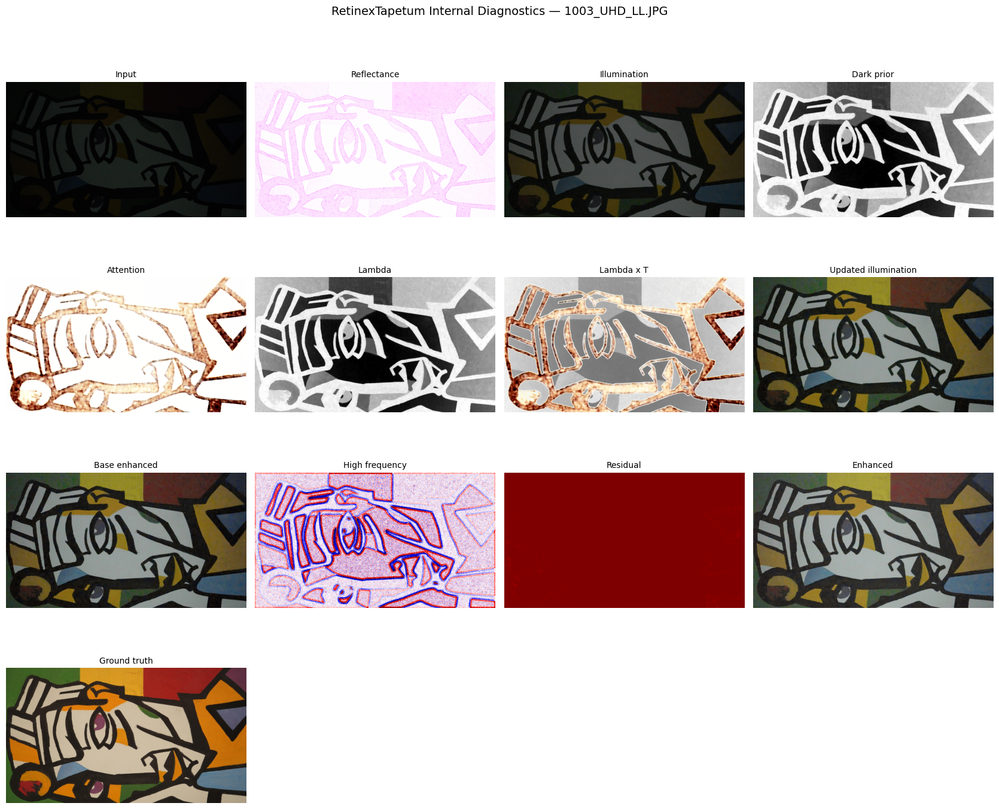

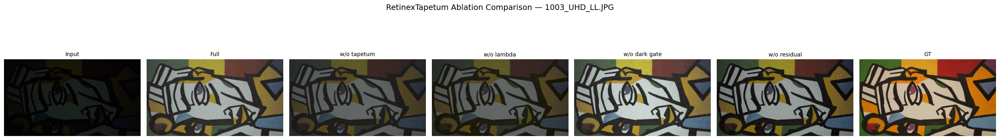

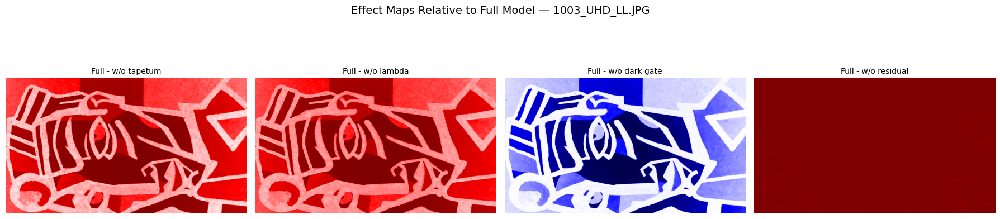


===== ABLATION SUMMARY =====
full                                | PSNR 24.7719 | SSIM 0.9159 | LPIPS 0.0886
retinex_base_only                   | PSNR 11.0784 | SSIM 0.6238 | LPIPS 0.2168
without_residual_refinement         | PSNR 20.6773 | SSIM 0.8606 | LPIPS 0.1043
without_tapetum_update              | PSNR 12.6126 | SSIM 0.7627 | LPIPS 0.1917
without_attention_modulation        | PSNR 23.5724 | SSIM 0.9132 | LPIPS 0.0927
without_spatial_amplification       | PSNR 11.3714 | SSIM 0.6667 | LPIPS 0.2428
without_high_frequency_cue          | PSNR 24.8082 | SSIM 0.9162 | LPIPS 0.0885
without_darkness_gate               | PSNR 20.0668 | SSIM 0.9027 | LPIPS 0.1115

===== INTERNAL DIAGNOSTICS SUMMARY =====
Sigmoid tapetum response T(x)                                | Mean 0.8288 | Median 0.9999
Darkness-regulated response Td(x)=D(x)*T(x)                  | Mean 0.6327 | Median 0.7022
Td(x) in dark regions                                        | Mean 0.6432 | Median 0.7026
Td(x) in bright

,dataset,dataset_variant,ablation_variant,matched,psnr,ssim,lpips,lpips_resize
0,UHD-LL down4,NaN,full,150,24.771894,0.915862,0.088649,0.042062
1,UHD-LL down4,NaN,retinex_base_only,150,11.078395,0.623841,0.216850,0.158526
2,UHD-LL down4,NaN,without_residual_refinement,150,20.677313,0.860638,0.104255,0.055638
3,UHD-LL down4,NaN,without_tapetum_update,150,12.612558,0.762654,0.191680,0.134152
4,UHD-LL down4,NaN,without_attention_modulation,150,23.572371,0.913219,0.092748,0.045363
5,UHD-LL down4,NaN,without_spatial_amplification,150,11.371415,0.666662,0.242837,0.183355
6,UHD-LL down4,NaN,without_high_frequency_cue,150,24.808233,0.916249,0.088532,0.042225
7,UHD-LL down4,NaN,without_darkness_gate,150,20.066803,0.902718,0.111539,0.060712



===== DIAGNOSTICS TABLE =====


,quantity,mean,median
0,Sigmoid tapetum response T(x),0.828801,0.999880
1,Darkness-regulated response Td(x)=D(x)*T(x),0.632718,0.702216
2,Td(x) in dark regions,0.643191,0.702568
3,Td(x) in bright regions,0.094961,0.094775
4,Lambda(x) in dark regions,1.054979,1.030674
5,Lambda(x) in bright regions,0.208248,0.215074
6,Effective boost Lambda(x)*T(x) in dark regions,0.868308,0.948467
7,Effective boost Lambda(x)*T(x) in bright regions,0.128197,0.127946
8,"Corr.(Td(x), darkness)",0.436228,0.556174
9,"Corr.(Lambda(x)*T(x), darkness)",0.436228,0.556175



===== GAIN TABLE =====


,dataset,dataset_variant,matched,dark_threshold,bright_threshold,gain_mean,gain_median,gain_dark_mean,gain_bright_mean,dark_pixels_total,bright_pixels_total
0,UHD-LL down4,NaN,150,0.5,0.2,1.854169,1.947992,1.868308,1.128197,73509932,216582



RETINEXTAPETUM ANALYSIS COMPLETED
Dataset               : UHD-LL down4
Dataset variant       : None
Run root              : /content/drive/MyDrive/TAPETUM/RESULT/UHD-LL down4/RetinexTapetum
Analysis root         : /content/drive/MyDrive/TAPETUM/RESULT/UHD-LL down4/RetinexTapetum/analysis

Ablation:
Summary CSV           : /content/drive/MyDrive/TAPETUM/RESULT/UHD-LL down4/RetinexTapetum/analysis/ablation/RetinexTapetum_ablation_summary.csv
Detail CSV            : /content/drive/MyDrive/TAPETUM/RESULT/UHD-LL down4/RetinexTapetum/analysis/ablation/RetinexTapetum_ablation_detail.csv
LaTeX                 : /content/drive/MyDrive/TAPETUM/RESULT/UHD-LL down4/RetinexTapetum/analysis/ablation/RetinexTapetum_ablation_latex.txt

Diagnostics:
Summary CSV           : /content/drive/MyDrive/TAPETUM/RESULT/UHD-LL down4/RetinexTapetum/analysis/diagnostics/RetinexTapetum_internal_diagnostics_summary.csv
Detail CSV            : /content/drive/MyDrive/TAPETUM/RESULT/UHD-LL down4/RetinexTapetum/analysi

In [3]:
# ============================================================
# @title RetinexTapetum — Ablation + Diagnostics Runner
# Runs:
# RetinexTapetum_Ablation_Diagnostics_Dataset_Aware.py
# ============================================================

from __future__ import annotations

from google.colab import drive
drive.mount("/content/drive", force_remount=False)

import ast
import importlib
import json
import os
import re
import shutil
import subprocess
import sys
import time
import traceback
from pathlib import Path


# ============================================================
# 0. DATASET / PROFILE SELECTION
# ============================================================

#@markdown ### Target dataset
DATASET_SELECTION = "UHD-LL down4"  #@param ["LOL-v1", "LOL-v2 / Real_captured", "LOL-v2 / Synthetic", "UHD-LL down4", "UHD-LL 4K", "LSRW / Huawei", "LSRW / Nikon", "LoLI-Street", "SICE", "DarkVision / Static", "DarkVision / Dynamic", "LENVIZ", "SID / Sony", "SID / Fuji", "LLVIP", "DICM", "LIME", "MEF", "NPE", "VV", "ExDark / Full", "ExDark / Train", "ExDark / Validation", "ExDark / Test", "DARK FACE / Labeled", "DARK FACE / Unlabeled", "DARK FACE / Holdout Test"]

#@markdown ### RetinexTapetum checkpoint profile
PROFILE_SELECTION = "UHD-LL down4"  #@param ["LOL-v1", "LOL-v2 / Real_captured", "LOL-v2 / Synthetic", "UHD-LL down4", "UHD-LL 4K", "LSRW / Huawei", "LSRW / Nikon", "LoLI-Street"]

# Diagnostics sample filename.
# Leave empty to use SAMPLE_INDEX.
SAMPLE_FILENAME = ""  #@param {type:"string"}
SAMPLE_INDEX = 0  #@param {type:"integer"}

FIGURE_DPI = 220  #@param {type:"integer"}
DARK_THRESHOLD = 0.50  #@param {type:"number"}
BRIGHT_THRESHOLD = 0.20  #@param {type:"number"}

INSTALL_DEPENDENCIES = True  #@param {type:"boolean"}
REQUIRE_STANDARD_TEST_LOW = True  #@param {type:"boolean"}
STRICT_CHECKPOINT_PROFILE = True  #@param {type:"boolean"}
CLEAR_PYTHON_CACHE = True  #@param {type:"boolean"}


# ============================================================
# 1. DATASET CATALOG
# ============================================================

DATASET_CATALOG = {
    "LOL-v1": {
        "data_name": "LOL-v1",
        "variant": None,
        "mode": "paired",
        "reference_available": True,
    },
    "LOL-v2 / Real_captured": {
        "data_name": "LOL-v2",
        "variant": "Real_captured",
        "mode": "paired",
        "reference_available": True,
    },
    "LOL-v2 / Synthetic": {
        "data_name": "LOL-v2",
        "variant": "Synthetic",
        "mode": "paired",
        "reference_available": True,
    },
    "UHD-LL down4": {
        "data_name": "UHD-LL down4",
        "variant": None,
        "mode": "paired",
        "reference_available": True,
    },
    "UHD-LL 4K": {
        "data_name": "UHD-LL 4K",
        "variant": None,
        "mode": "paired",
        "reference_available": True,
    },
    "LSRW / Huawei": {
        "data_name": "LSRW",
        "variant": "Huawei",
        "mode": "paired",
        "reference_available": True,
    },
    "LSRW / Nikon": {
        "data_name": "LSRW",
        "variant": "Nikon",
        "mode": "paired",
        "reference_available": True,
    },
    "LoLI-Street": {
        "data_name": "LoLI-Street",
        "variant": None,
        "mode": "paired",
        "reference_available": True,
    },
    "SICE": {
        "data_name": "SICE",
        "variant": None,
        "mode": "complex",
        "reference_available": False,
        "manual_standardization_required": True,
    },
    "DarkVision / Static": {
        "data_name": "DarkVision",
        "variant": "Static",
        "mode": "complex",
        "reference_available": False,
        "manual_standardization_required": True,
    },
    "DarkVision / Dynamic": {
        "data_name": "DarkVision",
        "variant": "Dynamic",
        "mode": "complex",
        "reference_available": False,
        "manual_standardization_required": True,
    },
    "LENVIZ": {
        "data_name": "LENVIZ",
        "variant": None,
        "mode": "complex",
        "reference_available": False,
        "manual_standardization_required": True,
    },
    "SID / Sony": {
        "data_name": "SID",
        "variant": "Sony",
        "mode": "raw",
        "reference_available": False,
        "manual_standardization_required": True,
    },
    "SID / Fuji": {
        "data_name": "SID",
        "variant": "Fuji",
        "mode": "raw",
        "reference_available": False,
        "manual_standardization_required": True,
    },
    "LLVIP": {
        "data_name": "LLVIP",
        "variant": None,
        "mode": "multimodal",
        "reference_available": False,
        "manual_standardization_required": True,
    },
    "DICM": {
        "data_name": "DICM",
        "variant": None,
        "mode": "unpaired_test",
        "reference_available": False,
    },
    "LIME": {
        "data_name": "LIME",
        "variant": None,
        "mode": "unpaired_test",
        "reference_available": False,
    },
    "MEF": {
        "data_name": "MEF",
        "variant": None,
        "mode": "unpaired_test",
        "reference_available": False,
    },
    "NPE": {
        "data_name": "NPE",
        "variant": None,
        "mode": "unpaired_test",
        "reference_available": False,
    },
    "VV": {
        "data_name": "VV",
        "variant": None,
        "mode": "unpaired_test",
        "reference_available": False,
    },
    "ExDark / Full": {
        "data_name": "ExDark",
        "variant": "Full",
        "mode": "unpaired_test",
        "reference_available": False,
    },
    "ExDark / Train": {
        "data_name": "ExDark",
        "variant": "Train",
        "mode": "unpaired_test",
        "reference_available": False,
    },
    "ExDark / Validation": {
        "data_name": "ExDark",
        "variant": "Validation",
        "mode": "unpaired_test",
        "reference_available": False,
    },
    "ExDark / Test": {
        "data_name": "ExDark",
        "variant": "Test",
        "mode": "unpaired_test",
        "reference_available": False,
    },
    "DARK FACE / Labeled": {
        "data_name": "DARK FACE",
        "variant": "Labeled",
        "mode": "unpaired_test",
        "reference_available": False,
    },
    "DARK FACE / Unlabeled": {
        "data_name": "DARK FACE",
        "variant": "Unlabeled",
        "mode": "unpaired_test",
        "reference_available": False,
    },
    "DARK FACE / Holdout Test": {
        "data_name": "DARK FACE",
        "variant": "Holdout_Test",
        "mode": "unpaired_test",
        "reference_available": False,
    },
}

PROFILE_CATALOG = {
    key: value
    for key, value in DATASET_CATALOG.items()
    if key in {
        "LOL-v1",
        "LOL-v2 / Real_captured",
        "LOL-v2 / Synthetic",
        "UHD-LL down4",
        "UHD-LL 4K",
        "LSRW / Huawei",
        "LSRW / Nikon",
        "LoLI-Street",
    }
}

if DATASET_SELECTION not in DATASET_CATALOG:
    raise ValueError(f"Unsupported dataset: {DATASET_SELECTION}")

if PROFILE_SELECTION not in PROFILE_CATALOG:
    raise ValueError(f"Unsupported profile: {PROFILE_SELECTION}")

TARGET = DATASET_CATALOG[DATASET_SELECTION]
PROFILE = PROFILE_CATALOG[PROFILE_SELECTION]

DATA_NAME = TARGET["data_name"]
DATA_VARIANT = TARGET.get("variant")
DATASET_MODE = TARGET["mode"]
REFERENCE_AVAILABLE = bool(TARGET.get("reference_available", False))

PROFILE_DATA_NAME = PROFILE["data_name"]
PROFILE_DATA_VARIANT = PROFILE.get("variant")


# ============================================================
# 2. PATHS
# ============================================================

PROJECT_DIR = Path(
    "/content/drive/MyDrive/TAPETUM/RetinexTapetum"
).resolve()

SCRIPT_PATH = (
    PROJECT_DIR
    / "RetinexTapetum_Ablation_Diagnostics_Dataset_Aware.py"
)

DATASETS_BASE_DIR = Path(
    "/content/drive/MyDrive/TAPETUM/datasets"
).resolve()

RESULT_ROOT = Path(
    "/content/drive/MyDrive/TAPETUM/RESULT"
).resolve()

RESULTS_ROOT = Path(
    "/content/drive/MyDrive/TAPETUM/RESULTS"
).resolve()


def build_output_tag(data_name, variant):
    """Create a stable folder tag for cross-dataset results."""
    if variant is None:
        return str(data_name)
    return f"{data_name}_{variant}"


TARGET_OUTPUT_TAG = build_output_tag(DATA_NAME, DATA_VARIANT)
PROFILE_OUTPUT_TAG = build_output_tag(
    PROFILE_DATA_NAME,
    PROFILE_DATA_VARIANT,
)

SAME_DATASET_CHECKPOINT = (
    DATA_NAME == PROFILE_DATA_NAME
    and DATA_VARIANT == PROFILE_DATA_VARIANT
)

EXPECTED_DATASET_DIR = DATASETS_BASE_DIR / DATA_NAME
if DATA_VARIANT is not None:
    EXPECTED_DATASET_DIR = EXPECTED_DATASET_DIR / DATA_VARIANT

TARGET_TEST_LOW_DIR = EXPECTED_DATASET_DIR / "Test" / "Low"
TARGET_TEST_NORMAL_DIR = EXPECTED_DATASET_DIR / "Test" / "Normal"

# Output routing rule:
#   same checkpoint dataset + test dataset -> RESULT/<dataset>/...
#   different checkpoint dataset          -> RESULTS/<profile(check)>/.../<target>
if SAME_DATASET_CHECKPOINT:
    OUTPUT_ROUTING_MODE = "same_dataset_to_RESULT"

    MODEL_RESULT_ROOT = RESULT_ROOT / DATA_NAME
    if DATA_VARIANT is not None:
        MODEL_RESULT_ROOT = MODEL_RESULT_ROOT / DATA_VARIANT
    MODEL_RESULT_ROOT = MODEL_RESULT_ROOT / "RetinexTapetum"
else:
    OUTPUT_ROUTING_MODE = "cross_dataset_checkpoint_to_RESULTS"

    CHECKPOINT_OUTPUT_TAG = f"{PROFILE_OUTPUT_TAG}(check)"
    MODEL_RESULT_ROOT = (
        RESULTS_ROOT
        / CHECKPOINT_OUTPUT_TAG
        / "RetinexTapetum"
        / TARGET_OUTPUT_TAG
    )

ANALYSIS_ROOT = MODEL_RESULT_ROOT / "analysis"
ABLATION_ROOT = ANALYSIS_ROOT / "ablation_diagnostics"

# The RESULT tree stores final outputs/metrics, but the actual trained
# RetinexTapetum checkpoint may remain under HyperparameterSearch.
# Resolve it from the profile run summary first, then use safe fallbacks.
PROFILE_RESULT_ROOT = RESULT_ROOT / PROFILE_DATA_NAME
if PROFILE_DATA_VARIANT is not None:
    PROFILE_RESULT_ROOT = PROFILE_RESULT_ROOT / PROFILE_DATA_VARIANT
PROFILE_RESULT_ROOT = PROFILE_RESULT_ROOT / "RetinexTapetum"

HPO_ROOT = Path(
    "/content/drive/MyDrive/TAPETUM/HyperparameterSearch"
).resolve()

PROFILE_HPO_KEY = {
    "LOL-v1": "lol_v1",
    "LOL-v2 / Real_captured": "lol_v2_real_captured",
    "LOL-v2 / Synthetic": "lol_v2_synthetic",
    "UHD-LL down4": "uhd_ll_down4",
    "UHD-LL 4K": "uhd_ll_4k",
    "LSRW / Huawei": "lsrw_huawei",
    "LSRW / Nikon": "lsrw_nikon",
    "LoLI-Street": "loli_street",
}.get(PROFILE_SELECTION)

PROFILE_RUN_SUMMARY = PROFILE_RESULT_ROOT / "colab_run_summary.json"


def _load_profile_summary_payload(summary_path: Path):
    """Load the exact profile run metadata used to select the checkpoint."""
    if not summary_path.is_file():
        return {}

    try:
        payload = json.loads(summary_path.read_text(encoding="utf-8"))
    except Exception as exc:
        raise RuntimeError(
            f"Selected profile summary could not be read: {summary_path}\n{exc}"
        ) from exc

    if not isinstance(payload, dict):
        raise RuntimeError(
            f"Selected profile summary is not a JSON object: {summary_path}"
        )

    return payload


PROFILE_RUN_PAYLOAD = _load_profile_summary_payload(PROFILE_RUN_SUMMARY)
PROFILE_CONFIG_OVERRIDES = PROFILE_RUN_PAYLOAD.get(
    "hpo_applied_config_overrides",
    {},
)
if not isinstance(PROFILE_CONFIG_OVERRIDES, dict):
    PROFILE_CONFIG_OVERRIDES = {}


def _load_summary_checkpoint(summary_path: Path):
    """Return the exact checkpoint recorded by a completed profile run."""
    if not summary_path.is_file():
        return None

    try:
        payload = json.loads(summary_path.read_text(encoding="utf-8"))
    except Exception as exc:
        print(
            f"WARNING: could not read checkpoint summary {summary_path}: {exc}",
            flush=True,
        )
        return None

    # New runner writes best_checkpoint. Keep aliases for older summaries.
    for key in (
        "best_checkpoint",
        "checkpoint_path",
        "selected_checkpoint",
        "ckpt_path",
    ):
        raw = payload.get(key)
        if raw:
            candidate = Path(str(raw)).expanduser()
            if candidate.is_file():
                return candidate.resolve()

    # Some summaries only retain the containing checkpoint directory.
    raw_dir = payload.get("checkpoint_directory")
    if raw_dir:
        checkpoint_dir = Path(str(raw_dir)).expanduser()
        for filename in ("best.pth", "best.pt", "last.pth"):
            candidate = checkpoint_dir / filename
            if candidate.is_file():
                return candidate.resolve()

    return None


# IMPORTANT: Do not auto-discover the newest/arbitrary HPO checkpoint here.
# The runner must reference the checkpoint that was explicitly selected by
# the profile run and recorded in colab_run_summary.json.
ANALYSIS_ROOT.mkdir(parents=True, exist_ok=True)
ABLATION_ROOT.mkdir(parents=True, exist_ok=True)


# ============================================================
# 3. VALIDATION
# ============================================================

if not PROJECT_DIR.is_dir():
    raise FileNotFoundError(
        "RetinexTapetum project directory was not found:\n"
        f"{PROJECT_DIR}"
    )

if not SCRIPT_PATH.is_file():
    raise FileNotFoundError(
        "Ablation/diagnostics script was not found:\n"
        f"{SCRIPT_PATH}"
    )

if not EXPECTED_DATASET_DIR.is_dir():
    raise FileNotFoundError(
        "Selected dataset directory was not found:\n"
        f"{EXPECTED_DATASET_DIR}"
    )

if REQUIRE_STANDARD_TEST_LOW and not TARGET_TEST_LOW_DIR.is_dir():
    raise FileNotFoundError(
        "Standard Test/Low directory was not found:\n"
        f"{TARGET_TEST_LOW_DIR}\n\n"
        "Prepare the dataset with TAPETUM Dataset Manager."
    )

if TARGET.get("manual_standardization_required", False):
    if not TARGET_TEST_LOW_DIR.is_dir():
        raise RuntimeError(
            f"{DATASET_SELECTION} requires an explicit Test/Low subset "
            "before diagnostics can run."
        )

if REFERENCE_AVAILABLE and not TARGET_TEST_NORMAL_DIR.is_dir():
    raise FileNotFoundError(
        "Paired dataset requires Test/Normal:\n"
        f"{TARGET_TEST_NORMAL_DIR}"
    )

required_project_files = [
    "config.py",
    "model.py",
    "dataset.py",
    "losses.py",
    "utils.py",
]

missing_files = [
    filename
    for filename in required_project_files
    if not (PROJECT_DIR / filename).is_file()
]

if missing_files:
    raise FileNotFoundError(
        "Missing project files:\n"
        + "\n".join(missing_files)
    )

PROFILE_CHECKPOINT_SOURCE = None
PROFILE_CHECKPOINT = _load_summary_checkpoint(PROFILE_RUN_SUMMARY)

if PROFILE_CHECKPOINT is not None:
    PROFILE_CHECKPOINT_SOURCE = (
        "selected checkpoint reference (colab_run_summary.json)"
    )

if STRICT_CHECKPOINT_PROFILE and PROFILE_CHECKPOINT is None:
    raise FileNotFoundError(
        "The exact selected checkpoint reference could not be resolved.\n"
        "This runner intentionally does not choose an arbitrary best.pth.\n"
        "Expected profile summary:\n"
        f"{PROFILE_RUN_SUMMARY}\n\n"
        "Run the profile test/selection first so colab_run_summary.json "
        "contains the selected best_checkpoint path."
    )


# The child diagnostics script still validates CKPT_DIR. Point it to the
# directory that actually contains the exact selected checkpoint instead of
# expecting a copied RESULT/.../checkpoints directory.
PROFILE_CHECKPOINT_DIR = (
    PROFILE_CHECKPOINT.parent.resolve()
    if PROFILE_CHECKPOINT is not None
    else None
)

if PROFILE_CHECKPOINT_DIR is not None and not PROFILE_CHECKPOINT_DIR.is_dir():
    raise FileNotFoundError(
        "Selected checkpoint directory does not exist:\n"
        f"{PROFILE_CHECKPOINT_DIR}"
    )


# ============================================================
# 4. ENVIRONMENT VARIABLES
# ============================================================

environment_values = {
    "RETINEX_DATA_NAME": DATA_NAME,
    "RETINEX_DATA_VARIANT": (
        DATA_VARIANT if DATA_VARIANT is not None else "None"
    ),
    "RETINEX_PROFILE_DATA_NAME": PROFILE_DATA_NAME,
    "RETINEX_PROFILE_DATA_VARIANT": (
        PROFILE_DATA_VARIANT
        if PROFILE_DATA_VARIANT is not None
        else "None"
    ),
    "RETINEX_DATASET_MODE": DATASET_MODE,
    "RETINEX_REFERENCE_AVAILABLE": (
        "1" if REFERENCE_AVAILABLE else "0"
    ),
    "RETINEX_RESULT_ROOT": str(RESULT_ROOT),
    "RETINEX_RESULTS_ROOT": str(RESULTS_ROOT),
    "RETINEX_MODEL_RESULT_ROOT": str(MODEL_RESULT_ROOT),
    "RETINEX_ANALYSIS_DIR": str(ANALYSIS_ROOT),
    "RETINEX_ABLATION_DIR": str(ABLATION_ROOT),
    "RETINEX_SAME_DATASET_CHECKPOINT": (
        "1" if SAME_DATASET_CHECKPOINT else "0"
    ),
    "RETINEX_OUTPUT_ROUTING_MODE": OUTPUT_ROUTING_MODE,
    "RETINEX_TARGET_OUTPUT_TAG": TARGET_OUTPUT_TAG,
    "RETINEX_PROFILE_OUTPUT_TAG": PROFILE_OUTPUT_TAG,
    "RETINEX_PROFILE_CHECKPOINT": (
        str(PROFILE_CHECKPOINT)
        if PROFILE_CHECKPOINT is not None
        else ""
    ),
    "RETINEX_PROFILE_CHECKPOINT_DIR": (
        str(PROFILE_CHECKPOINT_DIR)
        if PROFILE_CHECKPOINT_DIR is not None
        else ""
    ),
    "PYTHONUNBUFFERED": "1",
}

for key, value in environment_values.items():
    os.environ[key] = str(value)

os.chdir(PROJECT_DIR)

project_path_string = str(PROJECT_DIR)

if project_path_string in sys.path:
    sys.path.remove(project_path_string)

sys.path.insert(0, project_path_string)


# ============================================================
# 5. CACHE / DEPENDENCIES
# ============================================================

if CLEAR_PYTHON_CACHE:
    for cache_dir in PROJECT_DIR.rglob("__pycache__"):
        if cache_dir.is_dir():
            shutil.rmtree(
                cache_dir,
                ignore_errors=True,
            )

    for module_name in (
        "config",
        "model",
        "dataset",
        "losses",
        "utils",
    ):
        sys.modules.pop(module_name, None)

    importlib.invalidate_caches()

if INSTALL_DEPENDENCIES:
    print("\n===== INSTALL DEPENDENCIES =====", flush=True)

    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "lpips",
            "tqdm",
            "pillow",
            "torchvision",
            "numpy",
            "pandas",
            "matplotlib",
        ]
    )


# ============================================================
# 6. PRINT SETTINGS
# ============================================================

print("\n" + "=" * 94, flush=True)
print("RETINEXTAPETUM ABLATION + DIAGNOSTICS RUNNER v6", flush=True)
print("=" * 94, flush=True)

settings = {
    "DATASET_SELECTION": DATASET_SELECTION,
    "DATA_NAME": DATA_NAME,
    "DATA_VARIANT": DATA_VARIANT,
    "DATASET_MODE": DATASET_MODE,
    "REFERENCE_AVAILABLE": REFERENCE_AVAILABLE,
    "PROFILE_SELECTION": PROFILE_SELECTION,
    "PROFILE_DATA_NAME": PROFILE_DATA_NAME,
    "PROFILE_DATA_VARIANT": PROFILE_DATA_VARIANT,
    "PROFILE_CHECKPOINT": PROFILE_CHECKPOINT,
    "PROFILE_CHECKPOINT_DIR": PROFILE_CHECKPOINT_DIR,
    "PROFILE_CHECKPOINT_SOURCE": PROFILE_CHECKPOINT_SOURCE,
    "CHECKPOINT_POLICY": "exact_selected_reference_only",
    "SELECTED_BASE_CHANNELS": PROFILE_CONFIG_OVERRIDES.get("BASE_CHANNELS"),
    "SELECTED_LAMBDA_MAX": PROFILE_CONFIG_OVERRIDES.get("LAMBDA_MAX"),
    "PROFILE_RUN_SUMMARY": PROFILE_RUN_SUMMARY,
    "SAME_DATASET_CHECKPOINT": SAME_DATASET_CHECKPOINT,
    "OUTPUT_ROUTING_MODE": OUTPUT_ROUTING_MODE,
    "TARGET_OUTPUT_TAG": TARGET_OUTPUT_TAG,
    "PROFILE_OUTPUT_TAG": PROFILE_OUTPUT_TAG,
    "PROJECT_DIR": PROJECT_DIR,
    "SCRIPT_PATH": SCRIPT_PATH,
    "DATASET_DIR": EXPECTED_DATASET_DIR,
    "TEST_LOW_DIR": TARGET_TEST_LOW_DIR,
    "TEST_NORMAL_DIR": (
        TARGET_TEST_NORMAL_DIR
        if REFERENCE_AVAILABLE
        else "N/A"
    ),
    "MODEL_RESULT_ROOT": MODEL_RESULT_ROOT,
    "ANALYSIS_ROOT": ANALYSIS_ROOT,
    "ABLATION_ROOT": ABLATION_ROOT,
    "SAMPLE_FILENAME": SAMPLE_FILENAME or None,
    "SAMPLE_INDEX": SAMPLE_INDEX,
    "FIGURE_DPI": FIGURE_DPI,
    "DARK_THRESHOLD": DARK_THRESHOLD,
    "BRIGHT_THRESHOLD": BRIGHT_THRESHOLD,
}

for key, value in settings.items():
    print(f"{key:<24}: {value}", flush=True)

print("=" * 94, flush=True)


# ============================================================
# 7. LOAD SCRIPT
# ============================================================

script_source = SCRIPT_PATH.read_text(
    encoding="utf-8"
)

# Avoid a second Drive mount inside the script.
script_source = re.sub(
    r"from google\.colab import drive\s*"
    r"drive\.mount\([^\n]+\)",
    "# Drive is already mounted by the runner.",
    script_source,
    count=1,
)


# ============================================================
# 8. PATCH SCRIPT SETTINGS
# ============================================================

def replace_assignment(
    source,
    variable_name,
    replacement_value=None,
    required=True,
    raw_expression=None,
):
    """
    Replace the first top-level assignment to variable_name.

    AST line spans are used instead of a single-line regex so multiline
    assignments such as `X = Path(\n ... \n)` are replaced safely.
    """
    try:
        tree = ast.parse(source)
    except SyntaxError as exc:
        raise RuntimeError(
            "The diagnostics script cannot be parsed before patching."
        ) from exc

    matched_node = None

    for node in tree.body:
        is_match = False

        if isinstance(node, ast.Assign):
            for target in node.targets:
                if (
                    isinstance(target, ast.Name)
                    and target.id == variable_name
                ):
                    is_match = True
                    break

        elif isinstance(node, ast.AnnAssign):
            target = node.target
            is_match = (
                isinstance(target, ast.Name)
                and target.id == variable_name
            )

        if is_match:
            matched_node = node
            break

    if matched_node is None:
        if required:
            raise RuntimeError(
                f"{variable_name} was not found as a top-level "
                "assignment in the diagnostics script."
            )
        return source

    if raw_expression is None:
        replacement_expression = repr(replacement_value)
    else:
        replacement_expression = str(raw_expression)

    source_lines = source.splitlines(keepends=True)
    start_line = matched_node.lineno - 1
    end_line = matched_node.end_lineno

    newline = "\n"
    if source_lines[start_line].endswith("\r\n"):
        newline = "\r\n"

    source_lines[start_line:end_line] = [
        f"{variable_name} = {replacement_expression}{newline}"
    ]

    return "".join(source_lines)


script_source = replace_assignment(
    script_source,
    "DATA_NAME",
    DATA_NAME,
)

script_source = replace_assignment(
    script_source,
    "DATA_VARIANT",
    DATA_VARIANT,
)

script_source = replace_assignment(
    script_source,
    "SAMPLE_FILENAME",
    (
        None
        if not SAMPLE_FILENAME.strip()
        else SAMPLE_FILENAME.strip()
    ),
)

script_source = replace_assignment(
    script_source,
    "SAMPLE_INDEX",
    int(SAMPLE_INDEX),
)

script_source = replace_assignment(
    script_source,
    "FIGURE_DPI",
    int(FIGURE_DPI),
)

script_source = replace_assignment(
    script_source,
    "DARK_THRESHOLD",
    float(DARK_THRESHOLD),
)

script_source = replace_assignment(
    script_source,
    "BRIGHT_THRESHOLD",
    float(BRIGHT_THRESHOLD),
)

# Optional variables are patched when the underlying script supports them.
optional_assignments = {
    "PROFILE_DATA_NAME": PROFILE_DATA_NAME,
    "PROFILE_DATA_VARIANT": PROFILE_DATA_VARIANT,
    "REFERENCE_AVAILABLE": REFERENCE_AVAILABLE,
    "SAME_DATASET_CHECKPOINT": SAME_DATASET_CHECKPOINT,
    "OUTPUT_ROUTING_MODE": OUTPUT_ROUTING_MODE,
}

for variable_name, value in optional_assignments.items():
    script_source = replace_assignment(
        script_source,
        variable_name,
        value,
        required=False,
    )

# Preserve pathlib.Path semantics for path-valued settings in the child script.
path_assignments = {
    "RUN_ROOT": MODEL_RESULT_ROOT,
    "ANALYSIS_ROOT": ANALYSIS_ROOT,
    "ABLATION_ROOT": ABLATION_ROOT,
    "MODEL_RESULT_ROOT": MODEL_RESULT_ROOT,
    # Compatibility with the child script's legacy required_dirs check.
    # This is NOT a copied RESULT checkpoint folder; it is the real parent
    # directory of the exact selected checkpoint.
    "CKPT_DIR": PROFILE_CHECKPOINT_DIR,
    "CKPT_PATH": PROFILE_CHECKPOINT,
}

for variable_name, path_value in path_assignments.items():
    if path_value is None:
        raw_expression = "None"
    else:
        raw_expression = f"Path({str(path_value)!r})"

    script_source = replace_assignment(
        script_source,
        variable_name,
        required=False,
        raw_expression=raw_expression,
    )

# Keep inference/diagnostics consistent with the selected checkpoint profile.
# These values affect model construction/forward behavior and must not silently
# fall back to a stale project config (e.g. LAMBDA_MAX=1.35 for a checkpoint
# selected with LAMBDA_MAX=1.8).
selected_runtime_overrides = {
    key: PROFILE_CONFIG_OVERRIDES[key]
    for key in ("BASE_CHANNELS", "LAMBDA_MAX")
    if key in PROFILE_CONFIG_OVERRIDES
}

for variable_name, value in selected_runtime_overrides.items():
    script_source = replace_assignment(
        script_source,
        variable_name,
        value,
        required=False,
    )


# ============================================================
# 9. EXECUTE IN CURRENT COLAB KERNEL
# ============================================================

print("\n===== ANALYSIS START =====", flush=True)

start_time = time.time()

execution_globals = {
    "__name__": "__main__",
    "__file__": str(SCRIPT_PATH),
    "__package__": None,
    "Path": Path,
}

try:
    compiled_script = compile(
        script_source,
        str(SCRIPT_PATH),
        "exec",
    )

    exec(
        compiled_script,
        execution_globals,
    )

except Exception:
    print("\n===== ANALYSIS FAILED =====", flush=True)

    error_path = (
        ABLATION_ROOT
        / "ablation_diagnostics_error.txt"
    )

    error_text = (
        f"Dataset: {DATASET_SELECTION}\n"
        f"Profile: {PROFILE_SELECTION}\n"
        f"Time: {time.strftime('%Y-%m-%d %H:%M:%S')}\n\n"
        f"{traceback.format_exc()}"
    )

    error_path.write_text(
        error_text,
        encoding="utf-8",
    )

    print(error_text, flush=True)
    print("Error report:", error_path, flush=True)

    raise

elapsed_seconds = time.time() - start_time

stale_error_path = (
    ABLATION_ROOT
    / "ablation_diagnostics_error.txt"
)
stale_error_path.unlink(missing_ok=True)


# ============================================================
# 10. RESOLVE FINAL CONFIG / OUTPUT DIRECTORY
# ============================================================

sys.modules.pop("config", None)
importlib.invalidate_caches()

import config
config = importlib.reload(config)

config_run_root = Path(
    getattr(
        config,
        "RUN_ROOT",
        MODEL_RESULT_ROOT,
    )
)

config_analysis_root = Path(
    getattr(
        config,
        "ANALYSIS_ROOT",
        ANALYSIS_ROOT,
    )
)

# The standardized analysis directory remains authoritative.
FINAL_ANALYSIS_ROOT = ANALYSIS_ROOT


# ============================================================
# 11. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 94, flush=True)
print("ANALYSIS FINISHED", flush=True)
print("=" * 94, flush=True)

print("Elapsed seconds :", round(elapsed_seconds, 2), flush=True)
print("Config RUN_ROOT :", config_run_root, flush=True)
print("Config analysis :", config_analysis_root, flush=True)
print("Standard output :", FINAL_ANALYSIS_ROOT, flush=True)


# ============================================================
# 12. LIST GENERATED FILES
# ============================================================

print("\n===== GENERATED FILES =====", flush=True)

generated_files = sorted(
    [
        path
        for path in FINAL_ANALYSIS_ROOT.rglob("*")
        if path.is_file()
    ],
    key=lambda path: str(path).casefold(),
)

if generated_files:
    for generated_file in generated_files:
        print(generated_file, flush=True)
else:
    print(
        "The analysis directory exists, but no files were generated:",
        FINAL_ANALYSIS_ROOT,
        flush=True,
    )

print("\n===== DONE =====", flush=True)



---





---

# COMPARISON

RETINEXTAPETUM MULTI-DATASET VISUAL COMPARISON

LOL-v1
  Selected image : 1.png
  Result folder  : /content/drive/MyDrive/TAPETUM/RESULT/LOL-v1/RetinexTapetum/results/Test
  Result image   : /content/drive/MyDrive/TAPETUM/RESULT/LOL-v1/RetinexTapetum/results/Test/1.png
  Low-light image: /content/drive/MyDrive/TAPETUM/datasets/LOL-v1/Test/Low/1.png
  Reference image: /content/drive/MyDrive/TAPETUM/datasets/LOL-v1/Test/Normal/1.png
  Zoom region    : (195, 130, 210, 140)

LOL-v2 / Real_captured
  Selected image : 00690.png
  Result folder  : /content/drive/MyDrive/TAPETUM/RESULT/LOL-v2/Real_captured/RetinexTapetum/results
  Result image   : /content/drive/MyDrive/TAPETUM/RESULT/LOL-v2/Real_captured/RetinexTapetum/results/00690.png
  Low-light image: /content/drive/MyDrive/TAPETUM/datasets/LOL-v2/Real_captured/Test/Low/00690.png
  Reference image: /content/drive/MyDrive/TAPETUM/datasets/LOL-v2/Real_captured/Test/Normal/00690.png
  Zoom region    : (288, 192, 312, 208)

LOL-v2 / Synthetic

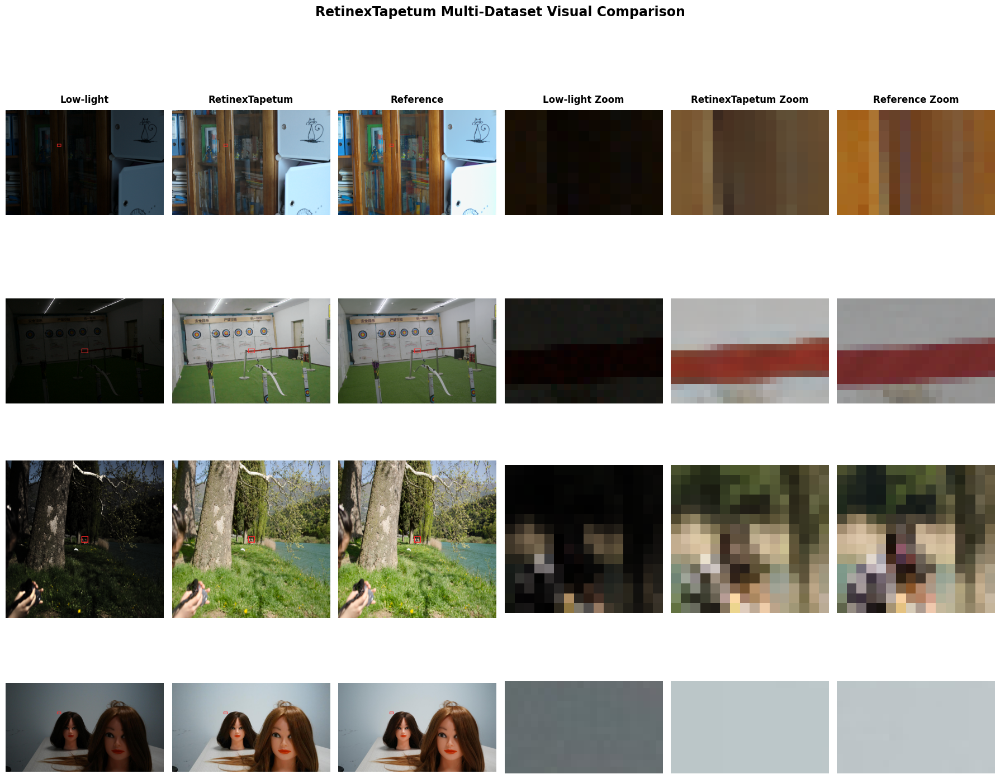


COMPARISON COMPLETED
Rows included : 4
Output file   : /content/drive/MyDrive/TAPETUM/paper_retinextapetum/comparison_results/multi_dataset/retinextapetum_multi_dataset_comparison.png


In [2]:
# ============================================================
# @title RETINEXTAPETUM MULTI-DATASET VISUAL COMPARISON
# Updated Google Colab Version
# ============================================================

from pathlib import Path
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import re


# ------------------------------------------------------------
# 1. MOUNT GOOGLE DRIVE
# ------------------------------------------------------------

try:
    from google.colab import drive

    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
except ImportError:
    print("Google Colab environment was not detected.")


# ------------------------------------------------------------
# 2. PROJECT PATHS
# ------------------------------------------------------------

DRIVE_ROOT = Path("/content/drive/MyDrive/TAPETUM")
RESULT_ROOT = DRIVE_ROOT / "RESULT"
DATASET_ROOT = DRIVE_ROOT / "datasets"

OUTPUT_DIR = (
    DRIVE_ROOT
    / "paper_retinextapetum"
    / "comparison_results"
    / "multi_dataset"
)

OUTPUT_FILE = (
    OUTPUT_DIR
    / "retinextapetum_multi_dataset_comparison.png"
)

IMAGE_EXTENSIONS = {
    ".png",
    ".jpg",
    ".jpeg",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp",
}


# ------------------------------------------------------------
# 3. DATASET CONFIGURATIONS
# ------------------------------------------------------------
#
# result_model_dir:
#     Directory containing the RetinexTapetum output folders.
#
# low_dir:
#     Directory containing the low-light input images.
#
# reference_dir:
#     Directory containing the corresponding reference images.
#
# preferred_image:
#     Image used in the comparison when it exists in all three
#     directories. If it is unavailable, the first common image
#     is selected automatically.
#
# zoom:
#     Pixel coordinates in the format:
#     (left, top, right, bottom)
#
#     If the value is None, a central zoom region is generated
#     automatically.
# ------------------------------------------------------------

DATASET_CONFIGS = [
    {
        "label": "LOL-v1",

        "result_model_dir": (
            RESULT_ROOT
            / "LOL-v1"
            / "RetinexTapetum"
        ),

        "low_dir": (
            DATASET_ROOT
            / "LOL-v1"
            / "Test"
            / "Low"
        ),

        "reference_dir": (
            DATASET_ROOT
            / "LOL-v1"
            / "Test"
            / "Normal"
        ),

        "preferred_image": "1.png",
        "zoom": (195, 130, 210, 140),
    },

    {
        "label": "LOL-v2 / Real_captured",

        "result_model_dir": (
            RESULT_ROOT
            / "LOL-v2"
            / "Real_captured"
            / "RetinexTapetum"
        ),

        "low_dir": (
            DATASET_ROOT
            / "LOL-v2"
            / "Real_captured"
            / "Test"
            / "Low"
        ),

        "reference_dir": (
            DATASET_ROOT
            / "LOL-v2"
            / "Real_captured"
            / "Test"
            / "Normal"
        ),

        # This file was verified in all three directories.
        "preferred_image": "00690.png",

        # A central zoom region will be selected automatically.
        "zoom": None,
    },

    {
        "label": "LOL-v2 / Synthetic",

        "result_model_dir": (
            RESULT_ROOT
            / "LOL-v2"
            / "Synthetic"
            / "RetinexTapetum"
        ),

        "low_dir": (
            DATASET_ROOT
            / "LOL-v2"
            / "Synthetic"
            / "Test"
            / "Low"
        ),

        "reference_dir": (
            DATASET_ROOT
            / "LOL-v2"
            / "Synthetic"
            / "Test"
            / "Normal"
        ),

        # This file was verified in all three directories.
        "preferred_image": "r00816405t.png",

        # A central zoom region will be selected automatically.
        "zoom": None,
    },

    {
        "label": "UHD-LL down4",

        "result_model_dir": (
            RESULT_ROOT
            / "UHD-LL down4"
            / "RetinexTapetum"
        ),

        "low_dir": (
            DATASET_ROOT
            / "UHD-LL down4"
            / "Test"
            / "Low"
        ),

        "reference_dir": (
            DATASET_ROOT
            / "UHD-LL down4"
            / "Test"
            / "Normal"
        ),

        "preferred_image": "1_UHD_LL.JPG",
        "zoom": (312, 175, 336, 189),
    },
]


# ------------------------------------------------------------
# 4. FILE AND PATH UTILITIES
# ------------------------------------------------------------

def natural_sort_key(value):
    """
    Convert a filename into a natural sorting key.

    Example:
        2.png is placed before 10.png.
    """

    return [
        int(part) if part.isdigit() else part.lower()
        for part in re.split(r"(\d+)", value)
    ]


def image_file_map(folder):
    """
    Return all supported image files in a directory.

    The dictionary keys are lowercase filenames, allowing
    case-insensitive filename matching.
    """

    if not folder.is_dir():
        raise FileNotFoundError(
            f"Image directory not found: {folder}"
        )

    files = {
        path.name.lower(): path
        for path in folder.iterdir()
        if path.is_file()
        and path.suffix.lower() in IMAGE_EXTENSIONS
    }

    if not files:
        raise FileNotFoundError(
            f"No supported image files found in: {folder}"
        )

    return files


def folder_contains_images(folder):
    """
    Check whether a directory exists and contains at least
    one supported image file.
    """

    if not folder.is_dir():
        return False

    return any(
        path.is_file()
        and path.suffix.lower() in IMAGE_EXTENSIONS
        for path in folder.iterdir()
    )


def resolve_result_folder(model_folder):
    """
    Resolve the directory containing the enhanced images.

    Different experiments currently use two output structures:

        LOL-v1 and UHD-LL:
            RetinexTapetum/results/Test

        LOL-v2 Real-captured and Synthetic:
            RetinexTapetum/results

    The function checks both structures and returns the first
    directory that contains image files.
    """

    results_root = model_folder / "results"

    candidates = [
        results_root / "Test",
        results_root,
    ]

    for candidate in candidates:
        if folder_contains_images(candidate):
            return candidate

    checked_paths = "\n".join(
        f"  - {candidate}"
        for candidate in candidates
    )

    raise FileNotFoundError(
        "A result directory containing images was not found.\n"
        f"Checked paths:\n{checked_paths}"
    )


def select_common_image(
    result_dir,
    low_dir,
    reference_dir,
    preferred_image=None,
):
    """
    Select an image available in the result, low-light and
    reference directories.

    The preferred image is used when possible. Otherwise, the
    first common filename is selected using natural sorting.
    """

    result_files = image_file_map(result_dir)
    low_files = image_file_map(low_dir)
    reference_files = image_file_map(reference_dir)

    common_names = (
        set(result_files)
        & set(low_files)
        & set(reference_files)
    )

    if not common_names:
        raise FileNotFoundError(
            "The result, low-light and reference directories "
            "do not contain a common image filename."
        )

    preferred_key = (
        preferred_image.lower()
        if preferred_image
        else None
    )

    if preferred_key and preferred_key in common_names:
        selected_name = preferred_key
    else:
        selected_name = sorted(
            common_names,
            key=natural_sort_key,
        )[0]

    return {
        "name": result_files[selected_name].name,
        "result": result_files[selected_name],
        "low": low_files[selected_name],
        "reference": reference_files[selected_name],
    }


def open_rgb(path):
    """
    Open an image and return an independent RGB copy.
    """

    with Image.open(path) as image:
        return image.convert("RGB")


# ------------------------------------------------------------
# 5. ZOOM UTILITIES
# ------------------------------------------------------------

def automatic_zoom_box(image):
    """
    Generate a small zoom region at the center of an image.
    """

    width, height = image.size

    zoom_width = max(
        16,
        round(width * 0.04),
    )

    zoom_height = max(
        12,
        round(height * 0.04),
    )

    center_x = width // 2
    center_y = height // 2

    left = center_x - zoom_width // 2
    top = center_y - zoom_height // 2
    right = left + zoom_width
    bottom = top + zoom_height

    return left, top, right, bottom


def clamp_zoom_box(box, image):
    """
    Restrict zoom coordinates to the image boundaries.
    """

    width, height = image.size
    left, top, right, bottom = box

    left = max(
        0,
        min(int(left), width - 2),
    )

    top = max(
        0,
        min(int(top), height - 2),
    )

    right = max(
        left + 1,
        min(int(right), width),
    )

    bottom = max(
        top + 1,
        min(int(bottom), height),
    )

    return left, top, right, bottom


def add_zoom_rectangle(image, zoom_box):
    """
    Draw a red rectangle around the selected zoom region.
    """

    output = image.copy()
    draw = ImageDraw.Draw(output)

    line_width = max(
        2,
        round(min(image.size) * 0.006),
    )

    draw.rectangle(
        zoom_box,
        outline=(255, 40, 40),
        width=line_width,
    )

    return output


def crop_zoom(image, zoom_box):
    """
    Crop the selected zoom region from an image.
    """

    valid_box = clamp_zoom_box(
        zoom_box,
        image,
    )

    return image.crop(valid_box)


# ------------------------------------------------------------
# 6. DISCOVER AND LOAD THE COMPARISON IMAGES
# ------------------------------------------------------------

print("=" * 100)
print("RETINEXTAPETUM MULTI-DATASET VISUAL COMPARISON")
print("=" * 100)
print()

comparison_rows = []
skipped_rows = []

for config in DATASET_CONFIGS:
    label = config["label"]

    try:
        # Automatically resolve either results/Test or results.
        result_dir = resolve_result_folder(
            config["result_model_dir"]
        )

        # Select one filename shared by all three directories.
        selected = select_common_image(
            result_dir=result_dir,
            low_dir=config["low_dir"],
            reference_dir=config["reference_dir"],
            preferred_image=config.get("preferred_image"),
        )

        low_image = open_rgb(
            selected["low"]
        )

        result_image = open_rgb(
            selected["result"]
        )

        reference_image = open_rgb(
            selected["reference"]
        )

        zoom_box = config.get("zoom")

        if zoom_box is None:
            zoom_box = automatic_zoom_box(
                low_image
            )

        zoom_box = clamp_zoom_box(
            zoom_box,
            low_image,
        )

        comparison_rows.append(
            {
                "label": label,
                "name": selected["name"],
                "low_path": selected["low"],
                "result_path": selected["result"],
                "reference_path": selected["reference"],
                "low": low_image,
                "result": result_image,
                "reference": reference_image,
                "zoom": zoom_box,
            }
        )

        print(label)
        print(f"  Selected image : {selected['name']}")
        print(f"  Result folder  : {result_dir}")
        print(f"  Result image   : {selected['result']}")
        print(f"  Low-light image: {selected['low']}")
        print(f"  Reference image: {selected['reference']}")
        print(f"  Zoom region    : {zoom_box}")
        print()

    except Exception as error:
        error_message = (
            f"{type(error).__name__}: {error}"
        )

        skipped_rows.append(
            (label, error_message)
        )

        print(
            f"SKIPPED: {label}: {error_message}"
        )
        print()


# ------------------------------------------------------------
# 7. CREATE THE MULTI-DATASET FIGURE
# ------------------------------------------------------------

if not comparison_rows:
    raise RuntimeError(
        "No dataset row could be created. "
        "Check the Google Drive mount and directory paths."
    )

row_count = len(comparison_rows)
column_count = 6

column_titles = [
    "Low-light",
    "RetinexTapetum",
    "Reference",
    "Low-light Zoom",
    "RetinexTapetum Zoom",
    "Reference Zoom",
]

fig, axes = plt.subplots(
    row_count,
    column_count,
    figsize=(18, 3.8 * row_count),
    squeeze=False,
)

for row_index, row in enumerate(comparison_rows):
    zoom_box = row["zoom"]

    low_box = clamp_zoom_box(
        zoom_box,
        row["low"],
    )

    result_box = clamp_zoom_box(
        zoom_box,
        row["result"],
    )

    reference_box = clamp_zoom_box(
        zoom_box,
        row["reference"],
    )

    displayed_images = [
        add_zoom_rectangle(
            row["low"],
            low_box,
        ),

        add_zoom_rectangle(
            row["result"],
            result_box,
        ),

        add_zoom_rectangle(
            row["reference"],
            reference_box,
        ),

        crop_zoom(
            row["low"],
            low_box,
        ),

        crop_zoom(
            row["result"],
            result_box,
        ),

        crop_zoom(
            row["reference"],
            reference_box,
        ),
    ]

    for column_index, image in enumerate(displayed_images):
        axis = axes[row_index][column_index]

        axis.imshow(image)
        axis.axis("off")

        if row_index == 0:
            axis.set_title(
                column_titles[column_index],
                fontsize=12,
                fontweight="bold",
                pad=10,
            )

    axes[row_index][0].set_ylabel(
        row["label"],
        fontsize=12,
        fontweight="bold",
        rotation=90,
        labelpad=16,
    )

fig.suptitle(
    "RetinexTapetum Multi-Dataset Visual Comparison",
    fontsize=17,
    fontweight="bold",
    y=0.995,
)

plt.tight_layout(
    rect=(0, 0, 1, 0.98)
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

fig.savefig(
    OUTPUT_FILE,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()
plt.close(fig)


# ------------------------------------------------------------
# 8. PRINT THE FINAL SUMMARY
# ------------------------------------------------------------

print()
print("=" * 100)
print("COMPARISON COMPLETED")
print("=" * 100)
print(f"Rows included : {len(comparison_rows)}")
print(f"Output file   : {OUTPUT_FILE}")

if skipped_rows:
    print()
    print("Skipped datasets:")

    for label, error_message in skipped_rows:
        print(
            f"  - {label}: {error_message}"
        )

print("=" * 100)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Ground Truth: /content/drive/MyDrive/TAPETUM/datasets/UHD-LL down4/Test/Normal/1_UHD_LL.JPG
TAPETUM VISUAL MODEL COMPARISON
DATASET_SELECTION: UHD-LL down4
DATA_NAME        : UHD-LL down4
DATA_VARIANT     : None
DATASET_ROOT     : /content/drive/MyDrive/TAPETUM/datasets/UHD-LL down4
LOW_FOLDER       : /content/drive/MyDrive/TAPETUM/datasets/UHD-LL down4/Test/Low
NORMAL_FOLDER    : /content/drive/MyDrive/TAPETUM/datasets/UHD-LL down4/Test/Normal
RESULT_ROOT      : /content/drive/MyDrive/TAPETUM/RESULT/UHD-LL down4
OUTPUT_ROOT      : /content/drive/MyDrive/TAPETUM/paper_retinextapetum/comparison_results/all_models

Selected image: 1_UHD_LL.JPG

Model outputs:
----------------------------------------------------------------------------------------------------
RetinexNet                  : /content/drive/MyDrive/TAPETUM/RESULT/UHD-LL down4/RetinexNet/results/1_UH

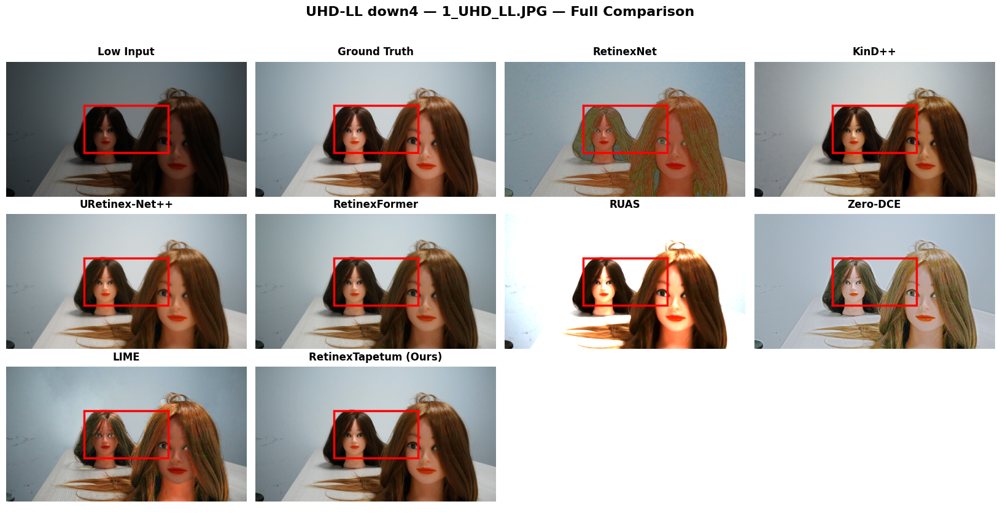

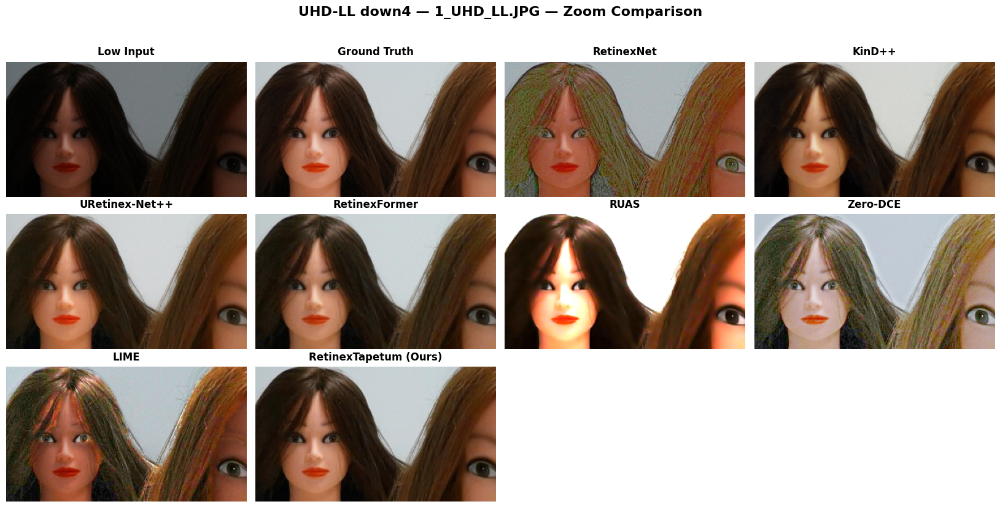


COMPARISON COMPLETED
Dataset          : UHD-LL down4
Selected image   : 1_UHD_LL.JPG
Full comparison  : /content/drive/MyDrive/TAPETUM/paper_retinextapetum/comparison_results/all_models/UHD-LL down4/default/1_UHD_LL/1_UHD_LL_full_comparison.png
Zoom comparison  : /content/drive/MyDrive/TAPETUM/paper_retinextapetum/comparison_results/all_models/UHD-LL down4/default/1_UHD_LL/1_UHD_LL_zoom_comparison.png
Images compared  : 10

All model outputs were found.


In [5]:
# ============================================================
# @title TAPETUM — VISUAL MODEL COMPARISON
# Full-image and zoomed-region comparison across all datasets
# ============================================================

from google.colab import drive
drive.mount("/content/drive", force_remount=False)

import os
import re
import math
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image, ImageOps


# ============================================================
# 1. USER SETTINGS
# ============================================================

DATASET_SELECTION = "UHD-LL down4"  #@param ["LOL-v1", "LOL-v2 / Real_captured", "LOL-v2 / Synthetic", "UHD-LL down4", "UHD-LL 4K", "LSRW / Huawei", "LSRW / Nikon", "LoLI-Street", "SICE", "DarkVision / Static", "DarkVision / Dynamic", "LENVIZ", "SID / Sony", "SID / Fuji", "LLVIP", "DICM", "LIME", "MEF", "NPE", "VV", "ExDark / Full", "ExDark / Train", "ExDark / Validation", "ExDark / Test", "DARK FACE / Labeled", "DARK FACE / Unlabeled", "DARK FACE / Holdout Test"]

# Enter an image filename with or without extension.
# Leave empty to use the first test image in natural order.
IMAGE_NAME = ""  #@param {type:"string"}

# Zoom coordinates. If all are -1, central 35% is selected.
ZOOM_X = -1  #@param {type:"integer"}
ZOOM_Y = -1  #@param {type:"integer"}
ZOOM_WIDTH = -1  #@param {type:"integer"}
ZOOM_HEIGHT = -1  #@param {type:"integer"}

GRID_COLUMNS = 4  #@param {type:"integer"}
OUTPUT_DPI = 220  #@param {type:"integer"}
DRAW_ZOOM_RECTANGLE = True  #@param {type:"boolean"}
FAIL_IF_MODEL_OUTPUT_MISSING = False  #@param {type:"boolean"}


# ============================================================
# 2. MAIN PATHS
# ============================================================

TAPETUM_ROOT = Path("/content/drive/MyDrive/TAPETUM")
DATASETS_ROOT = TAPETUM_ROOT / "datasets"
RESULT_ROOT = TAPETUM_ROOT / "RESULT"

OUTPUT_ROOT = (
    TAPETUM_ROOT
    / "paper_retinextapetum"
    / "comparison_results"
    / "all_models"
)

IMAGE_EXTENSIONS = {
    ".png",
    ".jpg",
    ".jpeg",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp",
    ".ppm",
    ".pgm",
}


# ============================================================
# 3. DATASET CATALOG
# ============================================================

DATASET_CATALOG = {
    "LOL-v1": {
        "data_name": "LOL-v1",
        "variant": None,
        "reference_available": True,
    },
    "LOL-v2 / Real_captured": {
        "data_name": "LOL-v2",
        "variant": "Real_captured",
        "reference_available": True,
    },
    "LOL-v2 / Synthetic": {
        "data_name": "LOL-v2",
        "variant": "Synthetic",
        "reference_available": True,
    },
    "UHD-LL down4": {
        "data_name": "UHD-LL down4",
        "variant": None,
        "reference_available": True,
    },
    "UHD-LL 4K": {
        "data_name": "UHD-LL 4K",
        "variant": None,
        "reference_available": True,
    },
    "LSRW / Huawei": {
        "data_name": "LSRW",
        "variant": "Huawei",
        "reference_available": True,
    },
    "LSRW / Nikon": {
        "data_name": "LSRW",
        "variant": "Nikon",
        "reference_available": True,
    },
    "LoLI-Street": {
        "data_name": "LoLI-Street",
        "variant": None,
        "reference_available": True,
    },
    "SICE": {
        "data_name": "SICE",
        "variant": None,
        "reference_available": False,
    },
    "DarkVision / Static": {
        "data_name": "DarkVision",
        "variant": "Static",
        "reference_available": False,
    },
    "DarkVision / Dynamic": {
        "data_name": "DarkVision",
        "variant": "Dynamic",
        "reference_available": False,
    },
    "LENVIZ": {
        "data_name": "LENVIZ",
        "variant": None,
        "reference_available": False,
    },
    "SID / Sony": {
        "data_name": "SID",
        "variant": "Sony",
        "reference_available": False,
    },
    "SID / Fuji": {
        "data_name": "SID",
        "variant": "Fuji",
        "reference_available": False,
    },
    "LLVIP": {
        "data_name": "LLVIP",
        "variant": None,
        "reference_available": False,
    },
    "DICM": {
        "data_name": "DICM",
        "variant": None,
        "reference_available": False,
    },
    "LIME": {
        "data_name": "LIME",
        "variant": None,
        "reference_available": False,
    },
    "MEF": {
        "data_name": "MEF",
        "variant": None,
        "reference_available": False,
    },
    "NPE": {
        "data_name": "NPE",
        "variant": None,
        "reference_available": False,
    },
    "VV": {
        "data_name": "VV",
        "variant": None,
        "reference_available": False,
    },
    "ExDark / Full": {
        "data_name": "ExDark",
        "variant": "Full",
        "reference_available": False,
    },
    "ExDark / Train": {
        "data_name": "ExDark",
        "variant": "Train",
        "reference_available": False,
    },
    "ExDark / Validation": {
        "data_name": "ExDark",
        "variant": "Validation",
        "reference_available": False,
    },
    "ExDark / Test": {
        "data_name": "ExDark",
        "variant": "Test",
        "reference_available": False,
    },
    "DARK FACE / Labeled": {
        "data_name": "DARK FACE",
        "variant": "Labeled",
        "reference_available": False,
    },
    "DARK FACE / Unlabeled": {
        "data_name": "DARK FACE",
        "variant": "Unlabeled",
        "reference_available": False,
    },
    "DARK FACE / Holdout Test": {
        "data_name": "DARK FACE",
        "variant": "Holdout_Test",
        "reference_available": False,
    },
}


# ============================================================
# 4. MODEL DEFINITIONS
# ============================================================

MODEL_CONFIG = [
    {
        "key": "RetinexNet",
        "folder": "RetinexNet",
        "label": "RetinexNet",
        "patterns": ["{stem}_S", "{stem}"],
    },
    {
        "key": "KinD++",
        "folder": "KinD++",
        "legacy_folders": ["KinD_plus"],
        "label": "KinD++",
        "patterns": ["{stem}_kindle_v2", "{stem}"],
    },
    {
        "key": "URetinex-Net++",
        "folder": "URetinex-Net++",
        "legacy_folders": ["URetinex-Net-PLUS"],
        "label": "URetinex-Net++",
        "patterns": ["{stem}__URetinex-Net++", "{stem}"],
    },
    {
        "key": "RetinexFormer",
        "folder": "RetinexFormer",
        "label": "RetinexFormer",
        "patterns": ["{stem}"],
    },
    {
        "key": "RUAS",
        "folder": "RUAS",
        "label": "RUAS",
        "patterns": ["{stem}"],
    },
    {
        "key": "Zero-DCE",
        "folder": "Zero-DCE",
        "label": "Zero-DCE",
        "patterns": ["{stem}"],
    },
    {
        "key": "LIME",
        "folder": "LIME",
        "label": "LIME",
        "patterns": ["{stem}"],
    },
    {
        "key": "RetinexTapetum",
        "folder": "RetinexTapetum",
        "label": "RetinexTapetum (Ours)",
        "patterns": ["{stem}", "{stem}_enhanced"],
    },
]


# ============================================================
# 5. RESOLVE DATASET
# ============================================================

if DATASET_SELECTION not in DATASET_CATALOG:
    raise ValueError(
        f"Unsupported dataset selection: {DATASET_SELECTION}"
    )

dataset_config = DATASET_CATALOG[DATASET_SELECTION]

DATA_NAME = dataset_config["data_name"]
DATA_VARIANT = dataset_config.get("variant")
REFERENCE_AVAILABLE = dataset_config["reference_available"]

DATASET_ROOT = DATASETS_ROOT / DATA_NAME
if DATA_VARIANT is not None:
    DATASET_ROOT = DATASET_ROOT / DATA_VARIANT

LOW_FOLDER = DATASET_ROOT / "Test" / "Low"
NORMAL_FOLDER = DATASET_ROOT / "Test" / "Normal"

DATASET_RESULT_ROOT = RESULT_ROOT / DATA_NAME
if DATA_VARIANT is not None:
    DATASET_RESULT_ROOT = DATASET_RESULT_ROOT / DATA_VARIANT


# ============================================================
# 6. GENERAL HELPERS
# ============================================================

def natural_key(value):
    return [
        int(part) if part.isdigit() else part.lower()
        for part in re.split(r"(\d+)", str(value))
    ]


def normalize_text(value):
    return re.sub(
        r"[^a-z0-9]+",
        "",
        str(value).lower(),
    )


def is_image(path):
    return (
        path.is_file()
        and path.suffix.lower() in IMAGE_EXTENSIONS
    )


def list_images(folder):
    folder = Path(folder)

    if not folder.exists():
        return []

    return sorted(
        [
            path
            for path in folder.iterdir()
            if is_image(path)
        ],
        key=lambda path: natural_key(path.name),
    )


def load_rgb(path):
    with Image.open(path) as image:
        image = ImageOps.exif_transpose(image)
        return image.convert("RGB").copy()


def resize_to_reference(image, reference_size):
    if image.size == reference_size:
        return image

    return image.resize(
        reference_size,
        Image.Resampling.LANCZOS,
    )


# ============================================================
# 7. INPUT / REFERENCE SELECTION
# ============================================================

def select_input_image(low_folder, requested_name):
    files = list_images(low_folder)

    if not files:
        raise FileNotFoundError(
            f"No input image found in: {low_folder}"
        )

    requested_name = requested_name.strip()

    if not requested_name:
        return files[0]

    requested_stem = Path(requested_name).stem
    normalized_requested = normalize_text(requested_stem)

    for path in files:
        if path.name.casefold() == requested_name.casefold():
            return path

        if path.stem.casefold() == requested_stem.casefold():
            return path

    for path in files:
        if normalize_text(path.stem) == normalized_requested:
            return path

    examples = ", ".join(path.name for path in files[:15])

    raise FileNotFoundError(
        f"Image '{requested_name}' was not found.\n"
        f"Available examples: {examples}"
    )


def find_matching_image(folder, source_path):
    folder = Path(folder)

    if not folder.exists():
        return None

    source_name = source_path.name.casefold()
    source_stem = source_path.stem.casefold()
    source_normalized = normalize_text(source_path.stem)

    files = list_images(folder)

    for path in files:
        if path.name.casefold() == source_name:
            return path

    for path in files:
        if path.stem.casefold() == source_stem:
            return path

    for path in files:
        if normalize_text(path.stem) == source_normalized:
            return path

    return None


# ============================================================
# 8. MODEL RESULT PATHS
# ============================================================

SKIP_DIRECTORIES = {
    "checkpoints",
    "checkpoint",
    "checkpoint_backups",
    "logs",
    "metrics",
    "training",
    "runtime_code",
    "paper_metrics",
    "analysis",
    "options",
    "__pycache__",
}


def candidate_model_roots(model):
    roots = [
        DATASET_RESULT_ROOT / model["folder"],
    ]

    for legacy_folder in model.get("legacy_folders", []):
        roots.append(DATASET_RESULT_ROOT / legacy_folder)

    # Legacy pre-RESULT structure fallback.
    legacy_dataset_root = TAPETUM_ROOT / DATA_NAME

    if DATA_VARIANT is not None:
        roots.extend([
            legacy_dataset_root / f"{model['folder']}-{DATA_VARIANT}",
            legacy_dataset_root / f"{model['folder']}_{DATA_VARIANT}",
        ])

        for legacy_folder in model.get("legacy_folders", []):
            roots.extend([
                legacy_dataset_root / f"{legacy_folder}-{DATA_VARIANT}",
                legacy_dataset_root / f"{legacy_folder}_{DATA_VARIANT}",
            ])
    else:
        roots.append(legacy_dataset_root / model["folder"])

        for legacy_folder in model.get("legacy_folders", []):
            roots.append(legacy_dataset_root / legacy_folder)

    unique = []
    seen = set()

    for root in roots:
        root = Path(root)

        if str(root) not in seen:
            unique.append(root)
            seen.add(str(root))

    return unique


def collect_model_images(model_roots):
    images = []

    for model_root in model_roots:
        if not model_root.exists():
            continue

        preferred_result_folder = (
            model_root
            / "results"
            / "Test"
        )

        if preferred_result_folder.exists():
            images.extend(list_images(preferred_result_folder))

        for current_root, dirs, files in os.walk(model_root):
            dirs[:] = [
                directory
                for directory in dirs
                if directory.lower() not in SKIP_DIRECTORIES
            ]

            current_path = Path(current_root)

            for file_name in files:
                path = current_path / file_name

                if is_image(path):
                    images.append(path)

    unique = {}
    for path in images:
        unique[str(path)] = path

    return list(unique.values())


def result_path_score(path):
    path_text = str(path).replace("\\", "/").lower()

    score = 0

    if "/results/test/" in f"{path_text}/":
        score += 600
    elif "/result/test/" in f"{path_text}/":
        score += 550
    elif "/eval_results/" in f"{path_text}/":
        score += 450
    elif "/results/" in f"{path_text}/":
        score += 350
    elif "/samples/" in f"{path_text}/":
        score += 150

    if path.suffix.lower() == ".png":
        score += 30

    return score


def find_model_output(model, input_path):
    candidates = collect_model_images(
        candidate_model_roots(model)
    )

    if not candidates:
        return None

    input_stem = input_path.stem
    normalized_input = normalize_text(input_stem)

    for pattern in model["patterns"]:
        expected_stem = pattern.format(stem=input_stem)
        normalized_expected = normalize_text(expected_stem)

        exact_matches = [
            path
            for path in candidates
            if (
                path.stem.casefold() == expected_stem.casefold()
                or normalize_text(path.stem) == normalized_expected
            )
        ]

        if exact_matches:
            exact_matches.sort(
                key=lambda path: (
                    -result_path_score(path),
                    natural_key(str(path)),
                )
            )
            return exact_matches[0]

    scored = []

    for path in candidates:
        stem = path.stem
        lower_stem = stem.casefold()
        normalized_stem = normalize_text(stem)

        score = -10000

        if lower_stem == input_stem.casefold():
            score = 1000
        elif normalized_stem == normalized_input:
            score = 950
        elif lower_stem.startswith(input_stem.casefold()):
            score = 800
        elif normalized_stem.startswith(normalized_input):
            score = 750
        elif normalized_input in normalized_stem:
            score = 550

        if score < 0:
            continue

        score += result_path_score(path)

        if model["key"] == "RetinexNet" and lower_stem.endswith("_s"):
            score += 100

        if model["key"] == "KinD++" and "kindle" in lower_stem:
            score += 100

        if model["key"] == "URetinex-Net++" and "uret" in lower_stem:
            score += 100

        if model["key"] == "RetinexTapetum" and "enhanced" in lower_stem:
            score += 70

        unwanted_tokens = [
            "_low",
            "_gt",
            "ground_truth",
            "illumination",
            "reflectance",
            "attention",
            "darkness",
            "lambda",
            "input",
        ]

        if any(token in lower_stem for token in unwanted_tokens):
            score -= 500

        scored.append((score, path))

    if not scored:
        return None

    scored.sort(
        key=lambda item: (
            -item[0],
            natural_key(str(item[1])),
        )
    )

    return scored[0][1]


# ============================================================
# 9. ZOOM
# ============================================================

def calculate_zoom_box(width, height):
    manual_values = [
        ZOOM_X,
        ZOOM_Y,
        ZOOM_WIDTH,
        ZOOM_HEIGHT,
    ]

    if all(value >= 0 for value in manual_values):
        x = ZOOM_X
        y = ZOOM_Y
        crop_width = max(1, ZOOM_WIDTH)
        crop_height = max(1, ZOOM_HEIGHT)
    else:
        crop_width = max(64, round(width * 0.35))
        crop_height = max(64, round(height * 0.35))

        crop_width = min(crop_width, width)
        crop_height = min(crop_height, height)

        x = (width - crop_width) // 2
        y = (height - crop_height) // 2

    x = max(0, min(x, width - 1))
    y = max(0, min(y, height - 1))
    crop_width = max(1, min(crop_width, width - x))
    crop_height = max(1, min(crop_height, height - y))

    return x, y, crop_width, crop_height


def crop_zoom(image, zoom_box):
    x, y, width, height = zoom_box

    return image.crop(
        (
            x,
            y,
            x + width,
            y + height,
        )
    )


# ============================================================
# 10. GRID
# ============================================================

def create_grid(
    items,
    output_path,
    title,
    columns,
    zoom_box=None,
    crop_images=False,
):
    columns = max(1, min(columns, len(items)))
    rows = math.ceil(len(items) / columns)

    reference_width, reference_height = items[0][1].size
    aspect_ratio = reference_height / reference_width

    if crop_images and zoom_box is not None:
        _, _, crop_width, crop_height = zoom_box
        aspect_ratio = crop_height / crop_width

    subplot_width = 4.1
    subplot_height = max(2.8, subplot_width * aspect_ratio)

    fig, axes = plt.subplots(
        rows,
        columns,
        figsize=(
            columns * subplot_width,
            rows * subplot_height,
        ),
        squeeze=False,
    )

    for index, (label, image, source_path) in enumerate(items):
        row = index // columns
        column = index % columns
        axis = axes[row][column]

        shown_image = (
            crop_zoom(image, zoom_box)
            if crop_images and zoom_box is not None
            else image
        )

        axis.imshow(shown_image)
        axis.set_title(
            label,
            fontsize=12,
            fontweight="bold",
            pad=8,
        )
        axis.axis("off")

        if (
            not crop_images
            and zoom_box is not None
            and DRAW_ZOOM_RECTANGLE
        ):
            x, y, width, height = zoom_box

            axis.add_patch(
                Rectangle(
                    (x, y),
                    width,
                    height,
                    linewidth=2.5,
                    edgecolor="red",
                    facecolor="none",
                )
            )

    for index in range(len(items), rows * columns):
        row = index // columns
        column = index % columns
        axes[row][column].axis("off")

    fig.suptitle(
        title,
        fontsize=16,
        fontweight="bold",
        y=0.995,
    )

    plt.tight_layout(rect=[0, 0, 1, 0.97])

    output_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    fig.savefig(
        output_path,
        dpi=OUTPUT_DPI,
        bbox_inches="tight",
        facecolor="white",
    )

    plt.show()
    plt.close(fig)


# ============================================================
# 11. LOAD INPUT
# ============================================================

if not LOW_FOLDER.is_dir():
    raise FileNotFoundError(
        f"Test/Low folder not found:\n{LOW_FOLDER}"
    )

input_path = select_input_image(
    LOW_FOLDER,
    IMAGE_NAME,
)

input_image = load_rgb(input_path)
reference_size = input_image.size

comparison_items = [
    (
        "Low Input",
        input_image,
        input_path,
    )
]

if REFERENCE_AVAILABLE:
    gt_path = find_matching_image(
        NORMAL_FOLDER,
        input_path,
    )

    if gt_path is not None:
        gt_image = resize_to_reference(
            load_rgb(gt_path),
            reference_size,
        )

        comparison_items.append(
            (
                "Ground Truth",
                gt_image,
                gt_path,
            )
        )

        print("Ground Truth:", gt_path)
    else:
        print("Ground Truth: NOT FOUND")
else:
    print("Ground Truth: not applicable for this dataset")


# ============================================================
# 12. LOAD MODEL OUTPUTS
# ============================================================

print("=" * 100)
print("TAPETUM VISUAL MODEL COMPARISON")
print("=" * 100)
print("DATASET_SELECTION:", DATASET_SELECTION)
print("DATA_NAME        :", DATA_NAME)
print("DATA_VARIANT     :", DATA_VARIANT)
print("DATASET_ROOT     :", DATASET_ROOT)
print("LOW_FOLDER       :", LOW_FOLDER)
print("NORMAL_FOLDER    :", NORMAL_FOLDER)
print("RESULT_ROOT      :", DATASET_RESULT_ROOT)
print("OUTPUT_ROOT      :", OUTPUT_ROOT)
print("=" * 100)

print("\nSelected image:", input_path.name)
print("\nModel outputs:")
print("-" * 100)

missing_models = []

for model in MODEL_CONFIG:
    output_path = find_model_output(
        model,
        input_path,
    )

    if output_path is None:
        missing_models.append(model["label"])

        print(
            f"{model['label']:<28}: NOT FOUND"
        )

        if FAIL_IF_MODEL_OUTPUT_MISSING:
            raise FileNotFoundError(
                f"Output missing for model: {model['label']}"
            )

        continue

    model_image = resize_to_reference(
        load_rgb(output_path),
        reference_size,
    )

    comparison_items.append(
        (
            model["label"],
            model_image,
            output_path,
        )
    )

    print(
        f"{model['label']:<28}: {output_path}"
    )


# ============================================================
# 13. ZOOM AND OUTPUT PATHS
# ============================================================

zoom_box = calculate_zoom_box(
    reference_size[0],
    reference_size[1],
)

variant_folder = (
    DATA_VARIANT
    if DATA_VARIANT is not None
    else "default"
)

save_folder = (
    OUTPUT_ROOT
    / DATA_NAME
    / variant_folder
    / input_path.stem
)

full_output = (
    save_folder
    / f"{input_path.stem}_full_comparison.png"
)

zoom_output = (
    save_folder
    / f"{input_path.stem}_zoom_comparison.png"
)


# ============================================================
# 14. CREATE OUTPUTS
# ============================================================

create_grid(
    items=comparison_items,
    output_path=full_output,
    title=(
        f"{DATASET_SELECTION} — "
        f"{input_path.name} — Full Comparison"
    ),
    columns=GRID_COLUMNS,
    zoom_box=zoom_box,
    crop_images=False,
)

create_grid(
    items=comparison_items,
    output_path=zoom_output,
    title=(
        f"{DATASET_SELECTION} — "
        f"{input_path.name} — Zoom Comparison"
    ),
    columns=GRID_COLUMNS,
    zoom_box=zoom_box,
    crop_images=True,
)


# ============================================================
# 15. SUMMARY
# ============================================================

print("\n" + "=" * 100)
print("COMPARISON COMPLETED")
print("=" * 100)
print("Dataset          :", DATASET_SELECTION)
print("Selected image   :", input_path.name)
print("Full comparison  :", full_output)
print("Zoom comparison  :", zoom_output)
print("Images compared  :", len(comparison_items))

if missing_models:
    print("\nModels with missing outputs:")

    for model_name in missing_models:
        print("  -", model_name)
else:
    print("\nAll model outputs were found.")

print("=" * 100)

In [ ]:
"""
TAPETUM computational-efficiency profiler for Google Colab.

Run one model at a time. The script profiles a fixed 256x256, batch-1, FP32
inference and saves results under the standardized RESULT structure:

    MyDrive/TAPETUM/RESULT/<dataset>/<variant>/<model>/analysis/speed_metrics/

Generated metrics:
    parameters, MACs, FLOPs, latency statistics, FPS, peak GPU memory,
    checkpoint size, runtime/device metadata.

Notes:
    - Image reading and result writing are excluded from latency.
    - LIME is a non-learned CPU method. Parameters are 0 and MACs/FLOPs are N/A.
    - TensorFlow models are profiled with TensorFlow v1 graph statistics.
    - PyTorch models are profiled with THOP using the same 256x256 input.
"""

# =============================================================================
# @title SPEED TEST: change these fields, then run the cell/script
# =============================================================================

MODEL_NAME = "URetinex-Net++"  # @param ["URetinex-Net++", "RetinexFormer", "KinD++", "RUAS", "RetinexNet", "Zero-DCE", "LIME", "RetinexTapetum (Proposed)"]

DATASET_SELECTION = "LOL-v1"  # @param ["LOL-v1", "LOL-v2 / Real_captured", "LOL-v2 / Synthetic", "UHD-LL down4", "UHD-LL 4K", "LSRW / Huawei", "LSRW / Nikon", "LoLI-Street", "SICE", "DarkVision / Static", "DarkVision / Dynamic", "LENVIZ", "SID / Sony", "SID / Fuji", "LLVIP", "DICM", "LIME", "MEF", "NPE", "VV", "ExDark / Full", "ExDark / Train", "ExDark / Validation", "ExDark / Test", "DARK FACE / Labeled", "DARK FACE / Unlabeled", "DARK FACE / Holdout Test"]

# Used only when MODEL_NAME is RetinexTapetum (Proposed).
PROFILE_SELECTION = "LOL-v1"  # @param ["LOL-v1", "LOL-v2 / Real_captured", "LOL-v2 / Synthetic", "UHD-LL down4", "UHD-LL 4K", "LSRW / Huawei", "LSRW / Nikon", "LoLI-Street"]

PROFILE_SIZE = 256  # @param {type:"integer"}
WARMUP_RUNS = 50  # @param {type:"integer"}
TIMED_RUNS = 500  # @param {type:"integer"}
PRECISION = "FP32"  # @param ["FP32"]
OVERWRITE_MODEL_RESULT = True  # @param {type:"boolean"}
INSTALL_DEPENDENCIES = True  # @param {type:"boolean"}

# Optional filename from the selected dataset Test/Low directory.
# Leave empty to use the first image in natural order.
PROFILE_IMAGE_NAME = ""  # @param {type:"string"}

# Require the selected image to come from Test/Low.
REQUIRE_STANDARD_TEST_LOW = True  # @param {type:"boolean"}

# Use strict checkpoint loading when possible.
STRICT_CHECKPOINT_LOADING = True  # @param {type:"boolean"}

# =============================================================================
# SETUP
# =============================================================================

import os
import re

os.environ.setdefault("TF_USE_LEGACY_KERAS", "1")
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")

import sys
import gc
import csv
import json
import math
import time
import glob
import shutil
import socket
import types
import threading
import traceback
import subprocess
import importlib
import importlib.util
from pathlib import Path
from types import SimpleNamespace
from datetime import datetime, timezone


def run_command(command, check=True):
    completed = subprocess.run(
        command,
        shell=True,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
    )
    if check and completed.returncode != 0:
        raise RuntimeError(
            f"Command failed ({completed.returncode}): {command}\n{completed.stdout}"
        )
    return completed.stdout.strip()


def install_dependencies():
    packages = [
        "thop",
        "fvcore",
        "tf_slim",
        "tf_keras",
        "natsort",
        "pynvml",
        "pyyaml",
        "opencv-python-headless",
        "timm",
        "einops",
    ]
    run_command(
        f"{sys.executable} -m pip install -q " + " ".join(packages),
        check=True,
    )


if INSTALL_DEPENDENCIES:
    install_dependencies()

import numpy as np
import pandas as pd
import cv2
from PIL import Image

try:
    from google.colab import drive
except ImportError as exc:
    raise RuntimeError("This script must be executed in Google Colab.") from exc

if not os.path.ismount("/content/drive"):
    drive.mount("/content/drive")
else:
    print("Google Drive is already mounted.")


# =============================================================================
# PATH CONFIGURATION
# =============================================================================

DRIVE_ROOT = Path("/content/drive/MyDrive")
TAPETUM_ROOT = DRIVE_ROOT / "TAPETUM"
DATASETS_ROOT = TAPETUM_ROOT / "datasets"
WORK_ROOT = Path("/content/TAPETUM_SPEED_WORK")

MODEL_DIR_NAMES = {
    "URetinex-Net++": "URetinex-Net-PLUS",
    "RetinexFormer": "RetinexFormer",
    "KinD++": "KinD_plus",
    "RUAS": "RUAS",
    "RetinexNet": "RetinexNet",
    "Zero-DCE": "Zero-DCE",
    "LIME": "LIME",
    "RetinexTapetum (Proposed)": "RetinexTapetum",
}

RESULT_MODEL_NAMES = {
    "URetinex-Net++": "URetinex-Net++",
    "RetinexFormer": "RetinexFormer",
    "KinD++": "KinD++",
    "RUAS": "RUAS",
    "RetinexNet": "RetinexNet",
    "Zero-DCE": "Zero-DCE",
    "LIME": "LIME",
    "RetinexTapetum (Proposed)": "RetinexTapetum (Proposed)",
}

DATASET_CATALOG = {
    "LOL-v1": {
        "data_name": "LOL-v1",
        "variant": None,
        "reference_available": True,
    },
    "LOL-v2 / Real_captured": {
        "data_name": "LOL-v2",
        "variant": "Real_captured",
        "reference_available": True,
    },
    "LOL-v2 / Synthetic": {
        "data_name": "LOL-v2",
        "variant": "Synthetic",
        "reference_available": True,
    },
    "UHD-LL down4": {
        "data_name": "UHD-LL down4",
        "variant": None,
        "reference_available": True,
    },
    "UHD-LL 4K": {
        "data_name": "UHD-LL 4K",
        "variant": None,
        "reference_available": True,
    },
    "LSRW / Huawei": {
        "data_name": "LSRW",
        "variant": "Huawei",
        "reference_available": True,
    },
    "LSRW / Nikon": {
        "data_name": "LSRW",
        "variant": "Nikon",
        "reference_available": True,
    },
    "LoLI-Street": {
        "data_name": "LoLI-Street",
        "variant": None,
        "reference_available": True,
    },
    "SICE": {
        "data_name": "SICE",
        "variant": None,
        "reference_available": False,
    },
    "DarkVision / Static": {
        "data_name": "DarkVision",
        "variant": "Static",
        "reference_available": False,
    },
    "DarkVision / Dynamic": {
        "data_name": "DarkVision",
        "variant": "Dynamic",
        "reference_available": False,
    },
    "LENVIZ": {
        "data_name": "LENVIZ",
        "variant": None,
        "reference_available": False,
    },
    "SID / Sony": {
        "data_name": "SID",
        "variant": "Sony",
        "reference_available": False,
    },
    "SID / Fuji": {
        "data_name": "SID",
        "variant": "Fuji",
        "reference_available": False,
    },
    "LLVIP": {
        "data_name": "LLVIP",
        "variant": None,
        "reference_available": False,
    },
    "DICM": {
        "data_name": "DICM",
        "variant": None,
        "reference_available": False,
    },
    "LIME": {
        "data_name": "LIME",
        "variant": None,
        "reference_available": False,
    },
    "MEF": {
        "data_name": "MEF",
        "variant": None,
        "reference_available": False,
    },
    "NPE": {
        "data_name": "NPE",
        "variant": None,
        "reference_available": False,
    },
    "VV": {
        "data_name": "VV",
        "variant": None,
        "reference_available": False,
    },
    "ExDark / Full": {
        "data_name": "ExDark",
        "variant": "Full",
        "reference_available": False,
    },
    "ExDark / Train": {
        "data_name": "ExDark",
        "variant": "Train",
        "reference_available": False,
    },
    "ExDark / Validation": {
        "data_name": "ExDark",
        "variant": "Validation",
        "reference_available": False,
    },
    "ExDark / Test": {
        "data_name": "ExDark",
        "variant": "Test",
        "reference_available": False,
    },
    "DARK FACE / Labeled": {
        "data_name": "DARK FACE",
        "variant": "Labeled",
        "reference_available": False,
    },
    "DARK FACE / Unlabeled": {
        "data_name": "DARK FACE",
        "variant": "Unlabeled",
        "reference_available": False,
    },
    "DARK FACE / Holdout Test": {
        "data_name": "DARK FACE",
        "variant": "Holdout_Test",
        "reference_available": False,
    },
}

PROFILE_CATALOG = {
    key: value
    for key, value in DATASET_CATALOG.items()
    if key in {
        "LOL-v1",
        "LOL-v2 / Real_captured",
        "LOL-v2 / Synthetic",
        "UHD-LL down4",
        "UHD-LL 4K",
        "LSRW / Huawei",
        "LSRW / Nikon",
        "LoLI-Street",
    }
}


if MODEL_NAME not in MODEL_DIR_NAMES:
    raise ValueError(f"Unsupported model: {MODEL_NAME}")
if DATASET_SELECTION not in DATASET_CATALOG:
    raise ValueError(f"Unsupported dataset: {DATASET_SELECTION}")
if PROFILE_SELECTION not in PROFILE_CATALOG:
    raise ValueError(f"Unsupported RetinexTapetum profile: {PROFILE_SELECTION}")
if PROFILE_SIZE <= 0 or PROFILE_SIZE % 4 != 0:
    raise ValueError("PROFILE_SIZE must be a positive multiple of 4.")
if WARMUP_RUNS < 1 or TIMED_RUNS < 10:
    raise ValueError("Use at least 1 warm-up and 10 timed runs.")

dataset_cfg = DATASET_CATALOG[DATASET_SELECTION]
DATASET_NAME = DATASET_SELECTION
DATASET_KEY = DATASET_SELECTION

DATA_NAME = dataset_cfg["data_name"]
DATA_VARIANT = dataset_cfg.get("variant")

DATASET_ROOT = DATASETS_ROOT / DATA_NAME
if DATA_VARIANT is not None:
    DATASET_ROOT = DATASET_ROOT / DATA_VARIANT

PROJECT_SOURCE = TAPETUM_ROOT / MODEL_DIR_NAMES[MODEL_NAME]
MODEL_RESULT_NAME = (
    "RetinexTapetum"
    if MODEL_NAME == "RetinexTapetum (Proposed)"
    else MODEL_NAME.replace("/", "_")
)

MODEL_RESULT_ROOT = TAPETUM_ROOT / "RESULT" / DATA_NAME
if DATA_VARIANT is not None:
    MODEL_RESULT_ROOT = MODEL_RESULT_ROOT / DATA_VARIANT
MODEL_RESULT_ROOT = MODEL_RESULT_ROOT / MODEL_RESULT_NAME

RESULT_DIR = MODEL_RESULT_ROOT / "analysis" / "speed_metrics"
MASTER_CSV = MODEL_RESULT_ROOT.parent / "speed_metrics_all_models.csv"

# RetinexTapetum can use a checkpoint trained on another paired dataset.
profile_cfg = PROFILE_CATALOG[PROFILE_SELECTION]
PROFILE_DATA_NAME = profile_cfg["data_name"]
PROFILE_DATA_VARIANT = profile_cfg.get("variant")

if MODEL_NAME == "RetinexTapetum (Proposed)":
    profile_root = TAPETUM_ROOT / "RESULT" / PROFILE_DATA_NAME
    if PROFILE_DATA_VARIANT is not None:
        profile_root = profile_root / PROFILE_DATA_VARIANT
    RETINEXTAPETUM_PROFILE_ROOT = profile_root / "RetinexTapetum"
else:
    RETINEXTAPETUM_PROFILE_ROOT = None

RESULT_DIR.mkdir(parents=True, exist_ok=True)
WORK_ROOT.mkdir(parents=True, exist_ok=True)


def print_configuration():
    print("=" * 88)
    print("TAPETUM SPEED PROFILER")
    print("=" * 88)
    print(f"MODEL_NAME       : {MODEL_NAME}")
    print(f"DATASET_SELECTION: {DATASET_SELECTION}")
    print(f"DATA_NAME        : {DATA_NAME}")
    print(f"DATA_VARIANT     : {DATA_VARIANT}")
    print(f"PROFILE_SELECTION: {PROFILE_SELECTION if MODEL_NAME == 'RetinexTapetum (Proposed)' else 'N/A'}")
    print(f"PROFILE_ROOT     : {RETINEXTAPETUM_PROFILE_ROOT if MODEL_NAME == 'RetinexTapetum (Proposed)' else 'N/A'}")
    print(f"DATASET_ROOT     : {DATASET_ROOT}")
    print(f"PROJECT_SOURCE   : {PROJECT_SOURCE}")
    print(f"RESULT_DIR       : {RESULT_DIR}")
    print(f"INPUT            : 1 x 3 x {PROFILE_SIZE} x {PROFILE_SIZE}, {PRECISION}")
    print(f"WARMUP/TIMED     : {WARMUP_RUNS}/{TIMED_RUNS}")
    print("=" * 88)


print_configuration()

if not TAPETUM_ROOT.exists():
    raise FileNotFoundError(f"TAPETUM folder not found: {TAPETUM_ROOT}")
if not DATASET_ROOT.exists():
    raise FileNotFoundError(f"Dataset folder not found: {DATASET_ROOT}")
if not PROJECT_SOURCE.exists():
    raise FileNotFoundError(f"Model project folder not found: {PROJECT_SOURCE}")


if MODEL_NAME != "LIME":
    try:
        import torch

        if not torch.cuda.is_available():
            raise RuntimeError(
                "A CUDA GPU runtime is required for neural-model profiling. "
                "In Colab select Runtime > Change runtime type > T4 GPU."
            )
    except ImportError as exc:
        raise RuntimeError("PyTorch is required for GPU profiling.") from exc



# =============================================================================
# FILE AND CHECKPOINT HELPERS
# =============================================================================

IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".webp", ".ppm", ".pgm"}
CHECKPOINT_EXTENSIONS = {".pth", ".pt", ".ckpt", ".index", ".meta", ".data"}


def copy_project_to_local(source, destination):
    if destination.exists():
        shutil.rmtree(destination)
    ignore = shutil.ignore_patterns(
        ".git", "__pycache__", "results", "result", "metrics", "logs", "*.png", "*.jpg"
    )
    shutil.copytree(source, destination, ignore=ignore)
    return destination


def natural_key(value):
    return [
        int(part) if part.isdigit() else part.casefold()
        for part in re.split(r"(\d+)", str(value))
    ]


def list_supported_images(folder):
    folder = Path(folder)

    if not folder.is_dir():
        return []

    return sorted(
        [
            path
            for path in folder.iterdir()
            if path.is_file()
            and path.suffix.lower() in IMAGE_EXTENSIONS
        ],
        key=lambda path: natural_key(path.name),
    )


def find_profile_image(root, requested_name=""):
    root = Path(root)
    standard_test_low = root / "Test" / "Low"

    if standard_test_low.is_dir():
        image_folder = standard_test_low
    elif REQUIRE_STANDARD_TEST_LOW:
        raise FileNotFoundError(
            "Standard Test/Low directory was not found:\n"
            f"{standard_test_low}\n\n"
            "Prepare the dataset with TAPETUM Dataset Manager or set "
            "REQUIRE_STANDARD_TEST_LOW=False."
        )
    else:
        preferred_tokens = (
            "test/low",
            "test/input",
            "test/low-light",
            "test/dark",
        )

        candidates = []

        for path in root.rglob("*"):
            if (
                path.is_file()
                and path.suffix.lower() in IMAGE_EXTENSIONS
            ):
                normalized = str(path).lower().replace("\\", "/")
                score = 0

                if any(token in normalized for token in preferred_tokens):
                    score += 100
                if "/test/" in normalized:
                    score += 50
                if any(
                    token in path.parent.name.lower()
                    for token in ("low", "input", "dark")
                ):
                    score += 20
                if any(
                    token in normalized
                    for token in ("normal", "high", "target", "gt")
                ):
                    score -= 100

                candidates.append(
                    (score, natural_key(str(path)), path)
                )

        if not candidates:
            raise FileNotFoundError(
                f"No supported image was found under {root}"
            )

        candidates.sort(
            key=lambda item: (-item[0], item[1])
        )

        image_folder = candidates[0][2].parent

    images = list_supported_images(image_folder)

    if not images:
        raise FileNotFoundError(
            f"No supported image was found in {image_folder}"
        )

    requested_name = str(requested_name).strip()

    if not requested_name:
        return images[0]

    requested_path = Path(requested_name)
    requested_stem = requested_path.stem.casefold()

    for path in images:
        if path.name.casefold() == requested_name.casefold():
            return path

    for path in images:
        if path.stem.casefold() == requested_stem:
            return path

    examples = ", ".join(path.name for path in images[:20])

    raise FileNotFoundError(
        f"Requested profile image was not found: {requested_name}\n"
        f"Directory: {image_folder}\n"
        f"Examples: {examples}"
    )


def prepare_profile_image(image_path):
    image = Image.open(image_path).convert("RGB")
    image = image.resize((PROFILE_SIZE, PROFILE_SIZE), Image.Resampling.BICUBIC)
    output_path = RESULT_DIR / "profile_input.png"
    image.save(output_path)
    array = np.asarray(image, dtype=np.float32) / 255.0
    return image, array, output_path


def checkpoint_search_roots(project_dir):
    model_aliases = [
        MODEL_DIR_NAMES[MODEL_NAME],
        MODEL_RESULT_NAME,
        MODEL_NAME.replace(" (Proposed)", ""),
    ]

    roots = [project_dir, PROJECT_SOURCE]

    # Standard RESULT structure for the target dataset/model.
    target_result_root = TAPETUM_ROOT / "RESULT" / DATA_NAME
    if DATA_VARIANT is not None:
        target_result_root = target_result_root / DATA_VARIANT

    for alias in model_aliases:
        roots.extend([
            target_result_root / alias,
            target_result_root / alias / "checkpoints",
        ])

    # Cross-dataset RetinexTapetum checkpoint profile.
    if (
        MODEL_NAME == "RetinexTapetum (Proposed)"
        and RETINEXTAPETUM_PROFILE_ROOT is not None
    ):
        roots.extend([
            RETINEXTAPETUM_PROFILE_ROOT,
            RETINEXTAPETUM_PROFILE_ROOT / "checkpoints",
        ])

    unique = []
    seen = set()

    for root in roots:
        root = Path(root)

        if str(root) not in seen and root.exists():
            unique.append(root)
            seen.add(str(root))

    return unique


def checkpoint_score(path):
    name = path.name.lower()
    score = 0
    if "best" in name:
        score += 1000
    if "latest" in name or "last" in name:
        score += 800
    if "epoch99" in name:
        score += 700
    if "final" in name:
        score += 600
    if "optimizer" in name or "training_state" in str(path).lower():
        score -= 1000
    try:
        score += path.stat().st_mtime / 1e12
    except OSError:
        pass
    return score


def find_torch_checkpoint(project_dir, required_tokens=(), preferred_tokens=()):
    candidates = []
    for root in checkpoint_search_roots(project_dir):
        for extension in ("*.pth", "*.pt"):
            for path in root.rglob(extension):
                normalized = str(path).lower()
                if required_tokens and not all(token.lower() in normalized for token in required_tokens):
                    continue
                score = checkpoint_score(path)
                score += 150 * sum(token.lower() in normalized for token in preferred_tokens)
                candidates.append((score, path))
    if not candidates:
        return None
    candidates.sort(key=lambda item: item[0], reverse=True)
    return candidates[0][1]


def strip_state_dict(checkpoint):
    if isinstance(checkpoint, dict):
        for key in ("params_ema", "params", "model", "state_dict", "net_g", "network"):
            value = checkpoint.get(key)
            if isinstance(value, dict) and value:
                checkpoint = value
                break
    if not isinstance(checkpoint, dict):
        raise TypeError("The selected checkpoint does not contain a state dictionary.")
    clean = {}
    for key, value in checkpoint.items():
        new_key = key
        for prefix in ("module.", "model.", "net_g."):
            if new_key.startswith(prefix):
                new_key = new_key[len(prefix):]
        clean[new_key] = value
    return clean


def load_state_flexible(model, checkpoint_path, torch_module, strict_first=True):
    checkpoint = torch_module.load(
        checkpoint_path,
        map_location="cpu",
        weights_only=False,
    )
    strict_first = bool(strict_first and STRICT_CHECKPOINT_LOADING)
    state = strip_state_dict(checkpoint)
    errors = []
    if strict_first:
        try:
            model.load_state_dict(state, strict=True)
            return "strict"
        except Exception as exc:
            errors.append(str(exc))
    missing, unexpected = model.load_state_dict(state, strict=False)
    loaded_count = len(state) - len(unexpected)
    if loaded_count <= 0:
        raise RuntimeError("No checkpoint weights matched the model. " + " | ".join(errors))
    print(f"Non-strict checkpoint load: missing={len(missing)}, unexpected={len(unexpected)}")
    return "non-strict"


def checkpoint_size_mb(path):
    if path is None:
        return 0.0
    path = Path(path)
    if path.is_file():
        prefix = str(path)
        if path.suffix == ".index":
            prefix = prefix[:-len(".index")]
        related = glob.glob(prefix + "*")
        if related:
            return sum(Path(item).stat().st_size for item in related if Path(item).is_file()) / 1e6
        return path.stat().st_size / 1e6
    return sum(item.stat().st_size for item in path.rglob("*") if item.is_file()) / 1e6


def import_file_module(module_name, file_path):
    spec = importlib.util.spec_from_file_location(module_name, str(file_path))
    module = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = module
    spec.loader.exec_module(module)
    return module


def clear_conflicting_modules():
    for name in list(sys.modules):
        if name in {"model", "utils", "config", "operations", "genotypes", "network"}:
            sys.modules.pop(name, None)
        elif name.startswith(("basicsr", "network.", "loss.", "data.")):
            sys.modules.pop(name, None)
    importlib.invalidate_caches()


def safe_output_tensor(output):
    if isinstance(output, dict):
        for key in ("enhanced", "output", "out", "result"):
            if key in output:
                return output[key]
        return next(iter(output.values()))
    if isinstance(output, (list, tuple)):
        if len(output) == 3 and hasattr(output[1], "shape"):
            return output[1]
        return safe_output_tensor(output[-1])
    return output


# =============================================================================
# GPU MEMORY AND TIMING
# =============================================================================

class NvidiaProcessMemorySampler:
    def __init__(self, interval=0.002):
        self.interval = interval
        self.stop_event = threading.Event()
        self.thread = None
        self.baseline = 0.0
        self.peak = 0.0

    @staticmethod
    def current_process_memory_mb():
        try:
            import pynvml

            pynvml.nvmlInit()
            handle = pynvml.nvmlDeviceGetHandleByIndex(0)
            pid = os.getpid()
            processes = pynvml.nvmlDeviceGetComputeRunningProcesses(handle)
            used_bytes = sum(
                process.usedGpuMemory
                for process in processes
                if process.pid == pid and process.usedGpuMemory is not None
            )
            return used_bytes / 1e6
        except Exception:
            return 0.0

    def _sample(self):
        while not self.stop_event.is_set():
            self.peak = max(self.peak, self.current_process_memory_mb())
            self.stop_event.wait(self.interval)

    def start(self):
        self.baseline = self.current_process_memory_mb()
        self.peak = self.baseline
        self.stop_event.clear()
        self.thread = threading.Thread(target=self._sample, daemon=True)
        self.thread.start()

    def stop(self):
        self.stop_event.set()
        if self.thread is not None:
            self.thread.join(timeout=2.0)
        return max(0.0, self.peak - self.baseline)


def summarize_latencies(latencies_ms):
    values = np.asarray(latencies_ms, dtype=np.float64)
    mean_ms = float(np.mean(values))
    return {
        "latency_mean_ms": mean_ms,
        "latency_median_ms": float(np.median(values)),
        "latency_std_ms": float(np.std(values)),
        "latency_min_ms": float(np.min(values)),
        "latency_p95_ms": float(np.percentile(values, 95)),
        "fps": float(1000.0 / mean_ms),
    }


def benchmark_torch(model, input_tensor, forward_fn=None):
    import torch

    if forward_fn is None:
        forward_fn = lambda: model(input_tensor)

    model.eval()
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    with torch.inference_mode():
        for _ in range(WARMUP_RUNS):
            forward_fn()
        torch.cuda.synchronize()

        sampler = NvidiaProcessMemorySampler()
        sampler.start()
        latencies = []
        for _ in range(TIMED_RUNS):
            start = torch.cuda.Event(enable_timing=True)
            end = torch.cuda.Event(enable_timing=True)
            start.record()
            output = forward_fn()
            end.record()
            torch.cuda.synchronize()
            latencies.append(float(start.elapsed_time(end)))
        nvml_delta = sampler.stop()

    peak_allocated = torch.cuda.max_memory_allocated() / 1e6
    peak_reserved = torch.cuda.max_memory_reserved() / 1e6
    stats = summarize_latencies(latencies)
    stats.update({
        "peak_gpu_memory_mb": float(max(peak_allocated, nvml_delta)),
        "peak_gpu_allocated_mb": float(peak_allocated),
        "peak_gpu_reserved_mb": float(peak_reserved),
    })
    return output, stats


def profile_torch_complexity(model, input_tensor, forward_model=None):
    import torch
    from thop import profile

    target = forward_model if forward_model is not None else model
    try:
        with torch.inference_mode():
            macs, params = profile(target, inputs=(input_tensor,), verbose=False)
        return float(params), float(macs), float(2.0 * macs), "THOP"
    except Exception as thop_error:
        print(f"THOP warning: {thop_error}")
        try:
            from fvcore.nn import FlopCountAnalysis
            params = sum(parameter.numel() for parameter in model.parameters())
            flops = float(FlopCountAnalysis(target, input_tensor).total())
            return float(params), float(flops / 2.0), flops, "fvcore fallback"
        except Exception as fvcore_error:
            print(f"fvcore warning: {fvcore_error}")
            params = sum(parameter.numel() for parameter in model.parameters())
            return float(params), math.nan, math.nan, "unavailable"


def benchmark_python_cpu(forward_fn):
    for _ in range(WARMUP_RUNS):
        forward_fn()
    latencies = []
    output = None
    for _ in range(TIMED_RUNS):
        start = time.perf_counter()
        output = forward_fn()
        latencies.append((time.perf_counter() - start) * 1000.0)
    stats = summarize_latencies(latencies)
    stats.update({
        "peak_gpu_memory_mb": math.nan,
        "peak_gpu_allocated_mb": math.nan,
        "peak_gpu_reserved_mb": math.nan,
    })
    return output, stats


# =============================================================================
# PYTORCH MODEL ADAPTERS
# =============================================================================

def prepare_torch_input(rgb_array, device):
    import torch
    return torch.from_numpy(rgb_array).permute(2, 0, 1).unsqueeze(0).contiguous().to(device)


def load_retinextapetum(project_dir, device):
    import torch
    clear_conflicting_modules()
    sys.path.insert(0, str(project_dir))
    module = import_file_module("tapetum_profile_model", project_dir / "model.py")
    checkpoint = None

    if RETINEXTAPETUM_PROFILE_ROOT is not None:
        exact_candidates = [
            RETINEXTAPETUM_PROFILE_ROOT / "checkpoints" / "best.pth",
            RETINEXTAPETUM_PROFILE_ROOT / "best.pth",
        ]

        for candidate in exact_candidates:
            if candidate.is_file():
                checkpoint = candidate
                break

    if checkpoint is None:
        checkpoint_search_dir = (
            RETINEXTAPETUM_PROFILE_ROOT
            if RETINEXTAPETUM_PROFILE_ROOT is not None
            else project_dir
        )

        checkpoint = find_torch_checkpoint(
            checkpoint_search_dir,
            required_tokens=(),
            preferred_tokens=("best", "retinextapetum", "checkpoints"),
        )
    if checkpoint is None:
        raise FileNotFoundError("RetinexTapetum checkpoint was not found.")
    raw = torch.load(checkpoint, map_location="cpu", weights_only=False)
    state = raw.get("model", raw) if isinstance(raw, dict) else raw
    head = state.get("decom_net.head.weight") if isinstance(state, dict) else None
    base = int(head.shape[0]) if head is not None else 128
    model = module.RetinexTapetum(base=base, lambda_init=0.0, lambda_max=1.65)
    load_state_flexible(model, checkpoint, torch)
    model = model.to(device).eval()
    return model, checkpoint, {"base_channels": base}


def load_zero_dce(project_dir, device):
    import torch
    clear_conflicting_modules()
    code_dir = project_dir / "Zero-DCE_code"
    if not code_dir.exists():
        code_dir = project_dir
    sys.path.insert(0, str(code_dir))
    module = import_file_module("zero_dce_profile_model", code_dir / "model.py")
    model = module.enhance_net_nopool()
    checkpoint = find_torch_checkpoint(
        code_dir,
        preferred_tokens=("epoch99", "snapshots_lolv2", "snapshots"),
    )
    if checkpoint is None:
        raise FileNotFoundError("Zero-DCE checkpoint was not found.")
    load_state_flexible(model, checkpoint, torch)
    return model.to(device).eval(), checkpoint, {}


def load_retinexformer(project_dir, device):
    import torch
    clear_conflicting_modules()
    sys.path.insert(0, str(project_dir))
    arch_file = project_dir / "basicsr" / "models" / "archs" / "RetinexFormer_arch.py"
    module = import_file_module("retinexformer_profile_arch", arch_file)
    model = module.RetinexFormer(
        in_channels=3,
        out_channels=3,
        n_feat=40,
        stage=1,
        num_blocks=[1, 2, 2],
    )
    checkpoint = find_torch_checkpoint(
        project_dir,
        preferred_tokens=("retinexformer", "best", "net_g", "models"),
    )
    if checkpoint is None:
        raise FileNotFoundError(
            "RetinexFormer checkpoint was not found in the project or selected dataset run folder."
        )
    load_state_flexible(model, checkpoint, torch)
    return model.to(device).eval(), checkpoint, {
        "n_feat": 40,
        "stage": 1,
        "num_blocks": [1, 2, 2],
    }


def load_ruas(project_dir, device):
    import torch
    clear_conflicting_modules()
    sys.path.insert(0, str(project_dir))
    previous = Path.cwd()
    os.chdir(project_dir)
    try:
        module = import_file_module("ruas_profile_model", project_dir / "model.py")
        model = module.Network()
    finally:
        os.chdir(previous)
    preferred = ("lol",) if DATASET_SELECTION == "LOL-v1" else ("upe", "best")
    checkpoint = find_torch_checkpoint(project_dir, preferred_tokens=preferred)
    if checkpoint is None:
        raise FileNotFoundError("RUAS checkpoint was not found.")
    try:
        load_state_flexible(model, checkpoint, torch)
    except Exception:
        # Some RUAS folders contain separate enhance/denoise weights. The model already
        # loads denoise.pt; use the selected file for the enhancement branch if necessary.
        state = strip_state_dict(torch.load(checkpoint, map_location="cpu", weights_only=False))
        model.enhance_net.load_state_dict(state, strict=False)
    return model.to(device).eval(), checkpoint, {}


def load_uretinex(project_dir, device):
    import torch
    clear_conflicting_modules()
    sys.path.insert(0, str(project_dir))

    # Python 3.12 compatibility: lib2to3 was removed. The original test.py
    # imports NFAState but does not use it during inference. Since project_dir
    # is the temporary Colab copy, patching this local file does not modify
    # the Google Drive source project.
    test_path = project_dir / "test.py"
    test_source = test_path.read_text(encoding="utf-8", errors="replace")
    cleaned_lines = []
    removed_imports = []
    for line in test_source.splitlines():
        stripped = line.strip()
        if stripped.startswith("from lib2to3") or stripped.startswith("import lib2to3"):
            removed_imports.append(stripped)
            continue
        # Speed profiling does not use PSNR/SSIM/LPIPS. Importing loss.metric
        # unnecessarily requires the optional lpips package and pretrained metric
        # dependencies. Keep the original Drive project unchanged and replace only
        # this import in the temporary Colab copy.
        if stripped == "from loss.metric import PSNR, SSIM":
            removed_imports.append(stripped)
            cleaned_lines.extend([
                "# Disabled by TAPETUM speed profiler: evaluation metrics are not used.",
                "PSNR = None",
                "SSIM = None",
            ])
            continue
        cleaned_lines.append(line)

    if removed_imports:
        test_path.write_text("\n".join(cleaned_lines) + "\n", encoding="utf-8")
        print("URetinex-Net++ compatibility patch applied to local test.py:")
        for item in removed_imports:
            print(f"  removed: {item}")
    elif "lib2to3" in test_source:
        raise RuntimeError(
            "URetinex-Net++ test.py still contains an unsupported lib2to3 reference "
            "that could not be removed automatically."
        )
    else:
        print("URetinex-Net++ Python 3.12 patch: no obsolete lib2to3 import found.")

    # Import only after the temporary local source has been patched.
    test_module = import_file_module("uretinex_profile_test", test_path)

    # The original URetinex-Net++ fusion checkpoint stores the developer's
    # absolute decomposition-model paths inside fusion_opts. Remap those stale
    # paths to checkpoint files present in this temporary local project.
    original_load_decom = test_module.load_decom

    def _find_uretinex_decom_checkpoint(kind):
        candidates = []
        search_roots = [
            project_dir / "pretrained_model",
            project_dir / "checkpoints",
            project_dir / "checkpoint",
            project_dir,
        ]
        for root in search_roots:
            if not root.exists():
                continue
            for path in root.rglob("*.pth"):
                normalized = str(path).lower().replace("\\", "/")
                name = path.name.lower()
                if "decom" not in normalized:
                    continue
                score = 0
                if kind == "low":
                    score += 1000 if "low" in name or "low_light" in normalized else 0
                    score -= 1000 if "high" in name or "high_light" in normalized else 0
                else:
                    score += 1000 if "high" in name or "high_light" in normalized else 0
                    score -= 1000 if "low" in name or "low_light" in normalized else 0
                if "pretrained_model" in normalized:
                    score += 300
                if "decom4layers" in normalized or "decom" in path.parent.name.lower():
                    score += 200
                score += checkpoint_score(path)
                candidates.append((score, path))
        if not candidates:
            return None
        candidates.sort(key=lambda item: item[0], reverse=True)
        selected_score, selected_path = candidates[0]
        if selected_score < 500:
            return None
        return selected_path

    def profiler_load_decom(fusion_opts):
        low_path = _find_uretinex_decom_checkpoint("low")
        high_path = _find_uretinex_decom_checkpoint("high")

        if low_path is None:
            available = sorted(
                str(path) for path in project_dir.rglob("*.pth")
                if "decom" in str(path).lower()
            )
            raise FileNotFoundError(
                "URetinex-Net++ decomposition checkpoint was not found. "
                f"Available decomposition-like files: {available}"
            )

        fusion_opts.Decom_model_low_path = str(low_path)
        # Some checkpoints use only the low decomposition network. Set the high
        # path when available; otherwise reuse the low path to avoid stale paths.
        fusion_opts.Decom_model_high_path = str(high_path or low_path)
        print("URetinex-Net++ decomposition checkpoint remap:")
        print(f"  low : {fusion_opts.Decom_model_low_path}")
        print(f"  high: {fusion_opts.Decom_model_high_path}")
        return original_load_decom(fusion_opts)

    test_module.load_decom = profiler_load_decom

    opts = SimpleNamespace(
        real_high=str(project_dir / "evaluate_data" / "real_high"),
        low_dir=str(project_dir / "evaluate_data" / "low-source"),
        gpu_id="0",
        loop_time_for_img=1,
        alg_name="URetinex-Net++",
        ratio=5.0,
        evaluate=False,
        test="metric",
        save_dir=str(RESULT_DIR),
        high_dir_root=str(project_dir / "evaluate_data" / "real_high"),
        Decom_model_low_path=str(project_dir / "pretrained_model" / "decom" / "decom_low_light.pth"),
        Decom_model_high_path=str(project_dir / "pretrained_model" / "decom" / "decom_high_light.pth"),
        pretrain_unfolding_model_path=None,
        fusion_model_A_path=None,
    )
    # PyTorch 2.6 changed torch.load() to weights_only=True by default.
    # URetinex-Net++ checkpoints contain argparse.Namespace and other trusted
    # training metadata, so they must be loaded with weights_only=False.
    # Apply this compatibility wrapper only while constructing URetinex-Net++;
    # restore the original torch.load immediately afterwards so other models
    # keep their existing loading behaviour.
    original_torch_load = torch.load

    def uretinex_torch_load(*args, **kwargs):
        kwargs.setdefault("weights_only", False)
        return original_torch_load(*args, **kwargs)

    previous = Path.cwd()
    os.chdir(project_dir)
    torch.load = uretinex_torch_load
    try:
        print("URetinex-Net++ PyTorch 2.6 checkpoint patch: weights_only=False")
        model = test_module.Inference(opts)
    finally:
        torch.load = original_torch_load
        os.chdir(previous)
    checkpoint = project_dir / "pretrained_model" / "fusion_enhance" / "fusion.pth"
    if not checkpoint.exists():
        checkpoint = find_torch_checkpoint(project_dir, preferred_tokens=("fusion", "best"))
    return model.to(device).eval(), checkpoint, {"ratio": 5.0}

def load_torch_model(project_dir, device):
    loaders = {
        "RetinexTapetum (Proposed)": load_retinextapetum,
        "Zero-DCE": load_zero_dce,
        "RetinexFormer": load_retinexformer,
        "RUAS": load_ruas,
        "URetinex-Net++": load_uretinex,
    }
    if MODEL_NAME not in loaders:
        raise ValueError(f"No PyTorch adapter for {MODEL_NAME}")
    return loaders[MODEL_NAME](project_dir, device)


def torch_forward_wrapper(model, input_tensor):
    if MODEL_NAME == "RetinexTapetum (Proposed)":
        return model(input_tensor)["enhanced"]
    if MODEL_NAME == "Zero-DCE":
        return model(input_tensor)[1]
    if MODEL_NAME == "RetinexFormer":
        return model(input_tensor)
    if MODEL_NAME == "RUAS":
        outputs, _ = model(input_tensor)
        return outputs[-1] if DATASET_SELECTION == "LOL-v1" else outputs[-2]
    if MODEL_NAME == "URetinex-Net++":
        return model(input_tensor)[0]
    raise ValueError(MODEL_NAME)


class TorchOutputAdapter:
    def __init__(self, model):
        import torch.nn as nn
        self._module = nn.Module()
        self._module.model = model

        def forward(instance, x):
            return torch_forward_wrapper(instance.model, x)

        self._module.forward = types.MethodType(forward, self._module)

    @property
    def module(self):
        return self._module


def run_pytorch_profile(project_dir, rgb_array):
    import torch

    if not torch.cuda.is_available():
        raise RuntimeError("A CUDA GPU runtime is required for PyTorch profiling.")
    device = torch.device("cuda:0")
    model, checkpoint, extra = load_torch_model(project_dir, device)
    input_tensor = prepare_torch_input(rgb_array, device)
    adapter = TorchOutputAdapter(model).module.to(device).eval()

    params, macs, flops, complexity_tool = profile_torch_complexity(
        model,
        input_tensor,
        forward_model=adapter,
    )
    output, timing = benchmark_torch(
        model,
        input_tensor,
        forward_fn=lambda: adapter(input_tensor),
    )
    output = safe_output_tensor(output)
    output_array = output.detach().float().clamp(0, 1).cpu().squeeze(0).permute(1, 2, 0).numpy()

    return {
        "framework": "PyTorch",
        "device_type": "GPU",
        "parameters": params,
        "macs": macs,
        "flops": flops,
        "complexity_tool": complexity_tool,
        "checkpoint_path": str(checkpoint) if checkpoint else "",
        "model_size_mb": checkpoint_size_mb(checkpoint),
        "output_array": output_array,
        "timing": timing,
        "extra": extra,
    }


# =============================================================================
# TENSORFLOW V1 MODEL ADAPTERS: KinD++ and RetinexNet
# =============================================================================

def load_tf_v1():
    import tensorflow.compat.v1 as tf
    tf.disable_v2_behavior()
    return tf


def tensorflow_graph_complexity(tf, graph):
    params_profile = tf.profiler.profile(
        graph,
        options=tf.profiler.ProfileOptionBuilder.trainable_variables_parameter(),
    )
    flops_profile = tf.profiler.profile(
        graph,
        options=tf.profiler.ProfileOptionBuilder.float_operation(),
    )
    params = float(params_profile.total_parameters if params_profile else 0)
    flops = float(flops_profile.total_float_ops if flops_profile else math.nan)
    macs = flops / 2.0 if math.isfinite(flops) else math.nan
    return params, macs, flops


def find_tf_checkpoint(tf, directories):
    for directory in directories:
        directory = Path(directory)
        if not directory.exists():
            continue
        latest = tf.train.latest_checkpoint(str(directory))
        if latest:
            return latest
        index_files = sorted(directory.rglob("*.index"), key=checkpoint_score, reverse=True)
        if index_files:
            return str(index_files[0])[:-len(".index")]
    return None


def find_kind_plus_checkpoint(tf, roots, role):
    """Find a KinD++ TF-v1 checkpoint despite repository naming differences.

    This helper is intentionally used only by the KinD++ adapter. It supports
    common folder/file aliases such as restoration_model, restore_model,
    reflectance_model, denoise_model, and model_Restoration.
    """
    role_aliases = {
        "decom": ("decom_model", "decom", "decomposition"),
        "adjust": ("illu_model", "illumination_model", "adjust_model", "adjust", "illu"),
        "restore": (
            "restoration_model",
            "restore_model",
            "reflectance_model",
            "denoise_model",
            "restoration",
            "restore",
            "reflectance",
            "denoise",
        ),
    }
    aliases = role_aliases[role]

    # First prefer exact/common directory layouts.
    preferred_dirs = []
    for root in roots:
        root = Path(root)
        for base in (root / "checkpoint", root / "checkpoints", root / "model", root):
            for alias in aliases:
                preferred_dirs.append(base / alias)
    checkpoint = find_tf_checkpoint(tf, preferred_dirs)
    if checkpoint:
        return checkpoint

    # Then recursively score every TF checkpoint by its full path.
    candidates = []
    negative_tokens = {
        "decom": ("illu", "adjust", "restor", "restore", "denoise", "reflect"),
        "adjust": ("decom", "restor", "restore", "denoise", "reflect"),
        "restore": ("decom", "illu", "adjust"),
    }[role]

    for root in roots:
        root = Path(root)
        if not root.exists():
            continue
        for index_file in root.rglob("*.index"):
            normalized = str(index_file).lower().replace("\\", "/")
            score = checkpoint_score(index_file)
            score += 500 * sum(alias in normalized for alias in aliases)
            score -= 400 * sum(token in normalized for token in negative_tokens)
            # KinD++ restoration weights are frequently stored as model.ckpt
            # under a role-specific parent folder. Parent names therefore count.
            parent_text = "/".join(part.lower() for part in index_file.parts[-4:-1])
            score += 700 * sum(alias in parent_text for alias in aliases)
            candidates.append((score, index_file))

    if not candidates:
        return None
    candidates.sort(key=lambda item: item[0], reverse=True)
    best_score, best_file = candidates[0]
    if best_score < 100:
        return None
    return str(best_file)[:-len(".index")]


def run_tf_benchmark(session, forward_fn):
    for _ in range(WARMUP_RUNS):
        forward_fn()
    sampler = NvidiaProcessMemorySampler()
    sampler.start()
    latencies = []
    output = None
    for _ in range(TIMED_RUNS):
        start = time.perf_counter()
        output = forward_fn()
        latencies.append((time.perf_counter() - start) * 1000.0)
    peak_delta = sampler.stop()
    stats = summarize_latencies(latencies)
    stats.update({
        "peak_gpu_memory_mb": float(peak_delta),
        "peak_gpu_allocated_mb": math.nan,
        "peak_gpu_reserved_mb": math.nan,
    })
    return output, stats


def run_kind_plus_profile(project_dir, rgb_array):
    tf = load_tf_v1()
    tf.reset_default_graph()
    clear_conflicting_modules()
    sys.path.insert(0, str(project_dir))
    model_module = import_file_module("kind_plus_profile_model", project_dir / "model.py")

    graph = tf.get_default_graph()
    input_decom = tf.placeholder(tf.float32, [1, PROFILE_SIZE, PROFILE_SIZE, 3], name="profile_input")
    input_low_r = tf.placeholder(tf.float32, [1, PROFILE_SIZE, PROFILE_SIZE, 3])
    input_low_i = tf.placeholder(tf.float32, [1, PROFILE_SIZE, PROFILE_SIZE, 1])
    input_ratio = tf.placeholder(tf.float32, [1, PROFILE_SIZE, PROFILE_SIZE, 1])
    training = tf.placeholder_with_default(False, shape=())

    decom_r, decom_i = model_module.DecomNet(input_decom)
    restored_r = model_module.Restoration_net(input_low_r, input_low_i, training)
    adjusted_i = model_module.Illumination_adjust_net(input_low_i, input_ratio)

    decom_vars = [v for v in tf.trainable_variables() if "DecomNet" in v.name]
    adjust_vars = [v for v in tf.trainable_variables() if "I_enhance_Net" in v.name]
    restore_vars = [v for v in tf.global_variables() if "Denoise_Net" in v.name]
    saver_decom = tf.train.Saver(var_list=decom_vars)
    saver_adjust = tf.train.Saver(var_list=adjust_vars)
    saver_restore = tf.train.Saver(var_list=restore_vars)

    directories = checkpoint_search_roots(project_dir)
    decom_ckpt = find_kind_plus_checkpoint(tf, directories, "decom")
    adjust_ckpt = find_kind_plus_checkpoint(tf, directories, "adjust")
    restore_ckpt = find_kind_plus_checkpoint(tf, directories, "restore")
    if not all((decom_ckpt, adjust_ckpt, restore_ckpt)):
        searched_roots = "\n  - ".join(str(root) for root in directories)
        raise FileNotFoundError(
            "KinD++ checkpoints incomplete.\n"
            f"decom      = {decom_ckpt}\n"
            f"adjust      = {adjust_ckpt}\n"
            f"restoration = {restore_ckpt}\n"
            "Searched roots:\n  - " + searched_roots
        )

    print("KinD++ checkpoints:")
    print(f"  decom      : {decom_ckpt}")
    print(f"  adjust      : {adjust_ckpt}")
    print(f"  restoration : {restore_ckpt}")

    config = tf.ConfigProto()
    config.gpu_options.allow_growth = True
    session = tf.Session(config=config)
    session.run(tf.global_variables_initializer())
    saver_decom.restore(session, decom_ckpt)
    saver_adjust.restore(session, adjust_ckpt)
    saver_restore.restore(session, restore_ckpt)

    input_batch = rgb_array[None, ...].astype(np.float32)
    ratio_batch = np.full((1, PROFILE_SIZE, PROFILE_SIZE, 1), 5.0, dtype=np.float32)

    def forward():
        r_low, i_low = session.run(
            [decom_r, decom_i],
            feed_dict={input_decom: input_batch},
        )
        r_restored = session.run(
            restored_r,
            feed_dict={input_low_r: r_low, input_low_i: i_low, training: False},
        )
        i_adjusted = session.run(
            adjusted_i,
            feed_dict={input_low_i: i_low, input_ratio: ratio_batch},
        )
        gray = cv2.cvtColor(np.squeeze(r_low), cv2.COLOR_RGB2GRAY)
        blurred = cv2.GaussianBlur(gray, (0, 0), 3)
        low_i = np.minimum(np.sqrt(np.maximum(blurred * 2.0, 0.0)), 1.0)[None, ..., None]
        denoised = r_restored * low_i
        return np.clip(i_low * input_batch + (1.0 - i_low) * denoised * i_adjusted, 0, 1)

    params, macs, flops = tensorflow_graph_complexity(tf, graph)
    output, timing = run_tf_benchmark(session, forward)
    model_size = sum(checkpoint_size_mb(path) for path in (decom_ckpt, adjust_ckpt, restore_ckpt))
    session.close()

    return {
        "framework": "TensorFlow v1 compatibility",
        "device_type": "GPU",
        "parameters": params,
        "macs": macs,
        "flops": flops,
        "complexity_tool": "TensorFlow graph profiler",
        "checkpoint_path": "; ".join((decom_ckpt, adjust_ckpt, restore_ckpt)),
        "model_size_mb": model_size,
        "output_array": np.squeeze(output),
        "timing": timing,
        "extra": {"illumination_ratio": 5.0},
    }


def run_retinexnet_profile(project_dir, rgb_array):
    tf = load_tf_v1()
    tf.reset_default_graph()
    clear_conflicting_modules()
    sys.path.insert(0, str(project_dir))

    source_path = project_dir / "model.py"
    source = source_path.read_text(encoding="utf-8", errors="replace")
    source = source.replace(
        "import tensorflow as tf",
        "import tensorflow.compat.v1 as tf\ntf.disable_v2_behavior()",
    )
    module = types.ModuleType("retinexnet_profile_model")
    module.__file__ = str(source_path)
    sys.modules[module.__name__] = module
    exec(compile(source, str(source_path), "exec"), module.__dict__)

    config = tf.ConfigProto()
    config.gpu_options.allow_growth = True
    session = tf.Session(config=config)
    model = module.lowlight_enhance(session)

    roots = checkpoint_search_roots(project_dir)
    decom_ckpt = find_tf_checkpoint(tf, [root / "model" / "Decom" for root in roots] + [root / "checkpoint" / "Decom" for root in roots])
    relight_ckpt = find_tf_checkpoint(tf, [root / "model" / "Relight" for root in roots] + [root / "checkpoint" / "Relight" for root in roots])
    if not decom_ckpt or not relight_ckpt:
        raise FileNotFoundError(
            f"RetinexNet checkpoints incomplete: Decom={decom_ckpt}, Relight={relight_ckpt}"
        )
    model.saver_Decom.restore(session, decom_ckpt)
    model.saver_Relight.restore(session, relight_ckpt)

    input_batch = rgb_array[None, ...].astype(np.float32)
    forward = lambda: session.run(model.output_S, feed_dict={model.input_low: input_batch})
    params, macs, flops = tensorflow_graph_complexity(tf, tf.get_default_graph())
    output, timing = run_tf_benchmark(session, forward)
    model_size = checkpoint_size_mb(decom_ckpt) + checkpoint_size_mb(relight_ckpt)
    session.close()

    return {
        "framework": "TensorFlow v1 compatibility",
        "device_type": "GPU",
        "parameters": params,
        "macs": macs,
        "flops": flops,
        "complexity_tool": "TensorFlow graph profiler",
        "checkpoint_path": f"{decom_ckpt}; {relight_ckpt}",
        "model_size_mb": model_size,
        "output_array": np.squeeze(output),
        "timing": timing,
        "extra": {},
    }


# =============================================================================
# LIME CPU ADAPTER
# =============================================================================

def lime_enhance_bgr(image_bgr):
    image = image_bgr.astype(np.float32) / 255.0
    illumination = np.max(image, axis=2)
    illumination = cv2.GaussianBlur(illumination, (15, 15), 0)
    illumination = np.clip(illumination, 0.1, 1.0)
    enhanced = image / illumination[..., None]
    return np.clip(enhanced, 0.0, 1.0)


def run_lime_profile(rgb_array):
    image_bgr = cv2.cvtColor((rgb_array * 255.0).round().astype(np.uint8), cv2.COLOR_RGB2BGR)
    output, timing = benchmark_python_cpu(lambda: lime_enhance_bgr(image_bgr))
    output_rgb = cv2.cvtColor((output * 255.0).round().astype(np.uint8), cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    return {
        "framework": "OpenCV/NumPy",
        "device_type": "CPU",
        "parameters": 0.0,
        "macs": math.nan,
        "flops": math.nan,
        "complexity_tool": "N/A for non-learned iterative/image-processing method",
        "checkpoint_path": "",
        "model_size_mb": 0.0,
        "output_array": output_rgb,
        "timing": timing,
        "extra": {"note": "LIME is profiled on CPU; compare its latency only with CPU results."},
    }


# =============================================================================
# SYSTEM INFORMATION AND RESULT WRITING
# =============================================================================

def get_gpu_name():
    value = run_command("nvidia-smi --query-gpu=name --format=csv,noheader", check=False)
    return value.splitlines()[0].strip() if value else "N/A"


def get_cuda_driver():
    value = run_command("nvidia-smi --query-gpu=driver_version --format=csv,noheader", check=False)
    return value.splitlines()[0].strip() if value else "N/A"


def safe_number(value, scale=1.0):
    try:
        number = float(value)
        return number / scale if math.isfinite(number) else None
    except Exception:
        return None


def save_output_image(array):
    array = np.asarray(array)
    if array.ndim == 4:
        array = array[0]
    array = np.clip(array, 0.0, 1.0)
    image = Image.fromarray((array * 255.0).round().astype(np.uint8), mode="RGB")
    path = RESULT_DIR / "profile_output.png"
    image.save(path)
    return path


def build_result(profile, input_image_path, output_image_path, elapsed_total):
    timing = profile["timing"]
    result = {
        "method": RESULT_MODEL_NAMES[MODEL_NAME],
        "dataset": DATASET_SELECTION,
        "dataset_key": DATASET_KEY,
        "data_name": DATA_NAME,
        "data_variant": DATA_VARIANT,
        "profile_selection": PROFILE_SELECTION if MODEL_NAME == "RetinexTapetum (Proposed)" else "",
        "profile_data_name": PROFILE_DATA_NAME if MODEL_NAME == "RetinexTapetum (Proposed)" else "",
        "profile_data_variant": PROFILE_DATA_VARIANT if MODEL_NAME == "RetinexTapetum (Proposed)" else "",
        "framework": profile["framework"],
        "device_type": profile["device_type"],
        "gpu": get_gpu_name(),
        "cuda_driver": get_cuda_driver(),
        "precision": PRECISION,
        "batch_size": 1,
        "input_height": PROFILE_SIZE,
        "input_width": PROFILE_SIZE,
        "parameters": int(profile["parameters"]) if math.isfinite(float(profile["parameters"])) else None,
        "params_m": safe_number(profile["parameters"], 1e6),
        "macs": int(profile["macs"]) if math.isfinite(float(profile["macs"])) else None,
        "macs_g": safe_number(profile["macs"], 1e9),
        "flops": int(profile["flops"]) if math.isfinite(float(profile["flops"])) else None,
        "flops_g": safe_number(profile["flops"], 1e9),
        "latency_mean_ms": timing["latency_mean_ms"],
        "latency_median_ms": timing["latency_median_ms"],
        "latency_std_ms": timing["latency_std_ms"],
        "latency_min_ms": timing["latency_min_ms"],
        "latency_p95_ms": timing["latency_p95_ms"],
        "fps": timing["fps"],
        "peak_gpu_memory_mb": safe_number(timing["peak_gpu_memory_mb"]),
        "peak_gpu_allocated_mb": safe_number(timing["peak_gpu_allocated_mb"]),
        "peak_gpu_reserved_mb": safe_number(timing["peak_gpu_reserved_mb"]),
        "model_size_mb": float(profile["model_size_mb"]),
        "complexity_tool": profile["complexity_tool"],
        "warmup_runs": WARMUP_RUNS,
        "timed_runs": TIMED_RUNS,
        "input_image": str(input_image_path),
        "requested_profile_image": PROFILE_IMAGE_NAME,
        "output_image": str(output_image_path),
        "checkpoint_path": profile["checkpoint_path"],
        "project_source": str(PROJECT_SOURCE),
        "result_directory": str(RESULT_DIR),
        "total_script_seconds": float(elapsed_total),
        "timestamp_utc": datetime.now(timezone.utc).isoformat(),
        "hostname": socket.gethostname(),
        "python_version": sys.version.split()[0],
        "extra": profile.get("extra", {}),
    }
    return result


def flatten_for_csv(result):
    return {
        key: value
        for key, value in result.items()
        if key != "extra" and not isinstance(value, (dict, list, tuple))
    }


def update_master_csv(row):
    MASTER_CSV.parent.mkdir(parents=True, exist_ok=True)
    if MASTER_CSV.exists():
        table = pd.read_csv(MASTER_CSV)
    else:
        table = pd.DataFrame()

    new_row = pd.DataFrame([row])
    if not table.empty and {"method", "dataset_key"}.issubset(table.columns):
        same = (
            (table["method"] == row["method"])
            & (table["dataset_key"] == row["dataset_key"])
        )

        for column in (
            "input_height",
            "input_width",
            "precision",
        ):
            if column in table.columns:
                same = same & (
                    table[column].astype(str)
                    == str(row.get(column, ""))
                )

        if "profile_selection" in table.columns:
            same = same & (
                table["profile_selection"].fillna("")
                == str(row.get("profile_selection", ""))
            )

        if OVERWRITE_MODEL_RESULT:
            table = table.loc[~same].copy()
    table = pd.concat([table, new_row], ignore_index=True)

    method_order = [
        "URetinex-Net++",
        "RetinexFormer",
        "KinD++",
        "RUAS",
        "RetinexNet",
        "Zero-DCE",
        "LIME",
        "RetinexTapetum (Proposed)",
    ]
    if "method" in table.columns:
        order_map = {name: index for index, name in enumerate(method_order)}
        table["_order"] = table["method"].map(order_map).fillna(999)
        table = table.sort_values(["_order", "timestamp_utc"]).drop(columns=["_order"])
    table.to_csv(MASTER_CSV, index=False)


def save_results(result):
    json_path = RESULT_DIR / "speed_metrics.json"
    csv_path = RESULT_DIR / "speed_metrics.csv"
    system_path = RESULT_DIR / "run_summary.txt"

    json_path.write_text(json.dumps(result, indent=2, ensure_ascii=False), encoding="utf-8")
    row = flatten_for_csv(result)
    pd.DataFrame([row]).to_csv(csv_path, index=False)
    update_master_csv(row)

    lines = [
        f"Method: {result['method']}",
        f"Dataset: {result['dataset']}",
        f"Device: {result['device_type']} / {result['gpu']}",
        f"Input: {result['batch_size']}x3x{result['input_height']}x{result['input_width']} {result['precision']}",
        f"Params (M): {result['params_m']}",
        f"MACs (G): {result['macs_g']}",
        f"FLOPs (G): {result['flops_g']}",
        f"Latency mean (ms): {result['latency_mean_ms']:.6f}",
        f"Latency median (ms): {result['latency_median_ms']:.6f}",
        f"Latency p95 (ms): {result['latency_p95_ms']:.6f}",
        f"FPS: {result['fps']:.6f}",
        f"Peak GPU memory (MB): {result['peak_gpu_memory_mb']}",
        f"Model size (MB): {result['model_size_mb']:.6f}",
        f"Checkpoint: {result['checkpoint_path']}",
        f"Timestamp UTC: {result['timestamp_utc']}",
    ]
    system_path.write_text("\n".join(lines) + "\n", encoding="utf-8")
    return json_path, csv_path, system_path


# =============================================================================
# MAIN
# =============================================================================

def main():
    total_start = time.perf_counter()
    profile_source_image = find_profile_image(
        DATASET_ROOT,
        PROFILE_IMAGE_NAME,
    )
    _, rgb_array, saved_input_path = prepare_profile_image(profile_source_image)

    print(f"Profile source image: {profile_source_image}")
    print("Copying the selected project to local Colab storage...")
    local_project = copy_project_to_local(
        PROJECT_SOURCE,
        WORK_ROOT / MODEL_DIR_NAMES[MODEL_NAME],
    )

    if MODEL_NAME == "LIME":
        profile = run_lime_profile(rgb_array)
    elif MODEL_NAME == "KinD++":
        profile = run_kind_plus_profile(local_project, rgb_array)
    elif MODEL_NAME == "RetinexNet":
        profile = run_retinexnet_profile(local_project, rgb_array)
    else:
        profile = run_pytorch_profile(local_project, rgb_array)

    output_path = save_output_image(profile.pop("output_array"))
    result = build_result(
        profile,
        saved_input_path,
        output_path,
        time.perf_counter() - total_start,
    )
    json_path, csv_path, summary_path = save_results(result)

    stale_error_path = RESULT_DIR / "profile_error.txt"
    stale_error_path.unlink(missing_ok=True)

    print("\n" + "=" * 88)
    print("PROFILE COMPLETED")
    print("=" * 88)
    print(f"Method           : {result['method']}")
    print(f"Dataset          : {result['dataset']}")
    print(f"Profile          : {result.get('profile_selection', '')}")
    print(f"Params (M)       : {result['params_m']}")
    print(f"MACs (G)         : {result['macs_g']}")
    print(f"FLOPs (G)        : {result['flops_g']}")
    print(f"Latency mean (ms): {result['latency_mean_ms']:.4f}")
    print(f"Latency p95 (ms) : {result['latency_p95_ms']:.4f}")
    print(f"FPS              : {result['fps']:.4f}")
    print(f"Peak memory (MB) : {result['peak_gpu_memory_mb']}")
    print(f"Model size (MB)  : {result['model_size_mb']:.4f}")
    print(f"JSON             : {json_path}")
    print(f"CSV              : {csv_path}")
    print(f"Master CSV       : {MASTER_CSV}")
    print(f"Summary          : {summary_path}")
    print(f"Output image     : {output_path}")
    print("=" * 88)


try:
    main()
except Exception as error:
    error_path = RESULT_DIR / "profile_error.txt"
    error_text = (
        f"Model: {MODEL_NAME}\n"
        f"Dataset: {DATASET_SELECTION}\n"
        f"Profile: {PROFILE_SELECTION}\n"
        f"Time: {datetime.now(timezone.utc).isoformat()}\n\n"
        f"{traceback.format_exc()}"
    )
    error_path.write_text(error_text, encoding="utf-8")
    print(error_text)
    print(f"Error report saved to: {error_path}")
    raise



---





---

# RETINEXTAPETUM HYPERPARAMETERS



In [ ]:
"""
RetinexTapetum dataset-specific hyperparameter search for Google Colab.

Verified dataset roots under Google Drive:
    TAPETUM/datasets/LOL-v1
    TAPETUM/datasets/LOL-v2/Real_captured
    TAPETUM/datasets/LOL-v2/Synthetic
    TAPETUM/datasets/UHD-LL down4
    TAPETUM/datasets/LoLI-Street

The script analyzes one selected dataset at a time, constructs a data-adaptive
staged Optuna search, and preserves explicitly immutable model/loss values. It
never uses Test images during analysis or hyperparameter selection. Paste this
entire file into one Colab cell or upload/run it as a Python script.
"""

# ============================================================
# @title  COLAB / DEPENDENCIES
# ============================================================

from google.colab import drive

drive.mount("/content/drive")

import sys
import subprocess

subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "optuna>=3.5,<5",
        "pandas",
        "lpips",
    ],
    check=True,
)

import ast
import gc
import hashlib
import json
import os
import py_compile
import random
import re
import shutil
import time
import traceback
from dataclasses import asdict, dataclass
from datetime import datetime
from pathlib import Path

import numpy as np
import optuna
import pandas as pd
import torch
from PIL import Image, ImageFilter


# ============================================================
# 1. USER SETTINGS
# ============================================================

SOURCE_PROJECT_DIR = Path(
    "/content/drive/MyDrive/TAPETUM/RetinexTapetum"
)

# Canonical Drive folder for the RetinexTapetum source project. Training uses
# SOURCE_PROJECT_DIR after Drive is mounted; this URL is printed only to make
# a missing-folder or incorrect-shortcut error easy to resolve.
SOURCE_PROJECT_URL = (
    "https://drive.google.com/drive/folders/"
    "1kkPLkUoDK_Zvo9jOW7GSt0xoiFatF9Hb"
)

DATASETS_ROOT = Path(
    "/content/drive/MyDrive/TAPETUM/datasets"
)

DRIVE_HPO_ROOT = Path(
    "/content/drive/MyDrive/TAPETUM/HyperparameterSearch"
)

LOCAL_HPO_ROOT = Path(
    "/content/retinextapetum_hpo"
)

# Select exactly one dataset using the same labels as the evaluation pipeline.
# The dropdown intentionally includes evaluation-only datasets as well. The
# supervised HPO workflow validates eligibility before reading any images.
DATASET_SELECTION = "UHD-LL down4"  #@param ["LOL-v1", "LOL-v2 / Real_captured", "LOL-v2 / Synthetic", "UHD-LL down4", "UHD-LL 4K", "LSRW / Huawei", "LSRW / Nikon", "LoLI-Street", "SICE", "DarkVision / Static", "DarkVision / Dynamic", "LENVIZ", "SID / Sony", "SID / Fuji", "LLVIP", "DICM", "LIME", "MEF", "NPE", "VV", "ExDark / Full", "ExDark / Train", "ExDark / Validation", "ExDark / Test", "DARK FACE / Labeled", "DARK FACE / Unlabeled", "DARK FACE / Holdout Test"]

# A dataset is eligible for this script only when the current RetinexTapetum
# project supports it and paired Train/Low + Train/Normal folders are present.
# Other dropdown entries remain valid choices in the separate evaluation code.
SUPERVISED_HPO_SELECTIONS = {
    "LOL-v1": "lol_v1",
    "LOL-v2 / Real_captured": "lol_v2_real",
    "LOL-v2 / Synthetic": "lol_v2_synthetic",
    "UHD-LL down4": "uhd_ll_down4",
    "LoLI-Street": "loli_street",
}

# Source links verified for this HPO workflow. Colab training reads mounted
# paths, so each folder must also exist under DATASETS_ROOT with the registry
# name below (or be available there through a Drive shortcut).
DATASET_SOURCE_URLS = {
    "lol_v1": (
        "https://drive.google.com/drive/folders/"
        "17T5tHDTltw9P8-c2Q93R81EK_hsasueV"
    ),
    "lol_v2_real": (
        "https://drive.google.com/drive/folders/"
        "1nBXMJXBS45u6MgrP03hcBlhF89jw5pY-"
    ),
    "lol_v2_synthetic": (
        "https://drive.google.com/drive/folders/"
        "1nBXMJXBS45u6MgrP03hcBlhF89jw5pY-"
    ),
    "uhd_ll_down4": (
        "https://drive.google.com/drive/folders/"
        "1X8gzprr4asuOwaIYfgBSbS4miFpimSA1"
    ),
    "loli_street": (
        "https://drive.google.com/drive/folders/"
        "1Eo62oi4d-HefZTgk7S5AzZ0nunHT6NOV"
    ),
}

SELECTED_DATASET = SUPERVISED_HPO_SELECTIONS.get(DATASET_SELECTION)
DATASETS_TO_RUN = [] if SELECTED_DATASET is None else [SELECTED_DATASET]

RESUME_STUDIES = True
SEARCH_SEED = 42
SPLIT_SEED = 42
SCHEDULER_HORIZON = 120
SEARCH_LPIPS_RESIZE = 256
ANALYSIS_MAX_PAIRS = 256
ANALYSIS_THUMBNAIL_SIZE = 256
MAX_TRIAL_ATTEMPT_MULTIPLIER = 2
MAX_CONSECUTIVE_FAILURES = 3

# Recommended first run: analyze the selected training partition and stop
# before expensive Optuna trials. Review the English report, then set this to
# False to execute exactly the generated search plan.
ANALYSIS_ONLY = False  # @param {type:"boolean"}

# Search stages. Each stage searches a small, related parameter group. Trial
# counts are total targets, not "additional trials" after a Colab restart.
STAGE_TRIALS = {
    "optimizer": 10,
    "illumination": 10,
    "fidelity": 12,
    "detail": 14,
}

# Progressive stage training is cumulative. After a stage selects its best
# trial, the next stage branches every candidate from that trial's last
# checkpoint and trains only the additional epochs. For example, a checkpoint
# completed at epoch 10 with a new target of 20 runs epochs 11..20, not 1..20.
PROGRESSIVE_STAGE_RESUME = True

# Resume an interrupted final-confirmation run from the matching Drive
# checkpoint. The trainer mirrors last.pth and best.pth after every epoch, so
# a Colab disconnect at epoch N continues from epoch N+1 instead of epoch 1.
# Resume is accepted only when the dataset, candidate, seed, hyperparameters,
# split, source code, and training settings have exactly the same fingerprint.
RESUME_FINAL_TRAINING = True  # @param {type:"boolean"}

# Full confirmation is intentionally opt-in because it is expensive. It uses
# the exact source-profile baseline plus TOP_K_FINAL distinct HPO candidates.
# Keeping TOP_K_FINAL=2 gives three total configurations x three seeds x 120
# epochs, so the baseline safety control does not increase the prior budget.
RUN_FINAL_CONFIRMATION = True  # @param {type:"boolean"}
TOP_K_FINAL = 2
INCLUDE_SOURCE_BASELINE_IN_FINAL = True
FINAL_SEEDS = [42, 123, 3407]
FINAL_EPOCHS = 120
FINAL_PATIENCE = 45
# A fixed 512x512 perceptual evaluation avoids GPU-memory failures on large
# validation images. Official full-resolution test metrics remain a separate
# post-HPO evaluation step.
FINAL_LPIPS_RESIZE = 512

# Search candidates are compared at the PSNR-best checkpoint. Pareto selection
# then applies these tolerances before choosing lower LPIPS.
PSNR_TOLERANCE_DB = 0.15
SSIM_TOLERANCE = 0.002

# Keep project copies/logs only when debugging. Search summaries and databases
# are always persisted on Drive.
KEEP_SUCCESSFUL_LOCAL_RUNS = False
KEEP_FAILED_LOCAL_RUNS = False


# ============================================================
# 2. DATASET REGISTRY
# ============================================================

@dataclass(frozen=True)
class DatasetSpec:
    key: str
    data_name: str
    data_variant: str | None
    relative_root: str
    val_ratio: float
    val_max: int | None
    group_block_size: int | None
    stage_epochs: dict
    budget_rationale: str = (
        "The cumulative epoch targets were prespecified for this dataset "
        "profile before validation-based candidate comparison."
    )

    @property
    def data_root(self):
        return DATASETS_ROOT / self.relative_root

    @property
    def train_low_dir(self):
        return self.data_root / "Train" / "Low"

    @property
    def train_high_dir(self):
        return self.data_root / "Train" / "Normal"


DATASETS = {
    "lol_v1": DatasetSpec(
        key="lol_v1",
        data_name="LOL-v1",
        data_variant=None,
        relative_root="LOL-v1",
        val_ratio=0.10,
        val_max=None,
        group_block_size=None,
        stage_epochs={
            "optimizer": 25,
            "illumination": 30,
            "fidelity": 35,
            "detail": 40,
        },
    ),
    "lol_v2_real": DatasetSpec(
        key="lol_v2_real",
        data_name="LOL-v2",
        data_variant="Real_captured",
        relative_root="LOL-v2/Real_captured",
        val_ratio=0.10,
        val_max=None,
        group_block_size=None,
        stage_epochs={
            "optimizer": 25,
            "illumination": 30,
            "fidelity": 35,
            "detail": 40,
        },
    ),
    "lol_v2_synthetic": DatasetSpec(
        key="lol_v2_synthetic",
        data_name="LOL-v2",
        data_variant="Synthetic",
        relative_root="LOL-v2/Synthetic",
        val_ratio=0.10,
        val_max=None,
        group_block_size=None,
        stage_epochs={
            "optimizer": 20,
            "illumination": 25,
            "fidelity": 30,
            "detail": 35,
        },
    ),
    "uhd_ll_down4": DatasetSpec(
        key="uhd_ll_down4",
        data_name="UHD-LL down4",
        data_variant=None,
        relative_root="UHD-LL down4",
        val_ratio=0.05,
        val_max=100,
        # Filenames use numeric capture identifiers such as
        # 1000_UHD_LL.JPG. Keeping 25-ID blocks intact reduces the risk that
        # closely indexed captures leak across training and validation.
        group_block_size=25,
        stage_epochs={
            "optimizer": 8,
            "illumination": 10,
            "fidelity": 12,
            "detail": 15,
        },
        budget_rationale=(
            "UHD-LL down4 contains 2,000 paired training images. With a "
            "five-percent validation target, approximately 1,900 pairs remain "
            "for optimization; therefore, shorter epoch targets provide an "
            "optimizer-step budget comparable to the longer schedules used "
            "for the smaller LOL datasets."
        ),
    ),
    "loli_street": DatasetSpec(
        key="loli_street",
        data_name="LoLI-Street",
        data_variant=None,
        relative_root="LoLI-Street",
        val_ratio=0.02,
        val_max=200,
        # Names such as moderate_9215.jpg may be adjacent video frames. Keep
        # each block together to reduce train/validation scene leakage.
        group_block_size=25,
        stage_epochs={
            "optimizer": 5,
            "illumination": 7,
            "fidelity": 9,
            "detail": 12,
        },
    ),
}


# The target paper architecture uses BASE_CHANNELS=128 and has exactly 536,463
# trainable parameters with the supplied model.py. HPO must never change it.
TARGET_BASE_CHANNELS = 128
EXPECTED_TRAINABLE_PARAMS = 536_463

FIXED_PARAM_NAMES = (
    "BATCH_SIZE",
    "CROP_SIZE",
    "BASE_CHANNELS",
    "W_L1",
    "W_RECON_LOW",
    "W_RECON_HIGH",
    "W_REFLECT",
    "W_SMOOTH_LOW",
    "W_SMOOTH_HIGH",
    "W_SMOOTH_ENH",
)

MUTABLE_PARAM_NAMES = (
    "LR",
    "MIN_LR",
    "GRAD_CLIP_NORM",
    "LAMBDA_MAX",
    "W_SSIM",
    "W_LPIPS",
    "W_COLOR",
    "W_CHROMA",
    "W_EDGE",
    "W_DARK_NOISE",
    "W_ATTN",
)

# Populated during preflight from the selected DATASET_PROFILES entry in the
# source config.py. This guarantees that the real current configuration is
# always included as the baseline trial instead of inventing another baseline.
FIXED_PARAMS = {}
MUTABLE_BASELINE_PARAMS = {}
BASELINE_PARAMS = {}


def read_source_dataset_profile(spec):
    """Read the selected literal DATASET_PROFILES entry without importing it."""
    config_path = SOURCE_PROJECT_DIR / "config.py"
    tree = ast.parse(config_path.read_text(encoding="utf-8"))
    assignments = [
        node
        for node in tree.body
        if isinstance(node, ast.Assign)
        and any(
            isinstance(target, ast.Name)
            and target.id == "DATASET_PROFILES"
            for target in node.targets
        )
    ]
    if len(assignments) != 1:
        raise RuntimeError(
            "config.py must contain exactly one literal DATASET_PROFILES "
            "assignment."
        )
    try:
        profiles = ast.literal_eval(assignments[0].value)
    except (TypeError, ValueError) as exc:
        raise RuntimeError(
            "DATASET_PROFILES must be a Python literal so HPO can preserve "
            "the selected dataset baseline safely."
        ) from exc

    profile_key = (spec.data_name, spec.data_variant)
    if profile_key not in profiles:
        raise KeyError(f"Missing source dataset profile: {profile_key!r}")
    profile = dict(profiles[profile_key])
    required = set(FIXED_PARAM_NAMES) | set(MUTABLE_PARAM_NAMES)
    missing = sorted(required - set(profile))
    if missing:
        raise KeyError(
            f"Source dataset profile {profile_key!r} is missing: {missing}"
        )
    return profile


def initialize_parameter_policy(spec):
    """Preserve fixed values and baseline values from the source profile."""
    global FIXED_PARAMS, MUTABLE_BASELINE_PARAMS, BASELINE_PARAMS
    profile = read_source_dataset_profile(spec)
    if int(profile["BASE_CHANNELS"]) != TARGET_BASE_CHANNELS:
        raise RuntimeError(
            "Architecture mismatch in source config.py: "
            f"BASE_CHANNELS={profile['BASE_CHANNELS']!r}, expected "
            f"{TARGET_BASE_CHANNELS} for the 536,463-parameter model."
        )
    FIXED_PARAMS = {
        name: profile[name]
        for name in FIXED_PARAM_NAMES
    }
    MUTABLE_BASELINE_PARAMS = {
        name: profile[name]
        for name in MUTABLE_PARAM_NAMES
    }
    BASELINE_PARAMS = {
        **FIXED_PARAMS,
        **MUTABLE_BASELINE_PARAMS,
    }
    print(
        "Protected architecture: "
        f"BASE_CHANNELS={FIXED_PARAMS['BASE_CHANNELS']}, "
        f"expected trainable parameters={EXPECTED_TRAINABLE_PARAMS:,}"
    )
    print(
        "Baseline loaded from source config.py profile: "
        f"{(spec.data_name, spec.data_variant)!r}"
    )


# ============================================================
# 3. PREFLIGHT AND FIXED SPLIT MANIFESTS
# ============================================================

IMG_EXTS = {
    ".png",
    ".jpg",
    ".jpeg",
    ".bmp",
}

REQUIRED_PROJECT_FILES = [
    "config.py",
    "model.py",
    "losses.py",
    "dataset.py",
    "train.py",
    "utils.py",
]


def atomic_write_text(path, text):
    """Write text through a sibling temporary file to reduce corruption risk."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary = path.with_name(path.name + ".tmp")
    temporary.write_text(text, encoding="utf-8")
    os.replace(temporary, path)


def atomic_write_csv(frame, path):
    """Write a DataFrame atomically to avoid partial result tables."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary = path.with_name(path.name + ".tmp")
    frame.to_csv(temporary, index=False)
    os.replace(temporary, path)


def read_json_if_valid(path):
    """Return parsed JSON, or None when an interrupted write left bad data."""
    path = Path(path)
    if not path.is_file():
        return None
    try:
        return json.loads(path.read_text(encoding="utf-8"))
    except (OSError, UnicodeDecodeError, json.JSONDecodeError) as exc:
        print(f"Ignoring unreadable JSON file {path}: {exc}")
        return None


def source_project_signature():
    """Hash all source files that materially affect training and evaluation."""
    digest = hashlib.sha256()
    for name in sorted(REQUIRED_PROJECT_FILES):
        path = SOURCE_PROJECT_DIR / name
        digest.update(name.encode("utf-8"))
        digest.update(path.read_bytes())
    return digest.hexdigest()


def sha256_file(path):
    """Return a stable content fingerprint for a checkpoint or source file."""
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def list_image_names(folder):
    return sorted(
        path.name
        for path in Path(folder).iterdir()
        if path.is_file() and path.suffix.lower() in IMG_EXTS
    )


def paired_names(spec):
    low = set(list_image_names(spec.train_low_dir))
    high = set(list_image_names(spec.train_high_dir))
    return sorted(low & high), sorted(low - high), sorted(high - low)


def file_signature(names):
    payload = "\n".join(names).encode("utf-8")
    return hashlib.sha256(payload).hexdigest()


def paired_dataset_signature(spec, names):
    """Fingerprint paired filenames and lightweight file metadata."""
    digest = hashlib.sha256()
    for name in names:
        digest.update(name.encode("utf-8"))
        for folder in [spec.train_low_dir, spec.train_high_dir]:
            stat = (folder / name).stat()
            digest.update(str(stat.st_size).encode("ascii"))
            digest.update(str(stat.st_mtime_ns).encode("ascii"))
    return digest.hexdigest()


def numeric_block_group(filename, block_size):
    stem = Path(filename).stem
    matches = list(re.finditer(r"\d+", stem))
    if not matches:
        return (stem, 0)
    # Use the final numeric token, whether it appears at the beginning or the
    # end of the stem. This supports both 1000_UHD_LL.JPG and frame_1000.png.
    match = matches[-1]
    number = int(match.group())
    pattern = stem[:match.start()] + "#" + stem[match.end():]
    return (pattern, number // block_size)


def deterministic_split(spec, names):
    target = max(1, int(round(len(names) * spec.val_ratio)))
    target = min(target, len(names) - 1)
    if spec.val_max is not None:
        target = min(target, spec.val_max)

    rng = random.Random(SPLIT_SEED)

    if spec.group_block_size is None:
        shuffled = list(names)
        rng.shuffle(shuffled)
        val_files = sorted(shuffled[:target])
    else:
        groups = {}
        for name in names:
            key = numeric_block_group(name, spec.group_block_size)
            groups.setdefault(key, []).append(name)

        group_keys = sorted(groups, key=lambda item: (str(item[0]), item[1]))
        rng.shuffle(group_keys)
        chosen = []
        for key in group_keys:
            chosen.extend(groups[key])
            if len(chosen) >= target:
                break
        val_files = sorted(chosen)

    val_set = set(val_files)
    train_files = [name for name in names if name not in val_set]
    if not train_files or not val_files:
        raise RuntimeError(f"Invalid split for {spec.key}")
    return train_files, val_files


def prepare_split_manifest(spec):
    names, low_only, high_only = paired_names(spec)
    if len(names) < 20:
        raise RuntimeError(
            f"Too few paired images for {spec.key}: {len(names)}"
        )

    dataset_dir = DRIVE_HPO_ROOT / spec.key
    dataset_dir.mkdir(parents=True, exist_ok=True)
    manifest_path = dataset_dir / "split_manifest.json"
    name_signature = file_signature(names)
    signature = paired_dataset_signature(spec, names)

    existing = read_json_if_valid(manifest_path)
    if existing is not None:
        if (
            existing.get("paired_signature") == signature
            and existing.get("split_seed") == SPLIT_SEED
            and existing.get("val_ratio") == spec.val_ratio
            and existing.get("val_max") == spec.val_max
            and existing.get("group_block_size") == spec.group_block_size
        ):
            print(f"[{spec.key}] Reusing split manifest: {manifest_path}")
            return manifest_path, existing

    train_files, val_files = deterministic_split(spec, names)
    manifest = {
        "dataset_key": spec.key,
        "data_name": spec.data_name,
        "data_variant": spec.data_variant,
        "data_root": str(spec.data_root),
        "split_seed": SPLIT_SEED,
        "val_ratio": spec.val_ratio,
        "val_max": spec.val_max,
        "group_block_size": spec.group_block_size,
        "paired_count": len(names),
        "train_count": len(train_files),
        "val_count": len(val_files),
        "low_only_count": len(low_only),
        "high_only_count": len(high_only),
        "paired_name_signature": name_signature,
        "paired_signature": signature,
        "train_files": train_files,
        "val_files": val_files,
        "created_at": datetime.now().isoformat(timespec="seconds"),
    }
    atomic_write_text(
        manifest_path,
        json.dumps(manifest, indent=2, ensure_ascii=False),
    )
    print(
        f"[{spec.key}] pairs={len(names)}, train={len(train_files)}, "
        f"val={len(val_files)}, low_only={len(low_only)}, "
        f"normal_only={len(high_only)}"
    )
    return manifest_path, manifest


def preflight():
    if SELECTED_DATASET is None:
        supported_text = ", ".join(SUPERVISED_HPO_SELECTIONS)
        raise ValueError(
            "The selected dataset is available in the evaluation pipeline but "
            "is not eligible for this supervised hyperparameter search: "
            f"{DATASET_SELECTION!r}. This HPO script requires paired "
            "Train/Low and Train/Normal images plus a compatible training "
            "profile. Supervised HPO selections are: "
            f"{supported_text}."
        )

    missing = [
        name
        for name in REQUIRED_PROJECT_FILES
        if not (SOURCE_PROJECT_DIR / name).is_file()
    ]
    if missing:
        raise FileNotFoundError(
            f"Missing project files in {SOURCE_PROJECT_DIR}: {missing}\n"
            "Place the RetinexTapetum folder (or a Drive shortcut to it) at "
            f"that exact mounted path. Source: {SOURCE_PROJECT_URL}"
        )

    unknown = [key for key in DATASETS_TO_RUN if key not in DATASETS]
    if unknown:
        raise KeyError(f"Unknown DATASETS_TO_RUN entries: {unknown}")

    initialize_parameter_policy(DATASETS[SELECTED_DATASET])

    if PROGRESSIVE_STAGE_RESUME:
        ordered_targets = [
            DATASETS[SELECTED_DATASET].stage_epochs[stage]
            for stage in STAGE_TRIALS
        ]
        if any(
            current <= previous
            for previous, current in zip(
                ordered_targets,
                ordered_targets[1:],
            )
        ):
            raise ValueError(
                "Progressive stage epoch targets must be strictly "
                f"increasing, got {ordered_targets}."
            )

    DRIVE_HPO_ROOT.mkdir(parents=True, exist_ok=True)
    LOCAL_HPO_ROOT.mkdir(parents=True, exist_ok=True)

    manifests = {}
    print(f"Verified RetinexTapetum source: {SOURCE_PROJECT_DIR}")
    print(f"Canonical source folder: {SOURCE_PROJECT_URL}")
    print(f"Dataset dropdown selection: {DATASET_SELECTION}")
    print(f"Resolved supervised HPO key: {SELECTED_DATASET}")
    print(
        "Progressive stage continuation: "
        f"{'enabled' if PROGRESSIVE_STAGE_RESUME else 'disabled'}"
    )
    print(
        "Final confirmation resume: "
        f"{'enabled' if RESUME_FINAL_TRAINING else 'disabled'}"
    )
    for key in DATASETS_TO_RUN:
        spec = DATASETS[key]
        print(f"Verified source folder: {DATASET_SOURCE_URLS[key]}")
        for directory in [spec.train_low_dir, spec.train_high_dir]:
            if not directory.is_dir():
                raise FileNotFoundError(
                    f"Required mounted dataset directory was not found: "
                    f"{directory}\nPlace the shared Drive folder (or a "
                    f"shortcut to it) at {spec.data_root}. Source: "
                    f"{DATASET_SOURCE_URLS[key]}"
                )
        manifests[key] = prepare_split_manifest(spec)

    print("PyTorch:", torch.__version__)
    print("Optuna:", optuna.__version__)
    print("CUDA:", torch.cuda.is_available())
    if torch.cuda.is_available():
        print("GPU:", torch.cuda.get_device_name(0))
    return manifests


# ============================================================
# 4. TRAINING-PARTITION ANALYSIS AND ADAPTIVE SEARCH PLAN
# ============================================================

def evenly_spaced_sample(names, max_items):
    """Select a deterministic, distribution-wide sample of filenames."""
    names = sorted(names)
    if len(names) <= max_items:
        return names
    indices = np.linspace(0, len(names) - 1, max_items)
    indices = np.unique(np.rint(indices).astype(int))
    return [names[index] for index in indices]


def load_rgb_thumbnail(path, max_size):
    """Load RGB data while preserving aspect ratio for efficient analysis."""
    with Image.open(path) as image:
        original_size = image.size
        image = image.convert("RGB")
        image.thumbnail((max_size, max_size), Image.Resampling.BICUBIC)
        array = np.asarray(image, dtype=np.float32) / 255.0
    return array, original_size


def rgb_luminance(rgb):
    return (
        0.299 * rgb[..., 0]
        + 0.587 * rgb[..., 1]
        + 0.114 * rgb[..., 2]
    )


def mean_gradient_strength(luma):
    dx = np.abs(np.diff(luma, axis=1)).mean() if luma.shape[1] > 1 else 0.0
    dy = np.abs(np.diff(luma, axis=0)).mean() if luma.shape[0] > 1 else 0.0
    return float(0.5 * (dx + dy))


def spatial_tile_variation(luma, grid=4):
    tile_means = []
    height, width = luma.shape
    for row in range(grid):
        y0 = row * height // grid
        y1 = (row + 1) * height // grid
        for column in range(grid):
            x0 = column * width // grid
            x1 = (column + 1) * width // grid
            tile = luma[y0:y1, x0:x1]
            if tile.size:
                tile_means.append(float(tile.mean()))
    return float(np.std(tile_means)) if tile_means else 0.0


def dark_noise_proxy(low_rgb, low_luma):
    """Estimate high-frequency RGB activity inside dark input regions."""
    image = Image.fromarray(
        np.clip(low_rgb * 255.0, 0, 255).astype(np.uint8),
    )
    blurred = np.asarray(
        image.filter(ImageFilter.GaussianBlur(radius=1.0)),
        dtype=np.float32,
    ) / 255.0
    residual = np.mean(np.abs(low_rgb - blurred), axis=2)
    mask = low_luma < 0.25
    if not np.any(mask):
        return float(residual.mean())
    return float(residual[mask].mean())


def normalized_channel_balance(rgb):
    means = rgb.mean(axis=(0, 1))
    return means / (means.mean() + 1e-8)


def analyze_pair(low_path, high_path):
    low_rgb, low_size = load_rgb_thumbnail(
        low_path,
        ANALYSIS_THUMBNAIL_SIZE,
    )
    high_rgb, high_size = load_rgb_thumbnail(
        high_path,
        ANALYSIS_THUMBNAIL_SIZE,
    )
    if low_rgb.shape != high_rgb.shape:
        high_image = Image.fromarray(
            np.clip(high_rgb * 255.0, 0, 255).astype(np.uint8),
        )
        high_image = high_image.resize(
            (low_rgb.shape[1], low_rgb.shape[0]),
            Image.Resampling.BICUBIC,
        )
        high_rgb = np.asarray(high_image, dtype=np.float32) / 255.0

    low_luma = rgb_luminance(low_rgb)
    high_luma = rgb_luminance(high_rgb)
    low_edge = mean_gradient_strength(low_luma)
    high_edge = mean_gradient_strength(high_luma)
    color_shift = np.mean(
        np.abs(
            normalized_channel_balance(low_rgb)
            - normalized_channel_balance(high_rgb)
        )
    )

    return {
        "width": float(low_size[0]),
        "height": float(low_size[1]),
        "pair_size_mismatch": float(low_size != high_size),
        "low_luminance_mean": float(low_luma.mean()),
        "high_luminance_mean": float(high_luma.mean()),
        "brightness_gain": float(
            high_luma.mean() / (low_luma.mean() + 1e-6)
        ),
        "dark_pixel_ratio": float(np.mean(low_luma < 0.15)),
        "shadow_pixel_ratio": float(np.mean(low_luma < 0.25)),
        "target_clip_ratio": float(np.mean(high_luma > 0.98)),
        "low_contrast": float(low_luma.std()),
        "high_contrast": float(high_luma.std()),
        "low_edge_strength": low_edge,
        "high_edge_strength": high_edge,
        "detail_gain": float(high_edge / (low_edge + 1e-6)),
        "color_shift": float(color_shift),
        "target_chroma_strength": float(
            np.std(high_rgb, axis=2).mean()
        ),
        "dark_noise_proxy": dark_noise_proxy(low_rgb, low_luma),
        "spatial_darkness_variation": spatial_tile_variation(low_luma),
    }


def aggregate_analysis(rows):
    metrics = {}
    for name in rows[0]:
        values = np.asarray([row[name] for row in rows], dtype=np.float64)
        metrics[name] = {
            "mean": float(values.mean()),
            "median": float(np.median(values)),
            "std": float(values.std()),
            "p10": float(np.percentile(values, 10)),
            "p90": float(np.percentile(values, 90)),
        }
    return metrics


def float_space(low, high, *, log=False, step=None, explanation=""):
    result = {
        "type": "float",
        "low": float(low),
        "high": float(high),
        "log": bool(log),
        "explanation": explanation,
    }
    if step is not None:
        result["step"] = float(step)
    return result


def categorical_space(choices, explanation=""):
    return {
        "type": "categorical",
        "choices": list(choices),
        "explanation": explanation,
    }


def build_adaptive_search_plan(analysis):
    """Translate measurable dataset characteristics into a search plan."""
    metrics = analysis["metrics"]
    train_count = int(analysis["train_partition_count"])
    brightness_gain = metrics["brightness_gain"]["median"]
    dark_ratio = metrics["dark_pixel_ratio"]["mean"]
    noise = metrics["dark_noise_proxy"]["mean"]
    color_shift = metrics["color_shift"]["mean"]
    target_chroma = metrics["target_chroma_strength"]["mean"]
    detail_gain = metrics["detail_gain"]["median"]
    target_edge = metrics["high_edge_strength"]["mean"]
    spatial_variation = metrics["spatial_darkness_variation"]["mean"]
    baseline_lr = float(MUTABLE_BASELINE_PARAMS["LR"])
    baseline_min_lr_ratio = (
        float(MUTABLE_BASELINE_PARAMS["MIN_LR"]) / baseline_lr
    )
    baseline_grad_clip = float(
        MUTABLE_BASELINE_PARAMS["GRAD_CLIP_NORM"]
    )
    baseline_lambda = float(MUTABLE_BASELINE_PARAMS["LAMBDA_MAX"])
    baseline_ssim = float(MUTABLE_BASELINE_PARAMS["W_SSIM"])
    baseline_lpips = float(MUTABLE_BASELINE_PARAMS["W_LPIPS"])

    severe_enhancement = brightness_gain >= 4.0 or dark_ratio >= 0.60
    large_dataset = train_count >= 4000
    noisy_dataset = noise >= 0.018

    if severe_enhancement or noisy_dataset:
        lr_low, lr_high = 1.2e-4, 7.0e-4
        lr_reason = (
            "The dataset requires strong enhancement or contains substantial "
            "dark-region activity. The range covers conservative updates and "
            "the known source-profile baseline."
        )
    elif large_dataset:
        lr_low, lr_high = 8.0e-5, 6.0e-4
        lr_reason = (
            "The large training partition provides many optimizer steps per "
            "epoch, so a controlled range around the source baseline is used."
        )
    else:
        lr_low, lr_high = 1.0e-4, 8.0e-4
        lr_reason = (
            "The dataset has a moderate enhancement/noise profile and a "
            "standard range around the source baseline is appropriate."
        )
    lr_low = min(lr_low, baseline_lr)
    lr_high = max(lr_high, baseline_lr)

    grad_clip_choices = (
        [1.0, 3.0, 5.0]
        if severe_enhancement
        else [3.0, 5.0, 8.0]
    )
    grad_clip_choices = sorted(
        set(grad_clip_choices + [baseline_grad_clip])
    )

    optimizer = {
        "LR": float_space(
            lr_low,
            lr_high,
            log=True,
            explanation=lr_reason,
        ),
        "MIN_LR_RATIO": float_space(
            min(0.02, baseline_min_lr_ratio),
            max(0.15, baseline_min_lr_ratio),
            log=True,
            explanation=(
                "The minimum learning rate is searched as a ratio of LR so "
                "the cosine schedule remains internally consistent."
            ),
        ),
        "GRAD_CLIP_NORM": categorical_space(
            grad_clip_choices,
            explanation=(
                "Gradient clipping candidates are selected from the observed "
                "enhancement severity to control unstable updates."
            ),
        ),
    }

    if brightness_gain >= 4.0:
        lambda_low, lambda_high = 1.25, 2.00
        lambda_reason = (
            "The normal-light targets are much brighter than the inputs; the "
            "illumination-amplification ceiling therefore needs a strong range."
        )
    elif brightness_gain >= 2.5:
        lambda_low, lambda_high = 1.15, 1.90
        lambda_reason = (
            "The measured brightness gain is moderate-to-strong, so the "
            "amplification ceiling is searched around the baseline."
        )
    else:
        lambda_low, lambda_high = 1.05, 1.70
        lambda_reason = (
            "The required brightness gain is mild; a lower amplification range "
            "reduces the risk of over-enhancement."
        )
    lambda_low = min(lambda_low, baseline_lambda)
    lambda_high = max(lambda_high, baseline_lambda)
    illumination = {
        "LAMBDA_MAX": float_space(
            lambda_low,
            lambda_high,
            step=0.05,
            explanation=lambda_reason,
        )
    }

    structure_demand = detail_gain >= 1.10 or target_edge >= 0.035
    ssim_low = min(
        0.30 if structure_demand else 0.20,
        baseline_ssim,
    )
    ssim_high = max(
        0.75 if structure_demand else 0.65,
        baseline_ssim,
    )
    lpips_low = min(
        0.02 if structure_demand else 0.00,
        baseline_lpips,
    )
    lpips_high = max(
        0.12 if structure_demand else 0.10,
        baseline_lpips,
    )
    fidelity = {
        "W_SSIM": float_space(
            ssim_low,
            ssim_high,
            step=0.05,
            explanation=(
                "The SSIM-loss range is raised because target images show "
                "substantial structural/detail demand."
                if structure_demand
                else
                "The structural demand is moderate, so SSIM is searched in a "
                "balanced range."
            ),
        ),
        "W_LPIPS": float_space(
            lpips_low,
            lpips_high,
            step=0.01,
            explanation=(
                "Perceptual weight is searched independently because LPIPS is "
                "also measured by a separate metric network."
            ),
        ),
    }

    detail = {}
    decisions = []
    color_search = color_shift >= 0.025 or target_chroma >= 0.075
    if color_search:
        detail["W_COLOR"] = float_space(
            min(0.02, float(MUTABLE_BASELINE_PARAMS["W_COLOR"])),
            max(0.14, float(MUTABLE_BASELINE_PARAMS["W_COLOR"])),
            step=0.02,
            explanation=(
                "Observed channel-balance shift or target chroma justifies "
                "searching global color consistency."
            ),
        )
        detail["W_CHROMA"] = float_space(
            min(0.04, float(MUTABLE_BASELINE_PARAMS["W_CHROMA"])),
            max(0.18, float(MUTABLE_BASELINE_PARAMS["W_CHROMA"])),
            step=0.02,
            explanation=(
                "Observed color/chroma demand justifies searching luminance-"
                "normalized chroma consistency."
            ),
        )
        decisions.append("W_COLOR and W_CHROMA enabled by color statistics.")
    else:
        decisions.append(
            "W_COLOR and W_CHROMA remain at baseline values because measured "
            "color shift and target chroma are limited."
        )

    edge_search = detail_gain >= 1.05 or target_edge >= 0.030
    if edge_search:
        detail["W_EDGE"] = float_space(
            min(0.00, float(MUTABLE_BASELINE_PARAMS["W_EDGE"])),
            max(0.08, float(MUTABLE_BASELINE_PARAMS["W_EDGE"])),
            step=0.01,
            explanation=(
                "The normal-light targets contain more or stronger edges than "
                "the low-light inputs."
            ),
        )
        decisions.append("W_EDGE enabled by measured detail demand.")
    else:
        decisions.append(
            "W_EDGE remains at baseline because additional edge recovery demand "
            "is limited."
        )

    noise_search = noise >= 0.012 or dark_ratio >= 0.40
    if noise_search:
        detail["W_DARK_NOISE"] = float_space(
            min(
                0.00,
                float(MUTABLE_BASELINE_PARAMS["W_DARK_NOISE"]),
            ),
            max(
                0.07 if noisy_dataset else 0.05,
                float(MUTABLE_BASELINE_PARAMS["W_DARK_NOISE"]),
            ),
            step=0.01,
            explanation=(
                "Dark-region coverage or high-frequency activity justifies "
                "searching the chroma-noise penalty."
            ),
        )
        decisions.append("W_DARK_NOISE enabled by darkness/noise statistics.")
    else:
        decisions.append(
            "W_DARK_NOISE remains at baseline because dark-region noise demand "
            "is limited."
        )

    attention_search = dark_ratio >= 0.35 or spatial_variation >= 0.08
    if attention_search:
        detail["W_ATTN"] = float_space(
            min(0.001, float(MUTABLE_BASELINE_PARAMS["W_ATTN"])),
            max(0.012, float(MUTABLE_BASELINE_PARAMS["W_ATTN"])),
            step=0.001,
            explanation=(
                "The amount or spatial variation of darkness justifies tuning "
                "attention regularization."
            ),
        )
        decisions.append("W_ATTN enabled by spatial darkness statistics.")
    else:
        decisions.append(
            "W_ATTN remains at baseline because darkness is relatively uniform "
            "or limited."
        )

    stages = {
        "optimizer": optimizer,
        "illumination": illumination,
        "fidelity": fidelity,
    }
    if detail:
        stages["detail"] = detail

    searched = sorted(
        parameter
        for search_space in stages.values()
        for parameter in search_space
    )
    effective_searched = set(searched)
    if "MIN_LR_RATIO" in effective_searched:
        effective_searched.add("MIN_LR")
    fixed = sorted(
        set(FIXED_PARAMS)
        | (set(MUTABLE_BASELINE_PARAMS) - effective_searched)
    )
    return {
        "stages": stages,
        "searched_parameters": searched,
        "fixed_parameters": fixed,
        "decision_flags": {
            "severe_enhancement": severe_enhancement,
            "large_dataset": large_dataset,
            "noisy_dataset": noisy_dataset,
            "structure_demand": structure_demand,
            "color_search": color_search,
            "edge_search": edge_search,
            "noise_search": noise_search,
            "attention_search": attention_search,
        },
        "decision_explanations": decisions,
    }


def format_analysis_report(analysis, plan):
    metrics = analysis["metrics"]
    lines = [
        "RETINEXTAPETUM DATASET ANALYSIS",
        "=" * 72,
        f"Dataset: {analysis['dataset_key']}",
        f"Data root: {analysis['data_root']}",
        f"All paired Train images: {analysis['paired_count']}",
        f"Training-partition pairs: {analysis['train_partition_count']}",
        f"Validation-partition pairs: {analysis['validation_partition_count']}",
        f"Analyzed pairs: {analysis['analyzed_pair_count']}",
        "",
        "Leakage policy:",
        "  Only the training partition was analyzed.",
        "  Validation targets and the Test folder were not used to construct",
        "  the adaptive search space.",
        "",
        "Key measured statistics:",
        f"  Median brightness gain : {metrics['brightness_gain']['median']:.4f}",
        f"  Mean dark-pixel ratio  : {metrics['dark_pixel_ratio']['mean']:.4f}",
        f"  Mean dark-noise proxy  : {metrics['dark_noise_proxy']['mean']:.4f}",
        f"  Mean color shift       : {metrics['color_shift']['mean']:.4f}",
        f"  Median detail gain     : {metrics['detail_gain']['median']:.4f}",
        f"  Mean target edge       : {metrics['high_edge_strength']['mean']:.4f}",
        f"  Spatial dark variation : {metrics['spatial_darkness_variation']['mean']:.4f}",
        f"  Pair-size mismatch rate: {metrics['pair_size_mismatch']['mean']:.4f}",
        "",
        "Adaptive decisions:",
    ]
    for name, enabled in plan["decision_flags"].items():
        lines.append(f"  {name:<24}: {enabled}")
    lines.extend(
        [
            "",
            "Parameters selected for search:",
            "  " + ", ".join(plan["searched_parameters"]),
            "",
            "Parameters held fixed:",
        ]
    )
    for parameter in plan["fixed_parameters"]:
        lines.append(
            f"  {parameter:<20}: {BASELINE_PARAMS[parameter]}"
        )
    lines.extend(["", "Search stages and data-driven ranges:"])
    for stage, search_space in plan["stages"].items():
        lines.append(f"  [{stage}]")
        for parameter, specification in search_space.items():
            if specification["type"] == "categorical":
                range_text = str(specification["choices"])
            else:
                range_text = (
                    f"{specification['low']} .. {specification['high']}"
                )
                if specification.get("log"):
                    range_text += " (log scale)"
                if "step" in specification:
                    range_text += f" (step={specification['step']})"
            lines.append(f"    {parameter:<20}: {range_text}")
            lines.append(
                f"      Reason: {specification['explanation']}"
            )
    lines.extend(["", "Conditional decisions:"])
    lines.extend(f"  - {item}" for item in plan["decision_explanations"])
    return "\n".join(lines) + "\n"


def markdown_cell(value):
    """Escape a value for a compact Markdown table cell."""
    return str(value).replace("|", "\\|").replace("\n", " ")


def search_domain_text(specification):
    if specification["type"] == "categorical":
        return ", ".join(str(item) for item in specification["choices"])
    scale = "log-uniform" if specification.get("log") else "uniform"
    text = (
        f"{specification['low']:.6g} to "
        f"{specification['high']:.6g} ({scale})"
    )
    if "step" in specification:
        text += f", step={specification['step']:.6g}"
    return text


def format_academic_rationale_report(analysis, plan, spec):
    """Create an English, manuscript-oriented rationale report."""
    metrics = analysis["metrics"]
    flags = plan["decision_flags"]
    dataset_label = spec.data_name
    if spec.data_variant is not None:
        dataset_label += f" / {spec.data_variant}"

    brightness_gain = metrics["brightness_gain"]["median"]
    dark_ratio = metrics["dark_pixel_ratio"]["mean"]
    noise = metrics["dark_noise_proxy"]["mean"]
    color_shift = metrics["color_shift"]["mean"]
    target_chroma = metrics["target_chroma_strength"]["mean"]
    detail_gain = metrics["detail_gain"]["median"]
    target_edge = metrics["high_edge_strength"]["mean"]
    spatial_variation = metrics["spatial_darkness_variation"]["mean"]
    train_count = int(analysis["train_partition_count"])
    validation_count = int(analysis["validation_partition_count"])
    paired_count = int(analysis["paired_count"])

    measurement_rows = [
        ("Target/input luminance gain", "brightness_gain", "median"),
        ("Dark-pixel ratio (Y < 0.15)", "dark_pixel_ratio", "mean"),
        ("Shadow-pixel ratio (Y < 0.25)", "shadow_pixel_ratio", "mean"),
        ("Dark-region noise proxy", "dark_noise_proxy", "mean"),
        ("Normalized color-balance shift", "color_shift", "mean"),
        ("Target chroma strength", "target_chroma_strength", "mean"),
        ("Target/input detail gain", "detail_gain", "median"),
        ("Target edge strength", "high_edge_strength", "mean"),
        (
            "Spatial darkness variation",
            "spatial_darkness_variation",
            "mean",
        ),
        ("Target highlight clipping ratio", "target_clip_ratio", "mean"),
        ("Pair-size mismatch ratio", "pair_size_mismatch", "mean"),
    ]

    decision_rows = [
        (
            "Severe enhancement",
            f"gain={brightness_gain:.4f}; dark ratio={dark_ratio:.4f}",
            "gain >= 4.00 OR dark ratio >= 0.60",
            flags["severe_enhancement"],
            "Controls the LR interval and gradient-clipping candidates.",
        ),
        (
            "Large training set",
            f"training pairs={train_count}",
            "training pairs >= 4000",
            flags["large_dataset"],
            "Selects a more conservative LR interval when activated.",
        ),
        (
            "Noisy low-light data",
            f"noise proxy={noise:.4f}",
            "noise proxy >= 0.018",
            flags["noisy_dataset"],
            "Expands conservative optimization and noise-penalty ranges.",
        ),
        (
            "Structural fidelity demand",
            f"detail gain={detail_gain:.4f}; target edge={target_edge:.4f}",
            "detail gain >= 1.10 OR target edge >= 0.035",
            flags["structure_demand"],
            "Controls the W_SSIM and W_LPIPS domains.",
        ),
        (
            "Color/chroma search",
            f"color shift={color_shift:.4f}; chroma={target_chroma:.4f}",
            "color shift >= 0.025 OR target chroma >= 0.075",
            flags["color_search"],
            "Activates W_COLOR and W_CHROMA.",
        ),
        (
            "Edge-loss search",
            f"detail gain={detail_gain:.4f}; target edge={target_edge:.4f}",
            "detail gain >= 1.05 OR target edge >= 0.030",
            flags["edge_search"],
            "Activates W_EDGE.",
        ),
        (
            "Dark-noise-loss search",
            f"noise proxy={noise:.4f}; dark ratio={dark_ratio:.4f}",
            "noise proxy >= 0.012 OR dark ratio >= 0.40",
            flags["noise_search"],
            "Activates W_DARK_NOISE.",
        ),
        (
            "Attention-regularization search",
            (
                f"dark ratio={dark_ratio:.4f}; spatial variation="
                f"{spatial_variation:.4f}"
            ),
            "dark ratio >= 0.35 OR spatial variation >= 0.08",
            flags["attention_search"],
            "Activates W_ATTN.",
        ),
    ]

    lines = [
        "# Dataset-Adaptive Hyperparameter Search Rationale",
        "",
        f"**Method:** RetinexTapetum dataset-specific HPO  ",
        f"**Dataset:** {dataset_label}  ",
        f"**Dataset key:** `{analysis['dataset_key']}`  ",
        f"**Generated:** {analysis['created_at']}",
        "",
        "## 1. Purpose",
        "",
        (
            "This report documents how measurable properties of the selected "
            "paired low-light dataset were used to define the hyperparameter "
            "search space. Dataset analysis did not directly assign the final "
            "hyperparameter values. It determined which parameters were "
            "eligible for optimization and constrained their candidate "
            "domains; the final values were selected from validation metrics."
        ),
        "",
        "## 2. Analysis protocol and leakage control",
        "",
        (
            f"The paired Train folders contained {paired_count} matched "
            f"Low/Normal images. The fixed split assigned {train_count} pairs "
            f"to optimization and {validation_count} pairs to validation. A "
            f"deterministic, filename-distributed sample "
            f"of {analysis['analyzed_pair_count']} pairs (maximum "
            f"{analysis['analysis_max_pairs']}) was analyzed using thumbnails "
            f"bounded to {analysis['analysis_thumbnail_size']} pixels."
        ),
        "",
        (
            f"The split used seed {SPLIT_SEED}, a validation-ratio target of "
            f"{analysis['val_ratio']:.4f}, a validation-count cap of "
            f"{analysis['val_max']}, and a numeric filename block size of "
            f"{analysis['group_block_size']}. A block size other than `None` "
            "kept each numeric ID block wholly in one partition to reduce "
            "potential leakage between closely indexed captures."
        ),
        "",
        (
            "Only the training partition was used to construct the adaptive "
            "search space. Validation targets were reserved for candidate "
            "comparison, and the Test partition was excluded from both "
            "search-space construction and hyperparameter selection. This "
            "separation reduces test leakage and preserves the Test partition "
            "for the final, post-HPO evaluation."
        ),
        "",
        "## 3. Measured dataset characteristics",
        "",
        "| Characteristic | Statistic | Value | p10 | p90 |",
        "|---|---:|---:|---:|---:|",
    ]
    for label, metric_name, statistic in measurement_rows:
        item = metrics[metric_name]
        lines.append(
            f"| {label} | {statistic} | {item[statistic]:.4f} | "
            f"{item['p10']:.4f} | {item['p90']:.4f} |"
        )

    lines.extend(
        [
            "",
            "### Operational definitions",
            "",
            (
                "- Luminance was computed as "
                "`Y = 0.299R + 0.587G + 0.114B`."
            ),
            (
                "- Brightness gain was the ratio of mean target luminance to "
                "mean low-light luminance."
            ),
            (
                "- The dark-region noise proxy was the mean absolute "
                "high-frequency residual between the low-light RGB image and "
                "a Gaussian-smoothed image, restricted to pixels with "
                "`Y < 0.25`. It is a proxy, not a calibrated sensor-noise "
                "estimate."
            ),
            (
                "- Color shift was the mean absolute difference between "
                "normalized RGB channel means of paired Low and Normal images."
            ),
            (
                "- Detail gain was the ratio of target to input mean gradient "
                "strength."
            ),
            (
                "- Spatial darkness variation was the standard deviation of "
                "tile-level luminance means."
            ),
            "",
            "## 4. Prespecified decision rules",
            "",
            "| Decision | Observed evidence | Prespecified rule | Outcome | Effect |",
            "|---|---|---|---:|---|",
        ]
    )
    for name, observed, rule, outcome, effect in decision_rows:
        lines.append(
            f"| {markdown_cell(name)} | {markdown_cell(observed)} | "
            f"{markdown_cell(rule)} | "
            f"{'activated' if outcome else 'not activated'} | "
            f"{markdown_cell(effect)} |"
        )

    lines.extend(
        [
            "",
            "## 5. Parameters admitted to optimization",
            "",
            "| Stage | Parameter | Source-profile baseline | Candidate domain | Rationale |",
            "|---|---|---:|---|---|",
        ]
    )
    for stage, search_space in plan["stages"].items():
        for parameter, specification in search_space.items():
            baseline = (
                MUTABLE_BASELINE_PARAMS["MIN_LR"]
                / MUTABLE_BASELINE_PARAMS["LR"]
                if parameter == "MIN_LR_RATIO"
                else BASELINE_PARAMS.get(parameter, "n/a")
            )
            lines.append(
                f"| {stage} | `{parameter}` | {baseline} | "
                f"{markdown_cell(search_domain_text(specification))} | "
                f"{markdown_cell(specification['explanation'])} |"
            )

    lines.extend(
        [
            "",
            (
                "The source-profile value of every parameter admitted to a "
                "stage was included in that parameter's candidate domain, and "
                "the first-stage baseline trial represented the complete "
                "current source profile. Therefore, a prespecified generic "
                "boundary could not exclude the established value of an "
                "individual parameter."
            ),
            "",
            "## 6. Parameters held fixed",
            "",
            "| Parameter | Fixed value | Reason for exclusion from HPO |",
            "|---|---:|---|",
        ]
    )
    for parameter in plan["fixed_parameters"]:
        reason = (
            "Prespecified control retained to preserve the target architecture "
            "and the controlled training/loss design."
            if parameter in FIXED_PARAMS
            else
            "The corresponding dataset criterion was not activated; the "
            "source-profile baseline was retained."
        )
        lines.append(
            f"| `{parameter}` | {BASELINE_PARAMS[parameter]} | {reason} |"
        )

    lines.extend(
        [
            "",
            "## 7. Staged search budget and progressive continuation",
            "",
            "| Stage | Completed trials targeted | Cumulative epoch target | Resume epoch | New epochs per trial |",
            "|---|---:|---:|---:|---:|",
        ]
    )
    previous_epoch = 0
    progressive_workload = 0
    for stage in plan["stages"]:
        target_epoch = int(spec.stage_epochs[stage])
        resume_epoch = previous_epoch if PROGRESSIVE_STAGE_RESUME else 0
        new_epochs = target_epoch - resume_epoch
        trial_count = int(STAGE_TRIALS[stage])
        progressive_workload += trial_count * new_epochs
        lines.append(
            f"| {stage} | {trial_count} | {target_epoch} | "
            f"{resume_epoch} | {new_epochs} |"
        )
        previous_epoch = target_epoch

    lines.extend(
        [
            "",
            f"Epoch-budget rationale: {spec.budget_rationale}",
            "",
            (
                f"The planned search requires {progressive_workload} "
                "trial-epochs when all targeted trials complete. After each "
                "stage, every candidate in the next stage branches from the "
                "selected trial's last checkpoint. Model weights, Adam state, "
                "scheduler state, and the completed-epoch index are preserved; "
                "only the additional epochs are executed. Previous best-metric "
                "history is reset at a stage boundary so that a newly changed "
                "hyperparameter is evaluated only on epochs produced under "
                "that stage's configuration."
                if PROGRESSIVE_STAGE_RESUME
                else
                "Progressive continuation was disabled; every candidate starts "
                "from epoch 1."
            ),
            "",
            "## 8. Candidate evaluation and selection",
            "",
            (
                "Each candidate was evaluated on the same fixed validation "
                "split using the checkpoint with the highest validation PSNR. "
                "Selection used a lexicographic tolerance rule rather than an "
                "arbitrary weighted sum: candidates within "
                f"{PSNR_TOLERANCE_DB:.2f} dB of the highest PSNR were retained; "
                "among them, candidates within "
                f"{SSIM_TOLERANCE:.3f} of the highest SSIM were retained; the "
                "candidate with the lowest LPIPS was then selected."
            ),
            "",
            (
                "When optional final multi-seed confirmation is enabled, the "
                "exact source-profile baseline is included as a control "
                "configuration. This "
                "prevents the procedure from reporting an HPO configuration "
                "as an improvement merely because it was the least poor member "
                "of an HPO-only candidate set."
            ),
            "",
            (
                f"The search used seed {SEARCH_SEED}, while the data split used "
                f"seed {SPLIT_SEED}. Optional final confirmation evaluates the "
                "exact source-profile baseline and the top "
                f"{TOP_K_FINAL} distinct HPO configurations using independent seeds "
                f"{FINAL_SEEDS} for up to {FINAL_EPOCHS} epochs. Final "
                "multi-seed runs start independently rather than inheriting a "
                "search checkpoint, preserving seed-level independence."
            ),
            "",
            "## 9. Manuscript-ready methodological statement",
            "",
            (
                f"For {dataset_label}, the hyperparameter search space was "
                "constructed from prespecified rules applied exclusively to "
                "the training partition. The analysis measured target-to-input "
                f"luminance gain ({brightness_gain:.4f}), dark-pixel coverage "
                f"({dark_ratio:.4f}), a dark-region high-frequency noise proxy "
                f"({noise:.4f}), normalized color shift ({color_shift:.4f}), "
                f"detail gain ({detail_gain:.4f}), target edge strength "
                f"({target_edge:.4f}), and spatial darkness variation "
                f"({spatial_variation:.4f}). These measurements activated "
                "dataset-relevant parameter groups and constrained their "
                "candidate domains, while architecture-defining and controlled "
                "loss parameters remained fixed at the source-profile values. "
                "Candidate configurations were compared on a fixed validation "
                "split using PSNR, SSIM, and LPIPS, with the Test partition "
                "reserved for post-selection evaluation."
            ),
            "",
            "## 10. Scope and limitations",
            "",
            (
                "The thresholds in this procedure are prespecified engineering "
                "rules, not learned decision boundaries and not statistical "
                "significance thresholds. The noise measurement is an image-"
                "domain proxy and does not replace calibrated sensor-noise "
                "estimation. The report should therefore be presented as a "
                "reproducible, data-informed search-space design strategy, not "
                "as proof that the thresholds are universally optimal."
            ),
            "",
        ]
    )
    return "\n".join(lines)


def analyze_selected_dataset(spec, manifest):
    """Analyze only manifest training files and persist an English report."""
    names = evenly_spaced_sample(
        manifest["train_files"],
        ANALYSIS_MAX_PAIRS,
    )
    print("\n" + "=" * 88)
    print("DATASET ANALYSIS START")
    print("=" * 88)
    print(f"Selected dataset profile : {spec.key}")
    print(f"Training pairs available : {len(manifest['train_files'])}")
    print(f"Pairs selected for analysis: {len(names)}")
    print(
        "Leakage protection: validation targets and the Test folder are not "
        "used for search-space construction."
    )

    rows = []
    for index, name in enumerate(names, start=1):
        rows.append(
            analyze_pair(
                spec.train_low_dir / name,
                spec.train_high_dir / name,
            )
        )
        if index == 1 or index % 50 == 0 or index == len(names):
            print(f"Analyzed pairs: {index}/{len(names)}")

    analysis = {
        "dataset_key": spec.key,
        "data_name": spec.data_name,
        "data_variant": spec.data_variant,
        "data_root": str(spec.data_root),
        "analysis_scope": "fixed training partition only",
        "paired_count": int(manifest["paired_count"]),
        "train_partition_count": len(manifest["train_files"]),
        "validation_partition_count": len(manifest["val_files"]),
        "val_ratio": float(manifest["val_ratio"]),
        "val_max": manifest["val_max"],
        "group_block_size": manifest["group_block_size"],
        "analyzed_pair_count": len(rows),
        "analysis_max_pairs": ANALYSIS_MAX_PAIRS,
        "analysis_thumbnail_size": ANALYSIS_THUMBNAIL_SIZE,
        "metrics": aggregate_analysis(rows),
        "created_at": datetime.now().isoformat(timespec="seconds"),
    }
    plan = build_adaptive_search_plan(analysis)
    report_text = format_analysis_report(analysis, plan)
    academic_report = format_academic_rationale_report(
        analysis,
        plan,
        spec,
    )
    print("\n" + report_text)

    dataset_dir = DRIVE_HPO_ROOT / spec.key
    dataset_dir.mkdir(parents=True, exist_ok=True)
    payload = {
        "analysis": analysis,
        "adaptive_search_plan": plan,
        "immutable_values": FIXED_PARAMS,
        "mutable_baseline_values": MUTABLE_BASELINE_PARAMS,
    }
    atomic_write_text(
        dataset_dir / "dataset_analysis_and_search_plan.json",
        json.dumps(payload, indent=2, ensure_ascii=False),
    )
    atomic_write_text(
        dataset_dir / "dataset_analysis_and_search_plan.txt",
        report_text,
    )
    academic_report_path = (
        dataset_dir / "academic_hyperparameter_search_rationale.md"
    )
    atomic_write_text(academic_report_path, academic_report)
    print(f"Academic rationale report: {academic_report_path}")
    return analysis, plan


# ============================================================
# 5. SAFE CONFIG / TRAIN PATCHING
# ============================================================

def python_literal(value):
    if isinstance(value, Path):
        value = str(value)
    return repr(value)


def find_assignment_nodes(source_text, variable_name):
    tree = ast.parse(source_text)
    nodes = []
    for node in ast.walk(tree):
        if isinstance(node, ast.Assign):
            if any(
                isinstance(target, ast.Name)
                and target.id == variable_name
                for target in node.targets
            ):
                nodes.append(node)
        elif isinstance(node, ast.AnnAssign):
            if (
                isinstance(node.target, ast.Name)
                and node.target.id == variable_name
            ):
                nodes.append(node)
    return sorted(nodes, key=lambda node: (node.lineno, node.col_offset))


def replace_assignment_ast(source_text, variable_name, value, required=True):
    nodes = find_assignment_nodes(source_text, variable_name)
    if not nodes:
        if required:
            raise KeyError(
                f"config.py assignment not found: {variable_name}"
            )
        suffix = "" if source_text.endswith("\n") else "\n"
        return (
            source_text
            + suffix
            + f"{variable_name} = {python_literal(value)}\n"
        )

    lines = source_text.splitlines(keepends=True)
    for node in sorted(nodes, key=lambda item: item.lineno, reverse=True):
        start = node.lineno - 1
        end = node.end_lineno
        first_line = lines[start]
        indent = first_line[: len(first_line) - len(first_line.lstrip())]
        annotation = ""
        if isinstance(node, ast.AnnAssign) and node.annotation is not None:
            annotation_source = ast.get_source_segment(
                source_text,
                node.annotation,
            )
            if annotation_source:
                annotation = f": {annotation_source}"
        lines[start:end] = [
            f"{indent}{variable_name}{annotation} = "
            f"{python_literal(value)}\n"
        ]
    return "".join(lines)


def validate_python_file(path):
    py_compile.compile(str(path), doraise=True)


def patch_config(
    config_path,
    params,
    run_root,
    spec,
    epochs,
    patience,
    seed,
    metric_resize,
):
    config_path = Path(config_path)
    text = config_path.read_text(encoding="utf-8")

    fixed = {
        "RUN_ROOT": str(run_root),
        "CKPT_DIR": str(Path(run_root) / "checkpoints"),
        "RESULT_DIR": str(Path(run_root) / "results" / "Test"),
        "USE_TRAIN_VAL_SPLIT": True,
        "VAL_RATIO": float(spec.val_ratio),
        "SPLIT_SEED": int(SPLIT_SEED),
        "EPOCHS": int(epochs),
        "PATIENCE": int(patience),
        "SEED": int(seed),
        "BEST_MODEL_METRIC": "psnr",
        # The source trainer computes LPIPS during every validation epoch even
        # when PSNR selects the checkpoint. Bound that computation as well as
        # the independent HPO evaluator to avoid full-resolution OOM failures.
        "LPIPS_METRIC_RESIZE": int(metric_resize),
        "SHOW_PROGRESS_BARS": False,
        "TRAIN_LOG_INTERVAL": 0,
        "VAL_LOG_INTERVAL": 0,
    }

    for name, value in {**fixed, **params}.items():
        text = replace_assignment_ast(text, name, value, required=True)

    atomic_write_text(config_path, text)
    validate_python_file(config_path)


MANIFEST_PATCH_MARKER = "RETINEX_HPO_MANIFEST_PATCH"
PARAMETER_GUARD_MARKER = "RETINEX_HPO_PARAMETER_COUNT_GUARD"


def patch_train_for_hpo(train_path):
    train_path = Path(train_path)
    text = train_path.read_text(encoding="utf-8")
    if MANIFEST_PATCH_MARKER in text:
        if (
            "DRIVE_CKPT_MIRROR_DIR" not in text
            or "mirror_checkpoint_to_drive" not in text
        ):
            raise RuntimeError(
                "train.py does not support per-epoch Drive checkpoint "
                "mirroring required by RESUME_FINAL_TRAINING."
            )
        return

    if "import json" not in text:
        text = text.replace(
            "import os\n",
            "import os\nimport json\n",
            1,
        )

    function_anchor = (
        '    """Create a deterministic file-level train/validation split '
        'from paired files."""\n'
    )
    manifest_logic = f'''    # {MANIFEST_PATCH_MARKER}
    manifest_path = os.environ.get("RETINEX_SPLIT_MANIFEST")
    if manifest_path:
        with open(manifest_path, "r", encoding="utf-8") as handle:
            manifest = json.load(handle)
        train_files = list(manifest["train_files"])
        val_files = list(manifest["val_files"])
        low_files = set(list_images(low_dir))
        high_files = set(list_images(high_dir))
        available = low_files & high_files
        missing = [
            name
            for name in train_files + val_files
            if name not in available
        ]
        if missing:
            raise RuntimeError(
                f"Split manifest contains missing pairs: {{missing[:10]}}"
            )
        print(f"Split manifest: {{manifest_path}}")
        print(f"Train split images: {{len(train_files)}}")
        print(f"Val split images: {{len(val_files)}}")
        return train_files, val_files

'''
    if function_anchor not in text:
        raise RuntimeError(
            "Could not patch build_train_val_file_split in train.py"
        )
    text = text.replace(
        function_anchor,
        function_anchor + manifest_logic,
        1,
    )

    scheduler_old = (
        "scheduler = torch.optim.lr_scheduler.CosineAnnealingLR("
        "optimizer, T_max=EPOCHS, eta_min=MIN_LR)"
    )
    scheduler_new = (
        "scheduler_horizon = int(os.environ.get("
        '"RETINEX_SCHEDULER_T_MAX", EPOCHS))\n'
        "    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR("
        "optimizer, T_max=scheduler_horizon, eta_min=MIN_LR)"
    )
    if scheduler_old not in text:
        raise RuntimeError("Could not patch scheduler horizon in train.py")
    text = text.replace(scheduler_old, scheduler_new, 1)

    resume_horizon_old = "        scheduler.T_max = EPOCHS"
    resume_horizon_new = (
        "        scheduler.T_max = int(os.environ.get("
        '"RETINEX_SCHEDULER_T_MAX", EPOCHS))'
    )
    if resume_horizon_old not in text:
        raise RuntimeError(
            "Could not patch resumed scheduler horizon in train.py"
        )
    text = text.replace(
        resume_horizon_old,
        resume_horizon_new,
        1,
    )

    parameter_count_old = (
        "    num_params = sum(p.numel() for p in model.parameters() "
        "if p.requires_grad)\n"
        '    print("Trainable params:", f"{num_params:,}")\n'
    )
    parameter_count_new = parameter_count_old + f'''    # {PARAMETER_GUARD_MARKER}
    expected_num_params = int(
        os.environ.get("RETINEX_EXPECTED_TRAINABLE_PARAMS", "0")
    )
    if expected_num_params and num_params != expected_num_params:
        raise RuntimeError(
            "Protected architecture changed: "
            f"trainable parameters={{num_params:,}}, "
            f"expected={{expected_num_params:,}}."
        )
'''
    if parameter_count_old not in text:
        raise RuntimeError("Could not add parameter-count guard to train.py")
    text = text.replace(parameter_count_old, parameter_count_new, 1)

    if (
        "DRIVE_CKPT_MIRROR_DIR" not in text
        or "mirror_checkpoint_to_drive" not in text
    ):
        raise RuntimeError(
            "train.py does not support per-epoch Drive checkpoint "
            "mirroring required by RESUME_FINAL_TRAINING."
        )

    atomic_write_text(train_path, text)
    validate_python_file(train_path)


# This evaluator does not recursively guess metric names from checkpoint
# history. It loads the PSNR-best model and computes actual PSNR, actual SSIM,
# and LPIPS with an independent metric network on the fixed validation split.
EVALUATOR_SOURCE = r'''
import json
import os

import lpips
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

from config import (
    BASE_CHANNELS,
    CKPT_DIR,
    DEVICE,
    LAMBDA_INIT,
    LAMBDA_MAX,
    SPLIT_SEED,
    TRAIN_HIGH_DIR,
    TRAIN_LOW_DIR,
    VAL_RATIO,
)
from dataset import LOLPairDataset
from model import RetinexTapetum
from train import build_train_val_file_split
from utils import calc_psnr


def gaussian_window(window_size, channel, device):
    sigma = 1.5
    coords = (
        torch.arange(window_size, dtype=torch.float32, device=device)
        - window_size // 2
    )
    kernel = torch.exp(-(coords ** 2) / (2 * sigma ** 2))
    kernel = kernel / kernel.sum()
    window = (kernel[:, None] @ kernel[None, :])[None, None]
    return window.expand(channel, 1, window_size, window_size).contiguous()


def calc_ssim(pred, target, window_size=11):
    c1 = 0.01 ** 2
    c2 = 0.03 ** 2
    channel = pred.size(1)
    window = gaussian_window(window_size, channel, pred.device)
    mu1 = F.conv2d(
        pred, window, padding=window_size // 2, groups=channel
    )
    mu2 = F.conv2d(
        target, window, padding=window_size // 2, groups=channel
    )
    mu1_sq = mu1.pow(2)
    mu2_sq = mu2.pow(2)
    mu1_mu2 = mu1 * mu2
    sigma1_sq = F.conv2d(
        pred * pred,
        window,
        padding=window_size // 2,
        groups=channel,
    ) - mu1_sq
    sigma2_sq = F.conv2d(
        target * target,
        window,
        padding=window_size // 2,
        groups=channel,
    ) - mu2_sq
    sigma12 = F.conv2d(
        pred * target,
        window,
        padding=window_size // 2,
        groups=channel,
    ) - mu1_mu2
    score = ((2 * mu1_mu2 + c1) * (2 * sigma12 + c2)) / (
        (mu1_sq + mu2_sq + c1)
        * (sigma1_sq + sigma2_sq + c2)
        + 1e-8
    )
    return score.mean().item()


def calc_lpips(metric_fn, pred, target, resize):
    if resize > 0:
        size = (resize, resize)
        pred = F.interpolate(
            pred, size=size, mode="bilinear", align_corners=False
        )
        target = F.interpolate(
            target, size=size, mode="bilinear", align_corners=False
        )
    return metric_fn(
        pred.clamp(0, 1) * 2 - 1,
        target.clamp(0, 1) * 2 - 1,
    ).mean().item()


@torch.inference_mode()
def main():
    _, val_files = build_train_val_file_split(
        TRAIN_LOW_DIR,
        TRAIN_HIGH_DIR,
        VAL_RATIO,
        SPLIT_SEED,
    )
    dataset = LOLPairDataset(
        low_dir=TRAIN_LOW_DIR,
        high_dir=TRAIN_HIGH_DIR,
        crop_size=256,
        training=False,
        file_list=val_files,
    )
    loader = DataLoader(
        dataset,
        batch_size=1,
        shuffle=False,
        num_workers=2,
        pin_memory=True,
    )

    checkpoint_path = os.path.join(CKPT_DIR, "best.pth")
    checkpoint = torch.load(
        checkpoint_path,
        map_location=DEVICE,
        weights_only=False,
    )
    model = RetinexTapetum(
        base=BASE_CHANNELS,
        lambda_init=LAMBDA_INIT,
        lambda_max=LAMBDA_MAX,
    ).to(DEVICE)
    model.load_state_dict(checkpoint["model"])
    model.eval()

    metric_fn = lpips.LPIPS(net="alex").to(DEVICE).eval()
    for parameter in metric_fn.parameters():
        parameter.requires_grad_(False)

    resize = int(os.environ.get("RETINEX_HPO_LPIPS_RESIZE", "256"))
    psnr_values = []
    ssim_values = []
    lpips_values = []
    lambda_values = []

    for batch in loader:
        low = batch["low"].to(DEVICE, non_blocking=True)
        high = batch["high"].to(DEVICE, non_blocking=True)
        output = model(low)
        pred = output["enhanced"].clamp(0, 1)
        psnr_values.append(calc_psnr(pred, high))
        ssim_values.append(calc_ssim(pred, high))
        lpips_values.append(calc_lpips(metric_fn, pred, high, resize))
        lambda_values.append(output["lambda_map"].mean().item())

    metrics = {
        "psnr": float(sum(psnr_values) / len(psnr_values)),
        "ssim": float(sum(ssim_values) / len(ssim_values)),
        "lpips": float(sum(lpips_values) / len(lpips_values)),
        "lambda_mean": float(sum(lambda_values) / len(lambda_values)),
        "val_count": int(len(psnr_values)),
        "lpips_resize": int(resize),
        "checkpoint_epoch": int(checkpoint.get("epoch", -1)),
        "best_epoch": int(checkpoint.get("best_epoch", -1)),
    }
    print("HPO_METRICS_JSON=" + json.dumps(metrics, sort_keys=True))


if __name__ == "__main__":
    main()
'''


def clear_python_cache(project_dir):
    for cache_dir in Path(project_dir).rglob("__pycache__"):
        shutil.rmtree(cache_dir, ignore_errors=True)
    for pyc_file in Path(project_dir).rglob("*.pyc"):
        pyc_file.unlink(missing_ok=True)


def prepare_project_copy(run_id):
    project_dir = LOCAL_HPO_ROOT / "projects" / run_id
    shutil.rmtree(project_dir, ignore_errors=True)
    project_dir.mkdir(parents=True, exist_ok=True)
    # Copy only executable source files. Copying the whole Drive project for
    # every trial can duplicate checkpoints, archives, and prior results.
    for name in REQUIRED_PROJECT_FILES:
        shutil.copy2(SOURCE_PROJECT_DIR / name, project_dir / name)
    clear_python_cache(project_dir)
    patch_train_for_hpo(project_dir / "train.py")
    evaluator_path = project_dir / "hpo_validate.py"
    atomic_write_text(evaluator_path, EVALUATOR_SOURCE)
    validate_python_file(evaluator_path)
    return project_dir


def load_torch_checkpoint(path):
    """Load a checkpoint created by this HPO workflow on the CPU."""
    try:
        return torch.load(path, map_location="cpu", weights_only=False)
    except TypeError:
        # Compatibility with older PyTorch releases without weights_only.
        return torch.load(path, map_location="cpu")


def checkpoint_epoch(path):
    checkpoint = load_torch_checkpoint(path)
    if not isinstance(checkpoint, dict) or "epoch" not in checkpoint:
        raise ValueError(f"Invalid progressive checkpoint: {path}")
    return int(checkpoint["epoch"])


def prepare_progressive_resume_checkpoint(source_path, target_path):
    """Create a fair branch checkpoint for the next search stage.

    Model, Adam, scheduler, and completed-epoch state are preserved. Previous
    best-metric history is removed because the next stage changes one or more
    hyperparameters and must select its best checkpoint only from its own new
    epochs.
    """
    source_path = Path(source_path)
    target_path = Path(target_path)
    checkpoint = load_torch_checkpoint(source_path)
    if not isinstance(checkpoint, dict):
        raise ValueError(f"Invalid progressive checkpoint: {source_path}")
    required = {"epoch", "model", "optimizer", "scheduler"}
    missing = sorted(required - set(checkpoint))
    if missing:
        raise ValueError(
            f"Progressive checkpoint is missing {missing}: {source_path}"
        )

    checkpoint["history"] = []
    for key in [
        "best_metric",
        "best_score",
        "best_psnr",
        "best_lpips",
        "best_lpips_full",
        "best_epoch",
    ]:
        checkpoint.pop(key, None)

    target_path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(checkpoint, target_path)
    return int(checkpoint["epoch"])


def candidate_run_context(
    spec,
    manifest_path,
    params,
    stage,
    epochs,
    patience,
    seed,
    metric_resize,
    resume_checkpoint=None,
):
    """Fingerprint everything that makes a candidate result reusable."""
    manifest = read_json_if_valid(manifest_path)
    if manifest is None:
        raise RuntimeError(f"Cannot read split manifest: {manifest_path}")
    payload = {
        "dataset_key": spec.key,
        "stage": stage,
        "params": params,
        "epochs": int(epochs),
        "patience": int(patience),
        "seed": int(seed),
        "metric_resize": int(metric_resize),
        "scheduler_horizon": int(SCHEDULER_HORIZON),
        "expected_trainable_params": int(EXPECTED_TRAINABLE_PARAMS),
        "paired_signature": manifest["paired_signature"],
        "train_files_signature": file_signature(manifest["train_files"]),
        "val_files_signature": file_signature(manifest["val_files"]),
        "source_project_signature": source_project_signature(),
        "evaluator_signature": hashlib.sha256(
            EVALUATOR_SOURCE.encode("utf-8")
        ).hexdigest(),
        "progressive_stage_resume": bool(resume_checkpoint is not None),
        "resume_checkpoint_sha256": (
            sha256_file(resume_checkpoint)
            if resume_checkpoint is not None
            else None
        ),
    }
    return hashlib.sha256(
        json.dumps(payload, sort_keys=True).encode("utf-8")
    ).hexdigest()


# ============================================================
# 6. TRAIN ONE CANDIDATE AND MEASURE REAL METRICS
# ============================================================

METRIC_MARKER = "HPO_METRICS_JSON="


def parse_metrics(log_text):
    matches = [
        line[len(METRIC_MARKER):]
        for line in log_text.splitlines()
        if line.startswith(METRIC_MARKER)
    ]
    if not matches:
        raise RuntimeError("Evaluator did not emit HPO_METRICS_JSON")
    metrics = json.loads(matches[-1])
    for name in ["psnr", "ssim", "lpips"]:
        value = float(metrics[name])
        if not np.isfinite(value):
            raise RuntimeError(f"Non-finite metric {name}: {value}")
    return metrics


def subprocess_env(
    spec,
    manifest_path,
    metric_resize,
    resume_training=False,
    checkpoint_mirror_dir=None,
):
    env = os.environ.copy()
    env["PYTHONUNBUFFERED"] = "1"
    env["RETINEX_DATA_NAME"] = spec.data_name
    env["RETINEX_DATA_VARIANT"] = (
        "None" if spec.data_variant is None else spec.data_variant
    )
    env["RETINEX_PROFILE_DATA_NAME"] = spec.data_name
    env["RETINEX_PROFILE_DATA_VARIANT"] = (
        "None" if spec.data_variant is None else spec.data_variant
    )
    env["RETINEX_TAPETUM_RESUME"] = (
        "1" if resume_training else "0"
    )
    env["RETINEX_TAPETUM_RESUME_CKPT"] = "last.pth"
    env["RETINEX_SPLIT_MANIFEST"] = str(manifest_path)
    env["RETINEX_SCHEDULER_T_MAX"] = str(SCHEDULER_HORIZON)
    env["RETINEX_EXPECTED_TRAINABLE_PARAMS"] = str(
        EXPECTED_TRAINABLE_PARAMS
    )
    env["RETINEX_HPO_LPIPS_RESIZE"] = str(metric_resize)
    if checkpoint_mirror_dir is not None:
        env["DRIVE_CKPT_MIRROR_DIR"] = str(checkpoint_mirror_dir)
    else:
        env.pop("DRIVE_CKPT_MIRROR_DIR", None)
    env["CUDA_LAUNCH_BLOCKING"] = "0"
    return env


def run_process(command, cwd, env, log_path):
    lines = []
    with Path(log_path).open("w", encoding="utf-8") as log_file:
        process = subprocess.Popen(
            command,
            cwd=cwd,
            env=env,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True,
            bufsize=1,
        )
        assert process.stdout is not None
        for line in process.stdout:
            print(line, end="")
            log_file.write(line)
            log_file.flush()
            lines.append(line)
        return_code = process.wait()
    text = "".join(lines)
    if return_code != 0:
        tail = "\n".join(text.splitlines()[-100:])
        raise RuntimeError(
            f"Command failed with code {return_code}: {command}\n{tail}"
        )
    return text


def archive_final_artifacts(project_dir, archive_dir, result):
    archive_dir = Path(archive_dir)
    archive_dir.mkdir(parents=True, exist_ok=True)
    for source, target_name in [
        (project_dir / "config.py", "config_used.py"),
        (project_dir / "run" / "checkpoints" / "best.pth", "best.pth"),
        (project_dir / "run" / "checkpoints" / "last.pth", "last.pth"),
        (project_dir / "train.log", "train.log"),
        (project_dir / "evaluate.log", "evaluate.log"),
    ]:
        if source.is_file():
            shutil.copy2(source, archive_dir / target_name)
    atomic_write_text(
        archive_dir / "result.json",
        json.dumps(result, indent=2, ensure_ascii=False),
    )


def final_resume_record(
    spec,
    candidate,
    params,
    seed,
    run_context,
):
    """Describe the exact final run allowed to reuse a partial checkpoint."""
    return {
        "dataset_key": spec.key,
        "stage": "final",
        "candidate": candidate,
        "seed": int(seed),
        "epochs": int(FINAL_EPOCHS),
        "patience": int(FINAL_PATIENCE),
        "scheduler_horizon": int(SCHEDULER_HORIZON),
        "expected_trainable_params": int(EXPECTED_TRAINABLE_PARAMS),
        "lpips_resize": int(FINAL_LPIPS_RESIZE),
        "run_context": run_context,
        "params": params,
    }


def final_resume_records_match(actual, expected):
    """Require an exact experiment identity before restoring optimizer state."""
    if not isinstance(actual, dict):
        return False
    if set(actual) != set(expected):
        return False
    for name, expected_value in expected.items():
        actual_value = actual.get(name)
        if name == "params":
            if not isinstance(actual_value, dict):
                return False
            if set(actual_value) != set(expected_value):
                return False
            if any(
                not values_match(actual_value.get(param_name), param_value)
                for param_name, param_value in expected_value.items()
            ):
                return False
        elif not values_match(actual_value, expected_value):
            return False
    return True


def prepare_final_resume(
    archive_dir,
    target_checkpoint_dir,
    expected_record,
):
    """Restore a compatible final checkpoint and register the current run.

    Returns (completed_epoch, reason). A zero epoch means that training must
    start cleanly. Existing checkpoints from another experiment are ignored.
    """
    archive_dir = Path(archive_dir)
    target_checkpoint_dir = Path(target_checkpoint_dir)
    archive_dir.mkdir(parents=True, exist_ok=True)
    record_path = archive_dir / "resume_context.json"
    existing_record = read_json_if_valid(record_path)
    completed_epoch = 0
    reason = "no compatible partial checkpoint"

    if RESUME_FINAL_TRAINING:
        if existing_record is None:
            reason = "missing or unreadable resume_context.json"
        elif not final_resume_records_match(
            existing_record,
            expected_record,
        ):
            reason = "stored checkpoint context does not match this run"
        else:
            archived_last = archive_dir / "last.pth"
            archived_best = archive_dir / "best.pth"
            if not archived_last.is_file() or archived_last.stat().st_size == 0:
                reason = "missing or empty last.pth"
            elif not archived_best.is_file() or archived_best.stat().st_size == 0:
                reason = "missing or empty best.pth"
            else:
                try:
                    completed_epoch = checkpoint_epoch(archived_last)
                    if completed_epoch < 1:
                        raise ValueError(
                            f"invalid completed epoch: {completed_epoch}"
                        )
                    target_checkpoint_dir.mkdir(
                        parents=True,
                        exist_ok=True,
                    )
                    shutil.copy2(
                        archived_last,
                        target_checkpoint_dir / "last.pth",
                    )
                    shutil.copy2(
                        archived_best,
                        target_checkpoint_dir / "best.pth",
                    )
                    reason = (
                        "compatible Drive checkpoint found; "
                        f"completed_epoch={completed_epoch}"
                    )
                except Exception as exc:
                    completed_epoch = 0
                    reason = f"invalid final checkpoint: {exc}"
    else:
        reason = "RESUME_FINAL_TRAINING=False"

    # Register the current identity only after checking the previous record.
    # This prevents an old checkpoint from being relabeled as compatible.
    record_to_write = dict(expected_record)
    if not RESUME_FINAL_TRAINING:
        # Invalidate older partial checkpoints so enabling resume later cannot
        # continue a run that was deliberately restarted with resume disabled.
        record_to_write["resume_disabled_at"] = datetime.now().isoformat(
            timespec="seconds"
        )
    atomic_write_text(
        record_path,
        json.dumps(record_to_write, indent=2, ensure_ascii=False),
    )
    return completed_epoch, reason


def run_candidate(
    spec,
    manifest_path,
    params,
    stage,
    run_name,
    epochs,
    patience,
    seed,
    metric_resize,
    final_archive_dir=None,
    result_metadata=None,
    resume_checkpoint=None,
    search_checkpoint_path=None,
    final_candidate=None,
):
    run_context = candidate_run_context(
        spec=spec,
        manifest_path=manifest_path,
        params=params,
        stage=stage,
        epochs=epochs,
        patience=patience,
        seed=seed,
        metric_resize=metric_resize,
        resume_checkpoint=resume_checkpoint,
    )
    run_id = f"{spec.key}/{stage}/{run_name}"
    project_dir = prepare_project_copy(run_id)
    run_root = project_dir / "run"
    run_root.mkdir(parents=True, exist_ok=True)

    patch_config(
        project_dir / "config.py",
        params=params,
        run_root=run_root,
        spec=spec,
        epochs=epochs,
        patience=patience,
        seed=seed,
        metric_resize=metric_resize,
    )

    resume_from_epoch = 0
    if resume_checkpoint is not None:
        resume_from_epoch = prepare_progressive_resume_checkpoint(
            source_path=resume_checkpoint,
            target_path=run_root / "checkpoints" / "last.pth",
        )
        if resume_from_epoch >= int(epochs):
            raise ValueError(
                "Progressive checkpoint already reached epoch "
                f"{resume_from_epoch}, but the next cumulative target is "
                f"{epochs}. Stage epoch targets must increase."
            )
        print(
            "Progressive continuation: "
            f"completed_epoch={resume_from_epoch}, "
            f"target_epoch={epochs}, "
            f"new_epochs={int(epochs) - resume_from_epoch}."
        )

    final_checkpoint_mirror = None
    if final_archive_dir is not None:
        if stage != "final" or final_candidate is None:
            raise ValueError(
                "Final archive/resume requires stage='final' and a "
                "final_candidate name."
            )
        expected_resume_record = final_resume_record(
            spec=spec,
            candidate=final_candidate,
            params=params,
            seed=seed,
            run_context=run_context,
        )
        resume_from_epoch, resume_reason = prepare_final_resume(
            archive_dir=final_archive_dir,
            target_checkpoint_dir=run_root / "checkpoints",
            expected_record=expected_resume_record,
        )
        final_checkpoint_mirror = (
            Path(final_archive_dir)
            if RESUME_FINAL_TRAINING
            else None
        )
        if resume_from_epoch > 0:
            print(
                "Final confirmation resume: "
                f"completed_epoch={resume_from_epoch}, "
                f"next_epoch={resume_from_epoch + 1}, "
                f"target_epoch={epochs}."
            )
        else:
            print(
                "Final confirmation starts from epoch 1: "
                f"{resume_reason}."
            )

    env = subprocess_env(
        spec,
        manifest_path,
        metric_resize,
        resume_training=(
            resume_checkpoint is not None
            or resume_from_epoch > 0
        ),
        checkpoint_mirror_dir=final_checkpoint_mirror,
    )
    started = time.time()
    try:
        run_process(
            [sys.executable, "-u", "train.py"],
            cwd=project_dir,
            env=env,
            log_path=project_dir / "train.log",
        )
        eval_text = run_process(
            [sys.executable, "-u", "hpo_validate.py"],
            cwd=project_dir,
            env=env,
            log_path=project_dir / "evaluate.log",
        )
        metrics = parse_metrics(eval_text)
        produced_last_checkpoint = (
            project_dir / "run" / "checkpoints" / "last.pth"
        )
        if not produced_last_checkpoint.is_file():
            raise FileNotFoundError(
                "Training did not produce the required last checkpoint: "
                f"{produced_last_checkpoint}"
            )
        completed_epoch = checkpoint_epoch(produced_last_checkpoint)
        result = {
            "dataset_key": spec.key,
            "data_name": spec.data_name,
            "data_variant": spec.data_variant,
            "stage": stage,
            "run_name": run_name,
            "seed": int(seed),
            "epochs": int(epochs),
            "resume_from_epoch": int(resume_from_epoch),
            "trained_epochs_this_run": int(
                completed_epoch - resume_from_epoch
            ),
            "completed_epoch": int(completed_epoch),
            "scheduler_horizon": int(SCHEDULER_HORIZON),
            "expected_trainable_params": int(EXPECTED_TRAINABLE_PARAMS),
            "run_context": run_context,
            "elapsed_seconds": float(time.time() - started),
            "completed_at": datetime.now().isoformat(timespec="seconds"),
            **params,
            **metrics,
        }
        if result_metadata:
            result.update(result_metadata)
        if final_archive_dir is not None:
            archive_final_artifacts(
                project_dir,
                final_archive_dir,
                result,
            )
        if search_checkpoint_path is not None:
            search_checkpoint_path = Path(search_checkpoint_path)
            search_checkpoint_path.parent.mkdir(
                parents=True,
                exist_ok=True,
            )
            shutil.copy2(
                produced_last_checkpoint,
                search_checkpoint_path,
            )
        if not KEEP_SUCCESSFUL_LOCAL_RUNS:
            shutil.rmtree(project_dir, ignore_errors=True)
        return result
    except Exception:
        if not KEEP_FAILED_LOCAL_RUNS:
            shutil.rmtree(project_dir, ignore_errors=True)
        raise
    finally:
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()


# ============================================================
# 7. ADAPTIVE OPTUNA SUGGESTIONS
# ============================================================

def suggest_from_specification(trial, parameter, specification):
    """Convert an analysis-generated specification into an Optuna value."""
    if specification["type"] == "categorical":
        return trial.suggest_categorical(
            parameter,
            specification["choices"],
        )
    if specification["type"] == "float":
        kwargs = {
            "log": bool(specification.get("log", False)),
        }
        if "step" in specification:
            kwargs["step"] = specification["step"]
            kwargs["log"] = False
        return trial.suggest_float(
            parameter,
            specification["low"],
            specification["high"],
            **kwargs,
        )
    raise ValueError(
        f"Unsupported search-space type for {parameter}: "
        f"{specification['type']}"
    )


def suggest_stage_params(trial, search_space, inherited_params):
    """Apply only parameters enabled by dataset analysis."""
    params = dict(inherited_params)
    min_lr_ratio = None
    for parameter, specification in search_space.items():
        value = suggest_from_specification(
            trial,
            parameter,
            specification,
        )
        if parameter == "MIN_LR_RATIO":
            min_lr_ratio = float(value)
        else:
            params[parameter] = value

    if min_lr_ratio is not None:
        if "LR" not in params:
            raise RuntimeError(
                "MIN_LR_RATIO requires LR in the effective parameters."
            )
        params["MIN_LR"] = float(params["LR"]) * min_lr_ratio

    for parameter, expected in FIXED_PARAMS.items():
        if params.get(parameter) != expected:
            raise RuntimeError(
                f"Immutable parameter changed: {parameter}="
                f"{params.get(parameter)!r}, expected {expected!r}"
            )
    return params


# ============================================================
# 8. PARETO SELECTION AND RESULT TABLES
# ============================================================

def complete_trials(study):
    return [
        trial
        for trial in study.trials
        if trial.state == optuna.trial.TrialState.COMPLETE
        and len(trial.values or []) == 3
        and all(
            value is not None and np.isfinite(float(value))
            for value in (trial.values or [])
        )
    ]


def select_trial(trials):
    if not trials:
        raise RuntimeError("No completed trials to select from")

    max_psnr = max(float(trial.values[0]) for trial in trials)
    psnr_pool = [
        trial
        for trial in trials
        if float(trial.values[0]) >= max_psnr - PSNR_TOLERANCE_DB
    ]
    max_ssim = max(float(trial.values[1]) for trial in psnr_pool)
    ssim_pool = [
        trial
        for trial in psnr_pool
        if float(trial.values[1]) >= max_ssim - SSIM_TOLERANCE
    ]
    return min(ssim_pool, key=lambda trial: float(trial.values[2]))


def rank_trials(trials, limit):
    remaining = list(trials)
    selected = []
    while remaining and len(selected) < limit:
        choice = select_trial(remaining)
        selected.append(choice)
        remaining = [item for item in remaining if item.number != choice.number]
    return selected


def append_result_csv(path, result):
    path = Path(path)
    row = pd.DataFrame([result])
    if path.exists():
        try:
            previous = pd.read_csv(path)
        except (pd.errors.EmptyDataError, pd.errors.ParserError) as exc:
            print(f"Ignoring unreadable CSV file {path}: {exc}")
            previous = pd.DataFrame()
        combined = pd.concat([previous, row], ignore_index=True)
    else:
        combined = row
    keys = [
        key
        for key in ["study_name", "stage", "run_name", "seed"]
        if key in combined.columns
    ]
    if keys:
        combined = combined.drop_duplicates(subset=keys, keep="last")
    sort_columns = [
        key for key in ["stage", "psnr"] if key in combined.columns
    ]
    if sort_columns:
        ascending = [True if key == "stage" else False for key in sort_columns]
        combined = combined.sort_values(sort_columns, ascending=ascending)
    atomic_write_csv(combined, path)


def baseline_trial_values(search_space, inherited_params):
    """Build an Optuna trial that reproduces the inherited baseline."""
    values = {}
    for parameter, specification in search_space.items():
        if parameter == "MIN_LR_RATIO":
            value = (
                float(inherited_params["MIN_LR"])
                / float(inherited_params["LR"])
            )
        else:
            value = inherited_params[parameter]

        if specification["type"] == "categorical":
            if value not in specification["choices"]:
                raise ValueError(
                    f"Baseline {parameter}={value!r} is outside choices "
                    f"{specification['choices']!r}."
                )
        else:
            if not specification["low"] <= value <= specification["high"]:
                raise ValueError(
                    f"Baseline {parameter}={value!r} is outside "
                    f"[{specification['low']}, {specification['high']}]."
                )
        values[parameter] = value
    return values


def is_out_of_memory_error(exc):
    text = str(exc).lower()
    return (
        isinstance(exc, torch.cuda.OutOfMemoryError)
        or "cuda out of memory" in text
        or "cuda error: out of memory" in text
        or "cudnn_status_alloc_failed" in text
    )


# ============================================================
# 9. RUN ONE STAGE
# ============================================================

def run_stage(
    spec,
    manifest_path,
    stage,
    search_space,
    inherited_params,
    parent_checkpoint=None,
):
    dataset_dir = DRIVE_HPO_ROOT / spec.key
    stage_dir = dataset_dir / stage
    stage_dir.mkdir(parents=True, exist_ok=True)

    database_path = stage_dir / "study.db"
    epochs = spec.stage_epochs[stage]
    manifest = read_json_if_valid(manifest_path)
    if manifest is None:
        raise RuntimeError(f"Cannot read split manifest: {manifest_path}")
    context_payload = {
        "dataset_key": spec.key,
        "stage": stage,
        "search_space": search_space,
        "inherited_params": inherited_params,
        "paired_signature": manifest["paired_signature"],
        "train_files_signature": file_signature(manifest["train_files"]),
        "val_files_signature": file_signature(manifest["val_files"]),
        "source_project_signature": source_project_signature(),
        "evaluator_signature": hashlib.sha256(
            EVALUATOR_SOURCE.encode("utf-8")
        ).hexdigest(),
        "epochs": epochs,
        "scheduler_horizon": SCHEDULER_HORIZON,
        "expected_trainable_params": EXPECTED_TRAINABLE_PARAMS,
        "search_lpips_resize": SEARCH_LPIPS_RESIZE,
        "search_seed": SEARCH_SEED,
        "fixed_params": FIXED_PARAMS,
        "psnr_tolerance_db": PSNR_TOLERANCE_DB,
        "ssim_tolerance": SSIM_TOLERANCE,
        "progressive_stage_resume": PROGRESSIVE_STAGE_RESUME,
        "parent_checkpoint_sha256": (
            sha256_file(parent_checkpoint)
            if parent_checkpoint is not None
            else None
        ),
    }
    search_token = hashlib.sha256(
        json.dumps(context_payload, sort_keys=True).encode("utf-8")
    ).hexdigest()[:10]
    study_name = f"retinextapetum_{spec.key}_{stage}_{search_token}"
    if not RESUME_STUDIES and database_path.exists():
        database_path.unlink()

    study = optuna.create_study(
        study_name=study_name,
        storage=f"sqlite:///{database_path}",
        directions=["maximize", "maximize", "minimize"],
        sampler=optuna.samplers.TPESampler(
            seed=SEARCH_SEED,
            n_startup_trials=min(5, STAGE_TRIALS[stage]),
        ),
        load_if_exists=RESUME_STUDIES,
    )
    study.enqueue_trial(
        baseline_trial_values(search_space, inherited_params),
        skip_if_exists=True,
    )

    results_csv = stage_dir / "results.csv"
    failures_csv = stage_dir / "failures.csv"
    trial_checkpoint_dir = stage_dir / "trial_checkpoints"
    consecutive_failures = {"count": 0}

    def objective(trial):
        params = suggest_stage_params(
            trial,
            search_space,
            inherited_params,
        )
        run_name = f"trial_{trial.number:04d}"
        trial_checkpoint_path = (
            trial_checkpoint_dir / f"{run_name}_last.pth"
        )
        trial_checkpoint_path.unlink(missing_ok=True)
        try:
            result = run_candidate(
                spec=spec,
                manifest_path=manifest_path,
                params=params,
                stage=stage,
                run_name=run_name,
                epochs=epochs,
                patience=epochs,
                seed=SEARCH_SEED,
                metric_resize=SEARCH_LPIPS_RESIZE,
                resume_checkpoint=(
                    parent_checkpoint
                    if PROGRESSIVE_STAGE_RESUME
                    else None
                ),
                search_checkpoint_path=(
                    trial_checkpoint_path
                    if PROGRESSIVE_STAGE_RESUME
                    else None
                ),
            )
            result["study_name"] = study_name
            result["study_context"] = search_token
            consecutive_failures["count"] = 0
            for metric in [
                "psnr",
                "ssim",
                "lpips",
                "lambda_mean",
                "elapsed_seconds",
            ]:
                trial.set_user_attr(metric, float(result[metric]))
            trial.set_user_attr("effective_params", params)
            trial.set_user_attr("best_epoch", int(result["best_epoch"]))
            trial.set_user_attr("study_context", search_token)
            append_result_csv(results_csv, result)
            return (
                float(result["psnr"]),
                float(result["ssim"]),
                float(result["lpips"]),
            )
        except Exception as exc:
            consecutive_failures["count"] += 1
            oom = is_out_of_memory_error(exc)
            failure = {
                "study_name": study_name,
                "study_context": search_token,
                "stage": stage,
                "run_name": run_name,
                "error_type": (
                    "CUDA_OUT_OF_MEMORY" if oom else type(exc).__name__
                ),
                "error": str(exc),
                "traceback": "".join(
                    traceback.format_exception(
                        type(exc), exc, exc.__traceback__
                    )
                ),
                **params,
            }
            append_result_csv(failures_csv, failure)
            if consecutive_failures["count"] >= MAX_CONSECUTIVE_FAILURES:
                raise RuntimeError(
                    f"Stage {stage!r} stopped after "
                    f"{consecutive_failures['count']} consecutive failures. "
                    f"Inspect {failures_csv}."
                ) from exc
            raise optuna.TrialPruned(str(exc))

    completed_before = len(complete_trials(study))
    remaining = max(0, STAGE_TRIALS[stage] - completed_before)
    parent_epoch = (
        checkpoint_epoch(parent_checkpoint)
        if parent_checkpoint is not None
        else 0
    )
    print(
        f"\n[{spec.key}/{stage}] completed={completed_before}, "
        f"target={STAGE_TRIALS[stage]}, remaining={remaining}, "
        f"cumulative_target_epoch={epochs}, "
        f"resume_epoch={parent_epoch}, "
        f"new_epochs_per_trial={epochs - parent_epoch}"
    )
    attempt_budget = max(
        remaining,
        remaining * MAX_TRIAL_ATTEMPT_MULTIPLIER,
    )
    attempts = 0
    while len(complete_trials(study)) < STAGE_TRIALS[stage]:
        if attempts >= attempt_budget:
            break
        needed = STAGE_TRIALS[stage] - len(complete_trials(study))
        chunk = min(needed, attempt_budget - attempts)
        before = len(study.trials)
        study.optimize(
            objective,
            n_trials=chunk,
            n_jobs=1,
            gc_after_trial=True,
            show_progress_bar=True,
        )
        added = len(study.trials) - before
        attempts += added
        if added <= 0:
            break

    trials = complete_trials(study)
    if len(trials) < STAGE_TRIALS[stage]:
        print(
            f"WARNING: stage {stage!r} produced {len(trials)} completed "
            f"trials; target was {STAGE_TRIALS[stage]}."
        )
    selected = select_trial(trials)
    selected_params = dict(selected.user_attrs["effective_params"])
    selected_checkpoint = None
    if PROGRESSIVE_STAGE_RESUME:
        selected_trial_checkpoint = (
            trial_checkpoint_dir
            / f"trial_{selected.number:04d}_last.pth"
        )
        selected_checkpoint = stage_dir / "selected_last.pth"
        prior_summary = read_json_if_valid(stage_dir / "selected.json")
        reusable_selected_checkpoint = (
            selected_checkpoint.is_file()
            and prior_summary is not None
            and prior_summary.get("study_context") == search_token
            and int(prior_summary.get("selected_trial", -1))
            == int(selected.number)
        )
        if selected_trial_checkpoint.is_file():
            shutil.copy2(selected_trial_checkpoint, selected_checkpoint)
        elif not reusable_selected_checkpoint:
            raise FileNotFoundError(
                "The selected trial checkpoint is unavailable: "
                f"{selected_trial_checkpoint}. The study database and its "
                "progressive checkpoints must be kept together. Because the "
                "output folder was expected to start empty, remove only this "
                f"incomplete stage folder and rerun stage {stage!r}."
            )
        else:
            print(
                "Reusing selected progressive checkpoint: "
                f"{selected_checkpoint}"
            )

    summary = {
        "dataset": asdict(spec),
        "stage": stage,
        "study_name": study_name,
        "study_context": search_token,
        "analysis_generated_search_space": search_space,
        "target_completed_trials": STAGE_TRIALS[stage],
        "actual_completed_trials": len(trials),
        "selected_trial": selected.number,
        "psnr": float(selected.values[0]),
        "ssim": float(selected.values[1]),
        "lpips": float(selected.values[2]),
        "selection_rule": {
            "psnr_tolerance_db": PSNR_TOLERANCE_DB,
            "ssim_tolerance": SSIM_TOLERANCE,
            "then": "minimum_lpips",
        },
        "effective_params": selected_params,
        "progressive_stage_resume": PROGRESSIVE_STAGE_RESUME,
        "selected_checkpoint": (
            str(selected_checkpoint)
            if selected_checkpoint is not None
            else None
        ),
        "selected_checkpoint_epoch": (
            checkpoint_epoch(selected_checkpoint)
            if selected_checkpoint is not None
            else None
        ),
    }
    atomic_write_text(
        stage_dir / "selected.json",
        json.dumps(summary, indent=2, ensure_ascii=False),
    )
    # Delete non-selected trial checkpoints only after selected.json is
    # durably replaced. If Colab disconnects before this point, the next run
    # can still recover the selected checkpoint from trial_checkpoint_dir.
    if PROGRESSIVE_STAGE_RESUME:
        shutil.rmtree(trial_checkpoint_dir, ignore_errors=True)
    print("SELECTED:", json.dumps(summary, indent=2, ensure_ascii=False))
    return study, selected_params, selected_checkpoint


# ============================================================
# 10. FULL 120-EPOCH CONFIRMATION
# ============================================================

def aggregate_final_results(results):
    frame = pd.DataFrame(results)
    rows = []
    for candidate, group in frame.groupby("candidate"):
        rows.append(
            {
                "candidate": candidate,
                "is_source_baseline": bool(
                    group["is_source_baseline"].astype(bool).all()
                ),
                "psnr": group["psnr"].mean(),
                "psnr_std": group["psnr"].std(ddof=0),
                "ssim": group["ssim"].mean(),
                "ssim_std": group["ssim"].std(ddof=0),
                "lpips": group["lpips"].mean(),
                "lpips_std": group["lpips"].std(ddof=0),
                "seeds": sorted(group["seed"].astype(int).tolist()),
            }
        )
    return pd.DataFrame(rows)


def select_final_candidate(summary_frame):
    records = summary_frame.to_dict(orient="records")
    max_psnr = max(float(item["psnr"]) for item in records)
    pool = [
        item
        for item in records
        if float(item["psnr"]) >= max_psnr - PSNR_TOLERANCE_DB
    ]
    max_ssim = max(float(item["ssim"]) for item in pool)
    pool = [
        item
        for item in pool
        if float(item["ssim"]) >= max_ssim - SSIM_TOLERANCE
    ]
    return min(pool, key=lambda item: float(item["lpips"]))


def parameter_signature(params, length=10):
    payload = json.dumps(params, sort_keys=True).encode("utf-8")
    return hashlib.sha256(payload).hexdigest()[:length]


def values_match(actual, expected):
    if isinstance(expected, float):
        try:
            return bool(
                np.isclose(
                    float(actual),
                    expected,
                    rtol=0.0,
                    atol=1e-12,
                )
            )
        except (TypeError, ValueError):
            return False
    return actual == expected


def load_reusable_final_result(
    archive_dir,
    expected_context,
    dataset_key,
    candidate,
    params,
    seed,
):
    """Reuse only a complete final run produced by the same exact context."""
    archive_dir = Path(archive_dir)
    for filename in ["result.json", "config_used.py", "best.pth"]:
        path = archive_dir / filename
        if not path.is_file() or path.stat().st_size == 0:
            return None, f"missing or empty {filename}"

    result = read_json_if_valid(archive_dir / "result.json")
    if result is None:
        return None, "unreadable result.json"
    expected_fields = {
        "dataset_key": dataset_key,
        "stage": "final",
        "candidate": candidate,
        "seed": int(seed),
        "epochs": int(FINAL_EPOCHS),
        "scheduler_horizon": int(SCHEDULER_HORIZON),
        "expected_trainable_params": int(EXPECTED_TRAINABLE_PARAMS),
        "lpips_resize": int(FINAL_LPIPS_RESIZE),
        "run_context": expected_context,
    }
    for name, expected in expected_fields.items():
        if not values_match(result.get(name), expected):
            return None, f"context field changed: {name}"
    for name, expected in params.items():
        if not values_match(result.get(name), expected):
            return None, f"hyperparameter changed: {name}"
    for metric in ["psnr", "ssim", "lpips"]:
        try:
            if not np.isfinite(float(result[metric])):
                raise ValueError
        except (KeyError, TypeError, ValueError):
            return None, f"invalid metric: {metric}"
    if int(result.get("val_count", 0)) <= 0:
        return None, "validation set was empty"
    return result, "complete matching result"


def run_final_confirmation(spec, manifest_path, detail_study):
    final_dir = DRIVE_HPO_ROOT / spec.key / "final_confirmation"
    final_dir.mkdir(parents=True, exist_ok=True)
    ranked = rank_trials(
        complete_trials(detail_study),
        len(complete_trials(detail_study)),
    )
    results = []
    candidate_params = {}
    candidate_specs = []
    seen_signatures = set()

    if INCLUDE_SOURCE_BASELINE_IN_FINAL:
        baseline_params = dict(BASELINE_PARAMS)
        baseline_signature = parameter_signature(baseline_params)
        seen_signatures.add(baseline_signature)
        candidate_specs.append(
            {
                "candidate": "source_profile_baseline",
                "params": baseline_params,
                "candidate_rank": 0,
                "source_trial": None,
                "is_source_baseline": True,
            }
        )

    for trial in ranked:
        params = dict(trial.user_attrs["effective_params"])
        signature = parameter_signature(params)
        if signature in seen_signatures:
            continue
        seen_signatures.add(signature)
        hpo_rank = 1 + sum(
            not item["is_source_baseline"]
            for item in candidate_specs
        )
        candidate = (
            f"hpo_candidate_{hpo_rank:02d}_trial_{trial.number:04d}_"
            f"{signature}"
        )
        candidate_specs.append(
            {
                "candidate": candidate,
                "params": params,
                "candidate_rank": hpo_rank,
                "source_trial": int(trial.number),
                "is_source_baseline": False,
            }
        )
        if hpo_rank >= TOP_K_FINAL:
            break

    expected_total = TOP_K_FINAL + int(
        INCLUDE_SOURCE_BASELINE_IN_FINAL
    )
    if len(candidate_specs) < expected_total:
        print(
            "WARNING: fewer distinct final configurations were available "
            f"than requested: available={len(candidate_specs)}, "
            f"requested={expected_total}."
        )

    for candidate_spec in candidate_specs:
        candidate = candidate_spec["candidate"]
        params = candidate_spec["params"]
        candidate_params[candidate] = params
        for seed in FINAL_SEEDS:
            run_name = f"{candidate}_seed_{seed}"
            archive_dir = final_dir / candidate / f"seed_{seed}"
            expected_context = candidate_run_context(
                spec=spec,
                manifest_path=manifest_path,
                params=params,
                stage="final",
                epochs=FINAL_EPOCHS,
                patience=FINAL_PATIENCE,
                seed=seed,
                metric_resize=FINAL_LPIPS_RESIZE,
            )
            result, reuse_reason = load_reusable_final_result(
                archive_dir=archive_dir,
                expected_context=expected_context,
                dataset_key=spec.key,
                candidate=candidate,
                params=params,
                seed=seed,
            )
            if result is None:
                print(
                    f"\nRunning final confirmation: {candidate}, "
                    f"seed={seed} ({reuse_reason})."
                )
                result = run_candidate(
                    spec=spec,
                    manifest_path=manifest_path,
                    params=params,
                    stage="final",
                    run_name=run_name,
                    epochs=FINAL_EPOCHS,
                    patience=FINAL_PATIENCE,
                    seed=seed,
                    metric_resize=FINAL_LPIPS_RESIZE,
                    final_archive_dir=archive_dir,
                    final_candidate=candidate,
                    result_metadata={
                        "candidate": candidate,
                        "candidate_rank": candidate_spec["candidate_rank"],
                        "source_trial": candidate_spec["source_trial"],
                        "is_source_baseline": candidate_spec[
                            "is_source_baseline"
                        ],
                    },
                )
            else:
                print(
                    f"Reusing completed final confirmation: {candidate}, "
                    f"seed={seed}."
                )
            results.append(result)
            append_result_csv(final_dir / "seed_results.csv", result)

    summary_frame = aggregate_final_results(results)
    atomic_write_csv(summary_frame, final_dir / "candidate_summary.csv")
    selected = select_final_candidate(summary_frame)
    best = {
        "dataset": asdict(spec),
        "selected_candidate": selected,
        "hyperparameters": candidate_params[selected["candidate"]],
        "final_epochs": FINAL_EPOCHS,
        "final_seeds": FINAL_SEEDS,
        "source_baseline_included": INCLUDE_SOURCE_BASELINE_IN_FINAL,
        "hpo_candidates_requested": TOP_K_FINAL,
        "expected_trainable_params": EXPECTED_TRAINABLE_PARAMS,
        "lpips_resize": FINAL_LPIPS_RESIZE,
        "selection_rule": {
            "psnr_tolerance_db": PSNR_TOLERANCE_DB,
            "ssim_tolerance": SSIM_TOLERANCE,
            "then": "minimum_mean_lpips",
        },
    }
    atomic_write_text(
        final_dir / "best_hyperparameters.json",
        json.dumps(best, indent=2, ensure_ascii=False),
    )
    print("\nFINAL BEST:")
    print(json.dumps(best, indent=2, ensure_ascii=False))
    return best


# ============================================================
# 11. MAIN
# ============================================================

def main():
    manifests = preflight()
    all_selected = {}

    for dataset_key in DATASETS_TO_RUN:
        spec = DATASETS[dataset_key]
        manifest_path, manifest = manifests[dataset_key]
        print("\n" + "=" * 88)
        print(f"DATASET: {dataset_key}")
        print(f"ROOT   : {spec.data_root}")
        print(
            f"PAIRS  : {manifest['paired_count']} | "
            f"TRAIN: {manifest['train_count']} | "
            f"VAL: {manifest['val_count']}"
        )
        print("=" * 88)

        analysis, adaptive_plan = analyze_selected_dataset(
            spec,
            manifest,
        )
        mismatch_rate = analysis["metrics"]["pair_size_mismatch"]["mean"]
        if mismatch_rate > 0:
            message = (
                f"WARNING: {mismatch_rate:.2%} of analyzed Low/Normal pairs "
                "have different image sizes. Spatially aligned paired "
                "training is required; correct the dataset pairs before HPO."
            )
            print(message)
            if not ANALYSIS_ONLY:
                raise RuntimeError(message)
        if ANALYSIS_ONLY:
            analysis_only_result = {
                "dataset": asdict(spec),
                "analysis": analysis,
                "adaptive_search_plan": adaptive_plan,
                "immutable_values": FIXED_PARAMS,
                "status": "analysis_complete_search_not_started",
                "next_action": (
                    "Review academic_hyperparameter_search_rationale.md and "
                    "dataset_analysis_and_search_plan.txt, then set "
                    "ANALYSIS_ONLY=False to run the generated Optuna stages."
                ),
            }
            all_selected[dataset_key] = analysis_only_result
            continue

        current_params = dict(BASELINE_PARAMS)
        studies = {}
        parent_checkpoint = None
        for stage, search_space in adaptive_plan["stages"].items():
            study, current_params, parent_checkpoint = run_stage(
                spec=spec,
                manifest_path=manifest_path,
                stage=stage,
                search_space=search_space,
                inherited_params=current_params,
                parent_checkpoint=parent_checkpoint,
            )
            studies[stage] = study

        if not studies:
            raise RuntimeError(
                "Dataset analysis did not create any search stage."
            )
        final_stage_name = list(studies)[-1]

        selected = {
            "dataset": asdict(spec),
            "analysis": analysis,
            "adaptive_search_plan": adaptive_plan,
            "search_seed": SEARCH_SEED,
            "split_seed": SPLIT_SEED,
            "scheduler_horizon": SCHEDULER_HORIZON,
            "expected_trainable_params": EXPECTED_TRAINABLE_PARAMS,
            "search_lpips_resize": SEARCH_LPIPS_RESIZE,
            "progressive_stage_resume": PROGRESSIVE_STAGE_RESUME,
            "selected_search_hyperparameters": current_params,
            "status": (
                "search_complete_final_confirmation_pending"
                if not RUN_FINAL_CONFIRMATION
                else "final_confirmation_requested"
            ),
        }
        selected_path = (
            DRIVE_HPO_ROOT / dataset_key / "selected_search_params.json"
        )
        atomic_write_text(
            selected_path,
            json.dumps(selected, indent=2, ensure_ascii=False),
        )

        if RUN_FINAL_CONFIRMATION:
            selected["final"] = run_final_confirmation(
                spec,
                manifest_path,
                studies[final_stage_name],
            )
            selected["status"] = "final_confirmation_complete"
            atomic_write_text(
                selected_path,
                json.dumps(selected, indent=2, ensure_ascii=False),
            )
        all_selected[dataset_key] = selected

    summary_path = DRIVE_HPO_ROOT / SELECTED_DATASET / "run_summary.json"
    atomic_write_text(
        summary_path,
        json.dumps(all_selected, indent=2, ensure_ascii=False),
    )
    if ANALYSIS_ONLY:
        print("\nDataset analysis completed; Optuna search was not started.")
        print(
            "Review academic_hyperparameter_search_rationale.md and "
            "dataset_analysis_and_search_plan.txt, then set "
            "ANALYSIS_ONLY=False and run the cell again."
        )
    else:
        print("\nAll requested searches completed.")
    print("Summary:", summary_path)
    if not ANALYSIS_ONLY and not RUN_FINAL_CONFIRMATION:
        print(
            f"Search phase is complete. Set RUN_FINAL_CONFIRMATION=True "
            "to confirm the source-profile baseline plus the top "
            f"{TOP_K_FINAL} HPO candidates with {FINAL_EPOCHS} epochs and "
            f"{len(FINAL_SEEDS)} seeds."
        )


if __name__ == "__main__":
    main()

Mounted at /content/drive
Protected architecture: BASE_CHANNELS=128, expected trainable parameters=536,463
Baseline loaded from source config.py profile: ('UHD-LL down4', None)
Verified RetinexTapetum source: /content/drive/MyDrive/TAPETUM/RetinexTapetum
Canonical source folder: https://drive.google.com/drive/folders/1kkPLkUoDK_Zvo9jOW7GSt0xoiFatF9Hb
Dataset dropdown selection: UHD-LL down4
Resolved supervised HPO key: uhd_ll_down4
Progressive stage continuation: enabled
Final confirmation resume: enabled
Verified source folder: https://drive.google.com/drive/folders/1X8gzprr4asuOwaIYfgBSbS4miFpimSA1
[uhd_ll_down4] Reusing split manifest: /content/drive/MyDrive/TAPETUM/HyperparameterSearch/uhd_ll_down4/split_manifest.json
PyTorch: 2.11.0+cu128
Optuna: 4.9.0
CUDA: True
GPU: Tesla T4

DATASET: uhd_ll_down4
ROOT   : /content/drive/MyDrive/TAPETUM/datasets/UHD-LL down4
PAIRS  : 2000 | TRAIN: 1884 | VAL: 116

DATASET ANALYSIS START
Selected dataset profile : uhd_ll_down4
Training pairs avai

[I 2026-08-12 00:15:55,137] Using an existing study with name 'retinextapetum_uhd_ll_down4_optimizer_0be7616ef1' instead of creating a new one.
[I 2026-08-12 00:15:55,178] Trial with params {'LR': 0.00046948014087030786, 'MIN_LR_RATIO': 0.04533234500703289, 'GRAD_CLIP_NORM': 3.0} already exists. Skipping enqueue.



[uhd_ll_down4/optimizer] completed=10, target=10, remaining=0, cumulative_target_epoch=8, resume_epoch=0, new_epochs_per_trial=8
Reusing selected progressive checkpoint: /content/drive/MyDrive/TAPETUM/HyperparameterSearch/uhd_ll_down4/optimizer/selected_last.pth
SELECTED: {
  "dataset": {
    "key": "uhd_ll_down4",
    "data_name": "UHD-LL down4",
    "data_variant": null,
    "relative_root": "UHD-LL down4",
    "val_ratio": 0.05,
    "val_max": 100,
    "group_block_size": 25,
    "stage_epochs": {
      "optimizer": 8,
      "illumination": 10,
      "fidelity": 12,
      "detail": 15
    },
    "budget_rationale": "UHD-LL down4 contains 2,000 paired training images. With a five-percent validation target, approximately 1,900 pairs remain for optimization; therefore, shorter epoch targets provide an optimizer-step budget comparable to the longer schedules used for the smaller LOL datasets."
  },
  "stage": "optimizer",
  "study_name": "retinextapetum_uhd_ll_down4_optimizer_0be7616ef

[I 2026-08-12 00:16:00,191] Using an existing study with name 'retinextapetum_uhd_ll_down4_illumination_4cd2e59500' instead of creating a new one.
[I 2026-08-12 00:16:00,218] Trial with params {'LAMBDA_MAX': 1.35} already exists. Skipping enqueue.



[uhd_ll_down4/illumination] completed=10, target=10, remaining=0, cumulative_target_epoch=10, resume_epoch=8, new_epochs_per_trial=2
Reusing selected progressive checkpoint: /content/drive/MyDrive/TAPETUM/HyperparameterSearch/uhd_ll_down4/illumination/selected_last.pth
SELECTED: {
  "dataset": {
    "key": "uhd_ll_down4",
    "data_name": "UHD-LL down4",
    "data_variant": null,
    "relative_root": "UHD-LL down4",
    "val_ratio": 0.05,
    "val_max": 100,
    "group_block_size": 25,
    "stage_epochs": {
      "optimizer": 8,
      "illumination": 10,
      "fidelity": 12,
      "detail": 15
    },
    "budget_rationale": "UHD-LL down4 contains 2,000 paired training images. With a five-percent validation target, approximately 1,900 pairs remain for optimization; therefore, shorter epoch targets provide an optimizer-step budget comparable to the longer schedules used for the smaller LOL datasets."
  },
  "stage": "illumination",
  "study_name": "retinextapetum_uhd_ll_down4_illuminat

[I 2026-08-12 00:16:04,183] Using an existing study with name 'retinextapetum_uhd_ll_down4_fidelity_9d957e1f31' instead of creating a new one.
[I 2026-08-12 00:16:04,208] Trial with params {'W_SSIM': 0.35, 'W_LPIPS': 0.08} already exists. Skipping enqueue.



[uhd_ll_down4/fidelity] completed=12, target=12, remaining=0, cumulative_target_epoch=12, resume_epoch=10, new_epochs_per_trial=2
Reusing selected progressive checkpoint: /content/drive/MyDrive/TAPETUM/HyperparameterSearch/uhd_ll_down4/fidelity/selected_last.pth
SELECTED: {
  "dataset": {
    "key": "uhd_ll_down4",
    "data_name": "UHD-LL down4",
    "data_variant": null,
    "relative_root": "UHD-LL down4",
    "val_ratio": 0.05,
    "val_max": 100,
    "group_block_size": 25,
    "stage_epochs": {
      "optimizer": 8,
      "illumination": 10,
      "fidelity": 12,
      "detail": 15
    },
    "budget_rationale": "UHD-LL down4 contains 2,000 paired training images. With a five-percent validation target, approximately 1,900 pairs remain for optimization; therefore, shorter epoch targets provide an optimizer-step budget comparable to the longer schedules used for the smaller LOL datasets."
  },
  "stage": "fidelity",
  "study_name": "retinextapetum_uhd_ll_down4_fidelity_9d957e1f31"

[I 2026-08-12 00:16:08,188] Using an existing study with name 'retinextapetum_uhd_ll_down4_detail_fafcf3fd99' instead of creating a new one.
[I 2026-08-12 00:16:08,229] Trial with params {'W_EDGE': 0.04, 'W_DARK_NOISE': 0.01, 'W_ATTN': 0.012} already exists. Skipping enqueue.



[uhd_ll_down4/detail] completed=14, target=14, remaining=0, cumulative_target_epoch=15, resume_epoch=12, new_epochs_per_trial=3
Reusing selected progressive checkpoint: /content/drive/MyDrive/TAPETUM/HyperparameterSearch/uhd_ll_down4/detail/selected_last.pth
SELECTED: {
  "dataset": {
    "key": "uhd_ll_down4",
    "data_name": "UHD-LL down4",
    "data_variant": null,
    "relative_root": "UHD-LL down4",
    "val_ratio": 0.05,
    "val_max": 100,
    "group_block_size": 25,
    "stage_epochs": {
      "optimizer": 8,
      "illumination": 10,
      "fidelity": 12,
      "detail": 15
    },
    "budget_rationale": "UHD-LL down4 contains 2,000 paired training images. With a five-percent validation target, approximately 1,900 pairs remain for optimization; therefore, shorter epoch targets provide an optimizer-step budget comparable to the longer schedules used for the smaller LOL datasets."
  },
  "stage": "detail",
  "study_name": "retinextapetum_uhd_ll_down4_detail_fafcf3fd99",
  "stu

KeyboardInterrupt: 


---

# OTHER MODELS

In [ ]:
# ============================================================
# @title RetinexNet TRAIN + TEST + METRICS
#
# Özellikler:
# - Dataset Colab menüsünden seçilir.
# - Eğitim çıktıları anlık gösterilir.
# - TensorFlow 1.x kodu modern Colab için uyarlanır.
# - DecomNet ve RelightNet birlikte eğitilir.
# - Resume desteği vardır.
# - Temiz eğitimde eski checkpoint'ler silinir veya yedeklenir.
# - Test görüntüleri otomatik üretilir.
# - PSNR, SSIM, LPIPS, MAE, MSE ve RMSE hesaplanır.
# - Parametre sayısı ve FPS ölçülür.
# - Sonuçlar Google Drive'a kaydedilir.
# ============================================================

from google.colab import drive

drive.mount(
    "/content/drive",
    force_remount=False,
)

import csv
import gc
import json
import math
import os
import re
import shutil
import subprocess
import sys
import time
from pathlib import Path


# ============================================================
# 0. COLAB PARAMETERS
# ============================================================

#@markdown ## Checkpoint / eğitim profili
CHECKPOINT_PROFILE_SELECTION = "UHD-LL down4"  #@param ["LOL-v1", "LOL-v2 / Real_captured", "LOL-v2 / Synthetic", "UHD-LL down4", "UHD-LL 4K", "LSRW / Huawei", "LSRW / Nikon", "LoLI-Street"]

#@markdown ## Test edilecek veri kümesi
TEST_DATASET_SELECTION = "UHD-LL down4"  #@param ["LOL-v1", "LOL-v2 / Real_captured", "LOL-v2 / Synthetic", "UHD-LL down4", "UHD-LL 4K", "LSRW / Huawei", "LSRW / Nikon", "LoLI-Street", "SICE", "DarkVision / Static", "DarkVision / Dynamic", "LENVIZ", "SID / Sony", "SID / Fuji", "LLVIP", "DICM", "LIME", "MEF", "NPE", "VV", "ExDark / Full", "ExDark / Train", "ExDark / Validation", "ExDark / Test", "DARK FACE / Labeled", "DARK FACE / Unlabeled", "DARK FACE / Holdout Test"]

#@markdown ## Eğitim ayarları
EPOCHS = 120  #@param {type:"integer"}
BATCH_SIZE = 16  #@param {type:"integer"}
PATCH_SIZE = 48  #@param {type:"integer"}
START_LR = 0.001  #@param {type:"number"}
EVAL_EVERY_EPOCH = 10  #@param {type:"integer"}
GPU_MEMORY_FRACTION = 0.90  #@param {type:"number"}

#@markdown ## Çalıştırma seçenekleri
RESUME_TRAINING = True  #@param {type:"boolean"}
RUN_TRAIN = True  #@param {type:"boolean"}
RUN_TEST = True  #@param {type:"boolean"}
RUN_METRICS = True  #@param {type:"boolean"}
INSTALL_DEPENDENCIES = True  #@param {type:"boolean"}
FAIL_ON_UNPAIRED_IMAGES = False  #@param {type:"boolean"}
BACKUP_OLD_CHECKPOINTS = False  #@param {type:"boolean"}

#@markdown ## FPS / kalite metriği ayarları
LPIPS_RESIZE = 0  #@param {type:"integer"}
FPS_HEIGHT = 400  #@param {type:"integer"}
FPS_WIDTH = 600  #@param {type:"integer"}
FPS_WARMUP = 10  #@param {type:"integer"}
FPS_RUNS = 50  #@param {type:"integer"}
NO_REFERENCE_IQA_METRICS = ("niqe", "brisque", "piqe", "musiq", "maniqa", "clipiqa")
LOE_RESIZE = 50  #@param {type:"integer"}
UNDEREXPOSURE_THRESHOLD = 0.02  #@param {type:"number"}
OVEREXPOSURE_THRESHOLD = 0.98  #@param {type:"number"}

# ============================================================
# 1. MAIN PATHS
# ============================================================

TAPETUM_ROOT = Path(
    "/content/drive/MyDrive/TAPETUM"
).resolve()

SOURCE_PROJECT_DIR = (
    TAPETUM_ROOT
    / "RetinexNet"
).resolve()

DATASETS_BASE_DIR = (
    TAPETUM_ROOT
    / "datasets"
).resolve()

# RetinexNet Drive üzerinden doğrudan çalıştırılmayacak.
# Yerel Colab diskine kopyalanacak.
# Yerel çalışma yollarında resolve() kullanılmaz.
# Önceki çalıştırmadan kalan symlink'lerin takip edilerek Drive dataset
# yoluna dönüşmesini engeller.
WORK_PROJECT_DIR = Path(
    "/content/RetinexNet"
).absolute()


# ============================================================
# 2. DATASET CATALOG, PROFILE/TARGET PATHS AND OUTPUT ROUTING
# ============================================================

DATASET_CATALOG = {
    "LOL-v1": {"data_name": "LOL-v1", "variant": None, "trainable": True, "reference_available": True},
    "LOL-v2 / Real_captured": {"data_name": "LOL-v2", "variant": "Real_captured", "trainable": True, "reference_available": True},
    "LOL-v2 / Synthetic": {"data_name": "LOL-v2", "variant": "Synthetic", "trainable": True, "reference_available": True},
    "UHD-LL down4": {"data_name": "UHD-LL down4", "variant": None, "trainable": True, "reference_available": True},
    "UHD-LL 4K": {"data_name": "UHD-LL 4K", "variant": None, "trainable": True, "reference_available": True},
    "LSRW / Huawei": {"data_name": "LSRW", "variant": "Huawei", "trainable": True, "reference_available": True},
    "LSRW / Nikon": {"data_name": "LSRW", "variant": "Nikon", "trainable": True, "reference_available": True},
    "LoLI-Street": {"data_name": "LoLI-Street", "variant": None, "trainable": True, "reference_available": True},
    "SICE": {"data_name": "SICE", "variant": None, "trainable": False, "reference_available": False},
    "DarkVision / Static": {"data_name": "DarkVision", "variant": "Static", "trainable": False, "reference_available": False},
    "DarkVision / Dynamic": {"data_name": "DarkVision", "variant": "Dynamic", "trainable": False, "reference_available": False},
    "LENVIZ": {"data_name": "LENVIZ", "variant": None, "trainable": False, "reference_available": False},
    "SID / Sony": {"data_name": "SID", "variant": "Sony", "trainable": False, "reference_available": False},
    "SID / Fuji": {"data_name": "SID", "variant": "Fuji", "trainable": False, "reference_available": False},
    "LLVIP": {"data_name": "LLVIP", "variant": None, "trainable": False, "reference_available": False},
    "DICM": {"data_name": "DICM", "variant": None, "trainable": False, "reference_available": False},
    "LIME": {"data_name": "LIME", "variant": None, "trainable": False, "reference_available": False},
    "MEF": {"data_name": "MEF", "variant": None, "trainable": False, "reference_available": False},
    "NPE": {"data_name": "NPE", "variant": None, "trainable": False, "reference_available": False},
    "VV": {"data_name": "VV", "variant": None, "trainable": False, "reference_available": False},
    "ExDark / Full": {"data_name": "ExDark", "variant": "Full", "trainable": False, "reference_available": False},
    "ExDark / Train": {"data_name": "ExDark", "variant": "Train", "trainable": False, "reference_available": False},
    "ExDark / Validation": {"data_name": "ExDark", "variant": "Validation", "trainable": False, "reference_available": False},
    "ExDark / Test": {"data_name": "ExDark", "variant": "Test", "trainable": False, "reference_available": False},
    "DARK FACE / Labeled": {"data_name": "DARK FACE", "variant": "Labeled", "trainable": False, "reference_available": False},
    "DARK FACE / Unlabeled": {"data_name": "DARK FACE", "variant": "Unlabeled", "trainable": False, "reference_available": False},
    "DARK FACE / Holdout Test": {"data_name": "DARK FACE", "variant": "Holdout_Test", "trainable": False, "reference_available": False},
}

PROFILE_CATALOG = {
    key: value
    for key, value in DATASET_CATALOG.items()
    if value.get("trainable", False)
}

if CHECKPOINT_PROFILE_SELECTION not in PROFILE_CATALOG:
    raise ValueError(f"Unsupported checkpoint profile: {CHECKPOINT_PROFILE_SELECTION}")
if TEST_DATASET_SELECTION not in DATASET_CATALOG:
    raise ValueError(f"Unsupported test dataset: {TEST_DATASET_SELECTION}")

PROFILE_CONFIG = PROFILE_CATALOG[CHECKPOINT_PROFILE_SELECTION]
TARGET_CONFIG = DATASET_CATALOG[TEST_DATASET_SELECTION]

PROFILE_DATA_NAME = PROFILE_CONFIG["data_name"]
PROFILE_DATA_VARIANT = PROFILE_CONFIG.get("variant")
TARGET_DATA_NAME = TARGET_CONFIG["data_name"]
TARGET_DATA_VARIANT = TARGET_CONFIG.get("variant")
TARGET_REFERENCE_AVAILABLE = bool(TARGET_CONFIG["reference_available"])
SAME_DATASET_AND_CHECKPOINT = (
    CHECKPOINT_PROFILE_SELECTION == TEST_DATASET_SELECTION
)


def safe_tag(value):
    return re.sub(r"[^A-Za-z0-9]+", "_", str(value)).strip("_") or "default"


def dataset_root(data_name, variant):
    root = DATASETS_BASE_DIR / str(data_name).strip()
    if variant is not None:
        root = root / str(variant).strip()
    return root.resolve()


PROFILE_DATASET_DIR = dataset_root(PROFILE_DATA_NAME, PROFILE_DATA_VARIANT)
TARGET_DATASET_DIR = dataset_root(TARGET_DATA_NAME, TARGET_DATA_VARIANT)

# Eğitim/checkpoint splitleri yalnızca checkpoint profiline aittir.
TRAIN_LOW_DIR = (PROFILE_DATASET_DIR / "Train" / "Low").absolute()
TRAIN_HIGH_DIR = (PROFILE_DATASET_DIR / "Train" / "Normal").absolute()
PROFILE_TEST_LOW_DIR = (PROFILE_DATASET_DIR / "Test" / "Low").absolute()
PROFILE_TEST_HIGH_DIR = (PROFILE_DATASET_DIR / "Test" / "Normal").absolute()

# Gerçek inference/test splitleri yalnızca hedef veri kümesine aittir.
TEST_LOW_DIR = (TARGET_DATASET_DIR / "Test" / "Low").absolute()
TEST_HIGH_DIR = (
    (TARGET_DATASET_DIR / "Test" / "Normal").absolute()
    if TARGET_REFERENCE_AVAILABLE
    else None
)

# Training and checkpoints always stay in RESULT/<profile>/RetinexNet.
PROFILE_MODEL_ROOT = TAPETUM_ROOT / "RESULT" / PROFILE_DATA_NAME
if PROFILE_DATA_VARIANT is not None:
    PROFILE_MODEL_ROOT = PROFILE_MODEL_ROOT / PROFILE_DATA_VARIANT
PROFILE_MODEL_ROOT = (PROFILE_MODEL_ROOT / "RetinexNet").resolve()

RUN_ROOT = PROFILE_MODEL_ROOT
CKPT_DIR = (PROFILE_MODEL_ROOT / "checkpoints").resolve()
LOG_DIR = (PROFILE_MODEL_ROOT / "logs").resolve()
SAMPLE_DIR = (PROFILE_MODEL_ROOT / "samples").resolve()

# Authoritative test-output routing, aligned with RetinexTapetum and the
# other benchmark runners in TAPETUM.
PROFILE_RESULT_TAG = safe_tag(CHECKPOINT_PROFILE_SELECTION)

if SAME_DATASET_AND_CHECKPOINT:
    OUTPUT_ROUTING_MODE = "same_dataset_to_RESULT"
    CHECKPOINT_RESULT_ROOT = PROFILE_MODEL_ROOT
    TARGET_RUN_ROOT = PROFILE_MODEL_ROOT
    TEST_OUTPUT_ROOT = PROFILE_MODEL_ROOT
    RESULT_DIR = TEST_OUTPUT_ROOT / "results"
else:
    OUTPUT_ROUTING_MODE = "cross_dataset_to_RESULTS"
    CHECKPOINT_RESULT_ROOT = (
        TAPETUM_ROOT
        / "RESULTS"
        / f"{PROFILE_RESULT_TAG}(check)"
        / "RetinexNet"
    ).resolve()
    TARGET_RUN_ROOT = (
        CHECKPOINT_RESULT_ROOT
        / safe_tag(TEST_DATASET_SELECTION)
    ).resolve()
    TEST_OUTPUT_ROOT = TARGET_RUN_ROOT
    # Cross-dataset enhanced PNG files live directly in the target folder.
    RESULT_DIR = TEST_OUTPUT_ROOT

METRICS_DIR = (TEST_OUTPUT_ROOT / "paper_metrics").resolve()
ANALYSIS_DIR = (TEST_OUTPUT_ROOT / "analysis").resolve()
TEST_LOG_DIR = (ANALYSIS_DIR / "logs").resolve()
RUN_SUMMARY_PATH = (TEST_OUTPUT_ROOT / "colab_run_summary.json").resolve()


def validate_output_routing():
    expected_base = (
        TAPETUM_ROOT / ("RESULT" if SAME_DATASET_AND_CHECKPOINT else "RESULTS")
    ).resolve()
    for label, path in {
        "TEST_OUTPUT_ROOT": TEST_OUTPUT_ROOT,
        "RESULT_DIR": RESULT_DIR,
        "METRICS_DIR": METRICS_DIR,
        "ANALYSIS_DIR": ANALYSIS_DIR,
        "RUN_SUMMARY_PATH": RUN_SUMMARY_PATH,
    }.items():
        resolved = Path(path).resolve()
        if resolved != expected_base and expected_base not in resolved.parents:
            raise RuntimeError(
                f"{label} must be under {expected_base}, got: {resolved}"
            )
        if "results/Test" in str(resolved):
            raise RuntimeError(f"Legacy results/Test path detected: {resolved}")

    if SAME_DATASET_AND_CHECKPOINT:
        expected_result = (PROFILE_MODEL_ROOT / "results").resolve()
        if RESULT_DIR.resolve() != expected_result:
            raise RuntimeError(
                f"Same-dataset RESULT_DIR mismatch: {RESULT_DIR} != {expected_result}"
            )
    else:
        if RESULT_DIR.resolve() != TEST_OUTPUT_ROOT.resolve():
            raise RuntimeError(
                "Cross-dataset PNGs must be written directly under TEST_OUTPUT_ROOT."
            )


validate_output_routing()

# RetinexNet original-code local working layout.
RETINEX_DATA_DIR = (WORK_PROJECT_DIR / "data").absolute()
OUR485_LOW_DIR = (RETINEX_DATA_DIR / "our485" / "low").absolute()
OUR485_HIGH_DIR = (RETINEX_DATA_DIR / "our485" / "high").absolute()
SYN_LOW_DIR = (RETINEX_DATA_DIR / "syn" / "low").absolute()
SYN_HIGH_DIR = (RETINEX_DATA_DIR / "syn" / "high").absolute()
EVAL_LOW_DIR = (RETINEX_DATA_DIR / "eval" / "low").absolute()
WORK_CHECKPOINT_DIR = (WORK_PROJECT_DIR / "checkpoint").absolute()
WORK_SAMPLE_DIR = (WORK_PROJECT_DIR / "sample").absolute()
WORK_TEST_RESULT_DIR = (WORK_PROJECT_DIR / "test_results").absolute()
WORK_MODEL_DIR = (WORK_PROJECT_DIR / "model").absolute()

RUN_STARTED_AT = time.time()

# ============================================================
# 4. ENVIRONMENT VARIABLES
# ============================================================

os.environ["TF_USE_LEGACY_KERAS"] = "1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "1"
os.environ["PYTHONUNBUFFERED"] = "1"


# ============================================================
# 5. GENERAL HELPERS
# ============================================================

def section(
    title: str,
) -> None:
    print(
        "\n" + "=" * 80,
        flush=True,
    )

    print(
        title,
        flush=True,
    )

    print(
        "=" * 80,
        flush=True,
    )


def run_command(
    command,
    title=None,
    check=True,
    cwd=None,
    env=None,
    log_path=None,
):
    """
    Komutu çalıştırır.

    stdout ve stderr çıktıları Colab ekranına
    satır satır ve anlık biçimde aktarılır.
    """

    if title:
        section(
            title
        )

    if cwd is None:
        cwd = WORK_PROJECT_DIR

    command = [
        str(value)
        for value in command
    ]

    print(
        "$",
        " ".join(command),
        flush=True,
    )

    process_env = os.environ.copy()

    if env:
        process_env.update(
            env
        )

    start_time = time.time()

    log_file = None

    try:
        if log_path is not None:
            log_path = Path(
                log_path
            )

            log_path.parent.mkdir(
                parents=True,
                exist_ok=True,
            )

            log_file = log_path.open(
                "w",
                encoding="utf-8",
            )

        process = subprocess.Popen(
            command,
            cwd=str(cwd),
            env=process_env,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True,
            bufsize=1,
        )

        if process.stdout is None:
            raise RuntimeError(
                "Alt süreç çıktısı okunamadı."
            )

        for line in process.stdout:
            print(
                line,
                end="",
                flush=True,
            )

            if log_file is not None:
                log_file.write(
                    line
                )

                log_file.flush()

        return_code = process.wait()

    except FileNotFoundError as exc:
        if check:
            raise RuntimeError(
                "Komut çalıştırılamadı:\n"
                + " ".join(command)
            ) from exc

        return 127, 0.0

    finally:
        if log_file is not None:
            log_file.close()

    elapsed = (
        time.time()
        - start_time
    )

    print(
        f"\nElapsed seconds: {elapsed:.2f}",
        flush=True,
    )

    print(
        f"Return code    : {return_code}",
        flush=True,
    )

    if (
        check
        and return_code != 0
    ):
        raise RuntimeError(
            "Komut başarısız oldu:\n"
            + " ".join(command)
            + f"\nReturn code: {return_code}"
        )

    return return_code, elapsed


def remove_path(
    path,
):
    path = Path(
        path
    )

    if path.is_symlink() or path.is_file():
        path.unlink(
            missing_ok=True
        )

    elif path.is_dir():
        shutil.rmtree(
            path,
            ignore_errors=True,
        )


def clear_python_cache(
    project_dir,
):
    project_dir = Path(
        project_dir
    )

    if not project_dir.exists():
        return

    for cache_dir in project_dir.rglob(
        "__pycache__"
    ):
        shutil.rmtree(
            cache_dir,
            ignore_errors=True,
        )

    for pyc_file in project_dir.rglob(
        "*.pyc"
    ):
        try:
            pyc_file.unlink()

        except OSError:
            pass


# ============================================================
# 6. IMAGE DATASET HELPERS
# ============================================================

IMAGE_EXTENSIONS = {
    ".png",
    ".jpg",
    ".jpeg",
    ".bmp",
    ".tif",
    ".tiff",
}


def indexed_images(
    folder,
):
    """
    Geçerli görüntüleri dosya gövdesine göre indeksler.

    macOS AppleDouble dosyaları (._*), gizli dosyalar ve birkaç yüz
    baytlık sahte görüntüler veri kümesine dahil edilmez.
    """

    folder = Path(folder)

    if not folder.is_dir():
        return {}, []

    index = {}
    duplicates = []
    ignored_hidden = 0
    ignored_small = 0

    for path in sorted(folder.iterdir()):
        if not path.is_file():
            continue

        if path.name.startswith("."):
            ignored_hidden += 1
            continue

        if path.suffix.lower() not in IMAGE_EXTENSIONS:
            continue

        # AppleDouble dosyaları çoğunlukla 187 bayt civarındadır.
        # 1 KB altındaki dosyalar gerçek eğitim görüntüsü kabul edilmez.
        try:
            if path.stat().st_size < 1024:
                ignored_small += 1
                continue
        except OSError:
            continue

        key = path.stem.casefold()

        if key in index:
            duplicates.append((index[key].name, path.name))
        else:
            index[key] = path

    if ignored_hidden or ignored_small:
        print(
            f"Ignored invalid files in {folder}: "
            f"hidden={ignored_hidden}, small={ignored_small}",
            flush=True,
        )

    return index, duplicates


def check_image_pair_folders(
    low_dir,
    high_dir,
    split_name,
):
    """
    Low ve Normal/High görüntü klasörlerini kontrol eder.
    """

    low_dir = Path(
        low_dir
    )

    high_dir = Path(
        high_dir
    )

    if not low_dir.is_dir():
        raise FileNotFoundError(
            f"{split_name} Low klasörü yok:\n"
            f"{low_dir}"
        )

    if not high_dir.is_dir():
        raise FileNotFoundError(
            f"{split_name} High klasörü yok:\n"
            f"{high_dir}"
        )

    low_index, low_duplicates = indexed_images(
        low_dir
    )

    high_index, high_duplicates = indexed_images(
        high_dir
    )

    matched_keys = sorted(
        low_index.keys()
        & high_index.keys()
    )

    only_low = sorted(
        low_index.keys()
        - high_index.keys()
    )

    only_high = sorted(
        high_index.keys()
        - low_index.keys()
    )

    print(
        f"\n{split_name}",
        flush=True,
    )

    print(
        "Low directory :",
        low_dir,
        flush=True,
    )

    print(
        "High directory:",
        high_dir,
        flush=True,
    )

    print(
        "Low images    :",
        len(low_index),
        flush=True,
    )

    print(
        "High images   :",
        len(high_index),
        flush=True,
    )

    print(
        "Matched pairs :",
        len(matched_keys),
        flush=True,
    )

    if not low_index:
        raise RuntimeError(
            f"{split_name} Low klasörü boş:\n"
            f"{low_dir}"
        )

    if not high_index:
        raise RuntimeError(
            f"{split_name} High klasörü boş:\n"
            f"{high_dir}"
        )

    if not matched_keys:
        low_examples = [
            path.name
            for path in list(
                low_index.values()
            )[:10]
        ]

        high_examples = [
            path.name
            for path in list(
                high_index.values()
            )[:10]
        ]

        raise RuntimeError(
            f"{split_name}: eşleşen görüntü çifti bulunamadı.\n\n"
            f"Low klasörü : {low_dir}\n"
            f"High klasörü: {high_dir}\n"
            f"Low sayısı  : {len(low_index)}\n"
            f"High sayısı : {len(high_index)}\n\n"
            f"Low örnek dosyalar : {low_examples}\n"
            f"High örnek dosyalar: {high_examples}\n\n"
            "Muhtemel nedenler:\n"
            "1. Low ve Normal klasörleri farklı veri kümelerine ait.\n"
            "2. Low ve Normal dosyalarının gövde adları uyuşmuyor.\n"
            "3. Colab oturumunda önceki çalıştırmadan kalan değişkenler var."
        )

    if (
        low_duplicates
        or high_duplicates
    ):
        raise RuntimeError(
            f"{split_name}: aynı gövde adına sahip "
            "yinelenen görüntüler bulundu.\n"
            f"Low örnekleri : {low_duplicates[:10]}\n"
            f"High örnekleri: {high_duplicates[:10]}"
        )

    if only_low:
        print(
            "UYARI: yalnızca Low tarafında "
            f"{len(only_low)} görüntü var.",
            flush=True,
        )

    if only_high:
        print(
            "UYARI: yalnızca High tarafında "
            f"{len(only_high)} görüntü var.",
            flush=True,
        )

    if (
        FAIL_ON_UNPAIRED_IMAGES
        and (
            only_low
            or only_high
        )
    ):
        raise RuntimeError(
            f"{split_name}: eşleşmeyen görüntüler bulundu."
        )

    return {
        "low_index": low_index,
        "high_index": high_index,
        "matched_keys": matched_keys,
        "low_count": len(
            low_index
        ),
        "high_count": len(
            high_index
        ),
        "matched_count": len(
            matched_keys
        ),
        "only_low_count": len(
            only_low
        ),
        "only_high_count": len(
            only_high
        ),
    }


# ============================================================
# 7. DIRECTORY LINK HELPERS
# ============================================================

def create_directory_link(
    source,
    destination,
):
    """
    Dataset klasörünü yalnızca yerel /content/RetinexNet çalışma
    klasörüne bağlar. Kaynak ve hedef aynıysa dataset'i korumak için durur.
    """

    source = Path(source).resolve()
    destination = Path(destination).absolute()

    work_root = Path("/content/RetinexNet").absolute()

    print(
        "Preparing link:",
        destination,
        "->",
        source,
        flush=True,
    )

    if destination == source:
        raise RuntimeError(
            "GÜVENLİK HATASI: Symlink kaynak ve hedef yolu aynı.\n"
            f"Kaynak: {source}\n"
            f"Hedef : {destination}\n"
            "Dataset klasörünün silinmesini önlemek için işlem durduruldu."
        )

    try:
        destination.relative_to(work_root)
    except ValueError as exc:
        raise RuntimeError(
            "Symlink hedefi /content/RetinexNet dışında olamaz.\n"
            f"Hedef: {destination}"
        ) from exc

    if not source.is_dir():
        raise FileNotFoundError(
            "Symlink kaynağı bulunamadı:\n"
            f"{source}"
        )

    remove_path(destination)

    destination.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    os.symlink(
        str(source),
        str(destination),
        target_is_directory=True,
    )

    if not destination.is_symlink():
        raise RuntimeError(
            f"Symlink oluşturulamadı: {destination}"
        )

    resolved_target = destination.resolve()

    if resolved_target != source:
        raise RuntimeError(
            "Symlink yanlış hedefe bağlandı.\n"
            f"Beklenen: {source}\n"
            f"Bulunan : {resolved_target}"
        )

    print(
        "Linked:",
        destination,
        "->",
        resolved_target,
        flush=True,
    )


def create_empty_directory(
    path,
):
    path = Path(
        path
    )

    remove_path(
        path
    )

    path.mkdir(
        parents=True,
        exist_ok=True,
    )


# ============================================================
# 8. CHECKPOINT HELPERS
# ============================================================

def backup_existing_checkpoints(
    ckpt_dir: Path,
):
    """
    Eski TensorFlow checkpoint klasörünü zaman damgalı
    bir klasöre taşır.
    """

    ckpt_dir = Path(
        ckpt_dir
    )

    if not ckpt_dir.exists():
        print(
            "Temiz eğitim: eski checkpoint bulunamadı.",
            flush=True,
        )

        return None

    if not any(
        ckpt_dir.rglob("*")
    ):
        print(
            "Temiz eğitim: checkpoint klasörü boş.",
            flush=True,
        )

        return None

    timestamp = time.strftime(
        "%Y%m%d_%H%M%S"
    )

    backup_dir = (
        ckpt_dir.parent
        / "checkpoint_backups"
        / timestamp
    )

    backup_dir.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    shutil.move(
        str(ckpt_dir),
        str(backup_dir),
    )

    print(
        "Eski checkpoint klasörü yedeklendi:",
        ckpt_dir,
        "->",
        backup_dir,
        flush=True,
    )

    return backup_dir


def prepare_clean_training(
    ckpt_dir: Path,
):
    """
    RESUME_TRAINING=False olduğunda temiz eğitim ortamı hazırlar.
    """

    if RESUME_TRAINING:
        return

    section(
        "CLEAN TRAINING PREPARATION"
    )

    print(
        "RESUME_TRAINING=False",
        flush=True,
    )

    print(
        "Eski checkpoint kullanılmayacak.",
        flush=True,
    )

    if BACKUP_OLD_CHECKPOINTS:
        backup_existing_checkpoints(
            ckpt_dir
        )

    else:
        remove_path(
            ckpt_dir
        )

        print(
            "Eski checkpoint klasörü silindi:",
            ckpt_dir,
            flush=True,
        )

    ckpt_dir.mkdir(
        parents=True,
        exist_ok=True,
    )


def has_tensorflow_checkpoint(
    folder,
):
    folder = Path(
        folder
    )

    if not folder.is_dir():
        return False

    return any(
        folder.glob(
            "*.index"
        )
    )


def copy_checkpoints_to_drive():
    """
    Yerel Colab çalışma alanındaki checkpoint'leri
    Google Drive'a kopyalar.
    """

    if not WORK_CHECKPOINT_DIR.is_dir():
        raise FileNotFoundError(
            "Yerel checkpoint klasörü bulunamadı:\n"
            f"{WORK_CHECKPOINT_DIR}"
        )

    remove_path(
        CKPT_DIR
    )

    shutil.copytree(
        WORK_CHECKPOINT_DIR,
        CKPT_DIR,
    )

    print(
        "Checkpoint'ler Drive'a kopyalandı:",
        CKPT_DIR,
        flush=True,
    )


def restore_checkpoints_from_drive():
    """Drive checkpoint'lerini yerel Colab çalışma alanına geri yükler."""

    if not (RESUME_TRAINING or RUN_TEST or RUN_METRICS):
        return

    if not CKPT_DIR.is_dir():
        print(
            "Resume açık ancak Drive checkpoint klasörü bulunamadı:",
            CKPT_DIR,
            flush=True,
        )

        return

    remove_path(
        WORK_CHECKPOINT_DIR
    )

    shutil.copytree(
        CKPT_DIR,
        WORK_CHECKPOINT_DIR,
    )

    print(
        "Checkpoint'ler Drive'dan geri yüklendi:",
        CKPT_DIR,
        "->",
        WORK_CHECKPOINT_DIR,
        flush=True,
    )


# ============================================================
# 9. BASIC PATH VALIDATION + DATASET CHECKS
# ============================================================

section("RETINEXNET TRAIN + TEST + METRICS")

general_information = {
    "SOURCE_PROJECT_DIR": SOURCE_PROJECT_DIR,
    "WORK_PROJECT_DIR": WORK_PROJECT_DIR,
    "CHECKPOINT_PROFILE_SELECTION": CHECKPOINT_PROFILE_SELECTION,
    "TEST_DATASET_SELECTION": TEST_DATASET_SELECTION,
    "SAME_DATASET_CHECKPOINT": SAME_DATASET_AND_CHECKPOINT,
    "OUTPUT_ROUTING_MODE": OUTPUT_ROUTING_MODE,
    "PROFILE_DATASET_DIR": PROFILE_DATASET_DIR,
    "TARGET_DATASET_DIR": TARGET_DATASET_DIR,
    "PROFILE_MODEL_ROOT": PROFILE_MODEL_ROOT,
    "CHECKPOINT_RESULT_ROOT": CHECKPOINT_RESULT_ROOT,
    "TARGET_RUN_ROOT": TARGET_RUN_ROOT,
    "TEST_OUTPUT_ROOT": TEST_OUTPUT_ROOT,
    "CKPT_DIR": CKPT_DIR,
    "RESULT_DIR": RESULT_DIR,
    "METRICS_DIR": METRICS_DIR,
    "ANALYSIS_DIR": ANALYSIS_DIR,
    "RESUME_TRAINING": RESUME_TRAINING,
    "RUN_TRAIN": RUN_TRAIN,
    "RUN_TEST": RUN_TEST,
    "RUN_METRICS": RUN_METRICS,
    "EPOCHS": EPOCHS,
    "BATCH_SIZE": BATCH_SIZE,
    "PATCH_SIZE": PATCH_SIZE,
    "START_LR": START_LR,
}
for key, value in general_information.items():
    print(f"{key:<30}: {value}", flush=True)

if not SOURCE_PROJECT_DIR.is_dir():
    raise FileNotFoundError(f"RetinexNet proje klasörü bulunamadı:\n{SOURCE_PROJECT_DIR}")
if not PROFILE_DATASET_DIR.is_dir():
    raise FileNotFoundError(f"Checkpoint profile dataset bulunamadı:\n{PROFILE_DATASET_DIR}")
if not TARGET_DATASET_DIR.is_dir():
    raise FileNotFoundError(f"Target test dataset bulunamadı:\n{TARGET_DATASET_DIR}")

required_files = ("main.py", "model.py", "utils.py")
missing_files = [
    filename for filename in required_files
    if not (SOURCE_PROJECT_DIR / filename).is_file()
]
if missing_files:
    raise FileNotFoundError(
        "RetinexNet klasöründe eksik dosyalar:\n" + "\n".join(missing_files)
    )


def assert_not_dataset_symlink(variable_name, path):
    if path is None:
        return
    path = Path(path)
    print(f"{variable_name:<22}: {path} | is_symlink={path.is_symlink()}", flush=True)
    if path.is_symlink():
        raise RuntimeError(
            f"{variable_name} sembolik bağlantı olarak tanımlanmış.\n"
            f"Görünen yol : {path}\nGerçek hedef: {path.resolve()}\n"
            "Dataset split klasörlerinde doğrudan gerçek klasör kullanılmalıdır."
        )

for variable_name, path in {
    "TRAIN_LOW_DIR": TRAIN_LOW_DIR,
    "TRAIN_HIGH_DIR": TRAIN_HIGH_DIR,
    "PROFILE_TEST_LOW_DIR": PROFILE_TEST_LOW_DIR,
    "PROFILE_TEST_HIGH_DIR": PROFILE_TEST_HIGH_DIR,
    "TEST_LOW_DIR": TEST_LOW_DIR,
    "TEST_HIGH_DIR": TEST_HIGH_DIR,
}.items():
    if path is not None and Path(path).exists():
        assert_not_dataset_symlink(variable_name, path)


def check_input_folder(low_dir, label):
    low_index, low_duplicates = indexed_images(low_dir)
    if not Path(low_dir).is_dir():
        raise FileNotFoundError(f"{label} Low/Input klasörü yok:\n{low_dir}")
    if not low_index:
        raise RuntimeError(f"{label} Low/Input klasörü boş:\n{low_dir}")
    if low_duplicates:
        raise RuntimeError(f"{label}: yinelenen görüntü gövdeleri var: {low_duplicates[:10]}")
    print(f"\n{label}")
    print("Low/Input directory:", low_dir)
    print("Images             :", len(low_index))
    return {
        "low_index": low_index,
        "high_index": {},
        "matched_keys": sorted(low_index),
        "low_count": len(low_index),
        "high_count": 0,
        "matched_count": 0,
        "only_low_count": len(low_index),
        "only_high_count": 0,
    }

# Training data belongs to the checkpoint profile. Do not require it for a
# pure checkpoint test run.
if RUN_TRAIN:
    train_dataset_info = check_image_pair_folders(
        TRAIN_LOW_DIR, TRAIN_HIGH_DIR, "PROFILE TRAIN DATASET"
    )
    profile_eval_dataset_info = check_image_pair_folders(
        PROFILE_TEST_LOW_DIR, PROFILE_TEST_HIGH_DIR, "PROFILE VALIDATION DATASET"
    )
else:
    train_low_index, _ = indexed_images(TRAIN_LOW_DIR)
    train_high_index, _ = indexed_images(TRAIN_HIGH_DIR)
    train_dataset_info = {
        "low_index": train_low_index,
        "high_index": train_high_index,
        "matched_keys": sorted(set(train_low_index) & set(train_high_index)),
        "low_count": len(train_low_index),
        "high_count": len(train_high_index),
        "matched_count": len(set(train_low_index) & set(train_high_index)),
        "only_low_count": 0,
        "only_high_count": 0,
    }
    profile_eval_dataset_info = None

# Test data belongs exclusively to TEST_DATASET_SELECTION.
if TARGET_REFERENCE_AVAILABLE:
    test_dataset_info = check_image_pair_folders(
        TEST_LOW_DIR, TEST_HIGH_DIR, "TARGET TEST DATASET"
    )
else:
    test_dataset_info = check_input_folder(TEST_LOW_DIR, "TARGET TEST DATASET")
    print("INFO: paired reference is unavailable; PSNR/SSIM/LPIPS will be omitted.")

# ============================================================
# 11. OUTPUT DIRECTORY PREPARATION
# ============================================================

# Never delete trained checkpoints during an inference-only run.
if RUN_TRAIN and not RESUME_TRAINING:
    prepare_clean_training(CKPT_DIR)

for directory in (
    PROFILE_MODEL_ROOT,
    TEST_OUTPUT_ROOT,
    CKPT_DIR,
    RESULT_DIR,
    METRICS_DIR,
    ANALYSIS_DIR,
    TEST_LOG_DIR,
    SAMPLE_DIR,
    LOG_DIR,
):
    directory.mkdir(parents=True, exist_ok=True)

section("OUTPUT DIRECTORIES")
print("PROFILE_MODEL_ROOT:", PROFILE_MODEL_ROOT, flush=True)
print("TEST_OUTPUT_ROOT  :", TEST_OUTPUT_ROOT, flush=True)
print("CKPT_DIR          :", CKPT_DIR, flush=True)
print("RESULT_DIR        :", RESULT_DIR, flush=True)
print("PAPER_METRICS     :", METRICS_DIR, flush=True)
print("ANALYSIS_DIR      :", ANALYSIS_DIR, flush=True)

# ============================================================
# 12. COPY PROJECT TO LOCAL COLAB DISK
# ============================================================

section(
    "COPY RETINEXNET PROJECT TO LOCAL DISK"
)

remove_path(
    WORK_PROJECT_DIR
)

shutil.copytree(
    SOURCE_PROJECT_DIR,
    WORK_PROJECT_DIR,
    ignore=shutil.ignore_patterns(
        ".git",
        "__pycache__",
        "*.pyc",
        "checkpoint",
        "test_results",
        "sample",
    ),
)

print(
    "Project copied:",
    SOURCE_PROJECT_DIR,
    "->",
    WORK_PROJECT_DIR,
    flush=True,
)

clear_python_cache(
    WORK_PROJECT_DIR
)


# ============================================================
# 13. INSTALL DEPENDENCIES
# ============================================================

if INSTALL_DEPENDENCIES:
    run_command(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "--upgrade",
            "pip",
        ],
        title="UPGRADE PIP",
    )

    run_command(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "tf-keras",
            "lpips",
            "pandas",
            "scikit-image",
            "pillow",
            "tqdm",
            "torchvision",
            "pyiqa",
        ],
        title="INSTALL DEPENDENCIES",
    )

else:
    print(
        "\nDependency installation skipped.",
        flush=True,
    )


# ============================================================
# 14. PATCH TENSORFLOW 1.X SOURCE
# ============================================================

section(
    "PATCH RETINEXNET FOR MODERN COLAB"
)

for filename in (
    "main.py",
    "model.py",
):
    path = (
        WORK_PROJECT_DIR
        / filename
    )

    text = path.read_text(
        encoding="utf-8",
    )

    if (
        "import tensorflow.compat.v1 as tf"
        not in text
    ):
        text = text.replace(
            "import tensorflow as tf",
            (
                "import tensorflow.compat.v1 as tf\n"
                "tf.disable_v2_behavior()"
            ),
        )

    path.write_text(
        text,
        encoding="utf-8",
    )

    print(
        "Patched:",
        path,
        flush=True,
    )


# eval_every_epoch argümanını integer olarak zorla
main_path = (
    WORK_PROJECT_DIR
    / "main.py"
)

main_text = main_path.read_text(
    encoding="utf-8",
)

main_text = main_text.replace(
    (
        "parser.add_argument('--eval_every_epoch', "
        "dest='eval_every_epoch', default=20,"
    ),
    (
        "parser.add_argument('--eval_every_epoch', "
        "dest='eval_every_epoch', type=int, default=20,"
    ),
)

main_path.write_text(
    main_text,
    encoding="utf-8",
)


# ============================================================
# 14.1 PATCH RETINEXNET DATA LOADER
# ============================================================

section(
    "PATCH RETINEXNET DATA LOADER"
)

main_path = WORK_PROJECT_DIR / "main.py"
main_text = main_path.read_text(encoding="utf-8")

# pathlib kullanımı
if "from pathlib import Path" not in main_text:
    main_text = main_text.replace(
        "from glob import glob",
        "from glob import glob\nfrom pathlib import Path",
        1,
    )

# Sabit yolları ortam değişkenlerinden oku. Böylece eğitim doğrudan
# seçilen dataset klasörünü kullanır; symlink veya çalışma dizinine bağlı kalmaz.
path_block = r'''
# =========================================================
# COLAB DATASET PATHS
# =========================================================
TRAIN_LOW_DIR = os.environ.get(
    "RETINEX_TRAIN_LOW_DIR",
    "./data/our485/low",
)
TRAIN_HIGH_DIR = os.environ.get(
    "RETINEX_TRAIN_HIGH_DIR",
    "./data/our485/high",
)
EVAL_LOW_DIR = os.environ.get(
    "RETINEX_EVAL_LOW_DIR",
    "./data/eval/low",
)

RETINEX_IMAGE_EXTENSIONS = {
    ".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff",
}

def collect_retinex_images(folder):
    """Geçerli, görünür görüntü dosyalarını döndürür."""
    folder = Path(folder)

    if not folder.is_dir():
        raise FileNotFoundError(
            "RetinexNet image folder does not exist: " + str(folder)
        )

    images = []
    hidden_count = 0
    small_count = 0

    for path in sorted(folder.iterdir()):
        if not path.is_file():
            continue
        if path.name.startswith("."):
            hidden_count += 1
            continue
        if path.suffix.lower() not in RETINEX_IMAGE_EXTENSIONS:
            continue
        try:
            if path.stat().st_size < 1024:
                small_count += 1
                continue
        except OSError:
            continue
        images.append(str(path))

    print(
        "[*] Image discovery:",
        str(folder),
        "valid=", len(images),
        "hidden_ignored=", hidden_count,
        "small_ignored=", small_count,
    )

    return images

def collect_retinex_pairs(low_folder, high_folder):
    low_files = collect_retinex_images(low_folder)
    high_files = collect_retinex_images(high_folder)

    low_index = {Path(p).stem.casefold(): p for p in low_files}
    high_index = {Path(p).stem.casefold(): p for p in high_files}
    matched = sorted(set(low_index) & set(high_index))

    if not matched:
        raise RuntimeError(
            "No valid paired training images were found.\n"
            "Low folder: " + str(low_folder) + "\n"
            "High folder: " + str(high_folder) + "\n"
            "The folder may contain only macOS ._* metadata files."
        )

    only_low = set(low_index) - set(high_index)
    only_high = set(high_index) - set(low_index)

    print("[*] Matched training pairs:", len(matched))
    print("[*] Unpaired Low:", len(only_low))
    print("[*] Unpaired High:", len(only_high))

    return (
        [low_index[k] for k in matched],
        [high_index[k] for k in matched],
    )
'''

# Önce eski COLAB veri yolu bloğunu ve eski TRAIN/EVAL atamalarını kaldır.
main_text = re.sub(
    r"(?ms)^# ={20,}\n# (?:COLAB DATASET PATHS|LOLv2.*?dataset paths).*?"
    r"(?=^def lowlight_train\b)",
    "",
    main_text,
    count=1,
)

# Hâlâ kalan modül seviyesindeki yol atamalarını kaldır.
for variable_name in ("TRAIN_LOW_DIR", "TRAIN_HIGH_DIR", "EVAL_LOW_DIR"):
    main_text = re.sub(
        rf"(?m)^[ \t]*{variable_name}[ \t]*=.*$\n?",
        "",
        main_text,
    )

# Yardımcı blok lowlight_train fonksiyonundan hemen önce yerleştirilir.
train_function_match = re.search(r"(?m)^def lowlight_train\b", main_text)
if train_function_match is None:
    raise RuntimeError("main.py içinde lowlight_train fonksiyonu bulunamadı.")

main_text = (
    main_text[:train_function_match.start()]
    + path_block
    + "\n\n"
    + main_text[train_function_match.start():]
)

# Eğitim low/high listelerini aynı gövde adına göre eşleştir.
train_loader_pattern = re.compile(
    r"(?ms)^(?P<indent>[ \t]*)train_low_data_names[ \t]*=.*?"
    r"^(?P=indent)train_high_data_names[ \t]*=.*?\n"
    r"(?:^(?P=indent)train_low_data_names\.sort\(\).*?\n)?"
    r"(?:^(?P=indent)train_high_data_names\.sort\(\).*?\n)?"
    r"(?:^(?P=indent)assert[ \t]+len\(train_low_data_names\).*?\n"
    r"(?:^(?P=indent)[ \t]+.*?\n)?)?"
)

train_loader_replacement = (
    r"\g<indent>train_low_data_names, train_high_data_names = "
    "collect_retinex_pairs(\n"
    r"\g<indent>    TRAIN_LOW_DIR,\n"
    r"\g<indent>    TRAIN_HIGH_DIR,\n"
    r"\g<indent>)\n"
)

main_text, train_patch_count = train_loader_pattern.subn(
    train_loader_replacement,
    main_text,
    count=1,
)

if train_patch_count != 1:
    raise RuntimeError(
        "main.py eğitim veri yükleme bloğu güvenli şekilde değiştirilemedi."
    )

# Eval görüntülerini güvenli yükleyiciyle topla.
main_text, eval_patch_count = re.subn(
    r"(?m)^(?P<indent>[ \t]*)eval_low_data_name[ \t]*=.*$",
    r"\g<indent>eval_low_data_name = collect_retinex_images(EVAL_LOW_DIR)",
    main_text,
    count=1,
)

if eval_patch_count != 1:
    raise RuntimeError(
        "main.py değerlendirme veri yükleme satırı değiştirilemedi."
    )

# Eval için artık gereksiz fakat zararsız sort satırını kaldır.
main_text = re.sub(
    r"(?m)^[ \t]*eval_low_data_name\.sort\(\)[ \t]*$\n?",
    "",
    main_text,
    count=1,
)

# Test yükleyicisini de gizli/sahte dosyalardan koru.
main_text, test_patch_count = re.subn(
    r"(?m)^(?P<indent>[ \t]*)test_low_data_name[ \t]*=.*$",
    r"\g<indent>test_low_data_name = collect_retinex_images(args.test_dir)",
    main_text,
    count=1,
)

if test_patch_count != 1:
    raise RuntimeError(
        "main.py test veri yükleme satırı değiştirilemedi."
    )

main_text = re.sub(
    r"(?m)^[ \t]*test_low_data_name\.sort\(\)[ \t]*$\n?",
    "",
    main_text,
    count=1,
)

compile(main_text, str(main_path), "exec")
main_path.write_text(main_text, encoding="utf-8")

# Yama doğrulaması
required_fragments = (
    "def collect_retinex_images",
    "def collect_retinex_pairs",
    "collect_retinex_pairs(",
    "collect_retinex_images(EVAL_LOW_DIR)",
    "collect_retinex_images(args.test_dir)",
    "RETINEX_TRAIN_LOW_DIR",
)

missing_fragments = [
    fragment for fragment in required_fragments if fragment not in main_text
]

if missing_fragments:
    raise RuntimeError(
        "main.py robust veri yükleyici doğrulaması başarısız:\n"
        + "\n".join(missing_fragments)
    )

print("main.py robust data loader: OK", flush=True)
print("Train Low :", TRAIN_LOW_DIR, flush=True)
print("Train High:", TRAIN_HIGH_DIR, flush=True)
print("Eval Low  :", PROFILE_TEST_LOW_DIR, flush=True)


# ============================================================
# 15. PREPARE RETINEXNET LOCAL DATA LINKS
# ============================================================

section("PREPARE RETINEXNET DATA LINKS")

if RUN_TRAIN:
    create_directory_link(TRAIN_LOW_DIR, OUR485_LOW_DIR)
    create_directory_link(TRAIN_HIGH_DIR, OUR485_HIGH_DIR)
    create_directory_link(PROFILE_TEST_LOW_DIR, EVAL_LOW_DIR)
else:
    # Pure inference does not need the training folders.
    create_empty_directory(OUR485_LOW_DIR)
    create_empty_directory(OUR485_HIGH_DIR)
    create_directory_link(TEST_LOW_DIR, EVAL_LOW_DIR)

# Original RetinexNet expects these directories even when synthetic auxiliary
# data are not used by this runner.
create_empty_directory(SYN_LOW_DIR)
create_empty_directory(SYN_HIGH_DIR)

section("VERIFY RETINEXNET LOCAL DATA LINKS")
link_checks = {"EVAL_LOW_DIR": (EVAL_LOW_DIR, PROFILE_TEST_LOW_DIR if RUN_TRAIN else TEST_LOW_DIR)}
if RUN_TRAIN:
    link_checks.update({
        "OUR485_LOW_DIR": (OUR485_LOW_DIR, TRAIN_LOW_DIR),
        "OUR485_HIGH_DIR": (OUR485_HIGH_DIR, TRAIN_HIGH_DIR),
    })

for name, (link_path, expected_target) in link_checks.items():
    link_path = Path(link_path).absolute()
    expected_target = Path(expected_target).resolve()
    print(f"{name}:", flush=True)
    print("  link    :", link_path, flush=True)
    print("  target  :", link_path.resolve(), flush=True)
    print("  symlink :", link_path.is_symlink(), flush=True)
    if not link_path.is_symlink():
        raise RuntimeError(f"{name} symlink olarak oluşturulmadı:\n{link_path}")
    if link_path.resolve() != expected_target:
        raise RuntimeError(
            f"{name} yanlış hedefe bağlı.\nBeklenen: {expected_target}\n"
            f"Bulunan : {link_path.resolve()}"
        )

# ============================================================
# 16. PREPARE LOCAL CHECKPOINTS
# ============================================================

remove_path(
    WORK_CHECKPOINT_DIR
)

remove_path(
    WORK_SAMPLE_DIR
)

remove_path(
    WORK_TEST_RESULT_DIR
)

WORK_CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

WORK_SAMPLE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

WORK_TEST_RESULT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

if RESUME_TRAINING or (not RUN_TRAIN and (RUN_TEST or RUN_METRICS)):
    restore_checkpoints_from_drive()


# ============================================================
# 17. GPU CHECK
# ============================================================

gpu_return_code, _ = run_command(
    [
        "nvidia-smi",
    ],
    title="GPU CHECK",
    check=False,
)

if gpu_return_code != 0:
    print(
        "UYARI: GPU görünmüyor.\n"
        "Colab > Çalışma zamanı > Çalışma zamanı türünü değiştir "
        "menüsünden T4 GPU seç.",
        flush=True,
    )


# ============================================================
# 18. TENSORFLOW COMPATIBILITY CHECK
# ============================================================

tensorflow_check_code = r"""
import os

os.environ["TF_USE_LEGACY_KERAS"] = "1"

import tensorflow.compat.v1 as tf

tf.disable_v2_behavior()

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.test.is_gpu_available(cuda_only=False))
print("tf.layers.conv2d:", tf.layers.conv2d)
"""

run_command(
    [
        sys.executable,
        "-c",
        tensorflow_check_code,
    ],
    title="TENSORFLOW COMPATIBILITY CHECK",
    env={
        "TF_USE_LEGACY_KERAS": "1",
        "TF_CPP_MIN_LOG_LEVEL": "1",
    },
)


# ============================================================
# 19. TRAIN
# ============================================================

train_elapsed = 0.0

if RUN_TRAIN:
    train_command = [
        sys.executable,
        "-u",
        "main.py",
        "--use_gpu=1",
        "--gpu_idx=0",
        f"--gpu_mem={GPU_MEMORY_FRACTION}",
        "--phase=train",
        f"--epoch={EPOCHS}",
        f"--batch_size={BATCH_SIZE}",
        f"--patch_size={PATCH_SIZE}",
        f"--start_lr={START_LR}",
        f"--eval_every_epoch={EVAL_EVERY_EPOCH}",
        f"--checkpoint_dir={WORK_CHECKPOINT_DIR}",
        f"--sample_dir={WORK_SAMPLE_DIR}",
    ]

    _, train_elapsed = run_command(
        train_command,
        title="RETINEXNET TRAIN START",
        env={
            "TF_USE_LEGACY_KERAS": "1",
            "TF_CPP_MIN_LOG_LEVEL": "1",
            "PYTHONUNBUFFERED": "1",
            "RETINEX_TRAIN_LOW_DIR": str(TRAIN_LOW_DIR),
            "RETINEX_TRAIN_HIGH_DIR": str(TRAIN_HIGH_DIR),
            "RETINEX_EVAL_LOW_DIR": str(PROFILE_TEST_LOW_DIR),
        },
        log_path=(
            LOG_DIR
            / "train.log"
        ),
    )

    section(
        "RETINEXNET TRAIN FINISHED"
    )

    print(
        f"Elapsed seconds: {train_elapsed:.2f}",
        flush=True,
    )

    train_log_path = LOG_DIR / "train.log"

    if train_log_path.is_file():
        train_log_text = train_log_path.read_text(
            encoding="utf-8",
            errors="replace",
        )

        training_count_match = re.search(
            r"Number of training data:\s*(\d+)",
            train_log_text,
        )

        if training_count_match:
            training_data_count = int(
                training_count_match.group(1)
            )

            print(
                "RetinexNet training data count:",
                training_data_count,
                flush=True,
            )

            if training_data_count <= 0:
                raise RuntimeError(
                    "RetinexNet hiçbir görüntüyle eğitilmedi.\n"
                    f"Log değeri: {training_data_count}\n"
                    "Checkpoint ve test sonuçları geçersizdir."
                )
        else:
            print(
                "UYARI: train.log içinde eğitim veri sayısı bulunamadı.",
                flush=True,
            )

    copy_checkpoints_to_drive()

    remove_path(
        SAMPLE_DIR
    )

    shutil.copytree(
        WORK_SAMPLE_DIR,
        SAMPLE_DIR,
    )

else:
    print(
        "\nTRAIN skipped.",
        flush=True,
    )


# ============================================================
# 20. CHECKPOINT CHECK
# ============================================================

decom_ckpt_dir = (
    WORK_CHECKPOINT_DIR
    / "Decom"
)

relight_ckpt_dir = (
    WORK_CHECKPOINT_DIR
    / "Relight"
)

section(
    "CHECKPOINT CHECK"
)

print(
    "Decom checkpoint:",
    decom_ckpt_dir,
    "exists:",
    has_tensorflow_checkpoint(
        decom_ckpt_dir
    ),
    flush=True,
)

print(
    "Relight checkpoint:",
    relight_ckpt_dir,
    "exists:",
    has_tensorflow_checkpoint(
        relight_ckpt_dir
    ),
    flush=True,
)

if (
    RUN_TEST
    or RUN_METRICS
):
    if not has_tensorflow_checkpoint(
        decom_ckpt_dir
    ):
        raise FileNotFoundError(
            "Decom checkpoint bulunamadı:\n"
            f"{decom_ckpt_dir}"
        )

    if not has_tensorflow_checkpoint(
        relight_ckpt_dir
    ):
        raise FileNotFoundError(
            "Relight checkpoint bulunamadı:\n"
            f"{relight_ckpt_dir}"
        )


# ============================================================
# 21. PREPARE TEST MODEL DIRECTORY
# ============================================================

remove_path(
    WORK_MODEL_DIR
)

WORK_MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

shutil.copytree(
    decom_ckpt_dir,
    WORK_MODEL_DIR / "Decom",
)

shutil.copytree(
    relight_ckpt_dir,
    WORK_MODEL_DIR / "Relight",
)

print(
    "Test model path prepared:",
    WORK_MODEL_DIR,
    flush=True,
)


# ============================================================
# 22. TEST IMAGE GENERATION
# ============================================================

test_elapsed = 0.0


def clear_previous_canonical_results():
    if SAME_DATASET_AND_CHECKPOINT:
        # Dedicated same-dataset results/ directory can be safely replaced.
        remove_path(RESULT_DIR)
        RESULT_DIR.mkdir(parents=True, exist_ok=True)
        return

    # Cross-dataset PNG files are direct children of TEST_OUTPUT_ROOT. Preserve
    # paper_metrics/ and analysis/ while removing only stale image outputs.
    RESULT_DIR.mkdir(parents=True, exist_ok=True)
    for path in list(RESULT_DIR.iterdir()):
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS:
            path.unlink()


if RUN_TEST:
    remove_path(WORK_TEST_RESULT_DIR)
    WORK_TEST_RESULT_DIR.mkdir(parents=True, exist_ok=True)

    test_command = [
        sys.executable,
        "-u",
        "main.py",
        "--use_gpu=1",
        "--gpu_idx=0",
        f"--gpu_mem={GPU_MEMORY_FRACTION}",
        "--phase=test",
        f"--test_dir={TEST_LOW_DIR}",
        f"--save_dir={WORK_TEST_RESULT_DIR}",
        "--decom=0",
    ]

    _, test_elapsed = run_command(
        test_command,
        title="RETINEXNET TEST IMAGE GENERATION START",
        env={
            "TF_USE_LEGACY_KERAS": "1",
            "TF_CPP_MIN_LOG_LEVEL": "1",
            "PYTHONUNBUFFERED": "1",
            "RETINEX_TRAIN_LOW_DIR": str(TRAIN_LOW_DIR),
            "RETINEX_TRAIN_HIGH_DIR": str(TRAIN_HIGH_DIR),
            "RETINEX_EVAL_LOW_DIR": str(TEST_LOW_DIR),
        },
        log_path=TEST_LOG_DIR / "test.log",
    )

    generated_test_images = sorted(
        path
        for path in WORK_TEST_RESULT_DIR.rglob("*")
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    )
    print("Generated test image count:", len(generated_test_images), flush=True)
    print("Generated examples:", [p.name for p in generated_test_images[:10]], flush=True)

    if not generated_test_images:
        test_log_path = TEST_LOG_DIR / "test.log"
        test_log_text = (
            test_log_path.read_text(encoding="utf-8", errors="replace")
            if test_log_path.is_file()
            else "Test log bulunamadı."
        )
        raise RuntimeError(
            "RetinexNet test komutu tamamlandı ancak hiçbir sonuç görüntüsü üretmedi.\n\n"
            f"TEST_LOW_DIR: {TEST_LOW_DIR}\nSAVE_DIR: {WORK_TEST_RESULT_DIR}\n"
            f"Test görüntü sayısı: {test_dataset_info['low_count']}\n\n"
            "Test logunun son bölümü:\n"
            + "\n".join(test_log_text.splitlines()[-50:])
        )

    # Canonicalize every output to a direct PNG with the original input stem.
    from PIL import Image
    input_stems = set(test_dataset_info["low_index"])
    clear_previous_canonical_results()
    normalized_outputs = []
    for source in generated_test_images:
        stem = source.stem[:-2] if source.stem.endswith("_S") else source.stem
        if stem.casefold() not in input_stems:
            continue
        destination = RESULT_DIR / f"{stem}.png"
        with Image.open(source) as image:
            image.convert("RGB").save(destination, format="PNG")
        normalized_outputs.append(destination)

    if not normalized_outputs:
        raise RuntimeError(
            "RetinexNet outputs were produced, but none matched target input stems."
        )

    section("RETINEXNET TEST IMAGE GENERATION FINISHED")
    print(f"Elapsed seconds: {test_elapsed:.2f}", flush=True)
    print("Normalized PNG count:", len(normalized_outputs), flush=True)
    print("Results saved to:", RESULT_DIR, flush=True)
else:
    print("\nTEST skipped.", flush=True)

# ============================================================
# 23. FINAL METRICS
# ============================================================

metrics_elapsed = 0.0
summary_metrics = None
summary_csv = None
detail_csv = None

if RUN_METRICS:
    section("FINAL METRICS START")
    metrics_start = time.time()

    import numpy as np
    import pandas as pd
    import torch
    import torch.nn.functional as F
    from PIL import Image
    from skimage.filters import laplace
    from skimage.measure import shannon_entropy
    from skimage.metrics import peak_signal_noise_ratio, structural_similarity
    from skimage.restoration import estimate_sigma

    metric_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    def normalize_result_stem(path):
        stem = Path(path).stem
        if stem.endswith("_S"):
            stem = stem[:-2]
        return stem.casefold()

    def load_rgb_float(path, size=None):
        with Image.open(path) as image:
            image = image.convert("RGB")
            if size is not None and image.size != size:
                image = image.resize(size, Image.Resampling.LANCZOS)
            return np.asarray(image, dtype=np.float32) / 255.0

    def array_to_tensor(image):
        return torch.from_numpy(image).permute(2, 0, 1).unsqueeze(0).float().to(metric_device)

    lpips_fn = None
    if TARGET_REFERENCE_AVAILABLE:
        try:
            import lpips
            lpips_fn = lpips.LPIPS(net="alex").to(metric_device).eval()
        except Exception as error:
            print("LPIPS initialization failed:", error)

    @torch.inference_mode()
    def calculate_lpips(pred_array, gt_array):
        if lpips_fn is None:
            return None
        pred = array_to_tensor(pred_array)
        gt = array_to_tensor(gt_array)
        if LPIPS_RESIZE and LPIPS_RESIZE > 0:
            size = (LPIPS_RESIZE, LPIPS_RESIZE)
            pred = F.interpolate(pred, size=size, mode="bilinear", align_corners=False)
            gt = F.interpolate(gt, size=size, mode="bilinear", align_corners=False)
        pred = pred.clamp(0, 1) * 2 - 1
        gt = gt.clamp(0, 1) * 2 - 1
        return float(lpips_fn(pred, gt).mean().item())

    def luminance(rgb):
        return 0.2126 * rgb[..., 0] + 0.7152 * rgb[..., 1] + 0.0722 * rgb[..., 2]

    def colorfulness(rgb):
        scaled = rgb * 255.0
        rg = scaled[..., 0] - scaled[..., 1]
        yb = 0.5 * (scaled[..., 0] + scaled[..., 1]) - scaled[..., 2]
        return float(
            np.sqrt(np.std(rg) ** 2 + np.std(yb) ** 2)
            + 0.3 * np.sqrt(np.mean(rg) ** 2 + np.mean(yb) ** 2)
        )

    def lightness_order_error(input_rgb, enhanced_rgb):
        size = (max(8, int(LOE_RESIZE)),) * 2
        def resized_lightness(rgb):
            array = np.clip(rgb * 255.0, 0, 255).astype(np.uint8)
            image = Image.fromarray(array, mode="RGB").resize(size, Image.Resampling.BILINEAR)
            return np.asarray(image, dtype=np.float32).max(axis=2).reshape(-1)
        original = resized_lightness(input_rgb)
        enhanced = resized_lightness(enhanced_rgb)
        count = 0
        for start in range(0, original.size, 256):
            original_order = original[start:start + 256, None] >= original[None, :]
            enhanced_order = enhanced[start:start + 256, None] >= enhanced[None, :]
            count += int(np.count_nonzero(original_order != enhanced_order))
        return float(count / original.size)

    def no_reference_statistics(prediction, input_image):
        gray = luminance(prediction)
        noise = estimate_sigma(prediction, channel_axis=-1, average_sigmas=True)
        return {
            "mean_luminance": float(np.mean(gray)),
            "rms_contrast": float(np.std(gray)),
            "entropy": float(shannon_entropy(np.round(gray * 255).astype(np.uint8))),
            "sharpness_laplacian_var": float(np.var(laplace(gray))),
            "colorfulness": colorfulness(prediction),
            "noise_sigma": float(np.mean(noise)),
            "underexposed_ratio": float(np.mean(gray <= UNDEREXPOSURE_THRESHOLD)),
            "overexposed_ratio": float(np.mean(gray >= OVEREXPOSURE_THRESHOLD)),
            "brightness_gain": float(np.mean(gray) - np.mean(luminance(input_image))),
            "loe": lightness_order_error(input_image, prediction),
        }

    result_index = {}
    for path in sorted(RESULT_DIR.glob("*.png")):
        key = normalize_result_stem(path)
        if key in result_index:
            raise RuntimeError(
                "Aynı görüntü için birden fazla sonuç bulundu:\n"
                f"{result_index[key]}\n{path}"
            )
        result_index[key] = path
    if not result_index:
        raise RuntimeError(f"Metrik için sonuç görüntüsü bulunamadı: {RESULT_DIR}")

    nr_models = {}
    try:
        import pyiqa
        available = set(pyiqa.list_models())
        for metric_name in NO_REFERENCE_IQA_METRICS:
            if metric_name not in available:
                print("NR metric is unavailable:", metric_name)
                continue
            try:
                nr_models[metric_name] = pyiqa.create_metric(
                    metric_name, device=metric_device, as_loss=False
                )
            except Exception as error:
                print(metric_name, "initialization failed:", error)
    except Exception as error:
        print("pyiqa initialization failed:", error)

    metric_rows = []
    for key, low_path in test_dataset_info["low_index"].items():
        pred_path = result_index.get(key)
        if pred_path is None:
            print("UYARI: sonuç görüntüsü bulunamadı:", key, flush=True)
            continue
        pred = load_rgb_float(pred_path)
        input_image = load_rgb_float(
            low_path, size=(pred.shape[1], pred.shape[0])
        )
        row = {
            "file": low_path.name,
            "prediction_file": pred_path.name,
            **no_reference_statistics(pred, input_image),
        }
        for metric_name in NO_REFERENCE_IQA_METRICS:
            row[metric_name] = None
            model = nr_models.get(metric_name)
            if model is None:
                continue
            try:
                with torch.inference_mode():
                    row[metric_name] = float(model(str(pred_path)).detach().cpu().item())
            except Exception as error:
                print(metric_name, "failed for", pred_path.name, error)

        row.update({"psnr": None, "ssim": None, "lpips": None, "mae": None, "mse": None, "rmse": None})
        gt_path = test_dataset_info["high_index"].get(key)
        if gt_path is not None:
            gt = load_rgb_float(gt_path)
            if pred.shape != gt.shape:
                print("Paired metrics skipped because shapes differ:", pred_path.name, pred.shape, gt.shape)
            else:
                difference = pred - gt
                row["mse"] = float(np.mean(difference * difference))
                row["mae"] = float(np.mean(np.abs(difference)))
                row["rmse"] = math.sqrt(row["mse"])
                row["psnr"] = float(peak_signal_noise_ratio(gt, pred, data_range=1.0))
                row["ssim"] = float(structural_similarity(gt, pred, channel_axis=2, data_range=1.0))
                row["lpips"] = calculate_lpips(pred, gt)
        metric_rows.append(row)
        print(
            f"{low_path.name}: NIQE={row.get('niqe')} BRISQUE={row.get('brisque')} "
            f"PSNR={row.get('psnr')} SSIM={row.get('ssim')} LPIPS={row.get('lpips')}",
            flush=True,
        )

    if not metric_rows:
        raise RuntimeError("Metrik hesaplanabilecek sonuç bulunamadı.")

    detail_df = pd.DataFrame(metric_rows)
    detail_csv = METRICS_DIR / "RetinexNet_detail_metrics.csv"
    detail_df.to_csv(detail_csv, index=False)

    def mean_metric(name):
        values = [
            float(row[name]) for row in metric_rows
            if row.get(name) is not None and np.isfinite(row[name])
        ]
        return float(np.mean(values)) if values else None

    # Release IQA networks before TensorFlow profiling.
    nr_models.clear()
    lpips_fn = None
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    parameter_script = r"""
import os, json
os.environ["TF_USE_LEGACY_KERAS"] = "1"
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()
from model import lowlight_enhance
config = tf.ConfigProto(); config.gpu_options.allow_growth = True
with tf.Session(config=config) as sess:
    model = lowlight_enhance(sess)
    total = 0
    for variable in tf.trainable_variables():
        count = 1
        for dimension in variable.shape.as_list():
            count *= int(dimension)
        total += count
    print("PARAM_COUNT_JSON=" + json.dumps({
        "trainable_parameters": int(total),
        "trainable_parameters_m": float(total / 1_000_000.0),
    }))
"""
    parameter_process = subprocess.run(
        [sys.executable, "-c", parameter_script],
        cwd=str(WORK_PROJECT_DIR),
        env={**os.environ, "TF_USE_LEGACY_KERAS": "1", "TF_CPP_MIN_LOG_LEVEL": "2"},
        stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, check=True,
    )
    print(parameter_process.stdout, flush=True)
    parameter_match = re.search(r"PARAM_COUNT_JSON=(\{.*\})", parameter_process.stdout)
    if parameter_match is None:
        raise RuntimeError("RetinexNet parametre sayısı alınamadı.")
    parameter_info = json.loads(parameter_match.group(1))

    fps_script_path = WORK_PROJECT_DIR / "_benchmark_retinexnet.py"
    fps_script_path.write_text(
        f"""import json, os, time
os.environ["TF_USE_LEGACY_KERAS"] = "1"
import numpy as np
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()
from model import lowlight_enhance
HEIGHT={int(FPS_HEIGHT)}; WIDTH={int(FPS_WIDTH)}; WARMUP={int(FPS_WARMUP)}; RUNS={int(FPS_RUNS)}
config=tf.ConfigProto(); config.gpu_options.allow_growth=True
with tf.Session(config=config) as sess:
    model=lowlight_enhance(sess)
    decom_status,_=model.load(model.saver_Decom,"./model/Decom")
    relight_status,_=model.load(model.saver_Relight,"./model/Relight")
    if not decom_status or not relight_status:
        raise RuntimeError("Benchmark checkpoint yüklenemedi.")
    sample=np.random.rand(1,HEIGHT,WIDTH,3).astype(np.float32)
    for _ in range(WARMUP):
        sess.run(model.output_S,feed_dict={{model.input_low:sample}})
    start=time.perf_counter()
    for _ in range(RUNS):
        sess.run(model.output_S,feed_dict={{model.input_low:sample}})
    elapsed=time.perf_counter()-start
    print("FPS_JSON="+json.dumps({{"fps":float(RUNS/elapsed),"height":HEIGHT,"width":WIDTH,"warmup":WARMUP,"runs":RUNS,"elapsed_seconds":float(elapsed)}}))
""",
        encoding="utf-8",
    )
    fps_process = subprocess.run(
        [sys.executable, str(fps_script_path)],
        cwd=str(WORK_PROJECT_DIR),
        env={**os.environ, "TF_USE_LEGACY_KERAS": "1", "TF_CPP_MIN_LOG_LEVEL": "2"},
        stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, check=True,
    )
    print(fps_process.stdout, flush=True)
    fps_match = re.search(r"FPS_JSON=(\{.*\})", fps_process.stdout)
    if fps_match is None:
        raise RuntimeError("FPS benchmark sonucu alınamadı.")
    fps_info = json.loads(fps_match.group(1))

    paired_images = sum(row.get("psnr") is not None for row in metric_rows)
    summary_metrics = {
        "method": "RetinexNet",
        "checkpoint_profile_selection": CHECKPOINT_PROFILE_SELECTION,
        "test_dataset_selection": TEST_DATASET_SELECTION,
        "same_dataset_and_checkpoint": SAME_DATASET_AND_CHECKPOINT,
        "output_routing_mode": OUTPUT_ROUTING_MODE,
        "profile_data_name": PROFILE_DATA_NAME,
        "profile_data_variant": PROFILE_DATA_VARIANT,
        "target_data_name": TARGET_DATA_NAME,
        "target_data_variant": TARGET_DATA_VARIANT,
        "metric_mode": "paired+no_reference" if paired_images else "no_reference",
        "reference_available_catalog": TARGET_REFERENCE_AVAILABLE,
        "reference_available_detected": bool(paired_images),
        "images": len(metric_rows),
        "paired_images": paired_images,
        "params": int(parameter_info["trainable_parameters"]),
        "params_m": float(parameter_info["trainable_parameters_m"]),
        "fps": float(fps_info["fps"]),
        "fps_height": int(fps_info["height"]),
        "fps_width": int(fps_info["width"]),
        **{name: mean_metric(name) for name in NO_REFERENCE_IQA_METRICS},
        "mean_luminance": mean_metric("mean_luminance"),
        "rms_contrast": mean_metric("rms_contrast"),
        "entropy": mean_metric("entropy"),
        "sharpness_laplacian_var": mean_metric("sharpness_laplacian_var"),
        "colorfulness": mean_metric("colorfulness"),
        "noise_sigma": mean_metric("noise_sigma"),
        "underexposed_ratio": mean_metric("underexposed_ratio"),
        "overexposed_ratio": mean_metric("overexposed_ratio"),
        "brightness_gain": mean_metric("brightness_gain"),
        "loe": mean_metric("loe"),
        "psnr": mean_metric("psnr"),
        "ssim": mean_metric("ssim"),
        "lpips": mean_metric("lpips"),
        "mae": mean_metric("mae"),
        "mse": mean_metric("mse"),
        "rmse": mean_metric("rmse"),
    }

    summary_df = pd.DataFrame([summary_metrics])
    summary_csv = METRICS_DIR / "RetinexNet_metrics.csv"
    summary_df.to_csv(summary_csv, index=False)
    (METRICS_DIR / "summary.json").write_text(
        json.dumps(summary_metrics, indent=2, ensure_ascii=False), encoding="utf-8"
    )
    metrics_elapsed = time.time() - metrics_start

    section("RETINEXNET FINAL METRICS")
    print(summary_df.to_string(index=False), flush=True)
    try:
        from IPython.display import display
        display(summary_df)
        display(detail_df.head(10))
    except Exception:
        pass
    section("FINAL METRICS FINISHED")
    print(f"Elapsed seconds: {metrics_elapsed:.2f}", flush=True)
else:
    print("\nMETRICS skipped.", flush=True)

# ============================================================
# 24. OUTPUT SUMMARY
# ============================================================

section("OUTPUT SUMMARY")
summary_payload = {
    "method": "RetinexNet",
    "framework": "TensorFlow compat.v1",
    "checkpoint_profile_selection": CHECKPOINT_PROFILE_SELECTION,
    "test_dataset_selection": TEST_DATASET_SELECTION,
    "same_dataset_and_checkpoint": SAME_DATASET_AND_CHECKPOINT,
    "output_routing_mode": OUTPUT_ROUTING_MODE,
    "profile_data_name": PROFILE_DATA_NAME,
    "profile_data_variant": PROFILE_DATA_VARIANT,
    "target_data_name": TARGET_DATA_NAME,
    "target_data_variant": TARGET_DATA_VARIANT,
    "profile_dataset_root": str(PROFILE_DATASET_DIR),
    "target_dataset_root": str(TARGET_DATASET_DIR),
    "profile_model_root": str(PROFILE_MODEL_ROOT),
    "test_output_root": str(TEST_OUTPUT_ROOT),
    "resume_training": RESUME_TRAINING,
    "train_pairs": train_dataset_info.get("matched_count", 0),
    "test_images": test_dataset_info.get("low_count", 0),
    "paired_test_images": test_dataset_info.get("matched_count", 0),
    "checkpoint_directory": str(CKPT_DIR),
    "decom_checkpoint": str(CKPT_DIR / "Decom") if (CKPT_DIR / "Decom").exists() else None,
    "relight_checkpoint": str(CKPT_DIR / "Relight") if (CKPT_DIR / "Relight").exists() else None,
    "result_directory": str(RESULT_DIR),
    "metrics_directory": str(METRICS_DIR),
    "analysis_directory": str(ANALYSIS_DIR),
    "metrics_summary_csv": str(summary_csv) if summary_csv is not None else None,
    "metrics_detail_csv": str(detail_csv) if detail_csv is not None else None,
    "train_elapsed_seconds": round(train_elapsed, 2),
    "test_elapsed_seconds": round(test_elapsed, 2),
    "metrics_elapsed_seconds": round(metrics_elapsed, 2),
    "total_elapsed_seconds": round(time.time() - RUN_STARTED_AT, 2),
    "metrics": summary_metrics,
}
print(json.dumps(summary_payload, indent=2, ensure_ascii=False), flush=True)
RUN_SUMMARY_PATH.parent.mkdir(parents=True, exist_ok=True)
RUN_SUMMARY_PATH.write_text(
    json.dumps(summary_payload, indent=2, ensure_ascii=False), encoding="utf-8"
)
run_summary_json = RUN_SUMMARY_PATH
print("Run summary JSON:", run_summary_json, flush=True)

# ============================================================
# 25. DISPLAY CSV TABLES
# ============================================================

try:
    import pandas as pd
    from IPython.display import display

    if (
        summary_csv is not None
        and Path(
            summary_csv
        ).is_file()
    ):
        section(
            "FINAL SUMMARY CSV"
        )

        summary_df = pd.read_csv(
            summary_csv
        )

        display(
            summary_df
        )

        print(
            summary_df.to_string(
                index=False
            ),
            flush=True,
        )

    else:
        print(
            "\nSummary CSV bulunamadı.",
            flush=True,
        )

    if (
        detail_csv is not None
        and Path(
            detail_csv
        ).is_file()
    ):
        section(
            "FIRST 10 DETAIL RESULTS"
        )

        detail_df = pd.read_csv(
            detail_csv
        )

        display(
            detail_df.head(
                10
            )
        )

        print(
            f"Detail row count: {len(detail_df)}",
            flush=True,
        )

    else:
        print(
            "\nDetail CSV bulunamadı.",
            flush=True,
        )

except Exception as exc:
    print(
        "\nCSV dosyaları tablo olarak gösterilemedi:",
        repr(
            exc
        ),
        flush=True,
    )


# ============================================================
# 26. FINAL OUTPUT CHECK
# ============================================================

section("FINAL OUTPUT CHECK")
final_paths = {
    "PROFILE_MODEL_ROOT": PROFILE_MODEL_ROOT,
    "TEST_OUTPUT_ROOT": TEST_OUTPUT_ROOT,
    "CKPT_DIR": CKPT_DIR,
    "DECOM_CKPT": CKPT_DIR / "Decom",
    "RELIGHT_CKPT": CKPT_DIR / "Relight",
    "SAMPLE_DIR": SAMPLE_DIR,
    "RESULT_DIR": RESULT_DIR,
    "PAPER_METRICS": METRICS_DIR,
    "ANALYSIS_DIR": ANALYSIS_DIR,
    "SUMMARY_JSON": run_summary_json,
    "SUMMARY_CSV": METRICS_DIR / "RetinexNet_metrics.csv",
    "DETAIL_CSV": METRICS_DIR / "RetinexNet_detail_metrics.csv",
}
for key, path in final_paths.items():
    print(f"{key:<20}: {path} | exists: {Path(path).exists()}", flush=True)

# ============================================================
# 27. FINISH
# ============================================================

section(
    "RETINEXNET TRAIN + TEST + METRICS DONE"
)

Görüntülenen çıkış son 5000 satıra kısaltıldı.
Relight Epoch: [82] [ 125/ 125] time: 608.9000, loss: 0.115429
Relight Epoch: [83] [   1/ 125] time: 608.9173, loss: 0.114644
Relight Epoch: [83] [   2/ 125] time: 608.9341, loss: 0.097966
Relight Epoch: [83] [   3/ 125] time: 608.9509, loss: 0.139569
Relight Epoch: [83] [   4/ 125] time: 608.9683, loss: 0.118997
Relight Epoch: [83] [   5/ 125] time: 608.9854, loss: 0.118390
Relight Epoch: [83] [   6/ 125] time: 609.0033, loss: 0.132582
Relight Epoch: [83] [   7/ 125] time: 609.0207, loss: 0.116600
Relight Epoch: [83] [   8/ 125] time: 609.0382, loss: 0.151473
Relight Epoch: [83] [   9/ 125] time: 609.0554, loss: 0.139475
Relight Epoch: [83] [  10/ 125] time: 609.0721, loss: 0.131769
Relight Epoch: [83] [  11/ 125] time: 609.0893, loss: 0.145816
Relight Epoch: [83] [  12/ 125] time: 609.1067, loss: 0.173470
Relight Epoch: [83] [  13/ 125] time: 609.1242, loss: 0.173968
Relight Epoch: [83] [  14/ 125] time: 609.1418, loss: 0.112297
Relight 

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 240MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
Downloading: "https://huggingface.co/chaofengc/IQA-PyTorch-Weights/resolve/main/niqe_modelparameters.mat" to /root/.cache/torch/hub/pyiqa/niqe_modelparameters.mat



...


FINAL METRICS FINISHED
Elapsed seconds: 488.67

OUTPUT SUMMARY
{
  "method": "RetinexNet",
  "framework": "TensorFlow compat.v1",
  "checkpoint_profile_selection": "UHD-LL down4",
  "test_dataset_selection": "UHD-LL down4",
  "same_dataset_and_checkpoint": true,
  "output_routing_mode": "same_dataset_to_RESULT",
  "profile_data_name": "UHD-LL down4",
  "profile_data_variant": null,
  "target_data_name": "UHD-LL down4",
  "target_data_variant": null,
  "profile_dataset_root": "/content/drive/MyDrive/TAPETUM/datasets/UHD-LL down4",
  "target_dataset_root": "/content/drive/MyDrive/TAPETUM/datasets/UHD-LL down4",
  "profile_model_root": "/content/drive/MyDrive/TAPETUM/RESULT/UHD-LL down4/RetinexNet",
  "test_output_root": "/content/drive/MyDrive/TAPETUM/RESULT/UHD-LL down4/RetinexNet",
  "resume_training": true,
  "train_pairs": 2000,
  "test_images": 150,
  "paired_test_images": 150,
  "checkpoint_directory": "/content/drive/MyDrive/TAPETUM/RESULT/UHD-LL down4/RetinexNet/checkpoints",
  

,method,checkpoint_profile_selection,test_dataset_selection,same_dataset_and_checkpoint,output_routing_mode,profile_data_name,profile_data_variant,target_data_name,target_data_variant,metric_mode,...,underexposed_ratio,overexposed_ratio,brightness_gain,loe,psnr,ssim,lpips,mae,mse,rmse
0,RetinexNet,UHD-LL down4,UHD-LL down4,True,same_dataset_to_RESULT,UHD-LL down4,NaN,UHD-LL down4,NaN,paired+no_reference,...,0.0,0.002255,0.266579,210.443,16.79864,0.726691,0.332993,0.133885,0.028187,0.155298


    method checkpoint_profile_selection test_dataset_selection  same_dataset_and_checkpoint    output_routing_mode profile_data_name  profile_data_variant target_data_name  target_data_variant         metric_mode  reference_available_catalog  reference_available_detected  images  paired_images  params  params_m       fps  fps_height  fps_width     niqe   brisque      piqe     musiq   maniqa  clipiqa  mean_luminance  rms_contrast  entropy  sharpness_laplacian_var  colorfulness  noise_sigma  underexposed_ratio  overexposed_ratio  brightness_gain     loe     psnr     ssim    lpips      mae      mse     rmse
RetinexNet                 UHD-LL down4           UHD-LL down4                         True same_dataset_to_RESULT      UHD-LL down4                   NaN     UHD-LL down4                  NaN paired+no_reference                         True                          True     150            150  444613  0.444613 19.046217         400        600 4.047533 15.894242 26.020536 59.266388 0.3

,file,prediction_file,mean_luminance,rms_contrast,entropy,sharpness_laplacian_var,colorfulness,noise_sigma,underexposed_ratio,overexposed_ratio,...,piqe,musiq,maniqa,clipiqa,psnr,ssim,lpips,mae,mse,rmse
0,1003_UHD_LL.JPG,1003_UHD_LL.png,0.370306,0.077082,6.275872,0.018978,37.873314,0.016756,0.0,0.0,...,51.570511,44.210949,0.310705,0.492358,13.080243,0.354621,0.696702,0.193716,0.049201,0.221813
1,1009_UHD_LL.JPG,1009_UHD_LL.png,0.508951,0.105681,6.456818,0.008140,44.875256,0.004674,0.0,0.0,...,10.683957,67.178108,0.424630,0.709501,18.640934,0.818034,0.210556,0.104208,0.013674,0.116937
2,1024_UHD_LL.JPG,1024_UHD_LL.png,0.439578,0.088918,6.298330,0.008588,39.258179,0.006943,0.0,0.0,...,13.813297,59.025864,0.363740,0.662188,15.309974,0.705238,0.367274,0.161828,0.029444,0.171594
3,1043_UHD_LL.JPG,1043_UHD_LL.png,0.386168,0.073581,6.012411,0.010537,33.256073,0.010817,0.0,0.0,...,35.379314,49.334038,0.299771,0.520152,13.261858,0.534671,0.594760,0.199642,0.047186,0.217224
4,1085_UHD_LL.JPG,1085_UHD_LL.png,0.305932,0.122287,6.881337,0.046464,52.107880,0.017295,0.0,0.0,...,51.003792,63.393639,0.486207,0.593633,16.245551,0.693266,0.265285,0.127062,0.023738,0.154072
5,1102_UHD_LL.JPG,1102_UHD_LL.png,0.550353,0.158011,7.051810,0.010885,79.443954,0.004224,0.0,0.0,...,28.717957,74.247200,0.512538,0.618987,14.897975,0.814201,0.117255,0.157320,0.032374,0.179929
6,1124_UHD_LL.JPG,1124_UHD_LL.png,0.523925,0.148304,6.917504,0.010741,77.248428,0.004293,0.0,0.0,...,27.690613,74.022919,0.501764,0.612813,15.879515,0.814580,0.126250,0.132543,0.025825,0.160703
7,1142_UHD_LL.JPG,1142_UHD_LL.png,0.519808,0.146422,6.892662,0.010632,76.842644,0.004296,0.0,0.0,...,27.683895,74.149727,0.496082,0.601237,16.024777,0.818724,0.127571,0.128888,0.024976,0.158038
8,1165_UHD_LL.JPG,1165_UHD_LL.png,0.416202,0.123249,6.648894,0.008744,66.693718,0.005189,0.0,0.0,...,23.403627,67.792915,0.444054,0.564231,19.048135,0.795383,0.184305,0.086913,0.012450,0.111582
9,1184_UHD_LL.JPG,1184_UHD_LL.png,0.372729,0.113228,6.598236,0.006597,59.470963,0.005593,0.0,0.0,...,22.035357,63.404068,0.390346,0.376523,18.321449,0.740026,0.236735,0.103537,0.014718,0.121319


Detail row count: 150

FINAL OUTPUT CHECK
PROFILE_MODEL_ROOT  : /content/drive/MyDrive/TAPETUM/RESULT/UHD-LL down4/RetinexNet | exists: True
TEST_OUTPUT_ROOT    : /content/drive/MyDrive/TAPETUM/RESULT/UHD-LL down4/RetinexNet | exists: True
CKPT_DIR            : /content/drive/MyDrive/TAPETUM/RESULT/UHD-LL down4/RetinexNet/checkpoints | exists: True
DECOM_CKPT          : /content/drive/MyDrive/TAPETUM/RESULT/UHD-LL down4/RetinexNet/checkpoints/Decom | exists: True
RELIGHT_CKPT        : /content/drive/MyDrive/TAPETUM/RESULT/UHD-LL down4/RetinexNet/checkpoints/Relight | exists: True
SAMPLE_DIR          : /content/drive/MyDrive/TAPETUM/RESULT/UHD-LL down4/RetinexNet/samples | exists: True
RESULT_DIR          : /content/drive/MyDrive/TAPETUM/RESULT/UHD-LL down4/RetinexNet/results | exists: True
PAPER_METRICS       : /content/drive/MyDrive/TAPETUM/RESULT/UHD-LL down4/RetinexNet/paper_metrics | exists: True
ANALYSIS_DIR        : /content/drive/MyDrive/TAPETUM/RESULT/UHD-LL down4/RetinexNet/an

In [6]:
# ============================================================
# @title URetinex-Net-PLUS — Multi-Dataset Train + Test + Metrics
# ============================================================

from __future__ import annotations

#@markdown ### Trained checkpoint / training profile
CHECKPOINT_PROFILE_SELECTION = "UHD-LL down4"  #@param ["LOL-v1", "LOL-v2 / Real_captured", "LOL-v2 / Synthetic", "UHD-LL down4", "UHD-LL 4K", "LSRW / Huawei", "LSRW / Nikon", "LoLI-Street"]

#@markdown ### Target dataset to test
TEST_DATASET_SELECTION = "DICM"  #@param ["LOL-v1", "LOL-v2 / Real_captured", "LOL-v2 / Synthetic", "UHD-LL down4", "UHD-LL 4K", "LSRW / Huawei", "LSRW / Nikon", "LoLI-Street", "SICE", "DarkVision / Static", "DarkVision / Dynamic", "LENVIZ", "SID / Sony", "SID / Fuji", "LLVIP", "DICM", "LIME", "MEF", "NPE", "VV", "ExDark / Full", "ExDark / Train", "ExDark / Validation", "ExDark / Test", "DARK FACE / Labeled", "DARK FACE / Unlabeled", "DARK FACE / Holdout Test"]

RESUME_TRAINING = False  #@param {type:"boolean"}
RESTORE_CHECKPOINT_FROM_MIRROR = False  #@param {type:"boolean"}
RUN_TRAIN = False  #@param {type:"boolean"}
RUN_TEST = True  #@param {type:"boolean"}
RUN_METRICS = True  #@param {type:"boolean"}
INSTALL_DEPENDENCIES = True  #@param {type:"boolean"}
BACKUP_OLD_CHECKPOINTS = True  #@param {type:"boolean"}
FAIL_ON_UNPAIRED_IMAGES = False  #@param {type:"boolean"}

#@markdown ### Blind-test ratio selection
# IMPORTANT: Target Test/Normal, Test/High, GT, or reference images are NEVER
# used to choose the enhancement ratio.
#
# auto:
#   One dataset-level ratio is estimated from TARGET Test/Low only.
#   It uses the median of per-image luminance percentiles and never reads GT.
#
# train_adaptive_ridge:
#   1) PROFILE Train/Low + Train/Normal pairs are used only to learn the mapping
#      from LOW-only illumination features -> URetinex enhancement ratio.
#   2) At TEST time, every image receives its own ratio predicted from Test/Low
#      only. Test/Normal/High/GT is physically unavailable to the inference code.
#   3) Ridge alpha is selected by deterministic 5-fold cross-validation on the
#      TRAIN set only. Predictions are clamped to TRAIN p05/p95 ratio bounds.
#
# train_median:
#   Reproducible scalar blind baseline; one TRAIN-derived median ratio is used
#   for all test images.
BLIND_RATIO_MODE = "auto"  #@param ["auto", "train_adaptive_ridge", "train_median"]

# Auto ratio settings: ratio = clip(target / observed_percentile, min, max)
AUTO_RATIO_PERCENTILE = 0.90  #@param {type:"number"}
AUTO_RATIO_TARGET = 0.75  #@param {type:"number"}
AUTO_RATIO_MIN = 1.0  #@param {type:"number"}
AUTO_RATIO_MAX = 3.0  #@param {type:"number"}
AUTO_RATIO_SAMPLE_LIMIT = 64  #@param {type:"integer"}

# TRAIN-derived blind calibration settings (used only for train_* modes)
RATIO_CALIBRATION_FORCE_RECOMPUTE = False  #@param {type:"boolean"}
RATIO_CALIBRATION_MAX_IMAGES = 0  #@param {type:"integer"}  # 0 = use all training pairs
ADAPTIVE_RATIO_CV_FOLDS = 5
ADAPTIVE_RATIO_RANDOM_SEED = 42
ADAPTIVE_RATIO_RIDGE_ALPHAS = (0.0001, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0)
ADAPTIVE_RATIO_CLAMP_LOW_Q = 0.05
ADAPTIVE_RATIO_CLAMP_HIGH_Q = 0.95
ADAPTIVE_RATIO_FEATURE_VERSION = 1

#@markdown ### Metric settings
# These no-reference metrics are calculated for every enhanced image.
# Paired PSNR/SSIM/LPIPS are added automatically when a matching reference exists.
NO_REFERENCE_IQA_METRICS = ("niqe", "brisque", "piqe", "musiq", "maniqa", "clipiqa")
LOE_RESIZE = 50  #@param {type:"integer"}
UNDEREXPOSURE_THRESHOLD = 0.02  #@param {type:"number"}
OVEREXPOSURE_THRESHOLD = 0.98  #@param {type:"number"}

#@markdown ### Training settings
DECOM_LOW_EPOCHS = 120  #@param {type:"integer"}
DECOM_HIGH_EPOCHS = 120  #@param {type:"integer"}
UNFOLDING_EPOCHS = 120  #@param {type:"integer"}
ADJUST_EPOCHS = 120  #@param {type:"integer"}
BATCH_SIZE = 4  #@param {type:"integer"}
PATCH_SIZE = 48  #@param {type:"integer"}
ADJUST_PATCH_SIZE = 96  #@param {type:"integer"}
EVAL_EVERY = 10  #@param {type:"integer"}

import csv
import hashlib
import json
import os
import re
import shutil
import subprocess
import sys
import time
import urllib.request
import zipfile
from pathlib import Path

from google.colab import drive


# ============================================================
# 0. DATASET CATALOG
# ============================================================

DATASET_CATALOG = {
    "LOL-v1": {
        "data_name": "LOL-v1",
        "variant": None,
        "mode": "paired",
        "trainable": True,
        "reference_available": True,
    },
    "LOL-v2 / Real_captured": {
        "data_name": "LOL-v2",
        "variant": "Real_captured",
        "mode": "paired",
        "trainable": True,
        "reference_available": True,
    },
    "LOL-v2 / Synthetic": {
        "data_name": "LOL-v2",
        "variant": "Synthetic",
        "mode": "paired",
        "trainable": True,
        "reference_available": True,
    },
    "UHD-LL down4": {
        "data_name": "UHD-LL down4",
        "variant": None,
        "mode": "paired",
        "trainable": True,
        "reference_available": True,
    },
    "UHD-LL 4K": {
        "data_name": "UHD-LL 4K",
        "variant": None,
        "mode": "paired",
        "trainable": True,
        "reference_available": True,
    },
    "LSRW / Huawei": {
        "data_name": "LSRW",
        "variant": "Huawei",
        "mode": "paired",
        "trainable": True,
        "reference_available": True,
    },
    "LSRW / Nikon": {
        "data_name": "LSRW",
        "variant": "Nikon",
        "mode": "paired",
        "trainable": True,
        "reference_available": True,
    },
    "LoLI-Street": {
        "data_name": "LoLI-Street",
        "variant": None,
        "mode": "paired",
        "trainable": True,
        "reference_available": True,
    },
    "SICE": {
        "data_name": "SICE",
        "variant": None,
        "mode": "complex",
        "trainable": False,
        "reference_available": False,
    },
    "DarkVision / Static": {
        "data_name": "DarkVision",
        "variant": "Static",
        "mode": "complex",
        "trainable": False,
        "reference_available": False,
    },
    "DarkVision / Dynamic": {
        "data_name": "DarkVision",
        "variant": "Dynamic",
        "mode": "complex",
        "trainable": False,
        "reference_available": False,
    },
    "LENVIZ": {
        "data_name": "LENVIZ",
        "variant": None,
        "mode": "complex",
        "trainable": False,
        "reference_available": False,
    },
    "SID / Sony": {
        "data_name": "SID",
        "variant": "Sony",
        "mode": "raw",
        "trainable": False,
        "reference_available": False,
    },
    "SID / Fuji": {
        "data_name": "SID",
        "variant": "Fuji",
        "mode": "raw",
        "trainable": False,
        "reference_available": False,
    },
    "LLVIP": {
        "data_name": "LLVIP",
        "variant": None,
        "mode": "multimodal",
        "trainable": False,
        "reference_available": False,
    },
    "DICM": {
        "data_name": "DICM",
        "variant": None,
        "mode": "unpaired_test",
        "trainable": False,
        "reference_available": False,
    },
    "LIME": {
        "data_name": "LIME",
        "variant": None,
        "mode": "unpaired_test",
        "trainable": False,
        "reference_available": False,
    },
    "MEF": {
        "data_name": "MEF",
        "variant": None,
        "mode": "unpaired_test",
        "trainable": False,
        "reference_available": False,
    },
    "NPE": {
        "data_name": "NPE",
        "variant": None,
        "mode": "unpaired_test",
        "trainable": False,
        "reference_available": False,
    },
    "VV": {
        "data_name": "VV",
        "variant": None,
        "mode": "unpaired_test",
        "trainable": False,
        "reference_available": False,
    },
    "ExDark / Full": {
        "data_name": "ExDark",
        "variant": "Full",
        "mode": "unpaired_test",
        "trainable": False,
        "reference_available": False,
    },
    "ExDark / Train": {
        "data_name": "ExDark",
        "variant": "Train",
        "mode": "unpaired_test",
        "trainable": False,
        "reference_available": False,
    },
    "ExDark / Validation": {
        "data_name": "ExDark",
        "variant": "Validation",
        "mode": "unpaired_test",
        "trainable": False,
        "reference_available": False,
    },
    "ExDark / Test": {
        "data_name": "ExDark",
        "variant": "Test",
        "mode": "unpaired_test",
        "trainable": False,
        "reference_available": False,
    },
    "DARK FACE / Labeled": {
        "data_name": "DARK FACE",
        "variant": "Labeled",
        "mode": "unpaired_test",
        "trainable": False,
        "reference_available": False,
    },
    "DARK FACE / Unlabeled": {
        "data_name": "DARK FACE",
        "variant": "Unlabeled",
        "mode": "unpaired_test",
        "trainable": False,
        "reference_available": False,
    },
    "DARK FACE / Holdout Test": {
        "data_name": "DARK FACE",
        "variant": "Holdout_Test",
        "mode": "unpaired_test",
        "trainable": False,
        "reference_available": False,
    },
}

PROFILE_CATALOG = {
    key: value
    for key, value in DATASET_CATALOG.items()
    if value.get("trainable", False)
}

if CHECKPOINT_PROFILE_SELECTION not in PROFILE_CATALOG:
    raise ValueError(
        "Unsupported checkpoint profile: "
        f"{CHECKPOINT_PROFILE_SELECTION}"
    )

if TEST_DATASET_SELECTION not in DATASET_CATALOG:
    raise ValueError(
        f"Unsupported test dataset: {TEST_DATASET_SELECTION}"
    )

PROFILE_CONFIG = PROFILE_CATALOG[CHECKPOINT_PROFILE_SELECTION]
TARGET_CONFIG = DATASET_CATALOG[TEST_DATASET_SELECTION]

PROFILE_DATA_NAME = PROFILE_CONFIG["data_name"]
PROFILE_DATA_VARIANT = PROFILE_CONFIG.get("variant")
PROFILE_DATASET_MODE = PROFILE_CONFIG["mode"]

TARGET_DATA_NAME = TARGET_CONFIG["data_name"]
TARGET_DATA_VARIANT = TARGET_CONFIG.get("variant")
TARGET_DATASET_MODE = TARGET_CONFIG["mode"]
TARGET_REFERENCE_AVAILABLE = bool(
    TARGET_CONFIG["reference_available"]
)

# Backward-compatible aliases used by project/runtime helpers.
DATA_NAME = TARGET_DATA_NAME
DATA_VARIANT = TARGET_DATA_VARIANT
DATASET_MODE = TARGET_DATASET_MODE
REFERENCE_AVAILABLE = TARGET_REFERENCE_AVAILABLE
TRAINABLE = True


# ============================================================
# 1. PATHS AND CONSTANTS
# ============================================================

drive.mount("/content/drive", force_remount=False)

DRIVE_ROOT = Path("/content/drive/MyDrive/TAPETUM")
SOURCE_PROJECT_DIR = DRIVE_ROOT / "URetinex-Net-PLUS"
WORK_PROJECT_DIR = Path("/content/URetinex-Net-PLUS")

OFFICIAL_REPOSITORY = "https://github.com/AndersonYong/URetinex-Net-PLUS"
OFFICIAL_ARCHIVE = (
    "https://codeload.github.com/AndersonYong/"
    "URetinex-Net-PLUS/zip/refs/heads/main"
)
OFFICIAL_ALGORITHM_NAME = "URetinex-Net++"

REQUIRED_CODE = (
    "decom_training.py",
    "unfolding_training.py",
    "adjust_L_training.py",
    "test.py",
    "model.py",
)

IMAGE_EXTENSIONS = {
    ".png",
    ".jpg",
    ".jpeg",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp",
    ".ppm",
    ".pgm",
}

PROFILE_DATASET_DIR = DRIVE_ROOT / "datasets" / PROFILE_DATA_NAME
if PROFILE_DATA_VARIANT is not None:
    PROFILE_DATASET_DIR = (
        PROFILE_DATASET_DIR
        / PROFILE_DATA_VARIANT
    )

TARGET_DATASET_DIR = DRIVE_ROOT / "datasets" / TARGET_DATA_NAME
if TARGET_DATA_VARIANT is not None:
    TARGET_DATASET_DIR = (
        TARGET_DATASET_DIR
        / TARGET_DATA_VARIANT
    )

PROFILE_MODEL_ROOT = DRIVE_ROOT / "RESULT" / PROFILE_DATA_NAME
if PROFILE_DATA_VARIANT is not None:
    PROFILE_MODEL_ROOT = (
        PROFILE_MODEL_ROOT
        / PROFILE_DATA_VARIANT
    )
PROFILE_MODEL_ROOT = PROFILE_MODEL_ROOT / "URetinex-Net-PLUS"

# Authoritative test-output routing, aligned with RetinexTapetum and the
# other TAPETUM model runners:
#
# 1) SAME DATASET
#    CHECKPOINT_PROFILE_SELECTION == TEST_DATASET_SELECTION
#
#    TAPETUM/RESULT/<dataset>[/<variant>]/URetinex-Net-PLUS/
#        results/                 <- enhanced PNG files
#        paper_metrics/
#        analysis/
#        colab_run_summary.json
#
# 2) CROSS DATASET
#    CHECKPOINT_PROFILE_SELECTION != TEST_DATASET_SELECTION
#
#    TAPETUM/RESULTS/<checkpoint_profile>(check)/URetinex-Net-PLUS/<test_dataset>/
#        *.png                    <- enhanced PNG files
#        paper_metrics/
#        analysis/
#        colab_run_summary.json
#
# Same-dataset paths preserve the real dataset hierarchy. Cross-dataset paths
# use one safe canonical folder tag for both checkpoint and test selections.
def path_slug(value):
    return re.sub(r"[^A-Za-z0-9]+", "_", str(value)).strip("_") or "default"


def checkpoint_profile_slug(selection):
    return path_slug(selection)


SAME_DATASET_AND_CHECKPOINT = (
    CHECKPOINT_PROFILE_SELECTION == TEST_DATASET_SELECTION
)

PROFILE_RESULT_SLUG = checkpoint_profile_slug(
    CHECKPOINT_PROFILE_SELECTION
)

# Training and checkpoint artifacts always remain under the profile dataset.
RUN_ROOT = PROFILE_MODEL_ROOT
CKPT_DIR = PROFILE_MODEL_ROOT / "checkpoints"
LOG_DIR = PROFILE_MODEL_ROOT / "logs"
TRAIN_EVAL_DIR = PROFILE_MODEL_ROOT / "eval_results"

if SAME_DATASET_AND_CHECKPOINT:
    OUTPUT_ROUTING_MODE = "same_dataset_to_RESULT"
    CHECKPOINT_RESULT_ROOT = PROFILE_MODEL_ROOT
    TARGET_MODEL_ROOT = PROFILE_MODEL_ROOT
    TEST_OUTPUT_ROOT = TARGET_MODEL_ROOT
    # Same-dataset enhanced images are stored in the canonical results/ folder.
    RESULT_DIR = TEST_OUTPUT_ROOT / "results"
else:
    OUTPUT_ROUTING_MODE = "cross_dataset_to_RESULTS"
    CHECKPOINT_RESULT_ROOT = (
        DRIVE_ROOT
        / "RESULTS"
        / f"{PROFILE_RESULT_SLUG}(check)"
        / "URetinex-Net-PLUS"
    )
    TARGET_MODEL_ROOT = (
        CHECKPOINT_RESULT_ROOT
        / path_slug(TEST_DATASET_SELECTION)
    )
    TEST_OUTPUT_ROOT = TARGET_MODEL_ROOT
    # Cross-dataset enhanced images live directly in the test-dataset folder.
    RESULT_DIR = TEST_OUTPUT_ROOT

METRIC_DIR = TEST_OUTPUT_ROOT / "paper_metrics"
ANALYSIS_DIR = TEST_OUTPUT_ROOT / "analysis"
TEST_LOG_DIR = ANALYSIS_DIR
RUN_SUMMARY_PATH = TEST_OUTPUT_ROOT / "colab_run_summary.json"

# Guard against accidental writes to the wrong top-level result tree.
_expected_output_root = (
    DRIVE_ROOT / ("RESULT" if SAME_DATASET_AND_CHECKPOINT else "RESULTS")
).resolve()
for _label, _path in (
    ("TEST_OUTPUT_ROOT", TEST_OUTPUT_ROOT),
    ("RESULT_DIR", RESULT_DIR),
    ("METRIC_DIR", METRIC_DIR),
    ("ANALYSIS_DIR", ANALYSIS_DIR),
    ("RUN_SUMMARY_PATH", RUN_SUMMARY_PATH),
):
    _resolved = Path(_path).resolve()
    if (
        _resolved != _expected_output_root
        and _expected_output_root not in _resolved.parents
    ):
        raise RuntimeError(
            f"{_label} must be under {_expected_output_root}, got: {_resolved}"
        )

profile_mirror_tag = (
    PROFILE_DATA_VARIANT
    if PROFILE_DATA_VARIANT is not None
    else "default"
)

MIRROR_DIR = (
    SOURCE_PROJECT_DIR
    / "checkpoint_mirror"
    / PROFILE_DATA_NAME
    / profile_mirror_tag
)

# Backward-compatible alias for helpers that inspect the target dataset.
DATASET_DIR = TARGET_DATASET_DIR


# ============================================================
# 2. SAFETY RULES
# ============================================================

if RUN_TRAIN and not PROFILE_CONFIG.get("trainable", False):
    raise RuntimeError(
        f"{CHECKPOINT_PROFILE_SELECTION} is not enabled for training."
    )

if RUN_METRICS and not TARGET_REFERENCE_AVAILABLE:
    print(
        "INFO: the selected target has no paired reference. "
        "No-reference metrics will be calculated."
    )

if BLIND_RATIO_MODE not in {"auto", "train_adaptive_ridge", "train_median"}:
    raise ValueError(
        "BLIND_RATIO_MODE must be 'auto', 'train_adaptive_ridge', or 'train_median'."
    )

if not (0.0 < AUTO_RATIO_PERCENTILE < 1.0):
    raise ValueError("AUTO_RATIO_PERCENTILE must be between 0 and 1.")

if not (0.0 < AUTO_RATIO_TARGET <= 1.0):
    raise ValueError("AUTO_RATIO_TARGET must be in (0, 1].")

if not (1.0 <= AUTO_RATIO_MIN <= AUTO_RATIO_MAX):
    raise ValueError("Auto ratio bounds must satisfy 1 <= min <= max.")

if AUTO_RATIO_SAMPLE_LIMIT < 1:
    raise ValueError("AUTO_RATIO_SAMPLE_LIMIT must be at least 1.")

if not (0.0 <= ADAPTIVE_RATIO_CLAMP_LOW_Q < ADAPTIVE_RATIO_CLAMP_HIGH_Q <= 1.0):
    raise ValueError("Adaptive ratio clamp quantiles must satisfy 0 <= low < high <= 1.")

if ADAPTIVE_RATIO_CV_FOLDS < 2:
    raise ValueError("ADAPTIVE_RATIO_CV_FOLDS must be >= 2.")

if RATIO_CALIBRATION_MAX_IMAGES < 0:
    raise ValueError(
        "RATIO_CALIBRATION_MAX_IMAGES must be 0 (all) or a positive integer."
    )


# ============================================================
# 3. HELPERS
# ============================================================

def section(title):
    print("\n" + "=" * 88)
    print(title)
    print("=" * 88)


def run_command(command, cwd=WORK_PROJECT_DIR, check=True):
    print("\n$", " ".join(map(str, command)))

    process = subprocess.Popen(
        list(map(str, command)),
        cwd=str(cwd),
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )

    output = []

    assert process.stdout is not None

    for line in process.stdout:
        print(line, end="")
        output.append(line)

    return_code = process.wait()

    if check and return_code != 0:
        raise RuntimeError(
            f"Command failed with exit code {return_code}: "
            f"{' '.join(map(str, command))}"
        )

    return "".join(output)


def project_has_code(path):
    return all((path / item).is_file() for item in REQUIRED_CODE)


def install_official_source_if_missing():
    SOURCE_PROJECT_DIR.mkdir(parents=True, exist_ok=True)

    if project_has_code(SOURCE_PROJECT_DIR):
        print(f"Project source found: {SOURCE_PROJECT_DIR}")
        return

    section("OFFICIAL SOURCE INSTALLATION")

    archive = Path("/content/URetinex-Net-PLUS-main.zip")
    extract_root = Path("/content/uretinex_source")

    shutil.rmtree(extract_root, ignore_errors=True)

    last_error = None

    for attempt in range(1, 4):
        try:
            print(f"Download attempt {attempt}/3")
            urllib.request.urlretrieve(
                OFFICIAL_ARCHIVE,
                archive,
            )
            last_error = None
            break
        except Exception as error:
            last_error = error
            time.sleep(2 * attempt)

    if last_error is not None:
        raise RuntimeError(
            f"Official source could not be downloaded: {last_error}"
        )

    with zipfile.ZipFile(archive) as package:
        package.extractall(extract_root)

    extracted = extract_root / "URetinex-Net-PLUS-main"

    if not project_has_code(extracted):
        raise RuntimeError(
            "The downloaded archive does not contain the expected project files."
        )

    shutil.copytree(
        extracted,
        SOURCE_PROJECT_DIR,
        dirs_exist_ok=True,
    )


def prepare_work_copy():
    shutil.rmtree(
        WORK_PROJECT_DIR,
        ignore_errors=True,
    )

    shutil.copytree(
        SOURCE_PROJECT_DIR,
        WORK_PROJECT_DIR,
    )

    if not project_has_code(WORK_PROJECT_DIR):
        raise RuntimeError(
            f"Working copy is incomplete: {WORK_PROJECT_DIR}"
        )


def patch_current_colab_compatibility():
    sitecustomize = WORK_PROJECT_DIR / "sitecustomize.py"

    sitecustomize.write_text(
        "import numpy as np\n"
        "for _name, _value in {'float': float, 'int': int, 'bool': bool, "
        "'object': object, 'complex': complex}.items():\n"
        "    if _name not in np.__dict__:\n"
        "        setattr(np, _name, _value)\n"
        "try:\n"
        "    from PIL import Image\n"
        "    if not hasattr(Image, 'ANTIALIAS'):\n"
        "        Image.ANTIALIAS = Image.Resampling.LANCZOS\n"
        "except Exception:\n"
        "    pass\n",
        encoding="utf-8",
    )

    entrypoints = {
        "decom_training.py",
        "unfolding_training.py",
        "adjust_L_training.py",
        "test.py",
    }

    compatibility_report = []

    for path in sorted(WORK_PROJECT_DIR.rglob("*.py")):
        if path == sitecustomize:
            continue

        text = path.read_text(
            encoding="utf-8",
            errors="replace",
        )

        original_text = text

        text = re.sub(
            r"^\s*from\s+lib2to3(?:\.[A-Za-z0-9_]+)*\s+import\s+[^\n]+\n?",
            "",
            text,
            flags=re.MULTILINE,
        )

        if path.name in entrypoints:
            marker = "# COLAB_TORCH_LOAD_COMPAT"

            if marker not in text:
                injection = (
                    "\n# COLAB_TORCH_LOAD_COMPAT\n"
                    "_original_torch_load = torch.load\n"
                    "def _colab_torch_load(*args, **kwargs):\n"
                    "    kwargs.setdefault('weights_only', False)\n"
                    "    return _original_torch_load(*args, **kwargs)\n"
                    "torch.load = _colab_torch_load\n"
                )

                import_position = text.find("import torch")
                line_end = text.find("\n", import_position)

                if import_position >= 0 and line_end > import_position:
                    text = (
                        text[: line_end + 1]
                        + injection
                        + text[line_end + 1 :]
                    )

        if path.name == "test.py":
            text = text.replace(
                "parser.add_argument('--evaluate', action=\"store_true\", default=True)",
                "parser.add_argument('--evaluate', action=\"store_true\", default=False)",
            )

            # Blind-test safety: paired GT/Normal images must never be used to
            # derive the enhancement ratio during inference.
            if "# COLAB_BLIND_TEST_GUARD" not in text:
                text = text.replace(
                    "    opts = parser.parse_args()\n",
                    "    opts = parser.parse_args()\n"
                    "    # COLAB_BLIND_TEST_GUARD\n"
                    "    if opts.ratio is None:\n"
                    "        raise RuntimeError(\"Blind test protocol requires an explicit TRAIN-calibrated --ratio; target GT/Normal must not be used during inference.\")\n",
                    1,
                )

            stale_path_block = (
                "        self.fusion_opts, self.adjust_model, self.fusion_model = "
                "load_AdjustFusion(self.opts)\n"
                "        # loading decomposition model \n"
                "        self.model_Decom_low, self.model_Decom_high = "
                "load_decom(self.fusion_opts)"
            )

            corrected_path_block = (
                "        self.fusion_opts, self.adjust_model, self.fusion_model = "
                "load_AdjustFusion(self.opts)\n"
                "        # COLAB_CHECKPOINT_PATH_OVERRIDE\n"
                "        self.fusion_opts.Decom_model_low_path = "
                "self.opts.Decom_model_low_path\n"
                "        self.fusion_opts.Decom_model_high_path = "
                "self.opts.Decom_model_high_path\n"
                "        # loading decomposition model \n"
                "        self.model_Decom_low, self.model_Decom_high = "
                "load_decom(self.fusion_opts)"
            )

            if "# COLAB_CHECKPOINT_PATH_OVERRIDE" not in text:
                text = text.replace(
                    stale_path_block,
                    corrected_path_block,
                )

            if "# COLAB_ACCURATE_CUDA_TIMING" not in text:
                text = text.replace(
                    "            start = time.time()",
                    "            # COLAB_ACCURATE_CUDA_TIMING\n"
                    "            if torch.cuda.is_available():\n"
                    "                torch.cuda.synchronize()\n"
                    "            start = time.time()",
                )

                text = text.replace(
                    "            p_time = (time.time() - start)",
                    "            if torch.cuda.is_available():\n"
                    "                torch.cuda.synchronize()\n"
                    "            p_time = (time.time() - start)",
                )

        path.write_text(
            text,
            encoding="utf-8",
        )

        if text != original_text:
            compatibility_report.append(
                str(path.relative_to(WORK_PROJECT_DIR))
            )

    LOG_DIR.mkdir(parents=True, exist_ok=True)

    (LOG_DIR / "colab_compatibility_report.json").write_text(
        json.dumps(
            {
                "drive_source_modified": False,
                "runtime_files_patched": compatibility_report,
            },
            indent=2,
        ),
        encoding="utf-8",
    )


def verify_gpu_runtime():
    if not (RUN_TRAIN or RUN_TEST):
        return

    import torch

    if not torch.cuda.is_available():
        raise RuntimeError(
            "GPU is not available. In Colab select Runtime > "
            "Change runtime type > T4 GPU."
        )

    print("GPU:", torch.cuda.get_device_name(0))


def install_dependencies():
    if not INSTALL_DEPENDENCIES:
        return

    section("DEPENDENCIES")

    run_command(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "tensorboardX",
            "lpips",
            "pyiqa",
            "scikit-image",
            "pillow",
            "tqdm",
        ],
        cwd=Path("/content"),
    )


def image_files(path):
    path = Path(path) if path is not None else None

    if path is None or not path.is_dir():
        return []

    return sorted(
        [
            item
            for item in path.iterdir()
            if (
                item.is_file()
                and item.suffix.lower()
                in IMAGE_EXTENSIONS
            )
        ],
        key=lambda item: item.name.casefold(),
    )


def stem_map(path):
    return {
        item.stem.casefold(): item
        for item in image_files(path)
    }


def choose_existing(candidates):
    for candidate in candidates:
        if image_files(candidate):
            return candidate

    return None


def discover_split(dataset_root, split, light):
    split_words = {
        "train": (
            "train",
            "training",
            "our485",
        ),
        "test": (
            "test",
            "eval",
            "evaluation",
            "valid",
            "validation",
            "eval15",
        ),
    }[split]

    light_words = {
        "low": (
            "low",
            "input",
            "dark",
        ),
        "high": (
            "high",
            "normal",
            "gt",
            "target",
            "groundtruth",
            "ground_truth",
        ),
    }[light]

    matches = []

    for directory in dataset_root.rglob("*"):
        if (
            not directory.is_dir()
            or not image_files(directory)
        ):
            continue

        lowered = "/".join(
            part.lower()
            for part in directory.parts
        )

        score = sum(
            word in lowered
            for word in split_words
        ) * 10

        score += sum(
            word in directory.name.lower()
            for word in light_words
        ) * 5

        score += sum(
            word in lowered
            for word in light_words
        )

        if score > 0:
            matches.append(
                (
                    score,
                    len(image_files(directory)),
                    directory,
                )
            )

    matches.sort(
        key=lambda item: (
            -item[0],
            -item[1],
            str(item[2]),
        )
    )

    return matches[0][2] if matches else None


def resolve_dataset_paths():
    profile_train_low = choose_existing(
        [
            PROFILE_DATASET_DIR / "Train" / "Low",
            PROFILE_DATASET_DIR / "Train" / "low",
            PROFILE_DATASET_DIR / "train" / "low",
            PROFILE_DATASET_DIR / "our485" / "low",
            PROFILE_DATASET_DIR / "Train" / "input",
            PROFILE_DATASET_DIR / "train" / "input",
        ]
    ) or discover_split(
        PROFILE_DATASET_DIR,
        "train",
        "low",
    )

    profile_train_high = choose_existing(
        [
            PROFILE_DATASET_DIR / "Train" / "Normal",
            PROFILE_DATASET_DIR / "Train" / "High",
            PROFILE_DATASET_DIR / "Train" / "high",
            PROFILE_DATASET_DIR / "train" / "high",
            PROFILE_DATASET_DIR / "our485" / "high",
            PROFILE_DATASET_DIR / "train" / "target",
        ]
    ) or discover_split(
        PROFILE_DATASET_DIR,
        "train",
        "high",
    )

    profile_test_low = choose_existing(
        [
            PROFILE_DATASET_DIR / "Test" / "Low",
            PROFILE_DATASET_DIR / "Test" / "low",
            PROFILE_DATASET_DIR / "test" / "low",
            PROFILE_DATASET_DIR / "eval15" / "low",
            PROFILE_DATASET_DIR / "test" / "input",
        ]
    ) or discover_split(
        PROFILE_DATASET_DIR,
        "test",
        "low",
    )

    profile_test_high = choose_existing(
        [
            PROFILE_DATASET_DIR / "Test" / "Normal",
            PROFILE_DATASET_DIR / "Test" / "High",
            PROFILE_DATASET_DIR / "Test" / "high",
            PROFILE_DATASET_DIR / "test" / "high",
            PROFILE_DATASET_DIR / "eval15" / "high",
            PROFILE_DATASET_DIR / "test" / "target",
        ]
    ) or discover_split(
        PROFILE_DATASET_DIR,
        "test",
        "high",
    )

    target_test_low = choose_existing(
        [
            TARGET_DATASET_DIR / "Test" / "Low",
            TARGET_DATASET_DIR / "Test" / "low",
            TARGET_DATASET_DIR / "test" / "low",
            TARGET_DATASET_DIR / "eval15" / "low",
            TARGET_DATASET_DIR / "test" / "input",
        ]
    ) or discover_split(
        TARGET_DATASET_DIR,
        "test",
        "low",
    )

    target_test_high = choose_existing(
        [
            TARGET_DATASET_DIR / "Test" / "Normal",
            TARGET_DATASET_DIR / "Test" / "High",
            TARGET_DATASET_DIR / "Test" / "high",
            TARGET_DATASET_DIR / "test" / "high",
            TARGET_DATASET_DIR / "eval15" / "high",
            TARGET_DATASET_DIR / "test" / "target",
        ]
    ) or discover_split(
        TARGET_DATASET_DIR,
        "test",
        "high",
    )

    # Never let heuristic folder discovery invent a reference for an
    # explicitly unpaired dataset. In particular, a Test/Low folder can score
    # as the best generic test folder for both low and high searches.
    if not TARGET_REFERENCE_AVAILABLE:
        target_test_high = None

    if RUN_TRAIN:
        missing_profile = [
            name
            for name, path in {
                "profile_train_low": profile_train_low,
                "profile_train_high": profile_train_high,
                "profile_test_low": profile_test_low,
                "profile_test_high": profile_test_high,
            }.items()
            if path is None
        ]

        if missing_profile:
            raise FileNotFoundError(
                "Checkpoint profile folders could not be resolved: "
                + ", ".join(missing_profile)
                + f"\nProfile root: {PROFILE_DATASET_DIR}"
            )

    if target_test_low is None:
        raise FileNotFoundError(
            "Target Test/Low folder could not be resolved.\n"
            f"Target root: {TARGET_DATASET_DIR}"
        )

    if (
        TARGET_REFERENCE_AVAILABLE
        and target_test_high is None
    ):
        raise FileNotFoundError(
            "Target dataset requires Test/Normal.\n"
            f"Target root: {TARGET_DATASET_DIR}"
        )

    return {
        "profile_train_low": profile_train_low,
        "profile_train_high": profile_train_high,
        "profile_test_low": profile_test_low,
        "profile_test_high": profile_test_high,
        "target_test_low": target_test_low,
        "target_test_high": target_test_high,
    }


def verify_pairs(low_dir, high_dir, label):
    low = stem_map(low_dir)
    high = stem_map(high_dir)

    paired = sorted(
        low.keys() & high.keys()
    )

    only_low = sorted(
        low.keys() - high.keys()
    )

    only_high = sorted(
        high.keys() - low.keys()
    )

    print(f"\n{label}")
    print("Low images    :", len(low))
    print("High images   :", len(high))
    print("Matched pairs :", len(paired))
    print("Only low      :", len(only_low))
    print("Only high     :", len(only_high))

    if not paired:
        raise RuntimeError(
            f"No paired images were found for {label}."
        )

    if (
        FAIL_ON_UNPAIRED_IMAGES
        and (only_low or only_high)
    ):
        raise RuntimeError(
            f"Unpaired images found in {label}."
        )

    return paired


def newest_checkpoint(directory):
    files = (
        list(directory.rglob("*.pth"))
        if directory.exists()
        else []
    )

    return (
        max(
            files,
            key=lambda item: item.stat().st_mtime,
        )
        if files
        else None
    )


def sha256_file(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        while True:
            chunk = handle.read(chunk_size)
            if not chunk:
                break
            digest.update(chunk)
    return digest.hexdigest()


def resolve_profile_checkpoints():
    """Resolve the trained weights belonging to CHECKPOINT_PROFILE_SELECTION."""
    checkpoints = {
        "decom_low": CKPT_DIR / "decom" / "low" / "decom_model.pth",
        "decom_high": CKPT_DIR / "decom" / "high" / "decom_model.pth",
        "unfolding": newest_checkpoint(CKPT_DIR / "unfolding"),
        "adjust": newest_checkpoint(CKPT_DIR / "adjust"),
    }

    missing = [
        name
        for name, path in checkpoints.items()
        if path is None or not Path(path).is_file()
    ]
    if missing:
        raise FileNotFoundError(
            "The selected checkpoint profile is incomplete. Missing: "
            + ", ".join(missing)
            + f"\nCheckpoint directory: {CKPT_DIR}"
        )

    return {name: Path(path) for name, path in checkpoints.items()}


def activate_profile_checkpoints_for_test():
    """Activate and hash-verify the selected profile checkpoints for testing."""
    if not RUN_TEST:
        return {}

    selected = resolve_profile_checkpoints()
    active_root = WORK_PROJECT_DIR / "pretrained_model"
    destinations = {
        "decom_low": active_root / "decom" / "decom_low_light.pth",
        "decom_high": active_root / "decom" / "decom_high_light.pth",
        "unfolding": active_root / "unfolding" / "unfolding_model.pth",
        "adjust": active_root / "fusion_enhance" / "fusion.pth",
    }
    for destination in destinations.values():
        destination.parent.mkdir(parents=True, exist_ok=True)

    hashes = {}
    for name, source in selected.items():
        source_hash = sha256_file(source)
        shutil.copy2(source, destinations[name])
        destination_hash = sha256_file(destinations[name])
        if destination_hash != source_hash:
            raise RuntimeError(
                f"Checkpoint copy verification failed for {name}: {source} -> {destinations[name]}"
            )
        hashes[name] = source_hash

    manifest = {
        "checkpoint_profile_selection": CHECKPOINT_PROFILE_SELECTION,
        "checkpoint_directory": str(CKPT_DIR),
        "inference_uses_target_reference": False,
        "ratio_protocol": BLIND_RATIO_MODE,
        "weights": {
            name: {
                "source": str(selected[name]),
                "runtime_destination": str(destinations[name]),
                "size_bytes": selected[name].stat().st_size,
                "sha256": hashes[name],
                "copy_verified": True,
            }
            for name in selected
        },
    }
    ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)
    manifest_path = ANALYSIS_DIR / "active_checkpoint_manifest.json"
    manifest_path.write_text(json.dumps(manifest, indent=2, ensure_ascii=False), encoding="utf-8")

    section("ACTIVE CHECKPOINTS FOR TEST")
    print("Checkpoint profile        :", CHECKPOINT_PROFILE_SELECTION)
    print("Checkpoint directory      :", CKPT_DIR)
    print("Inference uses target GT  : False")
    print("Blind ratio protocol      :", BLIND_RATIO_MODE)
    for name in ("decom_low", "decom_high", "unfolding", "adjust"):
        print(f"{name:<27}: {selected[name]}")
        print(f"{'sha256':<27}: {hashes[name]}")
    print("Checkpoint manifest       :", manifest_path)
    return {
        "manifest_path": str(manifest_path),
        "weights": {name: str(path) for name, path in selected.items()},
        "sha256": hashes,
    }


def maybe_backup_checkpoints():
    # Backups are relevant only when a new training run may overwrite weights.
    # A test-only run must not duplicate or mutate the checkpoint archive.
    if (
        not RUN_TRAIN
        or not BACKUP_OLD_CHECKPOINTS
        or RESUME_TRAINING
        or not CKPT_DIR.exists()
    ):
        return

    if not any(CKPT_DIR.rglob("*.pth")):
        return

    stamp = time.strftime("%Y%m%d-%H%M%S")
    backup = (
        RUN_ROOT
        / "checkpoint_backups"
        / stamp
    )

    backup.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    shutil.copytree(
        CKPT_DIR,
        backup,
    )


def restore_mirror_if_requested():
    if not RESTORE_CHECKPOINT_FROM_MIRROR:
        return

    if not MIRROR_DIR.exists():
        raise FileNotFoundError(
            f"Checkpoint mirror does not exist: {MIRROR_DIR}"
        )

    CKPT_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )

    shutil.copytree(
        MIRROR_DIR,
        CKPT_DIR,
        dirs_exist_ok=True,
    )


def mirror_checkpoints():
    if not CKPT_DIR.exists():
        return

    MIRROR_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )

    shutil.copytree(
        CKPT_DIR,
        MIRROR_DIR,
        dirs_exist_ok=True,
    )


# ============================================================
# 4. TRAINING
# ============================================================

def run_training(paths):
    if not RUN_TRAIN:
        return

    section("THREE-STAGE TRAINING")

    decom_dir = CKPT_DIR / "decom"
    unfolding_dir = CKPT_DIR / "unfolding"
    adjust_dir = CKPT_DIR / "adjust"
    eval_root = TRAIN_EVAL_DIR

    for directory in (
        decom_dir,
        unfolding_dir,
        adjust_dir,
        eval_root,
        LOG_DIR,
    ):
        directory.mkdir(
            parents=True,
            exist_ok=True,
        )

    common_data = [
        "--patch_low",
        paths["profile_train_low"],
        "--patch_high",
        paths["profile_train_high"],
        "--eval_low",
        paths["profile_test_low"],
        "--eval_high",
        paths["profile_test_high"],
    ]

    decom_low = (
        decom_dir
        / "low"
        / "decom_model.pth"
    )

    decom_high = (
        decom_dir
        / "high"
        / "decom_model.pth"
    )

    for light, epochs, checkpoint in (
        ("low", DECOM_LOW_EPOCHS, decom_low),
        ("high", DECOM_HIGH_EPOCHS, decom_high),
    ):
        if RESUME_TRAINING and checkpoint.exists():
            print(
                f"Skipping completed decomposition ({light}): "
                f"{checkpoint}"
            )
            continue

        run_command(
            [
                sys.executable,
                "decom_training.py",
                "--size",
                PATCH_SIZE,
                "--epoch",
                epochs,
                "--batch_size",
                BATCH_SIZE,
                "--eval_epoch",
                max(1, EVAL_EVERY),
                "--n_cpu",
                1,
                "--saving_eval_dir",
                eval_root / "decom",
                "--decom_model_dir",
                decom_dir,
                "--img_light",
                light,
                *common_data,
            ]
        )

    if not decom_low.exists() or not decom_high.exists():
        raise FileNotFoundError(
            "Both decomposition checkpoints are required."
        )

    unfolding_checkpoint = newest_checkpoint(
        unfolding_dir
    )

    if (
        RESUME_TRAINING
        and unfolding_checkpoint
    ):
        print(
            "Skipping completed unfolding stage:",
            unfolding_checkpoint,
        )
    else:
        run_command(
            [
                sys.executable,
                "unfolding_training.py",
                "--R_model",
                "HalfDnCNNSE",
                "--gamma",
                0.5,
                "--L_model",
                "Illumination_Alone",
                "--lamda",
                0.5,
                "--loss_options",
                "RL2(1.0)-RSSIM(1.0)-RVGG(1.0)-Ltv(20)",
                "--round",
                3,
                "--batch_size",
                BATCH_SIZE,
                "--init",
                "normal",
                "--epoch",
                UNFOLDING_EPOCHS,
                "--size",
                PATCH_SIZE,
                "--eval_epoch",
                max(1, EVAL_EVERY),
                "--lr",
                "1e-4",
                "--write_imgs",
                10,
                "--l_R_l2",
                1.0,
                "--l_R_vgg",
                1.0,
                "--l_R_ssim",
                1.0,
                "--l_Ltv",
                20,
                "--l_Pconstraint",
                1,
                "--l_Qconstraint",
                1,
                "--Loffset",
                0.05,
                "--Roffset",
                0.05,
                "--milestones",
                30000,
                "--freeze_decom",
                "--second_stage",
                "False",
                "--Decom_model_low_path",
                decom_low,
                "--Decom_model_high_path",
                decom_high,
                "--unfolding_model_dir",
                unfolding_dir,
                "--saving_eval_dir",
                eval_root / "unfolding",
                "--log_dir",
                LOG_DIR / "unfolding",
                "--gpu_id",
                0,
                "--pretrain_unfolding_model_path",
                "",
                *common_data,
            ]
        )

        unfolding_checkpoint = newest_checkpoint(
            unfolding_dir
        )

    if unfolding_checkpoint is None:
        raise FileNotFoundError(
            "Unfolding checkpoint was not produced."
        )

    adjust_checkpoint = newest_checkpoint(
        adjust_dir
    )

    if (
        RESUME_TRAINING
        and adjust_checkpoint
    ):
        print(
            "Skipping completed adjustment stage:",
            adjust_checkpoint,
        )
    else:
        run_command(
            [
                sys.executable,
                "adjust_L_training.py",
                "--size",
                ADJUST_PATCH_SIZE,
                "--epoch",
                ADJUST_EPOCHS,
                "--batch_size",
                BATCH_SIZE,
                "--fusion_model",
                "weight3",
                "--A_model",
                "naive",
                "--fusion_layers",
                1,
                2,
                3,
                "--eval_epoch",
                max(1, EVAL_EVERY),
                "--gpu_id",
                0,
                "--n_cpu",
                1,
                "--adjust_L_loss",
                "rec-grad-spatial",
                "--l_grad",
                1,
                "--l_spa",
                10,
                "--saving_eval_dir",
                eval_root / "adjustment",
                "--adjust_model_dir",
                adjust_dir,
                "--milestones",
                12300,
                25000,
                60000,
                "--min_ratio",
                1,
                "--pretrain_unfolding_model_path",
                unfolding_checkpoint,
                "--Decom_model_low_path",
                decom_low,
                "--Decom_model_high_path",
                decom_high,
                *common_data,
            ]
        )

        adjust_checkpoint = newest_checkpoint(
            adjust_dir
        )

    if adjust_checkpoint is None:
        raise FileNotFoundError(
            "Adjustment checkpoint was not produced."
        )

    active = (
        WORK_PROJECT_DIR
        / "pretrained_model"
    )

    (active / "decom").mkdir(
        parents=True,
        exist_ok=True,
    )

    (active / "unfolding").mkdir(
        parents=True,
        exist_ok=True,
    )

    (active / "fusion_enhance").mkdir(
        parents=True,
        exist_ok=True,
    )

    shutil.copy2(
        decom_low,
        active / "decom" / "decom_low_light.pth",
    )

    shutil.copy2(
        decom_high,
        active / "decom" / "decom_high_light.pth",
    )

    shutil.copy2(
        unfolding_checkpoint,
        active / "unfolding" / "unfolding_model.pth",
    )

    shutil.copy2(
        adjust_checkpoint,
        active / "fusion_enhance" / "fusion.pth",
    )

    mirror_checkpoints()


# ============================================================
# 5. BLIND RATIO CALIBRATION — TRAIN SET ONLY
# ============================================================

def calibrate_blind_ratio(paths, active_checkpoints):
    '''
    Build a blind ratio protocol using PROFILE TRAIN pairs only.

    train_median:
        One scalar median ratio is frozen for all test images.

    train_adaptive_ridge:
        The official URetinex per-pair TRAIN ratio is the target. LOW-only
        features (raw low intensity + model-estimated low illumination L) are
        used to fit log(ratio) with ridge regression. Ridge alpha is selected
        by deterministic K-fold CV on TRAIN only. TEST reference images are
        never supplied to this function or its subprocess.
    '''
    if not RUN_TEST:
        return None

    # Auto mode is target-Test/Low-only and needs no PROFILE train calibration.
    if BLIND_RATIO_MODE == "auto":
        return None

    train_low = paths["profile_train_low"]
    train_high = paths["profile_train_high"]

    verify_pairs(train_low, train_high, "PROFILE TRAIN RATIO CALIBRATION")

    profile_analysis_dir = PROFILE_MODEL_ROOT / "analysis"
    profile_analysis_dir.mkdir(parents=True, exist_ok=True)
    cache_path = profile_analysis_dir / "train_ratio_calibration.json"

    checkpoint_hashes = dict(active_checkpoints.get("sha256", {}))
    expected_cache_identity = {
        "checkpoint_profile_selection": CHECKPOINT_PROFILE_SELECTION,
        "checkpoint_sha256": checkpoint_hashes,
        "train_low": str(train_low),
        "train_high": str(train_high),
        "ratio_mode": BLIND_RATIO_MODE,
        "max_images": int(RATIO_CALIBRATION_MAX_IMAGES),
        "feature_version": int(ADAPTIVE_RATIO_FEATURE_VERSION),
        "cv_folds": int(ADAPTIVE_RATIO_CV_FOLDS),
        "random_seed": int(ADAPTIVE_RATIO_RANDOM_SEED),
        "ridge_alphas": [float(v) for v in ADAPTIVE_RATIO_RIDGE_ALPHAS],
        "clamp_low_q": float(ADAPTIVE_RATIO_CLAMP_LOW_Q),
        "clamp_high_q": float(ADAPTIVE_RATIO_CLAMP_HIGH_Q),
    }

    if cache_path.is_file() and not RATIO_CALIBRATION_FORCE_RECOMPUTE:
        try:
            cached = json.loads(cache_path.read_text(encoding="utf-8"))
            cached_identity = {key: cached.get(key) for key in expected_cache_identity}
            if cached_identity == expected_cache_identity:
                section("BLIND RATIO CALIBRATION — CACHE")
                print("Profile                     :", CHECKPOINT_PROFILE_SELECTION)
                print("Calibration source          : PROFILE Train Low/Normal only")
                print("Target Test GT used         : FALSE")
                print("Ratio mode                  :", BLIND_RATIO_MODE)
                print("Training pairs              :", cached.get("pair_count"))
                if BLIND_RATIO_MODE == "train_median":
                    print("Selected median ratio       :", cached.get("selected_ratio"))
                else:
                    print("Estimator                   :", cached.get("estimator_type"))
                    print("Selected ridge alpha        :", cached.get("selected_alpha"))
                    print("CV ratio MAE                :", cached.get("cv_ratio_mae"))
                    print("Median baseline CV MAE      :", cached.get("cv_median_ratio_mae"))
                    print("Clamp p05 / p95             :", cached.get("ratio_clamp_low"), "/", cached.get("ratio_clamp_high"))
                print("Calibration cache           :", cache_path)
                return cached
        except Exception as exc:
            print("Ignoring invalid ratio calibration cache:", exc)

    helper_path = WORK_PROJECT_DIR / "_colab_fit_blind_ratio.py"
    raw_result_path = WORK_PROJECT_DIR / "_train_ratio_calibration_result.json"

    # This helper receives TRAIN paths only. There is intentionally no command
    # line argument for target Test/Normal/High/GT.
    helper_code = r'''from __future__ import annotations

import argparse
import json
from pathlib import Path

import numpy as np
import torch
from PIL import Image

from test import Inference

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}


def image_map(root):
    root = Path(root)
    items = {}
    for path in sorted(root.iterdir(), key=lambda p: p.name.casefold()):
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS:
            key = path.stem.casefold()
            if key in items:
                raise RuntimeError(f"Duplicate image stem in {root}: {path.stem}")
            items[key] = path
    return items


def q(values, p):
    return float(np.quantile(np.asarray(values, dtype=np.float64), p))


def _stats(tensor):
    arr = tensor.detach().float().clamp(0, 1).cpu().numpy().reshape(-1).astype(np.float64)
    qs = np.quantile(arr, [0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95])
    return [
        float(arr.mean()),
        float(arr.std()),
        *[float(v) for v in qs],
        float((arr < 0.05).mean()),
        float((arr < 0.10).mean()),
        float((arr < 0.20).mean()),
        float((arr > 0.80).mean()),
    ]


BASE_STAT_NAMES = [
    "mean", "std", "q05", "q10", "q25", "q50", "q75", "q90", "q95",
    "frac_lt_005", "frac_lt_010", "frac_lt_020", "frac_gt_080",
]


def extract_features(low, low_L):
    raw_intensity = torch.max(low, dim=1, keepdim=True).values
    raw_stats = _stats(raw_intensity)
    l_stats = _stats(low_L)

    raw_mean, raw_median = raw_stats[0], raw_stats[5]
    l_mean, l_median = l_stats[0], l_stats[5]

    derived = [
        1.0 / (raw_mean + 0.02),
        1.0 / (raw_median + 0.02),
        1.0 / (l_mean + 0.02),
        1.0 / (l_median + 0.02),
        float(np.log(raw_mean + 1e-4)),
        float(np.log(raw_median + 1e-4)),
        float(np.log(l_mean + 1e-4)),
        float(np.log(l_median + 1e-4)),
    ]

    names = (
        [f"raw_{name}" for name in BASE_STAT_NAMES]
        + [f"L_{name}" for name in BASE_STAT_NAMES]
        + [
            "inv_raw_mean", "inv_raw_q50", "inv_L_mean", "inv_L_q50",
            "log_raw_mean", "log_raw_q50", "log_L_mean", "log_L_q50",
        ]
    )
    values = np.asarray(raw_stats + l_stats + derived, dtype=np.float64)
    if not np.all(np.isfinite(values)):
        raise RuntimeError("Non-finite LOW-only feature encountered.")
    return names, values


def ridge_fit(X, y, alpha):
    mean = X.mean(axis=0)
    scale = X.std(axis=0)
    scale[scale < 1e-8] = 1.0
    Z = (X - mean) / scale
    A = np.column_stack([np.ones(len(Z)), Z])
    penalty = np.eye(A.shape[1], dtype=np.float64) * float(alpha)
    penalty[0, 0] = 0.0
    beta = np.linalg.solve(A.T @ A + penalty, A.T @ y)
    return mean, scale, beta


def ridge_predict(X, mean, scale, beta):
    Z = (X - mean) / scale
    A = np.column_stack([np.ones(len(Z)), Z])
    return A @ beta


def deterministic_folds(n, folds, seed):
    folds = min(int(folds), int(n))
    if folds < 2:
        raise RuntimeError("At least two TRAIN samples are required for CV.")
    rng = np.random.default_rng(int(seed))
    order = rng.permutation(n)
    assignment = np.empty(n, dtype=np.int64)
    assignment[order] = np.arange(n, dtype=np.int64) % folds
    return assignment, folds


def cross_validate_ridge(X, ratios, alphas, folds, seed, clamp_low, clamp_high):
    y = np.log(np.asarray(ratios, dtype=np.float64))
    assignment, folds = deterministic_folds(len(X), folds, seed)
    scores = {}

    for alpha in alphas:
        predictions = np.empty(len(X), dtype=np.float64)
        for fold in range(folds):
            val_mask = assignment == fold
            train_mask = ~val_mask
            mean, scale, beta = ridge_fit(X[train_mask], y[train_mask], alpha)
            pred = np.exp(ridge_predict(X[val_mask], mean, scale, beta))
            pred = np.clip(pred, clamp_low, clamp_high)
            predictions[val_mask] = pred

        ratio_mae = float(np.mean(np.abs(predictions - ratios)))
        log_mae = float(np.mean(np.abs(np.log(predictions) - y)))
        scores[str(float(alpha))] = {
            "ratio_mae": ratio_mae,
            "log_ratio_mae": log_mae,
        }

    best_alpha = min(
        [float(a) for a in alphas],
        key=lambda a: (scores[str(float(a))]["ratio_mae"], a),
    )
    return best_alpha, scores


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--train_low", required=True)
    parser.add_argument("--train_high", required=True)
    parser.add_argument("--output", required=True)
    parser.add_argument("--max_images", type=int, default=0)
    parser.add_argument("--mode", choices=["train_adaptive_ridge", "train_median"], required=True)
    parser.add_argument("--cv_folds", type=int, default=5)
    parser.add_argument("--seed", type=int, default=42)
    parser.add_argument("--alphas", required=True)
    parser.add_argument("--clamp_low_q", type=float, default=0.05)
    parser.add_argument("--clamp_high_q", type=float, default=0.95)
    parser.add_argument("--feature_version", type=int, default=1)
    args = parser.parse_args()

    low_map = image_map(args.train_low)
    high_map = image_map(args.train_high)
    common = sorted(set(low_map) & set(high_map))
    only_low = sorted(set(low_map) - set(high_map))
    only_high = sorted(set(high_map) - set(low_map))
    if only_low or only_high:
        raise RuntimeError(
            f"Training pair mismatch: only_low={only_low[:10]}, only_high={only_high[:10]}"
        )
    if not common:
        raise RuntimeError("No matched TRAIN pairs for ratio calibration.")
    if args.max_images > 0:
        common = common[: args.max_images]

    opts = argparse.Namespace(
        real_high="",
        low_dir="",
        gpu_id="0",
        loop_time_for_img=1,
        alg_name="URetinex-Net++",
        ratio=1.0,
        evaluate=False,
        test="metric",
        save_dir="",
        high_dir_root="",
        Decom_model_low_path="./pretrained_model/decom/decom_low_light.pth",
        Decom_model_high_path="./pretrained_model/decom/decom_high_light.pth",
        pretrain_unfolding_model_path=None,
        fusion_model_A_path=None,
    )

    model = Inference(opts).cuda().eval()

    feature_rows = []
    ratios = []
    feature_names = None

    with torch.no_grad():
        for index, stem in enumerate(common, 1):
            with Image.open(low_map[stem]) as image:
                low = model.transform(image.convert("RGB")).unsqueeze(0).cuda()
            with Image.open(high_map[stem]) as image:
                high = model.transform(image.convert("RGB")).unsqueeze(0).cuda()

            _, low_L = model.unfolding_inference(input_low_img=low)
            _, high_Q = model.make_high_L(high)

            ratio_map = model.get_ratio(high_l=high_Q, low_l=low_L)
            ratio = float(ratio_map.mean().detach().cpu().item())
            if not np.isfinite(ratio) or ratio < 1.0:
                raise RuntimeError(f"Invalid TRAIN-derived ratio for {stem}: {ratio}")

            names, features = extract_features(low, low_L)
            if feature_names is None:
                feature_names = names
            elif feature_names != names:
                raise RuntimeError("LOW-only feature schema changed within calibration.")

            feature_rows.append(features)
            ratios.append(ratio)

            if index % 50 == 0 or index == len(common):
                print(f"calibration {index}/{len(common)}")

    X = np.vstack(feature_rows).astype(np.float64)
    ratios = np.asarray(ratios, dtype=np.float64)

    ratio_median = float(np.median(ratios))
    clamp_low = q(ratios, args.clamp_low_q)
    clamp_high = q(ratios, args.clamp_high_q)

    result = {
        "pair_count": int(len(ratios)),
        "ratio_min": float(ratios.min()),
        "ratio_p05": q(ratios, 0.05),
        "ratio_p25": q(ratios, 0.25),
        "ratio_median": ratio_median,
        "ratio_mean": float(ratios.mean()),
        "ratio_p75": q(ratios, 0.75),
        "ratio_p95": q(ratios, 0.95),
        "ratio_max": float(ratios.max()),
        "ratio_clamp_low": float(clamp_low),
        "ratio_clamp_high": float(clamp_high),
        "feature_version": int(args.feature_version),
    }

    if args.mode == "train_median":
        result.update({
            "estimator_type": "median",
            "selected_ratio": ratio_median,
            "statistic": "median",
        })
    else:
        alphas = [float(v) for v in args.alphas.split(",") if v.strip()]
        if not alphas:
            raise RuntimeError("No ridge alpha candidates provided.")

        best_alpha, cv_scores = cross_validate_ridge(
            X,
            ratios,
            alphas,
            args.cv_folds,
            args.seed,
            clamp_low,
            clamp_high,
        )

        median_predictions = np.full_like(ratios, ratio_median)
        cv_median_mae = float(np.mean(np.abs(median_predictions - ratios)))
        best_cv_mae = float(cv_scores[str(float(best_alpha))]["ratio_mae"])

        y = np.log(ratios)
        mean, scale, beta = ridge_fit(X, y, best_alpha)
        train_pred = np.exp(ridge_predict(X, mean, scale, beta))
        train_pred = np.clip(train_pred, clamp_low, clamp_high)

        ridge_wins_cv = best_cv_mae < cv_median_mae
        result.update({
            "estimator_type": (
                "ridge_log_ratio"
                if ridge_wins_cv
                else "median_fallback_cv"
            ),
            "cv_selected_estimator": (
                "ridge_log_ratio"
                if ridge_wins_cv
                else "median"
            ),
            "selected_alpha": float(best_alpha),
            "cv_folds": int(min(args.cv_folds, len(ratios))),
            "cv_random_seed": int(args.seed),
            "cv_scores": cv_scores,
            "cv_ratio_mae": best_cv_mae,
            "cv_median_ratio_mae": cv_median_mae,
            "cv_improvement_vs_median_percent": (
                float(100.0 * (cv_median_mae - best_cv_mae) / max(cv_median_mae, 1e-12))
            ),
            "feature_names": feature_names,
            "feature_mean": mean.tolist(),
            "feature_scale": scale.tolist(),
            "ridge_beta": beta.tolist(),
            "train_fit_ratio_mae": float(np.mean(np.abs(train_pred - ratios))),
            "train_fit_ratio_corr": (
                float(np.corrcoef(train_pred, ratios)[0, 1])
                if np.std(train_pred) > 1e-12 and np.std(ratios) > 1e-12
                else None
            ),
            "selected_ratio": ratio_median,
            "statistic": "adaptive_ridge_low_only",
        })

    Path(args.output).write_text(json.dumps(result, indent=2), encoding="utf-8")
    print(json.dumps(result, indent=2))


if __name__ == "__main__":
    main()
'''

    helper_path.write_text(helper_code, encoding="utf-8")
    if raw_result_path.exists():
        raw_result_path.unlink()

    section("BLIND RATIO CALIBRATION — TRAIN SET ONLY")
    print("Profile                     :", CHECKPOINT_PROFILE_SELECTION)
    print("Calibration Train/Low       :", train_low)
    print("Calibration Train/Normal    :", train_high)
    print("Target Test GT used         : FALSE")
    print("Ratio mode                  :", BLIND_RATIO_MODE)
    print("Max calibration images      :", RATIO_CALIBRATION_MAX_IMAGES or "ALL")
    if BLIND_RATIO_MODE == "train_adaptive_ridge":
        print("Adaptive features           : LOW-only raw + estimated L")
        print("CV folds                    :", ADAPTIVE_RATIO_CV_FOLDS)
        print("Ridge alpha candidates      :", ADAPTIVE_RATIO_RIDGE_ALPHAS)
        print("Clamp quantiles             :", ADAPTIVE_RATIO_CLAMP_LOW_Q, "/", ADAPTIVE_RATIO_CLAMP_HIGH_Q)

    run_command(
        [
            sys.executable,
            helper_path,
            "--train_low", train_low,
            "--train_high", train_high,
            "--output", raw_result_path,
            "--max_images", RATIO_CALIBRATION_MAX_IMAGES,
            "--mode", BLIND_RATIO_MODE,
            "--cv_folds", ADAPTIVE_RATIO_CV_FOLDS,
            "--seed", ADAPTIVE_RATIO_RANDOM_SEED,
            "--alphas", ",".join(str(v) for v in ADAPTIVE_RATIO_RIDGE_ALPHAS),
            "--clamp_low_q", ADAPTIVE_RATIO_CLAMP_LOW_Q,
            "--clamp_high_q", ADAPTIVE_RATIO_CLAMP_HIGH_Q,
            "--feature_version", ADAPTIVE_RATIO_FEATURE_VERSION,
        ]
    )

    if not raw_result_path.is_file():
        raise RuntimeError("Ratio calibration did not produce a result JSON.")

    result = json.loads(raw_result_path.read_text(encoding="utf-8"))

    if BLIND_RATIO_MODE == "train_median":
        ratio = float(result["selected_ratio"])
        if not (ratio >= 1.0 and ratio == ratio and ratio != float("inf")):
            raise RuntimeError(f"Invalid calibrated blind ratio: {ratio}")
    else:
        required = ("feature_names", "feature_mean", "feature_scale", "ridge_beta")
        missing = [key for key in required if key not in result]
        if missing:
            raise RuntimeError(f"Adaptive ratio estimator is incomplete: {missing}")

    result.update(expected_cache_identity)
    result.update({
        "calibration_protocol": "profile_train_pairs_only",
        "target_test_reference_used": False,
        "created_utc": time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime()),
    })
    cache_path.write_text(
        json.dumps(result, indent=2, ensure_ascii=False),
        encoding="utf-8",
    )

    if BLIND_RATIO_MODE == "train_median":
        print("Selected median ratio       :", result["selected_ratio"])
    else:
        print("Estimator                   :", result["estimator_type"])
        print("Selected ridge alpha        :", result["selected_alpha"])
        print("CV ratio MAE                :", result["cv_ratio_mae"])
        print("Median baseline CV MAE      :", result["cv_median_ratio_mae"])
        print("CV improvement vs median %  :", result["cv_improvement_vs_median_percent"])
        print("CV-selected estimator       :", result["cv_selected_estimator"])
        print("TRAIN ratio clamp           :", result["ratio_clamp_low"], "/", result["ratio_clamp_high"])
    print("Ratio p05 / p95             :", result["ratio_p05"], "/", result["ratio_p95"])
    print("Calibration cache           :", cache_path)
    return result


# ============================================================
# 6. TEST
# ============================================================

def prepare_test_layout(paths):
    """
    Build an inference-only layout.

    Only Test/Low is exposed to test.py. The High/Normal/GT directory is kept
    deliberately empty even for paired datasets. Ground truth remains available
    only to calculate_metrics() through paths["target_test_high"] after the
    enhanced images have already been produced.
    """
    low_link = (
        WORK_PROJECT_DIR
        / "evaluate_data"
        / "low-source"
        / "LOL"
    )

    high_link = (
        WORK_PROJECT_DIR
        / "evaluate_data"
        / "real_high"
        / "LOL_gt"
    )

    low_link.parent.mkdir(parents=True, exist_ok=True)
    high_link.parent.mkdir(parents=True, exist_ok=True)

    for link in (low_link, high_link):
        if link.is_symlink() or link.is_file():
            link.unlink()
        elif link.exists():
            shutil.rmtree(link)

    os.symlink(
        paths["target_test_low"],
        low_link,
        target_is_directory=True,
    )

    # CRITICAL: never symlink target_test_high here. Keeping this directory
    # empty physically prevents test.py from reading GT/Normal pixels.
    high_link.mkdir(parents=True, exist_ok=True)

    if image_files(high_link):
        raise RuntimeError(
            "Blind-test guard failed: inference High/GT directory is not empty."
        )

    return low_link.parent, high_link.parent


def normalize_test_outputs(expected_inputs):
    from PIL import Image

    original_prediction_dir = (
        RESULT_DIR
        / "LOL"
        / OFFICIAL_ALGORITHM_NAME
    )

    if not original_prediction_dir.is_dir():
        return []

    produced = image_files(original_prediction_dir)
    produced_by_stem = {}

    for source in produced:
        stem = (
            source.stem
            .split(f"__{OFFICIAL_ALGORITHM_NAME}")[0]
        )
        key = stem.casefold()
        if key in produced_by_stem:
            raise RuntimeError(
                "Duplicate predictions were produced for input stem "
                f"'{stem}': {produced_by_stem[key].name}, {source.name}"
            )
        produced_by_stem[key] = source

    expected_stems = set(expected_inputs)
    produced_stems = set(produced_by_stem)
    missing = sorted(expected_stems - produced_stems)
    extra = sorted(produced_stems - expected_stems)
    if missing or extra:
        raise RuntimeError(
            "Prediction/input mismatch. "
            f"Expected={len(expected_stems)}, produced={len(produced_stems)}, "
            f"missing={missing[:20]}, extra={extra[:20]}"
        )

    normalized = []
    for key in sorted(expected_stems):
        source = produced_by_stem[key]
        original_stem = expected_inputs[key].stem
        destination = RESULT_DIR / f"{original_stem}.png"
        with Image.open(source) as image:
            image.convert("RGB").save(destination, format="PNG")
        normalized.append(destination)

    normalized_map = stem_map(RESULT_DIR)
    if set(normalized_map) != expected_stems:
        raise RuntimeError(
            "Normalized output stems do not exactly match input stems."
        )

    # Official test.py temporarily writes RESULT_DIR/LOL/URetinex-Net++/.
    # Remove that implementation-specific tree after verified normalization.
    transient_official_root = RESULT_DIR / "LOL"
    if transient_official_root.exists():
        shutil.rmtree(transient_official_root)

    return normalized


def select_auto_ratio(low_directory):
    """Estimate one leakage-free dataset-level ratio from TARGET Test/Low only."""
    import numpy as np
    from PIL import Image

    candidates = image_files(low_directory)
    if not candidates:
        raise FileNotFoundError(
            f"No low-light images available for auto ratio: {low_directory}"
        )

    if len(candidates) > AUTO_RATIO_SAMPLE_LIMIT:
        indices = np.linspace(
            0,
            len(candidates) - 1,
            AUTO_RATIO_SAMPLE_LIMIT,
            dtype=int,
        )
        candidates = [candidates[index] for index in indices]

    per_image_percentiles = []
    for image_path in candidates:
        with Image.open(image_path) as image:
            image = image.convert("RGB")
            image.thumbnail((512, 512), Image.Resampling.LANCZOS)
            rgb = np.asarray(image, dtype=np.float32) / 255.0

        luminance = (
            0.2126 * rgb[..., 0]
            + 0.7152 * rgb[..., 1]
            + 0.0722 * rgb[..., 2]
        )
        per_image_percentiles.append(
            float(np.quantile(luminance, AUTO_RATIO_PERCENTILE))
        )

    observed = float(np.median(per_image_percentiles))
    raw_ratio = AUTO_RATIO_TARGET / max(observed, 1e-6)
    selected = float(np.clip(raw_ratio, AUTO_RATIO_MIN, AUTO_RATIO_MAX))

    details = {
        "mode": "auto",
        "protocol": "blind_low_only_auto",
        "source": "target_test_low_only",
        "target_reference_used": False,
        "sampled_images": len(candidates),
        "percentile": float(AUTO_RATIO_PERCENTILE),
        "target_luminance": float(AUTO_RATIO_TARGET),
        "observed_percentile_luminance": observed,
        "unclipped_ratio": float(raw_ratio),
        "selected_ratio": selected,
        "min_ratio": float(AUTO_RATIO_MIN),
        "max_ratio": float(AUTO_RATIO_MAX),
    }
    return selected, details


def run_test(paths, ratio_calibration):
    if not RUN_TEST:
        return None, None, ratio_calibration

    if BLIND_RATIO_MODE != "auto" and ratio_calibration is None:
        raise RuntimeError("Blind ratio calibration is required before test.")

    section("TEST — BLIND INFERENCE")

    low_root, high_root = prepare_test_layout(paths)

    RESULT_DIR.mkdir(parents=True, exist_ok=True)

    # Remove only current-target prediction artifacts. Never touch checkpoints,
    # metrics or analysis directories.
    for stale_image in image_files(RESULT_DIR):
        stale_image.unlink()
    transient_official_root = RESULT_DIR / "LOL"
    if transient_official_root.exists():
        shutil.rmtree(transient_official_root)

    print("Blind-test protocol        : ENABLED")
    print("Inference input            : Test/Low only")
    print("Target Normal/High/GT used : FALSE")
    print("Ratio mode                 :", BLIND_RATIO_MODE)

    blind_ratio = None
    ratio_details = ratio_calibration

    if BLIND_RATIO_MODE == "auto":
        blind_ratio, ratio_details = select_auto_ratio(paths["target_test_low"])
        if not (blind_ratio >= 1.0):
            raise RuntimeError(f"Invalid AUTO blind ratio: {blind_ratio}")

        ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)
        auto_ratio_path = ANALYSIS_DIR / "auto_ratio_selection.json"
        auto_ratio_path.write_text(
            json.dumps(ratio_details, indent=2, ensure_ascii=False),
            encoding="utf-8",
        )
        print("AUTO ratio                 :", blind_ratio)
        print("AUTO source                : TARGET Test/Low only")
        print("AUTO observed percentile   :", ratio_details.get("observed_percentile_luminance"))
        print("AUTO ratio report          :", auto_ratio_path)

        test_command = [
            sys.executable,
            "test.py",
            "--real_high",
            high_root,
            "--low_dir",
            low_root,
            "--gpu_id",
            0,
            "--loop_time_for_img",
            2,
            "--alg_name",
            OFFICIAL_ALGORITHM_NAME,
            "--test",
            "metric",
            "--save_dir",
            RESULT_DIR,
            "--high_dir_root",
            high_root,
            # Explicit non-None ratio: official test.py cannot load target GT.
            "--ratio",
            blind_ratio,
        ]
    elif BLIND_RATIO_MODE == "train_median":
        blind_ratio = float(ratio_calibration["selected_ratio"])
        if not (blind_ratio >= 1.0):
            raise RuntimeError(f"Invalid TRAIN-calibrated blind ratio: {blind_ratio}")

        print("TRAIN-calibrated ratio     :", blind_ratio)

        test_command = [
            sys.executable,
            "test.py",
            "--real_high",
            high_root,
            "--low_dir",
            low_root,
            "--gpu_id",
            0,
            "--loop_time_for_img",
            2,
            "--alg_name",
            OFFICIAL_ALGORITHM_NAME,
            "--test",
            "metric",
            "--save_dir",
            RESULT_DIR,
            "--high_dir_root",
            high_root,
            # Explicit non-None ratio: official test.py cannot load target GT.
            "--ratio",
            blind_ratio,
        ]
    else:  # train_adaptive_ridge
        section("TEST — LOW-ONLY ADAPTIVE RATIO")
        print("Estimator                   :", ratio_calibration.get("estimator_type"))
        print("Selected ridge alpha        :", ratio_calibration.get("selected_alpha"))
        print("TRAIN clamp                 :", ratio_calibration.get("ratio_clamp_low"), "/", ratio_calibration.get("ratio_clamp_high"))
        print("Target GT available to code : FALSE")

        estimator_path = ANALYSIS_DIR / "adaptive_ratio_estimator.json"
        estimator_path.write_text(
            json.dumps(ratio_calibration, indent=2, ensure_ascii=False),
            encoding="utf-8",
        )
        ratio_report_path = ANALYSIS_DIR / "adaptive_test_ratios.json"
        helper_path = WORK_PROJECT_DIR / "_colab_adaptive_blind_test.py"

        # Critical design: this script has NO argument for Test/Normal/High/GT.
        # It receives Test/Low + the TRAIN-fitted estimator only.
        helper_code = r'''from __future__ import annotations

import argparse
import json
import time
from pathlib import Path

import numpy as np
import torch
from PIL import Image

from test import Inference
from utils import np_save_TensorImg

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

BASE_STAT_NAMES = [
    "mean", "std", "q05", "q10", "q25", "q50", "q75", "q90", "q95",
    "frac_lt_005", "frac_lt_010", "frac_lt_020", "frac_gt_080",
]


def _stats(tensor):
    arr = tensor.detach().float().clamp(0, 1).cpu().numpy().reshape(-1).astype(np.float64)
    qs = np.quantile(arr, [0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95])
    return [
        float(arr.mean()),
        float(arr.std()),
        *[float(v) for v in qs],
        float((arr < 0.05).mean()),
        float((arr < 0.10).mean()),
        float((arr < 0.20).mean()),
        float((arr > 0.80).mean()),
    ]


def extract_features(low, low_L):
    raw_intensity = torch.max(low, dim=1, keepdim=True).values
    raw_stats = _stats(raw_intensity)
    l_stats = _stats(low_L)

    raw_mean, raw_median = raw_stats[0], raw_stats[5]
    l_mean, l_median = l_stats[0], l_stats[5]

    derived = [
        1.0 / (raw_mean + 0.02),
        1.0 / (raw_median + 0.02),
        1.0 / (l_mean + 0.02),
        1.0 / (l_median + 0.02),
        float(np.log(raw_mean + 1e-4)),
        float(np.log(raw_median + 1e-4)),
        float(np.log(l_mean + 1e-4)),
        float(np.log(l_median + 1e-4)),
    ]

    names = (
        [f"raw_{name}" for name in BASE_STAT_NAMES]
        + [f"L_{name}" for name in BASE_STAT_NAMES]
        + [
            "inv_raw_mean", "inv_raw_q50", "inv_L_mean", "inv_L_q50",
            "log_raw_mean", "log_raw_q50", "log_L_mean", "log_L_q50",
        ]
    )
    values = np.asarray(raw_stats + l_stats + derived, dtype=np.float64)
    if not np.all(np.isfinite(values)):
        raise RuntimeError("Non-finite LOW-only feature encountered.")
    return names, values


def predict_ratio(features, estimator):
    if estimator.get("estimator_type") == "median_fallback_cv":
        ratio = float(estimator["selected_ratio"])
        low = float(estimator["ratio_clamp_low"])
        high = float(estimator["ratio_clamp_high"])
        return float(np.clip(ratio, low, high))

    expected_names = estimator["feature_names"]
    mean = np.asarray(estimator["feature_mean"], dtype=np.float64)
    scale = np.asarray(estimator["feature_scale"], dtype=np.float64)
    beta = np.asarray(estimator["ridge_beta"], dtype=np.float64)

    if len(features) != len(mean) or len(mean) != len(scale):
        raise RuntimeError("Adaptive estimator feature dimension mismatch.")

    scale = scale.copy()
    scale[scale < 1e-8] = 1.0
    z = (features - mean) / scale
    log_ratio = float(beta[0] + np.dot(z, beta[1:]))
    ratio = float(np.exp(log_ratio))

    low = float(estimator["ratio_clamp_low"])
    high = float(estimator["ratio_clamp_high"])
    ratio = float(np.clip(ratio, low, high))
    if not np.isfinite(ratio) or ratio < 1.0:
        raise RuntimeError(f"Invalid LOW-only predicted ratio: {ratio}")
    return ratio


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--test_low", required=True)
    parser.add_argument("--save_dir", required=True)
    parser.add_argument("--estimator", required=True)
    parser.add_argument("--ratio_report", required=True)
    parser.add_argument("--loop_time_for_img", type=int, default=2)
    parser.add_argument("--alg_name", default="URetinex-Net++")
    args = parser.parse_args()

    test_low = Path(args.test_low)
    save_root = Path(args.save_dir) / "LOL" / args.alg_name
    save_root.mkdir(parents=True, exist_ok=True)

    estimator = json.loads(Path(args.estimator).read_text(encoding="utf-8"))
    if estimator.get("estimator_type") not in {"ridge_log_ratio", "median_fallback_cv"}:
        raise RuntimeError(
            "Adaptive test requires ridge_log_ratio or median_fallback_cv estimator."
        )

    opts = argparse.Namespace(
        real_high="",              # intentionally empty
        low_dir=str(test_low),     # LOW only
        gpu_id="0",
        loop_time_for_img=1,
        alg_name=args.alg_name,
        ratio=1.0,                 # non-None guard; high image is never requested
        evaluate=False,
        test="metric",
        save_dir=str(save_root),
        high_dir_root="",          # intentionally empty
        Decom_model_low_path="./pretrained_model/decom/decom_low_light.pth",
        Decom_model_high_path="./pretrained_model/decom/decom_high_light.pth",
        pretrain_unfolding_model_path=None,
        fusion_model_A_path=None,
    )

    model = Inference(opts).cuda().eval()

    files = [
        path for path in sorted(test_low.iterdir(), key=lambda p: p.name.casefold())
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    ]
    if not files:
        raise RuntimeError(f"No Test/Low images found: {test_low}")

    records = []
    timed = []

    with torch.no_grad():
        for index, low_path in enumerate(files, 1):
            with Image.open(low_path) as image:
                low_img = model.transform(image.convert("RGB")).unsqueeze(0).cuda()

            enhance = None
            predicted_ratio = None
            per_image_times = []

            # Match the existing benchmark convention: first pass is warm-up,
            # second pass is timed. The adaptive-ratio computation is INCLUDED
            # in timing because it is part of blind inference.
            for loop_index in range(max(2, args.loop_time_for_img)):
                torch.cuda.synchronize()
                start = time.perf_counter()

                inter_R_list, low_L = model.unfolding_inference(input_low_img=low_img)
                names, features = extract_features(low_img, low_L)
                if names != estimator["feature_names"]:
                    raise RuntimeError("Adaptive feature schema mismatch at test time.")

                predicted_ratio = predict_ratio(features, estimator)
                ratio_tensor = torch.ones_like(low_L) * predicted_ratio
                _, enhance, _ = model.adjust_and_fusion(
                    inter_R_list=inter_R_list,
                    L=low_L,
                    ratio=ratio_tensor,
                )

                torch.cuda.synchronize()
                elapsed = time.perf_counter() - start

                if loop_index != 0:
                    per_image_times.append(elapsed)

            if enhance is None or predicted_ratio is None:
                raise RuntimeError(f"Inference failed for: {low_path}")

            save_path = save_root / f"{low_path.stem}__{args.alg_name}.png"
            np_save_TensorImg(enhance, save_path)

            image_time = float(np.mean(per_image_times))
            timed.append(image_time)
            records.append({
                "stem": low_path.stem,
                "ratio": float(predicted_ratio),
                "time_seconds": image_time,
            })

            print(
                f"processing {index}/{len(files)} ---> {low_path.name} "
                f"ratio={predicted_ratio:.6f}"
            )

    ratios = np.asarray([row["ratio"] for row in records], dtype=np.float64)
    report = {
        "protocol": "blind_low_only_train_adaptive_ridge",
        "target_reference_used": False,
        "images": len(records),
        "ratio_min": float(ratios.min()),
        "ratio_p05": float(np.quantile(ratios, 0.05)),
        "ratio_p25": float(np.quantile(ratios, 0.25)),
        "ratio_median": float(np.median(ratios)),
        "ratio_mean": float(ratios.mean()),
        "ratio_p75": float(np.quantile(ratios, 0.75)),
        "ratio_p95": float(np.quantile(ratios, 0.95)),
        "ratio_max": float(ratios.max()),
        "average_time_seconds": float(np.mean(timed)),
        "records": records,
    }
    Path(args.ratio_report).write_text(
        json.dumps(report, indent=2),
        encoding="utf-8",
    )

    print(json.dumps({k: v for k, v in report.items() if k != "records"}, indent=2))
    print(
        "=================================  average time for dataset LOL: "
        f"{report['average_time_seconds']:.6f}============================"
    )


if __name__ == "__main__":
    main()
'''
        helper_path.write_text(helper_code, encoding="utf-8")

        test_command = [
            sys.executable,
            helper_path,
            "--test_low",
            paths["target_test_low"],
            "--save_dir",
            RESULT_DIR,
            "--estimator",
            estimator_path,
            "--ratio_report",
            ratio_report_path,
            "--loop_time_for_img",
            2,
            "--alg_name",
            OFFICIAL_ALGORITHM_NAME,
        ]

    log = run_command(test_command)

    TEST_LOG_DIR.mkdir(parents=True, exist_ok=True)
    (TEST_LOG_DIR / "test.log").write_text(log, encoding="utf-8")

    expected_inputs = stem_map(paths["target_test_low"])
    normalized_outputs = normalize_test_outputs(expected_inputs)

    if not normalized_outputs:
        raise RuntimeError(
            "URetinex-Net-PLUS test ended without producing images.\n"
            f"See: {TEST_LOG_DIR / 'test.log'}"
        )

    times = [
        float(value)
        for value in re.findall(
            r"average time for dataset .*?:\s*([0-9.]+)",
            log,
        )
    ]

    if BLIND_RATIO_MODE == "train_adaptive_ridge":
        ratio_report_path = ANALYSIS_DIR / "adaptive_test_ratios.json"
        if not ratio_report_path.is_file():
            raise RuntimeError("Adaptive test did not produce ratio report.")
        report = json.loads(ratio_report_path.read_text(encoding="utf-8"))
        if report.get("target_reference_used") is not False:
            raise RuntimeError("Adaptive blind-test guard failed: reference use is not FALSE.")
        print("Adaptive TEST ratio median  :", report.get("ratio_median"))
        print("Adaptive TEST ratio p05/p95:", report.get("ratio_p05"), "/", report.get("ratio_p95"))
        print("Adaptive ratio report      :", ratio_report_path)

    fps = (
        1.0 / times[-1]
        if times and times[-1] > 0
        else None
    )
    return fps, blind_ratio, ratio_details


# ============================================================
# 7. METRICS
# ============================================================

def calculate_metrics(
    paths,
    measured_fps=None,
    blind_ratio=None,
    ratio_calibration=None,
):
    if not RUN_METRICS:
        return

    section("METRICS")

    import numpy as np
    import torch
    from PIL import Image
    from skimage.filters import laplace
    from skimage.measure import shannon_entropy
    from skimage.metrics import peak_signal_noise_ratio, structural_similarity
    from skimage.restoration import estimate_sigma

    low_inputs = stem_map(paths["target_test_low"])

    # Ignore stale top-level PNGs from a previous run or a different version
    # of the target dataset.
    predictions = [
        item
        for item in image_files(RESULT_DIR)
        if item.stem.casefold() in low_inputs
    ]

    if not predictions:
        raise FileNotFoundError(
            f"No normalized PNG results found in {RESULT_DIR}"
        )

    ground_truth = (
        stem_map(paths["target_test_high"])
        if TARGET_REFERENCE_AVAILABLE
        else {}
    )

    # A catalog flag alone is not enough. Full-reference metrics are enabled
    # only for prediction/reference files whose normalized stems really match.
    prediction_stems = {
        item.stem.casefold()
        for item in predictions
    }
    matched_reference_stems = prediction_stems & set(ground_truth)
    reference_available_detected = bool(matched_reference_stems)

    print("Metric mode:", (
        "paired + no-reference"
        if reference_available_detected
        else "no-reference"
    ))
    print("Predictions             :", len(predictions))
    print("Matched reference images:", len(matched_reference_stems))

    device = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )

    nr_models = {}

    try:
        import pyiqa

        available_models = set(pyiqa.list_models())

        for metric_name in NO_REFERENCE_IQA_METRICS:
            if metric_name not in available_models:
                print(f"NR metric is unavailable: {metric_name}")
                continue

            try:
                nr_models[metric_name] = pyiqa.create_metric(
                    metric_name,
                    device=device,
                    as_loss=False,
                )
            except Exception as error:
                print(
                    f"{metric_name} initialization failed:",
                    error,
                )
    except Exception as error:
        print("pyiqa initialization failed:", error)

    lpips_model = None

    if reference_available_detected:
        try:
            import lpips

            lpips_model = (
                lpips.LPIPS(net="alex")
                .to(device)
                .eval()
            )
        except Exception as error:
            print(
                "LPIPS initialization failed:",
                error,
            )

    def load_rgb(path, size=None):
        with Image.open(path) as image:
            image = image.convert("RGB")
            if size is not None and image.size != size:
                image = image.resize(size, Image.Resampling.LANCZOS)
            return np.asarray(image, dtype=np.float32) / 255.0

    def luminance(rgb):
        return (
            0.2126 * rgb[..., 0]
            + 0.7152 * rgb[..., 1]
            + 0.0722 * rgb[..., 2]
        )

    def colorfulness(rgb):
        scaled = rgb * 255.0
        rg = scaled[..., 0] - scaled[..., 1]
        yb = 0.5 * (
            scaled[..., 0] + scaled[..., 1]
        ) - scaled[..., 2]
        std_root = np.sqrt(np.std(rg) ** 2 + np.std(yb) ** 2)
        mean_root = np.sqrt(np.mean(rg) ** 2 + np.mean(yb) ** 2)
        return float(std_root + 0.3 * mean_root)

    def lightness_order_error(input_rgb, enhanced_rgb):
        """Standard LOE after fixed-size downsampling; lower is better."""
        size = (max(8, int(LOE_RESIZE)),) * 2

        def resized_lightness(rgb):
            array = np.clip(rgb * 255.0, 0, 255).astype(np.uint8)
            image = Image.fromarray(array, mode="RGB").resize(
                size,
                Image.Resampling.BILINEAR,
            )
            return np.asarray(image, dtype=np.float32).max(axis=2).reshape(-1)

        original = resized_lightness(input_rgb)
        enhanced = resized_lightness(enhanced_rgb)
        count = 0
        chunk_size = 256

        for start in range(0, original.size, chunk_size):
            original_order = original[start:start + chunk_size, None] >= original[None, :]
            enhanced_order = enhanced[start:start + chunk_size, None] >= enhanced[None, :]
            count += int(np.count_nonzero(original_order != enhanced_order))

        return float(count / original.size)

    def no_reference_statistics(prediction, input_image=None):
        gray = luminance(prediction)
        noise_value = estimate_sigma(
            prediction,
            channel_axis=-1,
            average_sigmas=True,
        )

        values = {
            "mean_luminance": float(np.mean(gray)),
            "rms_contrast": float(np.std(gray)),
            "entropy": float(shannon_entropy(np.round(gray * 255).astype(np.uint8))),
            "sharpness_laplacian_var": float(np.var(laplace(gray))),
            "colorfulness": colorfulness(prediction),
            "noise_sigma": float(np.mean(noise_value)),
            "underexposed_ratio": float(np.mean(gray <= UNDEREXPOSURE_THRESHOLD)),
            "overexposed_ratio": float(np.mean(gray >= OVEREXPOSURE_THRESHOLD)),
            "brightness_gain": None,
            "loe": None,
        }

        if input_image is not None:
            values["brightness_gain"] = float(
                np.mean(gray) - np.mean(luminance(input_image))
            )
            values["loe"] = lightness_order_error(
                input_image,
                prediction,
            )

        return values

    rows = []

    for prediction_path in predictions:
        original_stem = (
            prediction_path.stem.casefold()
        )

        gt_path = ground_truth.get(original_stem)
        input_path = low_inputs.get(original_stem)
        prediction = load_rgb(prediction_path)
        input_image = (
            load_rgb(
                input_path,
                size=(prediction.shape[1], prediction.shape[0]),
            )
            if input_path is not None
            else None
        )

        row = {
            "image": prediction_path.stem,
            **no_reference_statistics(prediction, input_image),
        }

        for metric_name in NO_REFERENCE_IQA_METRICS:
            row[metric_name] = None
            model = nr_models.get(metric_name)
            if model is None:
                continue

            try:
                with torch.no_grad():
                    row[metric_name] = float(
                        model(str(prediction_path)).detach().cpu().item()
                    )
            except Exception as error:
                print(
                    f"{metric_name} failed for {prediction_path.name}:",
                    error,
                )

        row.update({
            "psnr": None,
            "ssim": None,
            "lpips": None,
        })

        if gt_path is not None:
            target = load_rgb(gt_path)

            if prediction.shape != target.shape:
                print(
                    "Skipping paired metrics because shapes differ:",
                    prediction_path.name,
                    prediction.shape,
                    target.shape,
                )
                rows.append(row)
                continue

            row["psnr"] = float(peak_signal_noise_ratio(
                target,
                prediction,
                data_range=1.0,
            ))
            row["ssim"] = float(structural_similarity(
                target,
                prediction,
                channel_axis=2,
                data_range=1.0,
            ))

        if gt_path is not None and lpips_model is not None and row["psnr"] is not None:
            pred_tensor = (
                torch.from_numpy(prediction)
                .permute(2, 0, 1)
                .unsqueeze(0)
                .to(device)
                * 2
                - 1
            )

            gt_tensor = (
                torch.from_numpy(target)
                .permute(2, 0, 1)
                .unsqueeze(0)
                .to(device)
                * 2
                - 1
            )

            with torch.no_grad():
                row["lpips"] = float(
                    lpips_model(
                        pred_tensor,
                        gt_tensor,
                    ).item()
                )

        rows.append(row)

    if not rows:
        raise RuntimeError(
            "No valid enhanced images were available for metrics."
        )

    def mean_metric(name):
        values = [
            float(row[name])
            for row in rows
            if row.get(name) is not None
            and np.isfinite(row[name])
        ]
        return float(np.mean(values)) if values else None

    paired_images = sum(
        row["psnr"] is not None
        for row in rows
    )

    summary = {
        "method": "URetinex-Net-PLUS",
        "checkpoint_profile_selection": CHECKPOINT_PROFILE_SELECTION,
        "test_dataset_selection": TEST_DATASET_SELECTION,
        "profile_data_name": PROFILE_DATA_NAME,
        "profile_data_variant": PROFILE_DATA_VARIANT,
        "target_data_name": TARGET_DATA_NAME,
        "target_data_variant": TARGET_DATA_VARIANT,
        "inference_protocol": f"blind_low_only_{BLIND_RATIO_MODE}",
        "inference_ratio_mode": BLIND_RATIO_MODE,
        "inference_uses_target_reference": False,
        "blind_test_enhancement_ratio": blind_ratio,
        "ratio_calibration": ratio_calibration,
        "data_variant": DATA_VARIANT,
        "metric_mode": (
            "paired+no_reference"
            if paired_images
            else "no_reference"
        ),
        "reference_available_catalog": TARGET_REFERENCE_AVAILABLE,
        "reference_available_detected": reference_available_detected,
        "images": len(rows),
        "paired_images": paired_images,
        **{
            metric_name: mean_metric(metric_name)
            for metric_name in NO_REFERENCE_IQA_METRICS
        },
        "mean_luminance": mean_metric("mean_luminance"),
        "rms_contrast": mean_metric("rms_contrast"),
        "entropy": mean_metric("entropy"),
        "sharpness_laplacian_var": mean_metric("sharpness_laplacian_var"),
        "colorfulness": mean_metric("colorfulness"),
        "noise_sigma": mean_metric("noise_sigma"),
        "underexposed_ratio": mean_metric("underexposed_ratio"),
        "overexposed_ratio": mean_metric("overexposed_ratio"),
        "brightness_gain": mean_metric("brightness_gain"),
        "loe": mean_metric("loe"),
        "psnr": mean_metric("psnr"),
        "ssim": mean_metric("ssim"),
        "lpips": mean_metric("lpips"),
        "fps": measured_fps,
    }

    METRIC_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )

    with (
        METRIC_DIR
        / "URetinex-Net-PLUS_detail_metrics.csv"
    ).open(
        "w",
        newline="",
        encoding="utf-8",
    ) as file:
        writer = csv.DictWriter(
            file,
            fieldnames=list(rows[0].keys()),
        )

        writer.writeheader()
        writer.writerows(rows)

    (
        METRIC_DIR
        / "URetinex-Net-PLUS_metrics_summary.json"
    ).write_text(
        json.dumps(
            summary,
            indent=2,
        ),
        encoding="utf-8",
    )

    with (
        METRIC_DIR
        / "URetinex-Net-PLUS_metrics_summary.csv"
    ).open(
        "w",
        newline="",
        encoding="utf-8",
    ) as file:
        writer = csv.DictWriter(
            file,
            fieldnames=list(summary.keys()),
        )

        writer.writeheader()
        writer.writerow(summary)

    print(json.dumps(summary, indent=2))


# ============================================================
# 8. MAIN WORKFLOW
# ============================================================

section("URetinex-Net-PLUS TRAIN + TEST + METRICS")

configuration = {
    "CHECKPOINT_PROFILE_SELECTION": CHECKPOINT_PROFILE_SELECTION,
    "TEST_DATASET_SELECTION": TEST_DATASET_SELECTION,
    "PROFILE_DATA_NAME": PROFILE_DATA_NAME,
    "PROFILE_DATA_VARIANT": PROFILE_DATA_VARIANT,
    "TARGET_DATA_NAME": TARGET_DATA_NAME,
    "TARGET_DATA_VARIANT": TARGET_DATA_VARIANT,
    "TARGET_DATASET_MODE": TARGET_DATASET_MODE,
    "TARGET_REFERENCE_AVAILABLE": TARGET_REFERENCE_AVAILABLE,
    "SOURCE_PROJECT_DIR": SOURCE_PROJECT_DIR,
    "WORK_PROJECT_DIR": WORK_PROJECT_DIR,
    "PROFILE_DATASET_DIR": PROFILE_DATASET_DIR,
    "TARGET_DATASET_DIR": TARGET_DATASET_DIR,
    "PROFILE_MODEL_ROOT": PROFILE_MODEL_ROOT,
    "SAME_DATASET_CHECKPOINT": SAME_DATASET_AND_CHECKPOINT,
    "OUTPUT_ROUTING_MODE": OUTPUT_ROUTING_MODE,
    "CHECKPOINT_RESULT_ROOT": CHECKPOINT_RESULT_ROOT,
    "TARGET_MODEL_ROOT": TARGET_MODEL_ROOT,
    "TEST_OUTPUT_ROOT": TEST_OUTPUT_ROOT,
    "RUN_ROOT": RUN_ROOT,
    "CKPT_DIR": CKPT_DIR,
    "RESULT_DIR": RESULT_DIR,
    "METRIC_DIR": METRIC_DIR,
    "ANALYSIS_DIR": ANALYSIS_DIR,
    "RUN_SUMMARY_PATH": RUN_SUMMARY_PATH,
    "RESUME_TRAINING": RESUME_TRAINING,
    "RUN_TRAIN": RUN_TRAIN,
    "RUN_TEST": RUN_TEST,
    "RUN_METRICS": RUN_METRICS,
    "BLIND_RATIO_MODE": BLIND_RATIO_MODE,
    "AUTO_RATIO_PERCENTILE": AUTO_RATIO_PERCENTILE,
    "AUTO_RATIO_TARGET": AUTO_RATIO_TARGET,
    "AUTO_RATIO_MIN": AUTO_RATIO_MIN,
    "AUTO_RATIO_MAX": AUTO_RATIO_MAX,
    "AUTO_RATIO_SAMPLE_LIMIT": AUTO_RATIO_SAMPLE_LIMIT,
    "RATIO_CALIBRATION_MAX_IMAGES": RATIO_CALIBRATION_MAX_IMAGES,
    "RATIO_CALIBRATION_FORCE_RECOMPUTE": RATIO_CALIBRATION_FORCE_RECOMPUTE,
    "ADAPTIVE_RATIO_CV_FOLDS": ADAPTIVE_RATIO_CV_FOLDS,
    "ADAPTIVE_RATIO_RANDOM_SEED": ADAPTIVE_RATIO_RANDOM_SEED,
    "ADAPTIVE_RATIO_RIDGE_ALPHAS": ADAPTIVE_RATIO_RIDGE_ALPHAS,
    "ADAPTIVE_RATIO_CLAMP_LOW_Q": ADAPTIVE_RATIO_CLAMP_LOW_Q,
    "ADAPTIVE_RATIO_CLAMP_HIGH_Q": ADAPTIVE_RATIO_CLAMP_HIGH_Q,
    "INFERENCE_USES_TARGET_REFERENCE": False,
}

for key, value in configuration.items():
    print(f"{key:<24}: {value}")

if not PROFILE_DATASET_DIR.exists():
    raise FileNotFoundError(
        f"Checkpoint profile dataset root does not exist: {PROFILE_DATASET_DIR}"
    )

if not TARGET_DATASET_DIR.exists():
    raise FileNotFoundError(
        f"Target test dataset root does not exist: {TARGET_DATASET_DIR}"
    )

install_official_source_if_missing()
prepare_work_copy()
install_dependencies()
verify_gpu_runtime()
patch_current_colab_compatibility()

paths = resolve_dataset_paths()

section("DATASET CHECK")

for key, value in paths.items():
    print(f"{key:12}: {value}")

if RUN_TRAIN:
    verify_pairs(
        paths["profile_train_low"],
        paths["profile_train_high"],
        "PROFILE TRAIN DATASET",
    )

    verify_pairs(
        paths["profile_test_low"],
        paths["profile_test_high"],
        "PROFILE VALIDATION/TEST DATASET",
    )

# Before inference, inspect ONLY target Low. Target Normal/High/GT is not
# pair-validated until all predictions have already been produced.
target_low_count = len(image_files(paths["target_test_low"]))
if target_low_count == 0:
    raise RuntimeError(f"No target test Low images found: {paths['target_test_low']}")
print("TARGET TEST INPUT (Low only):", target_low_count, "images")

for directory in (
    PROFILE_MODEL_ROOT,
    TARGET_MODEL_ROOT,
    TEST_OUTPUT_ROOT,
    CKPT_DIR,
    RESULT_DIR,
    METRIC_DIR,
    ANALYSIS_DIR,
    LOG_DIR,
    TEST_LOG_DIR,
):
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

maybe_backup_checkpoints()
restore_mirror_if_requested()

run_training(paths)
active_checkpoints = activate_profile_checkpoints_for_test()
ratio_calibration = calibrate_blind_ratio(paths, active_checkpoints)
fps, blind_ratio, ratio_details = run_test(paths, ratio_calibration)

# Ground truth becomes visible only AFTER enhanced images have been produced.
if TARGET_REFERENCE_AVAILABLE:
    verify_pairs(
        paths["target_test_low"],
        paths["target_test_high"],
        "TARGET METRIC PAIRS — POST INFERENCE",
    )

calculate_metrics(
    paths,
    measured_fps=fps,
    blind_ratio=blind_ratio,
    ratio_calibration=ratio_details,
)

# Persist one standardized routing/run summary at the active test-output root.
run_summary = {
    "run_timestamp_utc": time.strftime(
        "%Y-%m-%dT%H:%M:%SZ",
        time.gmtime(),
    ),
    "checkpoint_profile_selection": CHECKPOINT_PROFILE_SELECTION,
    "test_dataset_selection": TEST_DATASET_SELECTION,
    "same_dataset_and_checkpoint": SAME_DATASET_AND_CHECKPOINT,
    "output_routing_mode": OUTPUT_ROUTING_MODE,
    "profile_data_name": PROFILE_DATA_NAME,
    "profile_data_variant": PROFILE_DATA_VARIANT,
    "target_data_name": TARGET_DATA_NAME,
    "target_data_variant": TARGET_DATA_VARIANT,
    "profile_model_root": str(PROFILE_MODEL_ROOT),
    "checkpoint_directory": str(CKPT_DIR),
    "test_output_root": str(TEST_OUTPUT_ROOT),
    "result_directory": str(RESULT_DIR),
    "metrics_directory": str(METRIC_DIR),
    "analysis_directory": str(ANALYSIS_DIR),
    "result_format": "PNG",
    "run_train": RUN_TRAIN,
    "run_test": RUN_TEST,
    "run_metrics": RUN_METRICS,
    "inference_protocol": f"blind_low_only_{BLIND_RATIO_MODE}",
    "inference_ratio_mode": BLIND_RATIO_MODE,
    "inference_uses_target_reference": False,
    "blind_test_enhancement_ratio": blind_ratio,
    "ratio_calibration": ratio_details,
    "auto_ratio_report": (
        str(ANALYSIS_DIR / "auto_ratio_selection.json")
        if BLIND_RATIO_MODE == "auto"
        else None
    ),
    "adaptive_test_ratio_report": (
        str(ANALYSIS_DIR / "adaptive_test_ratios.json")
        if BLIND_RATIO_MODE == "train_adaptive_ridge"
        else None
    ),
    "active_checkpoints": active_checkpoints,
    "measured_fps": fps,
}
RUN_SUMMARY_PATH.write_text(
    json.dumps(run_summary, indent=2, ensure_ascii=False),
    encoding="utf-8",
)

section("COMPLETED")

print("Checkpoint profile :", CHECKPOINT_PROFILE_SELECTION)
print("Test dataset       :", TEST_DATASET_SELECTION)
print("Routing mode       :", OUTPUT_ROUTING_MODE)
print("Checkpoints        :", CKPT_DIR)
print("Test output root   :", TEST_OUTPUT_ROOT)
print("Results            :", RESULT_DIR)
print("Metrics            :", METRIC_DIR)
print("Analysis           :", ANALYSIS_DIR)
print("Blind test         :", True)
print("Inference uses GT  :", False)
print("Ratio mode         :", BLIND_RATIO_MODE)
if BLIND_RATIO_MODE == "auto":
    print("Ratio source       : TARGET Test/Low only -> dataset-level auto ratio")
    print("Auto ratio report  :", ANALYSIS_DIR / "auto_ratio_selection.json")
    print("Blind ratio        :", blind_ratio)
elif BLIND_RATIO_MODE == "train_adaptive_ridge":
    print("Ratio source       : PROFILE Train Low/Normal -> LOW-only adaptive ridge")
    print("Adaptive ratio log :", ANALYSIS_DIR / "adaptive_test_ratios.json")
else:
    print("Ratio source       : PROFILE Train Low/Normal median")
    print("Blind ratio        :", blind_ratio)
print("Run summary        :", RUN_SUMMARY_PATH)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
INFO: the selected target has no paired reference. No-reference metrics will be calculated.

URetinex-Net-PLUS TRAIN + TEST + METRICS
CHECKPOINT_PROFILE_SELECTION: UHD-LL down4
TEST_DATASET_SELECTION  : DICM
PROFILE_DATA_NAME       : UHD-LL down4
PROFILE_DATA_VARIANT    : None
TARGET_DATA_NAME        : DICM
TARGET_DATA_VARIANT     : None
TARGET_DATASET_MODE     : unpaired_test
TARGET_REFERENCE_AVAILABLE: False
SOURCE_PROJECT_DIR      : /content/drive/MyDrive/TAPETUM/URetinex-Net-PLUS
WORK_PROJECT_DIR        : /content/URetinex-Net-PLUS
PROFILE_DATASET_DIR     : /content/drive/MyDrive/TAPETUM/datasets/UHD-LL down4
TARGET_DATASET_DIR      : /content/drive/MyDrive/TAPETUM/datasets/DICM
PROFILE_MODEL_ROOT      : /content/drive/MyDrive/TAPETUM/RESULT/UHD-LL down4/URetinex-Net-PLUS
SAME_DATASET_CHECKPOINT : False
OUTPUT_ROUTING_MODE     : cross_dataset_to_RESULTS
C

/tmp/ipykernel_3297/3512585218.py:2812: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(array, mode="RGB").resize(


{
  "method": "URetinex-Net-PLUS",
  "checkpoint_profile_selection": "UHD-LL down4",
  "test_dataset_selection": "DICM",
  "profile_data_name": "UHD-LL down4",
  "profile_data_variant": null,
  "target_data_name": "DICM",
  "target_data_variant": null,
  "inference_protocol": "blind_low_only_auto",
  "inference_ratio_mode": "auto",
  "inference_uses_target_reference": false,
  "blind_test_enhancement_ratio": 1.0830416805261194,
  "ratio_calibration": {
    "mode": "auto",
    "protocol": "blind_low_only_auto",
    "source": "target_test_low_only",
    "target_reference_used": false,
    "sampled_images": 64,
    "percentile": 0.9,
    "target_luminance": 0.75,
    "observed_percentile_luminance": 0.692494124174118,
    "unclipped_ratio": 1.0830416805261194,
    "selected_ratio": 1.0830416805261194,
    "min_ratio": 1.0,
    "max_ratio": 3.0
  },
  "data_variant": null,
  "metric_mode": "no_reference",
  "reference_available_catalog": false,
  "reference_available_detected": false,
  "i

In [ ]:
# ============================================================
# @title RetinexFormer TRAIN + TEST + METRICS — Güncel Colab
# ============================================================
"""
RetinexFormer - Google Colab single-cell runner
Usage:
1) Select a GPU runtime in Google Colab.
2) Paste this entire file into a single code cell.
3) Select the dataset and execution options from the Colab form.
4) Run the cell.
Source: https://github.com/caiyuanhao1998/Retinexformer
"""
# ========================= COLAB FORMU =========================
CHECKPOINT_PROFILE_SELECTION = "UHD-LL down4"  # @param ["LOL-v1", "LOL-v2 / Real_captured", "LOL-v2 / Synthetic", "UHD-LL down4", "UHD-LL 4K", "LSRW / Huawei", "LSRW / Nikon", "LoLI-Street"]
TEST_DATASET_SELECTION = "UHD-LL down4"  # @param ["LOL-v1", "LOL-v2 / Real_captured", "LOL-v2 / Synthetic", "UHD-LL down4", "UHD-LL 4K", "LSRW / Huawei", "LSRW / Nikon", "LoLI-Street", "SICE", "DarkVision / Static", "DarkVision / Dynamic", "LENVIZ", "SID / Sony", "SID / Fuji", "LLVIP", "DICM", "LIME", "MEF", "NPE", "VV", "ExDark / Full", "ExDark / Train", "ExDark / Validation", "ExDark / Test", "DARK FACE / Labeled", "DARK FACE / Unlabeled", "DARK FACE / Holdout Test"]
RESUME_TRAINING = False  # @param {type:"boolean"}
RESTORE_CHECKPOINT_FROM_MIRROR = False  # @param {type:"boolean"}
RUN_TRAIN = False  # @param {type:"boolean"}
RUN_TEST = True  # @param {type:"boolean"}
RUN_METRICS = True  # @param {type:"boolean"}
INSTALL_DEPENDENCIES = True  # @param {type:"boolean"}
BACKUP_OLD_CHECKPOINTS = True  # @param {type:"boolean"}
FAIL_ON_UNPAIRED_IMAGES = False  # @param {type:"boolean"}
# Referanssız metrikler her iyileştirilmiş görüntü için hesaplanır.
# PSNR/SSIM/LPIPS yalnızca gerçek bir eşlenik referans bulunduğunda eklenir.
NO_REFERENCE_IQA_METRICS = ("niqe", "brisque", "piqe", "musiq", "maniqa", "clipiqa")
LOE_RESIZE = 50  # @param {type:"integer", min:8, max:200}
UNDEREXPOSURE_THRESHOLD = 0.02  # @param {type:"number"}
OVEREXPOSURE_THRESHOLD = 0.98  # @param {type:"number"}
EPOCHS = 120  # @param {type:"integer", min:1}
BATCH_SIZE = 4  # @param {type:"integer", min:1, max:32}
CROP_SIZE = 256  # @param {type:"integer", min:64, step:4}
NUM_WORKERS = 2  # @param {type:"integer", min:0, max:8}
VALIDATE_EVERY_EPOCHS = 5  # @param {type:"integer", min:1}
INFERENCE_REPEATS = 3  # @param {type:"integer", min:1, max:20}
PROFILE_SIZE = 256  # @param {type:"integer", min:64, step:4}
USE_AMP = True  # @param {type:"boolean"}
# Optional Drive checkpoint mirror. Used when RESTORE_CHECKPOINT_FROM_MIRROR is enabled.
CHECKPOINT_MIRROR_DIR = "/content/drive/MyDrive/TAPETUM/checkpoint_mirror/RetinexFormer"  # @param {type:"string"}
# ========================= PROGRAM START =========================
import csv
import json
import math
import os
import re
import shutil
import subprocess
import sys
import time
import urllib.request
import zipfile
from datetime import datetime
from pathlib import Path
OFFICIAL_REPO = "https://github.com/caiyuanhao1998/Retinexformer"
OFFICIAL_ARCHIVE = "https://codeload.github.com/caiyuanhao1998/Retinexformer/zip/refs/heads/master"
DRIVE_ROOT = Path("/content/drive/MyDrive/TAPETUM")
SOURCE_PROJECT_DIR = DRIVE_ROOT / "RetinexFormer"
WORK_PROJECT_DIR = Path("/content/RetinexFormer")
DATASETS_ROOT = DRIVE_ROOT / "datasets"
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".webp", ".ppm", ".pgm"}
DATASET_CATALOG = {
    "LOL-v1": {
        "data_name": "LOL-v1",
        "variant": None,
        "trainable": True,
        "reference_available": True,
    },
    "LOL-v2 / Real_captured": {
        "data_name": "LOL-v2",
        "variant": "Real_captured",
        "trainable": True,
        "reference_available": True,
    },
    "LOL-v2 / Synthetic": {
        "data_name": "LOL-v2",
        "variant": "Synthetic",
        "trainable": True,
        "reference_available": True,
    },
    "UHD-LL down4": {
        "data_name": "UHD-LL down4",
        "variant": None,
        "trainable": True,
        "reference_available": True,
    },
    "UHD-LL 4K": {
        "data_name": "UHD-LL 4K",
        "variant": None,
        "trainable": True,
        "reference_available": True,
    },
    "LSRW / Huawei": {
        "data_name": "LSRW",
        "variant": "Huawei",
        "trainable": True,
        "reference_available": True,
    },
    "LSRW / Nikon": {
        "data_name": "LSRW",
        "variant": "Nikon",
        "trainable": True,
        "reference_available": True,
    },
    "LoLI-Street": {
        "data_name": "LoLI-Street",
        "variant": None,
        "trainable": True,
        "reference_available": True,
    },
    "SICE": {
        "data_name": "SICE",
        "variant": None,
        "trainable": False,
        "reference_available": False,
    },
    "DarkVision / Static": {
        "data_name": "DarkVision",
        "variant": "Static",
        "trainable": False,
        "reference_available": False,
    },
    "DarkVision / Dynamic": {
        "data_name": "DarkVision",
        "variant": "Dynamic",
        "trainable": False,
        "reference_available": False,
    },
    "LENVIZ": {
        "data_name": "LENVIZ",
        "variant": None,
        "trainable": False,
        "reference_available": False,
    },
    "SID / Sony": {
        "data_name": "SID",
        "variant": "Sony",
        "trainable": False,
        "reference_available": False,
    },
    "SID / Fuji": {
        "data_name": "SID",
        "variant": "Fuji",
        "trainable": False,
        "reference_available": False,
    },
    "LLVIP": {
        "data_name": "LLVIP",
        "variant": None,
        "trainable": False,
        "reference_available": False,
    },
    "DICM": {
        "data_name": "DICM",
        "variant": None,
        "trainable": False,
        "reference_available": False,
    },
    "LIME": {
        "data_name": "LIME",
        "variant": None,
        "trainable": False,
        "reference_available": False,
    },
    "MEF": {
        "data_name": "MEF",
        "variant": None,
        "trainable": False,
        "reference_available": False,
    },
    "NPE": {
        "data_name": "NPE",
        "variant": None,
        "trainable": False,
        "reference_available": False,
    },
    "VV": {
        "data_name": "VV",
        "variant": None,
        "trainable": False,
        "reference_available": False,
    },
    "ExDark / Full": {
        "data_name": "ExDark",
        "variant": "Full",
        "trainable": False,
        "reference_available": False,
    },
    "ExDark / Train": {
        "data_name": "ExDark",
        "variant": "Train",
        "trainable": False,
        "reference_available": False,
    },
    "ExDark / Validation": {
        "data_name": "ExDark",
        "variant": "Validation",
        "trainable": False,
        "reference_available": False,
    },
    "ExDark / Test": {
        "data_name": "ExDark",
        "variant": "Test",
        "trainable": False,
        "reference_available": False,
    },
    "DARK FACE / Labeled": {
        "data_name": "DARK FACE",
        "variant": "Labeled",
        "trainable": False,
        "reference_available": False,
    },
    "DARK FACE / Unlabeled": {
        "data_name": "DARK FACE",
        "variant": "Unlabeled",
        "trainable": False,
        "reference_available": False,
    },
    "DARK FACE / Holdout Test": {
        "data_name": "DARK FACE",
        "variant": "Holdout_Test",
        "trainable": False,
        "reference_available": False,
    },
}
PROFILE_CATALOG = {
    key: value
    for key, value in DATASET_CATALOG.items()
    if value["trainable"]
}
if CHECKPOINT_PROFILE_SELECTION not in PROFILE_CATALOG:
    raise ValueError(
        f"Unsupported checkpoint profile: {CHECKPOINT_PROFILE_SELECTION}"
    )
if TEST_DATASET_SELECTION not in DATASET_CATALOG:
    raise ValueError(
        f"Unsupported test dataset: {TEST_DATASET_SELECTION}"
    )
PROFILE_CONFIG = PROFILE_CATALOG[CHECKPOINT_PROFILE_SELECTION]
TARGET_CONFIG = DATASET_CATALOG[TEST_DATASET_SELECTION]
PROFILE_DATA_NAME = PROFILE_CONFIG["data_name"]
PROFILE_DATA_VARIANT = PROFILE_CONFIG.get("variant")
TARGET_DATA_NAME = TARGET_CONFIG["data_name"]
TARGET_DATA_VARIANT = TARGET_CONFIG.get("variant")
TARGET_REFERENCE_AVAILABLE = TARGET_CONFIG["reference_available"]

# Authoritative output-routing decision.
# Compare the resolved dataset identity as well as the user-facing selections so
# variants such as LOL-v2 / Synthetic and LOL-v2 / Real_captured remain distinct.
SAME_DATASET_AND_CHECKPOINT = (
    CHECKPOINT_PROFILE_SELECTION == TEST_DATASET_SELECTION
    and PROFILE_DATA_NAME == TARGET_DATA_NAME
    and PROFILE_DATA_VARIANT == TARGET_DATA_VARIANT
)

if RUN_METRICS and not TARGET_REFERENCE_AVAILABLE:
    print(
        "The target dataset has no paired reference. "
        "No-reference metrics will be calculated."
    )
def section(title):
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)
def run_command(command, cwd=None, check=True, env=None):
    command = [str(x) for x in command]
    print("\n$ " + " ".join(command), flush=True)
    merged_env = os.environ.copy()
    if env:
        merged_env.update({str(k): str(v) for k, v in env.items()})
    process = subprocess.Popen(
        command,
        cwd=str(cwd) if cwd else None,
        env=merged_env,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )
    lines = []
    for line in process.stdout:
        print(line, end="")
        lines.append(line)
    return_code = process.wait()
    output = "".join(lines)
    if check and return_code != 0:
        raise RuntimeError(
            f"Command failed with exit code {return_code}: {' '.join(command)}"
        )
    return output, return_code
def mount_drive():
    from google.colab import drive
    drive.mount("/content/drive")
def safe_tag(value):
    return re.sub(r"[^A-Za-z0-9]+", "_", str(value)).strip("_") or "default"
def build_paths():
    profile_dataset_dir = DATASETS_ROOT / PROFILE_DATA_NAME
    if PROFILE_DATA_VARIANT is not None:
        profile_dataset_dir = (
            profile_dataset_dir
            / PROFILE_DATA_VARIANT
        )

    target_dataset_dir = DATASETS_ROOT / TARGET_DATA_NAME
    if TARGET_DATA_VARIANT is not None:
        target_dataset_dir = (
            target_dataset_dir
            / TARGET_DATA_VARIANT
        )

    # Training and checkpoint artifacts always remain in the canonical RESULT
    # tree of the trained profile.
    #
    #   RESULT/<dataset>[/<variant>]/RetinexFormer/
    profile_root = DRIVE_ROOT / "RESULT" / PROFILE_DATA_NAME
    if PROFILE_DATA_VARIANT is not None:
        profile_root = profile_root / PROFILE_DATA_VARIANT
    profile_root = profile_root / "RetinexFormer"

    profile_tag = safe_tag(CHECKPOINT_PROFILE_SELECTION)
    checkpoint_result_root = (
        DRIVE_ROOT
        / "RESULTS"
        / f"{profile_tag}(check)"
        / "RetinexFormer"
    )

    # Authoritative test-output routing, aligned with RetinexTapetum:
    #
    # 1) SAME DATASET
    #    CHECKPOINT_PROFILE_SELECTION == TEST_DATASET_SELECTION
    #
    #    RESULT/<dataset>[/<variant>]/RetinexFormer/
    #        results/                 <- enhanced PNG files
    #        paper_metrics/
    #        analysis/
    #        colab_run_summary.json
    #
    # 2) CROSS DATASET
    #    CHECKPOINT_PROFILE_SELECTION != TEST_DATASET_SELECTION
    #
    #    RESULTS/<checkpoint_profile>(check)/RetinexFormer/<test_dataset>/
    #        *.png                    <- enhanced PNG files
    #        paper_metrics/
    #        analysis/
    #        colab_run_summary.json
    #
    # Dataset/profile tags are sanitized only in the cross-dataset RESULTS tree.
    if SAME_DATASET_AND_CHECKPOINT:
        output_routing_mode = "same_dataset_to_RESULT"
        target_root = profile_root
        result_dir = target_root / "results"
    else:
        output_routing_mode = "cross_dataset_to_RESULTS"
        target_root = (
            checkpoint_result_root
            / safe_tag(TEST_DATASET_SELECTION)
        )
        result_dir = target_root

    metrics_dir = target_root / "paper_metrics"
    analysis_dir = target_root / "analysis"
    run_summary_path = target_root / "colab_run_summary.json"

    # Guard against accidental writes to the wrong top-level Drive tree.
    expected_output_root = (
        (DRIVE_ROOT / "RESULT")
        if SAME_DATASET_AND_CHECKPOINT
        else (DRIVE_ROOT / "RESULTS")
    ).resolve()

    for label, candidate in {
        "target_run_root": target_root,
        "result_dir": result_dir,
        "metrics_dir": metrics_dir,
        "analysis_dir": analysis_dir,
        "run_summary_path": run_summary_path,
    }.items():
        resolved = Path(candidate).resolve()
        if (
            resolved != expected_output_root
            and expected_output_root not in resolved.parents
        ):
            raise RuntimeError(
                f"{label} is routed outside the expected output tree: "
                f"{resolved} (expected under {expected_output_root})"
            )

    return {
        "profile_dataset_dir": profile_dataset_dir,
        "target_dataset_dir": target_dataset_dir,
        "profile_variant": PROFILE_DATA_VARIANT,
        "target_variant": TARGET_DATA_VARIANT,
        "profile_run_root": profile_root,
        "checkpoint_result_root": checkpoint_result_root,
        "target_run_root": target_root,
        "training_dir": profile_root / "training",
        "ckpt_dir": profile_root / "checkpoints",
        "result_dir": result_dir,
        "metrics_dir": metrics_dir,
        "analysis_dir": analysis_dir,
        "run_summary_path": run_summary_path,
        "logs_dir": profile_root / "logs",
        "test_logs_dir": analysis_dir / "test_logs",
        "same_dataset_and_checkpoint": SAME_DATASET_AND_CHECKPOINT,
        "output_routing_mode": output_routing_mode,
        "tag": profile_tag,
        "config_name": f"Colab_RetinexFormer_{profile_tag}",
    }
def is_project_source(path):
    required = [
        path / "basicsr" / "train.py",
        path / "basicsr" / "models" / "archs" / "RetinexFormer_arch.py",
        path / "Options" / "RetinexFormer_LOL_v1.yml",
    ]
    return all(item.is_file() for item in required)
def download_official_source(destination):
    section("OFFICIAL SOURCE DOWNLOAD")
    tmp_zip = Path("/content/RetinexFormer-master.zip")
    tmp_extract = Path("/content/RetinexFormer-source")
    print(f"Downloading the official source: {OFFICIAL_REPO}")
    urllib.request.urlretrieve(OFFICIAL_ARCHIVE, tmp_zip)
    if tmp_extract.exists():
        shutil.rmtree(tmp_extract)
    with zipfile.ZipFile(tmp_zip) as archive:
        archive.extractall(tmp_extract)
    extracted = next(tmp_extract.glob("Retinexformer-*"), None)
    if not extracted or not is_project_source(extracted):
        raise RuntimeError("The downloaded archive does not contain valid RetinexFormer source code.")
    destination.mkdir(parents=True, exist_ok=True)
    shutil.copytree(extracted, destination, dirs_exist_ok=True)
    if not is_project_source(destination):
        raise RuntimeError(f"The source could not be copied to Drive: {destination}")
    print(f"Source saved to Drive: {destination}")
def prepare_project_source():
    if is_project_source(SOURCE_PROJECT_DIR):
        print(f"Project source found: {SOURCE_PROJECT_DIR}")
    else:
        print(f"Project source is missing from Drive: {SOURCE_PROJECT_DIR}")
        download_official_source(SOURCE_PROJECT_DIR)
    if WORK_PROJECT_DIR.exists():
        shutil.rmtree(WORK_PROJECT_DIR)
    shutil.copytree(SOURCE_PROJECT_DIR, WORK_PROJECT_DIR)
    if not is_project_source(WORK_PROJECT_DIR):
        raise RuntimeError("The Colab working copy could not be created.")
    print(f"Working copy is ready: {WORK_PROJECT_DIR}")
def install_dependencies():
    section("DEPENDENCIES")
    if INSTALL_DEPENDENCIES:
        packages = [
            "pyyaml", "opencv-python-headless", "scikit-image", "pillow",
            "tqdm", "einops", "addict", "future", "lmdb", "requests",
            "scipy", "yapf==0.40.1", "tensorboard", "lpips", "thop",
            "timm", "natsort", "h5py", "joblib", "scikit-learn", "yacs", "pyiqa",
        ]
        run_command([sys.executable, "-m", "pip", "install", "-q", *packages])
    import torch
    if not torch.cuda.is_available():
        raise RuntimeError("GPU not found. In Colab, select Runtime > Change runtime type > GPU.")
    print(f"GPU                       : {torch.cuda.get_device_name(0)}")
    print(f"PyTorch                   : {torch.__version__}")
def patch_runtime_compatibility():
    """Patch only the temporary Colab copy, never the Drive source."""
    patches = 0
    train_py = WORK_PROJECT_DIR / "basicsr" / "train.py"
    text = train_py.read_text(encoding="utf-8")
    # Load the complete training state with the PyTorch 2.6+ checkpoint default.
    old = "resume_state = torch.load(\n            opt['path']['resume_state'],"
    new = "resume_state = torch.load(\n            opt['path']['resume_state'], weights_only=False,"
    if old in text:
        text = text.replace(old, new, 1)
        patches += 1
    # Read the automatic resume path from the actual experiment path in the config.
    old = "state_folder_path = 'experiments/{}/training_states/'.format(opt['name'])"
    new = "state_folder_path = opt['path']['training_states']"
    if old in text:
        text = text.replace(old, new, 1)
        patches += 1
    train_py.write_text(text, encoding="utf-8")
    base_model = WORK_PROJECT_DIR / "basicsr" / "models" / "base_model.py"
    text = base_model.read_text(encoding="utf-8")
    old = "load_net = torch.load(\n            load_path, map_location=lambda storage, loc: storage)"
    new = "load_net = torch.load(\n            load_path, map_location=lambda storage, loc: storage, weights_only=False)"
    if old in text:
        text = text.replace(old, new, 1)
        patches += 1
    base_model.write_text(text, encoding="utf-8")
    print(f"Runtime compatibility patches: {patches} file change(s)")
def image_files(folder):
    if not folder or not folder.is_dir():
        return []
    return sorted(p for p in folder.iterdir() if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS)
def find_named_dir(root, relative_candidates):
    for parts in relative_candidates:
        candidate = root.joinpath(*parts)
        if candidate.is_dir() and image_files(candidate):
            return candidate
    return None
def discover_pair(root, split, data_name, data_variant):
    split_names = [split, split.lower(), split.upper()]
    low_names = ["Low", "low", "input", "Input", "LQ", "lq"]
    high_names = ["Normal", "normal", "High", "high", "target", "Target", "GT", "gt"]
    variants = []
    if data_name == "LOL-v2" and data_variant not in ("None", "", None):
        variants.extend(
            [
                [data_variant],
                [data_variant.replace("_", " ")],
            ]
        )
    variants.append([])
    low_candidates, high_candidates = [], []
    for prefix in variants:
        for split_name in split_names:
            for low_name in low_names:
                low_candidates.append(prefix + [split_name, low_name])
            for high_name in high_names:
                high_candidates.append(prefix + [split_name, high_name])
    low = find_named_dir(root, low_candidates)
    high = find_named_dir(root, high_candidates)
    if low and high:
        return low, high
    # Fallback: scan image directories whose names and parent paths match the split/variant.
    all_dirs = [p for p in root.rglob("*") if p.is_dir() and image_files(p)] if root.is_dir() else []
    split_token = split.lower()
    variant_token = (
        ""
        if data_variant in ("None", "", None)
        else data_variant.lower().replace("_", "")
    )
    def score(path, names):
        joined = "/".join(x.lower() for x in path.parts)
        compact = joined.replace("_", "").replace(" ", "")
        value = 0
        if split_token in joined:
            value += 10
        if variant_token and variant_token in compact:
            value += 6
        if path.name.lower() in {x.lower() for x in names}:
            value += 5
        return value
    low_ranked = sorted(all_dirs, key=lambda p: score(p, low_names), reverse=True)
    high_ranked = sorted(all_dirs, key=lambda p: score(p, high_names), reverse=True)
    low = low_ranked[0] if low_ranked and score(low_ranked[0], low_names) >= 15 else None
    high = high_ranked[0] if high_ranked and score(high_ranked[0], high_names) >= 15 else None
    return low, high
def stem_map(folder):
    return {p.stem.lower(): p for p in image_files(folder)}
def check_pair(low_dir, high_dir, label):
    if not low_dir or not high_dir:
        raise FileNotFoundError(f"{label} Low/Normal directories were not found.")
    low_map, high_map = stem_map(low_dir), stem_map(high_dir)
    matched = sorted(set(low_map) & set(high_map))
    only_low = sorted(set(low_map) - set(high_map))
    only_high = sorted(set(high_map) - set(low_map))
    print(f"\n{label} DATASET")
    print(f"Low images    : {len(low_map)}")
    print(f"High images   : {len(high_map)}")
    print(f"Matched pairs : {len(matched)}")
    print(f"Only low      : {len(only_low)}")
    print(f"Only high     : {len(only_high)}")
    if not matched:
        raise RuntimeError(f"No matched image pairs were found for {label}.")
    if FAIL_ON_UNPAIRED_IMAGES and (only_low or only_high):
        raise RuntimeError(f"The {label} dataset contains unpaired images.")
    return [(low_map[key], high_map[key]) for key in matched]
def resolve_dataset(paths):
    section("DATASET CHECK")
    profile_dataset_dir = paths["profile_dataset_dir"]
    target_dataset_dir = paths["target_dataset_dir"]
    if not profile_dataset_dir.is_dir():
        raise FileNotFoundError(
            "Checkpoint profile dataset directory not found: "
            f"{profile_dataset_dir}"
        )
    if not target_dataset_dir.is_dir():
        raise FileNotFoundError(
            "Target test dataset directory not found: "
            f"{target_dataset_dir}"
        )
    profile_train_low, profile_train_high = discover_pair(
        profile_dataset_dir,
        "Train",
        PROFILE_DATA_NAME,
        PROFILE_DATA_VARIANT,
    )
    profile_test_low, profile_test_high = discover_pair(
        profile_dataset_dir,
        "Test",
        PROFILE_DATA_NAME,
        PROFILE_DATA_VARIANT,
    )
    target_test_low, target_test_high = discover_pair(
        target_dataset_dir,
        "Test",
        TARGET_DATA_NAME,
        TARGET_DATA_VARIANT,
    )
    print("profile_train_low :", profile_train_low)
    print("profile_train_high:", profile_train_high)
    print("profile_test_low  :", profile_test_low)
    print("profile_test_high :", profile_test_high)
    print("target_test_low   :", target_test_low)
    print("target_test_high  :", target_test_high)
    if RUN_TRAIN:
        profile_train_pairs = check_pair(
            profile_train_low,
            profile_train_high,
            "PROFILE TRAIN",
        )
        profile_test_pairs = check_pair(
            profile_test_low,
            profile_test_high,
            "PROFILE VALIDATION/TEST",
        )
    else:
        profile_train_pairs = []
        profile_test_pairs = []
    if not target_test_low:
        raise FileNotFoundError(
            "Target Test/Low directory was not found."
        )
    target_low_map = stem_map(target_test_low)
    if TARGET_REFERENCE_AVAILABLE:
        target_test_pairs = check_pair(
            target_test_low,
            target_test_high,
            "TARGET TEST",
        )
    else:
        target_test_pairs = [
            (path, None)
            for path in target_low_map.values()
        ]
    paths.update(
        {
            "profile_train_low": profile_train_low,
            "profile_train_high": profile_train_high,
            "profile_test_low": profile_test_low,
            "profile_test_high": profile_test_high,
            "target_test_low": target_test_low,
            "target_test_high": target_test_high,
            "profile_train_pairs": profile_train_pairs,
            "profile_test_pairs": profile_test_pairs,
            "target_test_pairs": target_test_pairs,
        }
    )
def backup_directory(path, backup_root):
    if not path.exists() or not any(path.iterdir()):
        return None
    timestamp = datetime.now().strftime("%Y%m%d-%H%M%S")
    backup_root.mkdir(parents=True, exist_ok=True)
    destination = backup_root / f"{path.name}-{timestamp}"
    shutil.move(str(path), str(destination))
    print(f"Backup created: {destination}")
    return destination
def restore_checkpoint_mirror(paths):
    if not RESTORE_CHECKPOINT_FROM_MIRROR:
        return
    mirror = Path(CHECKPOINT_MIRROR_DIR)
    if str(mirror).endswith("/RetinexFormer"):
        mirror = (
            mirror
            / safe_tag(CHECKPOINT_PROFILE_SELECTION)
        )
    if not mirror.is_dir():
        raise FileNotFoundError(f"Checkpoint mirror not found: {mirror}")
    paths["ckpt_dir"].mkdir(parents=True, exist_ok=True)
    copied = 0
    for source in mirror.rglob("*"):
        if source.is_file() and source.suffix.lower() in {".pth", ".state"}:
            target = paths["ckpt_dir"] / source.name
            shutil.copy2(source, target)
            copied += 1
    print(f"Files copied from the checkpoint mirror: {copied}")
def create_training_config(paths):
    import yaml
    config_path = WORK_PROJECT_DIR / "Options" / f"{paths['config_name']}.yml"
    template = WORK_PROJECT_DIR / "Options" / "RetinexFormer_LOL_v1.yml"
    with template.open("r", encoding="utf-8") as f:
        opt = yaml.safe_load(f)
    profile_train_count = max(
        1,
        len(paths["profile_train_pairs"]),
    )
    iterations_per_epoch = math.ceil(
        profile_train_count / BATCH_SIZE
    )
    total_iter = max(1, iterations_per_epoch * EPOCHS)
    val_freq = max(1, iterations_per_epoch * VALIDATE_EVERY_EPOCHS)
    val_freq = min(val_freq, total_iter)
    opt["name"] = paths["config_name"]
    opt["num_gpu"] = 1
    opt["manual_seed"] = 100
    opt["use_amp"] = bool(USE_AMP)
    train = opt["datasets"]["train"]
    val = opt["datasets"]["val"]
    train["dataroot_lq"] = str(paths["profile_train_low"])
    train["dataroot_gt"] = str(paths["profile_train_high"])
    train["num_worker_per_gpu"] = int(NUM_WORKERS)
    train["batch_size_per_gpu"] = int(BATCH_SIZE)
    train["mini_batch_sizes"] = [int(BATCH_SIZE)]
    train["iters"] = [int(total_iter)]
    train["gt_size"] = int(CROP_SIZE)
    train["gt_sizes"] = [int(CROP_SIZE)]
    train["dataset_enlarge_ratio"] = 1
    val["dataroot_lq"] = str(paths["profile_test_low"])
    val["dataroot_gt"] = str(paths["profile_test_high"])
    opt["path"]["pretrain_network_g"] = None
    opt["path"]["resume_state"] = None
    opt["train"]["total_iter"] = int(total_iter)
    opt["train"]["scheduler"] = {
        "type": "CosineAnnealingRestartCyclicLR",
        "periods": [int(total_iter)],
        "restart_weights": [1],
        "eta_mins": [1e-6],
    }
    opt["val"]["val_freq"] = int(val_freq)
    opt["val"]["save_img"] = False
    opt["logger"]["print_freq"] = max(1, min(100, iterations_per_epoch))
    opt["logger"]["save_checkpoint_freq"] = int(val_freq)
    opt["logger"]["use_tb_logger"] = False
    opt["logger"]["wandb"] = {"project": None, "resume_id": None}
    with config_path.open("w", encoding="utf-8") as f:
        yaml.safe_dump(opt, f, sort_keys=False, allow_unicode=True)
    paths["config_path"] = config_path
    paths["total_iter"] = total_iter
    paths["iterations_per_epoch"] = iterations_per_epoch
    print(f"Config                    : {config_path}")
    print(f"Iterations per epoch      : {iterations_per_epoch}")
    print(f"Requested epochs          : {EPOCHS}")
    print(f"Total iterations          : {total_iter}")
def link_training_directory(paths):
    experiments = WORK_PROJECT_DIR / "experiments"
    experiments.mkdir(parents=True, exist_ok=True)
    link = experiments / paths["config_name"]
    if link.is_symlink() or link.is_file():
        link.unlink()
    elif link.is_dir():
        shutil.rmtree(link)
    paths["training_dir"].mkdir(parents=True, exist_ok=True)
    link.symlink_to(paths["training_dir"], target_is_directory=True)
    return link
def find_checkpoint(paths):
    best_training = sorted(
        paths["training_dir"].glob("best_*.pth"),
        key=lambda p: p.stat().st_mtime,
        reverse=True,
    ) if paths["training_dir"].is_dir() else []
    preferred = [
        paths["ckpt_dir"] / "best.pth",
        paths["ckpt_dir"] / "latest.pth",
        paths["training_dir"] / "models" / "net_g_latest.pth",
    ]
    preferred[2:2] = best_training
    for item in preferred:
        if item.is_file():
            return item
    candidates = []
    for folder in [paths["ckpt_dir"], paths["training_dir"], paths["training_dir"] / "models"]:
        if folder.is_dir():
            candidates.extend(folder.glob("*.pth"))
    return max(candidates, key=lambda p: p.stat().st_mtime) if candidates else None
def mirror_standard_checkpoints(paths):
    model_dir = paths["training_dir"] / "models"
    paths["ckpt_dir"].mkdir(parents=True, exist_ok=True)
    best_files = sorted(
        paths["training_dir"].glob("best_*.pth"),
        key=lambda p: p.stat().st_mtime,
        reverse=True,
    )
    mappings = [(model_dir / "net_g_latest.pth", paths["ckpt_dir"] / "latest.pth")]
    if best_files:
        mappings.insert(0, (best_files[0], paths["ckpt_dir"] / "best.pth"))
    for source, target in mappings:
        if source.is_file():
            shutil.copy2(source, target)
            print(f"Checkpoint saved: {target}")
def run_training(paths):
    if not RUN_TRAIN:
        print("\nRUN_TRAIN=False: training skipped.")
        return
    section("TRAIN")
    if not RESUME_TRAINING:
        backup_root = paths["profile_run_root"] / "backups"
        if BACKUP_OLD_CHECKPOINTS:
            backup_directory(paths["training_dir"], backup_root)
            backup_directory(paths["ckpt_dir"], backup_root)
        elif paths["training_dir"].exists() and any(paths["training_dir"].iterdir()):
            raise RuntimeError(
                "RESUME_TRAINING is disabled, but previous training data exists. "
                "Enable BACKUP_OLD_CHECKPOINTS to start safely."
            )
    link_training_directory(paths)
    env = {
        "PYTHONPATH": str(WORK_PROJECT_DIR),
        "CUDA_VISIBLE_DEVICES": "0",
        "LOCAL_RANK": "0",
    }
    log, _ = run_command(
        [sys.executable, "basicsr/train.py", "--opt", paths["config_path"], "--launcher", "none"],
        cwd=WORK_PROJECT_DIR,
        env=env,
    )
    paths["logs_dir"].mkdir(parents=True, exist_ok=True)
    (paths["logs_dir"] / "colab_train_console.log").write_text(
        log,
        encoding="utf-8",
    )
    mirror_standard_checkpoints(paths)
def load_model(paths):
    import torch
    import yaml
    sys.path.insert(0, str(WORK_PROJECT_DIR))
    from basicsr.models.archs.RetinexFormer_arch import RetinexFormer
    checkpoint_path = find_checkpoint(paths)
    if not checkpoint_path:
        raise FileNotFoundError(
            "No checkpoint was found for testing. Train with RUN_TRAIN=True or "
            "place checkpoints/best.pth in Drive."
        )
    with paths["config_path"].open("r", encoding="utf-8") as f:
        opt = yaml.safe_load(f)
    net_opt = dict(opt["network_g"])
    net_opt.pop("type", None)
    model = RetinexFormer(**net_opt).cuda()
    checkpoint = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
    state = checkpoint.get("params_ema", checkpoint.get("params", checkpoint)) if isinstance(checkpoint, dict) else checkpoint
    cleaned = {k.removeprefix("module."): v for k, v in state.items()}
    model.load_state_dict(cleaned, strict=True)
    model.eval()
    print(f"Checkpoint                : {checkpoint_path}")
    return model, checkpoint_path
def read_rgb(path):
    import numpy as np
    from PIL import Image
    return np.asarray(Image.open(path).convert("RGB"), dtype=np.float32) / 255.0
def to_tensor(image):
    import torch
    return torch.from_numpy(image.transpose(2, 0, 1)).unsqueeze(0).float().cuda()
def infer_padded(model, tensor, repeats=1):
    import torch
    import torch.nn.functional as F
    h, w = tensor.shape[-2:]
    pad_h = (4 - h % 4) % 4
    pad_w = (4 - w % 4) % 4
    padded = F.pad(tensor, (0, pad_w, 0, pad_h), mode="reflect")
    times = []
    with torch.inference_mode():
        _ = model(padded)
        torch.cuda.synchronize()
        output = None
        for _ in range(max(1, repeats)):
            start = time.perf_counter()
            output = model(padded)
            torch.cuda.synchronize()
            times.append(time.perf_counter() - start)
    if isinstance(output, (list, tuple)):
        output = output[-1]
    return output[..., :h, :w].clamp(0, 1), sum(times) / len(times)
def save_rgb(tensor, path):
    import numpy as np
    from PIL import Image
    array = tensor.squeeze(0).detach().cpu().permute(1, 2, 0).numpy()
    array = np.clip(np.rint(array * 255.0), 0, 255).astype(np.uint8)
    path.parent.mkdir(parents=True, exist_ok=True)
    Image.fromarray(array, mode="RGB").save(path)
def run_test(paths):
    if not RUN_TEST:
        print("\nRUN_TEST=False: testing skipped.")
        return None, None
    section("TEST")
    import numpy as np
    model, checkpoint_path = load_model(paths)
    paths["result_dir"].mkdir(parents=True, exist_ok=True)
    paths["test_logs_dir"].mkdir(parents=True, exist_ok=True)
    timings = []
    for index, (low_path, _) in enumerate(paths["target_test_pairs"], start=1):
        tensor = to_tensor(read_rgb(low_path))
        output, seconds = infer_padded(model, tensor, INFERENCE_REPEATS)
        output_path = paths["result_dir"] / f"{low_path.stem}.png"
        save_rgb(output, output_path)
        timings.append(seconds)
        print(f"[{index:03d}/{len(paths['target_test_pairs']):03d}] {low_path.name} -> {output_path.name} ({seconds*1000:.2f} ms)")
    mean_seconds = float(np.mean(timings))
    fps = 1.0 / mean_seconds
    print(f"Mean inference            : {mean_seconds*1000:.3f} ms/image")
    print(f"FPS                       : {fps:.3f}")
    return fps, checkpoint_path
def profile_model(model):
    import torch
    from thop import profile
    size = int(math.ceil(PROFILE_SIZE / 4) * 4)
    dummy = torch.randn(1, 3, size, size, device="cuda")
    params = sum(p.numel() for p in model.parameters())
    try:
        macs, _ = profile(model, inputs=(dummy,), verbose=False)
        macs = float(macs)
        flops = 2.0 * macs
    except Exception as error:
        print(f"Profiling warning: {error}")
        macs, flops = None, None
    return params, macs, flops, size
def calculate_metrics(paths, measured_fps=None, checkpoint_path=None):
    if not RUN_METRICS:
        print("\nRUN_METRICS=False: metric calculation skipped.")
        return
    section("METRICS")
    import numpy as np
    import torch
    from PIL import Image
    from skimage.filters import laplace
    from skimage.measure import shannon_entropy
    from skimage.metrics import peak_signal_noise_ratio, structural_similarity
    from skimage.restoration import estimate_sigma
    prediction_map = stem_map(paths["result_dir"])
    if not prediction_map:
        raise FileNotFoundError(
            f"No test results were found in {paths['result_dir']}. Enable RUN_TEST."
        )
    paired_candidates = sum(
        high_path is not None
        for _, high_path in paths["target_test_pairs"]
    )
    metric_mode = (
        "paired+no_reference"
        if paired_candidates
        else "no_reference"
    )
    print(f"Metric mode                : {metric_mode}")
    print(f"Predictions                : {len(prediction_map)}")
    print(f"Reference candidates       : {paired_candidates}")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    nr_models = {}
    try:
        import pyiqa
        available_models = set(pyiqa.list_models())
        for metric_name in NO_REFERENCE_IQA_METRICS:
            if metric_name not in available_models:
                print(f"NR metric is unavailable: {metric_name}")
                continue
            try:
                nr_models[metric_name] = pyiqa.create_metric(
                    metric_name,
                    device=device,
                    as_loss=False,
                )
            except Exception as error:
                print(f"{metric_name} initialization failed: {error}")
    except Exception as error:
        print(f"pyiqa initialization failed: {error}")
    lpips_model = None
    if paired_candidates:
        try:
            import lpips
            lpips_model = lpips.LPIPS(net="alex").to(device).eval()
        except Exception as error:
            print(f"LPIPS initialization failed: {error}")
    def load_rgb(path, size=None):
        with Image.open(path) as image:
            image = image.convert("RGB")
            if size is not None and image.size != size:
                image = image.resize(size, Image.Resampling.LANCZOS)
            return np.asarray(image, dtype=np.float32) / 255.0
    def luminance(rgb):
        return (
            0.2126 * rgb[..., 0]
            + 0.7152 * rgb[..., 1]
            + 0.0722 * rgb[..., 2]
        )
    def colorfulness(rgb):
        scaled = rgb * 255.0
        rg = scaled[..., 0] - scaled[..., 1]
        yb = 0.5 * (scaled[..., 0] + scaled[..., 1]) - scaled[..., 2]
        std_root = np.sqrt(np.std(rg) ** 2 + np.std(yb) ** 2)
        mean_root = np.sqrt(np.mean(rg) ** 2 + np.mean(yb) ** 2)
        return float(std_root + 0.3 * mean_root)
    def lightness_order_error(input_rgb, enhanced_rgb):
        """Standard LOE after fixed-size downsampling; lower is better."""
        size = (max(8, int(LOE_RESIZE)),) * 2
        def resized_lightness(rgb):
            array = np.clip(rgb * 255.0, 0, 255).astype(np.uint8)
            image = Image.fromarray(array, mode="RGB").resize(
                size,
                Image.Resampling.BILINEAR,
            )
            return np.asarray(image, dtype=np.float32).max(axis=2).reshape(-1)
        original = resized_lightness(input_rgb)
        enhanced = resized_lightness(enhanced_rgb)
        difference_count = 0
        chunk_size = 256
        for start in range(0, original.size, chunk_size):
            original_order = (
                original[start:start + chunk_size, None]
                >= original[None, :]
            )
            enhanced_order = (
                enhanced[start:start + chunk_size, None]
                >= enhanced[None, :]
            )
            difference_count += int(
                np.count_nonzero(original_order != enhanced_order)
            )
        return float(difference_count / original.size)
    def no_reference_statistics(prediction, input_image):
        gray = luminance(prediction)
        noise_value = estimate_sigma(
            prediction,
            channel_axis=-1,
            average_sigmas=True,
        )
        return {
            "mean_luminance": float(np.mean(gray)),
            "rms_contrast": float(np.std(gray)),
            "entropy": float(
                shannon_entropy(np.round(gray * 255).astype(np.uint8))
            ),
            "sharpness_laplacian_var": float(np.var(laplace(gray))),
            "colorfulness": colorfulness(prediction),
            "noise_sigma": float(np.mean(noise_value)),
            "underexposed_ratio": float(
                np.mean(gray <= UNDEREXPOSURE_THRESHOLD)
            ),
            "overexposed_ratio": float(
                np.mean(gray >= OVEREXPOSURE_THRESHOLD)
            ),
            "brightness_gain": float(
                np.mean(gray) - np.mean(luminance(input_image))
            ),
            "loe": lightness_order_error(input_image, prediction),
        }
    rows = []
    for low_path, high_path in paths["target_test_pairs"]:
        pred_path = prediction_map.get(low_path.stem.lower())
        if not pred_path:
            print(f"Missing output, skipped: {low_path.name}")
            continue
        prediction = load_rgb(pred_path)
        input_image = load_rgb(
            low_path,
            size=(prediction.shape[1], prediction.shape[0]),
        )
        row = {
            "image": low_path.name,
            "prediction": pred_path.name,
            **no_reference_statistics(prediction, input_image),
        }
        for metric_name in NO_REFERENCE_IQA_METRICS:
            row[metric_name] = None
            model = nr_models.get(metric_name)
            if model is None:
                continue
            try:
                with torch.inference_mode():
                    row[metric_name] = float(
                        model(str(pred_path)).detach().cpu().item()
                    )
            except Exception as error:
                print(f"{metric_name} failed for {pred_path.name}: {error}")
        row.update({"psnr": None, "ssim": None, "lpips": None})
        if high_path is not None:
            target = load_rgb(high_path)
            if prediction.shape != target.shape:
                print(
                    "Paired metrics skipped because shapes differ: "
                    f"{pred_path.name} {prediction.shape} / "
                    f"{high_path.name} {target.shape}"
                )
            else:
                row["psnr"] = float(peak_signal_noise_ratio(
                    target,
                    prediction,
                    data_range=1.0,
                ))
                row["ssim"] = float(structural_similarity(
                    target,
                    prediction,
                    channel_axis=2,
                    data_range=1.0,
                ))
                if lpips_model is not None:
                    pred_tensor = (
                        torch.from_numpy(prediction.transpose(2, 0, 1))
                        .unsqueeze(0)
                        .float()
                        .to(device)
                        * 2
                        - 1
                    )
                    target_tensor = (
                        torch.from_numpy(target.transpose(2, 0, 1))
                        .unsqueeze(0)
                        .float()
                        .to(device)
                        * 2
                        - 1
                    )
                    with torch.inference_mode():
                        row["lpips"] = float(
                            lpips_model(pred_tensor, target_tensor).item()
                        )
        rows.append(row)
        print(
            f"{low_path.name}: NIQE={row.get('niqe')} "
            f"BRISQUE={row.get('brisque')} "
            f"PSNR={row.get('psnr')} SSIM={row.get('ssim')} "
            f"LPIPS={row.get('lpips')}"
        )
    if not rows:
        raise RuntimeError("No enhanced test results are available for metrics.")
    def mean_metric(name):
        values = [
            float(row[name])
            for row in rows
            if row.get(name) is not None
            and np.isfinite(row[name])
        ]
        return float(np.mean(values)) if values else None
    paired_images = sum(row["psnr"] is not None for row in rows)
    # Release IQA networks before loading RetinexFormer again for profiling.
    nr_models.clear()
    lpips_model = None
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    model, resolved_ckpt = load_model(paths)
    checkpoint_path = checkpoint_path or resolved_ckpt
    params, macs, flops, profile_size = profile_model(model)
    summary = {
        "model": "RetinexFormer",
        "checkpoint_profile_selection": CHECKPOINT_PROFILE_SELECTION,
        "test_dataset_selection": TEST_DATASET_SELECTION,
        "same_dataset_and_checkpoint": paths["same_dataset_and_checkpoint"],
        "output_routing_mode": paths["output_routing_mode"],
        "dataset": TARGET_DATA_NAME,
        "variant": TARGET_DATA_VARIANT or "None",
        "metric_mode": (
            "paired+no_reference"
            if paired_images
            else "no_reference"
        ),
        "reference_available_catalog": bool(TARGET_REFERENCE_AVAILABLE),
        "reference_available_detected": bool(paired_images),
        "images": len(rows),
        "paired_images": paired_images,
        "train_pairs": len(paths["profile_train_pairs"]),
        "test_pairs": paired_images,
        "epochs_requested": int(EPOCHS),
        "total_iterations": int(paths["total_iter"]),
        "crop_size": int(CROP_SIZE),
        "batch_size": int(BATCH_SIZE),
        "checkpoint": str(checkpoint_path),
        **{
            metric_name: mean_metric(metric_name)
            for metric_name in NO_REFERENCE_IQA_METRICS
        },
        "mean_luminance": mean_metric("mean_luminance"),
        "rms_contrast": mean_metric("rms_contrast"),
        "entropy": mean_metric("entropy"),
        "sharpness_laplacian_var": mean_metric("sharpness_laplacian_var"),
        "colorfulness": mean_metric("colorfulness"),
        "noise_sigma": mean_metric("noise_sigma"),
        "underexposed_ratio": mean_metric("underexposed_ratio"),
        "overexposed_ratio": mean_metric("overexposed_ratio"),
        "brightness_gain": mean_metric("brightness_gain"),
        "loe": mean_metric("loe"),
        "psnr": mean_metric("psnr"),
        "ssim": mean_metric("ssim"),
        "lpips": mean_metric("lpips"),
        "fps": float(measured_fps) if measured_fps is not None else None,
        "parameters": int(params),
        "parameters_m": float(params / 1e6),
        "profile_resolution": f"1x3x{profile_size}x{profile_size}",
        "macs": float(macs) if macs is not None else None,
        "macs_g": float(macs / 1e9) if macs is not None else None,
        "flops": float(flops) if flops is not None else None,
        "flops_g": float(flops / 1e9) if flops is not None else None,
        "gpu": torch.cuda.get_device_name(0),
        "pytorch": torch.__version__,
        "created_at": datetime.now().isoformat(timespec="seconds"),
    }
    paths["metrics_dir"].mkdir(parents=True, exist_ok=True)
    detail_csv = paths["metrics_dir"] / "per_image_metrics.csv"
    with detail_csv.open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
        writer.writeheader()
        writer.writerows(rows)
    summary_json = paths["metrics_dir"] / "summary.json"
    summary_json.write_text(json.dumps(summary, indent=2, ensure_ascii=False), encoding="utf-8")
    summary_csv = paths["metrics_dir"] / "paper_comparison.csv"
    with summary_csv.open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=list(summary.keys()))
        writer.writeheader()
        writer.writerow(summary)
    print("\nPAPER SUMMARY")
    print(f"Metric mode               : {summary['metric_mode']}")
    print(f"NIQE                      : {summary['niqe']}")
    print(f"BRISQUE                   : {summary['brisque']}")
    print(f"PIQE                      : {summary['piqe']}")
    print(f"MUSIQ                     : {summary['musiq']}")
    print(f"MANIQA                    : {summary['maniqa']}")
    print(f"CLIP-IQA                  : {summary['clipiqa']}")
    print(f"LOE                       : {summary['loe']}")
    print(f"PSNR                      : {summary['psnr'] if summary['psnr'] is not None else '--'}")
    print(f"SSIM                      : {summary['ssim'] if summary['ssim'] is not None else '--'}")
    print(f"LPIPS                     : {summary['lpips'] if summary['lpips'] is not None else '--'}")
    print(f"FPS                       : {summary['fps'] if summary['fps'] is not None else '--'}")
    print(f"Parameters                : {summary['parameters_m']:.4f} M")
    print(f"MACs ({profile_size}x{profile_size})         : {summary['macs_g'] if summary['macs_g'] is not None else '--'} G")
    print(f"FLOPs ({profile_size}x{profile_size})        : {summary['flops_g'] if summary['flops_g'] is not None else '--'} G")
    print(f"Detail CSV                : {detail_csv}")
    print(f"Paper CSV                 : {summary_csv}")
    print(f"Summary JSON              : {summary_json}")
def write_run_summary(paths, measured_fps=None, checkpoint_path=None):
    """Write one routing/runtime summary next to the standardized outputs."""
    payload = {
        "run_timestamp": datetime.now().isoformat(timespec="seconds"),
        "model": "RetinexFormer",
        "checkpoint_profile_selection": CHECKPOINT_PROFILE_SELECTION,
        "test_dataset_selection": TEST_DATASET_SELECTION,
        "profile_data_name": PROFILE_DATA_NAME,
        "profile_data_variant": PROFILE_DATA_VARIANT,
        "target_data_name": TARGET_DATA_NAME,
        "target_data_variant": TARGET_DATA_VARIANT,
        "same_dataset_and_checkpoint": paths["same_dataset_and_checkpoint"],
        "output_routing_mode": paths["output_routing_mode"],
        "profile_run_root": str(paths["profile_run_root"]),
        "target_run_root": str(paths["target_run_root"]),
        "checkpoint_directory": str(paths["ckpt_dir"]),
        "checkpoint": str(checkpoint_path) if checkpoint_path else None,
        "result_directory": str(paths["result_dir"]),
        "metrics_directory": str(paths["metrics_dir"]),
        "analysis_directory": str(paths["analysis_dir"]),
        "test_logs_directory": str(paths["test_logs_dir"]),
        "result_format": "PNG",
        "measured_fps": float(measured_fps) if measured_fps is not None else None,
        "run_train": bool(RUN_TRAIN),
        "run_test": bool(RUN_TEST),
        "run_metrics": bool(RUN_METRICS),
    }
    paths["run_summary_path"].parent.mkdir(parents=True, exist_ok=True)
    paths["run_summary_path"].write_text(
        json.dumps(payload, indent=2, ensure_ascii=False),
        encoding="utf-8",
    )
    print(f"Run summary                : {paths['run_summary_path']}")
    return payload

def main():
    mount_drive()
    paths = build_paths()
    for folder in [
        paths["profile_run_root"],
        paths["target_run_root"],
        paths["ckpt_dir"],
        paths["result_dir"],
        paths["metrics_dir"],
        paths["analysis_dir"],
        paths["logs_dir"],
        paths["test_logs_dir"],
    ]:
        folder.mkdir(parents=True, exist_ok=True)
    section("RetinexFormer TRAIN + TEST + METRICS")
    print(f"SOURCE_PROJECT_DIR        : {SOURCE_PROJECT_DIR}")
    print(f"WORK_PROJECT_DIR          : {WORK_PROJECT_DIR}")
    print(f"CHECKPOINT_PROFILE        : {CHECKPOINT_PROFILE_SELECTION}")
    print(f"TEST_DATASET              : {TEST_DATASET_SELECTION}")
    print(f"PROFILE_DATA_NAME         : {PROFILE_DATA_NAME}")
    print(f"PROFILE_DATA_VARIANT      : {PROFILE_DATA_VARIANT or 'None'}")
    print(f"TARGET_DATA_NAME          : {TARGET_DATA_NAME}")
    print(f"TARGET_DATA_VARIANT       : {TARGET_DATA_VARIANT or 'None'}")
    print(f"PROFILE_DATASET_DIR       : {paths['profile_dataset_dir']}")
    print(f"TARGET_DATASET_DIR        : {paths['target_dataset_dir']}")
    print(f"PROFILE_RUN_ROOT          : {paths['profile_run_root']}")
    print(f"SAME_DATASET_CHECKPOINT   : {paths['same_dataset_and_checkpoint']}")
    print(f"OUTPUT_ROUTING_MODE       : {paths['output_routing_mode']}")
    print(f"CHECKPOINT_RESULT_ROOT    : {paths['checkpoint_result_root']}")
    print(f"TARGET_RUN_ROOT           : {paths['target_run_root']}")
    print(f"CKPT_DIR                  : {paths['ckpt_dir']}")
    print(f"RESULT_DIR                : {paths['result_dir']}")
    print(f"METRICS_DIR               : {paths['metrics_dir']}")
    print(f"ANALYSIS_DIR              : {paths['analysis_dir']}")
    print(f"RESUME_TRAINING           : {RESUME_TRAINING}")
    print(f"RUN_TRAIN                 : {RUN_TRAIN}")
    print(f"RUN_TEST                  : {RUN_TEST}")
    print(f"RUN_METRICS               : {RUN_METRICS}")
    prepare_project_source()
    install_dependencies()
    patch_runtime_compatibility()
    resolve_dataset(paths)
    create_training_config(paths)
    restore_checkpoint_mirror(paths)
    run_training(paths)
    fps, checkpoint_path = run_test(paths)
    calculate_metrics(paths, measured_fps=fps, checkpoint_path=checkpoint_path)
    write_run_summary(paths, measured_fps=fps, checkpoint_path=checkpoint_path)
    section("COMPLETED")
    print(f"Checkpoints : {paths['ckpt_dir']}")
    print(f"Results     : {paths['result_dir']}")
    print(f"Metrics     : {paths['metrics_dir']}")
    print(f"Analysis    : {paths['analysis_dir']}")
    print(f"Run summary : {paths['run_summary_path']}")
    print(f"Train logs  : {paths['logs_dir']}")
    print(f"Test logs   : {paths['test_logs_dir']}")
if __name__ == "__main__":
    main()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

RetinexFormer TRAIN + TEST + METRICS
SOURCE_PROJECT_DIR        : /content/drive/MyDrive/TAPETUM/RetinexFormer
WORK_PROJECT_DIR          : /content/RetinexFormer
CHECKPOINT_PROFILE        : UHD-LL down4
TEST_DATASET              : UHD-LL down4
PROFILE_DATA_NAME         : UHD-LL down4
PROFILE_DATA_VARIANT      : None
TARGET_DATA_NAME          : UHD-LL down4
TARGET_DATA_VARIANT       : None
PROFILE_DATASET_DIR       : /content/drive/MyDrive/TAPETUM/datasets/UHD-LL down4
TARGET_DATASET_DIR        : /content/drive/MyDrive/TAPETUM/datasets/UHD-LL down4
PROFILE_RUN_ROOT          : /content/drive/MyDrive/TAPETUM/RESULT/UHD-LL down4/RetinexFormer
SAME_DATASET_CHECKPOINT   : True
OUTPUT_ROUTING_MODE       : same_dataset_to_RESULT
CHECKPOINT_RESULT_ROOT    : /content/drive/MyDrive/TAPETUM/RESULTS/UHD_LL_down4(check)/RetinexFormer
TARGET_RUN_ROOT           : /content/dr

/tmp/ipykernel_207/475849567.py:866: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(array, mode="RGB").save(path)


[001/150] 1003_UHD_LL.JPG -> 1003_UHD_LL.png (310.81 ms)
[002/150] 1009_UHD_LL.JPG -> 1009_UHD_LL.png (308.57 ms)
[003/150] 1024_UHD_LL.JPG -> 1024_UHD_LL.png (308.20 ms)
[004/150] 1043_UHD_LL.JPG -> 1043_UHD_LL.png (309.20 ms)
[005/150] 1085_UHD_LL.JPG -> 1085_UHD_LL.png (309.53 ms)
[006/150] 1102_UHD_LL.JPG -> 1102_UHD_LL.png (309.60 ms)
[007/150] 1124_UHD_LL.JPG -> 1124_UHD_LL.png (309.57 ms)
[008/150] 1142_UHD_LL.JPG -> 1142_UHD_LL.png (310.42 ms)
[009/150] 1165_UHD_LL.JPG -> 1165_UHD_LL.png (309.63 ms)
[010/150] 1184_UHD_LL.JPG -> 1184_UHD_LL.png (310.71 ms)
[011/150] 1188_UHD_LL.JPG -> 1188_UHD_LL.png (310.44 ms)
[012/150] 1191_UHD_LL.JPG -> 1191_UHD_LL.png (310.83 ms)
[013/150] 1223_UHD_LL.JPG -> 1223_UHD_LL.png (312.32 ms)
[014/150] 1246_UHD_LL.JPG -> 1246_UHD_LL.png (312.34 ms)
[015/150] 1256_UHD_LL.JPG -> 1256_UHD_LL.png (312.17 ms)
[016/150] 1277_UHD_LL.JPG -> 1277_UHD_LL.png (311.83 ms)
[017/150] 1294_UHD_LL.JPG -> 1294_UHD_LL.png (312.68 ms)
[018/150] 1312_UHD_LL.JPG -> 13

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth


/tmp/ipykernel_207/475849567.py:982: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(array, mode="RGB").resize(


1003_UHD_LL.JPG: NIQE=4.492790729353539 BRISQUE=-7.46649169921875 PSNR=19.73748017622874 SSIM=0.697081983089447 LPIPS=0.33196038007736206
1009_UHD_LL.JPG: NIQE=4.132292476316167 BRISQUE=8.08612060546875 PSNR=20.462355220060523 SSIM=0.9167799949645996 LPIPS=0.09579242765903473
1024_UHD_LL.JPG: NIQE=4.312757267767819 BRISQUE=3.80401611328125 PSNR=21.146909366100324 SSIM=0.8824676871299744 LPIPS=0.1926850974559784
1043_UHD_LL.JPG: NIQE=4.052753939087013 BRISQUE=-0.14166259765625 PSNR=19.239685178366408 SSIM=0.7981109023094177 LPIPS=0.3354145288467407
1085_UHD_LL.JPG: NIQE=3.606510166749352 BRISQUE=31.50494384765625 PSNR=25.367399834541338 SSIM=0.8850098252296448 LPIPS=0.08061456680297852
1102_UHD_LL.JPG: NIQE=3.4705701262476247 BRISQUE=20.64105224609375 PSNR=19.203023592945257 SSIM=0.9097710251808167 LPIPS=0.05209781974554062
1124_UHD_LL.JPG: NIQE=3.3476171757856705 BRISQUE=20.43231201171875 PSNR=20.079732768756866 SSIM=0.9085693359375 LPIPS=0.052130211144685745
1142_UHD_LL.JPG: NIQE=3.30

In [ ]:
# ============================================================
# @title KinD++ — Train + Test + Metrics (Google Colab)
# Official repository: https://github.com/zhangyhuaee/KinD_plus
# ============================================================
from google.colab import drive
drive.mount('/content/drive')
import os, re, sys, csv, json, time, shutil, random, subprocess
from pathlib import Path
# ============================================================
# @title Checkpoint profili ve test veri kümesi seçimi
# ============================================================
CHECKPOINT_PROFILE_SELECTION = "UHD-LL down4"  # @param ["LOL-v1", "LOL-v2 / Real_captured", "LOL-v2 / Synthetic", "UHD-LL down4", "UHD-LL 4K", "LSRW / Huawei", "LSRW / Nikon", "LoLI-Street"]
TEST_DATASET_SELECTION = "UHD-LL down4"  # @param ["LOL-v1", "LOL-v2 / Real_captured", "LOL-v2 / Synthetic", "UHD-LL down4", "UHD-LL 4K", "LSRW / Huawei", "LSRW / Nikon", "LoLI-Street", "SICE", "DarkVision / Static", "DarkVision / Dynamic", "LENVIZ", "SID / Sony", "SID / Fuji", "LLVIP", "DICM", "LIME", "MEF", "NPE", "VV", "ExDark / Full", "ExDark / Train", "ExDark / Validation", "ExDark / Test", "DARK FACE / Labeled", "DARK FACE / Unlabeled", "DARK FACE / Holdout Test"]
# ============================================================
# @title Çalıştırma seçenekleri
# ============================================================
EPOCHS = 120  # @param {type:"integer"}
RUN_TRAIN = False  # @param {type:"boolean"}
RUN_TEST = True  # @param {type:"boolean"}
RUN_METRICS = True  # @param {type:"boolean"}
RESUME_TRAINING = True  # @param {type:"boolean"}
SEED = 42  # @param {type:"integer"}
# Referanssız KinD++ çıkarımında kullanılacak sabit aydınlatma oranı.
UNPAIRED_ILLUMINATION_RATIO = 5.0  # @param {type:"number", min:0.1, max:20.0}
# Büyük görüntüler T4 belleğine tek parça sığmadığında otomatik tile inference.
MAX_FULL_FRAME_PIXELS = 1000000  # @param {type:"integer", min:262144}
INFERENCE_TILE_SIZE = 512  # @param {type:"integer", min:128, max:1024}
INFERENCE_TILE_OVERLAP = 64  # @param {type:"integer", min:0, max:256}
NO_REFERENCE_IQA_METRICS = ("niqe", "brisque", "piqe", "musiq", "maniqa", "clipiqa")
LOE_RESIZE = 50  # @param {type:"integer", min:8, max:200}
UNDEREXPOSURE_THRESHOLD = 0.02  # @param {type:"number"}
OVEREXPOSURE_THRESHOLD = 0.98  # @param {type:"number"}
REPO_URL = 'https://github.com/zhangyhuaee/KinD_plus.git'
DRIVE_ROOT = Path('/content/drive/MyDrive')
TAPETUM_ROOT = DRIVE_ROOT / 'TAPETUM'
SOURCE_PROJECT_DIR = TAPETUM_ROOT / 'KinD_plus'
WORK_PROJECT_DIR = Path('/content/KinD_plus')
DATASET_CATALOG = {
    "LOL-v1": {
        "data_name": "LOL-v1",
        "variant": None,
        "trainable": True,
        "reference_available": True,
    },
    "LOL-v2 / Real_captured": {
        "data_name": "LOL-v2",
        "variant": "Real_captured",
        "trainable": True,
        "reference_available": True,
    },
    "LOL-v2 / Synthetic": {
        "data_name": "LOL-v2",
        "variant": "Synthetic",
        "trainable": True,
        "reference_available": True,
    },
    "UHD-LL down4": {
        "data_name": "UHD-LL down4",
        "variant": None,
        "trainable": True,
        "reference_available": True,
    },
    "UHD-LL 4K": {
        "data_name": "UHD-LL 4K",
        "variant": None,
        "trainable": True,
        "reference_available": True,
    },
    "LSRW / Huawei": {
        "data_name": "LSRW",
        "variant": "Huawei",
        "trainable": True,
        "reference_available": True,
    },
    "LSRW / Nikon": {
        "data_name": "LSRW",
        "variant": "Nikon",
        "trainable": True,
        "reference_available": True,
    },
    "LoLI-Street": {
        "data_name": "LoLI-Street",
        "variant": None,
        "trainable": True,
        "reference_available": True,
    },
    "SICE": {
        "data_name": "SICE",
        "variant": None,
        "trainable": False,
        "reference_available": False,
    },
    "DarkVision / Static": {
        "data_name": "DarkVision",
        "variant": "Static",
        "trainable": False,
        "reference_available": False,
    },
    "DarkVision / Dynamic": {
        "data_name": "DarkVision",
        "variant": "Dynamic",
        "trainable": False,
        "reference_available": False,
    },
    "LENVIZ": {
        "data_name": "LENVIZ",
        "variant": None,
        "trainable": False,
        "reference_available": False,
    },
    "SID / Sony": {
        "data_name": "SID",
        "variant": "Sony",
        "trainable": False,
        "reference_available": False,
    },
    "SID / Fuji": {
        "data_name": "SID",
        "variant": "Fuji",
        "trainable": False,
        "reference_available": False,
    },
    "LLVIP": {
        "data_name": "LLVIP",
        "variant": None,
        "trainable": False,
        "reference_available": False,
    },
    "DICM": {
        "data_name": "DICM",
        "variant": None,
        "trainable": False,
        "reference_available": False,
    },
    "LIME": {
        "data_name": "LIME",
        "variant": None,
        "trainable": False,
        "reference_available": False,
    },
    "MEF": {
        "data_name": "MEF",
        "variant": None,
        "trainable": False,
        "reference_available": False,
    },
    "NPE": {
        "data_name": "NPE",
        "variant": None,
        "trainable": False,
        "reference_available": False,
    },
    "VV": {
        "data_name": "VV",
        "variant": None,
        "trainable": False,
        "reference_available": False,
    },
    "ExDark / Full": {
        "data_name": "ExDark",
        "variant": "Full",
        "trainable": False,
        "reference_available": False,
    },
    "ExDark / Train": {
        "data_name": "ExDark",
        "variant": "Train",
        "trainable": False,
        "reference_available": False,
    },
    "ExDark / Validation": {
        "data_name": "ExDark",
        "variant": "Validation",
        "trainable": False,
        "reference_available": False,
    },
    "ExDark / Test": {
        "data_name": "ExDark",
        "variant": "Test",
        "trainable": False,
        "reference_available": False,
    },
    "DARK FACE / Labeled": {
        "data_name": "DARK FACE",
        "variant": "Labeled",
        "trainable": False,
        "reference_available": False,
    },
    "DARK FACE / Unlabeled": {
        "data_name": "DARK FACE",
        "variant": "Unlabeled",
        "trainable": False,
        "reference_available": False,
    },
    "DARK FACE / Holdout Test": {
        "data_name": "DARK FACE",
        "variant": "Holdout_Test",
        "trainable": False,
        "reference_available": False,
    },
}
PROFILE_CATALOG = {
    key: value
    for key, value in DATASET_CATALOG.items()
    if value["trainable"]
}
if CHECKPOINT_PROFILE_SELECTION not in PROFILE_CATALOG:
    raise ValueError(
        f"Unsupported checkpoint profile: {CHECKPOINT_PROFILE_SELECTION}"
    )
if TEST_DATASET_SELECTION not in DATASET_CATALOG:
    raise ValueError(
        f"Unsupported test dataset: {TEST_DATASET_SELECTION}"
    )
PROFILE_CONFIG = PROFILE_CATALOG[CHECKPOINT_PROFILE_SELECTION]
TARGET_CONFIG = DATASET_CATALOG[TEST_DATASET_SELECTION]
PROFILE_DATA_NAME = PROFILE_CONFIG["data_name"]
PROFILE_DATA_VARIANT = PROFILE_CONFIG.get("variant")
TARGET_DATA_NAME = TARGET_CONFIG["data_name"]
TARGET_DATA_VARIANT = TARGET_CONFIG.get("variant")
TARGET_REFERENCE_AVAILABLE = bool(
    TARGET_CONFIG["reference_available"]
)
if RUN_METRICS and not TARGET_REFERENCE_AVAILABLE:
    print(
        "The target dataset has no paired reference. "
        "Fixed-ratio inference and no-reference metrics will be used."
    )
if INFERENCE_TILE_SIZE % 4 != 0:
    raise ValueError("INFERENCE_TILE_SIZE must be divisible by 4.")
if not (0 <= INFERENCE_TILE_OVERLAP < INFERENCE_TILE_SIZE):
    raise ValueError(
        "INFERENCE_TILE_OVERLAP must be non-negative and smaller than "
        "INFERENCE_TILE_SIZE."
    )
profile_target_data_name_clean = str(PROFILE_DATA_NAME).strip()
target_target_data_name_clean = str(TARGET_DATA_NAME).strip()
PROFILE_DATASET_DIR = (
    TAPETUM_ROOT
    / "datasets"
    / PROFILE_DATA_NAME
)
if PROFILE_DATA_VARIANT is not None:
    PROFILE_DATASET_DIR = (
        PROFILE_DATASET_DIR
        / PROFILE_DATA_VARIANT
    )
TARGET_DATASET_DIR = (
    TAPETUM_ROOT
    / "datasets"
    / TARGET_DATA_NAME
)
if TARGET_DATA_VARIANT is not None:
    TARGET_DATASET_DIR = (
        TARGET_DATASET_DIR
        / TARGET_DATA_VARIANT
    )
PROFILE_RUN_ROOT = (
    TAPETUM_ROOT
    / "RESULT"
    / PROFILE_DATA_NAME
)
if PROFILE_DATA_VARIANT is not None:
    PROFILE_RUN_ROOT = (
        PROFILE_RUN_ROOT
        / PROFILE_DATA_VARIANT
    )
PROFILE_RUN_ROOT = (
    PROFILE_RUN_ROOT
    / "KinD_plus"
)
def safe_tag(value):
    return re.sub(r"[^A-Za-z0-9]+", "_", str(value)).strip("_") or "default"

PROFILE_RESULT_TAG = safe_tag(CHECKPOINT_PROFILE_SELECTION)
TEST_DATASET_RESULT_TAG = safe_tag(TEST_DATASET_SELECTION)

# Authoritative output routing:
#
# 1) SAME DATASET
#    CHECKPOINT_PROFILE_SELECTION == TEST_DATASET_SELECTION
#
#    TAPETUM/RESULT/<dataset>[/<variant>]/KinD_plus/
#        results/                 <- enhanced PNG files
#        paper_metrics/
#        analysis/
#        colab_run_summary.json
#
# 2) CROSS DATASET
#    CHECKPOINT_PROFILE_SELECTION != TEST_DATASET_SELECTION
#
#    TAPETUM/RESULTS/<checkpoint_profile>(check)/KinD_plus/<test_dataset>/
#        *.png                    <- enhanced PNG files
#        paper_metrics/
#        analysis/
#        colab_run_summary.json
#
# Training/checkpoint artifacts always remain under PROFILE_RUN_ROOT.
SAME_DATASET_AND_CHECKPOINT = (
    PROFILE_DATA_NAME == TARGET_DATA_NAME
    and PROFILE_DATA_VARIANT == TARGET_DATA_VARIANT
)

CHECKPOINT_RESULT_ROOT = (
    TAPETUM_ROOT
    / "RESULTS"
    / f"{PROFILE_RESULT_TAG}(check)"
    / "KinD_plus"
)

if SAME_DATASET_AND_CHECKPOINT:
    OUTPUT_ROUTING_MODE = "same_dataset_to_RESULT"
    TARGET_RUN_ROOT = PROFILE_RUN_ROOT
    RESULT_DRIVE = TARGET_RUN_ROOT / "results"
else:
    OUTPUT_ROUTING_MODE = "cross_dataset_to_RESULTS"
    TARGET_RUN_ROOT = (
        CHECKPOINT_RESULT_ROOT
        / TEST_DATASET_RESULT_TAG
    )
    RESULT_DRIVE = TARGET_RUN_ROOT

RUN_ROOT = PROFILE_RUN_ROOT
CKPT_DRIVE = PROFILE_RUN_ROOT / "checkpoints"
LOG_DRIVE = PROFILE_RUN_ROOT / "logs"
SAMPLE_DRIVE = PROFILE_RUN_ROOT / "samples"

# Test-only artifacts use the authoritative target output root.
METRIC_DRIVE = TARGET_RUN_ROOT / "paper_metrics"
ANALYSIS_DRIVE = TARGET_RUN_ROOT / "analysis"
TEST_LOG_DRIVE = ANALYSIS_DRIVE / "logs"
RUN_SUMMARY_PATH = TARGET_RUN_ROOT / "colab_run_summary.json"

# Guard against accidental same/cross-dataset routing to the wrong Drive tree.
EXPECTED_OUTPUT_ROOT = (
    TAPETUM_ROOT / "RESULT"
    if SAME_DATASET_AND_CHECKPOINT
    else TAPETUM_ROOT / "RESULTS"
).resolve()

for _label, _path in (
    ("TARGET_RUN_ROOT", TARGET_RUN_ROOT),
    ("RESULT_DRIVE", RESULT_DRIVE),
    ("METRIC_DRIVE", METRIC_DRIVE),
    ("ANALYSIS_DRIVE", ANALYSIS_DRIVE),
    ("TEST_LOG_DRIVE", TEST_LOG_DRIVE),
    ("RUN_SUMMARY_PATH", RUN_SUMMARY_PATH),
):
    _resolved = Path(_path).resolve()
    if (
        _resolved != EXPECTED_OUTPUT_ROOT
        and EXPECTED_OUTPUT_ROOT not in _resolved.parents
    ):
        raise RuntimeError(
            f"{_label} is outside the authoritative output root: "
            f"{_resolved} (expected under {EXPECTED_OUTPUT_ROOT})"
        )
profile_variant_tag = (
    PROFILE_DATA_VARIANT
    if PROFILE_DATA_VARIANT is not None
    else "default"
)
# The selected UHD-LL down4 folder corresponds to Drive folder:
# https://drive.google.com/drive/folders/1X8gzprr4asuOwaIYfgBSbS4miFpimSA1
UHD_LL_DOWN4_FOLDER_ID = '1X8gzprr4asuOwaIYfgBSbS4miFpimSA1'
if not PROFILE_DATASET_DIR.is_dir():
    raise FileNotFoundError(
        "Checkpoint profile dataset folder not found: "
        f"{PROFILE_DATASET_DIR}"
    )
if not TARGET_DATASET_DIR.is_dir():
    raise FileNotFoundError(
        "Target test dataset folder not found: "
        f"{TARGET_DATASET_DIR}"
    )
os.environ['TF_USE_LEGACY_KERAS'] = '1'
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
random.seed(SEED)
for p in [
    SOURCE_PROJECT_DIR,
    PROFILE_RUN_ROOT,
    TARGET_RUN_ROOT,
    CKPT_DRIVE,
    RESULT_DRIVE,
    METRIC_DRIVE,
    ANALYSIS_DRIVE,
    LOG_DRIVE,
    TEST_LOG_DRIVE,
    SAMPLE_DRIVE,
]:
    p.mkdir(parents=True, exist_ok=True)
def banner(title):
    print('\n' + '=' * 80)
    print(title)
    print('=' * 80, flush=True)
def run(cmd, title, cwd=None, log=None):
    banner(title)
    print('$', ' '.join(map(str, cmd)), flush=True)
    start = time.time()
    proc = subprocess.Popen(list(map(str, cmd)), cwd=str(cwd) if cwd else None,
                            stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
                            text=True, bufsize=1, env=os.environ.copy())
    lines = []
    for line in proc.stdout:
        print(line, end='')
        lines.append(line)
    rc = proc.wait()
    elapsed = time.time() - start
    if log:
        Path(log).parent.mkdir(parents=True, exist_ok=True)
        Path(log).write_text(''.join(lines), encoding='utf-8')
    print(f'Elapsed seconds: {elapsed:.2f}')
    print(f'Return code    : {rc}')
    if rc != 0:
        raise RuntimeError(f'{title} failed with return code {rc}')
    return elapsed
def remove(path):
    path = Path(path)
    if path.is_file() or path.is_symlink():
        path.unlink(missing_ok=True)
    elif path.exists():
        shutil.rmtree(path)
def copytree(src, dst):
    Path(dst).mkdir(parents=True, exist_ok=True)
    shutil.copytree(src, dst, dirs_exist_ok=True)
def imgs(path):
    path = Path(path)
    if not path.is_dir(): return []
    exts = {'.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff', '.webp', '.ppm', '.pgm'}
    return sorted([p for p in path.iterdir() if p.is_file() and p.suffix.lower() in exts], key=lambda x: x.stem)
def detect_split(root, split):
    split_names = {'train':['Train','train','our485'], 'test':['Test','test','eval15']}[split]
    low_names = ['Low','low','Input','input']
    high_names = ['Normal','normal','High','high','GT','gt','Target','target']
    candidates = []
    for s in split_names:
        for lo in low_names:
            for hi in high_names:
                candidates.append((Path(root)/s/lo, Path(root)/s/hi))
    if split == 'train':
        for lo in low_names:
            for hi in high_names:
                candidates.append((Path(root)/lo, Path(root)/hi))
    for lo, hi in candidates:
        if imgs(lo) and imgs(hi): return lo, hi
    raise FileNotFoundError(f'Could not detect {split} low/high folders under {root}')
def detect_low(root, split='test'):
    root = Path(root)
    split_names = {
        'train': ['Train', 'train', 'our485'],
        'test': ['Test', 'test', 'eval15'],
    }[split]
    low_names = ['Low', 'low', 'Input', 'input', 'LQ', 'lq']
    candidates = [root]
    candidates += [root/s for s in split_names]
    candidates += [root/name for name in low_names]
    candidates += [root/s/name for s in split_names for name in low_names]
    for candidate in candidates:
        if imgs(candidate):
            return candidate
    raise FileNotFoundError(f'Could not detect {split} input folder under {root}')
def pairs(lo, hi):
    a = {p.stem:p for p in imgs(lo)}
    b = {p.stem:p for p in imgs(hi)}
    names = sorted(set(a) & set(b))
    if not names: raise RuntimeError(f'No paired images found: {lo} / {hi}')
    return [(a[n], b[n]) for n in names]
def stage(pair_list, lo_dst, hi_dst):
    from PIL import Image
    remove(lo_dst); remove(hi_dst)
    Path(lo_dst).mkdir(parents=True, exist_ok=True)
    Path(hi_dst).mkdir(parents=True, exist_ok=True)
    for lo, hi in pair_list:
        name = lo.stem + '.png'
        Image.open(lo).convert('RGB').save(Path(lo_dst)/name)
        if hi is not None:
            Image.open(hi).convert('RGB').save(Path(hi_dst)/name)
def patch_file(path, replacements):
    path = Path(path)
    text = path.read_text(encoding='utf-8')
    for old, new, label in replacements:
        if old not in text:
            raise RuntimeError(f'Patch target not found ({label}) in {path.name}')
        text = text.replace(old, new, 1)
    path.write_text(text, encoding='utf-8')
    compile(text, str(path), 'exec')
def sync_ckpts_to_drive():
    src = WORK_PROJECT_DIR / 'checkpoint'
    if not src.is_dir():
        raise FileNotFoundError(f'Checkpoint source not found: {src}')
    temp_dir = CKPT_DRIVE.parent / 'checkpoints_tmp'
    backup_dir = CKPT_DRIVE.parent / 'checkpoints_backup'
    remove(temp_dir)
    copytree(src, temp_dir)
    if not any(temp_dir.rglob('*.index')) or not any(temp_dir.rglob('*.data-*')):
        remove(temp_dir)
        raise RuntimeError('Checkpoint copy validation failed; existing Drive checkpoints were preserved.')
    remove(backup_dir)
    if CKPT_DRIVE.exists():
        CKPT_DRIVE.rename(backup_dir)
    try:
        temp_dir.rename(CKPT_DRIVE)
        remove(backup_dir)
    except Exception:
        remove(CKPT_DRIVE)
        if backup_dir.exists():
            backup_dir.rename(CKPT_DRIVE)
        raise
    print('Checkpoints safely saved:', CKPT_DRIVE)
def restore_ckpts():
    if CKPT_DRIVE.is_dir() and any(CKPT_DRIVE.rglob('*.index')):
        remove(WORK_PROJECT_DIR/'checkpoint')
        copytree(CKPT_DRIVE, WORK_PROJECT_DIR/'checkpoint')
        print('Checkpoints restored:', CKPT_DRIVE)
        return True
    return False
banner('KIND++ TRAIN + TEST + METRICS')
print('Checkpoint profile  :', CHECKPOINT_PROFILE_SELECTION)
print('Test dataset        :', TEST_DATASET_SELECTION)
print('Profile data name   :', PROFILE_DATA_NAME)
print('Profile variant     :', PROFILE_DATA_VARIANT)
print('Target data name    :', TARGET_DATA_NAME)
print('Target variant      :', TARGET_DATA_VARIANT)
print('Repository          :', REPO_URL)
print('Profile dataset     :', PROFILE_DATASET_DIR)
print('Target dataset      :', TARGET_DATASET_DIR)
print('Official source     :', SOURCE_PROJECT_DIR)
print('Profile run output  :', PROFILE_RUN_ROOT)
print('Checkpoint result root:', CHECKPOINT_RESULT_ROOT)
print('Target run output   :', TARGET_RUN_ROOT)
print('Same dataset        :', SAME_DATASET_AND_CHECKPOINT)
print('Output routing mode :', OUTPUT_ROUTING_MODE)
print('Result directory    :', RESULT_DRIVE)
print('Metrics directory   :', METRIC_DRIVE)
print('Analysis directory  :', ANALYSIS_DRIVE)
print('Run summary         :', RUN_SUMMARY_PATH)
print('Epochs per stage    :', EPOCHS)
print('Max full-frame pixels:', MAX_FULL_FRAME_PIXELS)
print('Inference tile      :', INFERENCE_TILE_SIZE)
print('Tile overlap        :', INFERENCE_TILE_OVERLAP)
run([sys.executable,'-m','pip','install','-q','--upgrade','pip'], 'UPGRADE PIP')
run([sys.executable,'-m','pip','install','-q','tensorflow==2.20.0','tf-keras','tf_slim','numpy','pillow','scikit-image','pandas','tqdm','torch','torchvision','lpips','pyiqa'], 'INSTALL DEPENDENCIES')
# ------------------------------------------------------------
# KinD_plus source-code preparation
# ------------------------------------------------------------
# If the source code already exists and contains the required files,
# it is used directly. GitHub is accessed only when the Drive copy is
# missing or incomplete.
REQUIRED_SOURCE_FILES = [
    'model.py',
    'utils.py',
    'decomposition_net_train.py',
    'illumination_adjustment_net_train.py',
    'reflectance_restoration_net_train.py',
    'evaluate.py',
    'evaluate_LOLdataset.py',
]
missing_source_files = [
    name
    for name in REQUIRED_SOURCE_FILES
    if not (SOURCE_PROJECT_DIR / name).is_file()
]
source_is_complete = (
    SOURCE_PROJECT_DIR.is_dir()
    and not missing_source_files
)
if source_is_complete:
    banner('USE EXISTING KIND++ SOURCE')
    print('KinD_plus source code already exists in Google Drive.')
    print('The existing source will be used without downloading again.')
    print('Source:', SOURCE_PROJECT_DIR)
else:
    banner('DOWNLOAD OFFICIAL KIND++ SOURCE')
    if SOURCE_PROJECT_DIR.exists():
        print('Existing source directory is incomplete.')
        print('Missing files:', missing_source_files)
    download_dir = Path('/content/KinD_plus_download')
    remove(download_dir)
    run(
        [
            'git',
            'clone',
            '--depth',
            '1',
            REPO_URL,
            str(download_dir),
        ],
        'CLONE OFFICIAL KIND++',
    )
    # Replace the incomplete Drive source only after the clone succeeds.
    remove(SOURCE_PROJECT_DIR)
    copytree(download_dir, SOURCE_PROJECT_DIR)
    missing_after_clone = [
        name
        for name in REQUIRED_SOURCE_FILES
        if not (SOURCE_PROJECT_DIR / name).is_file()
    ]
    if missing_after_clone:
        raise FileNotFoundError(
            'KinD_plus source was downloaded, but required files are still '
            f'missing: {missing_after_clone}'
        )
    print('KinD_plus source code saved to Google Drive:')
    print(SOURCE_PROJECT_DIR)
# /content is temporary, so a clean working copy is prepared on every run.
# This does not download the repository again and does not modify the source
# files stored under My Drive/TAPETUM/KinD_plus.
remove(WORK_PROJECT_DIR)
copytree(SOURCE_PROJECT_DIR, WORK_PROJECT_DIR)
print('Working copy prepared:', WORK_PROJECT_DIR)
train_lo, train_hi = detect_split(
    PROFILE_DATASET_DIR,
    'train',
)
train_pairs = pairs(train_lo, train_hi)
if TARGET_REFERENCE_AVAILABLE:
    test_lo, test_hi = detect_split(
        TARGET_DATASET_DIR,
        'test',
    )
    test_pairs = pairs(test_lo, test_hi)
else:
    test_lo = detect_low(TARGET_DATASET_DIR, 'test')
    test_hi = None
    test_pairs = [(path, None) for path in imgs(test_lo)]
banner('DATASET CHECK')
print('Train low       :', train_lo)
print('Train high      :', train_hi)
print('Train pairs     :', len(train_pairs))
print('Test low        :', test_lo)
print('Test high       :', test_hi)
print('Test images     :', len(test_pairs))
print('Paired refs     :', len(test_pairs) if TARGET_REFERENCE_AVAILABLE else 0)
print('Metric mode     :', 'paired + no-reference' if TARGET_REFERENCE_AVAILABLE else 'no-reference')
if RUN_TRAIN:
    stage(train_pairs, WORK_PROJECT_DIR/'LOLdataset/our485/low', WORK_PROJECT_DIR/'LOLdataset/our485/high')
stage(test_pairs, WORK_PROJECT_DIR/'LOLdataset/eval15/low', WORK_PROJECT_DIR/'LOLdataset/eval15/high')
for rel in ['LOLdataset/add_sys/sys_low','LOLdataset/add_sys/sys_high','LOLdataset/dark/low','LOLdataset/dark/high']:
    (WORK_PROJECT_DIR/rel).mkdir(parents=True, exist_ok=True)
banner('PATCH OFFICIAL TRAINING SCRIPTS')
patch_file(WORK_PROJECT_DIR/'decomposition_net_train.py', [
    ('epoch = 2500', f'epoch = {EPOCHS}', 'decomposition epochs'),
    ('eval_every_epoch = 500', f'eval_every_epoch = {max(1,EPOCHS//6)}', 'decomposition eval interval'),
])
adjust_old = '''eval_adjust_low_i_data = decomposed_low_i_data_480[451:480]\neval_adjust_high_i_data = decomposed_high_i_data_480[451:480]\n\ntrain_adjust_low_i_data = decomposed_low_i_data_480[0:450]\ntrain_adjust_high_i_data = decomposed_high_i_data_480[0:450]'''
adjust_new = '''val_count = max(1, int(len(decomposed_low_i_data_480) * 0.10))\nval_count = min(val_count, len(decomposed_low_i_data_480) - 1)\n\neval_adjust_low_i_data = decomposed_low_i_data_480[-val_count:]\neval_adjust_high_i_data = decomposed_high_i_data_480[-val_count:]\n\ntrain_adjust_low_i_data = decomposed_low_i_data_480[:-val_count]\ntrain_adjust_high_i_data = decomposed_high_i_data_480[:-val_count]'''
patch_file(WORK_PROJECT_DIR/'illumination_adjustment_net_train.py', [
    (adjust_old, adjust_new, 'adjustment dynamic split'),
    ('epoch = 2000', f'epoch = {EPOCHS}', 'adjustment epochs'),
    ('eval_every_epoch = 200', f'eval_every_epoch = {max(1,EPOCHS//6)}', 'adjustment eval interval'),
])
restore_old = '''eval_restoration_low_r_data = train_restoration_low_r_data_480[235:240]\neval_restoration_low_i_data = train_restoration_low_i_data_480[235:240]\n\ntrain_restoration_low_r_data = train_restoration_low_r_data_480[0:234] + train_restoration_low_r_data_480[241:-1]\ntrain_restoration_low_i_data = train_restoration_low_i_data_480[0:234] + train_restoration_low_i_data_480[241:-1]\ntrain_restoration_high_r_data = train_restoration_high_r_data_480[0:234] + train_restoration_high_r_data_480[241:-1]'''
restore_new = '''val_count = max(1, int(len(train_restoration_low_r_data_480) * 0.10))\nval_count = min(val_count, len(train_restoration_low_r_data_480) - 1)\n\neval_restoration_low_r_data = train_restoration_low_r_data_480[-val_count:]\neval_restoration_low_i_data = train_restoration_low_i_data_480[-val_count:]\n\ntrain_restoration_low_r_data = train_restoration_low_r_data_480[:-val_count]\ntrain_restoration_low_i_data = train_restoration_low_i_data_480[:-val_count]\ntrain_restoration_high_r_data = train_restoration_high_r_data_480[:-val_count]'''
patch_file(WORK_PROJECT_DIR/'reflectance_restoration_net_train.py', [
    (restore_old, restore_new, 'restoration dynamic split'),
    ('epoch = 2400', f'epoch = {EPOCHS}', 'restoration epochs'),
    ('eval_every_epoch = 150', f'eval_every_epoch = {max(1,EPOCHS//6)}', 'restoration eval interval'),
])
if RESUME_TRAINING:
    restore_ckpts()
else:
    remove(WORK_PROJECT_DIR/'checkpoint')
    (WORK_PROJECT_DIR/'checkpoint').mkdir(parents=True, exist_ok=True)
stage_times = {}
if RUN_TRAIN:
    stage_times['decomposition_seconds'] = run([sys.executable,'-u','decomposition_net_train.py','--batch_size','10','--patch_size','48','--train_data_dir','./LOLdataset/our485','--train_result_dir','./decom_net_train_result'], 'KIND++ DECOMPOSITION TRAIN', WORK_PROJECT_DIR, LOG_DRIVE/'decomposition_train.log')
    sync_ckpts_to_drive()
    stage_times['adjustment_seconds'] = run([sys.executable,'-u','illumination_adjustment_net_train.py'], 'KIND++ ILLUMINATION ADJUSTMENT TRAIN', WORK_PROJECT_DIR, LOG_DRIVE/'adjustment_train.log')
    sync_ckpts_to_drive()
    stage_times['restoration_seconds'] = run([sys.executable,'-u','reflectance_restoration_net_train.py'], 'KIND++ REFLECTANCE RESTORATION TRAIN', WORK_PROJECT_DIR, LOG_DRIVE/'restoration_train.log')
    sync_ckpts_to_drive()
elif not restore_ckpts():
    raise FileNotFoundError(f'No checkpoints found in {CKPT_DRIVE}')
# ------------------------------------------------------------
# Official KinD_plus LOL-v1 evaluation script
# ------------------------------------------------------------
test_code = f'''import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"
os.environ["TF_FORCE_GPU_ALLOW_GROWTH"] = "true"
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"
import time, json
from pathlib import Path
from glob import glob
import numpy as np
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()
from model import DecomNet, Restoration_net, Illumination_adjust_net
from utils import load_images, save_images
PROJECT = Path(r"{WORK_PROJECT_DIR}")
TEST_DIR = PROJECT / "LOLdataset" / "eval15"
RESULT_DIR = Path(r"{RESULT_DRIVE}")
METRIC_DIR = Path(r"{METRIC_DRIVE}")
ANALYSIS_DIR = Path(r"{ANALYSIS_DRIVE}")
REFERENCE_AVAILABLE = {bool(TARGET_REFERENCE_AVAILABLE)}
FIXED_RATIO = {float(UNPAIRED_ILLUMINATION_RATIO)}
MAX_FULL_FRAME_PIXELS = {int(MAX_FULL_FRAME_PIXELS)}
TILE_SIZE = {int(INFERENCE_TILE_SIZE)}
TILE_OVERLAP = {int(INFERENCE_TILE_OVERLAP)}
TILE_STRIDE = TILE_SIZE - TILE_OVERLAP
RESULT_DIR.mkdir(parents=True, exist_ok=True)
METRIC_DIR.mkdir(parents=True, exist_ok=True)
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)
training = tf.placeholder_with_default(False, shape=(), name="training")
input_decom = tf.placeholder(tf.float32, [None,None,None,3], name="input_decom")
input_low_r = tf.placeholder(tf.float32, [None,None,None,3], name="input_low_r")
input_low_i = tf.placeholder(tf.float32, [None,None,None,1], name="input_low_i")
input_ratio = tf.placeholder(tf.float32, [None,None,None,1], name="input_ratio")
R, I = DecomNet(input_decom)
out_r = Restoration_net(input_low_r, input_low_i, training)
out_i = Illumination_adjust_net(input_low_i, input_ratio)
vars_all = tf.trainable_variables()
var_d = [v for v in vars_all if "DecomNet" in v.name]
var_a = [v for v in vars_all if "I_enhance_Net" in v.name]
var_r = [v for v in vars_all if "Denoise_Net" in v.name]
var_r += [v for v in tf.global_variables() if "moving_mean" in v.name or "moving_variance" in v.name]
saver_d = tf.train.Saver(var_list=var_d)
saver_a = tf.train.Saver(var_list=var_a)
saver_r = tf.train.Saver(var_list=var_r)
config = tf.ConfigProto(); config.gpu_options.allow_growth = True
sess = tf.Session(config=config)
sess.run(tf.global_variables_initializer())
ck = PROJECT / "checkpoint"
def load(saver, folder, label):
    p = tf.train.latest_checkpoint(str(folder))
    if not p: raise FileNotFoundError(f"{{label}} checkpoint missing: {{folder}}")
    saver.restore(sess, p); print("Loaded", label, p); return p
loaded = {{
 "decomposition": load(saver_d, ck/"decom_net_retrain", "decomposition"),
 "adjustment": load(saver_a, ck/"illumination_adjust_net_retrain", "adjustment"),
 "restoration": load(saver_r, ck/"new_restoration_retrain", "restoration"),
}}
def pad_to_multiple(image, multiple=4):
    """Reflect-pad H/W for KinD++ MSIA and return crop metadata."""
    original_h, original_w = image.shape[:2]
    pad_h = (-original_h) % multiple
    pad_w = (-original_w) % multiple
    if pad_h or pad_w:
        image = np.pad(
            image,
            ((0, pad_h), (0, pad_w), (0, 0)),
            mode="reflect",
        )
    return image, original_h, original_w, pad_h, pad_w
def tile_starts(length):
    if length <= TILE_SIZE:
        return [0]
    starts = list(range(0, length - TILE_SIZE + 1, TILE_STRIDE))
    final_start = length - TILE_SIZE
    if starts[-1] != final_start:
        starts.append(final_start)
    return starts
def tile_plan(height, width):
    y_starts = tile_starts(height)
    x_starts = tile_starts(width)
    for yi, y0 in enumerate(y_starts):
        y1 = min(y0 + TILE_SIZE, height)
        global_y0 = (
            0
            if yi == 0
            else (min(y_starts[yi - 1] + TILE_SIZE, height) + y0) // 2
        )
        global_y1 = (
            height
            if yi == len(y_starts) - 1
            else (y1 + y_starts[yi + 1]) // 2
        )
        for xi, x0 in enumerate(x_starts):
            x1 = min(x0 + TILE_SIZE, width)
            global_x0 = (
                0
                if xi == 0
                else (min(x_starts[xi - 1] + TILE_SIZE, width) + x0) // 2
            )
            global_x1 = (
                width
                if xi == len(x_starts) - 1
                else (x1 + x_starts[xi + 1]) // 2
            )
            yield (
                y0, y1, x0, x1,
                global_y0, global_y1, global_x0, global_x1,
                global_y0 - y0, global_y1 - y0,
                global_x0 - x0, global_x1 - x0,
            )
def calculate_ratio(i_low, restored, r_high=None, i_high=None):
    if r_high is None or i_high is None:
        return None, None, FIXED_RATIO, "fixed_no_reference"
    ratio = float(np.mean(i_high / (i_low + 0.0001)))
    ratio2 = float(np.mean(r_high / (restored + 0.0001)))
    final_ratio = ratio if ratio2 < 1.1 else ratio + ratio2
    return ratio, ratio2, final_ratio, "paired_reference"
def infer_full_frame(low, high=None):
    low_batch = np.expand_dims(low, 0)
    r_low, i_low = sess.run([R, I], {{input_decom: low_batch}})
    restored = sess.run(
        out_r,
        {{input_low_r: r_low, input_low_i: i_low, training: False}},
    )
    if high is not None:
        high_batch = np.expand_dims(high, 0)
        r_high, i_high = sess.run([R, I], {{input_decom: high_batch}})
    else:
        r_high = None
        i_high = None
    ratio, ratio2, final_ratio, ratio_source = calculate_ratio(
        i_low,
        restored,
        r_high,
        i_high,
    )
    h, w = low.shape[:2]
    ratio_map = np.ones((1, h, w, 1), np.float32) * final_ratio
    adjusted = sess.run(
        out_i,
        {{input_low_i: i_low, input_ratio: ratio_map}},
    )
    enhanced = np.clip(restored * adjusted, 0, 1)[0]
    return enhanced, ratio, ratio2, final_ratio, ratio_source, 1
def tiled_decompose_and_restore(low, high=None):
    height, width = low.shape[:2]
    r_low_full = np.empty((height, width, 3), dtype=np.float32)
    i_low_full = np.empty((height, width, 1), dtype=np.float32)
    restored_full = np.empty((height, width, 3), dtype=np.float32)
    r_high_full = (
        np.empty((height, width, 3), dtype=np.float32)
        if high is not None
        else None
    )
    i_high_full = (
        np.empty((height, width, 1), dtype=np.float32)
        if high is not None
        else None
    )
    plan = list(tile_plan(height, width))
    for tile in plan:
        (
            y0, y1, x0, x1,
            gy0, gy1, gx0, gx1,
            ly0, ly1, lx0, lx1,
        ) = tile
        low_patch = np.expand_dims(low[y0:y1, x0:x1], 0)
        r_low_patch, i_low_patch = sess.run(
            [R, I],
            {{input_decom: low_patch}},
        )
        restored_patch = sess.run(
            out_r,
            {{
                input_low_r: r_low_patch,
                input_low_i: i_low_patch,
                training: False,
            }},
        )
        target = np.s_[gy0:gy1, gx0:gx1]
        source = np.s_[0, ly0:ly1, lx0:lx1]
        r_low_full[target] = r_low_patch[source]
        i_low_full[target] = i_low_patch[source]
        restored_full[target] = restored_patch[source]
        if high is not None:
            high_patch = np.expand_dims(high[y0:y1, x0:x1], 0)
            r_high_patch, i_high_patch = sess.run(
                [R, I],
                {{input_decom: high_patch}},
            )
            r_high_full[target] = r_high_patch[source]
            i_high_full[target] = i_high_patch[source]
    return (
        r_low_full,
        i_low_full,
        restored_full,
        r_high_full,
        i_high_full,
        plan,
    )
def tiled_adjust_and_compose(i_low, restored, final_ratio, plan):
    height, width = i_low.shape[:2]
    enhanced_full = np.empty((height, width, 3), dtype=np.float32)
    for tile in plan:
        (
            y0, y1, x0, x1,
            gy0, gy1, gx0, gx1,
            ly0, ly1, lx0, lx1,
        ) = tile
        i_patch = np.expand_dims(i_low[y0:y1, x0:x1], 0)
        patch_h, patch_w = i_patch.shape[1:3]
        ratio_map = (
            np.ones((1, patch_h, patch_w, 1), np.float32)
            * final_ratio
        )
        adjusted_patch = sess.run(
            out_i,
            {{input_low_i: i_patch, input_ratio: ratio_map}},
        )[0]
        enhanced_patch = np.clip(
            restored[y0:y1, x0:x1] * adjusted_patch,
            0,
            1,
        )
        enhanced_full[gy0:gy1, gx0:gx1] = enhanced_patch[
            ly0:ly1,
            lx0:lx1,
        ]
    return enhanced_full
def infer_tiled(low, high=None):
    (
        _,
        i_low,
        restored,
        r_high,
        i_high,
        plan,
    ) = tiled_decompose_and_restore(low, high)
    ratio, ratio2, final_ratio, ratio_source = calculate_ratio(
        i_low,
        restored,
        r_high,
        i_high,
    )
    enhanced = tiled_adjust_and_compose(
        i_low,
        restored,
        final_ratio,
        plan,
    )
    return (
        enhanced,
        ratio,
        ratio2,
        final_ratio,
        ratio_source,
        len(plan),
    )
lows = sorted(glob(str(TEST_DIR/"low"/"*.png")))
highs = {{Path(p).stem:p for p in glob(str(TEST_DIR/"high"/"*.png"))}}
records=[]; start=time.time()
for idx, low_path in enumerate(lows,1):
    stem=Path(low_path).stem
    high_path=highs.get(stem) if REFERENCE_AVAILABLE else None
    if REFERENCE_AVAILABLE and not high_path: raise FileNotFoundError(stem)
    low=load_images(low_path)
    low,original_h,original_w,pad_h,pad_w=pad_to_multiple(low,4)
    h,w,_=low.shape
    if high_path:
        high=load_images(high_path)
        if high.shape[:2] != (original_h,original_w):
            raise ValueError(
                f"{{stem}} low/high size mismatch: "
                f"low={{(original_h,original_w)}} high={{high.shape[:2]}}"
            )
        if pad_h or pad_w:
            high=np.pad(
                high,
                ((0,pad_h),(0,pad_w),(0,0)),
                mode="reflect",
            )
    else:
        high=None
    use_tiled = h * w > MAX_FULL_FRAME_PIXELS
    if use_tiled:
        (
            enhanced,
            ratio,
            ratio2,
            final_ratio,
            ratio_source,
            tile_count,
        ) = infer_tiled(low, high)
        inference_mode = "overlap_tile_center_crop"
    else:
        (
            enhanced,
            ratio,
            ratio2,
            final_ratio,
            ratio_source,
            tile_count,
        ) = infer_full_frame(low, high)
        inference_mode = "full_frame"
    enhanced=enhanced[:original_h,:original_w,:]
    out=RESULT_DIR/f"{{stem}}.png"
    save_images(str(out),enhanced)
    records.append({{
        "file":Path(low_path).name,
        "prediction":out.name,
        "original_height":original_h,
        "original_width":original_w,
        "pad_bottom":pad_h,
        "pad_right":pad_w,
        "processed_height":h,
        "processed_width":w,
        "inference_mode":inference_mode,
        "tile_count":tile_count,
        "ratio":ratio,
        "ratio2":ratio2,
        "final_ratio":final_ratio,
        "ratio_source":ratio_source,
    }})
    print(
        f"{{idx}}/{{len(lows)}} {{stem}} source={{ratio_source}} "
        f"final={{final_ratio:.4f}} padding={{pad_h}}x{{pad_w}} "
        f"mode={{inference_mode}} tiles={{tile_count}}"
    )
elapsed=time.time()-start
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)
(ANALYSIS_DIR / "evaluation_runtime.json").write_text(
    json.dumps({{
        "test_images": len(lows),
        "elapsed_seconds": elapsed,
        "loaded_checkpoints": loaded,
        "evaluation_protocol": (
            "official_reference_guided_ratio"
            if REFERENCE_AVAILABLE
            else "fixed_no_reference_ratio"
        ),
        "evaluation_uses_ground_truth_for_ratio": REFERENCE_AVAILABLE,
        "fixed_no_reference_ratio": FIXED_RATIO if not REFERENCE_AVAILABLE else None,
        "spatial_compatibility": "reflect_pad_to_multiple_of_4_then_crop",
        "large_image_inference": "overlap_tile_center_crop",
        "max_full_frame_pixels": MAX_FULL_FRAME_PIXELS,
        "tile_size": TILE_SIZE,
        "tile_overlap": TILE_OVERLAP,
        "records": records,
    }}, indent=2),
    encoding="utf-8",
)
print("Evaluation completed:", RESULT_DIR)
'''
(WORK_PROJECT_DIR/'colab_evaluate_lol.py').write_text(test_code, encoding='utf-8')
compile(test_code, 'colab_evaluate_lol.py', 'exec')
if RUN_TEST:
    remove(RESULT_DRIVE)
    RESULT_DRIVE.mkdir(parents=True, exist_ok=True)
    METRIC_DRIVE.mkdir(parents=True, exist_ok=True)
    ANALYSIS_DRIVE.mkdir(parents=True, exist_ok=True)
    TEST_LOG_DRIVE.mkdir(parents=True, exist_ok=True)
    stage_times['test_seconds'] = run(
        [sys.executable, '-u', 'colab_evaluate_lol.py'],
        'KIND++ TEST',
        WORK_PROJECT_DIR,
        TEST_LOG_DRIVE / 'test.log',
    )
# ------------------------------------------------------------
# Metrics script
# ------------------------------------------------------------
metrics_code = f'''import os
os.environ["TF_USE_LEGACY_KERAS"]="1"
os.environ["TF_FORCE_GPU_ALLOW_GROWTH"]="true"
os.environ["TF_GPU_ALLOCATOR"]="cuda_malloc_async"
import csv,gc,json,time
from pathlib import Path
from glob import glob
import numpy as np
from PIL import Image
from skimage.filters import laplace
from skimage.measure import shannon_entropy
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
from skimage.restoration import estimate_sigma
import torch
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()
from model import DecomNet, Restoration_net, Illumination_adjust_net
PROJECT=Path(r"{WORK_PROJECT_DIR}")
TEST=PROJECT/"LOLdataset"/"eval15"
RESULT=Path(r"{RESULT_DRIVE}")
METRIC=Path(r"{METRIC_DRIVE}"); METRIC.mkdir(parents=True,exist_ok=True)
REFERENCE_AVAILABLE={bool(TARGET_REFERENCE_AVAILABLE)}
FIXED_RATIO={float(UNPAIRED_ILLUMINATION_RATIO)}
NR_NAMES={repr(NO_REFERENCE_IQA_METRICS)}
LOE_SIZE={int(LOE_RESIZE)}
UNDER_THRESHOLD={float(UNDEREXPOSURE_THRESHOLD)}
OVER_THRESHOLD={float(OVEREXPOSURE_THRESHOLD)}
def rgb(path,size=None):
    with Image.open(path) as image:
        image=image.convert("RGB")
        if size is not None and image.size!=size:
            image=image.resize(size,Image.Resampling.LANCZOS)
        return np.asarray(image,dtype=np.float32)/255.0
def luminance(image):
    return 0.2126*image[...,0]+0.7152*image[...,1]+0.0722*image[...,2]
def colorfulness(image):
    scaled=image*255.0
    rg=scaled[...,0]-scaled[...,1]
    yb=0.5*(scaled[...,0]+scaled[...,1])-scaled[...,2]
    return float(np.sqrt(np.std(rg)**2+np.std(yb)**2)+0.3*np.sqrt(np.mean(rg)**2+np.mean(yb)**2))
def loe(input_image,enhanced_image):
    size=(max(8,int(LOE_SIZE)),)*2
    def lightness(image):
        array=np.clip(image*255.0,0,255).astype(np.uint8)
        resized=Image.fromarray(array,mode="RGB").resize(size,Image.Resampling.BILINEAR)
        return np.asarray(resized,dtype=np.float32).max(axis=2).reshape(-1)
    original=lightness(input_image); enhanced=lightness(enhanced_image)
    count=0
    for start in range(0,original.size,256):
        original_order=original[start:start+256,None]>=original[None,:]
        enhanced_order=enhanced[start:start+256,None]>=enhanced[None,:]
        count+=int(np.count_nonzero(original_order!=enhanced_order))
    return float(count/original.size)
def nr_statistics(prediction,input_image):
    gray=luminance(prediction)
    noise=estimate_sigma(prediction,channel_axis=-1,average_sigmas=True)
    return {{
        "mean_luminance":float(np.mean(gray)),
        "rms_contrast":float(np.std(gray)),
        "entropy":float(shannon_entropy(np.round(gray*255).astype(np.uint8))),
        "sharpness_laplacian_var":float(np.var(laplace(gray))),
        "colorfulness":colorfulness(prediction),
        "noise_sigma":float(np.mean(noise)),
        "underexposed_ratio":float(np.mean(gray<=UNDER_THRESHOLD)),
        "overexposed_ratio":float(np.mean(gray>=OVER_THRESHOLD)),
        "brightness_gain":float(np.mean(gray)-np.mean(luminance(input_image))),
        "loe":loe(input_image,prediction),
    }}
lows={{Path(p).stem:p for p in glob(str(TEST/"low"/"*.png"))}}
highs={{Path(p).stem:p for p in glob(str(TEST/"high"/"*.png"))}} if REFERENCE_AVAILABLE else {{}}
preds=sorted(glob(str(RESULT/"*.png")))
if not preds: raise RuntimeError("No predictions found")
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
nr_models={{}}
try:
    import pyiqa
    available=set(pyiqa.list_models())
    for metric_name in NR_NAMES:
        if metric_name not in available:
            print("NR metric is unavailable:",metric_name); continue
        try:
            nr_models[metric_name]=pyiqa.create_metric(metric_name,device=device,as_loss=False)
        except Exception as error:
            print(metric_name,"initialization failed:",error)
except Exception as error:
    print("pyiqa initialization failed:",error)
lp=None
if REFERENCE_AVAILABLE:
    try:
        import lpips
        lp=lpips.LPIPS(net="alex").to(device).eval()
    except Exception as error:
        print("LPIPS initialization failed:",error)
rows=[]
for pp in preds:
    name=Path(pp).name; stem=Path(pp).stem
    if stem not in lows:
        print("Input image missing, skipped:",stem); continue
    pred=rgb(pp); input_image=rgb(lows[stem],size=(pred.shape[1],pred.shape[0]))
    row={{"file":Path(lows[stem]).name,"prediction_file":name,**nr_statistics(pred,input_image)}}
    for metric_name in NR_NAMES:
        row[metric_name]=None
        model=nr_models.get(metric_name)
        if model is None: continue
        try:
            with torch.no_grad():
                row[metric_name]=float(model(str(pp)).detach().cpu().item())
        except Exception as error:
            print(metric_name,"failed for",name,error)
    row.update({{"psnr":None,"ssim":None,"lpips":None,"mae":None,"mse":None,"rmse":None}})
    high_path=highs.get(stem)
    if high_path:
        target=rgb(high_path)
        if pred.shape!=target.shape:
            print("Paired metrics skipped because shapes differ:",name,pred.shape,target.shape)
        else:
            row["psnr"]=float(peak_signal_noise_ratio(target,pred,data_range=1.0))
            row["ssim"]=float(structural_similarity(target,pred,channel_axis=2,data_range=1.0))
            difference=pred-target
            row["mae"]=float(np.mean(np.abs(difference)))
            row["mse"]=float(np.mean(difference*difference))
            row["rmse"]=float(np.sqrt(row["mse"]))
            if lp is not None:
                pt=torch.from_numpy(pred.transpose(2,0,1)).unsqueeze(0).to(device)*2-1
                tt=torch.from_numpy(target.transpose(2,0,1)).unsqueeze(0).to(device)*2-1
                with torch.no_grad(): row["lpips"]=float(lp(pt,tt).item())
    rows.append(row)
if not rows: raise RuntimeError("No enhanced images were available for metrics")
with (METRIC/"KinD_plus_detail_metrics.csv").open("w",newline="",encoding="utf-8") as file:
    writer=csv.DictWriter(file,fieldnames=list(rows[0])); writer.writeheader(); writer.writerows(rows)
def mean_metric(name):
    values=[float(row[name]) for row in rows if row.get(name) is not None and np.isfinite(row[name])]
    return float(np.mean(values)) if values else None
paired_images=sum(row["psnr"] is not None for row in rows)
nr_models.clear(); lp=None; model=None; pt=None; tt=None
gc.collect()
if torch.cuda.is_available():
    torch.cuda.synchronize()
    torch.cuda.empty_cache()
tf.reset_default_graph()
training=tf.placeholder_with_default(False,shape=(),name="training")
x=tf.placeholder(tf.float32,[1,None,None,3]); ratio=tf.placeholder(tf.float32,[1,None,None,1])
r,i=DecomNet(x); restored=Restoration_net(r,i,training); adjusted=Illumination_adjust_net(i,ratio); y=restored*adjusted
vars_all=tf.trainable_variables(); params=int(sum(np.prod(v.shape.as_list()) for v in vars_all if None not in v.shape.as_list()))
vd=[v for v in vars_all if "DecomNet" in v.name]; va=[v for v in vars_all if "I_enhance_Net" in v.name]; vr=[v for v in vars_all if "Denoise_Net" in v.name]
vr += [v for v in tf.global_variables() if "moving_mean" in v.name or "moving_variance" in v.name]
sd=tf.train.Saver(vd); sa=tf.train.Saver(va); sr=tf.train.Saver(vr)
config=tf.ConfigProto(); config.gpu_options.allow_growth=True
with tf.Session(config=config) as session:
    session.run(tf.global_variables_initializer()); ck=PROJECT/"checkpoint"
    sd.restore(session,tf.train.latest_checkpoint(str(ck/"decom_net_retrain")))
    sa.restore(session,tf.train.latest_checkpoint(str(ck/"illumination_adjust_net_retrain")))
    sr.restore(session,tf.train.latest_checkpoint(str(ck/"new_restoration_retrain")))
    inp=np.random.rand(1,400,600,3).astype(np.float32); rat=np.ones((1,400,600,1),np.float32)*FIXED_RATIO
    feed={{x:inp,ratio:rat,training:False}}
    for _ in range(10): session.run(y,feed)
    n=50; start=time.time()
    for _ in range(n): session.run(y,feed)
    fps=n/(time.time()-start)
summary={{
    "method":"KinD_plus",
    "checkpoint_profile_selection":"{CHECKPOINT_PROFILE_SELECTION}",
    "test_dataset_selection":"{TEST_DATASET_SELECTION}",
    "profile_data_name":"{PROFILE_DATA_NAME}",
    "profile_data_variant":"{PROFILE_DATA_VARIANT or ""}",
    "target_data_name":"{TARGET_DATA_NAME}",
    "target_data_variant":"{TARGET_DATA_VARIANT or ""}",
    "metric_mode":"paired+no_reference" if paired_images else "no_reference",
    "reference_available_catalog":REFERENCE_AVAILABLE,
    "reference_available_detected":bool(paired_images),
    "images":len(rows),
    "paired_images":paired_images,
    "epochs":{EPOCHS},
    "params":params,
    "params_m":params/1e6,
    "fps":float(fps),
    "fps_height":400,
    "fps_width":600,
    **{{name:mean_metric(name) for name in NR_NAMES}},
    "mean_luminance":mean_metric("mean_luminance"),
    "rms_contrast":mean_metric("rms_contrast"),
    "entropy":mean_metric("entropy"),
    "sharpness_laplacian_var":mean_metric("sharpness_laplacian_var"),
    "colorfulness":mean_metric("colorfulness"),
    "noise_sigma":mean_metric("noise_sigma"),
    "underexposed_ratio":mean_metric("underexposed_ratio"),
    "overexposed_ratio":mean_metric("overexposed_ratio"),
    "brightness_gain":mean_metric("brightness_gain"),
    "loe":mean_metric("loe"),
    "psnr":mean_metric("psnr"),
    "ssim":mean_metric("ssim"),
    "lpips":mean_metric("lpips"),
    "mae":mean_metric("mae"),
    "mse":mean_metric("mse"),
    "rmse":mean_metric("rmse"),
    "evaluation_protocol":"official_reference_guided_ratio" if REFERENCE_AVAILABLE else "fixed_no_reference_ratio",
    "evaluation_uses_ground_truth_for_ratio":REFERENCE_AVAILABLE,
    "fixed_no_reference_ratio":None if REFERENCE_AVAILABLE else FIXED_RATIO,
    "large_image_inference":"overlap_tile_center_crop",
    "max_full_frame_pixels":{int(MAX_FULL_FRAME_PIXELS)},
    "tile_size":{int(INFERENCE_TILE_SIZE)},
    "tile_overlap":{int(INFERENCE_TILE_OVERLAP)},
}}
with (METRIC/"KinD_plus_metrics.csv").open("w",newline="",encoding="utf-8") as file:
    writer=csv.DictWriter(file,fieldnames=list(summary)); writer.writeheader(); writer.writerow(summary)
(METRIC/"KinD_plus_metrics.json").write_text(json.dumps(summary,indent=2),encoding="utf-8")
print(json.dumps(summary,indent=2))
'''
(WORK_PROJECT_DIR/'colab_metrics.py').write_text(metrics_code, encoding='utf-8')
compile(metrics_code, 'colab_metrics.py', 'exec')
if RUN_METRICS:
    METRIC_DRIVE.mkdir(parents=True, exist_ok=True)
    TEST_LOG_DRIVE.mkdir(parents=True, exist_ok=True)
    stage_times['metrics_seconds'] = run([sys.executable,'-u','colab_metrics.py'], 'KIND++ METRICS', WORK_PROJECT_DIR, TEST_LOG_DRIVE/'metrics.log')
for src_name,dst_name in [('decom_net_train_result','decomposition'),('illumination_adjust_net_train','adjustment'),('new_restoration_train_results','restoration')]:
    src=WORK_PROJECT_DIR/src_name
    if src.is_dir():
        dst=SAMPLE_DRIVE/dst_name; remove(dst); copytree(src,dst)
runtime=RUN_ROOT/'runtime_code'; remove(runtime); runtime.mkdir(parents=True,exist_ok=True)
for name in ['decomposition_net_train.py','illumination_adjustment_net_train.py','reflectance_restoration_net_train.py','colab_evaluate_lol.py','colab_metrics.py']:
    shutil.copy2(WORK_PROJECT_DIR/name,runtime/name)
summary = {
    'repository': REPO_URL,
    'checkpoint_profile_selection': CHECKPOINT_PROFILE_SELECTION,
    'test_dataset_selection': TEST_DATASET_SELECTION,
    'same_dataset_and_checkpoint': SAME_DATASET_AND_CHECKPOINT,
    'output_routing_mode': OUTPUT_ROUTING_MODE,
    'profile_data_name': PROFILE_DATA_NAME,
    'profile_data_variant': PROFILE_DATA_VARIANT,
    'target_data_name': TARGET_DATA_NAME,
    'target_data_variant': TARGET_DATA_VARIANT,
    'source_project_dir': str(SOURCE_PROJECT_DIR),
    'profile_dataset_dir': str(PROFILE_DATASET_DIR),
    'target_dataset_dir': str(TARGET_DATASET_DIR),
    'profile_run_root': str(PROFILE_RUN_ROOT),
    'checkpoint_result_root': str(CHECKPOINT_RESULT_ROOT),
    'target_run_root': str(TARGET_RUN_ROOT),
    'result_directory': str(RESULT_DRIVE),
    'metrics_directory': str(METRIC_DRIVE),
    'analysis_directory': str(ANALYSIS_DRIVE),
    'run_summary_path': str(RUN_SUMMARY_PATH),
    'train_pairs': len(train_pairs),
    'test_images': len(test_pairs),
    'test_pairs': len(test_pairs) if TARGET_REFERENCE_AVAILABLE else 0,
    'epochs_per_stage': EPOCHS,
    'evaluation_protocol': (
        'official_reference_guided_ratio'
        if TARGET_REFERENCE_AVAILABLE
        else 'fixed_no_reference_ratio'
    ),
    'evaluation_uses_ground_truth_for_ratio': TARGET_REFERENCE_AVAILABLE,
    'fixed_no_reference_ratio': (
        None
        if TARGET_REFERENCE_AVAILABLE
        else UNPAIRED_ILLUMINATION_RATIO
    ),
    'large_image_inference': 'overlap_tile_center_crop',
    'max_full_frame_pixels': MAX_FULL_FRAME_PIXELS,
    'tile_size': INFERENCE_TILE_SIZE,
    'tile_overlap': INFERENCE_TILE_OVERLAP,
    'stage_times': stage_times,
    'completed_at': time.strftime('%Y-%m-%d %H:%M:%S'),
}
RUN_SUMMARY_PATH.parent.mkdir(parents=True, exist_ok=True)
RUN_SUMMARY_PATH.write_text(
    json.dumps(summary, indent=2, ensure_ascii=False),
    encoding='utf-8',
)
banner('COMPLETED')
print('Official source :', SOURCE_PROJECT_DIR)
print('Checkpoints     :', CKPT_DRIVE)
print('Results         :', RESULT_DRIVE)
print('Metrics         :', METRIC_DRIVE)
print('Analysis        :', ANALYSIS_DRIVE)
print('Run summary     :', RUN_SUMMARY_PATH)
print('Train logs      :', LOG_DRIVE)
print('Test logs       :', TEST_LOG_DRIVE)
print('Samples         :', SAMPLE_DRIVE)
print(json.dumps(summary,indent=2))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

KIND++ TRAIN + TEST + METRICS
Checkpoint profile  : UHD-LL down4
Test dataset        : UHD-LL down4
Profile data name   : UHD-LL down4
Profile variant     : None
Target data name    : UHD-LL down4
Target variant      : None
Repository          : https://github.com/zhangyhuaee/KinD_plus.git
Profile dataset     : /content/drive/MyDrive/TAPETUM/datasets/UHD-LL down4
Target dataset      : /content/drive/MyDrive/TAPETUM/datasets/UHD-LL down4
Official source     : /content/drive/MyDrive/TAPETUM/KinD_plus
Profile run output  : /content/drive/MyDrive/TAPETUM/RESULT/UHD-LL down4/KinD_plus
Checkpoint result root: /content/drive/MyDrive/TAPETUM/RESULTS/UHD_LL_down4(check)/KinD_plus
Target run output   : /content/drive/MyDrive/TAPETUM/RESULT/UHD-LL down4/KinD_plus
Same dataset        : True
Output routing mode : same_dataset_to_RESULT
Result directory    : /content/driv

In [ ]:
"""
RUAS - Google Colab single-cell runner
Usage:
1) Select a GPU runtime in Google Colab.
2) Paste this entire file into a single code cell.
3) Select the dataset and execution options from the Colab form.
4) Run the cell.
Official source: https://github.com/KarelZhang/RUAS
RUAS uses zero-reference training: only low-light training images are used by
the loss function. Paired normal-light images are used only for validation and
paper-oriented test metrics.
"""
# ============================================================
# @title RUAS— Train + Test + Metrics
# ============================================================
# ============================ COLAB FORM ============================
CHECKPOINT_PROFILE_SELECTION = "LOL-v2 / Synthetic"  # @param ["LOL-v1", "LOL-v2 / Real_captured", "LOL-v2 / Synthetic", "UHD-LL down4", "UHD-LL 4K", "LSRW / Huawei", "LSRW / Nikon", "LoLI-Street"]
TEST_DATASET_SELECTION = "LOL-v2 / Synthetic"  # @param ["LOL-v1", "LOL-v2 / Real_captured", "LOL-v2 / Synthetic", "UHD-LL down4", "UHD-LL 4K", "LSRW / Huawei", "LSRW / Nikon", "LoLI-Street", "SICE", "DarkVision / Static", "DarkVision / Dynamic", "LENVIZ", "SID / Sony", "SID / Fuji", "LLVIP", "DICM", "LIME", "MEF", "NPE", "VV", "ExDark / Full", "ExDark / Train", "ExDark / Validation", "ExDark / Test", "DARK FACE / Labeled", "DARK FACE / Unlabeled", "DARK FACE / Holdout Test"]
RESUME_TRAINING = True  # @param {type:"boolean"}
RESTORE_CHECKPOINT_FROM_MIRROR = False  # @param {type:"boolean"}
RUN_TRAIN = False  # @param {type:"boolean"}
RUN_TEST = True  # @param {type:"boolean"}
RUN_METRICS = True  # @param {type:"boolean"}
INSTALL_DEPENDENCIES = True  # @param {type:"boolean"}
BACKUP_OLD_CHECKPOINTS = True  # @param {type:"boolean"}
FAIL_ON_UNPAIRED_IMAGES = False  # @param {type:"boolean"}
# Referanssız metrikler her iyileştirilmiş görüntü için hesaplanır.
# PSNR/SSIM/LPIPS yalnızca eşlenik normal-ışık görüntüsü varsa eklenir.
NO_REFERENCE_IQA_METRICS = ("niqe", "brisque", "piqe", "musiq", "maniqa", "clipiqa")
LOE_RESIZE = 50  # @param {type:"integer", min:8, max:200}
UNDEREXPOSURE_THRESHOLD = 0.02  # @param {type:"number"}
OVEREXPOSURE_THRESHOLD = 0.98  # @param {type:"number"}
# The official RUAS training script uses 800 optimization steps.
TRAIN_STEPS = 800  # @param {type:"integer", min:1}
BATCH_SIZE = 1  # @param {type:"integer", min:1, max:1}
CROP_SIZE = 256  # @param {type:"integer", min:64, step:4}
NUM_WORKERS = 2  # @param {type:"integer", min:0, max:8}
SAVE_EVERY_STEPS = 50  # @param {type:"integer", min:1}
INFERENCE_REPEATS = 3  # @param {type:"integer", min:1, max:20}
PROFILE_SIZE = 256  # @param {type:"integer", min:64, step:4}
# Optional Drive checkpoint mirror.
CHECKPOINT_MIRROR_DIR = "/content/drive/MyDrive/TAPETUM/checkpoint_mirror/RUAS"  # @param {type:"string"}
# =========================== PROGRAM START ===========================
import csv
import json
import math
import os
import random
import re
import shutil
import subprocess
import sys
import time
import urllib.request
import zipfile
from contextlib import contextmanager
from datetime import datetime
from pathlib import Path
OFFICIAL_REPO = "https://github.com/KarelZhang/RUAS"
OFFICIAL_ARCHIVE = "https://codeload.github.com/KarelZhang/RUAS/zip/refs/heads/main"
DRIVE_ROOT = Path("/content/drive/MyDrive/TAPETUM")
SOURCE_PROJECT_DIR = DRIVE_ROOT / "RUAS"
WORK_PROJECT_DIR = Path("/content/RUAS")
DATASETS_ROOT = DRIVE_ROOT / "datasets"
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".webp", ".ppm", ".pgm"}
DATASET_CATALOG = {
    "LOL-v1": {
        "data_name": "LOL-v1",
        "variant": None,
        "trainable": True,
        "reference_available": True,
    },
    "LOL-v2 / Real_captured": {
        "data_name": "LOL-v2",
        "variant": "Real_captured",
        "trainable": True,
        "reference_available": True,
    },
    "LOL-v2 / Synthetic": {
        "data_name": "LOL-v2",
        "variant": "Synthetic",
        "trainable": True,
        "reference_available": True,
    },
    "UHD-LL down4": {
        "data_name": "UHD-LL down4",
        "variant": None,
        "trainable": True,
        "reference_available": True,
    },
    "UHD-LL 4K": {
        "data_name": "UHD-LL 4K",
        "variant": None,
        "trainable": True,
        "reference_available": True,
    },
    "LSRW / Huawei": {
        "data_name": "LSRW",
        "variant": "Huawei",
        "trainable": True,
        "reference_available": True,
    },
    "LSRW / Nikon": {
        "data_name": "LSRW",
        "variant": "Nikon",
        "trainable": True,
        "reference_available": True,
    },
    "LoLI-Street": {
        "data_name": "LoLI-Street",
        "variant": None,
        "trainable": True,
        "reference_available": True,
    },
    "SICE": {
        "data_name": "SICE",
        "variant": None,
        "trainable": False,
        "reference_available": False,
    },
    "DarkVision / Static": {
        "data_name": "DarkVision",
        "variant": "Static",
        "trainable": False,
        "reference_available": False,
    },
    "DarkVision / Dynamic": {
        "data_name": "DarkVision",
        "variant": "Dynamic",
        "trainable": False,
        "reference_available": False,
    },
    "LENVIZ": {
        "data_name": "LENVIZ",
        "variant": None,
        "trainable": False,
        "reference_available": False,
    },
    "SID / Sony": {
        "data_name": "SID",
        "variant": "Sony",
        "trainable": False,
        "reference_available": False,
    },
    "SID / Fuji": {
        "data_name": "SID",
        "variant": "Fuji",
        "trainable": False,
        "reference_available": False,
    },
    "LLVIP": {
        "data_name": "LLVIP",
        "variant": None,
        "trainable": False,
        "reference_available": False,
    },
    "DICM": {
        "data_name": "DICM",
        "variant": None,
        "trainable": False,
        "reference_available": False,
    },
    "LIME": {
        "data_name": "LIME",
        "variant": None,
        "trainable": False,
        "reference_available": False,
    },
    "MEF": {
        "data_name": "MEF",
        "variant": None,
        "trainable": False,
        "reference_available": False,
    },
    "NPE": {
        "data_name": "NPE",
        "variant": None,
        "trainable": False,
        "reference_available": False,
    },
    "VV": {
        "data_name": "VV",
        "variant": None,
        "trainable": False,
        "reference_available": False,
    },
    "ExDark / Full": {
        "data_name": "ExDark",
        "variant": "Full",
        "trainable": False,
        "reference_available": False,
    },
    "ExDark / Train": {
        "data_name": "ExDark",
        "variant": "Train",
        "trainable": False,
        "reference_available": False,
    },
    "ExDark / Validation": {
        "data_name": "ExDark",
        "variant": "Validation",
        "trainable": False,
        "reference_available": False,
    },
    "ExDark / Test": {
        "data_name": "ExDark",
        "variant": "Test",
        "trainable": False,
        "reference_available": False,
    },
    "DARK FACE / Labeled": {
        "data_name": "DARK FACE",
        "variant": "Labeled",
        "trainable": False,
        "reference_available": False,
    },
    "DARK FACE / Unlabeled": {
        "data_name": "DARK FACE",
        "variant": "Unlabeled",
        "trainable": False,
        "reference_available": False,
    },
    "DARK FACE / Holdout Test": {
        "data_name": "DARK FACE",
        "variant": "Holdout_Test",
        "trainable": False,
        "reference_available": False,
    },
}
PROFILE_CATALOG = {
    key: value
    for key, value in DATASET_CATALOG.items()
    if value["trainable"]
}
if CHECKPOINT_PROFILE_SELECTION not in PROFILE_CATALOG:
    raise ValueError(
        f"Unsupported checkpoint profile: {CHECKPOINT_PROFILE_SELECTION}"
    )
if TEST_DATASET_SELECTION not in DATASET_CATALOG:
    raise ValueError(
        f"Unsupported test dataset: {TEST_DATASET_SELECTION}"
    )
PROFILE_CONFIG = PROFILE_CATALOG[CHECKPOINT_PROFILE_SELECTION]
TARGET_CONFIG = DATASET_CATALOG[TEST_DATASET_SELECTION]
PROFILE_DATA_NAME = PROFILE_CONFIG["data_name"]
PROFILE_DATA_VARIANT = PROFILE_CONFIG.get("variant")
TARGET_DATA_NAME = TARGET_CONFIG["data_name"]
TARGET_DATA_VARIANT = TARGET_CONFIG.get("variant")
TARGET_REFERENCE_AVAILABLE = bool(
    TARGET_CONFIG["reference_available"]
)
# Authoritative output-routing condition.
# Same checkpoint profile + same test dataset -> TAPETUM/RESULT
# Different checkpoint profile/test dataset -> TAPETUM/RESULTS
SAME_DATASET_AND_CHECKPOINT = (
    CHECKPOINT_PROFILE_SELECTION == TEST_DATASET_SELECTION
)
if RUN_METRICS and not TARGET_REFERENCE_AVAILABLE:
    print(
        "The target dataset has no paired reference. "
        "No-reference metrics will be calculated."
    )
def section(title):
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)
def run_command(command, cwd=None, check=True, env=None):
    command = [str(item) for item in command]
    print("\n$ " + " ".join(command), flush=True)
    merged_env = os.environ.copy()
    if env:
        merged_env.update({str(key): str(value) for key, value in env.items()})
    process = subprocess.Popen(
        command,
        cwd=str(cwd) if cwd else None,
        env=merged_env,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )
    lines = []
    for line in process.stdout:
        print(line, end="")
        lines.append(line)
    return_code = process.wait()
    output = "".join(lines)
    if check and return_code != 0:
        raise RuntimeError(
            f"Command failed with exit code {return_code}: {' '.join(command)}"
        )
    return output, return_code
@contextmanager
def working_directory(path):
    previous = Path.cwd()
    os.chdir(path)
    try:
        yield
    finally:
        os.chdir(previous)
def mount_drive():
    from google.colab import drive
    drive.mount("/content/drive")
def safe_tag(value):
    return re.sub(r"[^A-Za-z0-9]+", "_", str(value)).strip("_") or "default"
def build_paths():
    profile_dataset_dir = DATASETS_ROOT / PROFILE_DATA_NAME
    if PROFILE_DATA_VARIANT is not None:
        profile_dataset_dir = (
            profile_dataset_dir
            / PROFILE_DATA_VARIANT
        )

    target_dataset_dir = DATASETS_ROOT / TARGET_DATA_NAME
    if TARGET_DATA_VARIANT is not None:
        target_dataset_dir = (
            target_dataset_dir
            / TARGET_DATA_VARIANT
        )

    # Training/checkpoint artifacts always remain under the checkpoint profile
    # in TAPETUM/RESULT.
    profile_root = DRIVE_ROOT / "RESULT" / PROFILE_DATA_NAME
    if PROFILE_DATA_VARIANT is not None:
        profile_root = (
            profile_root
            / PROFILE_DATA_VARIANT
        )
    profile_root = profile_root / "RUAS"

    profile_tag = safe_tag(CHECKPOINT_PROFILE_SELECTION)

    # Authoritative test-output routing:
    #
    # SAME DATASET:
    # RESULT/<dataset>[/<variant>]/RUAS/
    #   results/
    #   paper_metrics/
    #   analysis/
    #   colab_run_summary.json
    #
    # CROSS DATASET:
    # RESULTS/<checkpoint_profile>(check)/RUAS/<test_dataset>/
    #   *.png
    #   paper_metrics/
    #   analysis/
    #   colab_run_summary.json
    checkpoint_result_root = (
        DRIVE_ROOT
        / "RESULTS"
        / f"{profile_tag}(check)"
        / "RUAS"
    )

    if SAME_DATASET_AND_CHECKPOINT:
        output_routing_mode = "same_dataset_to_RESULT"
        target_root = profile_root
        result_dir = target_root / "results"
    else:
        output_routing_mode = "cross_dataset_to_RESULTS"
        target_root = (
            checkpoint_result_root
            / safe_tag(TEST_DATASET_SELECTION)
        )
        result_dir = target_root

    metrics_dir = target_root / "paper_metrics"
    analysis_dir = target_root / "analysis"
    run_summary_path = target_root / "colab_run_summary.json"

    # Guard against accidental output routing to the wrong Drive tree.
    expected_output_root = (
        DRIVE_ROOT / "RESULT"
        if SAME_DATASET_AND_CHECKPOINT
        else DRIVE_ROOT / "RESULTS"
    ).resolve()

    for label, path in (
        ("target_run_root", target_root),
        ("result_dir", result_dir),
        ("metrics_dir", metrics_dir),
        ("analysis_dir", analysis_dir),
        ("run_summary_path", run_summary_path),
    ):
        resolved = Path(path).resolve()
        if (
            expected_output_root != resolved
            and expected_output_root not in resolved.parents
        ):
            expected_name = (
                "TAPETUM/RESULT"
                if SAME_DATASET_AND_CHECKPOINT
                else "TAPETUM/RESULTS"
            )
            raise RuntimeError(
                f"{label} must be under {expected_name}, got: {resolved}"
            )

    return {
        "profile_dataset_dir": profile_dataset_dir,
        "target_dataset_dir": target_dataset_dir,
        "profile_variant": PROFILE_DATA_VARIANT,
        "target_variant": TARGET_DATA_VARIANT,
        "profile_run_root": profile_root,
        "checkpoint_result_root": checkpoint_result_root,
        "target_run_root": target_root,
        "ckpt_dir": profile_root / "checkpoints",
        "result_dir": result_dir,
        "metrics_dir": metrics_dir,
        "analysis_dir": analysis_dir,
        # Compatibility alias used by run_test(); runtime logs now live here.
        "test_logs_dir": analysis_dir,
        "run_summary_path": run_summary_path,
        "logs_dir": profile_root / "logs",
        "backup_dir": profile_root / "backups",
        "tag": profile_tag,
        "same_dataset_and_checkpoint": SAME_DATASET_AND_CHECKPOINT,
        "output_routing_mode": output_routing_mode,
    }
def is_project_source(path):
    required = [
        path / "model.py",
        path / "operations.py",
        path / "genotypes.py",
        path / "train.py",
        path / "test.py",
        path / "model" / "denoise.pt",
    ]
    return all(item.is_file() for item in required)
def download_official_source(destination):
    section("OFFICIAL SOURCE DOWNLOAD")
    archive_path = Path("/content/RUAS-main.zip")
    extract_path = Path("/content/RUAS-source")
    print(f"Downloading the official source: {OFFICIAL_REPO}")
    urllib.request.urlretrieve(OFFICIAL_ARCHIVE, archive_path)
    if extract_path.exists():
        shutil.rmtree(extract_path)
    with zipfile.ZipFile(archive_path) as archive:
        archive.extractall(extract_path)
    extracted = next(extract_path.glob("RUAS-*"), None)
    if not extracted or not is_project_source(extracted):
        raise RuntimeError("The downloaded archive does not contain valid RUAS source code.")
    destination.mkdir(parents=True, exist_ok=True)
    shutil.copytree(extracted, destination, dirs_exist_ok=True)
    if not is_project_source(destination):
        raise RuntimeError(f"The source could not be copied to Drive: {destination}")
    print(f"Source saved to Drive: {destination}")
def prepare_project_source():
    if is_project_source(SOURCE_PROJECT_DIR):
        print(f"Project source found: {SOURCE_PROJECT_DIR}")
    else:
        print(f"Project source is missing from Drive: {SOURCE_PROJECT_DIR}")
        download_official_source(SOURCE_PROJECT_DIR)
    if WORK_PROJECT_DIR.exists():
        shutil.rmtree(WORK_PROJECT_DIR)
    shutil.copytree(SOURCE_PROJECT_DIR, WORK_PROJECT_DIR)
    if not is_project_source(WORK_PROJECT_DIR):
        raise RuntimeError("The Colab working copy could not be created.")
    print(f"Working copy is ready: {WORK_PROJECT_DIR}")
def install_dependencies():
    section("DEPENDENCIES")
    if INSTALL_DEPENDENCIES:
        packages = [
            "opencv-python-headless",
            "scikit-image",
            "pillow",
            "tqdm",
            "lpips",
            "pyiqa",
            "thop",
        ]
        run_command([sys.executable, "-m", "pip", "install", "-q", *packages])
    import torch
    if not torch.cuda.is_available():
        raise RuntimeError("GPU not found. In Colab, select Runtime > Change runtime type > GPU.")
    print(f"GPU                       : {torch.cuda.get_device_name(0)}")
    print(f"PyTorch                   : {torch.__version__}")
def patch_runtime_compatibility():
    """Patch only the temporary Colab copy, never the Drive source."""
    patches = 0
    model_path = WORK_PROJECT_DIR / "model.py"
    text = model_path.read_text(encoding="utf-8")
    old = "model_dict = torch.load('./model/denoise.pt')"
    new = "model_dict = torch.load('./model/denoise.pt', map_location='cpu', weights_only=False)"
    if old in text:
        text = text.replace(old, new, 1)
        patches += 1
    model_path.write_text(text, encoding="utf-8")
    utils_path = WORK_PROJECT_DIR / "utils.py"
    text = utils_path.read_text(encoding="utf-8")
    old = "model.load_state_dict(torch.load(model_path))"
    new = "model.load_state_dict(torch.load(model_path, map_location='cpu', weights_only=False))"
    if old in text:
        text = text.replace(old, new, 1)
        patches += 1
    utils_path.write_text(text, encoding="utf-8")
    print(f"Runtime compatibility patches: {patches} change(s)")
def image_files(folder):
    if not folder or not folder.is_dir():
        return []
    return sorted(
        item for item in folder.iterdir()
        if item.is_file() and item.suffix.lower() in IMAGE_EXTENSIONS
    )
def find_named_dir(root, relative_candidates):
    for parts in relative_candidates:
        candidate = root.joinpath(*parts)
        if candidate.is_dir() and image_files(candidate):
            return candidate
    return None
def discover_pair(root, split, data_name, data_variant):
    split_names = [split, split.lower(), split.upper()]
    low_names = ["Low", "low", "input", "Input", "LQ", "lq"]
    high_names = ["Normal", "normal", "High", "high", "target", "Target", "GT", "gt"]
    prefixes = []
    if data_name == "LOL-v2" and data_variant not in ("None", "", None):
        prefixes.extend(
            [
                [data_variant],
                [data_variant.replace("_", " ")],
            ]
        )
    prefixes.append([])
    low_candidates, high_candidates = [], []
    for prefix in prefixes:
        for split_name in split_names:
            for low_name in low_names:
                low_candidates.append(prefix + [split_name, low_name])
            for high_name in high_names:
                high_candidates.append(prefix + [split_name, high_name])
    low = find_named_dir(root, low_candidates)
    high = find_named_dir(root, high_candidates)
    if low and high:
        return low, high
    all_dirs = [item for item in root.rglob("*") if item.is_dir() and image_files(item)] if root.is_dir() else []
    split_token = split.lower()
    variant_token = (
        ""
        if data_variant in ("None", "", None)
        else data_variant.lower().replace("_", "")
    )
    def score(path, names):
        joined = "/".join(part.lower() for part in path.parts)
        compact = joined.replace("_", "").replace(" ", "")
        value = 0
        if split_token in joined:
            value += 10
        if variant_token and variant_token in compact:
            value += 6
        if path.name.lower() in {name.lower() for name in names}:
            value += 5
        return value
    low_ranked = sorted(all_dirs, key=lambda path: score(path, low_names), reverse=True)
    high_ranked = sorted(all_dirs, key=lambda path: score(path, high_names), reverse=True)
    low = low_ranked[0] if low_ranked and score(low_ranked[0], low_names) >= 15 else None
    high = high_ranked[0] if high_ranked and score(high_ranked[0], high_names) >= 15 else None
    return low, high
def stem_map(folder):
    return {path.stem.lower(): path for path in image_files(folder)}
def check_pair(low_dir, high_dir, label):
    if not low_dir or not high_dir:
        raise FileNotFoundError(f"{label} Low/Normal directories were not found.")
    low_map, high_map = stem_map(low_dir), stem_map(high_dir)
    matched = sorted(set(low_map) & set(high_map))
    only_low = sorted(set(low_map) - set(high_map))
    only_high = sorted(set(high_map) - set(low_map))
    print(f"\n{label} DATASET")
    print(f"Low images    : {len(low_map)}")
    print(f"High images   : {len(high_map)}")
    print(f"Matched pairs : {len(matched)}")
    print(f"Only low      : {len(only_low)}")
    print(f"Only high     : {len(only_high)}")
    if not matched:
        raise RuntimeError(f"No matched image pairs were found for {label}.")
    if FAIL_ON_UNPAIRED_IMAGES and (only_low or only_high):
        raise RuntimeError(f"The {label} dataset contains unpaired images.")
    return [(low_map[key], high_map[key]) for key in matched]
def resolve_dataset(paths):
    section("DATASET CHECK")
    profile_dataset_dir = paths["profile_dataset_dir"]
    target_dataset_dir = paths["target_dataset_dir"]
    if not profile_dataset_dir.is_dir():
        raise FileNotFoundError(
            "Checkpoint profile dataset directory not found: "
            f"{profile_dataset_dir}"
        )
    if not target_dataset_dir.is_dir():
        raise FileNotFoundError(
            "Target test dataset directory not found: "
            f"{target_dataset_dir}"
        )
    profile_train_low, profile_train_high = discover_pair(
        profile_dataset_dir,
        "Train",
        PROFILE_DATA_NAME,
        PROFILE_DATA_VARIANT,
    )
    profile_test_low, profile_test_high = discover_pair(
        profile_dataset_dir,
        "Test",
        PROFILE_DATA_NAME,
        PROFILE_DATA_VARIANT,
    )
    target_test_low, target_test_high = discover_pair(
        target_dataset_dir,
        "Test",
        TARGET_DATA_NAME,
        TARGET_DATA_VARIANT,
    )
    print("profile_train_low :", profile_train_low)
    print("profile_train_high:", profile_train_high)
    print("profile_test_low  :", profile_test_low)
    print("profile_test_high :", profile_test_high)
    print("target_test_low   :", target_test_low)
    print("target_test_high  :", target_test_high)
    if RUN_TRAIN:
        profile_train_pairs = check_pair(
            profile_train_low,
            profile_train_high,
            "PROFILE TRAIN",
        )
        profile_test_pairs = check_pair(
            profile_test_low,
            profile_test_high,
            "PROFILE VALIDATION/TEST",
        )
    else:
        profile_train_pairs = []
        profile_test_pairs = []
    if not target_test_low:
        raise FileNotFoundError(
            "Target Test/Low directory was not found."
        )
    target_low_map = stem_map(target_test_low)
    if TARGET_REFERENCE_AVAILABLE:
        target_test_pairs = check_pair(
            target_test_low,
            target_test_high,
            "TARGET TEST",
        )
    else:
        target_test_pairs = [
            (path, None)
            for path in target_low_map.values()
        ]
    paths.update(
        {
            "profile_train_low": profile_train_low,
            "profile_train_high": profile_train_high,
            "profile_test_low": profile_test_low,
            "profile_test_high": profile_test_high,
            "target_test_low": target_test_low,
            "target_test_high": target_test_high,
            "profile_train_pairs": profile_train_pairs,
            "profile_test_pairs": profile_test_pairs,
            "target_test_pairs": target_test_pairs,
        }
    )
def backup_directory(path, backup_root):
    if not path.exists() or not any(path.iterdir()):
        return None
    timestamp = datetime.now().strftime("%Y%m%d-%H%M%S")
    backup_root.mkdir(parents=True, exist_ok=True)
    destination = backup_root / f"{path.name}-{timestamp}"
    shutil.move(str(path), str(destination))
    print(f"Backup created: {destination}")
    return destination
def restore_checkpoint_mirror(paths):
    if not RESTORE_CHECKPOINT_FROM_MIRROR:
        return
    mirror = Path(CHECKPOINT_MIRROR_DIR)
    if str(mirror).endswith("/RUAS"):
        mirror = (
            mirror
            / safe_tag(CHECKPOINT_PROFILE_SELECTION)
        )
    if not mirror.is_dir():
        raise FileNotFoundError(f"Checkpoint mirror not found: {mirror}")
    paths["ckpt_dir"].mkdir(parents=True, exist_ok=True)
    copied = 0
    for source in mirror.rglob("*"):
        if source.is_file() and source.suffix.lower() in {".pt", ".pth", ".tar"}:
            shutil.copy2(source, paths["ckpt_dir"] / source.name)
            copied += 1
    print(f"Files copied from the checkpoint mirror: {copied}")
def import_ruas_network():
    import importlib

    project_root = WORK_PROJECT_DIR.resolve()
    project_path = str(project_root)
    sys.path[:] = [entry for entry in sys.path if entry != project_path]
    sys.path.insert(0, project_path)

    expected_model = (project_root / "model.py").resolve()
    cached_model = sys.modules.get("model")
    if cached_model is not None:
        cached_file = getattr(cached_model, "__file__", None)
        loaded_model = Path(cached_file).resolve() if cached_file else None
        if loaded_model != expected_model:
            print(f"Removing conflicting model module: {loaded_model}")
            sys.modules.pop("model", None)

    importlib.invalidate_caches()
    with working_directory(project_root):
        model_module = importlib.import_module("model")

    loaded_file = Path(getattr(model_module, "__file__", "")).resolve()
    if loaded_file != expected_model or not hasattr(model_module, "Network"):
        raise ImportError(
            f"RUAS Network could not be loaded from {expected_model}. "
            f"Loaded module: {loaded_file}"
        )
    return model_module.Network
def new_model():
    Network = import_ruas_network()
    with working_directory(WORK_PROJECT_DIR):
        return Network().cuda()
def load_checkpoint_file(model, checkpoint_path, load_optimizers=False):
    import torch
    payload = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
    state = payload.get("model", payload) if isinstance(payload, dict) else payload
    cleaned = {key.removeprefix("module."): value for key, value in state.items()}
    model.load_state_dict(cleaned, strict=True)
    if load_optimizers and isinstance(payload, dict):
        if payload.get("enhancement_optimizer"):
            model.enhancement_optimizer.load_state_dict(payload["enhancement_optimizer"])
        if payload.get("denoise_optimizer"):
            model.denoise_optimizer.load_state_dict(payload["denoise_optimizer"])
    step = int(payload.get("step", 0)) if isinstance(payload, dict) else 0
    return step
def save_training_checkpoint(model, paths, step):
    import torch
    paths["ckpt_dir"].mkdir(parents=True, exist_ok=True)
    state_path = paths["ckpt_dir"] / "training_state.pt"
    latest_path = paths["ckpt_dir"] / "latest.pt"
    payload = {
        "model": model.state_dict(),
        "enhancement_optimizer": model.enhancement_optimizer.state_dict(),
        "denoise_optimizer": model.denoise_optimizer.state_dict(),
        "step": int(step),
        "checkpoint_profile_selection": CHECKPOINT_PROFILE_SELECTION,
        "profile_data_name": PROFILE_DATA_NAME,
        "profile_data_variant": paths["profile_variant"] or "None",
        "crop_size": int(CROP_SIZE),
        "saved_at": datetime.now().isoformat(timespec="seconds"),
    }
    temporary = paths["ckpt_dir"] / "training_state.tmp"
    torch.save(payload, temporary)
    temporary.replace(state_path)
    torch.save(model.state_dict(), latest_path)
    print(f"Checkpoint saved at step {step}: {state_path}")
class RUASLowLightDataset:
    """Small adapter used through a dynamically created PyTorch Dataset class."""
    def __init__(self, paths, crop_size):
        self.paths = list(paths)
        self.crop_size = int(crop_size)
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, index):
        import numpy as np
        import torch
        from PIL import Image
        image = Image.open(self.paths[index]).convert("RGB")
        width, height = image.size
        scale = max(1.0, self.crop_size / min(width, height))
        if scale > 1.0:
            image = image.resize(
                (math.ceil(width * scale), math.ceil(height * scale)),
                Image.Resampling.BICUBIC,
            )
        width, height = image.size
        left = random.randint(0, max(0, width - self.crop_size))
        top = random.randint(0, max(0, height - self.crop_size))
        image = image.crop((left, top, left + self.crop_size, top + self.crop_size))
        if random.random() < 0.5:
            image = image.transpose(Image.Transpose.FLIP_LEFT_RIGHT)
        if random.random() < 0.5:
            image = image.transpose(Image.Transpose.FLIP_TOP_BOTTOM)
        array = np.asarray(image, dtype=np.float32) / 255.0
        return torch.from_numpy(array.transpose(2, 0, 1).copy())
def create_train_loader(paths):
    import torch
    # RUAS SmoothLoss is implemented for batch size one in the official code.
    if int(BATCH_SIZE) != 1:
        raise ValueError("RUAS requires BATCH_SIZE=1 because the official SmoothLoss assumes one image per batch.")
    dataset = RUASLowLightDataset([pair[0] for pair in paths["profile_train_pairs"]], CROP_SIZE)
    return torch.utils.data.DataLoader(
        dataset,
        batch_size=1,
        shuffle=True,
        num_workers=int(NUM_WORKERS),
        pin_memory=True,
        drop_last=False,
    )
def optimization_step(model, low, step):
    """Run the original two-optimizer RUAS objective safely on modern PyTorch."""
    import torch
    model.enhancement_optimizer.zero_grad(set_to_none=True)
    enhanced_outputs, illumination_outputs = model(low)
    enhancement_loss = model._criterion(low, enhanced_outputs, illumination_outputs)
    enhancement_loss.backward()
    torch.nn.utils.clip_grad_norm_(model.enhance_net.parameters(), 5.0)
    model.enhancement_optimizer.step()
    denoise_loss = None
    if step % 50 == 0:
        # Recompute after the enhancement update to avoid reusing a graph whose
        # parameters were modified in place by the first optimizer.
        with torch.no_grad():
            enhanced = model.enhance_net(low)[0][-1].detach()
        model.denoise_optimizer.zero_grad(set_to_none=True)
        denoised, _ = model.denoise_net(enhanced)
        denoise_loss = model._denoise_criterion(denoised, enhanced)
        denoise_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.denoise_net.parameters(), 5.0)
        model.denoise_optimizer.step()
    return enhancement_loss, denoise_loss
def run_training(paths):
    if not RUN_TRAIN:
        print("\nRUN_TRAIN=False: training skipped.")
        return
    section("ZERO-REFERENCE TRAINING")
    import torch
    if not RESUME_TRAINING:
        if BACKUP_OLD_CHECKPOINTS:
            backup_directory(paths["ckpt_dir"], paths["backup_dir"])
        elif paths["ckpt_dir"].exists() and any(paths["ckpt_dir"].iterdir()):
            raise RuntimeError(
                "RESUME_TRAINING is disabled, but previous checkpoints exist. "
                "Enable BACKUP_OLD_CHECKPOINTS to start safely."
            )
    paths["ckpt_dir"].mkdir(parents=True, exist_ok=True)
    random.seed(2)
    torch.manual_seed(2)
    torch.cuda.manual_seed_all(2)
    model = new_model()
    start_step = 0
    state_path = paths["ckpt_dir"] / "training_state.pt"
    if RESUME_TRAINING and state_path.is_file():
        start_step = load_checkpoint_file(model, state_path, load_optimizers=True)
        print(f"Resuming training from step: {start_step}")
    elif RESUME_TRAINING and (paths["ckpt_dir"] / "latest.pt").is_file():
        load_checkpoint_file(model, paths["ckpt_dir"] / "latest.pt")
        print("Loaded existing model weights. Optimizer state was not available.")
    if start_step >= int(TRAIN_STEPS):
        print(f"Training is already complete: {start_step}/{TRAIN_STEPS} steps.")
        return
    loader = create_train_loader(paths)
    iterator = iter(loader)
    model.train()
    log_lines = []
    for step in range(start_step + 1, int(TRAIN_STEPS) + 1):
        try:
            low = next(iterator)
        except StopIteration:
            iterator = iter(loader)
            low = next(iterator)
        low = low.cuda(non_blocking=True)
        enhancement_loss, denoise_loss = optimization_step(model, low, step)
        enhancement_value = float(enhancement_loss.detach().item())
        denoise_value = float(denoise_loss.detach().item()) if torch.is_tensor(denoise_loss) else 0.0
        if step == 1 or step % 10 == 0 or step == int(TRAIN_STEPS):
            line = (
                f"step={step}/{TRAIN_STEPS} "
                f"enhancement_loss={enhancement_value:.8f} "
                f"denoise_loss={denoise_value:.8f}"
            )
            print(line)
            log_lines.append(line)
        if step % int(SAVE_EVERY_STEPS) == 0 or step == int(TRAIN_STEPS):
            save_training_checkpoint(model, paths, step)
    paths["logs_dir"].mkdir(parents=True, exist_ok=True)
    (paths["logs_dir"] / "training.log").write_text("\n".join(log_lines) + "\n", encoding="utf-8")
def find_checkpoint(paths, allow_official=True):
    preferred = [
        paths["ckpt_dir"] / "latest.pt",
        paths["ckpt_dir"] / "best.pt",
        paths["ckpt_dir"] / "training_state.pt",
    ]
    for candidate in preferred:
        if candidate.is_file():
            return candidate
    if paths["ckpt_dir"].is_dir():
        candidates = sorted(
            [
                item for item in paths["ckpt_dir"].iterdir()
                if item.is_file() and item.suffix.lower() in {".pt", ".pth", ".tar"}
            ],
            key=lambda item: item.stat().st_mtime,
            reverse=True,
        )
        if candidates:
            return candidates[0]
    official_lol = WORK_PROJECT_DIR / "ckpt" / "lol.pt"
    if (
        allow_official
        and PROFILE_DATA_NAME == "LOL-v1"
        and paths["profile_variant"] is None
        and official_lol.is_file()
    ):
        print("No trained Drive checkpoint was found; using the official LOL checkpoint.")
        return official_lol
    return None
def load_model_for_inference(paths):
    checkpoint_path = find_checkpoint(paths)
    if not checkpoint_path:
        raise FileNotFoundError(
            "No checkpoint was found for testing. Train with RUN_TRAIN=True or "
            "place latest.pt in the dataset-specific Drive checkpoint directory."
        )
    model = new_model()
    load_checkpoint_file(model, checkpoint_path)
    model.eval()
    for parameter in model.parameters():
        parameter.requires_grad_(False)
    print(f"Checkpoint                : {checkpoint_path}")
    return model, checkpoint_path
def read_rgb(path):
    import numpy as np
    from PIL import Image
    return np.asarray(Image.open(path).convert("RGB"), dtype=np.float32) / 255.0
def to_tensor(image):
    import torch
    return torch.from_numpy(image.transpose(2, 0, 1).copy()).unsqueeze(0).float().cuda()
def infer(model, tensor, repeats=1):
    import torch
    timings = []
    with torch.inference_mode():
        _ = model(tensor)
        torch.cuda.synchronize()
        output = None
        for _ in range(max(1, int(repeats))):
            start = time.perf_counter()
            outputs, _ = model(tensor)
            torch.cuda.synchronize()
            timings.append(time.perf_counter() - start)
            output = outputs[-1]
    return output.clamp(0, 1), sum(timings) / len(timings)
def save_rgb(tensor, path):
    import numpy as np
    from PIL import Image
    array = tensor.squeeze(0).detach().cpu().permute(1, 2, 0).numpy()
    array = np.clip(np.rint(array * 255.0), 0, 255).astype(np.uint8)
    path.parent.mkdir(parents=True, exist_ok=True)
    Image.fromarray(array, mode="RGB").save(path)
def run_test(paths):
    if not RUN_TEST:
        print("\nRUN_TEST=False: testing skipped.")
        return None, None
    section("TEST")
    import numpy as np
    model, checkpoint_path = load_model_for_inference(paths)
    paths["result_dir"].mkdir(parents=True, exist_ok=True)
    timings = []
    for index, (low_path, _) in enumerate(paths["target_test_pairs"], start=1):
        output, seconds = infer(model, to_tensor(read_rgb(low_path)), INFERENCE_REPEATS)
        output_path = paths["result_dir"] / f"{low_path.stem}.png"
        save_rgb(output, output_path)
        timings.append(seconds)
        print(
            f"[{index:03d}/{len(paths['target_test_pairs']):03d}] "
            f"{low_path.name} -> {output_path.name} ({seconds * 1000:.2f} ms)"
        )
    mean_seconds = float(np.mean(timings))
    fps = 1.0 / mean_seconds
    paths["test_logs_dir"].mkdir(
        parents=True,
        exist_ok=True,
    )
    (
        paths["test_logs_dir"]
        / "test_runtime.json"
    ).write_text(
        json.dumps(
            {
                "checkpoint_profile_selection": CHECKPOINT_PROFILE_SELECTION,
                "test_dataset_selection": TEST_DATASET_SELECTION,
                "checkpoint": str(checkpoint_path),
                "images": len(timings),
                "mean_seconds": mean_seconds,
                "fps": fps,
            },
            indent=2,
        ),
        encoding="utf-8",
    )
    print(f"Mean inference            : {mean_seconds * 1000:.3f} ms/image")
    print(f"FPS                       : {fps:.3f}")
    return fps, checkpoint_path
def profile_model(model):
    import torch
    from thop import profile
    size = int(math.ceil(int(PROFILE_SIZE) / 4) * 4)
    dummy = torch.randn(1, 3, size, size, device="cuda")
    parameters = sum(parameter.numel() for parameter in model.parameters())
    try:
        macs, _ = profile(model, inputs=(dummy,), verbose=False)
        macs = float(macs)
        flops = 2.0 * macs
    except Exception as error:
        print(f"Profiling warning: {error}")
        macs, flops = None, None
    return parameters, macs, flops, size
def calculate_metrics(paths, measured_fps=None, checkpoint_path=None):
    if not RUN_METRICS:
        print("\nRUN_METRICS=False: metric calculation skipped.")
        return
    section("METRICS")
    import numpy as np
    import torch
    from PIL import Image
    from skimage.filters import laplace
    from skimage.measure import shannon_entropy
    from skimage.metrics import peak_signal_noise_ratio, structural_similarity
    from skimage.restoration import estimate_sigma
    prediction_map = stem_map(paths["result_dir"])
    if not prediction_map:
        raise FileNotFoundError(
            f"No test results were found in {paths['result_dir']}. Enable RUN_TEST."
        )
    paired_candidates = sum(
        high_path is not None
        for _, high_path in paths["target_test_pairs"]
    )
    print(
        "Metric mode                :",
        "paired + no-reference" if paired_candidates else "no-reference",
    )
    print(f"Predictions                : {len(prediction_map)}")
    print(f"Reference candidates       : {paired_candidates}")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    nr_models = {}
    try:
        import pyiqa
        available_models = set(pyiqa.list_models())
        for metric_name in NO_REFERENCE_IQA_METRICS:
            if metric_name not in available_models:
                print(f"NR metric is unavailable: {metric_name}")
                continue
            try:
                nr_models[metric_name] = pyiqa.create_metric(
                    metric_name,
                    device=device,
                    as_loss=False,
                )
            except Exception as error:
                print(f"{metric_name} initialization failed: {error}")
    except Exception as error:
        print(f"pyiqa initialization failed: {error}")
    lpips_model = None
    if paired_candidates:
        try:
            import lpips
            lpips_model = lpips.LPIPS(net="alex").to(device).eval()
        except Exception as error:
            print(f"LPIPS initialization failed: {error}")
    def load_rgb(path, size=None):
        with Image.open(path) as image:
            image = image.convert("RGB")
            if size is not None and image.size != size:
                image = image.resize(size, Image.Resampling.LANCZOS)
            return np.asarray(image, dtype=np.float32) / 255.0
    def luminance(rgb):
        return (
            0.2126 * rgb[..., 0]
            + 0.7152 * rgb[..., 1]
            + 0.0722 * rgb[..., 2]
        )
    def colorfulness(rgb):
        scaled = rgb * 255.0
        rg = scaled[..., 0] - scaled[..., 1]
        yb = 0.5 * (scaled[..., 0] + scaled[..., 1]) - scaled[..., 2]
        std_root = np.sqrt(np.std(rg) ** 2 + np.std(yb) ** 2)
        mean_root = np.sqrt(np.mean(rg) ** 2 + np.mean(yb) ** 2)
        return float(std_root + 0.3 * mean_root)
    def lightness_order_error(input_rgb, enhanced_rgb):
        """Standard LOE after fixed-size downsampling; lower is better."""
        size = (max(8, int(LOE_RESIZE)),) * 2
        def resized_lightness(rgb):
            array = np.clip(rgb * 255.0, 0, 255).astype(np.uint8)
            image = Image.fromarray(array, mode="RGB").resize(
                size,
                Image.Resampling.BILINEAR,
            )
            return np.asarray(image, dtype=np.float32).max(axis=2).reshape(-1)
        original = resized_lightness(input_rgb)
        enhanced = resized_lightness(enhanced_rgb)
        difference_count = 0
        for start in range(0, original.size, 256):
            original_order = (
                original[start:start + 256, None]
                >= original[None, :]
            )
            enhanced_order = (
                enhanced[start:start + 256, None]
                >= enhanced[None, :]
            )
            difference_count += int(
                np.count_nonzero(original_order != enhanced_order)
            )
        return float(difference_count / original.size)
    def no_reference_statistics(prediction, input_image):
        gray = luminance(prediction)
        noise_value = estimate_sigma(
            prediction,
            channel_axis=-1,
            average_sigmas=True,
        )
        return {
            "mean_luminance": float(np.mean(gray)),
            "rms_contrast": float(np.std(gray)),
            "entropy": float(
                shannon_entropy(np.round(gray * 255).astype(np.uint8))
            ),
            "sharpness_laplacian_var": float(np.var(laplace(gray))),
            "colorfulness": colorfulness(prediction),
            "noise_sigma": float(np.mean(noise_value)),
            "underexposed_ratio": float(
                np.mean(gray <= UNDEREXPOSURE_THRESHOLD)
            ),
            "overexposed_ratio": float(
                np.mean(gray >= OVEREXPOSURE_THRESHOLD)
            ),
            "brightness_gain": float(
                np.mean(gray) - np.mean(luminance(input_image))
            ),
            "loe": lightness_order_error(input_image, prediction),
        }
    rows = []
    for low_path, high_path in paths["target_test_pairs"]:
        prediction_path = prediction_map.get(low_path.stem.lower())
        if not prediction_path:
            print(f"Missing output, skipped: {low_path.name}")
            continue
        prediction = load_rgb(prediction_path)
        input_image = load_rgb(
            low_path,
            size=(prediction.shape[1], prediction.shape[0]),
        )
        row = {
            "image": low_path.name,
            "prediction": prediction_path.name,
            **no_reference_statistics(prediction, input_image),
        }
        for metric_name in NO_REFERENCE_IQA_METRICS:
            row[metric_name] = None
            model = nr_models.get(metric_name)
            if model is None:
                continue
            try:
                with torch.inference_mode():
                    row[metric_name] = float(
                        model(str(prediction_path)).detach().cpu().item()
                    )
            except Exception as error:
                print(f"{metric_name} failed for {prediction_path.name}: {error}")
        row.update({"psnr": None, "ssim": None, "lpips": None})
        if high_path is not None:
            target = load_rgb(high_path)
            if prediction.shape != target.shape:
                print(
                    "Paired metrics skipped because shapes differ: "
                    f"{prediction_path.name} {prediction.shape} / "
                    f"{high_path.name} {target.shape}"
                )
            else:
                row["psnr"] = float(peak_signal_noise_ratio(
                    target,
                    prediction,
                    data_range=1.0,
                ))
                row["ssim"] = float(structural_similarity(
                    target,
                    prediction,
                    channel_axis=2,
                    data_range=1.0,
                ))
                if lpips_model is not None:
                    prediction_tensor = (
                        torch.from_numpy(prediction.transpose(2, 0, 1))
                        .unsqueeze(0)
                        .float()
                        .to(device)
                        * 2
                        - 1
                    )
                    target_tensor = (
                        torch.from_numpy(target.transpose(2, 0, 1))
                        .unsqueeze(0)
                        .float()
                        .to(device)
                        * 2
                        - 1
                    )
                    with torch.inference_mode():
                        row["lpips"] = float(
                            lpips_model(prediction_tensor, target_tensor).item()
                        )
        rows.append(row)
        print(
            f"{low_path.name}: NIQE={row.get('niqe')} "
            f"BRISQUE={row.get('brisque')} "
            f"PSNR={row.get('psnr')} SSIM={row.get('ssim')} "
            f"LPIPS={row.get('lpips')}"
        )
    if not rows:
        raise RuntimeError("No enhanced test results are available for metrics.")
    def mean_metric(name):
        values = [
            float(row[name])
            for row in rows
            if row.get(name) is not None
            and np.isfinite(row[name])
        ]
        return float(np.mean(values)) if values else None
    paired_images = sum(row["psnr"] is not None for row in rows)
    # Release IQA networks before loading RUAS again for profiling.
    nr_models.clear()
    lpips_model = None
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    model, resolved_checkpoint = load_model_for_inference(paths)
    checkpoint_path = checkpoint_path or resolved_checkpoint
    parameters, macs, flops, profile_size = profile_model(model)
    summary = {
        "model": "RUAS",
        "checkpoint_profile_selection": CHECKPOINT_PROFILE_SELECTION,
        "test_dataset_selection": TEST_DATASET_SELECTION,
        "same_dataset_and_checkpoint": paths["same_dataset_and_checkpoint"],
        "output_routing_mode": paths["output_routing_mode"],
        "test_output_root": str(paths["target_run_root"]),
        "result_directory": str(paths["result_dir"]),
        "metrics_directory": str(paths["metrics_dir"]),
        "analysis_directory": str(paths["analysis_dir"]),
        "profile_data_name": PROFILE_DATA_NAME,
        "profile_data_variant": paths["profile_variant"] or "None",
        "target_data_name": TARGET_DATA_NAME,
        "target_data_variant": paths["target_variant"] or "None",
        "training_type": "zero-reference",
        "metric_mode": (
            "paired+no_reference"
            if paired_images
            else "no_reference"
        ),
        "reference_available_catalog": bool(TARGET_REFERENCE_AVAILABLE),
        "reference_available_detected": bool(paired_images),
        "images": len(rows),
        "paired_images": paired_images,
        "train_low_images": len(paths["profile_train_pairs"]),
        "test_pairs": paired_images,
        "train_steps": int(TRAIN_STEPS),
        "crop_size": int(CROP_SIZE),
        "batch_size": int(BATCH_SIZE),
        "checkpoint": str(checkpoint_path),
        **{
            metric_name: mean_metric(metric_name)
            for metric_name in NO_REFERENCE_IQA_METRICS
        },
        "mean_luminance": mean_metric("mean_luminance"),
        "rms_contrast": mean_metric("rms_contrast"),
        "entropy": mean_metric("entropy"),
        "sharpness_laplacian_var": mean_metric("sharpness_laplacian_var"),
        "colorfulness": mean_metric("colorfulness"),
        "noise_sigma": mean_metric("noise_sigma"),
        "underexposed_ratio": mean_metric("underexposed_ratio"),
        "overexposed_ratio": mean_metric("overexposed_ratio"),
        "brightness_gain": mean_metric("brightness_gain"),
        "loe": mean_metric("loe"),
        "psnr": mean_metric("psnr"),
        "ssim": mean_metric("ssim"),
        "lpips": mean_metric("lpips"),
        "fps": float(measured_fps) if measured_fps is not None else None,
        "parameters": int(parameters),
        "parameters_m": float(parameters / 1e6),
        "profile_resolution": f"1x3x{profile_size}x{profile_size}",
        "macs": float(macs) if macs is not None else None,
        "macs_g": float(macs / 1e9) if macs is not None else None,
        "flops": float(flops) if flops is not None else None,
        "flops_g": float(flops / 1e9) if flops is not None else None,
        "gpu": torch.cuda.get_device_name(0),
        "pytorch": torch.__version__,
        "created_at": datetime.now().isoformat(timespec="seconds"),
    }
    paths["metrics_dir"].mkdir(parents=True, exist_ok=True)
    detail_csv = paths["metrics_dir"] / "per_image_metrics.csv"
    with detail_csv.open("w", newline="", encoding="utf-8") as file:
        writer = csv.DictWriter(file, fieldnames=list(rows[0].keys()))
        writer.writeheader()
        writer.writerows(rows)
    summary_json = paths["metrics_dir"] / "summary.json"
    summary_json.write_text(json.dumps(summary, indent=2, ensure_ascii=False), encoding="utf-8")
    summary_csv = paths["metrics_dir"] / "paper_comparison.csv"
    with summary_csv.open("w", newline="", encoding="utf-8") as file:
        writer = csv.DictWriter(file, fieldnames=list(summary.keys()))
        writer.writeheader()
        writer.writerow(summary)
    print("\nPAPER SUMMARY")
    print(f"Metric mode               : {summary['metric_mode']}")
    print(f"NIQE                      : {summary['niqe']}")
    print(f"BRISQUE                   : {summary['brisque']}")
    print(f"PIQE                      : {summary['piqe']}")
    print(f"MUSIQ                     : {summary['musiq']}")
    print(f"MANIQA                    : {summary['maniqa']}")
    print(f"CLIP-IQA                  : {summary['clipiqa']}")
    print(f"LOE                       : {summary['loe']}")
    print(f"PSNR                      : {summary['psnr'] if summary['psnr'] is not None else '--'}")
    print(f"SSIM                      : {summary['ssim'] if summary['ssim'] is not None else '--'}")
    print(f"LPIPS                     : {summary['lpips'] if summary['lpips'] is not None else '--'}")
    print(f"FPS                       : {summary['fps'] if summary['fps'] is not None else '--'}")
    print(f"Parameters                : {summary['parameters_m']:.4f} M")
    print(f"MACs ({profile_size}x{profile_size})         : {summary['macs_g'] if summary['macs_g'] is not None else '--'} G")
    print(f"FLOPs ({profile_size}x{profile_size})        : {summary['flops_g'] if summary['flops_g'] is not None else '--'} G")
    print(f"Detail CSV                : {detail_csv}")
    print(f"Paper CSV                 : {summary_csv}")
    print(f"Summary JSON              : {summary_json}")
    return summary

def write_colab_run_summary(paths, fps=None, checkpoint_path=None, metrics_summary=None):
    """Write one routing/audit summary beside the current test artifacts."""
    payload = {
        "run_timestamp": datetime.now().isoformat(timespec="seconds"),
        "model": "RUAS",
        "checkpoint_profile_selection": CHECKPOINT_PROFILE_SELECTION,
        "test_dataset_selection": TEST_DATASET_SELECTION,
        "profile_data_name": PROFILE_DATA_NAME,
        "profile_data_variant": paths["profile_variant"],
        "target_data_name": TARGET_DATA_NAME,
        "target_data_variant": paths["target_variant"],
        "same_dataset_and_checkpoint": paths["same_dataset_and_checkpoint"],
        "output_routing_mode": paths["output_routing_mode"],
        "profile_run_root": str(paths["profile_run_root"]),
        "checkpoint_directory": str(paths["ckpt_dir"]),
        "checkpoint": str(checkpoint_path) if checkpoint_path is not None else None,
        "test_output_root": str(paths["target_run_root"]),
        "result_directory": str(paths["result_dir"]),
        "metrics_directory": str(paths["metrics_dir"]),
        "analysis_directory": str(paths["analysis_dir"]),
        "run_train": bool(RUN_TRAIN),
        "run_test": bool(RUN_TEST),
        "run_metrics": bool(RUN_METRICS),
        "train_steps": int(TRAIN_STEPS),
        "batch_size": int(BATCH_SIZE),
        "crop_size": int(CROP_SIZE),
        "fps": float(fps) if fps is not None else None,
        "metrics_summary": metrics_summary,
    }
    paths["run_summary_path"].parent.mkdir(parents=True, exist_ok=True)
    paths["run_summary_path"].write_text(
        json.dumps(payload, indent=2, ensure_ascii=False),
        encoding="utf-8",
    )
    return payload

def main():
    mount_drive()
    paths = build_paths()
    for folder in [
        paths["profile_run_root"],
        paths["target_run_root"],
        paths["ckpt_dir"],
        paths["result_dir"],
        paths["metrics_dir"],
        paths["analysis_dir"],
        paths["logs_dir"],
    ]:
        folder.mkdir(parents=True, exist_ok=True)
    section("RUAS TRAIN + TEST + METRICS")
    print(f"SOURCE_PROJECT_DIR        : {SOURCE_PROJECT_DIR}")
    print(f"WORK_PROJECT_DIR          : {WORK_PROJECT_DIR}")
    print(f"CHECKPOINT_PROFILE        : {CHECKPOINT_PROFILE_SELECTION}")
    print(f"TEST_DATASET              : {TEST_DATASET_SELECTION}")
    print(f"PROFILE_DATA_NAME         : {PROFILE_DATA_NAME}")
    print(f"PROFILE_DATA_VARIANT      : {paths['profile_variant'] or 'None'}")
    print(f"TARGET_DATA_NAME          : {TARGET_DATA_NAME}")
    print(f"TARGET_DATA_VARIANT       : {paths['target_variant'] or 'None'}")
    print(f"PROFILE_DATASET_DIR       : {paths['profile_dataset_dir']}")
    print(f"TARGET_DATASET_DIR        : {paths['target_dataset_dir']}")
    print(f"PROFILE_RUN_ROOT          : {paths['profile_run_root']}")
    print(f"SAME_DATASET_CHECKPOINT   : {paths['same_dataset_and_checkpoint']}")
    print(f"OUTPUT_ROUTING_MODE       : {paths['output_routing_mode']}")
    print(f"CHECKPOINT_RESULT_ROOT    : {paths['checkpoint_result_root']}")
    print(f"TARGET_RUN_ROOT           : {paths['target_run_root']}")
    print(f"CKPT_DIR                  : {paths['ckpt_dir']}")
    print(f"RESULT_DIR                : {paths['result_dir']}")
    print(f"METRICS_DIR               : {paths['metrics_dir']}")
    print(f"ANALYSIS_DIR              : {paths['analysis_dir']}")
    print(f"RUN_SUMMARY               : {paths['run_summary_path']}")
    print(f"RESUME_TRAINING           : {RESUME_TRAINING}")
    print(f"RUN_TRAIN                 : {RUN_TRAIN}")
    print(f"RUN_TEST                  : {RUN_TEST}")
    print(f"RUN_METRICS               : {RUN_METRICS}")
    print(f"TRAIN_STEPS               : {TRAIN_STEPS}")
    print(f"BATCH_SIZE                : {BATCH_SIZE}")
    print(f"CROP_SIZE                 : {CROP_SIZE}")
    prepare_project_source()
    install_dependencies()
    patch_runtime_compatibility()
    resolve_dataset(paths)
    restore_checkpoint_mirror(paths)
    run_training(paths)
    fps, checkpoint_path = run_test(paths)
    metrics_summary = calculate_metrics(
        paths,
        measured_fps=fps,
        checkpoint_path=checkpoint_path,
    )
    write_colab_run_summary(
        paths,
        fps=fps,
        checkpoint_path=checkpoint_path,
        metrics_summary=metrics_summary,
    )
    section("COMPLETED")
    print(f"Checkpoints : {paths['ckpt_dir']}")
    print(f"Results     : {paths['result_dir']}")
    print(f"Metrics     : {paths['metrics_dir']}")
    print(f"Analysis    : {paths['analysis_dir']}")
    print(f"Run summary : {paths['run_summary_path']}")
    print(f"Train logs  : {paths['logs_dir']}")
if __name__ == "__main__":
    main()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

RUAS TRAIN + TEST + METRICS
SOURCE_PROJECT_DIR        : /content/drive/MyDrive/TAPETUM/RUAS
WORK_PROJECT_DIR          : /content/RUAS
CHECKPOINT_PROFILE        : UHD-LL down4
TEST_DATASET              : UHD-LL down4
PROFILE_DATA_NAME         : UHD-LL down4
PROFILE_DATA_VARIANT      : None
TARGET_DATA_NAME          : UHD-LL down4
TARGET_DATA_VARIANT       : None
PROFILE_DATASET_DIR       : /content/drive/MyDrive/TAPETUM/datasets/UHD-LL down4
TARGET_DATASET_DIR        : /content/drive/MyDrive/TAPETUM/datasets/UHD-LL down4
PROFILE_RUN_ROOT          : /content/drive/MyDrive/TAPETUM/RESULT/UHD-LL down4/RUAS
SAME_DATASET_CHECKPOINT   : True
OUTPUT_ROUTING_MODE       : same_dataset_to_RESULT
CHECKPOINT_RESULT_ROOT    : /content/drive/MyDrive/TAPETUM/RESULTS/UHD_LL_down4(check)/RUAS
TARGET_RUN_ROOT           : /content/drive/MyDrive/TAPETUM/RESULT/UHD-LL down4/RUAS


/tmp/ipykernel_207/409662313.py:944: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(array, mode="RGB").save(path)


[001/150] 1003_UHD_LL.JPG -> 1003_UHD_LL.png (35.11 ms)
[002/150] 1009_UHD_LL.JPG -> 1009_UHD_LL.png (29.87 ms)
[003/150] 1024_UHD_LL.JPG -> 1024_UHD_LL.png (26.29 ms)
[004/150] 1043_UHD_LL.JPG -> 1043_UHD_LL.png (26.39 ms)
[005/150] 1085_UHD_LL.JPG -> 1085_UHD_LL.png (26.30 ms)
[006/150] 1102_UHD_LL.JPG -> 1102_UHD_LL.png (26.29 ms)
[007/150] 1124_UHD_LL.JPG -> 1124_UHD_LL.png (26.05 ms)
[008/150] 1142_UHD_LL.JPG -> 1142_UHD_LL.png (26.26 ms)
[009/150] 1165_UHD_LL.JPG -> 1165_UHD_LL.png (26.13 ms)
[010/150] 1184_UHD_LL.JPG -> 1184_UHD_LL.png (26.40 ms)
[011/150] 1188_UHD_LL.JPG -> 1188_UHD_LL.png (26.20 ms)
[012/150] 1191_UHD_LL.JPG -> 1191_UHD_LL.png (26.45 ms)
[013/150] 1223_UHD_LL.JPG -> 1223_UHD_LL.png (26.54 ms)
[014/150] 1246_UHD_LL.JPG -> 1246_UHD_LL.png (26.36 ms)
[015/150] 1256_UHD_LL.JPG -> 1256_UHD_LL.png (26.32 ms)
[016/150] 1277_UHD_LL.JPG -> 1277_UHD_LL.png (26.47 ms)
[017/150] 1294_UHD_LL.JPG -> 1294_UHD_LL.png (26.55 ms)
[018/150] 1312_UHD_LL.JPG -> 1312_UHD_LL.png (26

/tmp/ipykernel_207/409662313.py:1080: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(array, mode="RGB").resize(


1003_UHD_LL.JPG: NIQE=6.5963740087730836 BRISQUE=29.27117919921875 PSNR=13.416787210051638 SSIM=0.5972772836685181 LPIPS=0.406804621219635
1009_UHD_LL.JPG: NIQE=5.103472120494097 BRISQUE=50.71685791015625 PSNR=11.047169956553844 SSIM=0.7909438014030457 LPIPS=0.2504841983318329
1024_UHD_LL.JPG: NIQE=4.418899618929286 BRISQUE=18.65838623046875 PSNR=20.297160368961894 SSIM=0.7882419228553772 LPIPS=0.21008379757404327
1043_UHD_LL.JPG: NIQE=4.6924454564103755 BRISQUE=18.59490966796875 PSNR=12.76118073295068 SSIM=0.6326801180839539 LPIPS=0.40633082389831543
1085_UHD_LL.JPG: NIQE=3.774914514749852 BRISQUE=45.32879638671875 PSNR=17.595167721966753 SSIM=0.734582245349884 LPIPS=0.15620851516723633
1102_UHD_LL.JPG: NIQE=6.0340981248625924 BRISQUE=55.48626708984375 PSNR=5.8669749309351324 SSIM=0.5013299584388733 LPIPS=0.46989721059799194
1124_UHD_LL.JPG: NIQE=6.026407037006567 BRISQUE=49.27349853515625 PSNR=6.462046504089031 SSIM=0.5254140496253967 LPIPS=0.4232407808303833
1142_UHD_LL.JPG: NIQE=5.

In [ ]:
"""
Zero-DCE - Google Colab single-cell runner
Usage:
1) Select a GPU runtime in Google Colab.
2) Paste this entire file into a single code cell.
3) Select the dataset and execution options from the Colab form.
4) Run the cell.
Official source: https://github.com/Li-Chongyi/Zero-DCE
Zero-DCE uses zero-reference training. Only low-light training images are used
by its non-reference losses. Paired normal-light images are used only for data
validation and paper-oriented test metrics.
The official repository states that its implementation is available for
academic research and non-commercial use.
"""
# ============================================================
# @title Zero-DCE — Train + Test + Metrics
# ============================================================
# ============================ COLAB FORM ============================
CHECKPOINT_PROFILE_SELECTION = "LOL-v2 / Synthetic"  # @param ["LOL-v1", "LOL-v2 / Real_captured", "LOL-v2 / Synthetic", "UHD-LL down4", "UHD-LL 4K", "LSRW / Huawei", "LSRW / Nikon", "LoLI-Street"]
TEST_DATASET_SELECTION = "LOL-v2 / Synthetic"  # @param ["LOL-v1", "LOL-v2 / Real_captured", "LOL-v2 / Synthetic", "UHD-LL down4", "UHD-LL 4K", "LSRW / Huawei", "LSRW / Nikon", "LoLI-Street", "SICE", "DarkVision / Static", "DarkVision / Dynamic", "LENVIZ", "SID / Sony", "SID / Fuji", "LLVIP", "DICM", "LIME", "MEF", "NPE", "VV", "ExDark / Full", "ExDark / Train", "ExDark / Validation", "ExDark / Test", "DARK FACE / Labeled", "DARK FACE / Unlabeled", "DARK FACE / Holdout Test"]
RESUME_TRAINING = True  # @param {type:"boolean"}
RESTORE_CHECKPOINT_FROM_MIRROR = False  # @param {type:"boolean"}
RUN_TRAIN = False  # @param {type:"boolean"}
RUN_TEST = True  # @param {type:"boolean"}
RUN_METRICS = True  # @param {type:"boolean"}
INSTALL_DEPENDENCIES = True  # @param {type:"boolean"}
BACKUP_OLD_CHECKPOINTS = True  # @param {type:"boolean"}
FAIL_ON_UNPAIRED_IMAGES = False  # @param {type:"boolean"}
# Referanssız metrikler her iyileştirilmiş görüntü için hesaplanır.
# PSNR/SSIM/LPIPS yalnızca eşlenik normal-ışık görüntüsü varsa eklenir.
NO_REFERENCE_IQA_METRICS = ("niqe", "brisque", "piqe", "musiq", "maniqa", "clipiqa")
LOE_RESIZE = 50  # @param {type:"integer", min:8, max:200}
UNDEREXPOSURE_THRESHOLD = 0.02  # @param {type:"number"}
OVEREXPOSURE_THRESHOLD = 0.98  # @param {type:"number"}
# Official Zero-DCE defaults: 200 epochs, batch size 8, and 256x256 inputs.
EPOCHS = 200  # @param {type:"integer", min:1}
BATCH_SIZE = 8  # @param {type:"integer", min:1, max:32}
IMAGE_SIZE = 256  # @param {type:"integer", min:64, step:4}
NUM_WORKERS = 2  # @param {type:"integer", min:0, max:8}
LEARNING_RATE = 0.0001  # @param {type:"number"}
WEIGHT_DECAY = 0.0001  # @param {type:"number"}
GRAD_CLIP_NORM = 0.1  # @param {type:"number"}
SAVE_EVERY_EPOCHS = 1  # @param {type:"integer", min:1}
INFERENCE_REPEATS = 3  # @param {type:"integer", min:1, max:20}
PROFILE_SIZE = 256  # @param {type:"integer", min:64, step:4}
# Optional Drive checkpoint mirror.
CHECKPOINT_MIRROR_DIR = "/content/drive/MyDrive/TAPETUM/checkpoint_mirror/Zero-DCE"  # @param {type:"string"}
# =========================== PROGRAM START ===========================
import csv
import json
import math
import os
import random
import re
import shutil
import subprocess
import sys
import time
import urllib.request
import zipfile
from contextlib import contextmanager
from datetime import datetime
from pathlib import Path
OFFICIAL_REPO = "https://github.com/Li-Chongyi/Zero-DCE"
OFFICIAL_ARCHIVE = "https://codeload.github.com/Li-Chongyi/Zero-DCE/zip/refs/heads/master"
DRIVE_ROOT = Path("/content/drive/MyDrive/TAPETUM")
SOURCE_PROJECT_DIR = DRIVE_ROOT / "Zero-DCE"
WORK_PROJECT_DIR = Path("/content/Zero-DCE")
DATASETS_ROOT = DRIVE_ROOT / "datasets"
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".webp", ".ppm", ".pgm"}
DATASET_CATALOG = {
    "LOL-v1": {
        "data_name": "LOL-v1",
        "variant": None,
        "trainable": True,
        "reference_available": True,
    },
    "LOL-v2 / Real_captured": {
        "data_name": "LOL-v2",
        "variant": "Real_captured",
        "trainable": True,
        "reference_available": True,
    },
    "LOL-v2 / Synthetic": {
        "data_name": "LOL-v2",
        "variant": "Synthetic",
        "trainable": True,
        "reference_available": True,
    },
    "UHD-LL down4": {
        "data_name": "UHD-LL down4",
        "variant": None,
        "trainable": True,
        "reference_available": True,
    },
    "UHD-LL 4K": {
        "data_name": "UHD-LL 4K",
        "variant": None,
        "trainable": True,
        "reference_available": True,
    },
    "LSRW / Huawei": {
        "data_name": "LSRW",
        "variant": "Huawei",
        "trainable": True,
        "reference_available": True,
    },
    "LSRW / Nikon": {
        "data_name": "LSRW",
        "variant": "Nikon",
        "trainable": True,
        "reference_available": True,
    },
    "LoLI-Street": {
        "data_name": "LoLI-Street",
        "variant": None,
        "trainable": True,
        "reference_available": True,
    },
    "SICE": {
        "data_name": "SICE",
        "variant": None,
        "trainable": False,
        "reference_available": False,
    },
    "DarkVision / Static": {
        "data_name": "DarkVision",
        "variant": "Static",
        "trainable": False,
        "reference_available": False,
    },
    "DarkVision / Dynamic": {
        "data_name": "DarkVision",
        "variant": "Dynamic",
        "trainable": False,
        "reference_available": False,
    },
    "LENVIZ": {
        "data_name": "LENVIZ",
        "variant": None,
        "trainable": False,
        "reference_available": False,
    },
    "SID / Sony": {
        "data_name": "SID",
        "variant": "Sony",
        "trainable": False,
        "reference_available": False,
    },
    "SID / Fuji": {
        "data_name": "SID",
        "variant": "Fuji",
        "trainable": False,
        "reference_available": False,
    },
    "LLVIP": {
        "data_name": "LLVIP",
        "variant": None,
        "trainable": False,
        "reference_available": False,
    },
    "DICM": {
        "data_name": "DICM",
        "variant": None,
        "trainable": False,
        "reference_available": False,
    },
    "LIME": {
        "data_name": "LIME",
        "variant": None,
        "trainable": False,
        "reference_available": False,
    },
    "MEF": {
        "data_name": "MEF",
        "variant": None,
        "trainable": False,
        "reference_available": False,
    },
    "NPE": {
        "data_name": "NPE",
        "variant": None,
        "trainable": False,
        "reference_available": False,
    },
    "VV": {
        "data_name": "VV",
        "variant": None,
        "trainable": False,
        "reference_available": False,
    },
    "ExDark / Full": {
        "data_name": "ExDark",
        "variant": "Full",
        "trainable": False,
        "reference_available": False,
    },
    "ExDark / Train": {
        "data_name": "ExDark",
        "variant": "Train",
        "trainable": False,
        "reference_available": False,
    },
    "ExDark / Validation": {
        "data_name": "ExDark",
        "variant": "Validation",
        "trainable": False,
        "reference_available": False,
    },
    "ExDark / Test": {
        "data_name": "ExDark",
        "variant": "Test",
        "trainable": False,
        "reference_available": False,
    },
    "DARK FACE / Labeled": {
        "data_name": "DARK FACE",
        "variant": "Labeled",
        "trainable": False,
        "reference_available": False,
    },
    "DARK FACE / Unlabeled": {
        "data_name": "DARK FACE",
        "variant": "Unlabeled",
        "trainable": False,
        "reference_available": False,
    },
    "DARK FACE / Holdout Test": {
        "data_name": "DARK FACE",
        "variant": "Holdout_Test",
        "trainable": False,
        "reference_available": False,
    },
}
PROFILE_CATALOG = {
    key: value
    for key, value in DATASET_CATALOG.items()
    if value["trainable"]
}
if CHECKPOINT_PROFILE_SELECTION not in PROFILE_CATALOG:
    raise ValueError(
        f"Unsupported checkpoint profile: {CHECKPOINT_PROFILE_SELECTION}"
    )
if TEST_DATASET_SELECTION not in DATASET_CATALOG:
    raise ValueError(
        f"Unsupported test dataset: {TEST_DATASET_SELECTION}"
    )
PROFILE_CONFIG = PROFILE_CATALOG[CHECKPOINT_PROFILE_SELECTION]
TARGET_CONFIG = DATASET_CATALOG[TEST_DATASET_SELECTION]
PROFILE_DATA_NAME = PROFILE_CONFIG["data_name"]
PROFILE_DATA_VARIANT = PROFILE_CONFIG.get("variant")
TARGET_DATA_NAME = TARGET_CONFIG["data_name"]
TARGET_DATA_VARIANT = TARGET_CONFIG.get("variant")
TARGET_REFERENCE_AVAILABLE = bool(
    TARGET_CONFIG["reference_available"]
)
if RUN_METRICS and not TARGET_REFERENCE_AVAILABLE:
    print(
        "The target dataset has no paired reference. "
        "No-reference metrics will be calculated."
    )
def section(title):
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)
def run_command(command, cwd=None, check=True, env=None):
    command = [str(item) for item in command]
    print("\n$ " + " ".join(command), flush=True)
    merged_env = os.environ.copy()
    if env:
        merged_env.update({str(key): str(value) for key, value in env.items()})
    process = subprocess.Popen(
        command,
        cwd=str(cwd) if cwd else None,
        env=merged_env,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )
    lines = []
    for line in process.stdout:
        print(line, end="")
        lines.append(line)
    return_code = process.wait()
    output = "".join(lines)
    if check and return_code != 0:
        raise RuntimeError(
            f"Command failed with exit code {return_code}: {' '.join(command)}"
        )
    return output, return_code
@contextmanager
def working_directory(path):
    previous = Path.cwd()
    os.chdir(path)
    try:
        yield
    finally:
        os.chdir(previous)
def mount_drive():
    from google.colab import drive
    drive.mount("/content/drive")
def safe_tag(value):
    return re.sub(r"[^A-Za-z0-9]+", "_", str(value)).strip("_") or "default"
def build_paths():
    profile_dataset_dir = DATASETS_ROOT / PROFILE_DATA_NAME
    if PROFILE_DATA_VARIANT is not None:
        profile_dataset_dir = (
            profile_dataset_dir
            / PROFILE_DATA_VARIANT
        )

    target_dataset_dir = DATASETS_ROOT / TARGET_DATA_NAME
    if TARGET_DATA_VARIANT is not None:
        target_dataset_dir = (
            target_dataset_dir
            / TARGET_DATA_VARIANT
        )

    # Training/checkpoint artifacts always stay under the checkpoint profile.
    # Preserve the real dataset hierarchy for same-dataset runs:
    #   LOL-v2 / Synthetic -> RESULT/LOL-v2/Synthetic/Zero-DCE/
    profile_root = DRIVE_ROOT / "RESULT" / PROFILE_DATA_NAME
    if PROFILE_DATA_VARIANT is not None:
        profile_root = (
            profile_root
            / PROFILE_DATA_VARIANT
        )
    profile_root = profile_root / "Zero-DCE"

    profile_tag = safe_tag(CHECKPOINT_PROFILE_SELECTION)
    same_dataset_and_checkpoint = (
        CHECKPOINT_PROFILE_SELECTION == TEST_DATASET_SELECTION
    )

    # Cross-dataset tests use the checkpoint-first RESULTS hierarchy:
    #   RESULTS/<checkpoint>(check)/Zero-DCE/<test_dataset>/
    checkpoint_result_root = (
        DRIVE_ROOT
        / "RESULTS"
        / f"{profile_tag}(check)"
        / "Zero-DCE"
    )

    if same_dataset_and_checkpoint:
        # Canonical same-dataset layout:
        # RESULT/<dataset>/<variant?>/Zero-DCE/
        #   results/
        #   paper_metrics/
        #   analysis/
        #   colab_run_summary.json
        target_root = profile_root
        result_dir = target_root / "results"
        output_routing_mode = "same_dataset_to_RESULT"
    else:
        # Canonical cross-dataset layout:
        # RESULTS/<checkpoint>(check)/Zero-DCE/<test_dataset>/
        #   *.png
        #   paper_metrics/
        #   analysis/
        #   colab_run_summary.json
        target_root = (
            checkpoint_result_root
            / safe_tag(TEST_DATASET_SELECTION)
        )
        result_dir = target_root
        output_routing_mode = "cross_dataset_to_RESULTS"

    metrics_dir = target_root / "paper_metrics"
    analysis_dir = target_root / "analysis"
    run_summary_path = target_root / "colab_run_summary.json"

    return {
        "profile_dataset_dir": profile_dataset_dir,
        "target_dataset_dir": target_dataset_dir,
        "profile_variant": PROFILE_DATA_VARIANT,
        "target_variant": TARGET_DATA_VARIANT,
        "profile_run_root": profile_root,
        "checkpoint_result_root": checkpoint_result_root,
        "target_run_root": target_root,
        "ckpt_dir": profile_root / "checkpoints",
        "result_dir": result_dir,
        "metrics_dir": metrics_dir,
        "analysis_dir": analysis_dir,
        # Backward-compatible alias used by run_test().
        "test_logs_dir": analysis_dir,
        "run_summary_path": run_summary_path,
        "logs_dir": profile_root / "logs",
        "backup_dir": profile_root / "backups",
        "tag": profile_tag,
        "same_dataset_and_checkpoint": same_dataset_and_checkpoint,
        "output_routing_mode": output_routing_mode,
    }

def validate_result_paths(paths):
    same_dataset = bool(paths["same_dataset_and_checkpoint"])
    expected_base = (
        DRIVE_ROOT / ("RESULT" if same_dataset else "RESULTS")
    ).resolve()

    for label in (
        "target_run_root",
        "result_dir",
        "metrics_dir",
        "analysis_dir",
        "run_summary_path",
    ):
        candidate = paths[label].resolve()
        if expected_base != candidate and expected_base not in candidate.parents:
            raise RuntimeError(
                f"{label} must be under {expected_base}, got: {candidate}"
            )

    result_text = str(paths["result_dir"]).replace("\\", "/")
    if "results/Test" in result_text:
        raise RuntimeError(
            f"Legacy results/Test path detected: {paths['result_dir']}"
        )

    if same_dataset:
        expected_target = paths["profile_run_root"].resolve()
        expected_result = (expected_target / "results").resolve()
        if paths["target_run_root"].resolve() != expected_target:
            raise RuntimeError(
                "Same-dataset target root must be the profile model root: "
                f"{expected_target}"
            )
        if paths["result_dir"].resolve() != expected_result:
            raise RuntimeError(
                "Same-dataset enhanced images must be saved directly under "
                f"{expected_result}"
            )
        if "/RESULTS/" in result_text:
            raise RuntimeError(
                f"Same-dataset output incorrectly routed to RESULTS: {result_text}"
            )
    else:
        expected_target = (
            DRIVE_ROOT
            / "RESULTS"
            / f"{paths['tag']}(check)"
            / "Zero-DCE"
            / safe_tag(TEST_DATASET_SELECTION)
        ).resolve()
        if paths["target_run_root"].resolve() != expected_target:
            raise RuntimeError(
                "Cross-dataset target root mismatch. Expected: "
                f"{expected_target}, got: {paths['target_run_root']}"
            )
        if paths["result_dir"].resolve() != expected_target:
            raise RuntimeError(
                "Cross-dataset enhanced images must be saved directly in the "
                f"test-dataset folder: {expected_target}"
            )
        if "/RESULT/" in result_text:
            raise RuntimeError(
                f"Cross-dataset output incorrectly routed to RESULT: {result_text}"
            )
def code_root(path):
    return path / "Zero-DCE_code"
def is_project_source(path):
    root = code_root(path)
    required = [
        root / "model.py",
        root / "Myloss.py",
        root / "dataloader.py",
        root / "lowlight_train.py",
        root / "lowlight_test.py",
        root / "snapshots" / "Epoch99.pth",
    ]
    return all(item.is_file() for item in required)
def download_official_source(destination):
    section("OFFICIAL SOURCE DOWNLOAD")
    archive_path = Path("/content/Zero-DCE-master.zip")
    extract_path = Path("/content/Zero-DCE-source")
    print(f"Downloading the official source: {OFFICIAL_REPO}")
    urllib.request.urlretrieve(OFFICIAL_ARCHIVE, archive_path)
    if extract_path.exists():
        shutil.rmtree(extract_path)
    with zipfile.ZipFile(archive_path) as archive:
        archive.extractall(extract_path)
    extracted = next(extract_path.glob("Zero-DCE-*"), None)
    if not extracted or not is_project_source(extracted):
        raise RuntimeError("The downloaded archive does not contain valid Zero-DCE source code.")
    destination.mkdir(parents=True, exist_ok=True)
    shutil.copytree(extracted, destination, dirs_exist_ok=True)
    if not is_project_source(destination):
        raise RuntimeError(f"The source could not be copied to Drive: {destination}")
    print(f"Source saved to Drive: {destination}")
def prepare_project_source():
    if is_project_source(SOURCE_PROJECT_DIR):
        print(f"Project source found: {SOURCE_PROJECT_DIR}")
    else:
        print(f"Project source is missing from Drive: {SOURCE_PROJECT_DIR}")
        download_official_source(SOURCE_PROJECT_DIR)
    if WORK_PROJECT_DIR.exists():
        shutil.rmtree(WORK_PROJECT_DIR)
    shutil.copytree(SOURCE_PROJECT_DIR, WORK_PROJECT_DIR)
    if not is_project_source(WORK_PROJECT_DIR):
        raise RuntimeError("The Colab working copy could not be created.")
    print(f"Working copy is ready: {WORK_PROJECT_DIR}")
def install_dependencies():
    section("DEPENDENCIES")
    if INSTALL_DEPENDENCIES:
        packages = [
            "opencv-python-headless",
            "scikit-image",
            "pillow",
            "tqdm",
            "lpips",
            "pyiqa",
            "thop",
        ]
        run_command([sys.executable, "-m", "pip", "install", "-q", *packages])
    import torch
    if not torch.cuda.is_available():
        raise RuntimeError("GPU not found. In Colab, select Runtime > Change runtime type > GPU.")
    print(f"GPU                       : {torch.cuda.get_device_name(0)}")
    print(f"PyTorch                   : {torch.__version__}")
def patch_runtime_compatibility():
    """Patch only the temporary Colab copy, never the Drive source."""
    root = code_root(WORK_PROJECT_DIR)
    changes = 0
    train_path = root / "lowlight_train.py"
    text = train_path.read_text(encoding="utf-8")
    old = "DCE_net.load_state_dict(torch.load(config.pretrain_dir))"
    new = "DCE_net.load_state_dict(torch.load(config.pretrain_dir, map_location='cpu', weights_only=False))"
    if old in text:
        text = text.replace(old, new, 1)
        changes += 1
    train_path.write_text(text, encoding="utf-8")
    test_path = root / "lowlight_test.py"
    text = test_path.read_text(encoding="utf-8")
    old = "DCE_net.load_state_dict(torch.load('snapshots/Epoch99.pth'))"
    new = "DCE_net.load_state_dict(torch.load('snapshots/Epoch99.pth', map_location='cpu', weights_only=False))"
    if old in text:
        text = text.replace(old, new, 1)
        changes += 1
    test_path.write_text(text, encoding="utf-8")
    loader_path = root / "dataloader.py"
    text = loader_path.read_text(encoding="utf-8")
    if "Image.ANTIALIAS" in text:
        text = text.replace("Image.ANTIALIAS", "Image.Resampling.LANCZOS")
        changes += 1
    loader_path.write_text(text, encoding="utf-8")
    print(f"Runtime compatibility patches: {changes} change(s)")
def image_files(folder):
    if not folder or not folder.is_dir():
        return []
    return sorted(
        item for item in folder.iterdir()
        if item.is_file() and item.suffix.lower() in IMAGE_EXTENSIONS
    )
def find_named_dir(root, relative_candidates):
    for parts in relative_candidates:
        candidate = root.joinpath(*parts)
        if candidate.is_dir() and image_files(candidate):
            return candidate
    return None
def discover_pair(root, split, data_name, data_variant):
    split_names = [split, split.lower(), split.upper()]
    low_names = ["Low", "low", "input", "Input", "LQ", "lq"]
    high_names = ["Normal", "normal", "High", "high", "target", "Target", "GT", "gt"]
    prefixes = []
    if data_name == "LOL-v2" and data_variant not in ("None", "", None):
        prefixes.extend(
            [
                [data_variant],
                [data_variant.replace("_", " ")],
            ]
        )
    prefixes.append([])
    low_candidates, high_candidates = [], []
    for prefix in prefixes:
        for split_name in split_names:
            for low_name in low_names:
                low_candidates.append(prefix + [split_name, low_name])
            for high_name in high_names:
                high_candidates.append(prefix + [split_name, high_name])
    low = find_named_dir(root, low_candidates)
    high = find_named_dir(root, high_candidates)
    if low and high:
        return low, high
    all_dirs = [item for item in root.rglob("*") if item.is_dir() and image_files(item)] if root.is_dir() else []
    split_token = split.lower()
    variant_token = (
        ""
        if data_variant in ("None", "", None)
        else data_variant.lower().replace("_", "")
    )
    def score(path, names):
        joined = "/".join(part.lower() for part in path.parts)
        compact = joined.replace("_", "").replace(" ", "")
        value = 0
        if split_token in joined:
            value += 10
        if variant_token and variant_token in compact:
            value += 6
        if path.name.lower() in {name.lower() for name in names}:
            value += 5
        return value
    low_ranked = sorted(all_dirs, key=lambda path: score(path, low_names), reverse=True)
    high_ranked = sorted(all_dirs, key=lambda path: score(path, high_names), reverse=True)
    low = low_ranked[0] if low_ranked and score(low_ranked[0], low_names) >= 15 else None
    high = high_ranked[0] if high_ranked and score(high_ranked[0], high_names) >= 15 else None
    return low, high
def stem_map(folder):
    return {path.stem.lower(): path for path in image_files(folder)}
def check_pair(low_dir, high_dir, label):
    if not low_dir or not high_dir:
        raise FileNotFoundError(f"{label} Low/Normal directories were not found.")
    low_map, high_map = stem_map(low_dir), stem_map(high_dir)
    matched = sorted(set(low_map) & set(high_map))
    only_low = sorted(set(low_map) - set(high_map))
    only_high = sorted(set(high_map) - set(low_map))
    print(f"\n{label} DATASET")
    print(f"Low images    : {len(low_map)}")
    print(f"High images   : {len(high_map)}")
    print(f"Matched pairs : {len(matched)}")
    print(f"Only low      : {len(only_low)}")
    print(f"Only high     : {len(only_high)}")
    if not matched:
        raise RuntimeError(f"No matched image pairs were found for {label}.")
    if FAIL_ON_UNPAIRED_IMAGES and (only_low or only_high):
        raise RuntimeError(f"The {label} dataset contains unpaired images.")
    return [(low_map[key], high_map[key]) for key in matched]
def resolve_dataset(paths):
    section("DATASET CHECK")
    profile_dataset_dir = paths["profile_dataset_dir"]
    target_dataset_dir = paths["target_dataset_dir"]
    if not profile_dataset_dir.is_dir():
        raise FileNotFoundError(
            "Checkpoint profile dataset directory not found: "
            f"{profile_dataset_dir}"
        )
    if not target_dataset_dir.is_dir():
        raise FileNotFoundError(
            "Target test dataset directory not found: "
            f"{target_dataset_dir}"
        )
    profile_train_low, profile_train_high = discover_pair(
        profile_dataset_dir,
        "Train",
        PROFILE_DATA_NAME,
        PROFILE_DATA_VARIANT,
    )
    profile_test_low, profile_test_high = discover_pair(
        profile_dataset_dir,
        "Test",
        PROFILE_DATA_NAME,
        PROFILE_DATA_VARIANT,
    )
    target_test_low, target_test_high = discover_pair(
        target_dataset_dir,
        "Test",
        TARGET_DATA_NAME,
        TARGET_DATA_VARIANT,
    )
    print("profile_train_low :", profile_train_low)
    print("profile_train_high:", profile_train_high)
    print("profile_test_low  :", profile_test_low)
    print("profile_test_high :", profile_test_high)
    print("target_test_low   :", target_test_low)
    print("target_test_high  :", target_test_high)
    if RUN_TRAIN:
        profile_train_pairs = check_pair(
            profile_train_low,
            profile_train_high,
            "PROFILE TRAIN",
        )
        profile_test_pairs = check_pair(
            profile_test_low,
            profile_test_high,
            "PROFILE VALIDATION/TEST",
        )
    else:
        profile_train_pairs = []
        profile_test_pairs = []
    if not target_test_low:
        raise FileNotFoundError(
            "Target Test/Low directory was not found."
        )
    target_low_map = stem_map(target_test_low)
    if TARGET_REFERENCE_AVAILABLE:
        target_test_pairs = check_pair(
            target_test_low,
            target_test_high,
            "TARGET TEST",
        )
    else:
        target_test_pairs = [
            (path, None)
            for path in target_low_map.values()
        ]
    paths.update(
        {
            "profile_train_low": profile_train_low,
            "profile_train_high": profile_train_high,
            "profile_test_low": profile_test_low,
            "profile_test_high": profile_test_high,
            "target_test_low": target_test_low,
            "target_test_high": target_test_high,
            "profile_train_pairs": profile_train_pairs,
            "profile_test_pairs": profile_test_pairs,
            "target_test_pairs": target_test_pairs,
        }
    )
def backup_directory(path, backup_root):
    if not path.exists() or not any(path.iterdir()):
        return None
    timestamp = datetime.now().strftime("%Y%m%d-%H%M%S")
    backup_root.mkdir(parents=True, exist_ok=True)
    destination = backup_root / f"{path.name}-{timestamp}"
    shutil.move(str(path), str(destination))
    print(f"Backup created: {destination}")
    return destination
def restore_checkpoint_mirror(paths):
    if not RESTORE_CHECKPOINT_FROM_MIRROR:
        return
    mirror = Path(CHECKPOINT_MIRROR_DIR)
    if str(mirror).endswith("/Zero-DCE"):
        mirror = (
            mirror
            / safe_tag(CHECKPOINT_PROFILE_SELECTION)
        )
    if not mirror.is_dir():
        raise FileNotFoundError(f"Checkpoint mirror not found: {mirror}")
    paths["ckpt_dir"].mkdir(parents=True, exist_ok=True)
    copied = 0
    for source in mirror.rglob("*"):
        if source.is_file() and source.suffix.lower() in {".pt", ".pth", ".tar"}:
            shutil.copy2(source, paths["ckpt_dir"] / source.name)
            copied += 1
    print(f"Files copied from the checkpoint mirror: {copied}")
def import_zero_dce_modules():
    import importlib

    root = code_root(WORK_PROJECT_DIR).resolve()
    root_path = str(root)
    sys.path[:] = [entry for entry in sys.path if entry != root_path]
    sys.path.insert(0, root_path)

    expected_files = {
        "model": (root / "model.py").resolve(),
        "Myloss": (root / "Myloss.py").resolve(),
    }
    for module_name, expected_file in expected_files.items():
        cached_module = sys.modules.get(module_name)
        if cached_module is None:
            continue
        cached_file = getattr(cached_module, "__file__", None)
        loaded_file = Path(cached_file).resolve() if cached_file else None
        if loaded_file != expected_file:
            print(f"Removing conflicting {module_name} module: {loaded_file}")
            sys.modules.pop(module_name, None)

    importlib.invalidate_caches()
    with working_directory(root):
        model_module = importlib.import_module("model")
        loss_module = importlib.import_module("Myloss")

    loaded_model = Path(getattr(model_module, "__file__", "")).resolve()
    if loaded_model != expected_files["model"] or not hasattr(model_module, "enhance_net_nopool"):
        raise ImportError(
            f"Zero-DCE model could not be loaded from {expected_files['model']}. "
            f"Loaded module: {loaded_model}"
        )
    return model_module, loss_module
def new_model():
    model_module, _ = import_zero_dce_modules()
    return model_module.enhance_net_nopool().cuda()
def initialize_weights(module):
    import torch.nn as nn
    if isinstance(module, nn.Conv2d):
        module.weight.data.normal_(0.0, 0.02)
def load_checkpoint_file(model, checkpoint_path, optimizer=None):
    import torch
    payload = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
    state = payload.get("model", payload) if isinstance(payload, dict) else payload
    cleaned = {key.removeprefix("module."): value for key, value in state.items()}
    model.load_state_dict(cleaned, strict=True)
    if optimizer is not None and isinstance(payload, dict) and payload.get("optimizer"):
        optimizer.load_state_dict(payload["optimizer"])
    epoch = int(payload.get("epoch", 0)) if isinstance(payload, dict) else 0
    global_step = int(payload.get("global_step", 0)) if isinstance(payload, dict) else 0
    return epoch, global_step
def save_training_checkpoint(model, optimizer, paths, epoch, global_step):
    import torch
    paths["ckpt_dir"].mkdir(parents=True, exist_ok=True)
    state_path = paths["ckpt_dir"] / "training_state.pth"
    latest_path = paths["ckpt_dir"] / "latest.pth"
    payload = {
        "model": model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "epoch": int(epoch),
        "global_step": int(global_step),
        "checkpoint_profile_selection": CHECKPOINT_PROFILE_SELECTION,
        "profile_data_name": PROFILE_DATA_NAME,
        "profile_data_variant": paths["profile_variant"] or "None",
        "image_size": int(IMAGE_SIZE),
        "saved_at": datetime.now().isoformat(timespec="seconds"),
    }
    temporary = paths["ckpt_dir"] / "training_state.tmp"
    torch.save(payload, temporary)
    temporary.replace(state_path)
    torch.save(model.state_dict(), latest_path)
    print(f"Checkpoint saved at epoch {epoch}: {state_path}")
class ZeroDCELowLightDataset:
    """Dataset adapter matching the official fixed-size Zero-DCE preprocessing."""
    def __init__(self, paths, image_size):
        self.paths = list(paths)
        self.image_size = int(image_size)
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, index):
        import numpy as np
        import torch
        from PIL import Image
        image = Image.open(self.paths[index]).convert("RGB")
        image = image.resize(
            (self.image_size, self.image_size),
            Image.Resampling.LANCZOS,
        )
        array = np.asarray(image, dtype=np.float32) / 255.0
        return torch.from_numpy(array.transpose(2, 0, 1).copy())
def create_train_loader(paths):
    import torch
    dataset = ZeroDCELowLightDataset(
        [pair[0] for pair in paths["profile_train_pairs"]],
        IMAGE_SIZE,
    )
    return torch.utils.data.DataLoader(
        dataset,
        batch_size=int(BATCH_SIZE),
        shuffle=True,
        num_workers=int(NUM_WORKERS),
        pin_memory=True,
        drop_last=False,
    )
def build_losses():
    _, loss_module = import_zero_dce_modules()
    return {
        "color": loss_module.L_color().cuda(),
        "spatial": loss_module.L_spa().cuda(),
        "exposure": loss_module.L_exp(16, 0.6).cuda(),
        "tv": loss_module.L_TV().cuda(),
    }
def run_training(paths):
    if not RUN_TRAIN:
        print("\nRUN_TRAIN=False: training skipped.")
        return
    section("ZERO-REFERENCE TRAINING")
    import torch
    if not RESUME_TRAINING:
        if BACKUP_OLD_CHECKPOINTS:
            backup_directory(paths["ckpt_dir"], paths["backup_dir"])
        elif paths["ckpt_dir"].exists() and any(paths["ckpt_dir"].iterdir()):
            raise RuntimeError(
                "RESUME_TRAINING is disabled, but previous checkpoints exist. "
                "Enable BACKUP_OLD_CHECKPOINTS to start safely."
            )
    paths["ckpt_dir"].mkdir(parents=True, exist_ok=True)
    random.seed(1143)
    torch.manual_seed(1143)
    torch.cuda.manual_seed_all(1143)
    model = new_model()
    model.apply(initialize_weights)
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=float(LEARNING_RATE),
        weight_decay=float(WEIGHT_DECAY),
    )
    start_epoch = 0
    global_step = 0
    state_path = paths["ckpt_dir"] / "training_state.pth"
    latest_path = paths["ckpt_dir"] / "latest.pth"
    if RESUME_TRAINING and state_path.is_file():
        start_epoch, global_step = load_checkpoint_file(model, state_path, optimizer)
        print(f"Resuming training from epoch: {start_epoch}")
    elif RESUME_TRAINING and latest_path.is_file():
        load_checkpoint_file(model, latest_path)
        print("Loaded existing model weights. Optimizer state was not available.")
    if start_epoch >= int(EPOCHS):
        print(f"Training is already complete: {start_epoch}/{EPOCHS} epochs.")
        return
    loader = create_train_loader(paths)
    losses = build_losses()
    model.train()
    log_lines = []
    for epoch_index in range(start_epoch, int(EPOCHS)):
        epoch_losses = []
        for low in loader:
            low = low.cuda(non_blocking=True)
            _, enhanced, curve_parameters = model(low)
            loss_tv = 200.0 * losses["tv"](curve_parameters)
            loss_spatial = torch.mean(losses["spatial"](enhanced, low))
            loss_color = 5.0 * torch.mean(losses["color"](enhanced))
            loss_exposure = 10.0 * torch.mean(losses["exposure"](enhanced))
            total_loss = loss_tv + loss_spatial + loss_color + loss_exposure
            optimizer.zero_grad(set_to_none=True)
            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), float(GRAD_CLIP_NORM))
            optimizer.step()
            global_step += 1
            epoch_losses.append(float(total_loss.detach().item()))
        completed_epoch = epoch_index + 1
        mean_loss = sum(epoch_losses) / max(1, len(epoch_losses))
        line = (
            f"epoch={completed_epoch}/{EPOCHS} "
            f"steps={global_step} mean_loss={mean_loss:.8f}"
        )
        print(line)
        log_lines.append(line)
        if completed_epoch % int(SAVE_EVERY_EPOCHS) == 0 or completed_epoch == int(EPOCHS):
            save_training_checkpoint(model, optimizer, paths, completed_epoch, global_step)
    paths["logs_dir"].mkdir(parents=True, exist_ok=True)
    (paths["logs_dir"] / "training.log").write_text("\n".join(log_lines) + "\n", encoding="utf-8")
def find_checkpoint(paths, allow_official=True):
    preferred = [
        paths["ckpt_dir"] / "latest.pth",
        paths["ckpt_dir"] / "best.pth",
        paths["ckpt_dir"] / "training_state.pth",
    ]
    for candidate in preferred:
        if candidate.is_file():
            return candidate
    if paths["ckpt_dir"].is_dir():
        candidates = sorted(
            [
                item for item in paths["ckpt_dir"].iterdir()
                if item.is_file() and item.suffix.lower() in {".pt", ".pth", ".tar"}
            ],
            key=lambda item: item.stat().st_mtime,
            reverse=True,
        )
        if candidates:
            return candidates[0]
    official = code_root(WORK_PROJECT_DIR) / "snapshots" / "Epoch99.pth"
    if (
        allow_official
        and PROFILE_DATA_NAME == "LOL-v1"
        and paths["profile_variant"] is None
        and official.is_file()
    ):
        print("No trained Drive checkpoint was found; using the official Zero-DCE checkpoint.")
        return official
    return None
def load_model_for_inference(paths):
    checkpoint_path = find_checkpoint(paths)
    if not checkpoint_path:
        raise FileNotFoundError(
            "No checkpoint was found for testing. Train with RUN_TRAIN=True or "
            "place latest.pth in the dataset-specific Drive checkpoint directory."
        )
    model = new_model()
    load_checkpoint_file(model, checkpoint_path)
    model.eval()
    for parameter in model.parameters():
        parameter.requires_grad_(False)
    print(f"Checkpoint                : {checkpoint_path}")
    return model, checkpoint_path
def read_rgb(path):
    import numpy as np
    from PIL import Image
    return np.asarray(Image.open(path).convert("RGB"), dtype=np.float32) / 255.0
def to_tensor(image):
    import torch
    return torch.from_numpy(image.transpose(2, 0, 1).copy()).unsqueeze(0).float().cuda()
def infer(model, tensor, repeats=1):
    import torch
    timings = []
    with torch.inference_mode():
        _ = model(tensor)
        torch.cuda.synchronize()
        output = None
        for _ in range(max(1, int(repeats))):
            start = time.perf_counter()
            _, output, _ = model(tensor)
            torch.cuda.synchronize()
            timings.append(time.perf_counter() - start)
    return output.clamp(0, 1), sum(timings) / len(timings)
def save_rgb(tensor, path):
    import numpy as np
    from PIL import Image
    array = tensor.squeeze(0).detach().cpu().permute(1, 2, 0).numpy()
    array = np.clip(np.rint(array * 255.0), 0, 255).astype(np.uint8)
    path.parent.mkdir(parents=True, exist_ok=True)
    Image.fromarray(array).save(path)
def run_test(paths):
    if not RUN_TEST:
        print("\nRUN_TEST=False: testing skipped.")
        return None, None
    section("TEST")
    import numpy as np
    model, checkpoint_path = load_model_for_inference(paths)
    paths["result_dir"].mkdir(parents=True, exist_ok=True)
    timings = []
    for index, (low_path, _) in enumerate(paths["target_test_pairs"], start=1):
        output, seconds = infer(model, to_tensor(read_rgb(low_path)), INFERENCE_REPEATS)
        output_path = paths["result_dir"] / f"{low_path.stem}.png"
        save_rgb(output, output_path)
        timings.append(seconds)
        print(
            f"[{index:03d}/{len(paths['target_test_pairs']):03d}] "
            f"{low_path.name} -> {output_path.name} ({seconds * 1000:.2f} ms)"
        )
    mean_seconds = float(np.mean(timings))
    fps = 1.0 / mean_seconds
    paths["test_logs_dir"].mkdir(
        parents=True,
        exist_ok=True,
    )
    (
        paths["test_logs_dir"]
        / "test_runtime.json"
    ).write_text(
        json.dumps(
            {
                "checkpoint_profile_selection": CHECKPOINT_PROFILE_SELECTION,
                "test_dataset_selection": TEST_DATASET_SELECTION,
                "checkpoint": str(checkpoint_path),
                "images": len(timings),
                "mean_seconds": mean_seconds,
                "fps": fps,
            },
            indent=2,
        ),
        encoding="utf-8",
    )
    print(f"Mean inference            : {mean_seconds * 1000:.3f} ms/image")
    print(f"FPS                       : {fps:.3f}")
    return fps, checkpoint_path
def profile_model(model):
    import torch
    from thop import profile
    size = int(math.ceil(int(PROFILE_SIZE) / 4) * 4)
    dummy = torch.randn(1, 3, size, size, device="cuda")
    parameters = sum(parameter.numel() for parameter in model.parameters())
    try:
        macs, _ = profile(model, inputs=(dummy,), verbose=False)
        macs = float(macs)
        flops = 2.0 * macs
    except Exception as error:
        print(f"Profiling warning: {error}")
        macs, flops = None, None
    return parameters, macs, flops, size
def calculate_metrics(paths, measured_fps=None, checkpoint_path=None):
    if not RUN_METRICS:
        print("\nRUN_METRICS=False: metric calculation skipped.")
        return
    section("METRICS")
    import numpy as np
    import torch
    from PIL import Image
    from skimage.filters import laplace
    from skimage.measure import shannon_entropy
    from skimage.metrics import peak_signal_noise_ratio, structural_similarity
    from skimage.restoration import estimate_sigma
    prediction_map = stem_map(paths["result_dir"])
    if not prediction_map:
        raise FileNotFoundError(
            f"No test results were found in {paths['result_dir']}. Enable RUN_TEST."
        )
    paired_candidates = sum(
        high_path is not None
        for _, high_path in paths["target_test_pairs"]
    )
    print(
        "Metric mode                :",
        "paired + no-reference" if paired_candidates else "no-reference",
    )
    print(f"Predictions                : {len(prediction_map)}")
    print(f"Reference candidates       : {paired_candidates}")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    nr_models = {}
    try:
        import pyiqa
        available_models = set(pyiqa.list_models())
        for metric_name in NO_REFERENCE_IQA_METRICS:
            if metric_name not in available_models:
                print(f"NR metric is unavailable: {metric_name}")
                continue
            try:
                nr_models[metric_name] = pyiqa.create_metric(
                    metric_name,
                    device=device,
                    as_loss=False,
                )
            except Exception as error:
                print(f"{metric_name} initialization failed: {error}")
    except Exception as error:
        print(f"pyiqa initialization failed: {error}")
    lpips_model = None
    if paired_candidates:
        try:
            import lpips
            lpips_model = lpips.LPIPS(net="alex").to(device).eval()
        except Exception as error:
            print(f"LPIPS initialization failed: {error}")
    def load_rgb(path, size=None):
        with Image.open(path) as image:
            image = image.convert("RGB")
            if size is not None and image.size != size:
                image = image.resize(size, Image.Resampling.LANCZOS)
            return np.asarray(image, dtype=np.float32) / 255.0
    def luminance(rgb):
        return (
            0.2126 * rgb[..., 0]
            + 0.7152 * rgb[..., 1]
            + 0.0722 * rgb[..., 2]
        )
    def colorfulness(rgb):
        scaled = rgb * 255.0
        rg = scaled[..., 0] - scaled[..., 1]
        yb = 0.5 * (scaled[..., 0] + scaled[..., 1]) - scaled[..., 2]
        std_root = np.sqrt(np.std(rg) ** 2 + np.std(yb) ** 2)
        mean_root = np.sqrt(np.mean(rg) ** 2 + np.mean(yb) ** 2)
        return float(std_root + 0.3 * mean_root)
    def lightness_order_error(input_rgb, enhanced_rgb):
        """Standard LOE after fixed-size downsampling; lower is better."""
        size = (max(8, int(LOE_RESIZE)),) * 2
        def resized_lightness(rgb):
            array = np.clip(rgb * 255.0, 0, 255).astype(np.uint8)
            image = Image.fromarray(array, mode="RGB").resize(
                size,
                Image.Resampling.BILINEAR,
            )
            return np.asarray(image, dtype=np.float32).max(axis=2).reshape(-1)
        original = resized_lightness(input_rgb)
        enhanced = resized_lightness(enhanced_rgb)
        difference_count = 0
        for start in range(0, original.size, 256):
            original_order = (
                original[start:start + 256, None]
                >= original[None, :]
            )
            enhanced_order = (
                enhanced[start:start + 256, None]
                >= enhanced[None, :]
            )
            difference_count += int(
                np.count_nonzero(original_order != enhanced_order)
            )
        return float(difference_count / original.size)
    def no_reference_statistics(prediction, input_image):
        gray = luminance(prediction)
        noise_value = estimate_sigma(
            prediction,
            channel_axis=-1,
            average_sigmas=True,
        )
        return {
            "mean_luminance": float(np.mean(gray)),
            "rms_contrast": float(np.std(gray)),
            "entropy": float(
                shannon_entropy(np.round(gray * 255).astype(np.uint8))
            ),
            "sharpness_laplacian_var": float(np.var(laplace(gray))),
            "colorfulness": colorfulness(prediction),
            "noise_sigma": float(np.mean(noise_value)),
            "underexposed_ratio": float(
                np.mean(gray <= UNDEREXPOSURE_THRESHOLD)
            ),
            "overexposed_ratio": float(
                np.mean(gray >= OVEREXPOSURE_THRESHOLD)
            ),
            "brightness_gain": float(
                np.mean(gray) - np.mean(luminance(input_image))
            ),
            "loe": lightness_order_error(input_image, prediction),
        }
    rows = []
    for low_path, high_path in paths["target_test_pairs"]:
        prediction_path = prediction_map.get(low_path.stem.lower())
        if not prediction_path:
            print(f"Missing output, skipped: {low_path.name}")
            continue
        prediction = load_rgb(prediction_path)
        input_image = load_rgb(
            low_path,
            size=(prediction.shape[1], prediction.shape[0]),
        )
        row = {
            "image": low_path.name,
            "prediction": prediction_path.name,
            **no_reference_statistics(prediction, input_image),
        }
        for metric_name in NO_REFERENCE_IQA_METRICS:
            row[metric_name] = None
            model = nr_models.get(metric_name)
            if model is None:
                continue
            try:
                with torch.inference_mode():
                    row[metric_name] = float(
                        model(str(prediction_path)).detach().cpu().item()
                    )
            except Exception as error:
                print(f"{metric_name} failed for {prediction_path.name}: {error}")
        row.update({"psnr": None, "ssim": None, "lpips": None})
        if high_path is not None:
            target = load_rgb(high_path)
            if prediction.shape != target.shape:
                print(
                    "Paired metrics skipped because shapes differ: "
                    f"{prediction_path.name} {prediction.shape} / "
                    f"{high_path.name} {target.shape}"
                )
            else:
                row["psnr"] = float(peak_signal_noise_ratio(
                    target,
                    prediction,
                    data_range=1.0,
                ))
                row["ssim"] = float(structural_similarity(
                    target,
                    prediction,
                    channel_axis=2,
                    data_range=1.0,
                ))
                if lpips_model is not None:
                    prediction_tensor = (
                        torch.from_numpy(prediction.transpose(2, 0, 1))
                        .unsqueeze(0)
                        .float()
                        .to(device)
                        * 2
                        - 1
                    )
                    target_tensor = (
                        torch.from_numpy(target.transpose(2, 0, 1))
                        .unsqueeze(0)
                        .float()
                        .to(device)
                        * 2
                        - 1
                    )
                    with torch.inference_mode():
                        row["lpips"] = float(
                            lpips_model(prediction_tensor, target_tensor).item()
                        )
        rows.append(row)
        print(
            f"{low_path.name}: NIQE={row.get('niqe')} "
            f"BRISQUE={row.get('brisque')} "
            f"PSNR={row.get('psnr')} SSIM={row.get('ssim')} "
            f"LPIPS={row.get('lpips')}"
        )
    if not rows:
        raise RuntimeError("No enhanced test results are available for metrics.")
    def mean_metric(name):
        values = [
            float(row[name])
            for row in rows
            if row.get(name) is not None
            and np.isfinite(row[name])
        ]
        return float(np.mean(values)) if values else None
    paired_images = sum(row["psnr"] is not None for row in rows)
    # Release IQA networks before loading Zero-DCE again for profiling.
    nr_models.clear()
    lpips_model = None
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    model, resolved_checkpoint = load_model_for_inference(paths)
    checkpoint_path = checkpoint_path or resolved_checkpoint
    parameters, macs, flops, profile_size = profile_model(model)
    summary = {
        "model": "Zero-DCE",
        "checkpoint_profile_selection": CHECKPOINT_PROFILE_SELECTION,
        "test_dataset_selection": TEST_DATASET_SELECTION,
        "profile_data_name": PROFILE_DATA_NAME,
        "profile_data_variant": paths["profile_variant"] or "None",
        "target_data_name": TARGET_DATA_NAME,
        "target_data_variant": paths["target_variant"] or "None",
        "training_type": "zero-reference",
        "metric_mode": (
            "paired+no_reference"
            if paired_images
            else "no_reference"
        ),
        "reference_available_catalog": bool(TARGET_REFERENCE_AVAILABLE),
        "reference_available_detected": bool(paired_images),
        "images": len(rows),
        "paired_images": paired_images,
        "train_low_images": len(paths["profile_train_pairs"]),
        "test_pairs": paired_images,
        "epochs_requested": int(EPOCHS),
        "image_size": int(IMAGE_SIZE),
        "batch_size": int(BATCH_SIZE),
        "checkpoint": str(checkpoint_path),
        **{
            metric_name: mean_metric(metric_name)
            for metric_name in NO_REFERENCE_IQA_METRICS
        },
        "mean_luminance": mean_metric("mean_luminance"),
        "rms_contrast": mean_metric("rms_contrast"),
        "entropy": mean_metric("entropy"),
        "sharpness_laplacian_var": mean_metric("sharpness_laplacian_var"),
        "colorfulness": mean_metric("colorfulness"),
        "noise_sigma": mean_metric("noise_sigma"),
        "underexposed_ratio": mean_metric("underexposed_ratio"),
        "overexposed_ratio": mean_metric("overexposed_ratio"),
        "brightness_gain": mean_metric("brightness_gain"),
        "loe": mean_metric("loe"),
        "psnr": mean_metric("psnr"),
        "ssim": mean_metric("ssim"),
        "lpips": mean_metric("lpips"),
        "fps": float(measured_fps) if measured_fps is not None else None,
        "parameters": int(parameters),
        "parameters_m": float(parameters / 1e6),
        "profile_resolution": f"1x3x{profile_size}x{profile_size}",
        "macs": float(macs) if macs is not None else None,
        "macs_g": float(macs / 1e9) if macs is not None else None,
        "flops": float(flops) if flops is not None else None,
        "flops_g": float(flops / 1e9) if flops is not None else None,
        "gpu": torch.cuda.get_device_name(0),
        "pytorch": torch.__version__,
        "created_at": datetime.now().isoformat(timespec="seconds"),
    }
    paths["metrics_dir"].mkdir(parents=True, exist_ok=True)
    detail_csv = paths["metrics_dir"] / "per_image_metrics.csv"
    with detail_csv.open("w", newline="", encoding="utf-8") as file:
        writer = csv.DictWriter(file, fieldnames=list(rows[0].keys()))
        writer.writeheader()
        writer.writerows(rows)
    summary_json = paths["metrics_dir"] / "summary.json"
    summary_json.write_text(json.dumps(summary, indent=2, ensure_ascii=False), encoding="utf-8")
    summary_csv = paths["metrics_dir"] / "paper_comparison.csv"
    with summary_csv.open("w", newline="", encoding="utf-8") as file:
        writer = csv.DictWriter(file, fieldnames=list(summary.keys()))
        writer.writeheader()
        writer.writerow(summary)
    print("\nPAPER SUMMARY")
    print(f"Metric mode               : {summary['metric_mode']}")
    print(f"NIQE                      : {summary['niqe']}")
    print(f"BRISQUE                   : {summary['brisque']}")
    print(f"PIQE                      : {summary['piqe']}")
    print(f"MUSIQ                     : {summary['musiq']}")
    print(f"MANIQA                    : {summary['maniqa']}")
    print(f"CLIP-IQA                  : {summary['clipiqa']}")
    print(f"LOE                       : {summary['loe']}")
    print(f"PSNR                      : {summary['psnr'] if summary['psnr'] is not None else '--'}")
    print(f"SSIM                      : {summary['ssim'] if summary['ssim'] is not None else '--'}")
    print(f"LPIPS                     : {summary['lpips'] if summary['lpips'] is not None else '--'}")
    print(f"FPS                       : {summary['fps'] if summary['fps'] is not None else '--'}")
    print(f"Parameters                : {summary['parameters_m']:.4f} M")
    print(f"MACs ({profile_size}x{profile_size})         : {summary['macs_g'] if summary['macs_g'] is not None else '--'} G")
    print(f"FLOPs ({profile_size}x{profile_size})        : {summary['flops_g'] if summary['flops_g'] is not None else '--'} G")
    print(f"Detail CSV                : {detail_csv}")
    print(f"Paper CSV                 : {summary_csv}")
    print(f"Summary JSON              : {summary_json}")
def write_colab_run_summary(paths, measured_fps=None, checkpoint_path=None):
    summary = {
        "model": "Zero-DCE",
        "checkpoint_profile_selection": CHECKPOINT_PROFILE_SELECTION,
        "test_dataset_selection": TEST_DATASET_SELECTION,
        "same_dataset_and_checkpoint": bool(
            paths["same_dataset_and_checkpoint"]
        ),
        "output_routing_mode": paths["output_routing_mode"],
        "profile_data_name": PROFILE_DATA_NAME,
        "profile_data_variant": paths["profile_variant"],
        "target_data_name": TARGET_DATA_NAME,
        "target_data_variant": paths["target_variant"],
        "profile_dataset_dir": str(paths["profile_dataset_dir"]),
        "target_dataset_dir": str(paths["target_dataset_dir"]),
        "profile_run_root": str(paths["profile_run_root"]),
        "target_run_root": str(paths["target_run_root"]),
        "checkpoint_dir": str(paths["ckpt_dir"]),
        "result_dir": str(paths["result_dir"]),
        "metrics_dir": str(paths["metrics_dir"]),
        "analysis_dir": str(paths["analysis_dir"]),
        "checkpoint": (
            str(checkpoint_path)
            if checkpoint_path is not None
            else None
        ),
        "fps": (
            float(measured_fps)
            if measured_fps is not None
            else None
        ),
        "run_train": bool(RUN_TRAIN),
        "run_test": bool(RUN_TEST),
        "run_metrics": bool(RUN_METRICS),
        "resume_training": bool(RESUME_TRAINING),
        "created_at": datetime.now().isoformat(timespec="seconds"),
    }
    paths["run_summary_path"].parent.mkdir(
        parents=True,
        exist_ok=True,
    )
    paths["run_summary_path"].write_text(
        json.dumps(summary, indent=2, ensure_ascii=False),
        encoding="utf-8",
    )
    print(f"Run summary                : {paths['run_summary_path']}")

def main():
    mount_drive()
    paths = build_paths()
    validate_result_paths(paths)
    for folder in [
        paths["profile_run_root"],
        paths["target_run_root"],
        paths["ckpt_dir"],
        paths["result_dir"],
        paths["metrics_dir"],
        paths["analysis_dir"],
        paths["logs_dir"],
    ]:
        folder.mkdir(parents=True, exist_ok=True)
    section("ZERO-DCE TRAIN + TEST + METRICS")
    print(f"SOURCE_PROJECT_DIR        : {SOURCE_PROJECT_DIR}")
    print(f"WORK_PROJECT_DIR          : {WORK_PROJECT_DIR}")
    print(f"CHECKPOINT_PROFILE        : {CHECKPOINT_PROFILE_SELECTION}")
    print(f"TEST_DATASET              : {TEST_DATASET_SELECTION}")
    print(f"PROFILE_DATA_NAME         : {PROFILE_DATA_NAME}")
    print(f"PROFILE_DATA_VARIANT      : {paths['profile_variant'] or 'None'}")
    print(f"TARGET_DATA_NAME          : {TARGET_DATA_NAME}")
    print(f"TARGET_DATA_VARIANT       : {paths['target_variant'] or 'None'}")
    print(f"PROFILE_DATASET_DIR       : {paths['profile_dataset_dir']}")
    print(f"TARGET_DATASET_DIR        : {paths['target_dataset_dir']}")
    print(f"PROFILE_RUN_ROOT          : {paths['profile_run_root']}")
    print(f"CHECKPOINT_RESULT_ROOT    : {paths['checkpoint_result_root']}")
    print(f"TARGET_RUN_ROOT           : {paths['target_run_root']}")
    print(f"CKPT_DIR                  : {paths['ckpt_dir']}")
    print(f"RESULT_DIR                : {paths['result_dir']}")
    print(f"METRICS_DIR               : {paths['metrics_dir']}")
    print(f"ANALYSIS_DIR              : {paths['analysis_dir']}")
    print(f"SAME_DATASET_CHECKPOINT   : {paths['same_dataset_and_checkpoint']}")
    print(f"OUTPUT_ROUTING_MODE       : {paths['output_routing_mode']}")
    print(f"RESUME_TRAINING           : {RESUME_TRAINING}")
    print(f"RUN_TRAIN                 : {RUN_TRAIN}")
    print(f"RUN_TEST                  : {RUN_TEST}")
    print(f"RUN_METRICS               : {RUN_METRICS}")
    print(f"EPOCHS                    : {EPOCHS}")
    print(f"BATCH_SIZE                : {BATCH_SIZE}")
    print(f"IMAGE_SIZE                : {IMAGE_SIZE}")
    print("LICENSE NOTICE            : Academic research / non-commercial use")
    prepare_project_source()
    install_dependencies()
    patch_runtime_compatibility()
    resolve_dataset(paths)
    restore_checkpoint_mirror(paths)
    run_training(paths)
    fps, checkpoint_path = run_test(paths)
    calculate_metrics(paths, measured_fps=fps, checkpoint_path=checkpoint_path)
    write_colab_run_summary(
        paths,
        measured_fps=fps,
        checkpoint_path=checkpoint_path,
    )
    section("COMPLETED")
    print(f"Checkpoints : {paths['ckpt_dir']}")
    print(f"Results     : {paths['result_dir']}")
    print(f"Metrics     : {paths['metrics_dir']}")
    print(f"Train logs  : {paths['logs_dir']}")
    print(f"Analysis    : {paths['analysis_dir']}")
    print(f"Run summary : {paths['run_summary_path']}")
if __name__ == "__main__":
    main()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

ZERO-DCE TRAIN + TEST + METRICS
SOURCE_PROJECT_DIR        : /content/drive/MyDrive/TAPETUM/Zero-DCE
WORK_PROJECT_DIR          : /content/Zero-DCE
CHECKPOINT_PROFILE        : UHD-LL down4
TEST_DATASET              : UHD-LL down4
PROFILE_DATA_NAME         : UHD-LL down4
PROFILE_DATA_VARIANT      : None
TARGET_DATA_NAME          : UHD-LL down4
TARGET_DATA_VARIANT       : None
PROFILE_DATASET_DIR       : /content/drive/MyDrive/TAPETUM/datasets/UHD-LL down4
TARGET_DATASET_DIR        : /content/drive/MyDrive/TAPETUM/datasets/UHD-LL down4
PROFILE_RUN_ROOT          : /content/drive/MyDrive/TAPETUM/RESULT/UHD-LL down4/Zero-DCE
CHECKPOINT_RESULT_ROOT    : /content/drive/MyDrive/TAPETUM/RESULTS/UHD_LL_down4(check)/Zero-DCE
TARGET_RUN_ROOT           : /content/drive/MyDrive/TAPETUM/RESULT/UHD-LL down4/Zero-DCE
CKPT_DIR                  : /content/drive/MyDrive/TAPETUM/R

/tmp/ipykernel_207/286171040.py:1124: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(array, mode="RGB").resize(


1003_UHD_LL.JPG: NIQE=5.115120661159553 BRISQUE=22.19232177734375 PSNR=17.201724783741174 SSIM=0.4693330228328705 LPIPS=0.5336203575134277
1009_UHD_LL.JPG: NIQE=3.132485309633873 BRISQUE=4.82904052734375 PSNR=17.024968065952464 SSIM=0.823554515838623 LPIPS=0.15358638763427734
1024_UHD_LL.JPG: NIQE=3.2955302064299667 BRISQUE=8.40838623046875 PSNR=22.59556556174569 SSIM=0.7846906781196594 LPIPS=0.2654522955417633
1043_UHD_LL.JPG: NIQE=3.547009973823673 BRISQUE=12.35003662109375 PSNR=20.670438814450062 SSIM=0.634497344493866 LPIPS=0.4578412175178528
1085_UHD_LL.JPG: NIQE=3.5833066767640225 BRISQUE=62.37310791015625 PSNR=21.471315174563127 SSIM=0.7910043597221375 LPIPS=0.14862293004989624
1102_UHD_LL.JPG: NIQE=3.7673281800180125 BRISQUE=28.75848388671875 PSNR=9.139826769240466 SSIM=0.6697459816932678 LPIPS=0.2790391743183136
1124_UHD_LL.JPG: NIQE=3.6407194449665403 BRISQUE=28.17181396484375 PSNR=9.728075757549096 SSIM=0.6745664477348328 LPIPS=0.26151543855667114
1142_UHD_LL.JPG: NIQE=3.500

In [ ]:
"""
LIME - Google Colab single-cell runner

Usage:
1) Paste this entire file into a single Google Colab code cell.
2) Select the dataset and LIME parameters from the Colab form.
3) Run the cell.

Original method page: https://sites.google.com/view/xjguo/lime
Original paper: LIME: Low-Light Image Enhancement via Illumination Map
Estimation, IEEE Transactions on Image Processing, 2017.

The authors provide an official MATLAB demo. This Colab runner downloads and
uses a maintained Python reimplementation of the LIME illumination refinement
and sped-up sparse linear solver:
https://github.com/pvnieo/Low-light-Image-Enhancement

LIME is a deterministic optimization method. It has no training stage, neural
checkpoint, or learnable parameters. Its SciPy sparse solver runs on the CPU.
"""
# ============================================================
# @title LIME — Test + Metrics
# ============================================================
# ============================ COLAB FORM ============================

TEST_DATASET_SELECTION = "LOL-v2 / Synthetic"  # @param ["LOL-v1", "LOL-v2 / Real_captured", "LOL-v2 / Synthetic", "UHD-LL down4", "UHD-LL 4K", "LSRW / Huawei", "LSRW / Nikon", "LoLI-Street", "SICE", "DarkVision / Static", "DarkVision / Dynamic", "LENVIZ", "SID / Sony", "SID / Fuji", "LLVIP", "DICM", "LIME", "MEF", "NPE", "VV", "ExDark / Full", "ExDark / Train", "ExDark / Validation", "ExDark / Test", "DARK FACE / Labeled", "DARK FACE / Unlabeled", "DARK FACE / Holdout Test"]

# LIME has no checkpoint. This label records the deterministic parameter set.
METHOD_PROFILE_NAME = "LIME"  # @param {type:"string"}

RUN_TEST = True  # @param {type:"boolean"}
RUN_METRICS = True  # @param {type:"boolean"}
INSTALL_DEPENDENCIES = True  # @param {type:"boolean"}
FAIL_ON_UNPAIRED_IMAGES = False  # @param {type:"boolean"}

# Referanssız metrikler her iyileştirilmiş görüntü için hesaplanır.
# PSNR/SSIM/LPIPS yalnızca eşlenik normal-ışık görüntüsü varsa eklenir.
NO_REFERENCE_IQA_METRICS = ("niqe", "brisque", "piqe", "musiq", "maniqa", "clipiqa")
LOE_RESIZE = 50  # @param {type:"integer", min:8, max:200}
UNDEREXPOSURE_THRESHOLD = 0.02  # @param {type:"number"}
OVEREXPOSURE_THRESHOLD = 0.98  # @param {type:"number"}

# Parameters used by the selected Python LIME implementation.
GAMMA = 0.6  # @param {type:"number"}
LAMBDA = 0.15  # @param {type:"number"}
SPATIAL_SIGMA = 3.0  # @param {type:"number"}
EPSILON = 0.001  # @param {type:"number"}
INFERENCE_REPEATS = 1  # @param {type:"integer", min:1, max:5}

# =========================== PROGRAM START ===========================

import csv
import importlib.util
import json
import os
import platform
import re
import shutil
import subprocess
import sys
import time
import urllib.request
import zipfile
from datetime import datetime
from pathlib import Path


METHOD_PAGE = "https://sites.google.com/view/xjguo/lime"
PYTHON_IMPLEMENTATION = "https://github.com/pvnieo/Low-light-Image-Enhancement"
PYTHON_ARCHIVE = "https://codeload.github.com/pvnieo/Low-light-Image-Enhancement/zip/refs/heads/master"
DRIVE_ROOT = Path("/content/drive/MyDrive/TAPETUM")
SOURCE_PROJECT_DIR = DRIVE_ROOT / "LIME"
WORK_PROJECT_DIR = Path("/content/LIME")
DATASETS_ROOT = DRIVE_ROOT / "datasets"
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".webp", ".ppm", ".pgm"}


DATASET_CATALOG = {
    "LOL-v1": {
        "data_name": "LOL-v1",
        "variant": None,
        "reference_available": True,
    },
    "LOL-v2 / Real_captured": {
        "data_name": "LOL-v2",
        "variant": "Real_captured",
        "reference_available": True,
    },
    "LOL-v2 / Synthetic": {
        "data_name": "LOL-v2",
        "variant": "Synthetic",
        "reference_available": True,
    },
    "UHD-LL down4": {
        "data_name": "UHD-LL down4",
        "variant": None,
        "reference_available": True,
    },
    "UHD-LL 4K": {
        "data_name": "UHD-LL 4K",
        "variant": None,
        "reference_available": True,
    },
    "LSRW / Huawei": {
        "data_name": "LSRW",
        "variant": "Huawei",
        "reference_available": True,
    },
    "LSRW / Nikon": {
        "data_name": "LSRW",
        "variant": "Nikon",
        "reference_available": True,
    },
    "LoLI-Street": {
        "data_name": "LoLI-Street",
        "variant": None,
        "reference_available": True,
    },
    "SICE": {
        "data_name": "SICE",
        "variant": None,
        "reference_available": False,
    },
    "DarkVision / Static": {
        "data_name": "DarkVision",
        "variant": "Static",
        "reference_available": False,
    },
    "DarkVision / Dynamic": {
        "data_name": "DarkVision",
        "variant": "Dynamic",
        "reference_available": False,
    },
    "LENVIZ": {
        "data_name": "LENVIZ",
        "variant": None,
        "reference_available": False,
    },
    "SID / Sony": {
        "data_name": "SID",
        "variant": "Sony",
        "reference_available": False,
    },
    "SID / Fuji": {
        "data_name": "SID",
        "variant": "Fuji",
        "reference_available": False,
    },
    "LLVIP": {
        "data_name": "LLVIP",
        "variant": None,
        "reference_available": False,
    },
    "DICM": {
        "data_name": "DICM",
        "variant": None,
        "reference_available": False,
    },
    "LIME": {
        "data_name": "LIME",
        "variant": None,
        "reference_available": False,
    },
    "MEF": {
        "data_name": "MEF",
        "variant": None,
        "reference_available": False,
    },
    "NPE": {
        "data_name": "NPE",
        "variant": None,
        "reference_available": False,
    },
    "VV": {
        "data_name": "VV",
        "variant": None,
        "reference_available": False,
    },
    "ExDark / Full": {
        "data_name": "ExDark",
        "variant": "Full",
        "reference_available": False,
    },
    "ExDark / Train": {
        "data_name": "ExDark",
        "variant": "Train",
        "reference_available": False,
    },
    "ExDark / Validation": {
        "data_name": "ExDark",
        "variant": "Validation",
        "reference_available": False,
    },
    "ExDark / Test": {
        "data_name": "ExDark",
        "variant": "Test",
        "reference_available": False,
    },
    "DARK FACE / Labeled": {
        "data_name": "DARK FACE",
        "variant": "Labeled",
        "reference_available": False,
    },
    "DARK FACE / Unlabeled": {
        "data_name": "DARK FACE",
        "variant": "Unlabeled",
        "reference_available": False,
    },
    "DARK FACE / Holdout Test": {
        "data_name": "DARK FACE",
        "variant": "Holdout_Test",
        "reference_available": False,
    },
}

if TEST_DATASET_SELECTION not in DATASET_CATALOG:
    raise ValueError(
        f"Unsupported test dataset: {TEST_DATASET_SELECTION}"
    )

TARGET_CONFIG = DATASET_CATALOG[TEST_DATASET_SELECTION]
TARGET_DATA_NAME = TARGET_CONFIG["data_name"]
TARGET_DATA_VARIANT = TARGET_CONFIG.get("variant")
TARGET_REFERENCE_AVAILABLE = bool(
    TARGET_CONFIG["reference_available"]
)

if RUN_METRICS and not TARGET_REFERENCE_AVAILABLE:
    print(
        "The target dataset has no paired reference. "
        "No-reference metrics will be calculated."
    )


def section(title):
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)


def run_command(command, cwd=None, check=True, env=None):
    command = [str(item) for item in command]
    print("\n$ " + " ".join(command), flush=True)
    merged_env = os.environ.copy()
    if env:
        merged_env.update({str(key): str(value) for key, value in env.items()})
    process = subprocess.Popen(
        command,
        cwd=str(cwd) if cwd else None,
        env=merged_env,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )
    lines = []
    for line in process.stdout:
        print(line, end="")
        lines.append(line)
    return_code = process.wait()
    output = "".join(lines)
    if check and return_code != 0:
        raise RuntimeError(
            f"Command failed with exit code {return_code}: {' '.join(command)}"
        )
    return output, return_code


def mount_drive():
    from google.colab import drive
    drive.mount("/content/drive")


def safe_tag(value):
    return re.sub(r"[^A-Za-z0-9._-]+", "_", str(value)).strip("_")


def build_paths():
    """
    LIME is a deterministic, non-learning method: there is no checkpoint profile.
    Therefore every test is stored directly under the tested dataset's RESULT tree.

    Canonical layout:
      TAPETUM/RESULT/<dataset>[/<variant>]/LIME/
        results/
        paper_metrics/
        analysis/
        colab_run_summary.json
    """
    dataset_dir = DATASETS_ROOT / TARGET_DATA_NAME
    if TARGET_DATA_VARIANT is not None:
        dataset_dir = dataset_dir / TARGET_DATA_VARIANT

    run_root = DRIVE_ROOT / "RESULT" / TARGET_DATA_NAME
    if TARGET_DATA_VARIANT is not None:
        run_root = run_root / TARGET_DATA_VARIANT
    run_root = run_root / "LIME"

    return {
        "target_variant": TARGET_DATA_VARIANT,
        "dataset_dir": dataset_dir,
        "run_root": run_root,
        "result_dir": run_root / "results",
        "metrics_dir": run_root / "paper_metrics",
        "analysis_dir": run_root / "analysis",
        "summary_path": run_root / "colab_run_summary.json",
        "output_routing_mode": "deterministic_method_to_RESULT",
        "tag": safe_tag(TEST_DATASET_SELECTION),
    }


def validate_result_paths(paths):
    """Reject legacy or cross-dataset-style output locations for checkpoint-free LIME."""
    expected_base = (DRIVE_ROOT / "RESULT").resolve()
    for label in ("run_root", "result_dir", "metrics_dir", "analysis_dir", "summary_path"):
        path = Path(paths[label]).resolve()
        if expected_base != path and expected_base not in path.parents:
            raise RuntimeError(
                f"{label} must be under TAPETUM/RESULT for LIME, got: {path}"
            )

    result_text = str(Path(paths["result_dir"]))
    if "results/Test" in result_text or "/RESULTS/" in result_text:
        raise RuntimeError(
            f"Legacy/invalid LIME result path detected: {paths['result_dir']}"
        )

    expected_run_root = DRIVE_ROOT / "RESULT" / TARGET_DATA_NAME
    if TARGET_DATA_VARIANT is not None:
        expected_run_root = expected_run_root / TARGET_DATA_VARIANT
    expected_run_root = expected_run_root / "LIME"

    if Path(paths["run_root"]).resolve() != expected_run_root.resolve():
        raise RuntimeError(
            "LIME run root does not match the selected test dataset. "
            f"Expected: {expected_run_root} | Got: {paths['run_root']}"
        )


def is_project_source(path):
    required = [
        path / "exposure_enhancement.py",
        path / "utils.py",
        path / "demo.py",
    ]
    return all(item.is_file() for item in required)


def download_python_implementation(destination):
    section("PYTHON IMPLEMENTATION DOWNLOAD")
    archive_path = Path("/content/LIME-python.zip")
    extract_path = Path("/content/LIME-python-source")
    print(f"Downloading the Colab-compatible Python implementation: {PYTHON_IMPLEMENTATION}")
    urllib.request.urlretrieve(PYTHON_ARCHIVE, archive_path)
    if extract_path.exists():
        shutil.rmtree(extract_path)
    with zipfile.ZipFile(archive_path) as archive:
        archive.extractall(extract_path)
    extracted = next(extract_path.glob("Low-light-Image-Enhancement-*"), None)
    if not extracted or not is_project_source(extracted):
        raise RuntimeError("The downloaded archive does not contain a valid LIME implementation.")
    destination.mkdir(parents=True, exist_ok=True)
    shutil.copytree(extracted, destination, dirs_exist_ok=True)
    if not is_project_source(destination):
        raise RuntimeError(f"The implementation could not be copied to Drive: {destination}")
    print(f"Python implementation saved to Drive: {destination}")


def prepare_project_source():
    if is_project_source(SOURCE_PROJECT_DIR):
        print(f"LIME Python implementation found: {SOURCE_PROJECT_DIR}")
    else:
        print(f"LIME Python implementation is missing from Drive: {SOURCE_PROJECT_DIR}")
        download_python_implementation(SOURCE_PROJECT_DIR)

    if WORK_PROJECT_DIR.exists():
        shutil.rmtree(WORK_PROJECT_DIR)
    shutil.copytree(SOURCE_PROJECT_DIR, WORK_PROJECT_DIR)
    if not is_project_source(WORK_PROJECT_DIR):
        raise RuntimeError("The Colab working copy could not be created.")
    print(f"Working copy is ready: {WORK_PROJECT_DIR}")


def install_dependencies():
    section("DEPENDENCIES")
    if INSTALL_DEPENDENCIES:
        packages = [
            "numpy",
            "scipy",
            "opencv-python-headless",
            "scikit-image",
            "pillow",
            "tqdm",
            "lpips",
            "pyiqa",
        ]
        run_command([sys.executable, "-m", "pip", "install", "-q", *packages])
    import numpy
    import scipy
    print(f"Execution device          : CPU (SciPy sparse solver)")
    print(f"NumPy                    : {numpy.__version__}")
    print(f"SciPy                    : {scipy.__version__}")


def patch_runtime_compatibility():
    """Patch only the temporary Colab copy, never the Drive source."""
    exposure_path = WORK_PROJECT_DIR / "exposure_enhancement.py"
    text = exposure_path.read_text(encoding="utf-8")
    changes = 0
    old = "from scipy.ndimage.filters import convolve"
    new = "from scipy.ndimage import convolve"
    if old in text:
        text = text.replace(old, new, 1)
        changes += 1
    old = "from utils import get_sparse_neighbor"
    new = "from lime_colab_python_utils import get_sparse_neighbor"
    if old in text:
        text = text.replace(old, new, 1)
        changes += 1
    exposure_path.write_text(text, encoding="utf-8")
    print(f"Runtime compatibility patches: {changes} change(s)")


def load_unique_module(module_name, file_path):
    existing = sys.modules.get(module_name)
    if existing is not None:
        return existing
    specification = importlib.util.spec_from_file_location(module_name, file_path)
    if specification is None or specification.loader is None:
        raise ImportError(f"Unable to create an import specification for: {file_path}")
    loaded_module = importlib.util.module_from_spec(specification)
    sys.modules[module_name] = loaded_module
    specification.loader.exec_module(loaded_module)
    return loaded_module


def load_lime_function():
    load_unique_module(
        "lime_colab_python_utils",
        WORK_PROJECT_DIR / "utils.py",
    )
    exposure_module = load_unique_module(
        "lime_colab_exposure_enhancement",
        WORK_PROJECT_DIR / "exposure_enhancement.py",
    )
    return exposure_module.enhance_image_exposure


def image_files(folder):
    if not folder or not folder.is_dir():
        return []
    return sorted(
        item for item in folder.iterdir()
        if item.is_file() and item.suffix.lower() in IMAGE_EXTENSIONS
    )


def find_named_dir(root, relative_candidates):
    for parts in relative_candidates:
        candidate = root.joinpath(*parts)
        if candidate.is_dir() and image_files(candidate):
            return candidate
    return None


def discover_pair(root, split, data_name, data_variant):
    split_names = [split, split.lower(), split.upper()]
    low_names = ["Low", "low", "input", "Input", "LQ", "lq"]
    high_names = ["Normal", "normal", "High", "high", "target", "Target", "GT", "gt"]
    prefixes = []
    if data_name == "LOL-v2" and data_variant not in ("None", "", None):
        prefixes.extend(
            [
                [data_variant],
                [data_variant.replace("_", " ")],
            ]
        )
    prefixes.append([])

    low_candidates, high_candidates = [], []
    for prefix in prefixes:
        for split_name in split_names:
            for low_name in low_names:
                low_candidates.append(prefix + [split_name, low_name])
            for high_name in high_names:
                high_candidates.append(prefix + [split_name, high_name])
    low = find_named_dir(root, low_candidates)
    high = find_named_dir(root, high_candidates)
    if low and high:
        return low, high

    all_dirs = [item for item in root.rglob("*") if item.is_dir() and image_files(item)] if root.is_dir() else []
    split_token = split.lower()
    variant_token = (
        ""
        if data_variant in ("None", "", None)
        else data_variant.lower().replace("_", "")
    )

    def score(path, names):
        joined = "/".join(part.lower() for part in path.parts)
        compact = joined.replace("_", "").replace(" ", "")
        value = 0
        if split_token in joined:
            value += 10
        if variant_token and variant_token in compact:
            value += 6
        if path.name.lower() in {name.lower() for name in names}:
            value += 5
        return value

    low_ranked = sorted(all_dirs, key=lambda path: score(path, low_names), reverse=True)
    high_ranked = sorted(all_dirs, key=lambda path: score(path, high_names), reverse=True)
    low = low_ranked[0] if low_ranked and score(low_ranked[0], low_names) >= 15 else None
    high = high_ranked[0] if high_ranked and score(high_ranked[0], high_names) >= 15 else None
    return low, high


def stem_map(folder):
    return {path.stem.lower(): path for path in image_files(folder)}


def check_pair(low_dir, high_dir, label):
    if not low_dir or not high_dir:
        raise FileNotFoundError(f"{label} Low/Normal directories were not found.")
    low_map, high_map = stem_map(low_dir), stem_map(high_dir)
    matched = sorted(set(low_map) & set(high_map))
    only_low = sorted(set(low_map) - set(high_map))
    only_high = sorted(set(high_map) - set(low_map))
    print(f"\n{label} DATASET")
    print(f"Low images    : {len(low_map)}")
    print(f"High images   : {len(high_map)}")
    print(f"Matched pairs : {len(matched)}")
    print(f"Only low      : {len(only_low)}")
    print(f"Only high     : {len(only_high)}")
    if not matched:
        raise RuntimeError(f"No matched image pairs were found for {label}.")
    if FAIL_ON_UNPAIRED_IMAGES and (only_low or only_high):
        raise RuntimeError(f"The {label} dataset contains unpaired images.")
    return [(low_map[key], high_map[key]) for key in matched]


def resolve_dataset(paths):
    section("DATASET CHECK")

    dataset_dir = paths["dataset_dir"]

    if not dataset_dir.is_dir():
        raise FileNotFoundError(
            f"Target dataset directory not found: {dataset_dir}"
        )

    test_low, test_high = discover_pair(
        dataset_dir,
        "Test",
        TARGET_DATA_NAME,
        TARGET_DATA_VARIANT,
    )

    print("test_low :", test_low)
    print("test_high:", test_high)

    if not test_low:
        raise FileNotFoundError(
            "Target Test/Low directory was not found."
        )

    low_map = stem_map(test_low)

    if TARGET_REFERENCE_AVAILABLE:
        test_pairs = check_pair(
            test_low,
            test_high,
            "TARGET TEST",
        )
    else:
        test_pairs = [
            (path, None)
            for path in low_map.values()
        ]

    paths.update(
        {
            "test_low": test_low,
            "test_high": test_high,
            "test_pairs": test_pairs,
        }
    )


def read_rgb_uint8(path):
    import numpy as np
    from PIL import Image
    return np.asarray(Image.open(path).convert("RGB"), dtype=np.uint8)


def save_rgb_uint8(image, path):
    from PIL import Image
    path.parent.mkdir(parents=True, exist_ok=True)
    Image.fromarray(image).save(path)


def run_lime_once(enhance_function, image):
    # dual=False selects LIME rather than the DUAL exposure-fusion extension.
    return enhance_function(
        image,
        gamma=float(GAMMA),
        lambda_=float(LAMBDA),
        dual=False,
        sigma=float(SPATIAL_SIGMA),
        eps=float(EPSILON),
    )


def run_test(paths):
    if not RUN_TEST:
        print("\nRUN_TEST=False: processing skipped.")
        return None
    section("LIME PROCESSING")
    import numpy as np

    enhance_function = load_lime_function()
    paths["result_dir"].mkdir(parents=True, exist_ok=True)
    timings = []
    for index, (low_path, _) in enumerate(paths["test_pairs"], start=1):
        image = read_rgb_uint8(low_path)
        output = None
        repeat_times = []
        for _ in range(max(1, int(INFERENCE_REPEATS))):
            start = time.perf_counter()
            output = run_lime_once(enhance_function, image)
            repeat_times.append(time.perf_counter() - start)
        seconds = sum(repeat_times) / len(repeat_times)
        output_path = paths["result_dir"] / f"{low_path.stem}.png"
        save_rgb_uint8(output, output_path)
        timings.append(seconds)
        print(
            f"[{index:03d}/{len(paths['test_pairs']):03d}] "
            f"{low_path.name} -> {output_path.name} ({seconds * 1000:.2f} ms)"
        )
    mean_seconds = float(np.mean(timings))
    fps = 1.0 / mean_seconds

    paths["analysis_dir"].mkdir(
        parents=True,
        exist_ok=True,
    )

    (
        paths["analysis_dir"]
        / "test_runtime.json"
    ).write_text(
        json.dumps(
            {
                "method": "LIME",
                "method_profile_name": METHOD_PROFILE_NAME,
                "test_dataset_selection": TEST_DATASET_SELECTION,
                "images": len(timings),
                "mean_seconds": mean_seconds,
                "fps": fps,
                "execution_device": "CPU",
                "parameters": {
                    "gamma": float(GAMMA),
                    "lambda": float(LAMBDA),
                    "spatial_sigma": float(SPATIAL_SIGMA),
                    "epsilon": float(EPSILON),
                },
            },
            indent=2,
        ),
        encoding="utf-8",
    )
    print(f"Mean processing time      : {mean_seconds * 1000:.3f} ms/image")
    print(f"CPU FPS                   : {fps:.6f}")
    return fps


def read_rgb_float(path):
    return read_rgb_uint8(path).astype("float32") / 255.0


def cpu_name():
    try:
        output = subprocess.check_output(["lscpu"], text=True)
        for line in output.splitlines():
            if line.lower().startswith("model name"):
                return line.split(":", 1)[1].strip()
    except Exception:
        pass
    return platform.processor() or platform.machine()


def calculate_metrics(paths, measured_fps=None):
    if not RUN_METRICS:
        print("\nRUN_METRICS=False: metric calculation skipped.")
        return

    section("METRICS")
    import numpy as np
    import torch
    from PIL import Image
    from skimage.filters import laplace
    from skimage.measure import shannon_entropy
    from skimage.metrics import peak_signal_noise_ratio, structural_similarity
    from skimage.restoration import estimate_sigma

    prediction_map = stem_map(paths["result_dir"])
    if not prediction_map:
        raise FileNotFoundError(
            f"No LIME results were found in {paths['result_dir']}. Enable RUN_TEST."
        )

    paired_candidates = sum(
        high_path is not None
        for _, high_path in paths["test_pairs"]
    )
    print(
        "Metric mode                :",
        "paired + no-reference" if paired_candidates else "no-reference",
    )
    print(f"Predictions                : {len(prediction_map)}")
    print(f"Reference candidates       : {paired_candidates}")

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    nr_models = {}

    try:
        import pyiqa

        available_models = set(pyiqa.list_models())
        for metric_name in NO_REFERENCE_IQA_METRICS:
            if metric_name not in available_models:
                print(f"NR metric is unavailable: {metric_name}")
                continue
            try:
                nr_models[metric_name] = pyiqa.create_metric(
                    metric_name,
                    device=device,
                    as_loss=False,
                )
            except Exception as error:
                print(f"{metric_name} initialization failed: {error}")
    except Exception as error:
        print(f"pyiqa initialization failed: {error}")

    lpips_model = None
    if paired_candidates:
        try:
            import lpips

            lpips_model = lpips.LPIPS(net="alex").to(device).eval()
        except Exception as error:
            print(f"LPIPS initialization failed: {error}")

    def load_rgb(path, size=None):
        with Image.open(path) as image:
            image = image.convert("RGB")
            if size is not None and image.size != size:
                image = image.resize(size, Image.Resampling.LANCZOS)
            return np.asarray(image, dtype=np.float32) / 255.0

    def luminance(rgb):
        return (
            0.2126 * rgb[..., 0]
            + 0.7152 * rgb[..., 1]
            + 0.0722 * rgb[..., 2]
        )

    def colorfulness(rgb):
        scaled = rgb * 255.0
        rg = scaled[..., 0] - scaled[..., 1]
        yb = 0.5 * (scaled[..., 0] + scaled[..., 1]) - scaled[..., 2]
        std_root = np.sqrt(np.std(rg) ** 2 + np.std(yb) ** 2)
        mean_root = np.sqrt(np.mean(rg) ** 2 + np.mean(yb) ** 2)
        return float(std_root + 0.3 * mean_root)

    def lightness_order_error(input_rgb, enhanced_rgb):
        """Standard LOE after fixed-size downsampling; lower is better."""
        size = (max(8, int(LOE_RESIZE)),) * 2

        def resized_lightness(rgb):
            array = np.clip(rgb * 255.0, 0, 255).astype(np.uint8)
            image = Image.fromarray(array, mode="RGB").resize(
                size,
                Image.Resampling.BILINEAR,
            )
            return np.asarray(image, dtype=np.float32).max(axis=2).reshape(-1)

        original = resized_lightness(input_rgb)
        enhanced = resized_lightness(enhanced_rgb)
        difference_count = 0

        for start in range(0, original.size, 256):
            original_order = (
                original[start:start + 256, None]
                >= original[None, :]
            )
            enhanced_order = (
                enhanced[start:start + 256, None]
                >= enhanced[None, :]
            )
            difference_count += int(
                np.count_nonzero(original_order != enhanced_order)
            )

        return float(difference_count / original.size)

    def no_reference_statistics(prediction, input_image):
        gray = luminance(prediction)
        noise_value = estimate_sigma(
            prediction,
            channel_axis=-1,
            average_sigmas=True,
        )
        return {
            "mean_luminance": float(np.mean(gray)),
            "rms_contrast": float(np.std(gray)),
            "entropy": float(
                shannon_entropy(np.round(gray * 255).astype(np.uint8))
            ),
            "sharpness_laplacian_var": float(np.var(laplace(gray))),
            "colorfulness": colorfulness(prediction),
            "noise_sigma": float(np.mean(noise_value)),
            "underexposed_ratio": float(
                np.mean(gray <= UNDEREXPOSURE_THRESHOLD)
            ),
            "overexposed_ratio": float(
                np.mean(gray >= OVEREXPOSURE_THRESHOLD)
            ),
            "brightness_gain": float(
                np.mean(gray) - np.mean(luminance(input_image))
            ),
            "loe": lightness_order_error(input_image, prediction),
        }

    rows = []

    for low_path, high_path in paths["test_pairs"]:
        prediction_path = prediction_map.get(low_path.stem.lower())
        if not prediction_path:
            print(f"Missing output, skipped: {low_path.name}")
            continue

        prediction = load_rgb(prediction_path)
        input_image = load_rgb(
            low_path,
            size=(prediction.shape[1], prediction.shape[0]),
        )
        row = {
            "image": low_path.name,
            "prediction": prediction_path.name,
            **no_reference_statistics(prediction, input_image),
        }

        for metric_name in NO_REFERENCE_IQA_METRICS:
            row[metric_name] = None
            model = nr_models.get(metric_name)
            if model is None:
                continue
            try:
                with torch.inference_mode():
                    row[metric_name] = float(
                        model(str(prediction_path)).detach().cpu().item()
                    )
            except Exception as error:
                print(f"{metric_name} failed for {prediction_path.name}: {error}")

        row.update({"psnr": None, "ssim": None, "lpips": None})

        if high_path is not None:
            target = load_rgb(high_path)
            if prediction.shape != target.shape:
                print(
                    "Paired metrics skipped because shapes differ: "
                    f"{prediction_path.name} {prediction.shape} / "
                    f"{high_path.name} {target.shape}"
                )
            else:
                row["psnr"] = float(peak_signal_noise_ratio(
                    target,
                    prediction,
                    data_range=1.0,
                ))
                row["ssim"] = float(structural_similarity(
                    target,
                    prediction,
                    channel_axis=2,
                    data_range=1.0,
                ))

                if lpips_model is not None:
                    prediction_tensor = (
                        torch.from_numpy(prediction.transpose(2, 0, 1))
                        .unsqueeze(0)
                        .float()
                        .to(device)
                        * 2
                        - 1
                    )
                    target_tensor = (
                        torch.from_numpy(target.transpose(2, 0, 1))
                        .unsqueeze(0)
                        .float()
                        .to(device)
                        * 2
                        - 1
                    )
                    with torch.inference_mode():
                        row["lpips"] = float(
                            lpips_model(prediction_tensor, target_tensor).item()
                        )

        rows.append(row)
        print(
            f"{low_path.name}: NIQE={row.get('niqe')} "
            f"BRISQUE={row.get('brisque')} "
            f"PSNR={row.get('psnr')} SSIM={row.get('ssim')} "
            f"LPIPS={row.get('lpips')}"
        )

    if not rows:
        raise RuntimeError("No enhanced test results are available for metrics.")

    def mean_metric(name):
        values = [
            float(row[name])
            for row in rows
            if row.get(name) is not None
            and np.isfinite(row[name])
        ]
        return float(np.mean(values)) if values else None

    paired_images = sum(row["psnr"] is not None for row in rows)

    # Release learned IQA networks after metric calculation.
    nr_models.clear()
    lpips_model = None
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    summary = {
        "model": "LIME",
        "test_dataset_selection": TEST_DATASET_SELECTION,
        "target_data_name": TARGET_DATA_NAME,
        "target_data_variant": paths["target_variant"] or "None",
        "method_profile_name": METHOD_PROFILE_NAME,
        "method_type": "deterministic optimization",
        "training_required": False,
        "metric_mode": (
            "paired+no_reference"
            if paired_images
            else "no_reference"
        ),
        "reference_available_catalog": bool(TARGET_REFERENCE_AVAILABLE),
        "reference_available_detected": bool(paired_images),
        "images": len(rows),
        "paired_images": paired_images,
        "test_pairs": paired_images,
        "gamma": float(GAMMA),
        "parameter_profile": {
            "gamma": float(GAMMA),
            "lambda": float(LAMBDA),
            "spatial_sigma": float(SPATIAL_SIGMA),
            "epsilon": float(EPSILON),
        },
        "lambda": float(LAMBDA),
        "spatial_sigma": float(SPATIAL_SIGMA),
        "epsilon": float(EPSILON),
        **{
            metric_name: mean_metric(metric_name)
            for metric_name in NO_REFERENCE_IQA_METRICS
        },
        "mean_luminance": mean_metric("mean_luminance"),
        "rms_contrast": mean_metric("rms_contrast"),
        "entropy": mean_metric("entropy"),
        "sharpness_laplacian_var": mean_metric("sharpness_laplacian_var"),
        "colorfulness": mean_metric("colorfulness"),
        "noise_sigma": mean_metric("noise_sigma"),
        "underexposed_ratio": mean_metric("underexposed_ratio"),
        "overexposed_ratio": mean_metric("overexposed_ratio"),
        "brightness_gain": mean_metric("brightness_gain"),
        "loe": mean_metric("loe"),
        "psnr": mean_metric("psnr"),
        "ssim": mean_metric("ssim"),
        "lpips": mean_metric("lpips"),
        "fps": float(measured_fps) if measured_fps is not None else None,
        "latency_ms": float(1000.0 / measured_fps) if measured_fps else None,
        "parameters": 0,
        "parameters_m": 0.0,
        "profile_resolution": None,
        "macs": None,
        "macs_g": None,
        "flops": None,
        "flops_g": None,
        "execution_device": "CPU (SciPy sparse solver)",
        "cpu": cpu_name(),
        "python_implementation": PYTHON_IMPLEMENTATION,
        "original_method_page": METHOD_PAGE,
        "created_at": datetime.now().isoformat(timespec="seconds"),
    }

    paths["metrics_dir"].mkdir(parents=True, exist_ok=True)
    detail_csv = paths["metrics_dir"] / "per_image_metrics.csv"
    with detail_csv.open("w", newline="", encoding="utf-8") as file:
        writer = csv.DictWriter(file, fieldnames=list(rows[0].keys()))
        writer.writeheader()
        writer.writerows(rows)
    summary_json = paths["metrics_dir"] / "summary.json"
    summary_json.write_text(json.dumps(summary, indent=2, ensure_ascii=False), encoding="utf-8")
    summary_csv = paths["metrics_dir"] / "paper_comparison.csv"
    with summary_csv.open("w", newline="", encoding="utf-8") as file:
        writer = csv.DictWriter(file, fieldnames=list(summary.keys()))
        writer.writeheader()
        writer.writerow(summary)

    print("\nPAPER SUMMARY")
    print(f"Metric mode               : {summary['metric_mode']}")
    print(f"NIQE                      : {summary['niqe']}")
    print(f"BRISQUE                   : {summary['brisque']}")
    print(f"PIQE                      : {summary['piqe']}")
    print(f"MUSIQ                     : {summary['musiq']}")
    print(f"MANIQA                    : {summary['maniqa']}")
    print(f"CLIP-IQA                  : {summary['clipiqa']}")
    print(f"LOE                       : {summary['loe']}")
    print(f"PSNR                      : {summary['psnr'] if summary['psnr'] is not None else '--'}")
    print(f"SSIM                      : {summary['ssim'] if summary['ssim'] is not None else '--'}")
    print(f"LPIPS                     : {summary['lpips'] if summary['lpips'] is not None else '--'}")
    print(f"CPU FPS                   : {summary['fps'] if summary['fps'] is not None else '--'}")
    print("Parameters                : 0 (non-learning method)")
    print("MACs / FLOPs              : N/A (iterative sparse solver)")
    print(f"Detail CSV                : {detail_csv}")
    print(f"Paper CSV                 : {summary_csv}")
    print(f"Summary JSON              : {summary_json}")


def write_run_summary(paths, measured_fps=None):
    metrics_summary_path = paths["metrics_dir"] / "summary.json"
    metrics_summary = None
    if metrics_summary_path.is_file():
        try:
            metrics_summary = json.loads(
                metrics_summary_path.read_text(encoding="utf-8")
            )
        except Exception as error:
            metrics_summary = {
                "load_error": str(error),
                "source": str(metrics_summary_path),
            }

    runtime_path = paths["analysis_dir"] / "test_runtime.json"
    runtime_summary = None
    if runtime_path.is_file():
        try:
            runtime_summary = json.loads(
                runtime_path.read_text(encoding="utf-8")
            )
        except Exception as error:
            runtime_summary = {
                "load_error": str(error),
                "source": str(runtime_path),
            }

    summary = {
        "model": "LIME",
        "method_type": "deterministic optimization",
        "training_required": False,
        "checkpoint_required": False,
        "checkpoint_profile_selection": None,
        "method_profile_name": METHOD_PROFILE_NAME,
        "test_dataset_selection": TEST_DATASET_SELECTION,
        "target_data_name": TARGET_DATA_NAME,
        "target_data_variant": paths["target_variant"],
        "output_routing_mode": paths["output_routing_mode"],
        "dataset_dir": str(paths["dataset_dir"]),
        "run_root": str(paths["run_root"]),
        "result_dir": str(paths["result_dir"]),
        "metrics_dir": str(paths["metrics_dir"]),
        "analysis_dir": str(paths["analysis_dir"]),
        "result_images": len(image_files(paths["result_dir"])),
        "fps": float(measured_fps) if measured_fps is not None else None,
        "parameters": {
            "gamma": float(GAMMA),
            "lambda": float(LAMBDA),
            "spatial_sigma": float(SPATIAL_SIGMA),
            "epsilon": float(EPSILON),
            "inference_repeats": int(INFERENCE_REPEATS),
        },
        "runtime": runtime_summary,
        "metrics": metrics_summary,
        "created_at": datetime.now().isoformat(timespec="seconds"),
    }

    paths["summary_path"].write_text(
        json.dumps(summary, indent=2, ensure_ascii=False),
        encoding="utf-8",
    )
    print(f"Run summary               : {paths['summary_path']}")


def main():
    mount_drive()
    paths = build_paths()
    validate_result_paths(paths)
    for folder in [
        paths["run_root"],
        paths["result_dir"],
        paths["metrics_dir"],
        paths["analysis_dir"],
    ]:
        folder.mkdir(parents=True, exist_ok=True)

    section("LIME TEST + METRICS")
    print(f"SOURCE_PROJECT_DIR        : {SOURCE_PROJECT_DIR}")
    print(f"WORK_PROJECT_DIR          : {WORK_PROJECT_DIR}")
    print(f"TEST_DATASET_SELECTION    : {TEST_DATASET_SELECTION}")
    print(f"TARGET_DATA_NAME          : {TARGET_DATA_NAME}")
    print(f"TARGET_DATA_VARIANT       : {paths['target_variant'] or 'None'}")
    print(f"METHOD_PROFILE_NAME       : {METHOD_PROFILE_NAME}")
    print(f"DATASET_DIR               : {paths['dataset_dir']}")
    print(f"RUN_ROOT                  : {paths['run_root']}")
    print(f"RESULT_DIR                : {paths['result_dir']}")
    print(f"METRICS_DIR               : {paths['metrics_dir']}")
    print(f"ANALYSIS_DIR              : {paths['analysis_dir']}")
    print(f"OUTPUT_ROUTING_MODE       : {paths['output_routing_mode']}")
    print(f"RUN_TEST                  : {RUN_TEST}")
    print(f"RUN_METRICS               : {RUN_METRICS}")
    print(f"GAMMA                     : {GAMMA}")
    print(f"LAMBDA                    : {LAMBDA}")
    print(f"SPATIAL_SIGMA             : {SPATIAL_SIGMA}")
    print("TRAINING                  : Not applicable")
    print("CHECKPOINT                : Not applicable")
    print("CHECKPOINT PROFILE        : Not applicable")
    print("EXECUTION DEVICE          : CPU")

    prepare_project_source()
    install_dependencies()
    patch_runtime_compatibility()
    resolve_dataset(paths)
    fps = run_test(paths)
    calculate_metrics(paths, measured_fps=fps)
    write_run_summary(paths, measured_fps=fps)

    section("COMPLETED")
    print(f"Results     : {paths['result_dir']}")
    print(f"Metrics     : {paths['metrics_dir']}")
    print(f"Analysis    : {paths['analysis_dir']}")
    print(f"Run summary : {paths['summary_path']}")


if __name__ == "__main__":
    main()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

LIME TEST + METRICS
SOURCE_PROJECT_DIR        : /content/drive/MyDrive/TAPETUM/LIME
WORK_PROJECT_DIR          : /content/LIME
TEST_DATASET_SELECTION    : UHD-LL down4
TARGET_DATA_NAME          : UHD-LL down4
TARGET_DATA_VARIANT       : None
METHOD_PROFILE_NAME       : LIME
DATASET_DIR               : /content/drive/MyDrive/TAPETUM/datasets/UHD-LL down4
RUN_ROOT                  : /content/drive/MyDrive/TAPETUM/RESULT/UHD-LL down4/LIME
RESULT_DIR                : /content/drive/MyDrive/TAPETUM/RESULT/UHD-LL down4/LIME/results
METRICS_DIR               : /content/drive/MyDrive/TAPETUM/RESULT/UHD-LL down4/LIME/paper_metrics
ANALYSIS_DIR              : /content/drive/MyDrive/TAPETUM/RESULT/UHD-LL down4/LIME/analysis
OUTPUT_ROUTING_MODE       : deterministic_method_to_RESULT
RUN_TEST                  : True
RUN_METRICS               : True
GAMMA                  

/tmp/ipykernel_207/1738202672.py:783: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(array, mode="RGB").resize(


1003_UHD_LL.JPG: NIQE=5.0720776344409435 BRISQUE=23.11163330078125 PSNR=13.228370857086556 SSIM=0.4274204671382904 LPIPS=0.6104114651679993
1009_UHD_LL.JPG: NIQE=3.4942739638889946 BRISQUE=4.75579833984375 PSNR=20.89414071224015 SSIM=0.8229968547821045 LPIPS=0.21075847744941711
1024_UHD_LL.JPG: NIQE=3.5100110913187104 BRISQUE=7.99700927734375 PSNR=14.525357384475067 SSIM=0.7129331231117249 LPIPS=0.3402749300003052
1043_UHD_LL.JPG: NIQE=3.615706266540584 BRISQUE=12.09649658203125 PSNR=11.823228558530785 SSIM=0.5289371609687805 LPIPS=0.5417367815971375
1085_UHD_LL.JPG: NIQE=3.340208637197221 BRISQUE=34.921630859375 PSNR=17.22711273603323 SSIM=0.7559790015220642 LPIPS=0.17306648194789886
1102_UHD_LL.JPG: NIQE=3.0268160377032465 BRISQUE=21.17047119140625 PSNR=14.906572510801734 SSIM=0.7993731498718262 LPIPS=0.11425310373306274
1124_UHD_LL.JPG: NIQE=2.9187138635250407 BRISQUE=20.65264892578125 PSNR=16.14334980665714 SSIM=0.8059263229370117 LPIPS=0.11746974289417267
1142_UHD_LL.JPG: NIQE=2.9